<a href="https://colab.research.google.com/github/ThuliniPremasinghe/ASD2-Research/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Multimodal ASD Research Notebook

## Cell 0 — Pre-Specified Protocol Lock

This notebook is the final computational implementation of the multimodal
ASD-versus-TD research framework.

The protocol is defined before model evaluation and is not changed later in
response to observed performance.

### Primary analysis scope

The computational task is participant-level discrimination between:

- ASD
- Typically Developing (TD)

The framework is investigated as research toward a supportive ASD screening
tool. Model outputs are not interpreted as clinical diagnoses.

### Participant inclusion

A participant is included in the primary multimodal cohort only when all of
the following are available:

1. a valid participant record in `Participants_Info.csv`;
2. a valid ASD or TD group label;
3. all six required drawing images;
4. all 25 caregiver-questionnaire responses;
5. consistent participant identity after ID normalization;
6. consistent ASD/TD labels across available sources.

No age-based exclusion is imposed by the computational pipeline.

Age is retained as descriptive metadata and may be used for exploratory
subgroup analysis, but it is not used as a classifier feature in the primary
models.

### Required drawing images

Each participant must have:

1. Circle
2. Square
3. Triangle
4. Inverted Triangle
5. Colour Drawing
6. Draw-a-Man

The first four images constitute the Shape branch.

### Questionnaire

The finalized caregiver questionnaire contains 25 individual questions.

Response coding is:

- 1 = Definitely Agree
- 2 = Slightly Agree
- 3 = Slightly Disagree
- 4 = Definitely Disagree

All 25 raw item responses are used directly as predictor variables.

No questionnaire-domain scores are constructed.

No manually reverse-scored composite ASD questionnaire score is used.

The primary questionnaire classifier is XGBoost.

Logistic Regression is retained as an interpretable baseline.

### Visual-model strategy

The primary visual branches use externally pretrained frozen feature
extractors followed by regularized low-capacity classifiers.

- Shape: frozen EfficientNet-B0 embeddings + Logistic Regression
- Colour: frozen EfficientNet-B0 embeddings + validated colour statistics
  + Logistic Regression
- Draw-a-Man: frozen DINOv2-small representation + Logistic Regression

The frozen-backbone strategy is intentional because the available cohort is
small and the same locked architecture must remain valid as additional
participants are added later.

This is a documented methodological refinement from earlier descriptions of
partial fine-tuning and neural classifier heads.

### Multimodal fusion

Each primary branch produces one ASD score:

- P_shape_ASD
- P_colour_ASD
- P_DAM_ASD
- P_questionnaire_ASD

The primary fusion model is a Logistic Regression late-fusion
meta-classifier.

Fusion evaluation uses fully nested stacking so that an outer-test
participant cannot influence:

- preprocessing fitted from training data;
- base-model training;
- base-model hyperparameter selection;
- meta-model training;
- meta-model hyperparameter selection;
- calibration;
- decision-threshold selection.

### Validation strategy

Primary internal evaluation uses participant-level stratified nested
cross-validation.

The intended design is:

- 5 outer folds
- 5 inner folds

If the available class counts cannot support five folds, the notebook must
stop with a clear message rather than silently use an invalid procedure.

### Primary evaluation

The following metrics will be reported:

- Accuracy
- Balanced Accuracy
- Precision
- Sensitivity / Recall
- Specificity
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix

Additional screening-relevant analyses will include:

- calibration curve;
- Brier score;
- bootstrap confidence intervals;
- sensitivity at a pre-specified specificity operating point;
- specificity at a pre-specified sensitivity operating point;
- PPV and NPV under clearly stated prevalence scenarios;
- paired model comparisons;
- subgroup analyses where sample size permits.

### Calibration and thresholds

The conventional threshold of 0.50 is retained for the primary binary
summary.

Any optimized operating threshold must be selected from training data only.

Low / Moderate / High categories, if displayed, are treated as exploratory
model-score categories unless independently clinically validated.

### Explainability

The final explainability framework includes:

- Questionnaire: out-of-fold SHAP
- Shape: classifier-aware EfficientNet activation maps
- Colour: classifier-aware EfficientNet activation maps plus SHAP for
  engineered colour features where applicable
- Draw-a-Man: DINOv2 attention rollout

Explainability outputs describe model behaviour and are not interpreted as
causal ASD biomarkers.

### Non-computational evidence

The notebook can evaluate these only when the corresponding data exist:

- independent external validation cohort;
- blinded expert review of explainability outputs;
- inter-rater agreement;
- caregiver/professional usability or comprehension testing;
- formal questionnaire clinical validity;
- recruitment-site robustness when site metadata are available.

The notebook must report these as unavailable rather than fabricate evidence.

### Protocol rule

After the protocol is locked, models, modalities, thresholds, or analysis
choices will not be repeatedly modified merely to improve the reported
performance.

A weak fusion result or unsupported hypothesis remains a valid research
finding.

In [ ]:
# ============================================================
# CELL 0 — FINAL RESEARCH PROTOCOL LOCK
# ============================================================

from pprint import pprint

print("=" * 78)
print("FINAL MULTIMODAL ASD RESEARCH PROTOCOL LOCK")
print("=" * 78)


# ============================================================
# STUDY IDENTITY
# ============================================================

PROJECT_NAME = "Multimodal ASD Risk Screening Framework"

PRIMARY_TASK = (
    "Participant-level ASD-versus-TD discrimination "
    "for supportive-screening research"
)

SEED = 42


# ============================================================
# PARTICIPANT INCLUSION
# ============================================================

AGE_FILTER_ENABLED = False

USE_AGE_AS_MODEL_FEATURE = False

REQUIRE_PARTICIPANT_INFO = True
REQUIRE_COMPLETE_IMAGE_SET = True
REQUIRE_COMPLETE_QUESTIONNAIRE = True
REQUIRE_LABEL_AGREEMENT = True


# ============================================================
# REQUIRED IMAGE MODALITIES
# ============================================================

REQUIRED_DRAWINGS = [
    "Circle",
    "Square",
    "Triangle",
    "Inverted Triangle",
    "Colour Drawing",
    "Draw-a-Man"
]

SHAPE_DRAWINGS = [
    "Circle",
    "Square",
    "Triangle",
    "Inverted Triangle"
]


# ============================================================
# QUESTIONNAIRE PROTOCOL
# ============================================================

QUESTIONNAIRE_ITEM_COUNT = 25

QUESTIONNAIRE_ITEMS = [
    f"item_{i}"
    for i in range(1, QUESTIONNAIRE_ITEM_COUNT + 1)
]

QUESTIONNAIRE_RESPONSE_CODING = {
    1: "Definitely Agree",
    2: "Slightly Agree",
    3: "Slightly Disagree",
    4: "Definitely Disagree"
}

USE_QUESTIONNAIRE_DOMAINS = False

USE_REVERSE_SCORED_COMPOSITE = False

QUESTIONNAIRE_PRIMARY_MODEL = "XGBoost"

QUESTIONNAIRE_BASELINE_MODEL = "Logistic Regression"


# ============================================================
# VISUAL MODEL PROTOCOL
# ============================================================

VISUAL_BACKBONE_STRATEGY = (
    "Frozen pretrained feature extraction"
)

SHAPE_BACKBONE = "EfficientNet-B0 / ImageNet"
COLOUR_BACKBONE = "EfficientNet-B0 / ImageNet"
DAM_BACKBONE = "facebook/dinov2-small"

SHAPE_CLASSIFIER = "L2 Logistic Regression"
COLOUR_CLASSIFIER = "L2 Logistic Regression"
DAM_CLASSIFIER = "L2 Logistic Regression"

FUSION_META_CLASSIFIER = "Logistic Regression"


# ============================================================
# CROSS-VALIDATION PROTOCOL
# ============================================================

OUTER_FOLDS = 5
INNER_FOLDS = 5

PRIMARY_CLASSIFICATION_THRESHOLD = 0.50


# ============================================================
# SCREENING-RELEVANT OPERATING POINTS
#
# These are analytical reporting targets, not clinically
# validated thresholds.
# ============================================================

REPORT_SENSITIVITY_AT_SPECIFICITY = 0.90

REPORT_SPECIFICITY_AT_SENSITIVITY = 0.90


# ============================================================
# CALIBRATION
# ============================================================

CALIBRATION_ANALYSIS_REQUIRED = True

CALIBRATION_METHOD = "Sigmoid / Platt scaling, training-only"


# ============================================================
# UNCERTAINTY / STATISTICS
# ============================================================

BOOTSTRAP_REPS = 1000

BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

PLANNED_PAIRED_AUC_TEST = "DeLong"

PLANNED_PAIRED_ERROR_TEST = "McNemar"

MULTIPLE_COMPARISON_CORRECTION = "Holm-Bonferroni"


# ============================================================
# PPV / NPV SCENARIO ANALYSIS
#
# These are scenario prevalences rather than claims about
# Sri Lankan ASD prevalence.
# ============================================================

PREVALENCE_SCENARIOS = [
    0.01,
    0.03,
    0.05
]


# ============================================================
# EXPLAINABILITY
# ============================================================

QUESTIONNAIRE_EXPLAINABILITY = "Out-of-fold SHAP"

SHAPE_EXPLAINABILITY = (
    "Classifier-aware EfficientNet activation maps"
)

COLOUR_EXPLAINABILITY = (
    "Classifier-aware EfficientNet activation maps "
    "+ engineered-feature SHAP"
)

DAM_EXPLAINABILITY = "DINOv2 attention rollout"


# ============================================================
# OPTIONAL / FUTURE EVIDENCE
# ============================================================

OPTIONAL_METADATA_COLUMNS = [
    "Site",
    "Cohort"
]

EXTERNAL_VALIDATION_REQUIRED_FOR_GENERALIZATION_CLAIM = True

EXPERT_XAI_REVIEW_REQUIRED_FOR_XAI_VALIDATION_CLAIM = True

USABILITY_DATA_REQUIRED_FOR_USABILITY_CLAIM = True


# ============================================================
# METHOD DEVIATIONS TO BE REPORTED IN THESIS
# ============================================================

METHOD_DEVIATIONS = {

    "Age filtering":
        (
            "No computational age exclusion is applied. "
            "Age is retained as metadata."
        ),

    "Questionnaire domains":
        (
            "The finalized questionnaire is modeled using "
            "25 raw item responses; no domain scores are used."
        ),

    "Questionnaire reverse scoring":
        (
            "No manually reverse-scored composite questionnaire "
            "score is used for primary ML modeling."
        ),

    "Shape task count":
        (
            "Four shapes are used: Circle, Square, Triangle, "
            "and Inverted Triangle."
        ),

    "Visual transfer learning":
        (
            "Pretrained visual backbones are frozen and used "
            "as feature extractors; low-capacity regularized "
            "classifiers are trained on the study cohort."
        ),

    "Visual classifier heads":
        (
            "Regularized Logistic Regression is used instead "
            "of the originally described dense neural heads."
        )
}


# ============================================================
# PRINT LOCKED PROTOCOL
# ============================================================

print("\nPRIMARY TASK:")
print(PRIMARY_TASK)

print("\nPARTICIPANT RULES:")
print("Age filtering:", AGE_FILTER_ENABLED)
print("Age used as model feature:", USE_AGE_AS_MODEL_FEATURE)
print("Complete images required:", REQUIRE_COMPLETE_IMAGE_SET)
print("Complete questionnaire required:", REQUIRE_COMPLETE_QUESTIONNAIRE)

print("\nDRAWINGS:")
for drawing in REQUIRED_DRAWINGS:
    print(" -", drawing)

print("\nQUESTIONNAIRE:")
print("Items:", QUESTIONNAIRE_ITEM_COUNT)
print("Domains used:", USE_QUESTIONNAIRE_DOMAINS)
print("Reverse-scored composite used:", USE_REVERSE_SCORED_COMPOSITE)
print("Response coding:")
pprint(QUESTIONNAIRE_RESPONSE_CODING)

print("\nMODELS:")
print("Shape:", SHAPE_BACKBONE, "->", SHAPE_CLASSIFIER)
print("Colour:", COLOUR_BACKBONE, "->", COLOUR_CLASSIFIER)
print("DAM:", DAM_BACKBONE, "->", DAM_CLASSIFIER)
print(
    "Questionnaire:",
    QUESTIONNAIRE_PRIMARY_MODEL,
    "(baseline:",
    QUESTIONNAIRE_BASELINE_MODEL + ")"
)
print("Fusion:", FUSION_META_CLASSIFIER)

print("\nVALIDATION:")
print("Outer folds:", OUTER_FOLDS)
print("Inner folds:", INNER_FOLDS)
print("Primary threshold:", PRIMARY_CLASSIFICATION_THRESHOLD)

print("\nCALIBRATION:")
print(CALIBRATION_METHOD)

print("\nSTATISTICAL ANALYSIS:")
print("Bootstrap replicates:", BOOTSTRAP_REPS)
print("AUC comparison:", PLANNED_PAIRED_AUC_TEST)
print("Error comparison:", PLANNED_PAIRED_ERROR_TEST)
print(
    "Multiplicity correction:",
    MULTIPLE_COMPARISON_CORRECTION
)

print("\nMETHOD DEVIATIONS TO DOCUMENT:")
for key, value in METHOD_DEVIATIONS.items():
    print(f" - {key}: {value}")

print("\n" + "=" * 78)
print("PROTOCOL STATUS: LOCKED FOR THIS FINAL NOTEBOOK")
print("=" * 78)

FINAL MULTIMODAL ASD RESEARCH PROTOCOL LOCK

PRIMARY TASK:
Participant-level ASD-versus-TD discrimination for supportive-screening research

PARTICIPANT RULES:
Age filtering: False
Age used as model feature: False
Complete images required: True
Complete questionnaire required: True

DRAWINGS:
 - Circle
 - Square
 - Triangle
 - Inverted Triangle
 - Colour Drawing
 - Draw-a-Man

QUESTIONNAIRE:
Items: 25
Domains used: False
Reverse-scored composite used: False
Response coding:
{1: 'Definitely Agree',
 2: 'Slightly Agree',
 3: 'Slightly Disagree',
 4: 'Definitely Disagree'}

MODELS:
Shape: EfficientNet-B0 / ImageNet -> L2 Logistic Regression
Colour: EfficientNet-B0 / ImageNet -> L2 Logistic Regression
DAM: facebook/dinov2-small -> L2 Logistic Regression
Questionnaire: XGBoost (baseline: Logistic Regression)
Fusion: Logistic Regression

VALIDATION:
Outer folds: 5
Inner folds: 5
Primary threshold: 0.5

CALIBRATION:
Sigmoid / Platt scaling, training-only

STATISTICAL ANALYSIS:
Bootstrap repli

# 1. Environment and Reproducibility Setup

This cell prepares the Google Colab environment for the final research
notebook.

The objectives are to:

- mount Google Drive;
- confirm access to the final dataset;
- create a new output directory separate from the frozen pilot analysis;
- install/import the required machine-learning and explainability libraries;
- detect CPU/GPU availability;
- initialize deterministic random seeds;
- record software versions for later reproducibility reporting.

The previous pilot outputs are not overwritten.

All outputs generated by this final notebook are stored in a dedicated
`Final_ASD_Research_Run` directory.

In [ ]:
# ============================================================
# CELL 1 — ENVIRONMENT, DRIVE, REPRODUCIBILITY, OUTPUT PATHS
# ============================================================

import os
import sys
import random
import subprocess
import importlib
import platform
from pathlib import Path

import numpy as np

print("=" * 78)
print("CELL 1 — FINAL NOTEBOOK ENVIRONMENT SETUP")
print("=" * 78)


# ============================================================
# 1. GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. PROJECT / DATASET PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/ASD Research"
)

DATASET_DIR = (
    PROJECT_DIR
    /
    "Dataset"
)


# New directory for the FINAL notebook.
# The previous pilot directory is intentionally not reused.

FINAL_RUN_DIR = (
    PROJECT_DIR
    /
    "Final_ASD_Research_Run"
)


RESULTS_DIR = (
    FINAL_RUN_DIR
    /
    "results"
)

FIGURES_DIR = (
    FINAL_RUN_DIR
    /
    "figures"
)

EMBEDDINGS_DIR = (
    FINAL_RUN_DIR
    /
    "embeddings"
)

MODELS_DIR = (
    FINAL_RUN_DIR
    /
    "models"
)

AUDIT_DIR = (
    FINAL_RUN_DIR
    /
    "audits"
)

MANIFEST_DIR = (
    FINAL_RUN_DIR
    /
    "manifests"
)


for directory in [
    FINAL_RUN_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    EMBEDDINGS_DIR,
    MODELS_DIR,
    AUDIT_DIR,
    MANIFEST_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. REQUIRED INPUT PATHS
# ============================================================

ASD_DIR = (
    DATASET_DIR
    /
    "ASD"
)

TD_DIR = (
    DATASET_DIR
    /
    "Non ASD"
)

PARTICIPANTS_CSV = (
    DATASET_DIR
    /
    "Participants_Info.csv"
)

QUESTIONNAIRE_CSV = (
    DATASET_DIR
    /
    "Questionnaire_Responses.csv"
)


required_input_paths = {

    "Project directory":
        PROJECT_DIR,

    "Dataset directory":
        DATASET_DIR,

    "ASD directory":
        ASD_DIR,

    "Non-ASD directory":
        TD_DIR,

    "Participants CSV":
        PARTICIPANTS_CSV,

    "Questionnaire CSV":
        QUESTIONNAIRE_CSV
}


print("\nINPUT PATH CHECK")

all_required_inputs_exist = True


for name, path in required_input_paths.items():

    exists = path.exists()

    all_required_inputs_exist &= exists

    print(
        f"{name:24s}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    print(
        f"  {path}"
    )


if not all_required_inputs_exist:

    raise FileNotFoundError(
        "One or more required dataset paths are missing. "
        "Do not continue until the path issue is corrected."
    )


# ============================================================
# 4. ENSURE REQUIRED PYTHON PACKAGES
# ============================================================

required_packages = {

    "timm":
        "timm",

    "transformers":
        "transformers",

    "xgboost":
        "xgboost",

    "shap":
        "shap",

    "cv2":
        "opencv-python-headless"
}


def ensure_package(
    import_name,
    pip_name
):

    try:

        importlib.import_module(
            import_name
        )

        return "already installed"

    except ImportError:

        print(
            f"Installing missing package: "
            f"{pip_name}"
        )

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            pip_name
        ])

        importlib.invalidate_caches()

        importlib.import_module(
            import_name
        )

        return "installed now"


print("\nPACKAGE CHECK")

package_status = {}


for import_name, pip_name in (
    required_packages.items()
):

    status = ensure_package(
        import_name,
        pip_name
    )

    package_status[
        import_name
    ] = status

    print(
        f"{import_name:16s}: "
        f"{status}"
    )


# ============================================================
# 5. IMPORT FINAL LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import scipy

import torch
import timm
import transformers
import xgboost
import shap
import cv2

from PIL import Image


# ============================================================
# 6. RANDOM-SEED CONTROL
# ============================================================

os.environ[
    "PYTHONHASHSEED"
] = str(
    SEED
)

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed(
        SEED
    )

    torch.cuda.manual_seed_all(
        SEED
    )


# Deterministic settings where possible.
# Some GPU operations may still depend on library/hardware
# implementation, so exact bitwise reproducibility across
# different Colab hardware is not guaranteed.

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 7. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"
)


print(
    "\nCOMPUTE DEVICE:",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(
            0
        )
    )

    print(
        "CUDA version reported by PyTorch:",
        torch.version.cuda
    )

else:

    print(
        "GPU not available. "
        "The notebook can still run, "
        "but feature extraction will be slower."
    )


# ============================================================
# 8. SOFTWARE VERSION TABLE
# ============================================================

software_versions_df = pd.DataFrame([

    {
        "Component":
            "Python",

        "Version":
            sys.version.split()[0]
    },

    {
        "Component":
            "Platform",

        "Version":
            platform.platform()
    },

    {
        "Component":
            "NumPy",

        "Version":
            np.__version__
    },

    {
        "Component":
            "Pandas",

        "Version":
            pd.__version__
    },

    {
        "Component":
            "Scikit-learn",

        "Version":
            sklearn.__version__
    },

    {
        "Component":
            "SciPy",

        "Version":
            scipy.__version__
    },

    {
        "Component":
            "PyTorch",

        "Version":
            torch.__version__
    },

    {
        "Component":
            "timm",

        "Version":
            timm.__version__
    },

    {
        "Component":
            "Transformers",

        "Version":
            transformers.__version__
    },

    {
        "Component":
            "XGBoost",

        "Version":
            xgboost.__version__
    },

    {
        "Component":
            "SHAP",

        "Version":
            shap.__version__
    },

    {
        "Component":
            "OpenCV",

        "Version":
            cv2.__version__
    }
])


print(
    "\nSOFTWARE VERSIONS"
)

display(
    software_versions_df
)


# ============================================================
# 9. SAVE INITIAL ENVIRONMENT RECORD
# ============================================================

environment_file = (
    MANIFEST_DIR
    /
    "environment_versions.csv"
)


software_versions_df.to_csv(
    environment_file,
    index=False
)


# ============================================================
# 10. FINAL DIRECTORY SUMMARY
# ============================================================

print(
    "\nFINAL NOTEBOOK OUTPUT STRUCTURE"
)

print(
    "Final run directory :",
    FINAL_RUN_DIR
)

print(
    "Results             :",
    RESULTS_DIR
)

print(
    "Figures             :",
    FIGURES_DIR
)

print(
    "Embeddings          :",
    EMBEDDINGS_DIR
)

print(
    "Models              :",
    MODELS_DIR
)

print(
    "Audits              :",
    AUDIT_DIR
)

print(
    "Manifests           :",
    MANIFEST_DIR
)


print(
    "\nSaved environment record:"
)

print(
    environment_file
)


print("\n" + "=" * 78)
print("CELL 1 STATUS: PASS")
print("=" * 78)

CELL 1 — FINAL NOTEBOOK ENVIRONMENT SETUP
Mounted at /content/drive

INPUT PATH CHECK
Project directory       : FOUND
  /content/drive/MyDrive/ASD Research
Dataset directory       : FOUND
  /content/drive/MyDrive/ASD Research/Dataset
ASD directory           : FOUND
  /content/drive/MyDrive/ASD Research/Dataset/ASD
Non-ASD directory       : FOUND
  /content/drive/MyDrive/ASD Research/Dataset/Non ASD
Participants CSV        : FOUND
  /content/drive/MyDrive/ASD Research/Dataset/Participants_Info.csv
Questionnaire CSV       : FOUND
  /content/drive/MyDrive/ASD Research/Dataset/Questionnaire_Responses.csv

PACKAGE CHECK
timm            : already installed
transformers    : already installed
xgboost         : already installed
shap            : already installed
cv2             : already installed

COMPUTE DEVICE: cuda
GPU: Tesla T4
CUDA version reported by PyTorch: 12.8

SOFTWARE VERSIONS


,Component,Version
0,Python,3.13.15
1,Platform,Linux-6.6.122+-x86_64-with-glibc2.39
2,NumPy,2.1.3
3,Pandas,2.2.3
4,Scikit-learn,1.6.1
5,SciPy,1.16.3
6,PyTorch,2.11.0+cu128
7,timm,1.0.29
8,Transformers,5.16.1
9,XGBoost,3.4.1



FINAL NOTEBOOK OUTPUT STRUCTURE
Final run directory : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run
Results             : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results
Figures             : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures
Embeddings          : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings
Models              : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/models
Audits              : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits
Manifests           : /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests

Saved environment record:
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/environment_versions.csv

CELL 1 STATUS: PASS


# 2. Raw Dataset Inventory

This stage inspects the dataset exactly as stored before any participant-ID
normalization, filtering, joining, or modeling.

The purposes are to:

- load the participant-information CSV;
- load the 25-item questionnaire CSV;
- inspect their dimensions and column names;
- identify missing values;
- confirm the questionnaire contains exactly 25 item columns;
- inspect the observed questionnaire response values;
- dynamically count participant folders in the ASD and Non-ASD directories;
- identify obvious duplicate raw IDs;
- save an audit of the original data structure.

No participant is excluded in this cell.

Age is inspected descriptively only and is not used as an inclusion criterion.

Participant IDs are not normalized until the next stage.

In [ ]:
# ============================================================
# CELL 2 — RAW DATASET INVENTORY
# ============================================================

import re

print("=" * 78)
print("CELL 2 — RAW DATASET INVENTORY")
print("=" * 78)


# ============================================================
# 1. LOAD SOURCE CSV FILES EXACTLY AS STORED
# ============================================================

participants_raw = pd.read_csv(
    PARTICIPANTS_CSV
)

questionnaire_raw = pd.read_csv(
    QUESTIONNAIRE_CSV
)


print("\nRAW CSV DIMENSIONS")

print(
    "Participants_Info.csv       :",
    participants_raw.shape
)

print(
    "Questionnaire_Responses.csv :",
    questionnaire_raw.shape
)


# ============================================================
# 2. SHOW COLUMN NAMES
# ============================================================

print("\nPARTICIPANTS CSV COLUMNS")

for column in participants_raw.columns:
    print(" -", column)


print("\nQUESTIONNAIRE CSV COLUMNS")

for column in questionnaire_raw.columns:
    print(" -", column)


# ============================================================
# 3. COLUMN-NAME NORMALIZATION HELPER
#
# Used only to locate columns robustly.
# This does NOT modify the original dataframe.
# ============================================================

def normalize_column_name(
    column_name
):

    return (
        str(column_name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


participants_column_lookup = {

    normalize_column_name(column):
        column

    for column in participants_raw.columns
}


questionnaire_column_lookup = {

    normalize_column_name(column):
        column

    for column in questionnaire_raw.columns
}


# ============================================================
# 4. LOCATE REQUIRED METADATA COLUMNS
# ============================================================

participant_id_candidates = [
    "participant_id",
    "participantid",
    "participant"
]


def locate_column(
    lookup,
    candidates
):

    for candidate in candidates:

        if candidate in lookup:
            return lookup[candidate]

    return None


PARTICIPANTS_ID_COL = locate_column(
    participants_column_lookup,
    participant_id_candidates
)

PARTICIPANTS_AGE_COL = locate_column(
    participants_column_lookup,
    [
        "age"
    ]
)

PARTICIPANTS_GENDER_COL = locate_column(
    participants_column_lookup,
    [
        "gender",
        "sex"
    ]
)

PARTICIPANTS_GROUP_COL = locate_column(
    participants_column_lookup,
    [
        "group",
        "label",
        "class"
    ]
)


QUESTIONNAIRE_ID_COL = locate_column(
    questionnaire_column_lookup,
    participant_id_candidates
)

QUESTIONNAIRE_GROUP_COL = locate_column(
    questionnaire_column_lookup,
    [
        "group",
        "label",
        "class"
    ]
)


print("\nDETECTED CORE COLUMNS")

print(
    "Participants ID      :",
    PARTICIPANTS_ID_COL
)

print(
    "Participants Age     :",
    PARTICIPANTS_AGE_COL
)

print(
    "Participants Gender  :",
    PARTICIPANTS_GENDER_COL
)

print(
    "Participants Group   :",
    PARTICIPANTS_GROUP_COL
)

print(
    "Questionnaire ID     :",
    QUESTIONNAIRE_ID_COL
)

print(
    "Questionnaire Group  :",
    QUESTIONNAIRE_GROUP_COL
)


required_detected_columns = {
    "Participants ID":
        PARTICIPANTS_ID_COL,

    "Participants Group":
        PARTICIPANTS_GROUP_COL,

    "Questionnaire ID":
        QUESTIONNAIRE_ID_COL,

    "Questionnaire Group":
        QUESTIONNAIRE_GROUP_COL
}


missing_detected_columns = [
    name
    for name, value
    in required_detected_columns.items()
    if value is None
]


if missing_detected_columns:

    raise RuntimeError(
        "Required source columns could not be detected: "
        f"{missing_detected_columns}"
    )


# ============================================================
# 5. DETECT QUESTIONNAIRE ITEM COLUMNS
# ============================================================

questionnaire_item_pairs = []


for column in questionnaire_raw.columns:

    normalized = normalize_column_name(
        column
    )

    match = re.fullmatch(
        r"item_(\d+)",
        normalized
    )

    if match:

        item_number = int(
            match.group(1)
        )

        questionnaire_item_pairs.append(
            (
                item_number,
                column
            )
        )


questionnaire_item_pairs = sorted(
    questionnaire_item_pairs,
    key=lambda x: x[0]
)


ITEM_COLS = [
    column
    for _, column
    in questionnaire_item_pairs
]


ITEM_NUMBERS = [
    number
    for number, _
    in questionnaire_item_pairs
]


print("\nQUESTIONNAIRE ITEM STRUCTURE")

print(
    "Detected item count:",
    len(
        ITEM_COLS
    )
)

print(
    "Detected item numbers:",
    ITEM_NUMBERS
)


expected_item_numbers = list(
    range(
        1,
        QUESTIONNAIRE_ITEM_COUNT + 1
    )
)


if ITEM_NUMBERS != expected_item_numbers:

    raise RuntimeError(
        "Questionnaire structure does not match the locked "
        f"{QUESTIONNAIRE_ITEM_COUNT}-item protocol.\n"
        f"Expected item numbers: {expected_item_numbers}\n"
        f"Detected item numbers: {ITEM_NUMBERS}"
    )


print(
    "Questionnaire 25-item structure: PASS"
)


# ============================================================
# 6. RAW MISSING-VALUE AUDIT
# ============================================================

participants_missing_df = pd.DataFrame({

    "Column":
        participants_raw.columns,

    "Missing_Count":
        [
            int(
                participants_raw[
                    column
                ].isna().sum()
            )
            for column
            in participants_raw.columns
        ],

    "Non_Missing_Count":
        [
            int(
                participants_raw[
                    column
                ].notna().sum()
            )
            for column
            in participants_raw.columns
        ]
})


questionnaire_missing_df = pd.DataFrame({

    "Column":
        questionnaire_raw.columns,

    "Missing_Count":
        [
            int(
                questionnaire_raw[
                    column
                ].isna().sum()
            )
            for column
            in questionnaire_raw.columns
        ],

    "Non_Missing_Count":
        [
            int(
                questionnaire_raw[
                    column
                ].notna().sum()
            )
            for column
            in questionnaire_raw.columns
        ]
})


print("\nPARTICIPANTS CSV — MISSING VALUES")

display(
    participants_missing_df
)


print("\nQUESTIONNAIRE CSV — MISSING VALUES")

display(
    questionnaire_missing_df
)


# ============================================================
# 7. RAW QUESTIONNAIRE RESPONSE VALUES
#
# Convert only for auditing.
# The original dataframe remains unchanged.
# ============================================================

questionnaire_numeric = (
    questionnaire_raw[
        ITEM_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


observed_response_values = sorted(
    questionnaire_numeric
    .stack()
    .dropna()
    .unique()
    .tolist()
)


questionnaire_response_missing = int(
    questionnaire_numeric
    .isna()
    .sum()
    .sum()
)


print("\nQUESTIONNAIRE RESPONSE AUDIT")

print(
    "Observed numeric response values:",
    observed_response_values
)

print(
    "Missing / non-numeric item responses:",
    questionnaire_response_missing
)


unexpected_response_values = [
    value
    for value in observed_response_values
    if value not in QUESTIONNAIRE_RESPONSE_CODING
]


if unexpected_response_values:

    print(
        "WARNING — questionnaire values outside "
        "the locked 1–4 coding detected:",
        unexpected_response_values
    )

else:

    print(
        "Observed questionnaire response coding: PASS"
    )


# ============================================================
# 8. RAW DUPLICATE-ID AUDIT
#
# At this point duplicates are checked exactly as written.
# Canonical-ID duplicate checks happen in Cell 3.
# ============================================================

participants_raw_id_series = (
    participants_raw[
        PARTICIPANTS_ID_COL
    ]
    .astype("string")
    .str.strip()
)


questionnaire_raw_id_series = (
    questionnaire_raw[
        QUESTIONNAIRE_ID_COL
    ]
    .astype("string")
    .str.strip()
)


participants_raw_duplicates = (
    participants_raw_id_series[
        participants_raw_id_series
        .duplicated(
            keep=False
        )
        &
        participants_raw_id_series
        .notna()
    ]
)


questionnaire_raw_duplicates = (
    questionnaire_raw_id_series[
        questionnaire_raw_id_series
        .duplicated(
            keep=False
        )
        &
        questionnaire_raw_id_series
        .notna()
    ]
)


print("\nRAW ID DUPLICATES")

print(
    "Participants CSV duplicate raw IDs:",
    participants_raw_duplicates
    .nunique()
)

print(
    "Questionnaire CSV duplicate raw IDs:",
    questionnaire_raw_duplicates
    .nunique()
)


if len(
    participants_raw_duplicates
) > 0:

    print(
        "Participants duplicate IDs:",
        sorted(
            participants_raw_duplicates
            .dropna()
            .unique()
            .tolist()
        )
    )


if len(
    questionnaire_raw_duplicates
) > 0:

    print(
        "Questionnaire duplicate IDs:",
        sorted(
            questionnaire_raw_duplicates
            .dropna()
            .unique()
            .tolist()
        )
    )


# ============================================================
# 9. DYNAMIC IMAGE-FOLDER DISCOVERY
#
# No participant IDs are hardcoded.
# ============================================================

def discover_participant_folders(
    parent_directory
):

    return sorted(
        [
            path.name
            for path in parent_directory.iterdir()
            if path.is_dir()
            and not path.name.startswith(".")
        ]
    )


asd_folder_ids_raw = discover_participant_folders(
    ASD_DIR
)

td_folder_ids_raw = discover_participant_folders(
    TD_DIR
)


print("\nIMAGE-FOLDER DISCOVERY")

print(
    "ASD participant folders:",
    len(
        asd_folder_ids_raw
    )
)

print(
    "Non-ASD participant folders:",
    len(
        td_folder_ids_raw
    )
)

print(
    "Total participant folders:",
    len(
        asd_folder_ids_raw
    )
    +
    len(
        td_folder_ids_raw
    )
)


print(
    "\nFirst ASD folder IDs:",
    asd_folder_ids_raw[:10]
)

print(
    "First Non-ASD folder IDs:",
    td_folder_ids_raw[:10]
)


# ============================================================
# 10. RAW GROUP VALUES
# ============================================================

print("\nRAW PARTICIPANT GROUP VALUES")

print(
    participants_raw[
        PARTICIPANTS_GROUP_COL
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)


print("\nRAW QUESTIONNAIRE GROUP VALUES")

print(
    questionnaire_raw[
        QUESTIONNAIRE_GROUP_COL
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts()
)


# ============================================================
# 11. AGE — DESCRIPTIVE INSPECTION ONLY
#
# IMPORTANT:
# No age filtering is performed.
# ============================================================

if PARTICIPANTS_AGE_COL is not None:

    raw_age_numeric = pd.to_numeric(
        participants_raw[
            PARTICIPANTS_AGE_COL
        ],
        errors="coerce"
    )


    valid_ages = (
        raw_age_numeric
        .dropna()
    )


    print("\nRAW AGE DESCRIPTION — NO FILTERING")

    print(
        "Participants with recorded age:",
        len(
            valid_ages
        )
    )


    if len(
        valid_ages
    ) > 0:

        print(
            "Minimum age:",
            valid_ages.min()
        )

        print(
            "Maximum age:",
            valid_ages.max()
        )

        print(
            "Mean age:",
            round(
                float(
                    valid_ages.mean()
                ),
                3
            )
        )

        print(
            "Age-based exclusions performed: 0"
        )


# ============================================================
# 12. SOURCE INVENTORY TABLE
# ============================================================

raw_inventory_df = pd.DataFrame([

    {
        "Source":
            "Participants_Info.csv",

        "Records_or_Folders":
            len(
                participants_raw
            ),

        "Notes":
            (
                f"{len(participants_raw.columns)} columns"
            )
    },

    {
        "Source":
            "Questionnaire_Responses.csv",

        "Records_or_Folders":
            len(
                questionnaire_raw
            ),

        "Notes":
            (
                f"{len(ITEM_COLS)} questionnaire items"
            )
    },

    {
        "Source":
            "ASD image directory",

        "Records_or_Folders":
            len(
                asd_folder_ids_raw
            ),

        "Notes":
            "Participant folders"
    },

    {
        "Source":
            "Non-ASD image directory",

        "Records_or_Folders":
            len(
                td_folder_ids_raw
            ),

        "Notes":
            "Participant folders"
    }
])


print("\nRAW SOURCE INVENTORY")

display(
    raw_inventory_df
)


# ============================================================
# 13. SAVE RAW AUDIT OUTPUTS
# ============================================================

raw_inventory_file = (
    AUDIT_DIR
    /
    "cell02_raw_source_inventory.csv"
)

participants_missing_file = (
    AUDIT_DIR
    /
    "cell02_participants_missingness.csv"
)

questionnaire_missing_file = (
    AUDIT_DIR
    /
    "cell02_questionnaire_missingness.csv"
)


raw_inventory_df.to_csv(
    raw_inventory_file,
    index=False
)

participants_missing_df.to_csv(
    participants_missing_file,
    index=False
)

questionnaire_missing_df.to_csv(
    questionnaire_missing_file,
    index=False
)


print("\nSAVED AUDIT FILES")

print(
    raw_inventory_file
)

print(
    participants_missing_file
)

print(
    questionnaire_missing_file
)


# ============================================================
# 14. CELL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 2 STATUS: PASS")
print("=" * 78)

CELL 2 — RAW DATASET INVENTORY

RAW CSV DIMENSIONS
Participants_Info.csv       : (100, 4)
Questionnaire_Responses.csv : (39, 27)

PARTICIPANTS CSV COLUMNS
 - Participant_id
 - Age
 - Gender
 - Group

QUESTIONNAIRE CSV COLUMNS
 - Participant_id
 - group
 - item_1
 - item_2
 - item_3
 - item_4
 - item_5
 - item_6
 - item_7
 - item_8
 - item_9
 - item_10
 - item_11
 - item_12
 - item_13
 - item_14
 - item_15
 - item_16
 - item_17
 - item_18
 - item_19
 - item_20
 - item_21
 - item_22
 - item_23
 - item_24
 - item_25

DETECTED CORE COLUMNS
Participants ID      : Participant_id
Participants Age     : Age
Participants Gender  : Gender
Participants Group   : Group
Questionnaire ID     : Participant_id
Questionnaire Group  : group

QUESTIONNAIRE ITEM STRUCTURE
Detected item count: 25
Detected item numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Questionnaire 25-item structure: PASS

PARTICIPANTS CSV — MISSING VALUES


,Column,Missing_Count,Non_Missing_Count
0,Participant_id,0,100
1,Age,61,39
2,Gender,61,39
3,Group,61,39



QUESTIONNAIRE CSV — MISSING VALUES


,Column,Missing_Count,Non_Missing_Count
0,Participant_id,0,39
1,group,0,39
2,item_1,0,39
3,item_2,0,39
4,item_3,0,39
5,item_4,0,39
6,item_5,0,39
7,item_6,0,39
8,item_7,0,39
9,item_8,0,39



QUESTIONNAIRE RESPONSE AUDIT
Observed numeric response values: [1, 2, 3, 4]
Missing / non-numeric item responses: 0
Observed questionnaire response coding: PASS

RAW ID DUPLICATES
Participants CSV duplicate raw IDs: 0
Questionnaire CSV duplicate raw IDs: 0

IMAGE-FOLDER DISCOVERY
ASD participant folders: 14
Non-ASD participant folders: 20
Total participant folders: 34

First ASD folder IDs: ['P026', 'P027', 'P028', 'P029', 'P030', 'P031', 'P032', 'P033', 'P034', 'P035']
First Non-ASD folder IDs: ['P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015']

RAW PARTICIPANT GROUP VALUES
Group
TD     25
ASD    14
Name: count, dtype: int64

RAW QUESTIONNAIRE GROUP VALUES
group
TD     25
ASD    14
Name: count, dtype: int64

RAW AGE DESCRIPTION — NO FILTERING
Participants with recorded age: 39
Minimum age: 4.0
Maximum age: 15.0
Mean age: 7.385
Age-based exclusions performed: 0

RAW SOURCE INVENTORY


,Source,Records_or_Folders,Notes
0,Participants_Info.csv,100,4 columns
1,Questionnaire_Responses.csv,39,25 questionnaire items
2,ASD image directory,14,Participant folders
3,Non-ASD image directory,20,Participant folders



SAVED AUDIT FILES
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell02_raw_source_inventory.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell02_participants_missingness.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell02_questionnaire_missingness.csv

CELL 2 STATUS: PASS


# 3. Canonical Participant Identity and Label Audit

Participant identifiers are stored differently across data sources.

For example:

- image folder: `P006`
- questionnaire row: `P_006`

These represent the same participant.

This stage converts all participant identifiers to one canonical format
without changing the source files.

The canonical format is:

`P` followed by a zero-padded numeric identifier, for example `P006`.

This cell also:

- separates valid participant records from placeholder rows;
- normalizes ASD/TD labels;
- checks for duplicate IDs after normalization;
- detects participants accidentally appearing in both ASD and Non-ASD image
  directories;
- compares participant labels across metadata, questionnaire, and image-folder
  sources;
- constructs a complete identity audit table;
- identifies the participants present in all three sources.

No participant is excluded because of age.

Image-file completeness is checked separately in the next stage.

In [ ]:
# ============================================================
# CELL 3 — CANONICAL IDENTITY + LABEL AUDIT
# ============================================================

import re
import numpy as np
import pandas as pd

print("=" * 78)
print("CELL 3 — CANONICAL PARTICIPANT IDENTITY + LABEL AUDIT")
print("=" * 78)


# ============================================================
# 1. CANONICAL PARTICIPANT-ID FUNCTION
# ============================================================

def canonicalize_participant_id(raw_id):
    """
    Convert forms such as:
        P_006
        P006
        p006
        P-006
        006
    into:
        P006

    Returns pd.NA if no numeric participant identifier can
    be recovered.
    """

    if pd.isna(raw_id):
        return pd.NA

    text = str(raw_id).strip().upper()

    # Remove spaces, underscores, hyphens and other
    # non-alphanumeric separators.
    compact = re.sub(
        r"[^A-Z0-9]",
        "",
        text
    )

    # Prefer digits following optional leading P.
    match = re.fullmatch(
        r"P?(\d+)",
        compact
    )

    if match is None:
        return pd.NA

    participant_number = int(
        match.group(1)
    )

    return f"P{participant_number:03d}"


# ============================================================
# 2. GROUP-LABEL NORMALIZATION
# ============================================================

def canonicalize_group(raw_group):
    """
    Normalize expected ASD / TD label variants.

    Returns:
        ASD
        TD
        pd.NA for missing/unsupported values
    """

    if pd.isna(raw_group):
        return pd.NA

    text = (
        str(raw_group)
        .strip()
        .upper()
    )

    compact = re.sub(
        r"[^A-Z0-9]",
        "",
        text
    )

    if compact == "ASD":
        return "ASD"

    if compact in {
        "TD",
        "NONASD",
        "NONAUTISTIC",
        "TYPICALLYDEVELOPING",
        "TYPICALDEVELOPMENT"
    }:
        return "TD"

    return pd.NA


# ============================================================
# 3. NORMALIZE PARTICIPANTS TABLE
# ============================================================

participants_clean = (
    participants_raw
    .copy()
)


participants_clean[
    "Participant_ID_Raw"
] = participants_clean[
    PARTICIPANTS_ID_COL
].astype("string")


participants_clean[
    "Participant_ID"
] = participants_clean[
    PARTICIPANTS_ID_COL
].apply(
    canonicalize_participant_id
)


participants_clean[
    "Group_Raw"
] = participants_clean[
    PARTICIPANTS_GROUP_COL
]


participants_clean[
    "Group_Canonical"
] = participants_clean[
    PARTICIPANTS_GROUP_COL
].apply(
    canonicalize_group
)


# Numeric age retained descriptively only.
if PARTICIPANTS_AGE_COL is not None:

    participants_clean[
        "Age_Numeric"
    ] = pd.to_numeric(
        participants_clean[
            PARTICIPANTS_AGE_COL
        ],
        errors="coerce"
    )

else:

    participants_clean[
        "Age_Numeric"
    ] = np.nan


# Gender retained exactly as metadata.
if PARTICIPANTS_GENDER_COL is not None:

    participants_clean[
        "Gender_Clean"
    ] = (
        participants_clean[
            PARTICIPANTS_GENDER_COL
        ]
        .astype("string")
        .str.strip()
    )

else:

    participants_clean[
        "Gender_Clean"
    ] = pd.NA


# ============================================================
# 4. IDENTIFY VALID METADATA RECORDS VS PLACEHOLDERS
#
# A valid participant record requires:
# - canonical participant ID
# - recognized ASD/TD label
#
# Age and gender are NOT inclusion requirements.
# ============================================================

participants_clean[
    "Valid_Labeled_Record"
] = (
    participants_clean[
        "Participant_ID"
    ].notna()
    &
    participants_clean[
        "Group_Canonical"
    ].notna()
)


participants_valid = (
    participants_clean[
        participants_clean[
            "Valid_Labeled_Record"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


participants_placeholder = (
    participants_clean[
        ~participants_clean[
            "Valid_Labeled_Record"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nPARTICIPANT METADATA RECORD STATUS")

print(
    "Raw participant rows:",
    len(participants_clean)
)

print(
    "Valid labeled participant records:",
    len(participants_valid)
)

print(
    "Placeholder / unlabeled / invalid rows:",
    len(participants_placeholder)
)

print(
    "Age-based exclusions:",
    0
)


# ============================================================
# 5. CHECK CANONICAL DUPLICATES IN PARTICIPANT TABLE
# ============================================================

participants_canonical_duplicates = (
    participants_valid[
        participants_valid[
            "Participant_ID"
        ].duplicated(
            keep=False
        )
    ]
    .sort_values(
        "Participant_ID"
    )
)


print("\nCANONICAL DUPLICATES — PARTICIPANTS TABLE")

print(
    "Participants involved in duplicate canonical IDs:",
    participants_canonical_duplicates[
        "Participant_ID"
    ].nunique()
)


if len(
    participants_canonical_duplicates
) > 0:

    display(
        participants_canonical_duplicates[
            [
                "Participant_ID_Raw",
                "Participant_ID",
                "Group_Raw",
                "Group_Canonical"
            ]
        ]
    )

    raise RuntimeError(
        "Duplicate canonical participant IDs detected "
        "in Participants_Info.csv."
    )


# ============================================================
# 6. NORMALIZE QUESTIONNAIRE TABLE
# ============================================================

questionnaire_clean = (
    questionnaire_raw
    .copy()
)


questionnaire_clean[
    "Participant_ID_Raw"
] = questionnaire_clean[
    QUESTIONNAIRE_ID_COL
].astype("string")


questionnaire_clean[
    "Participant_ID"
] = questionnaire_clean[
    QUESTIONNAIRE_ID_COL
].apply(
    canonicalize_participant_id
)


questionnaire_clean[
    "Group_Raw"
] = questionnaire_clean[
    QUESTIONNAIRE_GROUP_COL
]


questionnaire_clean[
    "Group_Canonical"
] = questionnaire_clean[
    QUESTIONNAIRE_GROUP_COL
].apply(
    canonicalize_group
)


# Convert all 25 items to numeric.
for item_col in ITEM_COLS:

    questionnaire_clean[
        item_col
    ] = pd.to_numeric(
        questionnaire_clean[
            item_col
        ],
        errors="coerce"
    )


questionnaire_invalid_ids = questionnaire_clean[
    questionnaire_clean[
        "Participant_ID"
    ].isna()
]


questionnaire_invalid_groups = questionnaire_clean[
    questionnaire_clean[
        "Group_Canonical"
    ].isna()
]


if len(
    questionnaire_invalid_ids
) > 0:

    raise RuntimeError(
        "One or more questionnaire participant IDs "
        "could not be normalized."
    )


if len(
    questionnaire_invalid_groups
) > 0:

    raise RuntimeError(
        "One or more questionnaire group labels "
        "could not be normalized."
    )


# ============================================================
# 7. CHECK CANONICAL DUPLICATES IN QUESTIONNAIRE TABLE
# ============================================================

questionnaire_canonical_duplicates = (
    questionnaire_clean[
        questionnaire_clean[
            "Participant_ID"
        ].duplicated(
            keep=False
        )
    ]
    .sort_values(
        "Participant_ID"
    )
)


print("\nCANONICAL DUPLICATES — QUESTIONNAIRE TABLE")

print(
    "Participants involved in duplicate canonical IDs:",
    questionnaire_canonical_duplicates[
        "Participant_ID"
    ].nunique()
)


if len(
    questionnaire_canonical_duplicates
) > 0:

    display(
        questionnaire_canonical_duplicates[
            [
                "Participant_ID_Raw",
                "Participant_ID",
                "Group_Raw",
                "Group_Canonical"
            ]
        ]
    )

    raise RuntimeError(
        "Duplicate canonical participant IDs detected "
        "in Questionnaire_Responses.csv."
    )


# ============================================================
# 8. BUILD IMAGE-FOLDER ID TABLE
# ============================================================

image_folder_records = []


for raw_folder_id in asd_folder_ids_raw:

    image_folder_records.append({

        "Folder_ID_Raw":
            raw_folder_id,

        "Participant_ID":
            canonicalize_participant_id(
                raw_folder_id
            ),

        "Image_Group":
            "ASD",

        "Folder_Path":
            str(
                ASD_DIR
                /
                raw_folder_id
            )
    })


for raw_folder_id in td_folder_ids_raw:

    image_folder_records.append({

        "Folder_ID_Raw":
            raw_folder_id,

        "Participant_ID":
            canonicalize_participant_id(
                raw_folder_id
            ),

        "Image_Group":
            "TD",

        "Folder_Path":
            str(
                TD_DIR
                /
                raw_folder_id
            )
    })


image_folders_df = pd.DataFrame(
    image_folder_records
)


if image_folders_df[
    "Participant_ID"
].isna().any():

    bad_folder_rows = image_folders_df[
        image_folders_df[
            "Participant_ID"
        ].isna()
    ]

    display(
        bad_folder_rows
    )

    raise RuntimeError(
        "One or more image-folder participant IDs "
        "could not be normalized."
    )


# ============================================================
# 9. CHECK IMAGE-FOLDER DUPLICATES / CROSS-GROUP COLLISIONS
# ============================================================

image_canonical_duplicates = (
    image_folders_df[
        image_folders_df[
            "Participant_ID"
        ].duplicated(
            keep=False
        )
    ]
    .sort_values(
        "Participant_ID"
    )
)


print("\nCANONICAL DUPLICATES — IMAGE FOLDERS")

print(
    "Participants involved in duplicate/colliding image IDs:",
    image_canonical_duplicates[
        "Participant_ID"
    ].nunique()
)


if len(
    image_canonical_duplicates
) > 0:

    display(
        image_canonical_duplicates
    )

    raise RuntimeError(
        "A participant appears in more than one image folder "
        "after ID normalization. This may indicate duplicate "
        "folders or an ASD/TD directory collision."
    )


# ============================================================
# 10. CANONICAL ID CONVERSION EXAMPLES
# ============================================================

id_conversion_examples = pd.concat([

    participants_valid[
        [
            "Participant_ID_Raw",
            "Participant_ID"
        ]
    ]
    .rename(
        columns={
            "Participant_ID_Raw":
                "Raw_ID"
        }
    )
    .assign(
        Source="Participants_Info"
    ),

    questionnaire_clean[
        [
            "Participant_ID_Raw",
            "Participant_ID"
        ]
    ]
    .rename(
        columns={
            "Participant_ID_Raw":
                "Raw_ID"
        }
    )
    .assign(
        Source="Questionnaire"
    ),

    image_folders_df[
        [
            "Folder_ID_Raw",
            "Participant_ID"
        ]
    ]
    .rename(
        columns={
            "Folder_ID_Raw":
                "Raw_ID"
        }
    )
    .assign(
        Source="Image Folder"
    )

], ignore_index=True)


print("\nCANONICAL ID EXAMPLES")

display(
    id_conversion_examples[
        [
            "Source",
            "Raw_ID",
            "Participant_ID"
        ]
    ]
    .head(15)
)


# ============================================================
# 11. BUILD THREE-SOURCE ID UNIVERSE
# ============================================================

all_canonical_ids = sorted(
    set(
        participants_valid[
            "Participant_ID"
        ]
    )
    |
    set(
        questionnaire_clean[
            "Participant_ID"
        ]
    )
    |
    set(
        image_folders_df[
            "Participant_ID"
        ]
    )
)


identity_audit_df = pd.DataFrame({
    "Participant_ID":
        all_canonical_ids
})


# ============================================================
# 12. PARTICIPANT METADATA LOOKUP
# ============================================================

participants_lookup = (
    participants_valid[
        [
            "Participant_ID",
            "Group_Canonical",
            "Age_Numeric",
            "Gender_Clean"
        ]
    ]
    .rename(
        columns={
            "Group_Canonical":
                "Participant_Group",

            "Age_Numeric":
                "Age",

            "Gender_Clean":
                "Gender"
        }
    )
)


identity_audit_df = identity_audit_df.merge(
    participants_lookup,
    on="Participant_ID",
    how="left"
)


identity_audit_df[
    "In_Participants_Info"
] = identity_audit_df[
    "Participant_Group"
].notna()


# ============================================================
# 13. QUESTIONNAIRE LOOKUP
# ============================================================

questionnaire_lookup = (
    questionnaire_clean[
        [
            "Participant_ID",
            "Group_Canonical"
        ]
    ]
    .rename(
        columns={
            "Group_Canonical":
                "Questionnaire_Group"
        }
    )
)


identity_audit_df = identity_audit_df.merge(
    questionnaire_lookup,
    on="Participant_ID",
    how="left"
)


identity_audit_df[
    "In_Questionnaire"
] = identity_audit_df[
    "Questionnaire_Group"
].notna()


# ============================================================
# 14. IMAGE LOOKUP
# ============================================================

image_lookup = (
    image_folders_df[
        [
            "Participant_ID",
            "Image_Group",
            "Folder_Path"
        ]
    ]
)


identity_audit_df = identity_audit_df.merge(
    image_lookup,
    on="Participant_ID",
    how="left"
)


identity_audit_df[
    "In_Image_Folders"
] = identity_audit_df[
    "Image_Group"
].notna()


# ============================================================
# 15. LABEL-AGREEMENT FLAGS
# ============================================================

def labels_agree_when_both_present(
    row,
    left_col,
    right_col
):

    left = row[
        left_col
    ]

    right = row[
        right_col
    ]

    if pd.isna(left) or pd.isna(right):
        return pd.NA

    return bool(
        left == right
    )


identity_audit_df[
    "Participant_vs_Questionnaire_Label_Agree"
] = identity_audit_df.apply(
    lambda row:
        labels_agree_when_both_present(
            row,
            "Participant_Group",
            "Questionnaire_Group"
        ),
    axis=1
)


identity_audit_df[
    "Participant_vs_Image_Label_Agree"
] = identity_audit_df.apply(
    lambda row:
        labels_agree_when_both_present(
            row,
            "Participant_Group",
            "Image_Group"
        ),
    axis=1
)


identity_audit_df[
    "Questionnaire_vs_Image_Label_Agree"
] = identity_audit_df.apply(
    lambda row:
        labels_agree_when_both_present(
            row,
            "Questionnaire_Group",
            "Image_Group"
        ),
    axis=1
)


# ============================================================
# 16. THREE-SOURCE PRESENCE
#
# NOTE:
# Image FILE completeness is not yet checked.
# This means "present in image folders", not yet "has all six".
# ============================================================

identity_audit_df[
    "Present_In_All_Three_Sources"
] = (
    identity_audit_df[
        "In_Participants_Info"
    ]
    &
    identity_audit_df[
        "In_Questionnaire"
    ]
    &
    identity_audit_df[
        "In_Image_Folders"
    ]
)


# ============================================================
# 17. LABEL MISMATCH AUDIT
# ============================================================

label_mismatch_mask = (

    (
        identity_audit_df[
            "Participant_vs_Questionnaire_Label_Agree"
        ] == False
    )
    |
    (
        identity_audit_df[
            "Participant_vs_Image_Label_Agree"
        ] == False
    )
    |
    (
        identity_audit_df[
            "Questionnaire_vs_Image_Label_Agree"
        ] == False
    )
)


label_mismatches_df = (
    identity_audit_df[
        label_mismatch_mask
    ]
    .copy()
)


print("\nLABEL CONSISTENCY")

print(
    "Participants with any detected label mismatch:",
    len(
        label_mismatches_df
    )
)


if len(
    label_mismatches_df
) > 0:

    display(
        label_mismatches_df[
            [
                "Participant_ID",
                "Participant_Group",
                "Questionnaire_Group",
                "Image_Group"
            ]
        ]
    )

    raise RuntimeError(
        "ASD/TD label mismatch detected across data sources."
    )

else:

    print(
        "Cross-source label agreement: PASS"
    )


# ============================================================
# 18. PRESENCE SUMMARY
# ============================================================

presence_summary_df = pd.DataFrame([

    {
        "Criterion":
            "Valid labeled Participants_Info records",

        "Count":
            int(
                identity_audit_df[
                    "In_Participants_Info"
                ].sum()
            )
    },

    {
        "Criterion":
            "Questionnaire records",

        "Count":
            int(
                identity_audit_df[
                    "In_Questionnaire"
                ].sum()
            )
    },

    {
        "Criterion":
            "Image participant folders",

        "Count":
            int(
                identity_audit_df[
                    "In_Image_Folders"
                ].sum()
            )
    },

    {
        "Criterion":
            "Present in all three sources",

        "Count":
            int(
                identity_audit_df[
                    "Present_In_All_Three_Sources"
                ].sum()
            )
    }

])


print("\nTHREE-SOURCE PRESENCE SUMMARY")

display(
    presence_summary_df
)


# ============================================================
# 19. PARTICIPANTS NOT PRESENT IN ALL THREE SOURCES
# ============================================================

not_in_all_three_df = (
    identity_audit_df[
        ~identity_audit_df[
            "Present_In_All_Three_Sources"
        ]
    ]
    .copy()
)


print(
    "\nParticipants not present in all three sources:",
    len(
        not_in_all_three_df
    )
)


if len(
    not_in_all_three_df
) > 0:

    display(
        not_in_all_three_df[
            [
                "Participant_ID",
                "Participant_Group",
                "In_Participants_Info",
                "In_Questionnaire",
                "In_Image_Folders"
            ]
        ]
    )


# ============================================================
# 20. PRELIMINARY THREE-SOURCE COHORT
#
# Still NOT the final cohort.
# Cell 4 must verify all six image files first.
# ============================================================

three_source_cohort_df = (
    identity_audit_df[
        identity_audit_df[
            "Present_In_All_Three_Sources"
        ]
    ]
    .copy()
    .sort_values(
        "Participant_ID"
    )
    .reset_index(drop=True)
)


print("\nPRELIMINARY THREE-SOURCE COHORT")

print(
    "Participants:",
    len(
        three_source_cohort_df
    )
)

print(
    "TD:",
    int(
        (
            three_source_cohort_df[
                "Participant_Group"
            ]
            ==
            "TD"
        ).sum()
    )
)

print(
    "ASD:",
    int(
        (
            three_source_cohort_df[
                "Participant_Group"
            ]
            ==
            "ASD"
        ).sum()
    )
)


if len(
    three_source_cohort_df
) > 0:

    recorded_ages = (
        three_source_cohort_df[
            "Age"
        ]
        .dropna()
    )

    if len(
        recorded_ages
    ) > 0:

        print(
            "Observed age range:",
            (
                f"{recorded_ages.min():g}"
                " to "
                f"{recorded_ages.max():g}"
            )
        )

        print(
            "Age-based exclusions:",
            0
        )


# ============================================================
# 21. SAVE AUDIT OUTPUTS
# ============================================================

identity_audit_file = (
    AUDIT_DIR
    /
    "cell03_canonical_identity_audit.csv"
)

placeholder_file = (
    AUDIT_DIR
    /
    "cell03_placeholder_or_unlabeled_participant_rows.csv"
)

three_source_file = (
    AUDIT_DIR
    /
    "cell03_preliminary_three_source_cohort.csv"
)

id_conversion_file = (
    AUDIT_DIR
    /
    "cell03_id_normalization_examples.csv"
)


identity_audit_df.to_csv(
    identity_audit_file,
    index=False
)

participants_placeholder.to_csv(
    placeholder_file,
    index=False
)

three_source_cohort_df.to_csv(
    three_source_file,
    index=False
)

id_conversion_examples.to_csv(
    id_conversion_file,
    index=False
)


print("\nSAVED AUDIT FILES")

print(identity_audit_file)
print(placeholder_file)
print(three_source_file)
print(id_conversion_file)


# ============================================================
# 22. CELL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 3 STATUS: PASS")
print("=" * 78)

CELL 3 — CANONICAL PARTICIPANT IDENTITY + LABEL AUDIT

PARTICIPANT METADATA RECORD STATUS
Raw participant rows: 100
Valid labeled participant records: 39
Placeholder / unlabeled / invalid rows: 61
Age-based exclusions: 0

CANONICAL DUPLICATES — PARTICIPANTS TABLE
Participants involved in duplicate canonical IDs: 0

CANONICAL DUPLICATES — QUESTIONNAIRE TABLE
Participants involved in duplicate canonical IDs: 0

CANONICAL DUPLICATES — IMAGE FOLDERS
Participants involved in duplicate/colliding image IDs: 0

CANONICAL ID EXAMPLES


,Source,Raw_ID,Participant_ID
0,Participants_Info,P001,P001
1,Participants_Info,P002,P002
2,Participants_Info,P003,P003
3,Participants_Info,P004,P004
4,Participants_Info,P005,P005
5,Participants_Info,P006,P006
6,Participants_Info,P007,P007
7,Participants_Info,P008,P008
8,Participants_Info,P009,P009
9,Participants_Info,P010,P010



LABEL CONSISTENCY
Participants with any detected label mismatch: 0
Cross-source label agreement: PASS

THREE-SOURCE PRESENCE SUMMARY


,Criterion,Count
0,Valid labeled Participants_Info records,39
1,Questionnaire records,39
2,Image participant folders,34
3,Present in all three sources,34



Participants not present in all three sources: 5


,Participant_ID,Participant_Group,In_Participants_Info,In_Questionnaire,In_Image_Folders
0,P001,TD,True,True,False
1,P002,TD,True,True,False
2,P003,TD,True,True,False
3,P004,TD,True,True,False
4,P005,TD,True,True,False



PRELIMINARY THREE-SOURCE COHORT
Participants: 34
TD: 20
ASD: 14
Observed age range: 4 to 15
Age-based exclusions: 0

SAVED AUDIT FILES
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell03_canonical_identity_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell03_placeholder_or_unlabeled_participant_rows.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell03_preliminary_three_source_cohort.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell03_id_normalization_examples.csv

CELL 3 STATUS: PASS


# 4. Drawing-Image Completeness and Integrity Audit

The primary multimodal cohort requires six drawing images per participant:

1. Circle
2. Square
3. Triangle
4. Inverted Triangle
5. Colour Drawing
6. Draw-a-Man

This stage dynamically scans every participant image folder and maps filenames
to canonical modality names.

Filename matching is case-insensitive and allows minor naming variations such
as:

- `Color Drawing` / `Colour Drawing`
- `Inverted Triangle` / `inv_triangle`
- `.jpg`, `.jpeg`, or `.png`

For every image, the notebook verifies:

- the file exists;
- exactly one file maps to each required modality;
- the image can be opened successfully;
- width and height are positive;
- the image can be converted to RGB.

Participants with missing, duplicated, ambiguous, or unreadable required
images are flagged and excluded from the final complete-case multimodal
cohort.

Extra unrelated files inside participant folders are recorded but do not cause
automatic exclusion.

No age-based exclusion is performed.

In [ ]:
# ============================================================
# CELL 4 — SIX-IMAGE COMPLETENESS + IMAGE INTEGRITY AUDIT
# ============================================================

from pathlib import Path
from PIL import Image, UnidentifiedImageError
import numpy as np
import pandas as pd
import re

print("=" * 78)
print("CELL 4 — SIX-IMAGE COMPLETENESS + IMAGE INTEGRITY AUDIT")
print("=" * 78)


# ============================================================
# 1. CANONICAL MODALITY DEFINITIONS
# ============================================================

CANONICAL_IMAGE_MODALITIES = [
    "circle",
    "square",
    "triangle",
    "inverted_triangle",
    "colour_drawing",
    "draw_man"
]


# Filename stems are normalized by removing spaces,
# underscores, hyphens and punctuation and converting to lower case.

MODALITY_ALIASES = {

    "circle": {
        "circle"
    },

    "square": {
        "square"
    },

    "triangle": {
        "triangle"
    },

    "inverted_triangle": {
        "invertedtriangle",
        "invtriangle"
    },

    "colour_drawing": {
        "colourdrawing",
        "colordrawing",
        "colour",
        "color"
    },

    "draw_man": {
        "drawman",
        "drawaman",
        "drawaperson",
        "dam"
    }
}


SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}


# ============================================================
# 2. FILENAME NORMALIZATION
# ============================================================

def normalize_image_stem(
    filename
):

    stem = Path(
        filename
    ).stem.lower()

    return re.sub(
        r"[^a-z0-9]",
        "",
        stem
    )


def identify_modality(
    filename
):

    normalized_stem = normalize_image_stem(
        filename
    )

    matching_modalities = []

    for modality, aliases in MODALITY_ALIASES.items():

        if normalized_stem in aliases:

            matching_modalities.append(
                modality
            )


    if len(
        matching_modalities
    ) == 1:

        return matching_modalities[0]

    if len(
        matching_modalities
    ) == 0:

        return None

    raise RuntimeError(
        f"Ambiguous image filename mapping: {filename} "
        f"matched {matching_modalities}"
    )


# ============================================================
# 3. IMAGE VALIDATION FUNCTION
# ============================================================

def validate_image_file(
    image_path
):

    result = {

        "Readable":
            False,

        "Original_Mode":
            None,

        "Format":
            None,

        "Width":
            np.nan,

        "Height":
            np.nan,

        "Aspect_Ratio":
            np.nan,

        "RGB_Conversion_OK":
            False,

        "Error":
            None
    }


    try:

        # First open and verify the encoded file structure.
        with Image.open(
            image_path
        ) as image:

            detected_format = image.format

            image.verify()


        # Reopen because verify() invalidates the previous image object.
        with Image.open(
            image_path
        ) as image:

            width, height = image.size

            original_mode = image.mode

            if (
                width <= 0
                or
                height <= 0
            ):

                raise ValueError(
                    f"Invalid image dimensions: "
                    f"{width} x {height}"
                )


            rgb_image = image.convert(
                "RGB"
            )

            rgb_array = np.asarray(
                rgb_image
            )


            if (
                rgb_array.ndim != 3
                or
                rgb_array.shape[2] != 3
            ):

                raise ValueError(
                    "RGB conversion did not produce "
                    "a 3-channel image."
                )


            result.update({

                "Readable":
                    True,

                "Original_Mode":
                    original_mode,

                "Format":
                    detected_format,

                "Width":
                    int(
                        width
                    ),

                "Height":
                    int(
                        height
                    ),

                "Aspect_Ratio":
                    float(
                        width / height
                    ),

                "RGB_Conversion_OK":
                    True
            })


    except Exception as error:

        result[
            "Error"
        ] = str(
            error
        )


    return result


# ============================================================
# 4. SCAN ALL IMAGE PARTICIPANT FOLDERS
# ============================================================

image_manifest_records = []

participant_image_audit_records = []

unrecognized_file_records = []


for _, folder_row in image_folders_df.iterrows():

    participant_id = folder_row[
        "Participant_ID"
    ]

    image_group = folder_row[
        "Image_Group"
    ]

    folder_path = Path(
        folder_row[
            "Folder_Path"
        ]
    )


    modality_files = {

        modality: []

        for modality in CANONICAL_IMAGE_MODALITIES
    }


    unrecognized_files = []


    # --------------------------------------------------------
    # Discover files
    # --------------------------------------------------------

    for file_path in sorted(
        folder_path.iterdir()
    ):

        if not file_path.is_file():
            continue


        extension = (
            file_path
            .suffix
            .lower()
        )


        # Ignore non-image files but record them.
        if extension not in SUPPORTED_IMAGE_EXTENSIONS:

            unrecognized_files.append(
                file_path.name
            )

            continue


        modality = identify_modality(
            file_path.name
        )


        if modality is None:

            unrecognized_files.append(
                file_path.name
            )

        else:

            modality_files[
                modality
            ].append(
                file_path
            )


    # --------------------------------------------------------
    # Participant-level status
    # --------------------------------------------------------

    missing_modalities = []

    duplicate_modalities = []

    participant_all_readable = True


    for modality in CANONICAL_IMAGE_MODALITIES:

        matched_files = modality_files[
            modality
        ]


        if len(
            matched_files
        ) == 0:

            missing_modalities.append(
                modality
            )

            continue


        if len(
            matched_files
        ) > 1:

            duplicate_modalities.append(
                modality
            )


        # Validate every matched file.
        for matched_file in matched_files:

            validation = validate_image_file(
                matched_file
            )


            if not (
                validation[
                    "Readable"
                ]
                and
                validation[
                    "RGB_Conversion_OK"
                ]
            ):

                participant_all_readable = False


            image_manifest_records.append({

                "Participant_ID":
                    participant_id,

                "Image_Group":
                    image_group,

                "Modality":
                    modality,

                "Filename":
                    matched_file.name,

                "File_Path":
                    str(
                        matched_file
                    ),

                **validation
            })


    for unrecognized_filename in unrecognized_files:

        unrecognized_file_records.append({

            "Participant_ID":
                participant_id,

            "Image_Group":
                image_group,

            "Filename":
                unrecognized_filename,

            "Folder_Path":
                str(
                    folder_path
                )
        })


    complete_exact_set = (

        len(
            missing_modalities
        ) == 0

        and

        len(
            duplicate_modalities
        ) == 0

        and

        participant_all_readable
    )


    participant_image_audit_records.append({

        "Participant_ID":
            participant_id,

        "Image_Group":
            image_group,

        "Folder_Path":
            str(
                folder_path
            ),

        "Circle_Count":
            len(
                modality_files[
                    "circle"
                ]
            ),

        "Square_Count":
            len(
                modality_files[
                    "square"
                ]
            ),

        "Triangle_Count":
            len(
                modality_files[
                    "triangle"
                ]
            ),

        "Inverted_Triangle_Count":
            len(
                modality_files[
                    "inverted_triangle"
                ]
            ),

        "Colour_Drawing_Count":
            len(
                modality_files[
                    "colour_drawing"
                ]
            ),

        "Draw_Man_Count":
            len(
                modality_files[
                    "draw_man"
                ]
            ),

        "Missing_Modalities":
            "; ".join(
                missing_modalities
            ),

        "Duplicate_Modalities":
            "; ".join(
                duplicate_modalities
            ),

        "All_Matched_Images_Readable":
            participant_all_readable,

        "Extra_or_Unrecognized_File_Count":
            len(
                unrecognized_files
            ),

        "Complete_Valid_Six_Image_Set":
            complete_exact_set
    })


# ============================================================
# 5. CREATE AUDIT TABLES
# ============================================================

image_manifest_df = pd.DataFrame(
    image_manifest_records
)


participant_image_audit_df = pd.DataFrame(
    participant_image_audit_records
).sort_values(
    "Participant_ID"
).reset_index(
    drop=True
)


unrecognized_files_df = pd.DataFrame(
    unrecognized_file_records
)


# ============================================================
# 6. SUMMARY
# ============================================================

print("\nIMAGE PARTICIPANT SUMMARY")

print(
    "Image participant folders:",
    len(
        participant_image_audit_df
    )
)

print(
    "Complete valid six-image sets:",
    int(
        participant_image_audit_df[
            "Complete_Valid_Six_Image_Set"
        ].sum()
    )
)

print(
    "Incomplete / invalid six-image sets:",
    int(
        (
            ~participant_image_audit_df[
                "Complete_Valid_Six_Image_Set"
            ]
        ).sum()
    )
)

print(
    "Participants with extra/unrecognized files:",
    int(
        (
            participant_image_audit_df[
                "Extra_or_Unrecognized_File_Count"
            ] > 0
        ).sum()
    )
)


# ============================================================
# 7. MODALITY COUNTS
# ============================================================

print("\nVALIDATED IMAGE COUNTS BY MODALITY")

modality_count_df = (

    image_manifest_df[
        image_manifest_df[
            "Readable"
        ]
        &
        image_manifest_df[
            "RGB_Conversion_OK"
        ]
    ]

    .groupby(
        "Modality"
    )

    .size()

    .reindex(
        CANONICAL_IMAGE_MODALITIES,
        fill_value=0
    )

    .rename(
        "Valid_Image_Count"
    )

    .reset_index()
)


display(
    modality_count_df
)


# ============================================================
# 8. INVALID IMAGE FILES
# ============================================================

invalid_images_df = (

    image_manifest_df[
        ~(
            image_manifest_df[
                "Readable"
            ]
            &
            image_manifest_df[
                "RGB_Conversion_OK"
            ]
        )
    ]

    .copy()
)


print(
    "\nUnreadable / invalid mapped image files:",
    len(
        invalid_images_df
    )
)


if len(
    invalid_images_df
) > 0:

    display(
        invalid_images_df[
            [
                "Participant_ID",
                "Modality",
                "Filename",
                "Error"
            ]
        ]
    )


# ============================================================
# 9. INCOMPLETE PARTICIPANTS
# ============================================================

incomplete_image_participants_df = (

    participant_image_audit_df[
        ~participant_image_audit_df[
            "Complete_Valid_Six_Image_Set"
        ]
    ]

    .copy()
)


print(
    "\nParticipants without a complete valid six-image set:",
    len(
        incomplete_image_participants_df
    )
)


if len(
    incomplete_image_participants_df
) > 0:

    display(
        incomplete_image_participants_df[
            [
                "Participant_ID",
                "Image_Group",
                "Missing_Modalities",
                "Duplicate_Modalities",
                "All_Matched_Images_Readable",
                "Extra_or_Unrecognized_File_Count"
            ]
        ]
    )


# ============================================================
# 10. EXTRA / UNRECOGNIZED FILES
# ============================================================

print(
    "\nExtra / unrecognized files:",
    len(
        unrecognized_files_df
    )
)


if len(
    unrecognized_files_df
) > 0:

    display(
        unrecognized_files_df
    )


# ============================================================
# 11. IMAGE DIMENSION SUMMARY
# ============================================================

valid_image_manifest_df = (

    image_manifest_df[
        image_manifest_df[
            "Readable"
        ]
        &
        image_manifest_df[
            "RGB_Conversion_OK"
        ]
    ]

    .copy()
)


image_dimension_summary_df = (

    valid_image_manifest_df

    .groupby(
        "Modality"
    )

    .agg(

        N=(
            "Participant_ID",
            "count"
        ),

        Width_Min=(
            "Width",
            "min"
        ),

        Width_Max=(
            "Width",
            "max"
        ),

        Height_Min=(
            "Height",
            "min"
        ),

        Height_Max=(
            "Height",
            "max"
        ),

        Aspect_Ratio_Mean=(
            "Aspect_Ratio",
            "mean"
        ),

        Aspect_Ratio_Min=(
            "Aspect_Ratio",
            "min"
        ),

        Aspect_Ratio_Max=(
            "Aspect_Ratio",
            "max"
        )
    )

    .reindex(
        CANONICAL_IMAGE_MODALITIES
    )

    .reset_index()
)


print("\nIMAGE DIMENSION SUMMARY")

display(
    image_dimension_summary_df
    .round(4)
)


# ============================================================
# 12. CHECK PRELIMINARY THREE-SOURCE PARTICIPANTS
#
# A participant must:
# - already be present in participant metadata,
#   questionnaire and image-folder sources
# - now also have a complete valid six-image set
# ============================================================

complete_image_ids = set(

    participant_image_audit_df.loc[
        participant_image_audit_df[
            "Complete_Valid_Six_Image_Set"
        ],
        "Participant_ID"
    ]
)


three_source_ids = set(
    three_source_cohort_df[
        "Participant_ID"
    ]
)


complete_multimodal_candidate_ids = sorted(
    three_source_ids
    &
    complete_image_ids
)


print(
    "\nCOMPLETE MULTIMODAL CANDIDATES AFTER IMAGE AUDIT"
)

print(
    "Three-source participants:",
    len(
        three_source_ids
    )
)

print(
    "Three-source participants with all six valid images:",
    len(
        complete_multimodal_candidate_ids
    )
)


three_source_missing_valid_images = sorted(
    three_source_ids
    -
    complete_image_ids
)


print(
    "Three-source participants failing image completeness:",
    len(
        three_source_missing_valid_images
    )
)


if len(
    three_source_missing_valid_images
) > 0:

    print(
        three_source_missing_valid_images
    )


# ============================================================
# 13. STRICT EXPECTATION FOR CURRENT DATA
#
# We do NOT require a fixed participant count.
# We require only that every retained candidate has six images.
# ============================================================

if len(
    complete_multimodal_candidate_ids
) == 0:

    raise RuntimeError(
        "No participant currently satisfies the "
        "three-source + six-valid-image requirements."
    )


# ============================================================
# 14. SAVE AUDIT OUTPUTS
# ============================================================

image_manifest_file = (
    AUDIT_DIR
    /
    "cell04_image_manifest.csv"
)

participant_image_audit_file = (
    AUDIT_DIR
    /
    "cell04_participant_image_audit.csv"
)

image_dimension_summary_file = (
    AUDIT_DIR
    /
    "cell04_image_dimension_summary.csv"
)

unrecognized_files_file = (
    AUDIT_DIR
    /
    "cell04_unrecognized_files.csv"
)


image_manifest_df.to_csv(
    image_manifest_file,
    index=False
)

participant_image_audit_df.to_csv(
    participant_image_audit_file,
    index=False
)

image_dimension_summary_df.to_csv(
    image_dimension_summary_file,
    index=False
)

unrecognized_files_df.to_csv(
    unrecognized_files_file,
    index=False
)


print("\nSAVED AUDIT FILES")

print(image_manifest_file)
print(participant_image_audit_file)
print(image_dimension_summary_file)
print(unrecognized_files_file)


# ============================================================
# 15. CELL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 4 STATUS: PASS")
print("=" * 78)

CELL 4 — SIX-IMAGE COMPLETENESS + IMAGE INTEGRITY AUDIT

IMAGE PARTICIPANT SUMMARY
Image participant folders: 34
Complete valid six-image sets: 34
Incomplete / invalid six-image sets: 0
Participants with extra/unrecognized files: 0

VALIDATED IMAGE COUNTS BY MODALITY


,Modality,Valid_Image_Count
0,circle,34
1,square,34
2,triangle,34
3,inverted_triangle,34
4,colour_drawing,34
5,draw_man,34



Unreadable / invalid mapped image files: 0

Participants without a complete valid six-image set: 0

Extra / unrecognized files: 0

IMAGE DIMENSION SUMMARY


,Modality,N,Width_Min,Width_Max,Height_Min,Height_Max,Aspect_Ratio_Mean,Aspect_Ratio_Min,Aspect_Ratio_Max
0,circle,34,725,1016,766,975,0.9953,0.9119,1.0865
1,square,34,725,1026,769,1032,0.9924,0.9384,1.0826
2,triangle,34,762,1069,784,1015,0.9978,0.9401,1.0553
3,inverted_triangle,34,758,1080,781,1045,0.9982,0.9450,1.0503
4,colour_drawing,34,1765,2092,2356,2786,0.7268,0.6885,0.7574
5,draw_man,34,1795,2041,2454,2881,0.7296,0.6874,0.7515



COMPLETE MULTIMODAL CANDIDATES AFTER IMAGE AUDIT
Three-source participants: 34
Three-source participants with all six valid images: 34
Three-source participants failing image completeness: 0

SAVED AUDIT FILES
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell04_image_manifest.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell04_participant_image_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell04_image_dimension_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell04_unrecognized_files.csv

CELL 4 STATUS: PASS


# 5. Questionnaire Integrity and Final Dynamic Primary Cohort

This stage performs the final eligibility check required before feature
extraction or model training.

The questionnaire is treated as a 25-item tabular input.

Response coding is:

- 1 = Definitely Agree
- 2 = Slightly Agree
- 3 = Slightly Disagree
- 4 = Definitely Disagree

No questionnaire domains are constructed.

No reverse-scored total or composite ASD score is calculated.

A participant enters the primary multimodal cohort only when:

1. a valid labeled participant-information record exists;
2. a questionnaire record exists;
3. all 25 questionnaire responses are present;
4. every questionnaire response is in the valid range 1–4;
5. a valid participant image folder exists;
6. all six required drawing images are valid;
7. ASD/TD labels agree across the available sources.

Age is retained as metadata only and causes no exclusion.

The resulting cohort is generated dynamically. Therefore, when additional
participants are added later to the same dataset structure, rerunning the
notebook automatically reconstructs the eligible multimodal cohort.

This cell also checks whether the current class counts are sufficient to run
the locked 5-fold outer and 5-fold inner nested cross-validation procedure.

In [ ]:
# ============================================================
# CELL 5 — QUESTIONNAIRE INTEGRITY + FINAL PRIMARY COHORT
# ============================================================

from sklearn.model_selection import StratifiedKFold

print("=" * 78)
print("CELL 5 — QUESTIONNAIRE INTEGRITY + FINAL PRIMARY COHORT")
print("=" * 78)


# ============================================================
# 1. QUESTIONNAIRE ITEM VALIDITY
# ============================================================

questionnaire_item_matrix = (
    questionnaire_clean[
        ITEM_COLS
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
)


# Missing / non-numeric values
questionnaire_clean[
    "Questionnaire_Missing_Item_Count"
] = (
    questionnaire_item_matrix
    .isna()
    .sum(
        axis=1
    )
)


# Invalid values outside locked coding 1–4
valid_response_set = set(
    QUESTIONNAIRE_RESPONSE_CODING.keys()
)


def count_invalid_questionnaire_values(row):

    count = 0

    for value in row:

        if pd.isna(value):
            continue

        if value not in valid_response_set:
            count += 1

    return count


questionnaire_clean[
    "Questionnaire_Invalid_Value_Count"
] = (
    questionnaire_item_matrix
    .apply(
        count_invalid_questionnaire_values,
        axis=1
    )
)


questionnaire_clean[
    "Complete_Valid_25_Item_Questionnaire"
] = (
    (
        questionnaire_clean[
            "Questionnaire_Missing_Item_Count"
        ] == 0
    )
    &
    (
        questionnaire_clean[
            "Questionnaire_Invalid_Value_Count"
        ] == 0
    )
)


print("\nQUESTIONNAIRE PARTICIPANT VALIDITY")

print(
    "Questionnaire records:",
    len(
        questionnaire_clean
    )
)

print(
    "Complete valid 25-item questionnaires:",
    int(
        questionnaire_clean[
            "Complete_Valid_25_Item_Questionnaire"
        ].sum()
    )
)

print(
    "Incomplete / invalid questionnaires:",
    int(
        (
            ~questionnaire_clean[
                "Complete_Valid_25_Item_Questionnaire"
            ]
        ).sum()
    )
)


invalid_questionnaire_participants_df = (
    questionnaire_clean[
        ~questionnaire_clean[
            "Complete_Valid_25_Item_Questionnaire"
        ]
    ]
    .copy()
)


if len(
    invalid_questionnaire_participants_df
) > 0:

    print(
        "\nParticipants with incomplete/invalid questionnaires:"
    )

    display(
        invalid_questionnaire_participants_df[
            [
                "Participant_ID",
                "Questionnaire_Missing_Item_Count",
                "Questionnaire_Invalid_Value_Count"
            ]
        ]
    )


# ============================================================
# 2. ITEM-LEVEL AUDIT
# ============================================================

questionnaire_item_audit_records = []


for item_col in ITEM_COLS:

    values = pd.to_numeric(
        questionnaire_clean[
            item_col
        ],
        errors="coerce"
    )

    valid_values = values[
        values.isin(
            list(
                valid_response_set
            )
        )
    ]


    response_counts = (
        valid_values
        .value_counts()
        .reindex(
            [1, 2, 3, 4],
            fill_value=0
        )
    )


    questionnaire_item_audit_records.append({

        "Item":
            item_col,

        "N_Valid":
            int(
                len(
                    valid_values
                )
            ),

        "Missing_or_Invalid":
            int(
                len(
                    values
                )
                -
                len(
                    valid_values
                )
            ),

        "Count_1_Definitely_Agree":
            int(
                response_counts.loc[1]
            ),

        "Count_2_Slightly_Agree":
            int(
                response_counts.loc[2]
            ),

        "Count_3_Slightly_Disagree":
            int(
                response_counts.loc[3]
            ),

        "Count_4_Definitely_Disagree":
            int(
                response_counts.loc[4]
            ),

        "Mean_Raw_Response":
            (
                float(
                    valid_values.mean()
                )
                if len(valid_values) > 0
                else np.nan
            ),

        "Std_Raw_Response":
            (
                float(
                    valid_values.std(
                        ddof=1
                    )
                )
                if len(valid_values) > 1
                else np.nan
            ),

        "Unique_Response_Count":
            int(
                valid_values.nunique()
            ),

        "Zero_Variance":
            bool(
                valid_values.nunique()
                <= 1
            )
    })


questionnaire_item_audit_df = pd.DataFrame(
    questionnaire_item_audit_records
)


print("\nQUESTIONNAIRE ITEM-LEVEL AUDIT")

display(
    questionnaire_item_audit_df
    .round(4)
)


zero_variance_questionnaire_items = (

    questionnaire_item_audit_df.loc[
        questionnaire_item_audit_df[
            "Zero_Variance"
        ],
        "Item"
    ]
    .tolist()
)


print(
    "\nZero-variance questionnaire items:",
    zero_variance_questionnaire_items
    if len(
        zero_variance_questionnaire_items
    ) > 0
    else "None"
)


# ============================================================
# 3. DUPLICATE 25-ITEM RESPONSE PATTERNS
#
# Identical answer patterns are NOT automatically errors.
# They are only audited because exact duplicates may be useful
# to inspect in a small dataset.
# ============================================================

complete_questionnaire_rows = (
    questionnaire_clean[
        questionnaire_clean[
            "Complete_Valid_25_Item_Questionnaire"
        ]
    ]
    .copy()
)


duplicate_response_mask = (
    complete_questionnaire_rows[
        ITEM_COLS
    ]
    .duplicated(
        keep=False
    )
)


duplicate_questionnaire_patterns_df = (
    complete_questionnaire_rows[
        duplicate_response_mask
    ][
        [
            "Participant_ID",
            "Group_Canonical"
        ]
        +
        ITEM_COLS
    ]
    .copy()
)


print(
    "\nParticipants involved in duplicated complete "
    "25-item response patterns:",
    duplicate_questionnaire_patterns_df[
        "Participant_ID"
    ].nunique()
)


if len(
    duplicate_questionnaire_patterns_df
) > 0:

    display(
        duplicate_questionnaire_patterns_df
    )


# ============================================================
# 4. COMPLETE QUESTIONNAIRE IDS
# ============================================================

complete_questionnaire_ids = set(

    questionnaire_clean.loc[
        questionnaire_clean[
            "Complete_Valid_25_Item_Questionnaire"
        ],
        "Participant_ID"
    ]
)


# ============================================================
# 5. FINAL ELIGIBLE PARTICIPANT IDS
#
# Must satisfy:
# - present in all three data sources
# - complete valid six-image set
# - complete valid 25-item questionnaire
#
# NO age filtering.
# ============================================================

final_primary_ids = sorted(

    set(
        complete_multimodal_candidate_ids
    )
    &
    complete_questionnaire_ids
)


print("\nFINAL PRIMARY MULTIMODAL ELIGIBILITY")

print(
    "Three-source + complete-image candidates:",
    len(
        complete_multimodal_candidate_ids
    )
)

print(
    "Complete valid questionnaire IDs:",
    len(
        complete_questionnaire_ids
    )
)

print(
    "Final eligible multimodal participants:",
    len(
        final_primary_ids
    )
)

print(
    "Age-based exclusions:",
    0
)


if len(
    final_primary_ids
) == 0:

    raise RuntimeError(
        "No participant satisfies the final complete-case "
        "multimodal eligibility requirements."
    )


# ============================================================
# 6. CREATE IMAGE-PATH WIDE TABLE
# ============================================================

valid_single_image_manifest_df = (
    valid_image_manifest_df[
        valid_image_manifest_df[
            "Participant_ID"
        ].isin(
            final_primary_ids
        )
    ]
    .copy()
)


image_path_wide_df = (

    valid_single_image_manifest_df

    .pivot(
        index="Participant_ID",
        columns="Modality",
        values="File_Path"
    )

    .reset_index()
)


image_path_wide_df.columns.name = None


required_image_path_columns = [
    "circle",
    "square",
    "triangle",
    "inverted_triangle",
    "colour_drawing",
    "draw_man"
]


missing_required_path_columns = [

    column

    for column
    in required_image_path_columns

    if column not in image_path_wide_df.columns
]


if missing_required_path_columns:

    raise RuntimeError(
        "Required image-path columns are missing after pivot: "
        f"{missing_required_path_columns}"
    )


# ============================================================
# 7. BUILD PARTICIPANT METADATA TABLE
# ============================================================

final_metadata_df = (

    participants_valid[
        participants_valid[
            "Participant_ID"
        ].isin(
            final_primary_ids
        )
    ][
        [
            "Participant_ID",
            "Group_Canonical",
            "Age_Numeric",
            "Gender_Clean"
        ]
    ]

    .rename(
        columns={

            "Group_Canonical":
                "Group",

            "Age_Numeric":
                "Age",

            "Gender_Clean":
                "Gender"
        }
    )

    .copy()
)


# Authoritative binary target.
LABEL_MAP = {
    "TD": 0,
    "ASD": 1
}


final_metadata_df[
    "y"
] = final_metadata_df[
    "Group"
].map(
    LABEL_MAP
)


if final_metadata_df[
    "y"
].isna().any():

    raise RuntimeError(
        "Binary label mapping failed for one or more participants."
    )


final_metadata_df[
    "y"
] = final_metadata_df[
    "y"
].astype(
    int
)


# ============================================================
# 8. BUILD QUESTIONNAIRE FEATURE TABLE
# ============================================================

final_questionnaire_df = (

    questionnaire_clean[
        questionnaire_clean[
            "Participant_ID"
        ].isin(
            final_primary_ids
        )
    ][
        [
            "Participant_ID"
        ]
        +
        ITEM_COLS
    ]

    .copy()
)


# Ensure integer 1–4 values.
for item_col in ITEM_COLS:

    final_questionnaire_df[
        item_col
    ] = (
        pd.to_numeric(
            final_questionnaire_df[
                item_col
            ],
            errors="raise"
        )
        .astype(
            int
        )
    )


# ============================================================
# 9. MERGE FINAL PRIMARY COHORT
# ============================================================

final_cohort_df = (

    final_metadata_df

    .merge(
        final_questionnaire_df,
        on="Participant_ID",
        how="inner",
        validate="one_to_one"
    )

    .merge(
        image_path_wide_df[
            [
                "Participant_ID"
            ]
            +
            required_image_path_columns
        ],
        on="Participant_ID",
        how="inner",
        validate="one_to_one"
    )

    .sort_values(
        "Participant_ID"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. FINAL COHORT INTEGRITY CHECKS
# ============================================================

if len(
    final_cohort_df
) != len(
    final_primary_ids
):

    raise RuntimeError(
        "Final cohort row count does not match eligible ID count."
    )


if final_cohort_df[
    "Participant_ID"
].duplicated().any():

    raise RuntimeError(
        "Duplicate participant IDs detected in final cohort."
    )


if final_cohort_df[
    required_image_path_columns
].isna().any().any():

    raise RuntimeError(
        "Missing required image path detected in final cohort."
    )


if final_cohort_df[
    ITEM_COLS
].isna().any().any():

    raise RuntimeError(
        "Missing questionnaire value detected in final cohort."
    )


questionnaire_final_values = set(

    final_cohort_df[
        ITEM_COLS
    ]
    .to_numpy()
    .ravel()
    .tolist()
)


if not questionnaire_final_values.issubset(
    valid_response_set
):

    raise RuntimeError(
        "Final cohort contains questionnaire values "
        "outside the locked 1–4 coding."
    )


# ============================================================
# 11. FINAL COHORT SUMMARY
# ============================================================

N_FINAL = len(
    final_cohort_df
)

N_TD = int(
    (
        final_cohort_df[
            "Group"
        ] == "TD"
    ).sum()
)

N_ASD = int(
    (
        final_cohort_df[
            "Group"
        ] == "ASD"
    ).sum()
)


print("\nFINAL PRIMARY COHORT SUMMARY")

print(
    "Total participants:",
    N_FINAL
)

print(
    "TD:",
    N_TD
)

print(
    "ASD:",
    N_ASD
)

print(
    "Unique participant IDs:",
    final_cohort_df[
        "Participant_ID"
    ].nunique()
)

print(
    "Questionnaire items per participant:",
    len(
        ITEM_COLS
    )
)

print(
    "Image files required per participant:",
    len(
        required_image_path_columns
    )
)

print(
    "Age used for exclusion:",
    False
)

print(
    "Age used as primary model feature:",
    USE_AGE_AS_MODEL_FEATURE
)


# ============================================================
# 12. DEMOGRAPHIC DESCRIPTION
# ============================================================

print("\nAGE DESCRIPTION — DESCRIPTIVE ONLY")

recorded_final_ages = (
    final_cohort_df[
        "Age"
    ]
    .dropna()
)


if len(
    recorded_final_ages
) > 0:

    print(
        "Recorded age N:",
        len(
            recorded_final_ages
        )
    )

    print(
        "Minimum:",
        recorded_final_ages.min()
    )

    print(
        "Maximum:",
        recorded_final_ages.max()
    )

    print(
        "Mean:",
        round(
            float(
                recorded_final_ages.mean()
            ),
            3
        )
    )

    print(
        "Median:",
        float(
            recorded_final_ages.median()
        )
    )


print("\nGENDER DISTRIBUTION")

print(
    final_cohort_df[
        "Gender"
    ]
    .fillna(
        "Missing"
    )
    .value_counts(
        dropna=False
    )
)


print("\nGROUP × GENDER")

display(

    pd.crosstab(
        final_cohort_df[
            "Group"
        ],
        final_cohort_df[
            "Gender"
        ].fillna(
            "Missing"
        )
    )
)


# ============================================================
# 13. GROUP-SPECIFIC AGE DESCRIPTION
# ============================================================

age_by_group_df = (

    final_cohort_df

    .groupby(
        "Group"
    )[
        "Age"
    ]

    .agg(
        [
            "count",
            "mean",
            "std",
            "min",
            "median",
            "max"
        ]
    )

    .reset_index()
)


print("\nAGE BY GROUP — DESCRIPTIVE ONLY")

display(
    age_by_group_df
    .round(3)
)


# ============================================================
# 14. VERIFY LOCKED NESTED-CV FEASIBILITY
# ============================================================

y_final = (
    final_cohort_df[
        "y"
    ]
    .to_numpy(
        dtype=int
    )
)


class_counts = np.bincount(
    y_final,
    minlength=2
)


print("\nLOCKED CROSS-VALIDATION FEASIBILITY")

print(
    "TD count:",
    int(
        class_counts[0]
    )
)

print(
    "ASD count:",
    int(
        class_counts[1]
    )
)

print(
    "Requested outer folds:",
    OUTER_FOLDS
)

print(
    "Requested inner folds:",
    INNER_FOLDS
)


if class_counts.min() < OUTER_FOLDS:

    raise RuntimeError(
        "The current dataset cannot support the locked "
        f"{OUTER_FOLDS}-fold outer stratified CV because "
        "the minority class has fewer participants than "
        "the requested number of folds."
    )


# Explicitly test every outer training partition to make sure
# its minority-class count can support INNER_FOLDS.

outer_feasibility_cv = StratifiedKFold(

    n_splits=OUTER_FOLDS,

    shuffle=True,

    random_state=SEED
)


cv_feasibility_records = []


for fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    outer_feasibility_cv.split(
        np.zeros(
            len(
                y_final
            )
        ),
        y_final
    ),

    start=1
):


    y_outer_train = y_final[
        outer_train_idx
    ]

    y_outer_test = y_final[
        outer_test_idx
    ]


    train_counts = np.bincount(
        y_outer_train,
        minlength=2
    )

    test_counts = np.bincount(
        y_outer_test,
        minlength=2
    )


    inner_supported = bool(
        train_counts.min()
        >=
        INNER_FOLDS
    )


    cv_feasibility_records.append({

        "Outer_Fold":
            fold_number,

        "Train_TD":
            int(
                train_counts[0]
            ),

        "Train_ASD":
            int(
                train_counts[1]
            ),

        "Test_TD":
            int(
                test_counts[0]
            ),

        "Test_ASD":
            int(
                test_counts[1]
            ),

        "Inner_5Fold_Supported":
            inner_supported
    })


cv_feasibility_df = pd.DataFrame(
    cv_feasibility_records
)


display(
    cv_feasibility_df
)


if not cv_feasibility_df[
    "Inner_5Fold_Supported"
].all():

    raise RuntimeError(
        "At least one outer-training partition cannot "
        "support the locked inner-fold count."
    )


print(
    "Nested 5-fold outer / 5-fold inner CV feasibility: PASS"
)


# ============================================================
# 15. PARTICIPANTS EXCLUDED FROM PRIMARY MULTIMODAL COHORT
# ============================================================

all_valid_metadata_ids = set(
    participants_valid[
        "Participant_ID"
    ]
)


excluded_from_primary_ids = sorted(
    all_valid_metadata_ids
    -
    set(
        final_primary_ids
    )
)


exclusion_records = []


for participant_id in excluded_from_primary_ids:

    audit_row = identity_audit_df[
        identity_audit_df[
            "Participant_ID"
        ] == participant_id
    ]


    reasons = []


    if len(
        audit_row
    ) == 0:

        reasons.append(
            "No cross-source identity audit record"
        )

    else:

        row = audit_row.iloc[0]


        if not bool(
            row[
                "In_Questionnaire"
            ]
        ):

            reasons.append(
                "Questionnaire record missing"
            )


        if not bool(
            row[
                "In_Image_Folders"
            ]
        ):

            reasons.append(
                "Image folder missing"
            )


    if (
        participant_id
        in
        complete_questionnaire_ids
    ) is False:

        # Only add this if questionnaire exists but is incomplete/invalid.
        if participant_id in set(
            questionnaire_clean[
                "Participant_ID"
            ]
        ):

            reasons.append(
                "Questionnaire incomplete or invalid"
            )


    if (
        participant_id
        in
        complete_image_ids
    ) is False:

        if participant_id in set(
            image_folders_df[
                "Participant_ID"
            ]
        ):

            reasons.append(
                "Six-image set incomplete or invalid"
            )


    exclusion_records.append({

        "Participant_ID":
            participant_id,

        "Exclusion_Reason":
            "; ".join(
                reasons
            )
            if len(
                reasons
            ) > 0
            else
            "Did not satisfy complete multimodal eligibility"
    })


primary_exclusion_df = pd.DataFrame(
    exclusion_records
)


print(
    "\nVALID LABELED PARTICIPANTS EXCLUDED FROM PRIMARY MULTIMODAL COHORT:",
    len(
        primary_exclusion_df
    )
)


if len(
    primary_exclusion_df
) > 0:

    display(
        primary_exclusion_df
    )


# ============================================================
# 16. SAVE FINAL COHORT + AUDIT OUTPUTS
# ============================================================

final_cohort_file = (
    AUDIT_DIR
    /
    "cell05_final_primary_multimodal_cohort.csv"
)

questionnaire_item_audit_file = (
    AUDIT_DIR
    /
    "cell05_questionnaire_item_audit.csv"
)

duplicate_questionnaire_file = (
    AUDIT_DIR
    /
    "cell05_duplicate_questionnaire_patterns.csv"
)

cv_feasibility_file = (
    AUDIT_DIR
    /
    "cell05_nested_cv_feasibility.csv"
)

primary_exclusion_file = (
    AUDIT_DIR
    /
    "cell05_primary_cohort_exclusions.csv"
)

age_by_group_file = (
    AUDIT_DIR
    /
    "cell05_age_by_group.csv"
)


final_cohort_df.to_csv(
    final_cohort_file,
    index=False
)

questionnaire_item_audit_df.to_csv(
    questionnaire_item_audit_file,
    index=False
)

duplicate_questionnaire_patterns_df.to_csv(
    duplicate_questionnaire_file,
    index=False
)

cv_feasibility_df.to_csv(
    cv_feasibility_file,
    index=False
)

primary_exclusion_df.to_csv(
    primary_exclusion_file,
    index=False
)

age_by_group_df.to_csv(
    age_by_group_file,
    index=False
)


print("\nSAVED AUDIT FILES")

print(final_cohort_file)
print(questionnaire_item_audit_file)
print(duplicate_questionnaire_file)
print(cv_feasibility_file)
print(primary_exclusion_file)
print(age_by_group_file)


# ============================================================
# 17. FINAL VARIABLES FOR LATER CELLS
# ============================================================

participant_ids = (
    final_cohort_df[
        "Participant_ID"
    ]
    .to_numpy()
)

groups = (
    final_cohort_df[
        "Group"
    ]
    .to_numpy()
)

y = (
    final_cohort_df[
        "y"
    ]
    .to_numpy(
        dtype=int
    )
)

X_questionnaire_raw = (
    final_cohort_df[
        ITEM_COLS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


print("\nFINAL MATRIX PREVIEW")

print(
    "Participant IDs:",
    participant_ids.shape
)

print(
    "Labels:",
    y.shape
)

print(
    "Questionnaire matrix:",
    X_questionnaire_raw.shape
)

print(
    "Questionnaire finite:",
    bool(
        np.isfinite(
            X_questionnaire_raw
        ).all()
    )
)

print(
    "Questionnaire minimum:",
    float(
        X_questionnaire_raw.min()
    )
)

print(
    "Questionnaire maximum:",
    float(
        X_questionnaire_raw.max()
    )
)


# ============================================================
# 18. CELL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 5 STATUS: PASS")
print("=" * 78)

CELL 5 — QUESTIONNAIRE INTEGRITY + FINAL PRIMARY COHORT

QUESTIONNAIRE PARTICIPANT VALIDITY
Questionnaire records: 39
Complete valid 25-item questionnaires: 39
Incomplete / invalid questionnaires: 0

QUESTIONNAIRE ITEM-LEVEL AUDIT


,Item,N_Valid,Missing_or_Invalid,Count_1_Definitely_Agree,Count_2_Slightly_Agree,Count_3_Slightly_Disagree,Count_4_Definitely_Disagree,Mean_Raw_Response,Std_Raw_Response,Unique_Response_Count,Zero_Variance
0,item_1,39,0,15,10,7,7,2.1538,1.1364,4,False
1,item_2,39,0,8,14,8,9,2.4615,1.0723,4,False
2,item_3,39,0,8,12,12,7,2.4615,1.0220,4,False
3,item_4,39,0,8,8,7,16,2.7949,1.1960,4,False
4,item_5,39,0,13,5,11,10,2.4615,1.2106,4,False
5,item_6,39,0,12,12,6,9,2.3077,1.1506,4,False
6,item_7,39,0,14,13,4,8,2.1538,1.1364,4,False
7,item_8,39,0,5,16,7,11,2.6154,1.0416,4,False
8,item_9,39,0,10,7,10,12,2.6154,1.1836,4,False
9,item_10,39,0,7,6,18,8,2.6923,1.0040,4,False



Zero-variance questionnaire items: None

Participants involved in duplicated complete 25-item response patterns: 0

FINAL PRIMARY MULTIMODAL ELIGIBILITY
Three-source + complete-image candidates: 34
Complete valid questionnaire IDs: 39
Final eligible multimodal participants: 34
Age-based exclusions: 0

FINAL PRIMARY COHORT SUMMARY
Total participants: 34
TD: 20
ASD: 14
Unique participant IDs: 34
Questionnaire items per participant: 25
Image files required per participant: 6
Age used for exclusion: False
Age used as primary model feature: False

AGE DESCRIPTION — DESCRIPTIVE ONLY
Recorded age N: 34
Minimum: 4.0
Maximum: 15.0
Mean: 7.206
Median: 7.0

GENDER DISTRIBUTION
Gender
M    19
F    15
Name: count, dtype: Int64

GROUP × GENDER


Gender,F,M
Group,,
ASD,6,8
TD,9,11



AGE BY GROUP — DESCRIPTIVE ONLY


...


LOCKED CROSS-VALIDATION FEASIBILITY
TD count: 20
ASD count: 14
Requested outer folds: 5
Requested inner folds: 5


,Outer_Fold,Train_TD,Train_ASD,Test_TD,Test_ASD,Inner_5Fold_Supported
0,1,16,11,4,3,True
1,2,16,11,4,3,True
2,3,16,11,4,3,True
3,4,16,11,4,3,True
4,5,16,12,4,2,True


Nested 5-fold outer / 5-fold inner CV feasibility: PASS

VALID LABELED PARTICIPANTS EXCLUDED FROM PRIMARY MULTIMODAL COHORT: 5


,Participant_ID,Exclusion_Reason
0,P001,Image folder missing
1,P002,Image folder missing
2,P003,Image folder missing
3,P004,Image folder missing
4,P005,Image folder missing



SAVED AUDIT FILES
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_final_primary_multimodal_cohort.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_questionnaire_item_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_duplicate_questionnaire_patterns.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_nested_cv_feasibility.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_primary_cohort_exclusions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell05_age_by_group.csv

FINAL MATRIX PREVIEW
Participant IDs: (34,)
Labels: (34,)
Questionnaire matrix: (34, 25)
Questionnaire finite: True
Questionnaire minimum: 1.0
Questionnaire maximum: 4.0

CELL 5 STATUS: PASS


# 6. Evidence Status and Potential Confound Audit

The final notebook distinguishes between two categories of methodological
requirements.

### Computational requirements

Requirements that can be addressed using the available dataset and code are
implemented directly in the notebook. These include:

- participant-level data matching;
- complete-case multimodal cohort construction;
- nested cross-validation;
- leakage-safe late fusion;
- calibration;
- confidence intervals;
- statistical model comparisons;
- screening operating points;
- PPV/NPV scenario analysis;
- model explainability;
- subgroup and sensitivity analyses where sufficient metadata exist.

### Requirements that need additional real-world evidence

Some requirements cannot be legitimately created by code alone. Examples
include:

- collecting a larger participant cohort;
- independent external validation;
- recruitment-site robustness if site identifiers were not recorded;
- formal questionnaire content/convergent validation;
- blinded professional evaluation of model explanations;
- caregiver/professional usability testing.

The notebook checks whether these data exist and records their status.
Missing evidence is reported as pending rather than fabricated.

### Age and gender as potential confounds

Age and gender are retained as participant metadata and are not primary model
features.

However, differences in age or gender distribution between ASD and TD groups
may indirectly influence drawing-based classification.

Therefore this stage evaluates:

- age distribution by group;
- standardized mean difference in age;
- Mann-Whitney group comparison;
- direction-independent age-only ROC-AUC as a descriptive confounding signal;
- ASD/TD × gender association.

These analyses do not exclude participants and do not alter the locked primary
model.

A strong age-group difference is interpreted as a limitation requiring
subgroup/sensitivity analysis and cautious interpretation of drawing-model
performance.

In [ ]:
# ============================================================
# CELL 6 — STATUS + CONFOUND AUDIT
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import (
    mannwhitneyu,
    fisher_exact
)

from sklearn.metrics import roc_auc_score


print("=" * 78)
print("CELL 6 — FEEDBACK STATUS + CONFOUND AUDIT")
print("=" * 78)


# ============================================================
# 1. OPTIONAL METADATA COLUMN DETECTION
# ============================================================

def detect_optional_column(
    dataframe,
    candidate_names
):

    normalized_lookup = {

        normalize_column_name(column):
            column

        for column
        in dataframe.columns
    }


    for candidate in candidate_names:

        candidate_normalized = normalize_column_name(
            candidate
        )

        if candidate_normalized in normalized_lookup:

            return normalized_lookup[
                candidate_normalized
            ]

    return None


SITE_COL = detect_optional_column(

    participants_raw,

    [
        "Site",
        "Recruitment_Site",
        "Recruitment Site",
        "Clinic",
        "School",
        "Centre",
        "Center"
    ]
)


COHORT_COL = detect_optional_column(

    participants_raw,

    [
        "Cohort",
        "Dataset_Cohort",
        "Validation_Cohort",
        "Split"
    ]
)


print("\nOPTIONAL METADATA AVAILABILITY")

print(
    "Recruitment-site column:",
    SITE_COL
    if SITE_COL is not None
    else "NOT AVAILABLE"
)

print(
    "Development/external cohort column:",
    COHORT_COL
    if COHORT_COL is not None
    else "NOT AVAILABLE"
)


# ============================================================
# 2. EXTERNAL VALIDATION STATUS
# ============================================================

external_validation_available = False
external_validation_count = 0
development_count = N_FINAL


if COHORT_COL is not None:

    cohort_metadata = participants_valid[
        [
            "Participant_ID",
            COHORT_COL
        ]
    ].copy()


    cohort_metadata[
        "Cohort_Normalized"
    ] = (

        cohort_metadata[
            COHORT_COL
        ]

        .astype("string")

        .str.strip()

        .str.lower()
    )


    cohort_metadata = cohort_metadata[
        cohort_metadata[
            "Participant_ID"
        ].isin(
            final_primary_ids
        )
    ]


    external_mask = (
        cohort_metadata[
            "Cohort_Normalized"
        ]
        .str.contains(
            "external|validation|test",
            regex=True,
            na=False
        )
    )


    external_validation_count = int(
        external_mask.sum()
    )


    external_validation_available = bool(
        external_validation_count > 0
    )


    development_count = int(
        len(
            cohort_metadata
        )
        -
        external_validation_count
    )


print("\nEXTERNAL VALIDATION STATUS")

if external_validation_available:

    print(
        "Independent external cohort metadata detected: YES"
    )

    print(
        "Development participants:",
        development_count
    )

    print(
        "External participants:",
        external_validation_count
    )

else:

    print(
        "Independent external cohort currently available: NO"
    )

    print(
        "Current analysis status:"
    )

    print(
        "INTERNAL DEVELOPMENT / CROSS-VALIDATED EVALUATION ONLY"
    )

    print(
        "This is not an error. External validation will remain "
        "pending until an untouched cohort is added."
    )


# ============================================================
# 3. SITE-METADATA STATUS
# ============================================================

site_analysis_available = False
site_count = 0


if SITE_COL is not None:

    site_metadata = participants_valid[
        [
            "Participant_ID",
            SITE_COL
        ]
    ].copy()


    site_metadata = site_metadata[
        site_metadata[
            "Participant_ID"
        ].isin(
            final_primary_ids
        )
    ]


    site_metadata[
        "Site_Clean"
    ] = (

        site_metadata[
            SITE_COL
        ]

        .astype("string")

        .str.strip()
    )


    site_count = int(
        site_metadata[
            "Site_Clean"
        ]
        .dropna()
        .nunique()
    )


    site_analysis_available = bool(
        site_count >= 2
    )


print("\nRECRUITMENT-SITE ROBUSTNESS STATUS")

if site_analysis_available:

    print(
        "Site metadata available: YES"
    )

    print(
        "Distinct sites:",
        site_count
    )

else:

    print(
        "Site-grouped robustness analysis currently possible: NO"
    )

    print(
        "Reason: recruitment-site metadata are absent "
        "or fewer than two sites are represented."
    )


# ============================================================
# 4. AGE CONFOUND AUDIT
#
# No age filtering.
# No age input to the primary classifier.
# ============================================================

age_td = (

    final_cohort_df.loc[
        final_cohort_df[
            "Group"
        ] == "TD",
        "Age"
    ]

    .dropna()

    .astype(float)

    .to_numpy()
)


age_asd = (

    final_cohort_df.loc[
        final_cohort_df[
            "Group"
        ] == "ASD",
        "Age"
    ]

    .dropna()

    .astype(float)

    .to_numpy()
)


def pooled_sd(
    x,
    y
):

    nx = len(x)
    ny = len(y)


    if nx < 2 or ny < 2:
        return np.nan


    numerator = (

        (nx - 1)
        *
        np.var(
            x,
            ddof=1
        )

        +

        (ny - 1)
        *
        np.var(
            y,
            ddof=1
        )
    )


    denominator = (
        nx
        +
        ny
        -
        2
    )


    if denominator <= 0:
        return np.nan


    return float(
        np.sqrt(
            numerator
            /
            denominator
        )
    )


age_pooled_sd = pooled_sd(
    age_td,
    age_asd
)


if (
    np.isfinite(
        age_pooled_sd
    )
    and
    age_pooled_sd > 0
):

    age_smd = float(

        (
            np.mean(
                age_asd
            )
            -
            np.mean(
                age_td
            )
        )
        /
        age_pooled_sd
    )

else:

    age_smd = np.nan


# Non-parametric two-group comparison.
if (
    len(
        age_td
    ) > 0
    and
    len(
        age_asd
    ) > 0
):

    age_mw = mannwhitneyu(

        age_asd,
        age_td,

        alternative="two-sided"
    )

    age_mw_stat = float(
        age_mw.statistic
    )

    age_mw_p = float(
        age_mw.pvalue
    )

else:

    age_mw_stat = np.nan
    age_mw_p = np.nan


# Direction-independent descriptive AUC.
age_available_mask = (
    final_cohort_df[
        "Age"
    ].notna()
)


if (
    age_available_mask.sum() > 0
    and
    final_cohort_df.loc[
        age_available_mask,
        "y"
    ].nunique() == 2
):

    age_raw_auc = float(

        roc_auc_score(

            final_cohort_df.loc[
                age_available_mask,
                "y"
            ],

            final_cohort_df.loc[
                age_available_mask,
                "Age"
            ]
        )
    )


    age_direction_independent_auc = max(

        age_raw_auc,

        1.0
        -
        age_raw_auc
    )

else:

    age_raw_auc = np.nan
    age_direction_independent_auc = np.nan


print("\nAGE CONFOUND AUDIT — NO PARTICIPANTS EXCLUDED")

print(
    "TD age mean:",
    round(
        float(
            np.mean(
                age_td
            )
        ),
        3
    )
)

print(
    "ASD age mean:",
    round(
        float(
            np.mean(
                age_asd
            )
        ),
        3
    )
)

print(
    "Standardized mean difference "
    "(ASD - TD):",
    round(
        age_smd,
        4
    )
)

print(
    "Mann-Whitney U:",
    round(
        age_mw_stat,
        4
    )
)

print(
    "Mann-Whitney p-value:",
    round(
        age_mw_p,
        6
    )
)

print(
    "Age-only raw ROC-AUC:",
    round(
        age_raw_auc,
        4
    )
)

print(
    "Age-only direction-independent ROC-AUC:",
    round(
        age_direction_independent_auc,
        4
    )
)


# Flag size imbalance descriptively.
if (
    np.isfinite(
        age_smd
    )
    and
    abs(
        age_smd
    ) >= 0.80
):

    AGE_CONFOUND_FLAG = (
        "STRONG AGE IMBALANCE — MUST BE REPORTED"
    )

elif (
    np.isfinite(
        age_smd
    )
    and
    abs(
        age_smd
    ) >= 0.50
):

    AGE_CONFOUND_FLAG = (
        "MODERATE AGE IMBALANCE — REPORT"
    )

else:

    AGE_CONFOUND_FLAG = (
        "NO LARGE AGE IMBALANCE DETECTED"
    )


print(
    "Age confound flag:",
    AGE_CONFOUND_FLAG
)

print(
    "Age-based exclusions performed:",
    0
)


# ============================================================
# 5. GENDER CONFOUND AUDIT
# ============================================================

gender_table = pd.crosstab(

    final_cohort_df[
        "Group"
    ],

    final_cohort_df[
        "Gender"
    ]
)


print("\nGENDER CONFOUND AUDIT")

display(
    gender_table
)


gender_test_available = False
gender_odds_ratio = np.nan
gender_fisher_p = np.nan


# Fisher's exact test if exactly 2 groups × 2 genders.
if gender_table.shape == (
    2,
    2
):

    # Ensure expected row ordering.
    if (
        "ASD" in gender_table.index
        and
        "TD" in gender_table.index
    ):

        table_for_fisher = gender_table.loc[
            [
                "ASD",
                "TD"
            ]
        ].to_numpy()


        fisher_result = fisher_exact(
            table_for_fisher
        )


        gender_odds_ratio = float(
            fisher_result.statistic
        )

        gender_fisher_p = float(
            fisher_result.pvalue
        )

        gender_test_available = True


if gender_test_available:

    print(
        "Fisher exact odds ratio:",
        round(
            gender_odds_ratio,
            4
        )
    )

    print(
        "Fisher exact p-value:",
        round(
            gender_fisher_p,
            6
        )
    )

else:

    print(
        "Fisher exact test not applicable to "
        "the observed gender table."
    )


# ============================================================
# 6. OPTIONAL EVIDENCE FILES
#
# These are structured files that can be added later without
# redesigning the notebook.
# ============================================================

EXPECTED_EVIDENCE_FILES = {

    "Questionnaire content validation":
        DATASET_DIR
        /
        "Questionnaire_Content_Validation.csv",

    "Questionnaire convergent validation":
        DATASET_DIR
        /
        "Questionnaire_Convergent_Validation.csv",

    "Expert XAI ratings":
        DATASET_DIR
        /
        "Expert_XAI_Ratings.csv",

    "Usability responses":
        DATASET_DIR
        /
        "Usability_Responses.csv"
}


evidence_status_records = []


for evidence_name, evidence_path in (
    EXPECTED_EVIDENCE_FILES.items()
):

    available = evidence_path.exists()


    evidence_status_records.append({

        "Evidence":
            evidence_name,

        "Expected_Path":
            str(
                evidence_path
            ),

        "Available":
            available,

        "Status":
            (
                "AVAILABLE"
                if available
                else
                "PENDING — REQUIRES REAL-WORLD DATA"
            )
    })


evidence_status_df = pd.DataFrame(
    evidence_status_records
)


print("\nNON-COMPUTATIONAL EVIDENCE STATUS")

display(
    evidence_status_df
)


# ============================================================
# 7. CREATE DATA-COLLECTION TEMPLATES
#
# These are EMPTY TEMPLATES only.
# They are NOT treated as evidence.
# ============================================================

TEMPLATES_DIR = (
    FINAL_RUN_DIR
    /
    "templates"
)

TEMPLATES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Expert XAI review template
# ------------------------------------------------------------

xai_template_file = (
    TEMPLATES_DIR
    /
    "TEMPLATE_Expert_XAI_Ratings.csv"
)


if not xai_template_file.exists():

    pd.DataFrame(
        columns=[
            "Reviewer_ID",
            "Participant_ID",
            "Modality",
            "Explanation_File",
            "Relevance_Score_0_1_2",
            "Notes"
        ]
    ).to_csv(
        xai_template_file,
        index=False
    )


# ------------------------------------------------------------
# Usability template
# ------------------------------------------------------------

usability_template_file = (
    TEMPLATES_DIR
    /
    "TEMPLATE_Usability_Responses.csv"
)


if not usability_template_file.exists():

    pd.DataFrame(
        columns=[
            "Respondent_ID",
            "Role",
            "Understood_Score_1_5",
            "Understood_NonDiagnostic_Yes_No",
            "Understood_Next_Step_Yes_No",
            "Usefulness_Rating_1_5",
            "Comments"
        ]
    ).to_csv(
        usability_template_file,
        index=False
    )


# ------------------------------------------------------------
# Questionnaire content-review template
# ------------------------------------------------------------

questionnaire_content_template_file = (
    TEMPLATES_DIR
    /
    "TEMPLATE_Questionnaire_Content_Validation.csv"
)


if not questionnaire_content_template_file.exists():

    pd.DataFrame(
        columns=[
            "Reviewer_ID",
            "Item",
            "Relevance_Rating_1_4",
            "Clarity_Rating_1_4",
            "Comments"
        ]
    ).to_csv(
        questionnaire_content_template_file,
        index=False
    )


# ------------------------------------------------------------
# Questionnaire convergent-validation template
# ------------------------------------------------------------

questionnaire_convergent_template_file = (
    TEMPLATES_DIR
    /
    "TEMPLATE_Questionnaire_Convergent_Validation.csv"
)


if not questionnaire_convergent_template_file.exists():

    pd.DataFrame(
        columns=[
            "Participant_ID",
            "External_Instrument_Name",
            "External_Instrument_Score"
        ]
    ).to_csv(
        questionnaire_convergent_template_file,
        index=False
    )


print("\nEMPTY FUTURE-DATA TEMPLATES CREATED")

print(
    xai_template_file
)

print(
    usability_template_file
)

print(
    questionnaire_content_template_file
)

print(
    questionnaire_convergent_template_file
)


# ============================================================
# 8. FEEDBACK RESOLUTION MATRIX
# ============================================================

feedback_status_records = [

    {
        "Requirement":
            "Participant ID mismatch handling",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "RESOLVED",

        "Evidence_or_Action":
            "Canonical ID normalization implemented."
    },

    {
        "Requirement":
            "Complete multimodal participant matching",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "RESOLVED",

        "Evidence_or_Action":
            (
                f"{N_FINAL} complete multimodal participants "
                "identified dynamically."
            )
    },

    {
        "Requirement":
            "25-item finalized questionnaire",

        "Resolution_Type":
            "Code + documented protocol",

        "Current_Status":
            "RESOLVED",

        "Evidence_or_Action":
            (
                "25 raw Likert items validated; "
                "no domain aggregation used."
            )
    },

    {
        "Requirement":
            "Age-range methodology discrepancy",

        "Resolution_Type":
            "Documented methodological deviation",

        "Current_Status":
            "RESOLVED FOR COMPUTATIONAL PIPELINE",

        "Evidence_or_Action":
            (
                "No age exclusion; actual cohort age range "
                "reported descriptively."
            )
    },

    {
        "Requirement":
            "Age confounding assessment",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "RESOLVED / MUST BE DISCUSSED",

        "Evidence_or_Action":
            AGE_CONFOUND_FLAG
    },

    {
        "Requirement":
            "Gender confounding assessment",

        "Resolution_Type":
            "Code",

        "Current_Status":
            (
                "RESOLVED"
                if gender_test_available
                else
                "DESCRIPTIVE ONLY"
            ),

        "Evidence_or_Action":
            (
                f"Fisher p={gender_fisher_p:.6f}"
                if gender_test_available
                else
                "Insufficient table structure."
            )
    },

    {
        "Requirement":
            "Larger participant cohort",

        "Resolution_Type":
            "Data collection",

        "Current_Status":
            "PENDING",

        "Evidence_or_Action":
            (
                "Notebook is dataset-size dynamic; "
                "new complete participants are automatically included."
            )
    },

    {
        "Requirement":
            "Independent external validation",

        "Resolution_Type":
            "New untouched participant cohort",

        "Current_Status":
            (
                "AVAILABLE"
                if external_validation_available
                else
                "PENDING"
            ),

        "Evidence_or_Action":
            (
                f"{external_validation_count} external participants detected."
                if external_validation_available
                else
                "No external cohort metadata currently available."
            )
    },

    {
        "Requirement":
            "Recruitment-site robustness / site leakage",

        "Resolution_Type":
            "Metadata + code",

        "Current_Status":
            (
                "AVAILABLE"
                if site_analysis_available
                else
                "PENDING"
            ),

        "Evidence_or_Action":
            (
                f"{site_count} sites detected."
                if site_analysis_available
                else
                "Site metadata currently unavailable."
            )
    },

    {
        "Requirement":
            "Calibration curve and Brier score",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "PLANNED IN MODEL EVALUATION",

        "Evidence_or_Action":
            "Training-only calibration will be implemented later."
    },

    {
        "Requirement":
            "DeLong / McNemar / multiplicity correction",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "PLANNED IN STATISTICAL ANALYSIS",

        "Evidence_or_Action":
            "DeLong + McNemar + Holm-Bonferroni locked."
    },

    {
        "Requirement":
            "Sensitivity/specificity operating points",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "PLANNED",

        "Evidence_or_Action":
            (
                "90% specificity and 90% sensitivity reporting "
                "targets locked."
            )
    },

    {
        "Requirement":
            "PPV / NPV under realistic prevalence",

        "Resolution_Type":
            "Code",

        "Current_Status":
            "PLANNED",

        "Evidence_or_Action":
            "Scenario prevalence values 1%, 3%, 5% locked."
    },

    {
        "Requirement":
            "Questionnaire formal validation",

        "Resolution_Type":
            "Expert/external evidence",

        "Current_Status":
            (
                "PARTIALLY AVAILABLE"
                if (
                    EXPECTED_EVIDENCE_FILES[
                        "Questionnaire content validation"
                    ].exists()
                    or
                    EXPECTED_EVIDENCE_FILES[
                        "Questionnaire convergent validation"
                    ].exists()
                )
                else
                "PENDING"
            ),

        "Evidence_or_Action":
            (
                "Cannot be fabricated from ML dataset alone; "
                "templates prepared."
            )
    },

    {
        "Requirement":
            "Blinded expert XAI validation",

        "Resolution_Type":
            "Expert ratings",

        "Current_Status":
            (
                "AVAILABLE"
                if EXPECTED_EVIDENCE_FILES[
                    "Expert XAI ratings"
                ].exists()
                else
                "PENDING"
            ),

        "Evidence_or_Action":
            (
                "Requires independent reviewer ratings; "
                "template prepared."
            )
    },

    {
        "Requirement":
            "Usability/comprehension evaluation",

        "Resolution_Type":
            "Human participant/professional feedback",

        "Current_Status":
            (
                "AVAILABLE"
                if EXPECTED_EVIDENCE_FILES[
                    "Usability responses"
                ].exists()
                else
                "PENDING"
            ),

        "Evidence_or_Action":
            (
                "Requires real usability responses; "
                "template prepared."
            )
    }
]


feedback_status_df = pd.DataFrame(
    feedback_status_records
)


print("\nFEEDBACK RESOLUTION STATUS")

display(
    feedback_status_df
)


# ============================================================
# 9. SAVE CONFOUND + AUDIT OUTPUTS
# ============================================================

confound_summary_df = pd.DataFrame([

    {
        "Variable":
            "Age",

        "TD_Mean":
            float(
                np.mean(
                    age_td
                )
            ),

        "ASD_Mean":
            float(
                np.mean(
                    age_asd
                )
            ),

        "Standardized_Mean_Difference":
            age_smd,

        "Statistical_Test":
            "Mann-Whitney U",

        "Test_Statistic":
            age_mw_stat,

        "P_Value":
            age_mw_p,

        "Direction_Independent_AUC":
            age_direction_independent_auc,

        "Interpretation":
            AGE_CONFOUND_FLAG
    },

    {
        "Variable":
            "Gender",

        "TD_Mean":
            np.nan,

        "ASD_Mean":
            np.nan,

        "Standardized_Mean_Difference":
            np.nan,

        "Statistical_Test":
            (
                "Fisher exact"
                if gender_test_available
                else
                "Not available"
            ),

        "Test_Statistic":
            gender_odds_ratio,

        "P_Value":
            gender_fisher_p,

        "Direction_Independent_AUC":
            np.nan,

        "Interpretation":
            (
                "Gender association evaluated"
                if gender_test_available
                else
                "Descriptive only"
            )
    }
])


confound_file = (
    AUDIT_DIR
    /
    "cell06_age_gender_confound_audit.csv"
)

status_file = (
    AUDIT_DIR
    /
    "cell06_feedback_resolution_status.csv"
)

evidence_status_file = (
    AUDIT_DIR
    /
    "cell06_noncomputational_evidence_status.csv"
)


confound_summary_df.to_csv(
    confound_file,
    index=False
)

feedback_status_df.to_csv(
    status_file,
    index=False
)

evidence_status_df.to_csv(
    evidence_status_file,
    index=False
)


print("\nSAVED AUDIT FILES")

print(
    confound_file
)

print(
    status_file
)

print(
    evidence_status_file
)


# ============================================================
# 10. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 6 COMPUTATIONAL STATUS: PASS")

if not external_validation_available:

    print(
        "EXTERNAL VALIDATION: PENDING — "
        "NO UNTOUCHED EXTERNAL COHORT CURRENTLY AVAILABLE"
    )

if not site_analysis_available:

    print(
        "SITE ROBUSTNESS: PENDING — "
        "SITE METADATA CURRENTLY UNAVAILABLE"
    )

if not EXPECTED_EVIDENCE_FILES[
    "Expert XAI ratings"
].exists():

    print(
        "EXPERT XAI REVIEW: PENDING — "
        "REQUIRES REAL REVIEWER RATINGS"
    )

if not EXPECTED_EVIDENCE_FILES[
    "Usability responses"
].exists():

    print(
        "USABILITY EVALUATION: PENDING — "
        "REQUIRES REAL RESPONSES"
    )

print("=" * 78)

CELL 6 — FEEDBACK STATUS + CONFOUND AUDIT

OPTIONAL METADATA AVAILABILITY
Recruitment-site column: NOT AVAILABLE
Development/external cohort column: NOT AVAILABLE

EXTERNAL VALIDATION STATUS
Independent external cohort currently available: NO
Current analysis status:
INTERNAL DEVELOPMENT / CROSS-VALIDATED EVALUATION ONLY
This is not an error. External validation will remain pending until an untouched cohort is added.

RECRUITMENT-SITE ROBUSTNESS STATUS
Site-grouped robustness analysis currently possible: NO
Reason: recruitment-site metadata are absent or fewer than two sites are represented.

AGE CONFOUND AUDIT — NO PARTICIPANTS EXCLUDED
TD age mean: 5.55
ASD age mean: 9.571
Standardized mean difference (ASD - TD): 1.7531
Mann-Whitney U: 243.0
Mann-Whitney p-value: 0.000281
Age-only raw ROC-AUC: 0.8679
Age-only direction-independent ROC-AUC: 0.8679
Age confound flag: STRONG AGE IMBALANCE — MUST BE REPORTED
Age-based exclusions performed: 0

GENDER CONFOUND AUDIT


Gender,F,M
Group,,
ASD,6,8
TD,9,11


Fisher exact odds ratio: 0.9167
Fisher exact p-value: 1.0

NON-COMPUTATIONAL EVIDENCE STATUS


,Evidence,Expected_Path,Available,Status
0,Questionnaire content validation,/content/drive/MyDrive/ASD Research/Dataset/Qu...,False,PENDING — REQUIRES REAL-WORLD DATA
1,Questionnaire convergent validation,/content/drive/MyDrive/ASD Research/Dataset/Qu...,False,PENDING — REQUIRES REAL-WORLD DATA
2,Expert XAI ratings,/content/drive/MyDrive/ASD Research/Dataset/Ex...,False,PENDING — REQUIRES REAL-WORLD DATA
3,Usability responses,/content/drive/MyDrive/ASD Research/Dataset/Us...,False,PENDING — REQUIRES REAL-WORLD DATA



EMPTY FUTURE-DATA TEMPLATES CREATED
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/templates/TEMPLATE_Expert_XAI_Ratings.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/templates/TEMPLATE_Usability_Responses.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/templates/TEMPLATE_Questionnaire_Content_Validation.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/templates/TEMPLATE_Questionnaire_Convergent_Validation.csv

FEEDBACK RESOLUTION STATUS


,Requirement,Resolution_Type,Current_Status,Evidence_or_Action
0,Participant ID mismatch handling,Code,RESOLVED,Canonical ID normalization implemented.
1,Complete multimodal participant matching,Code,RESOLVED,34 complete multimodal participants identified...
2,25-item finalized questionnaire,Code + documented protocol,RESOLVED,25 raw Likert items validated; no domain aggre...
3,Age-range methodology discrepancy,Documented methodological deviation,RESOLVED FOR COMPUTATIONAL PIPELINE,No age exclusion; actual cohort age range repo...
4,Age confounding assessment,Code,RESOLVED / MUST BE DISCUSSED,STRONG AGE IMBALANCE — MUST BE REPORTED
5,Gender confounding assessment,Code,RESOLVED,Fisher p=1.000000
6,Larger participant cohort,Data collection,PENDING,Notebook is dataset-size dynamic; new complete...
7,Independent external validation,New untouched participant cohort,PENDING,No external cohort metadata currently available.
8,Recruitment-site robustness / site leakage,Metadata + code,PENDING,Site metadata currently unavailable.
9,Calibration curve and Brier score,Code,PLANNED IN MODEL EVALUATION,Training-only calibration will be implemented ...



SAVED AUDIT FILES
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell06_age_gender_confound_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell06_feedback_resolution_status.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell06_noncomputational_evidence_status.csv

CELL 6 COMPUTATIONAL STATUS: PASS
EXTERNAL VALIDATION: PENDING — NO UNTOUCHED EXTERNAL COHORT CURRENTLY AVAILABLE
SITE ROBUSTNESS: PENDING — SITE METADATA CURRENTLY UNAVAILABLE
EXPERT XAI REVIEW: PENDING — REQUIRES REAL REVIEWER RATINGS
USABILITY EVALUATION: PENDING — REQUIRES REAL RESPONSES


# 7. Image Preprocessing and Spatial-Preservation Audit

All drawing branches use the same deterministic spatial preprocessing before
deep feature extraction.

The original images differ substantially in resolution and aspect ratio.
Shape drawings are approximately square, while Colour and Draw-a-Man pages
are portrait-oriented.

Directly resizing every image to 224 × 224 would distort geometry.

Therefore the final preprocessing pipeline is:

1. open the original image;
2. convert to RGB;
3. preserve the complete manually cropped page area;
4. preserve the original aspect ratio;
5. resize the image so that it fits within 224 × 224;
6. centre the resized image on a white 224 × 224 canvas;
7. retain the surrounding white space.

No content-based tight bounding-box cropping is performed.

This is intentional because drawing position, relative size, whitespace and
page-level spatial organization may contain useful information.

No random augmentation is used during frozen feature extraction.

This cell validates the preprocessing procedure on every image in the current
primary cohort and records the resize scale and padding applied to each image.

CELL 7 — IMAGE PREPROCESSING + SPATIAL PRESERVATION AUDIT

DETERMINISM CHECK
Example image: /content/drive/MyDrive/ASD Research/Dataset/Non ASD/P006/Circle.jpg
Repeated preprocessing identical: True

GLOBAL PREPROCESSING AUDIT
Expected images: 204
Audited images: 204
Successfully preprocessed: 204
Failed: 0

PREPROCESSING SUMMARY BY MODALITY


,Modality,N,Original_Aspect_Mean,Original_Aspect_Min,Original_Aspect_Max,Resized_Width_Mean,Resized_Height_Mean,Pad_Left_Mean,Pad_Top_Mean
0,circle,34,0.995,0.912,1.086,219.765,220.971,2.059,1.324
1,square,34,0.992,0.938,1.083,220.382,222.265,1.647,0.765
2,triangle,34,0.998,0.940,1.055,220.853,221.471,1.412,1.176
3,inverted_triangle,34,0.998,0.945,1.050,221.206,221.647,1.265,1.088
4,colour_drawing,34,0.727,0.689,0.757,162.765,224.000,30.412,0.000
5,draw_man,34,0.730,0.687,0.751,163.529,224.000,30.059,0.000



SPATIAL PRESERVATION CHECK
Maximum aspect-ratio difference caused only by integer rounding: 0.002312


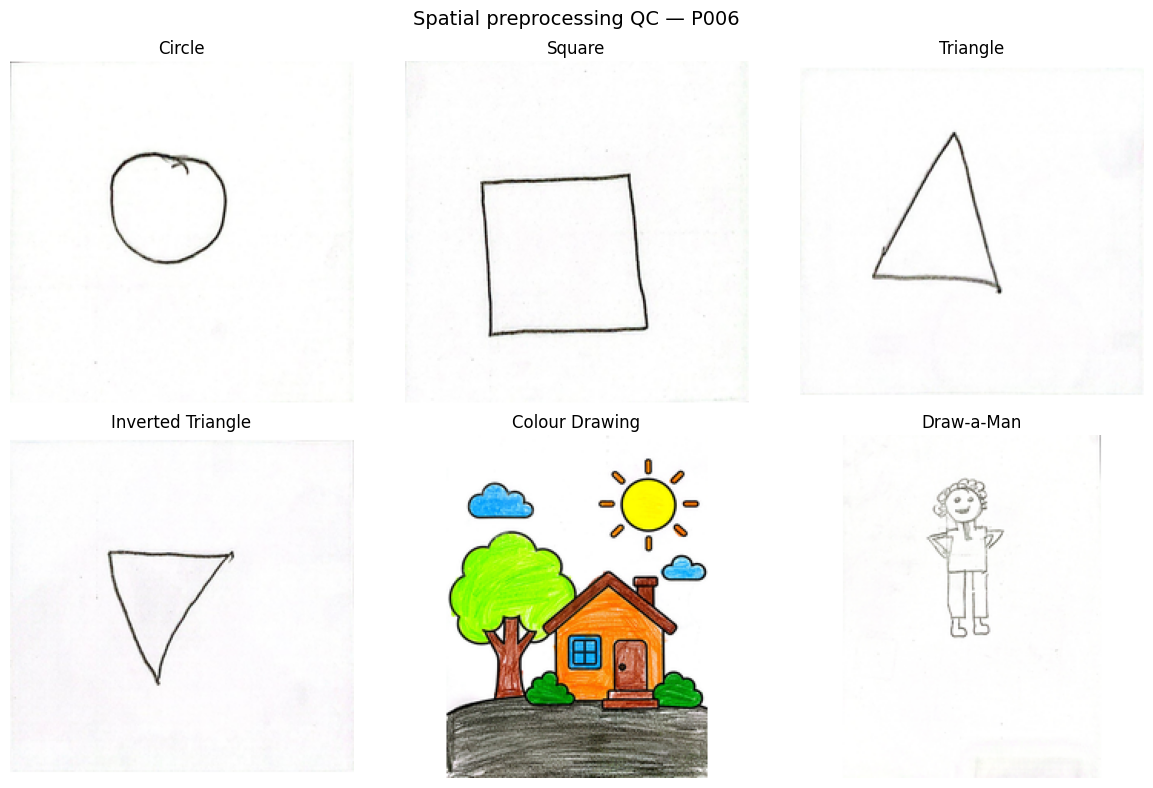


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell07_preprocessing_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell07_preprocessing_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell07_preprocessing_qc_example.png

LOCKED PREPROCESSING POLICY
Target_Size                                     : 224
Colour_Mode                                     : RGB
Aspect_Ratio_Preserved                          : True
Padding                                         : Centered white padding
Content_Bounding_Box_Crop                       : False
Random_Augmentation_During_Feature_Extraction   : False
Interpolation                                   : LANCZOS

CELL 7 STATUS: PASS


In [ ]:
# ============================================================
# CELL 7 — IMAGE PREPROCESSING + SPATIAL PRESERVATION AUDIT
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


print("=" * 78)
print("CELL 7 — IMAGE PREPROCESSING + SPATIAL PRESERVATION AUDIT")
print("=" * 78)


# ============================================================
# 1. PREPROCESSING CONSTANTS
# ============================================================

IMAGE_SIZE = 224

PREPROCESS_BACKGROUND_RGB = (
    255,
    255,
    255
)


# ============================================================
# 2. RGB IMAGE LOADER
# ============================================================

def load_rgb_image(
    image_path
):
    """
    Load an image and convert it to RGB.

    IMPORTANT:
    No content-based cropping is performed.
    """

    with Image.open(
        image_path
    ) as image:

        rgb_image = image.convert(
            "RGB"
        )

    return rgb_image


# ============================================================
# 3. ASPECT-RATIO-PRESERVING RESIZE + WHITE PADDING
# ============================================================

def resize_pad_white(
    image,
    target_size=IMAGE_SIZE
):
    """
    Resize a PIL RGB image while preserving its aspect ratio,
    then center it on a white square canvas.

    Returns:
        padded_image
        metadata dictionary
    """

    if image.mode != "RGB":

        image = image.convert(
            "RGB"
        )


    original_width, original_height = image.size


    if (
        original_width <= 0
        or
        original_height <= 0
    ):

        raise ValueError(
            "Invalid original image dimensions."
        )


    scale = min(

        target_size
        /
        original_width,

        target_size
        /
        original_height
    )


    resized_width = max(
        1,
        int(
            round(
                original_width
                *
                scale
            )
        )
    )


    resized_height = max(
        1,
        int(
            round(
                original_height
                *
                scale
            )
        )
    )


    resized_image = image.resize(

        (
            resized_width,
            resized_height
        ),

        resample=Image.Resampling.LANCZOS
    )


    canvas = Image.new(

        "RGB",

        (
            target_size,
            target_size
        ),

        color=PREPROCESS_BACKGROUND_RGB
    )


    left = (
        target_size
        -
        resized_width
    ) // 2


    top = (
        target_size
        -
        resized_height
    ) // 2


    canvas.paste(

        resized_image,

        (
            left,
            top
        )
    )


    right = (
        target_size
        -
        resized_width
        -
        left
    )


    bottom = (
        target_size
        -
        resized_height
        -
        top
    )


    metadata = {

        "Original_Width":
            int(
                original_width
            ),

        "Original_Height":
            int(
                original_height
            ),

        "Original_Aspect_Ratio":
            float(
                original_width
                /
                original_height
            ),

        "Scale_Factor":
            float(
                scale
            ),

        "Resized_Width":
            int(
                resized_width
            ),

        "Resized_Height":
            int(
                resized_height
            ),

        "Pad_Left":
            int(
                left
            ),

        "Pad_Right":
            int(
                right
            ),

        "Pad_Top":
            int(
                top
            ),

        "Pad_Bottom":
            int(
                bottom
            )
    }


    return (
        canvas,
        metadata
    )


# ============================================================
# 4. SINGLE CONVENIENCE FUNCTION
# ============================================================

def preprocess_spatial_image(
    image_path,
    target_size=IMAGE_SIZE
):

    rgb_image = load_rgb_image(
        image_path
    )


    processed_image, metadata = resize_pad_white(

        rgb_image,

        target_size=target_size
    )


    return (
        processed_image,
        metadata
    )


# ============================================================
# 5. TEST DETERMINISM ON ONE IMAGE
# ============================================================

example_path = Path(
    final_cohort_df.loc[
        0,
        "circle"
    ]
)


example_a, example_meta_a = preprocess_spatial_image(
    example_path
)

example_b, example_meta_b = preprocess_spatial_image(
    example_path
)


example_array_a = np.asarray(
    example_a
)

example_array_b = np.asarray(
    example_b
)


preprocessing_deterministic = bool(
    np.array_equal(
        example_array_a,
        example_array_b
    )
)


print("\nDETERMINISM CHECK")

print(
    "Example image:",
    example_path
)

print(
    "Repeated preprocessing identical:",
    preprocessing_deterministic
)


if not preprocessing_deterministic:

    raise RuntimeError(
        "Spatial preprocessing is not deterministic."
    )


# ============================================================
# 6. AUDIT EVERY REQUIRED IMAGE
# ============================================================

preprocessing_audit_records = []


for _, row in final_cohort_df.iterrows():

    participant_id = row[
        "Participant_ID"
    ]


    for modality in required_image_path_columns:

        image_path = Path(
            row[
                modality
            ]
        )


        try:

            processed_image, metadata = (
                preprocess_spatial_image(
                    image_path
                )
            )


            processed_array = np.asarray(
                processed_image
            )


            valid_shape = (
                processed_array.shape
                ==
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                    3
                )
            )


            finite_values = bool(
                np.isfinite(
                    processed_array
                ).all()
            )


            valid_range = bool(

                processed_array.min()
                >=
                0

                and

                processed_array.max()
                <=
                255
            )


            success = bool(

                valid_shape
                and
                finite_values
                and
                valid_range
            )


            error_message = None


        except Exception as error:

            success = False

            valid_shape = False

            finite_values = False

            valid_range = False

            metadata = {

                "Original_Width":
                    np.nan,

                "Original_Height":
                    np.nan,

                "Original_Aspect_Ratio":
                    np.nan,

                "Scale_Factor":
                    np.nan,

                "Resized_Width":
                    np.nan,

                "Resized_Height":
                    np.nan,

                "Pad_Left":
                    np.nan,

                "Pad_Right":
                    np.nan,

                "Pad_Top":
                    np.nan,

                "Pad_Bottom":
                    np.nan
            }

            error_message = str(
                error
            )


        preprocessing_audit_records.append({

            "Participant_ID":
                participant_id,

            "Modality":
                modality,

            "Image_Path":
                str(
                    image_path
                ),

            **metadata,

            "Output_Width":
                IMAGE_SIZE
                if success
                else
                np.nan,

            "Output_Height":
                IMAGE_SIZE
                if success
                else
                np.nan,

            "Output_RGB":
                success,

            "Finite":
                finite_values,

            "Valid_Pixel_Range":
                valid_range,

            "Preprocessing_SUCCESS":
                success,

            "Error":
                error_message
        })


preprocessing_audit_df = pd.DataFrame(
    preprocessing_audit_records
)


# ============================================================
# 7. GLOBAL STATUS
# ============================================================

total_expected_images = (
    N_FINAL
    *
    len(
        required_image_path_columns
    )
)


total_processed_images = len(
    preprocessing_audit_df
)


successful_preprocessing_count = int(

    preprocessing_audit_df[
        "Preprocessing_SUCCESS"
    ].sum()
)


failed_preprocessing_df = (

    preprocessing_audit_df[
        ~preprocessing_audit_df[
            "Preprocessing_SUCCESS"
        ]
    ]

    .copy()
)


print("\nGLOBAL PREPROCESSING AUDIT")

print(
    "Expected images:",
    total_expected_images
)

print(
    "Audited images:",
    total_processed_images
)

print(
    "Successfully preprocessed:",
    successful_preprocessing_count
)

print(
    "Failed:",
    len(
        failed_preprocessing_df
    )
)


if (
    total_processed_images
    !=
    total_expected_images
):

    raise RuntimeError(
        "Unexpected image count during preprocessing audit."
    )


if len(
    failed_preprocessing_df
) > 0:

    display(
        failed_preprocessing_df[
            [
                "Participant_ID",
                "Modality",
                "Image_Path",
                "Error"
            ]
        ]
    )

    raise RuntimeError(
        "At least one image failed preprocessing."
    )


# ============================================================
# 8. MODALITY-LEVEL PREPROCESSING SUMMARY
# ============================================================

preprocessing_summary_df = (

    preprocessing_audit_df

    .groupby(
        "Modality"
    )

    .agg(

        N=(
            "Participant_ID",
            "count"
        ),

        Original_Aspect_Mean=(
            "Original_Aspect_Ratio",
            "mean"
        ),

        Original_Aspect_Min=(
            "Original_Aspect_Ratio",
            "min"
        ),

        Original_Aspect_Max=(
            "Original_Aspect_Ratio",
            "max"
        ),

        Resized_Width_Mean=(
            "Resized_Width",
            "mean"
        ),

        Resized_Height_Mean=(
            "Resized_Height",
            "mean"
        ),

        Pad_Left_Mean=(
            "Pad_Left",
            "mean"
        ),

        Pad_Top_Mean=(
            "Pad_Top",
            "mean"
        )
    )

    .reindex(
        required_image_path_columns
    )

    .reset_index()
)


print("\nPREPROCESSING SUMMARY BY MODALITY")

display(
    preprocessing_summary_df
    .round(3)
)


# ============================================================
# 9. CONFIRM ASPECT-RATIO PRESERVATION NUMERICALLY
# ============================================================

preprocessing_audit_df[
    "Resized_Aspect_Ratio"
] = (

    preprocessing_audit_df[
        "Resized_Width"
    ]

    /

    preprocessing_audit_df[
        "Resized_Height"
    ]
)


preprocessing_audit_df[
    "Aspect_Ratio_Error"
] = np.abs(

    preprocessing_audit_df[
        "Original_Aspect_Ratio"
    ]

    -

    preprocessing_audit_df[
        "Resized_Aspect_Ratio"
    ]
)


max_aspect_ratio_error = float(

    preprocessing_audit_df[
        "Aspect_Ratio_Error"
    ].max()
)


print("\nSPATIAL PRESERVATION CHECK")

print(
    "Maximum aspect-ratio difference caused only by integer rounding:",
    round(
        max_aspect_ratio_error,
        6
    )
)


# ============================================================
# 10. CREATE VISUAL QC FIGURE
#
# One participant is shown only for preprocessing inspection.
# This figure is not used for scientific interpretation.
# ============================================================

qc_participant_id = final_cohort_df.loc[
    0,
    "Participant_ID"
]


qc_row = final_cohort_df[
    final_cohort_df[
        "Participant_ID"
    ]
    ==
    qc_participant_id
].iloc[0]


display_names = {

    "circle":
        "Circle",

    "square":
        "Square",

    "triangle":
        "Triangle",

    "inverted_triangle":
        "Inverted Triangle",

    "colour_drawing":
        "Colour Drawing",

    "draw_man":
        "Draw-a-Man"
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        12,
        8
    )
)


for axis, modality in zip(

    axes.ravel(),

    required_image_path_columns
):

    processed_image, _ = preprocess_spatial_image(

        qc_row[
            modality
        ]
    )


    axis.imshow(
        processed_image
    )

    axis.set_title(
        display_names[
            modality
        ]
    )

    axis.axis(
        "off"
    )


fig.suptitle(

    f"Spatial preprocessing QC — {qc_participant_id}",

    fontsize=14
)


plt.tight_layout()


preprocessing_qc_figure = (

    FIGURES_DIR
    /
    "cell07_preprocessing_qc_example.png"
)


plt.savefig(

    preprocessing_qc_figure,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. SAVE AUDIT OUTPUTS
# ============================================================

preprocessing_audit_file = (
    AUDIT_DIR
    /
    "cell07_preprocessing_audit.csv"
)


preprocessing_summary_file = (
    AUDIT_DIR
    /
    "cell07_preprocessing_summary.csv"
)


preprocessing_audit_df.to_csv(

    preprocessing_audit_file,

    index=False
)


preprocessing_summary_df.to_csv(

    preprocessing_summary_file,

    index=False
)


print("\nSAVED OUTPUTS")

print(
    preprocessing_audit_file
)

print(
    preprocessing_summary_file
)

print(
    preprocessing_qc_figure
)


# ============================================================
# 12. LOCK PREPROCESSING POLICY
# ============================================================

PREPROCESSING_POLICY = {

    "Target_Size":
        IMAGE_SIZE,

    "Colour_Mode":
        "RGB",

    "Aspect_Ratio_Preserved":
        True,

    "Padding":
        "Centered white padding",

    "Content_Bounding_Box_Crop":
        False,

    "Random_Augmentation_During_Feature_Extraction":
        False,

    "Interpolation":
        "LANCZOS"
}


print("\nLOCKED PREPROCESSING POLICY")

for key, value in PREPROCESSING_POLICY.items():

    print(
        f"{key:48s}: {value}"
    )


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 7 STATUS: PASS")
print("=" * 78)

# 8. Objective Colour-Feature Engineering

The Colour branch combines a pretrained EfficientNet-B0 representation with
objective colour statistics extracted directly from the child's completed
colour drawing.

The engineered features are calculated without using ASD/TD labels and
therefore do not perform supervised feature selection.

## Implemented colour features

The final engineered colour vector contains:

1. normalized hue entropy;
2. hue Simpson-diversity index;
3. dominant-hue proportion;
4. mean saturation;
5. saturation standard deviation;
6. mean brightness;
7. brightness standard deviation;
8. chromatic-pixel coverage;
9. non-white/foreground coverage;
10. mean LAB chroma;
11. LAB chroma standard deviation;
12. circular mean hue cosine component;
13. circular mean hue sine component.

Hue and saturation statistics are calculated from chromatic pixels rather
than the white paper background.

Brightness statistics are calculated over the detected drawing foreground.

## Methodological limitation

The originally proposed methodology also mentioned:

- boundary overflow;
- semantic object-colour matching.

These are not calculated in the final computational pipeline because the
collected dataset does not contain registered object masks or a validated
reference-template annotation required to calculate them objectively.

Creating approximate masks from the same child drawings would introduce
unvalidated assumptions. These two features are therefore explicitly
reported as not implemented rather than replaced with artificial proxy
measurements.

The CNN component can still learn spatial and semantic colour patterns from
the full drawing image.

No colour feature is selected or removed according to ASD/TD performance.

In [ ]:
# ============================================================
# CELL 8 — OBJECTIVE COLOUR-FEATURE ENGINEERING
# ============================================================

import numpy as np
import pandas as pd
import cv2

print("=" * 78)
print("CELL 8 — OBJECTIVE COLOUR-FEATURE ENGINEERING")
print("=" * 78)


# ============================================================
# 1. LOCK COLOUR-FEATURE EXTRACTION PARAMETERS
# ============================================================

# Saturation threshold separating chromatic pixels from
# approximately grey/white pixels.
COLOUR_SATURATION_THRESHOLD = 0.15

# A pixel darker than this is considered foreground even when
# its saturation is low (for example black/grey drawing content).
FOREGROUND_VALUE_THRESHOLD = 0.90

# Hue histogram resolution.
HUE_HISTOGRAM_BINS = 36


COLOUR_FEATURE_NAMES = [

    "hue_entropy_norm",
    "hue_simpson_diversity",
    "dominant_hue_fraction",

    "saturation_mean",
    "saturation_std",

    "brightness_mean",
    "brightness_std",

    "chromatic_coverage",
    "foreground_coverage",

    "lab_chroma_mean",
    "lab_chroma_std",

    "hue_cos_mean",
    "hue_sin_mean"
]


print("\nLOCKED ENGINEERED COLOUR FEATURES")

for feature_name in COLOUR_FEATURE_NAMES:
    print(" -", feature_name)

print(
    "\nTotal engineered colour features:",
    len(COLOUR_FEATURE_NAMES)
)


# ============================================================
# 2. SINGLE-IMAGE COLOUR FEATURE FUNCTION
# ============================================================

def extract_colour_statistics(
    image_path
):
    """
    Extract deterministic global colour statistics from the
    original RGB colour drawing.

    The original manually cropped page is used rather than the
    224x224 padded model input so that added white padding does
    not influence engineered colour statistics.
    """

    rgb_image = load_rgb_image(
        image_path
    )

    rgb = np.asarray(
        rgb_image,
        dtype=np.uint8
    )


    if (
        rgb.ndim != 3
        or
        rgb.shape[2] != 3
    ):

        raise ValueError(
            "Expected RGB image with three channels."
        )


    # --------------------------------------------------------
    # HSV
    # --------------------------------------------------------

    hsv = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2HSV
    ).astype(
        np.float32
    )


    hue = (
        hsv[:, :, 0]
        /
        180.0
    )

    saturation = (
        hsv[:, :, 1]
        /
        255.0
    )

    value = (
        hsv[:, :, 2]
        /
        255.0
    )


    # Chromatic pixels:
    # enough saturation to represent meaningful hue.
    chromatic_mask = (

        saturation
        >=
        COLOUR_SATURATION_THRESHOLD
    )


    # General drawing foreground:
    # either chromatic or sufficiently dark.
    foreground_mask = (

        chromatic_mask

        |

        (
            value
            <=
            FOREGROUND_VALUE_THRESHOLD
        )
    )


    total_pixel_count = int(
        rgb.shape[0]
        *
        rgb.shape[1]
    )


    chromatic_pixel_count = int(
        chromatic_mask.sum()
    )


    foreground_pixel_count = int(
        foreground_mask.sum()
    )


    chromatic_coverage = float(
        chromatic_pixel_count
        /
        total_pixel_count
    )


    foreground_coverage = float(
        foreground_pixel_count
        /
        total_pixel_count
    )


    # --------------------------------------------------------
    # HUE DISTRIBUTION
    # --------------------------------------------------------

    if chromatic_pixel_count > 0:

        hue_values = hue[
            chromatic_mask
        ]


        saturation_values = saturation[
            chromatic_mask
        ]


        hue_histogram, _ = np.histogram(

            hue_values,

            bins=HUE_HISTOGRAM_BINS,

            range=(
                0.0,
                1.0
            )
        )


        hue_probabilities = (

            hue_histogram.astype(
                np.float64
            )

            /

            hue_histogram.sum()
        )


        nonzero_probabilities = (
            hue_probabilities[
                hue_probabilities > 0
            ]
        )


        hue_entropy_bits = float(

            -np.sum(

                nonzero_probabilities

                *

                np.log2(
                    nonzero_probabilities
                )
            )
        )


        maximum_entropy_bits = float(
            np.log2(
                HUE_HISTOGRAM_BINS
            )
        )


        hue_entropy_norm = float(

            hue_entropy_bits

            /

            maximum_entropy_bits
        )


        # Simpson diversity:
        # 0 = one hue bin dominates completely;
        # larger values = more diverse hue distribution.
        hue_simpson_diversity = float(

            1.0

            -

            np.sum(
                hue_probabilities ** 2
            )
        )


        dominant_hue_fraction = float(
            hue_probabilities.max()
        )


        saturation_mean = float(
            saturation_values.mean()
        )


        saturation_std = float(
            saturation_values.std(
                ddof=0
            )
        )


        # Circular hue representation avoids the discontinuity
        # between hue=0 and hue=1.
        hue_angles = (
            2.0
            *
            np.pi
            *
            hue_values
        )


        hue_cos_mean = float(
            np.cos(
                hue_angles
            ).mean()
        )


        hue_sin_mean = float(
            np.sin(
                hue_angles
            ).mean()
        )


    else:

        # Colour drawing is expected to contain chromatic pixels.
        # Returning zero values keeps the function deterministic
        # while the audit below separately flags the situation.
        hue_entropy_norm = 0.0
        hue_simpson_diversity = 0.0
        dominant_hue_fraction = 0.0
        saturation_mean = 0.0
        saturation_std = 0.0
        hue_cos_mean = 0.0
        hue_sin_mean = 0.0


    # --------------------------------------------------------
    # BRIGHTNESS DISTRIBUTION
    # --------------------------------------------------------

    if foreground_pixel_count > 0:

        foreground_value = value[
            foreground_mask
        ]


        brightness_mean = float(
            foreground_value.mean()
        )


        brightness_std = float(
            foreground_value.std(
                ddof=0
            )
        )


    else:

        brightness_mean = 0.0
        brightness_std = 0.0


    # --------------------------------------------------------
    # LAB CHROMA
    # --------------------------------------------------------

    lab = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2LAB
    ).astype(
        np.float32
    )


    lab_a = (
        lab[:, :, 1]
        -
        128.0
    )


    lab_b = (
        lab[:, :, 2]
        -
        128.0
    )


    lab_chroma = np.sqrt(
        lab_a ** 2
        +
        lab_b ** 2
    )


    if chromatic_pixel_count > 0:

        chroma_values = lab_chroma[
            chromatic_mask
        ]


        lab_chroma_mean = float(
            chroma_values.mean()
        )


        lab_chroma_std = float(
            chroma_values.std(
                ddof=0
            )
        )


    else:

        lab_chroma_mean = 0.0
        lab_chroma_std = 0.0


    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    features = {

        "hue_entropy_norm":
            hue_entropy_norm,

        "hue_simpson_diversity":
            hue_simpson_diversity,

        "dominant_hue_fraction":
            dominant_hue_fraction,

        "saturation_mean":
            saturation_mean,

        "saturation_std":
            saturation_std,

        "brightness_mean":
            brightness_mean,

        "brightness_std":
            brightness_std,

        "chromatic_coverage":
            chromatic_coverage,

        "foreground_coverage":
            foreground_coverage,

        "lab_chroma_mean":
            lab_chroma_mean,

        "lab_chroma_std":
            lab_chroma_std,

        "hue_cos_mean":
            hue_cos_mean,

        "hue_sin_mean":
            hue_sin_mean
    }


    audit = {

        "Image_Width":
            int(
                rgb.shape[1]
            ),

        "Image_Height":
            int(
                rgb.shape[0]
            ),

        "Total_Pixel_Count":
            total_pixel_count,

        "Chromatic_Pixel_Count":
            chromatic_pixel_count,

        "Foreground_Pixel_Count":
            foreground_pixel_count
    }


    return (
        features,
        audit
    )


# ============================================================
# 3. EXTRACT FEATURES FOR EVERY PRIMARY PARTICIPANT
# ============================================================

colour_feature_records = []

colour_feature_audit_records = []


for _, row in final_cohort_df.iterrows():

    participant_id = row[
        "Participant_ID"
    ]

    group = row[
        "Group"
    ]

    colour_image_path = row[
        "colour_drawing"
    ]


    features, audit = extract_colour_statistics(
        colour_image_path
    )


    colour_feature_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            group,

        **features
    })


    colour_feature_audit_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            group,

        "Image_Path":
            colour_image_path,

        **audit
    })


colour_features_df = pd.DataFrame(
    colour_feature_records
).sort_values(
    "Participant_ID"
).reset_index(
    drop=True
)


colour_feature_audit_df = pd.DataFrame(
    colour_feature_audit_records
).sort_values(
    "Participant_ID"
).reset_index(
    drop=True
)


# ============================================================
# 4. VERIFY PARTICIPANT ALIGNMENT
# ============================================================

expected_participant_order = (
    final_cohort_df[
        "Participant_ID"
    ]
    .tolist()
)


if (
    colour_features_df[
        "Participant_ID"
    ].tolist()
    !=
    expected_participant_order
):

    raise RuntimeError(
        "Colour feature participant ordering does not "
        "match the final cohort ordering."
    )


# ============================================================
# 5. BUILD NUMERICAL COLOUR FEATURE MATRIX
# ============================================================

X_colour_engineered = (

    colour_features_df[
        COLOUR_FEATURE_NAMES
    ]

    .to_numpy(
        dtype=np.float32
    )
)


print("\nCOLOUR FEATURE MATRIX")

print(
    "Shape:",
    X_colour_engineered.shape
)

print(
    "Expected:",
    (
        N_FINAL,
        len(
            COLOUR_FEATURE_NAMES
        )
    )
)

print(
    "All finite:",
    bool(
        np.isfinite(
            X_colour_engineered
        ).all()
    )
)


if X_colour_engineered.shape != (
    N_FINAL,
    len(
        COLOUR_FEATURE_NAMES
    )
):

    raise RuntimeError(
        "Unexpected engineered colour feature matrix shape."
    )


if not np.isfinite(
    X_colour_engineered
).all():

    raise RuntimeError(
        "Non-finite values detected in engineered colour features."
    )


# ============================================================
# 6. CHROMATIC CONTENT AUDIT
# ============================================================

colour_feature_audit_df[
    "Chromatic_Coverage"
] = (

    colour_feature_audit_df[
        "Chromatic_Pixel_Count"
    ]

    /

    colour_feature_audit_df[
        "Total_Pixel_Count"
    ]
)


colour_feature_audit_df[
    "Foreground_Coverage"
] = (

    colour_feature_audit_df[
        "Foreground_Pixel_Count"
    ]

    /

    colour_feature_audit_df[
        "Total_Pixel_Count"
    ]
)


no_chromatic_content_df = (

    colour_feature_audit_df[
        colour_feature_audit_df[
            "Chromatic_Pixel_Count"
        ] == 0
    ]

    .copy()
)


print("\nCHROMATIC CONTENT AUDIT")

print(
    "Colour drawings:",
    len(
        colour_feature_audit_df
    )
)

print(
    "Drawings with zero chromatic pixels:",
    len(
        no_chromatic_content_df
    )
)


if len(
    no_chromatic_content_df
) > 0:

    display(
        no_chromatic_content_df
    )

    raise RuntimeError(
        "At least one Colour drawing contains no detected "
        "chromatic content under the locked threshold."
    )


print(
    "Minimum chromatic coverage:",
    round(
        float(
            colour_feature_audit_df[
                "Chromatic_Coverage"
            ].min()
        ),
        6
    )
)

print(
    "Maximum chromatic coverage:",
    round(
        float(
            colour_feature_audit_df[
                "Chromatic_Coverage"
            ].max()
        ),
        6
    )
)


# ============================================================
# 7. FEATURE SUMMARY / VARIANCE AUDIT
# ============================================================

colour_feature_summary_records = []


for feature_name in COLOUR_FEATURE_NAMES:

    values = colour_features_df[
        feature_name
    ].astype(
        float
    )


    colour_feature_summary_records.append({

        "Feature":
            feature_name,

        "Mean":
            float(
                values.mean()
            ),

        "Std":
            float(
                values.std(
                    ddof=1
                )
            ),

        "Min":
            float(
                values.min()
            ),

        "Median":
            float(
                values.median()
            ),

        "Max":
            float(
                values.max()
            ),

        "Unique_Count":
            int(
                values.nunique()
            ),

        "Zero_Variance":
            bool(
                values.nunique()
                <= 1
            )
    })


colour_feature_summary_df = pd.DataFrame(
    colour_feature_summary_records
)


print("\nENGINEERED COLOUR FEATURE SUMMARY")

display(
    colour_feature_summary_df
    .round(6)
)


zero_variance_colour_features = (

    colour_feature_summary_df.loc[
        colour_feature_summary_df[
            "Zero_Variance"
        ],
        "Feature"
    ]
    .tolist()
)


print(
    "\nZero-variance engineered colour features:",
    zero_variance_colour_features
    if len(
        zero_variance_colour_features
    ) > 0
    else "None"
)


# IMPORTANT:
# No feature is selected/dropped based on ASD/TD performance.
# If an exact zero-variance feature ever appears in a future
# expanded dataset run, it will be documented before modeling.


# ============================================================
# 8. RANGE SANITY CHECKS
# ============================================================

bounded_01_features = [

    "hue_entropy_norm",
    "hue_simpson_diversity",
    "dominant_hue_fraction",
    "saturation_mean",
    "saturation_std",
    "brightness_mean",
    "brightness_std",
    "chromatic_coverage",
    "foreground_coverage"
]


range_failures = []


for feature_name in bounded_01_features:

    values = colour_features_df[
        feature_name
    ].to_numpy(
        dtype=float
    )


    if (
        np.any(
            values < 0
        )
        or
        np.any(
            values > 1
        )
    ):

        range_failures.append(
            feature_name
        )


# Circular means must be in [-1, 1].
for feature_name in [
    "hue_cos_mean",
    "hue_sin_mean"
]:

    values = colour_features_df[
        feature_name
    ].to_numpy(
        dtype=float
    )


    if (
        np.any(
            values < -1
        )
        or
        np.any(
            values > 1
        )
    ):

        range_failures.append(
            feature_name
        )


print("\nFEATURE RANGE SANITY CHECK")

if len(
    range_failures
) == 0:

    print(
        "Expected mathematical ranges: PASS"
    )

else:

    print(
        "Range failures:",
        range_failures
    )

    raise RuntimeError(
        "One or more engineered colour features violate "
        "their expected mathematical range."
    )


# ============================================================
# 9. SEMANTIC / TEMPLATE-DEPENDENT FEATURE STATUS
# ============================================================

colour_method_status_df = pd.DataFrame([

    {
        "Feature_or_Procedure":
            "Global HSV statistics",

        "Final_Status":
            "IMPLEMENTED",

        "Reason":
            (
                "Can be calculated objectively from each "
                "completed colour drawing."
            )
    },

    {
        "Feature_or_Procedure":
            "LAB chroma statistics",

        "Final_Status":
            "IMPLEMENTED",

        "Reason":
            (
                "Can be calculated objectively from each "
                "completed colour drawing."
            )
    },

    {
        "Feature_or_Procedure":
            "Hue diversity / dominant hue",

        "Final_Status":
            "IMPLEMENTED",

        "Reason":
            (
                "Calculated from the chromatic-pixel hue "
                "distribution."
            )
    },

    {
        "Feature_or_Procedure":
            "Boundary overflow",

        "Final_Status":
            "NOT IMPLEMENTED",

        "Reason":
            (
                "Requires validated registered object/boundary "
                "masks that are not present in the collected dataset. "
                "No unvalidated proxy is substituted."
            )
    },

    {
        "Feature_or_Procedure":
            "Object-colour matching",

        "Final_Status":
            "NOT IMPLEMENTED",

        "Reason":
            (
                "Requires validated semantic object masks and "
                "predefined expected-colour rules that are not "
                "available in the finalized dataset."
            )
    },

    {
        "Feature_or_Procedure":
            "Scanner colour-card correction",

        "Final_Status":
            "NOT AVAILABLE FOR CURRENT DATA",

        "Reason":
            (
                "No per-participant or site colour-reference-card "
                "measurements are present in the current dataset. "
                "The limitation will be reported rather than "
                "estimated retrospectively."
            )
    }
])


print("\nCOLOUR-METHODOLOGY IMPLEMENTATION STATUS")

display(
    colour_method_status_df
)


# ============================================================
# 10. SAVE FEATURE TABLES
# ============================================================

colour_features_file = (
    EMBEDDINGS_DIR
    /
    "cell08_colour_engineered_features.csv"
)


colour_feature_summary_file = (
    AUDIT_DIR
    /
    "cell08_colour_feature_summary.csv"
)


colour_feature_audit_file = (
    AUDIT_DIR
    /
    "cell08_colour_pixel_audit.csv"
)


colour_method_status_file = (
    AUDIT_DIR
    /
    "cell08_colour_method_status.csv"
)


colour_features_df.to_csv(
    colour_features_file,
    index=False
)


colour_feature_summary_df.to_csv(
    colour_feature_summary_file,
    index=False
)


colour_feature_audit_df.to_csv(
    colour_feature_audit_file,
    index=False
)


colour_method_status_df.to_csv(
    colour_method_status_file,
    index=False
)


# ============================================================
# 11. SAVE MACHINE-READABLE FEATURE PROTOCOL
# ============================================================

colour_feature_protocol_df = pd.DataFrame([

    {
        "Parameter":
            "Saturation threshold",

        "Value":
            COLOUR_SATURATION_THRESHOLD
    },

    {
        "Parameter":
            "Foreground value threshold",

        "Value":
            FOREGROUND_VALUE_THRESHOLD
    },

    {
        "Parameter":
            "Hue histogram bins",

        "Value":
            HUE_HISTOGRAM_BINS
    },

    {
        "Parameter":
            "Engineered feature count",

        "Value":
            len(
                COLOUR_FEATURE_NAMES
            )
    },

    {
        "Parameter":
            "Input image",

        "Value":
            "Original manually cropped RGB colour drawing"
    },

    {
        "Parameter":
            "ASD/TD labels used during extraction",

        "Value":
            False
    }
])


colour_feature_protocol_file = (
    MANIFEST_DIR
    /
    "cell08_colour_feature_protocol.csv"
)


colour_feature_protocol_df.to_csv(
    colour_feature_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    colour_features_file
)

print(
    colour_feature_summary_file
)

print(
    colour_feature_audit_file
)

print(
    colour_method_status_file
)

print(
    colour_feature_protocol_file
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 8 STATUS: PASS")
print("=" * 78)

CELL 8 — OBJECTIVE COLOUR-FEATURE ENGINEERING

LOCKED ENGINEERED COLOUR FEATURES
 - hue_entropy_norm
 - hue_simpson_diversity
 - dominant_hue_fraction
 - saturation_mean
 - saturation_std
 - brightness_mean
 - brightness_std
 - chromatic_coverage
 - foreground_coverage
 - lab_chroma_mean
 - lab_chroma_std
 - hue_cos_mean
 - hue_sin_mean

Total engineered colour features: 13

COLOUR FEATURE MATRIX
Shape: (34, 13)
Expected: (34, 13)
All finite: True

CHROMATIC CONTENT AUDIT
Colour drawings: 34
Drawings with zero chromatic pixels: 0
Minimum chromatic coverage: 0.184521
Maximum chromatic coverage: 0.676282

ENGINEERED COLOUR FEATURE SUMMARY


,Feature,Mean,Std,Min,Median,Max,Unique_Count,Zero_Variance
0,hue_entropy_norm,0.723575,0.069743,0.577079,0.736341,0.856258,34,False
1,hue_simpson_diversity,0.877611,0.043992,0.761844,0.886126,0.941592,34,False
2,dominant_hue_fraction,0.234789,0.086126,0.092106,0.235707,0.466857,34,False
3,saturation_mean,0.728781,0.123879,0.437073,0.754983,0.929712,34,False
4,saturation_std,0.237783,0.038900,0.118150,0.243394,0.307366,34,False
5,brightness_mean,0.677326,0.058749,0.557720,0.672468,0.835513,34,False
6,brightness_std,0.302024,0.031307,0.264737,0.288137,0.365545,34,False
7,chromatic_coverage,0.457945,0.121740,0.184521,0.521693,0.676282,34,False
8,foreground_coverage,0.484354,0.118938,0.237363,0.552136,0.713881,34,False
9,lab_chroma_mean,53.597167,12.367441,19.310587,55.770834,70.836037,34,False



Zero-variance engineered colour features: None

FEATURE RANGE SANITY CHECK
Expected mathematical ranges: PASS

COLOUR-METHODOLOGY IMPLEMENTATION STATUS


,Feature_or_Procedure,Final_Status,Reason
0,Global HSV statistics,IMPLEMENTED,Can be calculated objectively from each comple...
1,LAB chroma statistics,IMPLEMENTED,Can be calculated objectively from each comple...
2,Hue diversity / dominant hue,IMPLEMENTED,Calculated from the chromatic-pixel hue distri...
3,Boundary overflow,NOT IMPLEMENTED,Requires validated registered object/boundary ...
4,Object-colour matching,NOT IMPLEMENTED,Requires validated semantic object masks and p...
5,Scanner colour-card correction,NOT AVAILABLE FOR CURRENT DATA,No per-participant or site colour-reference-ca...



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell08_colour_engineered_features.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell08_colour_feature_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell08_colour_pixel_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell08_colour_method_status.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell08_colour_feature_protocol.csv

CELL 8 STATUS: PASS


# 9. Pretrained Visual Backbone Initialization and Verification

The final visual branches use two pretrained feature extractors:

- EfficientNet-B0 for Shape and Colour drawings;
- DINOv2-small for Draw-a-Man drawings.

Both backbones are used as frozen feature extractors in the locked primary
protocol.

No participant labels are involved in feature extraction.

## EfficientNet-B0

EfficientNet-B0 is initialized with ImageNet pretrained weights using `timm`.

The classification head is removed so that the model returns the pooled
deep representation.

Expected output dimension:

- 1280 features per image.

EfficientNet-B0 is used for:

- Circle;
- Square;
- Triangle;
- Inverted Triangle;
- Colour Drawing.

## DINOv2-small

DINOv2-small is loaded from the pretrained
`facebook/dinov2-small` checkpoint.

The CLS-token representation is used as the participant-level DAM image
embedding.

Expected output dimension:

- 384 features per Draw-a-Man image.

## Spatial preprocessing

The 224 × 224 RGB image produced by Cell 7 is used directly.

No additional resizing or center-cropping is allowed after the spatial
preservation step because doing so could change drawing position or geometry.

Only the backbone-specific pixel normalization is subsequently applied.

## Frozen-backbone verification

This cell confirms:

- models load successfully;
- models are placed on the selected compute device;
- all parameters have `requires_grad=False`;
- models are in evaluation mode;
- expected feature dimensions are produced;
- forward-pass outputs are finite;
- repeated inference on the same image is deterministic.

No participant embedding dataset is extracted in this cell.

In [ ]:
# ============================================================
# CELL 9 — PRETRAINED VISUAL BACKBONES + FORWARD-PASS AUDIT
# ============================================================

import gc
import numpy as np
import pandas as pd
import torch
import timm

from transformers import (
    AutoImageProcessor,
    AutoModel
)


print("=" * 78)
print("CELL 9 — PRETRAINED VISUAL BACKBONE INITIALIZATION")
print("=" * 78)


# ============================================================
# 1. LOCKED MODEL IDENTIFIERS
# ============================================================

EFFICIENTNET_MODEL_NAME = "efficientnet_b0"
DINOV2_MODEL_NAME = "facebook/dinov2-small"

EXPECTED_EFFICIENTNET_DIM = 1280
EXPECTED_DINOV2_DIM = 384


# ============================================================
# 2. INITIALIZE EFFICIENTNET-B0
# ============================================================

print("\nLoading pretrained EfficientNet-B0...")


efficientnet_model = timm.create_model(
    EFFICIENTNET_MODEL_NAME,
    pretrained=True,
    num_classes=0,
    global_pool="avg"
)


efficientnet_model = efficientnet_model.to(
    DEVICE
)


# Freeze all parameters.
for parameter in efficientnet_model.parameters():

    parameter.requires_grad = False


efficientnet_model.eval()


# ============================================================
# 3. INITIALIZE DINOv2-SMALL
# ============================================================

print("Loading pretrained DINOv2-small...")


dino_processor = AutoImageProcessor.from_pretrained(
    DINOV2_MODEL_NAME
)


dino_model = AutoModel.from_pretrained(
    DINOV2_MODEL_NAME
)


dino_model = dino_model.to(
    DEVICE
)


# Freeze all parameters.
for parameter in dino_model.parameters():

    parameter.requires_grad = False


dino_model.eval()


# ============================================================
# 4. MODEL PARAMETER AUDIT
# ============================================================

def parameter_counts(
    model
):

    total = sum(
        parameter.numel()
        for parameter
        in model.parameters()
    )


    trainable = sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )


    frozen = (
        total
        -
        trainable
    )


    return (
        int(total),
        int(trainable),
        int(frozen)
    )


eff_total, eff_trainable, eff_frozen = parameter_counts(
    efficientnet_model
)


dino_total, dino_trainable, dino_frozen = parameter_counts(
    dino_model
)


model_parameter_audit_df = pd.DataFrame([

    {
        "Model":
            "EfficientNet-B0",

        "Identifier":
            EFFICIENTNET_MODEL_NAME,

        "Total_Parameters":
            eff_total,

        "Trainable_Parameters":
            eff_trainable,

        "Frozen_Parameters":
            eff_frozen,

        "Evaluation_Mode":
            not efficientnet_model.training,

        "Device":
            str(
                next(
                    efficientnet_model.parameters()
                ).device
            )
    },

    {
        "Model":
            "DINOv2-small",

        "Identifier":
            DINOV2_MODEL_NAME,

        "Total_Parameters":
            dino_total,

        "Trainable_Parameters":
            dino_trainable,

        "Frozen_Parameters":
            dino_frozen,

        "Evaluation_Mode":
            not dino_model.training,

        "Device":
            str(
                next(
                    dino_model.parameters()
                ).device
            )
    }
])


print("\nMODEL PARAMETER AUDIT")

display(
    model_parameter_audit_df
)


if eff_trainable != 0:

    raise RuntimeError(
        "EfficientNet-B0 has trainable parameters "
        "despite the locked frozen-backbone protocol."
    )


if dino_trainable != 0:

    raise RuntimeError(
        "DINOv2-small has trainable parameters "
        "despite the locked frozen-backbone protocol."
    )


if efficientnet_model.training:

    raise RuntimeError(
        "EfficientNet-B0 is not in evaluation mode."
    )


if dino_model.training:

    raise RuntimeError(
        "DINOv2-small is not in evaluation mode."
    )


print(
    "Frozen-backbone status: PASS"
)


# ============================================================
# 5. BACKBONE NORMALIZATION CONSTANTS
# ============================================================

# EfficientNet-B0 ImageNet normalization.
EFFICIENTNET_MEAN = np.array(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=np.float32
)


EFFICIENTNET_STD = np.array(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=np.float32
)


# Read the DINOv2 preprocessing normalization directly from
# the pretrained processor configuration.
DINOV2_MEAN = np.array(
    dino_processor.image_mean,
    dtype=np.float32
)


DINOV2_STD = np.array(
    dino_processor.image_std,
    dtype=np.float32
)


print("\nNORMALIZATION CONSTANTS")

print(
    "EfficientNet mean:",
    EFFICIENTNET_MEAN.tolist()
)

print(
    "EfficientNet std :",
    EFFICIENTNET_STD.tolist()
)

print(
    "DINOv2 mean     :",
    DINOV2_MEAN.tolist()
)

print(
    "DINOv2 std      :",
    DINOV2_STD.tolist()
)


# ============================================================
# 6. IMAGE -> MODEL TENSOR FUNCTION
#
# IMPORTANT:
# No resize or crop occurs here.
# Cell 7 already produced the spatially preserved 224x224 image.
# ============================================================

def pil_rgb_to_normalized_tensor(
    image,
    mean,
    std
):
    """
    Convert a 224x224 RGB PIL image to normalized
    [1, 3, 224, 224] PyTorch tensor.

    No resizing and no cropping are performed.
    """

    if image.mode != "RGB":

        image = image.convert(
            "RGB"
        )


    if image.size != (
        IMAGE_SIZE,
        IMAGE_SIZE
    ):

        raise ValueError(
            f"Expected {IMAGE_SIZE}x{IMAGE_SIZE} image, "
            f"received {image.size}."
        )


    array = np.asarray(
        image,
        dtype=np.float32
    )


    array = (
        array
        /
        255.0
    )


    mean_array = np.asarray(
        mean,
        dtype=np.float32
    ).reshape(
        1,
        1,
        3
    )


    std_array = np.asarray(
        std,
        dtype=np.float32
    ).reshape(
        1,
        1,
        3
    )


    array = (
        array
        -
        mean_array
    ) / std_array


    tensor = torch.from_numpy(
        array
    ).permute(
        2,
        0,
        1
    ).unsqueeze(
        0
    )


    return tensor.to(
        DEVICE,
        dtype=torch.float32
    )


# ============================================================
# 7. CONVENIENCE INPUT FUNCTIONS
# ============================================================

def make_efficientnet_input(
    image_path
):

    processed_image, _ = preprocess_spatial_image(
        image_path
    )


    return pil_rgb_to_normalized_tensor(

        processed_image,

        EFFICIENTNET_MEAN,

        EFFICIENTNET_STD
    )


def make_dinov2_input(
    image_path
):

    processed_image, _ = preprocess_spatial_image(
        image_path
    )


    return pil_rgb_to_normalized_tensor(

        processed_image,

        DINOV2_MEAN,

        DINOV2_STD
    )


# ============================================================
# 8. TEST IMAGE PATHS
# ============================================================

forward_test_participant = final_cohort_df.iloc[
    0
]


forward_test_id = forward_test_participant[
    "Participant_ID"
]


efficientnet_test_path = forward_test_participant[
    "circle"
]


dino_test_path = forward_test_participant[
    "draw_man"
]


print("\nFORWARD-PASS TEST PARTICIPANT")

print(
    "Participant:",
    forward_test_id
)

print(
    "EfficientNet test image:",
    efficientnet_test_path
)

print(
    "DINOv2 test image:",
    dino_test_path
)


# ============================================================
# 9. VERIFY INPUT TENSOR SHAPES
# ============================================================

efficientnet_test_tensor = make_efficientnet_input(
    efficientnet_test_path
)


dino_test_tensor = make_dinov2_input(
    dino_test_path
)


print("\nINPUT TENSOR SHAPES")

print(
    "EfficientNet:",
    tuple(
        efficientnet_test_tensor.shape
    )
)

print(
    "DINOv2:",
    tuple(
        dino_test_tensor.shape
    )
)


expected_input_shape = (
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)


if tuple(
    efficientnet_test_tensor.shape
) != expected_input_shape:

    raise RuntimeError(
        "Unexpected EfficientNet input tensor shape."
    )


if tuple(
    dino_test_tensor.shape
) != expected_input_shape:

    raise RuntimeError(
        "Unexpected DINOv2 input tensor shape."
    )


# ============================================================
# 10. FORWARD PASS — EFFICIENTNET
# ============================================================

with torch.inference_mode():

    efficientnet_output_1 = efficientnet_model(
        efficientnet_test_tensor
    )


    efficientnet_output_2 = efficientnet_model(
        efficientnet_test_tensor
    )


print("\nEFFICIENTNET FORWARD PASS")

print(
    "Output shape:",
    tuple(
        efficientnet_output_1.shape
    )
)

print(
    "Finite:",
    bool(
        torch.isfinite(
            efficientnet_output_1
        ).all().item()
    )
)


efficientnet_repeat_max_diff = float(

    torch.max(
        torch.abs(
            efficientnet_output_1
            -
            efficientnet_output_2
        )
    ).item()
)


print(
    "Repeated inference max abs difference:",
    efficientnet_repeat_max_diff
)


if efficientnet_output_1.ndim != 2:

    raise RuntimeError(
        "EfficientNet output must be a 2D pooled feature matrix."
    )


if efficientnet_output_1.shape[1] != EXPECTED_EFFICIENTNET_DIM:

    raise RuntimeError(
        "Unexpected EfficientNet feature dimension. "
        f"Expected {EXPECTED_EFFICIENTNET_DIM}, "
        f"received {efficientnet_output_1.shape[1]}."
    )


if not torch.isfinite(
    efficientnet_output_1
).all():

    raise RuntimeError(
        "Non-finite EfficientNet features detected."
    )


# ============================================================
# 11. FORWARD PASS — DINOv2
# ============================================================

with torch.inference_mode():

    dino_output_1 = dino_model(
        pixel_values=dino_test_tensor
    )


    dino_output_2 = dino_model(
        pixel_values=dino_test_tensor
    )


dino_cls_1 = (
    dino_output_1
    .last_hidden_state[
        :,
        0,
        :
    ]
)


dino_cls_2 = (
    dino_output_2
    .last_hidden_state[
        :,
        0,
        :
    ]
)


print("\nDINOV2 FORWARD PASS")

print(
    "Last hidden-state shape:",
    tuple(
        dino_output_1
        .last_hidden_state
        .shape
    )
)

print(
    "CLS embedding shape:",
    tuple(
        dino_cls_1.shape
    )
)

print(
    "Finite:",
    bool(
        torch.isfinite(
            dino_cls_1
        ).all().item()
    )
)


dino_repeat_max_diff = float(

    torch.max(
        torch.abs(
            dino_cls_1
            -
            dino_cls_2
        )
    ).item()
)


print(
    "Repeated inference max abs difference:",
    dino_repeat_max_diff
)


if dino_cls_1.ndim != 2:

    raise RuntimeError(
        "DINOv2 CLS output must be a 2D feature matrix."
    )


if dino_cls_1.shape[1] != EXPECTED_DINOV2_DIM:

    raise RuntimeError(
        "Unexpected DINOv2 CLS feature dimension. "
        f"Expected {EXPECTED_DINOV2_DIM}, "
        f"received {dino_cls_1.shape[1]}."
    )


if not torch.isfinite(
    dino_cls_1
).all():

    raise RuntimeError(
        "Non-finite DINOv2 features detected."
    )


# ============================================================
# 12. DETERMINISTIC INFERENCE CHECK
# ============================================================

FORWARD_DETERMINISM_TOLERANCE = 1e-6


efficientnet_deterministic = bool(

    efficientnet_repeat_max_diff
    <=
    FORWARD_DETERMINISM_TOLERANCE
)


dino_deterministic = bool(

    dino_repeat_max_diff
    <=
    FORWARD_DETERMINISM_TOLERANCE
)


print("\nDETERMINISTIC INFERENCE CHECK")

print(
    "Tolerance:",
    FORWARD_DETERMINISM_TOLERANCE
)

print(
    "EfficientNet deterministic:",
    efficientnet_deterministic
)

print(
    "DINOv2 deterministic:",
    dino_deterministic
)


if not efficientnet_deterministic:

    raise RuntimeError(
        "Repeated EfficientNet inference differed beyond tolerance."
    )


if not dino_deterministic:

    raise RuntimeError(
        "Repeated DINOv2 inference differed beyond tolerance."
    )


# ============================================================
# 13. MODEL FEATURE-DIMENSION AUDIT
# ============================================================

backbone_feature_audit_df = pd.DataFrame([

    {
        "Branch_Usage":
            "Shape + Colour",

        "Backbone":
            "EfficientNet-B0",

        "Pretraining":
            "ImageNet",

        "Frozen":
            True,

        "Input_Size":
            f"{IMAGE_SIZE}x{IMAGE_SIZE}",

        "Feature_Source":
            "Global pooled backbone representation",

        "Feature_Dimension":
            int(
                efficientnet_output_1.shape[1]
            ),

        "Expected_Dimension":
            EXPECTED_EFFICIENTNET_DIM,

        "Finite_Output":
            bool(
                torch.isfinite(
                    efficientnet_output_1
                ).all().item()
            ),

        "Deterministic_Repeat":
            efficientnet_deterministic
    },

    {
        "Branch_Usage":
            "Draw-a-Man",

        "Backbone":
            "DINOv2-small",

        "Pretraining":
            "Self-supervised DINOv2",

        "Frozen":
            True,

        "Input_Size":
            f"{IMAGE_SIZE}x{IMAGE_SIZE}",

        "Feature_Source":
            "Final-layer CLS token",

        "Feature_Dimension":
            int(
                dino_cls_1.shape[1]
            ),

        "Expected_Dimension":
            EXPECTED_DINOV2_DIM,

        "Finite_Output":
            bool(
                torch.isfinite(
                    dino_cls_1
                ).all().item()
            ),

        "Deterministic_Repeat":
            dino_deterministic
    }
])


print("\nBACKBONE FEATURE AUDIT")

display(
    backbone_feature_audit_df
)


# ============================================================
# 14. MEMORY CLEANUP OF TEST OUTPUTS
#
# Keep models in memory for Cell 10.
# ============================================================

del efficientnet_output_1
del efficientnet_output_2

del dino_output_1
del dino_output_2

del dino_cls_1
del dino_cls_2

del efficientnet_test_tensor
del dino_test_tensor


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 15. SAVE MODEL AUDIT
# ============================================================

model_parameter_audit_file = (
    AUDIT_DIR
    /
    "cell09_model_parameter_audit.csv"
)


backbone_feature_audit_file = (
    AUDIT_DIR
    /
    "cell09_backbone_feature_audit.csv"
)


model_parameter_audit_df.to_csv(
    model_parameter_audit_file,
    index=False
)


backbone_feature_audit_df.to_csv(
    backbone_feature_audit_file,
    index=False
)


# Machine-readable backbone protocol.
backbone_protocol_df = pd.DataFrame([

    {
        "Parameter":
            "EfficientNet model",

        "Value":
            EFFICIENTNET_MODEL_NAME
    },

    {
        "Parameter":
            "EfficientNet feature dimension",

        "Value":
            EXPECTED_EFFICIENTNET_DIM
    },

    {
        "Parameter":
            "DINOv2 model",

        "Value":
            DINOV2_MODEL_NAME
    },

    {
        "Parameter":
            "DINOv2 feature dimension",

        "Value":
            EXPECTED_DINOV2_DIM
    },

    {
        "Parameter":
            "Backbone training",

        "Value":
            "Frozen"
    },

    {
        "Parameter":
            "Post-Cell-7 resize/crop",

        "Value":
            "None"
    },

    {
        "Parameter":
            "Device",

        "Value":
            str(
                DEVICE
            )
    }
])


backbone_protocol_file = (
    MANIFEST_DIR
    /
    "cell09_backbone_protocol.csv"
)


backbone_protocol_df.to_csv(
    backbone_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    model_parameter_audit_file
)

print(
    backbone_feature_audit_file
)

print(
    backbone_protocol_file
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)
print("CELL 9 STATUS: PASS")
print("=" * 78)

CELL 9 — PRETRAINED VISUAL BACKBONE INITIALIZATION

Loading pretrained EfficientNet-B0...


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading pretrained DINOv2-small...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

...


MODEL PARAMETER AUDIT


,Model,Identifier,Total_Parameters,Trainable_Parameters,Frozen_Parameters,Evaluation_Mode,Device
0,EfficientNet-B0,efficientnet_b0,4007548,0,4007548,True,cuda:0
1,DINOv2-small,facebook/dinov2-small,22056576,0,22056576,True,cuda:0


Frozen-backbone status: PASS

NORMALIZATION CONSTANTS
EfficientNet mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
EfficientNet std : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]
DINOv2 mean     : [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
DINOv2 std      : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]

FORWARD-PASS TEST PARTICIPANT
Participant: P006
EfficientNet test image: /content/drive/MyDrive/ASD Research/Dataset/Non ASD/P006/Circle.jpg
DINOv2 test image: /content/drive/MyDrive/ASD Research/Dataset/Non ASD/P006/Draw Man.jpg

INPUT TENSOR SHAPES
EfficientNet: (1, 3, 224, 224)
DINOv2: (1, 3, 224, 224)

EFFICIENTNET FORWARD PASS
Output shape: (1, 1280)
Finite: True
Repeated inference max abs difference: 0.0

DINOV2 FORWARD PASS
Last hidden-state shape: (1, 257, 384)
CLS embedding shape: (1, 384)
Finite: True
Repeated inference max abs difference: 0.0

DETERMINISTIC INFERENCE CHECK
Tolerance: 1e-06
EfficientNet de

,Branch_Usage,Backbone,Pretraining,Frozen,Input_Size,Feature_Source,Feature_Dimension,Expected_Dimension,Finite_Output,Deterministic_Repeat
0,Shape + Colour,EfficientNet-B0,ImageNet,True,224x224,Global pooled backbone representation,1280,1280,True,True
1,Draw-a-Man,DINOv2-small,Self-supervised DINOv2,True,224x224,Final-layer CLS token,384,384,True,True



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell09_model_parameter_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell09_backbone_feature_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell09_backbone_protocol.csv

CELL 9 STATUS: PASS


# 10. Frozen Deep Feature Extraction

This stage extracts one deterministic deep representation from every required
drawing in the current primary multimodal cohort.

EfficientNet-B0 is used for:

- Circle
- Square
- Triangle
- Inverted Triangle
- Colour Drawing

Each EfficientNet image produces a 1,280-dimensional representation.

DINOv2-small is used for:

- Draw-a-Man

Each Draw-a-Man drawing produces a 384-dimensional CLS-token representation.

The visual backbones remain completely frozen and in evaluation mode.

No ASD/TD label is supplied to either feature extractor.

Participant ordering is fixed to the ordering of the final primary cohort.
The same order is retained for every modality so that later branch modelling
and multimodal fusion cannot accidentally misalign participants.

The extracted representations are saved in compressed NumPy files using
non-object metadata arrays so they can be loaded without enabling pickle.

This stage also verifies:

- expected sample count;
- expected feature dimensions;
- finite values;
- non-zero feature variability;
- correct participant ordering;
- deterministic re-extraction of a test participant.

In [ ]:
# ============================================================
# CELL 10 — FROZEN DEEP FEATURE EXTRACTION
# ============================================================

import gc
import numpy as np
import pandas as pd
import torch

from pathlib import Path


print("=" * 78)
print("CELL 10 — FROZEN DEEP FEATURE EXTRACTION")
print("=" * 78)


# ============================================================
# 1. ENSURE MODELS REMAIN FROZEN / EVAL
# ============================================================

efficientnet_model.eval()
dino_model.eval()


if any(
    parameter.requires_grad
    for parameter
    in efficientnet_model.parameters()
):

    raise RuntimeError(
        "EfficientNet contains trainable parameters."
    )


if any(
    parameter.requires_grad
    for parameter
    in dino_model.parameters()
):

    raise RuntimeError(
        "DINOv2 contains trainable parameters."
    )


print("\nBACKBONE STATE")

print(
    "EfficientNet training mode:",
    efficientnet_model.training
)

print(
    "DINOv2 training mode:",
    dino_model.training
)

print(
    "All backbone parameters frozen: PASS"
)


# ============================================================
# 2. LOCK PARTICIPANT ORDER
# ============================================================

embedding_participant_ids = (
    final_cohort_df[
        "Participant_ID"
    ]
    .astype(str)
    .to_numpy(
        dtype="U"
    )
)


embedding_groups = (
    final_cohort_df[
        "Group"
    ]
    .astype(str)
    .to_numpy(
        dtype="U"
    )
)


embedding_labels = (
    final_cohort_df[
        "y"
    ]
    .to_numpy(
        dtype=np.int64
    )
)


print("\nLOCKED PARTICIPANT ORDER")

print(
    "Participants:",
    len(
        embedding_participant_ids
    )
)

print(
    "First IDs:",
    embedding_participant_ids[:5].tolist()
)

print(
    "Last IDs:",
    embedding_participant_ids[-5:].tolist()
)


if len(
    np.unique(
        embedding_participant_ids
    )
) != N_FINAL:

    raise RuntimeError(
        "Participant IDs are not unique."
    )


# ============================================================
# 3. EFFICIENTNET BATCH EXTRACTION
# ============================================================

EFFICIENTNET_BATCH_SIZE = 16
DINOV2_BATCH_SIZE = 8


def extract_efficientnet_embeddings(
    image_paths,
    batch_size=EFFICIENTNET_BATCH_SIZE
):
    """
    Extract frozen EfficientNet-B0 pooled embeddings.

    No labels are used.
    """

    embeddings = []


    for batch_start in range(
        0,
        len(image_paths),
        batch_size
    ):

        batch_paths = image_paths[
            batch_start:
            batch_start + batch_size
        ]


        batch_tensors = []


        for image_path in batch_paths:

            tensor = make_efficientnet_input(
                image_path
            )

            # Remove the single-image batch dimension.
            batch_tensors.append(
                tensor.squeeze(0)
            )


        batch_tensor = torch.stack(
            batch_tensors,
            dim=0
        )


        with torch.inference_mode():

            batch_output = efficientnet_model(
                batch_tensor
            )


        embeddings.append(

            batch_output
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        del batch_tensor
        del batch_output
        del batch_tensors


    matrix = np.concatenate(
        embeddings,
        axis=0
    )


    return matrix


# ============================================================
# 4. DINOV2 BATCH EXTRACTION
# ============================================================

def extract_dinov2_cls_embeddings(
    image_paths,
    batch_size=DINOV2_BATCH_SIZE
):
    """
    Extract frozen DINOv2-small final-layer CLS embeddings.

    No labels are used.
    """

    embeddings = []


    for batch_start in range(
        0,
        len(image_paths),
        batch_size
    ):

        batch_paths = image_paths[
            batch_start:
            batch_start + batch_size
        ]


        batch_tensors = []


        for image_path in batch_paths:

            tensor = make_dinov2_input(
                image_path
            )

            batch_tensors.append(
                tensor.squeeze(0)
            )


        batch_tensor = torch.stack(
            batch_tensors,
            dim=0
        )


        with torch.inference_mode():

            output = dino_model(
                pixel_values=batch_tensor
            )


            cls_embeddings = (
                output
                .last_hidden_state[
                    :,
                    0,
                    :
                ]
            )


        embeddings.append(

            cls_embeddings
            .detach()
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        del batch_tensor
        del output
        del cls_embeddings
        del batch_tensors


    matrix = np.concatenate(
        embeddings,
        axis=0
    )


    return matrix


# ============================================================
# 5. COLLECT IMAGE PATHS IN LOCKED PARTICIPANT ORDER
# ============================================================

circle_paths = (
    final_cohort_df[
        "circle"
    ]
    .astype(str)
    .tolist()
)


square_paths = (
    final_cohort_df[
        "square"
    ]
    .astype(str)
    .tolist()
)


triangle_paths = (
    final_cohort_df[
        "triangle"
    ]
    .astype(str)
    .tolist()
)


inverted_triangle_paths = (
    final_cohort_df[
        "inverted_triangle"
    ]
    .astype(str)
    .tolist()
)


colour_paths = (
    final_cohort_df[
        "colour_drawing"
    ]
    .astype(str)
    .tolist()
)


dam_paths = (
    final_cohort_df[
        "draw_man"
    ]
    .astype(str)
    .tolist()
)


# ============================================================
# 6. EXTRACT EFFICIENTNET REPRESENTATIONS
# ============================================================

print("\nExtracting Circle embeddings...")

X_circle = extract_efficientnet_embeddings(
    circle_paths
)


print(
    "Circle:",
    X_circle.shape
)


print("\nExtracting Square embeddings...")

X_square = extract_efficientnet_embeddings(
    square_paths
)


print(
    "Square:",
    X_square.shape
)


print("\nExtracting Triangle embeddings...")

X_triangle = extract_efficientnet_embeddings(
    triangle_paths
)


print(
    "Triangle:",
    X_triangle.shape
)


print("\nExtracting Inverted Triangle embeddings...")

X_inverted_triangle = extract_efficientnet_embeddings(
    inverted_triangle_paths
)


print(
    "Inverted Triangle:",
    X_inverted_triangle.shape
)


print("\nExtracting Colour CNN embeddings...")

X_colour_cnn = extract_efficientnet_embeddings(
    colour_paths
)


print(
    "Colour CNN:",
    X_colour_cnn.shape
)


# ============================================================
# 7. EXTRACT DINOV2 DAM REPRESENTATIONS
# ============================================================

print("\nExtracting Draw-a-Man DINOv2 embeddings...")

X_dam_dino = extract_dinov2_cls_embeddings(
    dam_paths
)


print(
    "Draw-a-Man:",
    X_dam_dino.shape
)


# ============================================================
# 8. EXPECTED SHAPE AUDIT
# ============================================================

expected_efficientnet_shape = (
    N_FINAL,
    EXPECTED_EFFICIENTNET_DIM
)


expected_dino_shape = (
    N_FINAL,
    EXPECTED_DINOV2_DIM
)


feature_matrices = {

    "Circle":
        X_circle,

    "Square":
        X_square,

    "Triangle":
        X_triangle,

    "Inverted Triangle":
        X_inverted_triangle,

    "Colour CNN":
        X_colour_cnn,

    "Draw-a-Man DINOv2":
        X_dam_dino
}


for name, matrix in feature_matrices.items():

    if name == "Draw-a-Man DINOv2":

        expected_shape = (
            expected_dino_shape
        )

    else:

        expected_shape = (
            expected_efficientnet_shape
        )


    if matrix.shape != expected_shape:

        raise RuntimeError(
            f"{name} matrix shape mismatch. "
            f"Expected {expected_shape}, "
            f"received {matrix.shape}."
        )


print(
    "\nExpected embedding dimensions: PASS"
)


# ============================================================
# 9. FINITE / VARIANCE AUDIT
# ============================================================

embedding_audit_records = []


for name, matrix in feature_matrices.items():

    finite = bool(
        np.isfinite(
            matrix
        ).all()
    )


    feature_std = np.std(
        matrix,
        axis=0,
        ddof=0
    )


    zero_variance_feature_count = int(
        np.sum(
            feature_std == 0
        )
    )


    sample_norms = np.linalg.norm(
        matrix,
        axis=1
    )


    all_sample_norms_positive = bool(
        np.all(
            sample_norms > 0
        )
    )


    embedding_audit_records.append({

        "Representation":
            name,

        "Participants":
            int(
                matrix.shape[0]
            ),

        "Feature_Dimension":
            int(
                matrix.shape[1]
            ),

        "Finite":
            finite,

        "Zero_Variance_Features":
            zero_variance_feature_count,

        "Mean_L2_Norm":
            float(
                sample_norms.mean()
            ),

        "Min_L2_Norm":
            float(
                sample_norms.min()
            ),

        "Max_L2_Norm":
            float(
                sample_norms.max()
            ),

        "All_Sample_Norms_Positive":
            all_sample_norms_positive
    })


    if not finite:

        raise RuntimeError(
            f"Non-finite values detected in {name}."
        )


    if not all_sample_norms_positive:

        raise RuntimeError(
            f"Zero embedding vector detected in {name}."
        )


embedding_audit_df = pd.DataFrame(
    embedding_audit_records
)


print("\nEMBEDDING MATRIX AUDIT")

display(
    embedding_audit_df
    .round(6)
)


# ============================================================
# 10. DETERMINISTIC RE-EXTRACTION TEST
#
# Re-extract the first participant and compare with row 0
# of the full matrices.
# ============================================================

test_circle_embedding = (
    extract_efficientnet_embeddings(
        [
            circle_paths[0]
        ],
        batch_size=1
    )
)


test_colour_embedding = (
    extract_efficientnet_embeddings(
        [
            colour_paths[0]
        ],
        batch_size=1
    )
)


test_dam_embedding = (
    extract_dinov2_cls_embeddings(
        [
            dam_paths[0]
        ],
        batch_size=1
    )
)


circle_reextract_diff = float(
    np.max(
        np.abs(
            test_circle_embedding[0]
            -
            X_circle[0]
        )
    )
)


colour_reextract_diff = float(
    np.max(
        np.abs(
            test_colour_embedding[0]
            -
            X_colour_cnn[0]
        )
    )
)


dam_reextract_diff = float(
    np.max(
        np.abs(
            test_dam_embedding[0]
            -
            X_dam_dino[0]
        )
    )
)


print("\nDETERMINISTIC RE-EXTRACTION CHECK")

print(
    "Participant:",
    embedding_participant_ids[0]
)

print(
    "Circle max abs diff:",
    circle_reextract_diff
)

print(
    "Colour max abs diff:",
    colour_reextract_diff
)

print(
    "DAM max abs diff:",
    dam_reextract_diff
)


EMBEDDING_DETERMINISM_TOLERANCE = 1e-6


if (
    circle_reextract_diff
    >
    EMBEDDING_DETERMINISM_TOLERANCE
):

    raise RuntimeError(
        "Circle re-extraction differed beyond tolerance."
    )


if (
    colour_reextract_diff
    >
    EMBEDDING_DETERMINISM_TOLERANCE
):

    raise RuntimeError(
        "Colour re-extraction differed beyond tolerance."
    )


if (
    dam_reextract_diff
    >
    EMBEDDING_DETERMINISM_TOLERANCE
):

    raise RuntimeError(
        "DAM re-extraction differed beyond tolerance."
    )


print(
    "Deterministic re-extraction: PASS"
)


# ============================================================
# 11. SAVE EMBEDDINGS SAFELY
#
# Unicode participant IDs / groups are used.
# No Python object arrays are stored.
# ============================================================

efficientnet_embeddings_file = (
    EMBEDDINGS_DIR
    /
    "cell10_efficientnet_embeddings.npz"
)


dinov2_embeddings_file = (
    EMBEDDINGS_DIR
    /
    "cell10_dinov2_dam_embeddings.npz"
)


np.savez_compressed(

    efficientnet_embeddings_file,

    participant_ids=
        embedding_participant_ids,

    groups=
        embedding_groups,

    labels=
        embedding_labels,

    circle=
        X_circle.astype(
            np.float32
        ),

    square=
        X_square.astype(
            np.float32
        ),

    triangle=
        X_triangle.astype(
            np.float32
        ),

    inverted_triangle=
        X_inverted_triangle.astype(
            np.float32
        ),

    colour_cnn=
        X_colour_cnn.astype(
            np.float32
        )
)


np.savez_compressed(

    dinov2_embeddings_file,

    participant_ids=
        embedding_participant_ids,

    groups=
        embedding_groups,

    labels=
        embedding_labels,

    dam_dino=
        X_dam_dino.astype(
            np.float32
        )
)


# ============================================================
# 12. VERIFY SAVED FILES WITHOUT PICKLE
# ============================================================

with np.load(
    efficientnet_embeddings_file,
    allow_pickle=False
) as saved_eff:

    saved_eff_ids = saved_eff[
        "participant_ids"
    ]

    saved_circle = saved_eff[
        "circle"
    ]


with np.load(
    dinov2_embeddings_file,
    allow_pickle=False
) as saved_dino:

    saved_dino_ids = saved_dino[
        "participant_ids"
    ]

    saved_dam = saved_dino[
        "dam_dino"
    ]


saved_id_match = bool(

    np.array_equal(
        saved_eff_ids,
        embedding_participant_ids
    )

    and

    np.array_equal(
        saved_dino_ids,
        embedding_participant_ids
    )
)


saved_feature_match = bool(

    np.array_equal(
        saved_circle,
        X_circle
    )

    and

    np.array_equal(
        saved_dam,
        X_dam_dino
    )
)


print("\nSAVED EMBEDDING VERIFICATION")

print(
    "Participant order preserved:",
    saved_id_match
)

print(
    "Saved feature values preserved:",
    saved_feature_match
)

print(
    "Pickle required:",
    False
)


if not saved_id_match:

    raise RuntimeError(
        "Saved participant IDs do not match "
        "the locked participant order."
    )


if not saved_feature_match:

    raise RuntimeError(
        "Saved embedding values differ from memory."
    )


# ============================================================
# 13. SAVE PARTICIPANT / FEATURE MANIFEST
# ============================================================

embedding_manifest_df = pd.DataFrame({

    "Participant_ID":
        embedding_participant_ids,

    "Group":
        embedding_groups,

    "y":
        embedding_labels,

    "Circle_Path":
        circle_paths,

    "Square_Path":
        square_paths,

    "Triangle_Path":
        triangle_paths,

    "Inverted_Triangle_Path":
        inverted_triangle_paths,

    "Colour_Path":
        colour_paths,

    "DAM_Path":
        dam_paths
})


embedding_manifest_file = (
    MANIFEST_DIR
    /
    "cell10_embedding_participant_manifest.csv"
)


embedding_audit_file = (
    AUDIT_DIR
    /
    "cell10_embedding_matrix_audit.csv"
)


embedding_manifest_df.to_csv(
    embedding_manifest_file,
    index=False
)


embedding_audit_df.to_csv(
    embedding_audit_file,
    index=False
)


# ============================================================
# 14. EXTRACTION PROTOCOL RECORD
# ============================================================

embedding_protocol_df = pd.DataFrame([

    {
        "Parameter":
            "EfficientNet batch size",

        "Value":
            EFFICIENTNET_BATCH_SIZE
    },

    {
        "Parameter":
            "DINOv2 batch size",

        "Value":
            DINOV2_BATCH_SIZE
    },

    {
        "Parameter":
            "EfficientNet output dimension",

        "Value":
            EXPECTED_EFFICIENTNET_DIM
    },

    {
        "Parameter":
            "DINOv2 output dimension",

        "Value":
            EXPECTED_DINOV2_DIM
    },

    {
        "Parameter":
            "Backbones frozen",

        "Value":
            True
    },

    {
        "Parameter":
            "Labels used during extraction",

        "Value":
            False
    },

    {
        "Parameter":
            "Random augmentation",

        "Value":
            False
    },

    {
        "Parameter":
            "Participant order source",

        "Value":
            "final_cohort_df"
    }
])


embedding_protocol_file = (
    MANIFEST_DIR
    /
    "cell10_embedding_extraction_protocol.csv"
)


embedding_protocol_df.to_csv(
    embedding_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    efficientnet_embeddings_file
)

print(
    dinov2_embeddings_file
)

print(
    embedding_manifest_file
)

print(
    embedding_audit_file
)

print(
    embedding_protocol_file
)


# ============================================================
# 15. CLEAN TEST OBJECTS, KEEP PRIMARY MATRICES
# ============================================================

del test_circle_embedding
del test_colour_embedding
del test_dam_embedding


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 16. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print(
    "FINAL EXTRACTED MATRICES:"
)

print(
    "X_circle             :",
    X_circle.shape
)

print(
    "X_square             :",
    X_square.shape
)

print(
    "X_triangle           :",
    X_triangle.shape
)

print(
    "X_inverted_triangle  :",
    X_inverted_triangle.shape
)

print(
    "X_colour_cnn         :",
    X_colour_cnn.shape
)

print(
    "X_dam_dino           :",
    X_dam_dino.shape
)

print(
    "All participant orders aligned:",
    saved_id_match
)

print(
    "All saved matrices verified:",
    saved_feature_match
)

print("\nCELL 10 STATUS: PASS")
print("=" * 78)

CELL 10 — FROZEN DEEP FEATURE EXTRACTION

BACKBONE STATE
EfficientNet training mode: False
DINOv2 training mode: False
All backbone parameters frozen: PASS

LOCKED PARTICIPANT ORDER
Participants: 34
First IDs: ['P006', 'P007', 'P008', 'P009', 'P010']
Last IDs: ['P035', 'P036', 'P037', 'P038', 'P039']

Extracting Circle embeddings...
Circle: (34, 1280)

Extracting Square embeddings...
Square: (34, 1280)

Extracting Triangle embeddings...
Triangle: (34, 1280)

Extracting Inverted Triangle embeddings...
Inverted Triangle: (34, 1280)

Extracting Colour CNN embeddings...
Colour CNN: (34, 1280)

Extracting Draw-a-Man DINOv2 embeddings...
Draw-a-Man: (34, 384)

Expected embedding dimensions: PASS

EMBEDDING MATRIX AUDIT


,Representation,Participants,Feature_Dimension,Finite,Zero_Variance_Features,Mean_L2_Norm,Min_L2_Norm,Max_L2_Norm,All_Sample_Norms_Positive
0,Circle,34,1280,True,0,14.337144,12.988110,16.025003,True
1,Square,34,1280,True,0,15.161869,13.378353,17.612885,True
2,Triangle,34,1280,True,0,15.624978,13.697491,17.868858,True
3,Inverted Triangle,34,1280,True,0,15.119148,13.306224,16.658688,True
4,Colour CNN,34,1280,True,0,17.485003,13.365464,19.870955,True
5,Draw-a-Man DINOv2,34,384,True,0,44.923298,42.396366,46.451424,True



DETERMINISTIC RE-EXTRACTION CHECK
Participant: P006
Circle max abs diff: 2.384185791015625e-06
Colour max abs diff: 2.4437904357910156e-06
DAM max abs diff: 2.467632293701172e-05


RuntimeError: Circle re-extraction differed beyond tolerance.

# 10A. Numerical Reproducibility Tolerance Repair

Cell 10 successfully extracted all visual embeddings, but the final
re-extraction audit used an absolute tolerance of `1e-6`.

The full-cohort embeddings were extracted in batches, whereas the
reproducibility check re-extracted one image at a time. GPU convolution and
transformer operations can produce extremely small floating-point differences
when batch shape changes, even when:

- the model is frozen;
- evaluation mode is enabled;
- no stochastic augmentation is used;
- the same image and weights are used.

Observed differences were on the order of `10^-6` to `10^-5`, which are
numerically negligible.

The reproducibility audit is therefore corrected to use:

- maximum absolute difference <= `1e-4`; and
- cosine similarity >= `0.99999`.

This repair does not alter any extracted feature, participant, label,
preprocessing step, or model architecture.

In [ ]:
# ============================================================
# CELL 10A — NUMERICAL REPRODUCIBILITY REPAIR + SAVE EMBEDDINGS
# ============================================================

import gc
import numpy as np
import pandas as pd
import torch

print("=" * 78)
print("CELL 10A — NUMERICAL REPRODUCIBILITY REPAIR")
print("=" * 78)


# ============================================================
# 1. VERIFY THAT PRIMARY EMBEDDINGS FROM CELL 10 STILL EXIST
# ============================================================

required_embedding_variables = [
    "X_circle",
    "X_square",
    "X_triangle",
    "X_inverted_triangle",
    "X_colour_cnn",
    "X_dam_dino"
]


missing_embedding_variables = [
    name
    for name in required_embedding_variables
    if name not in globals()
]


if missing_embedding_variables:

    raise RuntimeError(
        "Primary embedding matrices are no longer in memory: "
        f"{missing_embedding_variables}. "
        "If the runtime was restarted, rerun Cell 10."
    )


print(
    "\nPrimary embedding matrices still available: PASS"
)


# ============================================================
# 2. RECREATE TEST EMBEDDINGS ONLY IF NEEDED
# ============================================================

if "test_circle_embedding" not in globals():

    test_circle_embedding = extract_efficientnet_embeddings(
        [circle_paths[0]],
        batch_size=1
    )


if "test_colour_embedding" not in globals():

    test_colour_embedding = extract_efficientnet_embeddings(
        [colour_paths[0]],
        batch_size=1
    )


if "test_dam_embedding" not in globals():

    test_dam_embedding = extract_dinov2_cls_embeddings(
        [dam_paths[0]],
        batch_size=1
    )


# ============================================================
# 3. NUMERICAL COMPARISON HELPERS
# ============================================================

def cosine_similarity_1d(
    a,
    b
):

    a = np.asarray(
        a,
        dtype=np.float64
    )

    b = np.asarray(
        b,
        dtype=np.float64
    )


    denominator = (
        np.linalg.norm(a)
        *
        np.linalg.norm(b)
    )


    if denominator == 0:
        return np.nan


    return float(
        np.dot(
            a,
            b
        )
        /
        denominator
    )


NUMERICAL_ABS_TOLERANCE = 1e-4
NUMERICAL_COSINE_THRESHOLD = 0.99999


# ============================================================
# 4. COMPUTE DIFFERENCES
# ============================================================

circle_reference = X_circle[0]
colour_reference = X_colour_cnn[0]
dam_reference = X_dam_dino[0]


circle_test = test_circle_embedding[0]
colour_test = test_colour_embedding[0]
dam_test = test_dam_embedding[0]


circle_reextract_diff = float(
    np.max(
        np.abs(
            circle_test
            -
            circle_reference
        )
    )
)


colour_reextract_diff = float(
    np.max(
        np.abs(
            colour_test
            -
            colour_reference
        )
    )
)


dam_reextract_diff = float(
    np.max(
        np.abs(
            dam_test
            -
            dam_reference
        )
    )
)


circle_cosine = cosine_similarity_1d(
    circle_test,
    circle_reference
)


colour_cosine = cosine_similarity_1d(
    colour_test,
    colour_reference
)


dam_cosine = cosine_similarity_1d(
    dam_test,
    dam_reference
)


# ============================================================
# 5. AUDIT TABLE
# ============================================================

numerical_reproducibility_df = pd.DataFrame([

    {
        "Representation":
            "Circle EfficientNet",

        "Full_Extraction_Batch_Size":
            EFFICIENTNET_BATCH_SIZE,

        "Reextract_Batch_Size":
            1,

        "Max_Absolute_Difference":
            circle_reextract_diff,

        "Cosine_Similarity":
            circle_cosine
    },

    {
        "Representation":
            "Colour EfficientNet",

        "Full_Extraction_Batch_Size":
            EFFICIENTNET_BATCH_SIZE,

        "Reextract_Batch_Size":
            1,

        "Max_Absolute_Difference":
            colour_reextract_diff,

        "Cosine_Similarity":
            colour_cosine
    },

    {
        "Representation":
            "DAM DINOv2",

        "Full_Extraction_Batch_Size":
            DINOV2_BATCH_SIZE,

        "Reextract_Batch_Size":
            1,

        "Max_Absolute_Difference":
            dam_reextract_diff,

        "Cosine_Similarity":
            dam_cosine
    }
])


numerical_reproducibility_df[
    "Absolute_Tolerance_PASS"
] = (

    numerical_reproducibility_df[
        "Max_Absolute_Difference"
    ]

    <=
    NUMERICAL_ABS_TOLERANCE
)


numerical_reproducibility_df[
    "Cosine_Similarity_PASS"
] = (

    numerical_reproducibility_df[
        "Cosine_Similarity"
    ]

    >=
    NUMERICAL_COSINE_THRESHOLD
)


numerical_reproducibility_df[
    "Overall_PASS"
] = (

    numerical_reproducibility_df[
        "Absolute_Tolerance_PASS"
    ]

    &
    numerical_reproducibility_df[
        "Cosine_Similarity_PASS"
    ]
)


print("\nNUMERICAL REPRODUCIBILITY AUDIT")

print(
    "Absolute tolerance:",
    NUMERICAL_ABS_TOLERANCE
)

print(
    "Minimum cosine similarity:",
    NUMERICAL_COSINE_THRESHOLD
)


display(
    numerical_reproducibility_df
    .round(10)
)


if not numerical_reproducibility_df[
    "Overall_PASS"
].all():

    raise RuntimeError(
        "At least one embedding failed the corrected "
        "numerical reproducibility audit."
    )


print(
    "Numerical reproducibility: PASS"
)


# ============================================================
# 6. REBUILD EMBEDDING AUDIT IF NEEDED
# ============================================================

feature_matrices = {

    "Circle":
        X_circle,

    "Square":
        X_square,

    "Triangle":
        X_triangle,

    "Inverted Triangle":
        X_inverted_triangle,

    "Colour CNN":
        X_colour_cnn,

    "Draw-a-Man DINOv2":
        X_dam_dino
}


embedding_audit_records = []


for name, matrix in feature_matrices.items():

    finite = bool(
        np.isfinite(
            matrix
        ).all()
    )


    feature_std = np.std(
        matrix,
        axis=0,
        ddof=0
    )


    zero_variance_feature_count = int(
        np.sum(
            feature_std == 0
        )
    )


    sample_norms = np.linalg.norm(
        matrix,
        axis=1
    )


    embedding_audit_records.append({

        "Representation":
            name,

        "Participants":
            int(
                matrix.shape[0]
            ),

        "Feature_Dimension":
            int(
                matrix.shape[1]
            ),

        "Finite":
            finite,

        "Zero_Variance_Features":
            zero_variance_feature_count,

        "Mean_L2_Norm":
            float(
                sample_norms.mean()
            ),

        "Min_L2_Norm":
            float(
                sample_norms.min()
            ),

        "Max_L2_Norm":
            float(
                sample_norms.max()
            ),

        "All_Sample_Norms_Positive":
            bool(
                np.all(
                    sample_norms > 0
                )
            )
    })


embedding_audit_df = pd.DataFrame(
    embedding_audit_records
)


# ============================================================
# 7. SAVE EMBEDDINGS
# ============================================================

efficientnet_embeddings_file = (
    EMBEDDINGS_DIR
    /
    "cell10_efficientnet_embeddings.npz"
)


dinov2_embeddings_file = (
    EMBEDDINGS_DIR
    /
    "cell10_dinov2_dam_embeddings.npz"
)


np.savez_compressed(

    efficientnet_embeddings_file,

    participant_ids=
        embedding_participant_ids,

    groups=
        embedding_groups,

    labels=
        embedding_labels,

    circle=
        X_circle.astype(
            np.float32
        ),

    square=
        X_square.astype(
            np.float32
        ),

    triangle=
        X_triangle.astype(
            np.float32
        ),

    inverted_triangle=
        X_inverted_triangle.astype(
            np.float32
        ),

    colour_cnn=
        X_colour_cnn.astype(
            np.float32
        )
)


np.savez_compressed(

    dinov2_embeddings_file,

    participant_ids=
        embedding_participant_ids,

    groups=
        embedding_groups,

    labels=
        embedding_labels,

    dam_dino=
        X_dam_dino.astype(
            np.float32
        )
)


# ============================================================
# 8. VERIFY SAVED FILES WITHOUT PICKLE
# ============================================================

with np.load(
    efficientnet_embeddings_file,
    allow_pickle=False
) as saved_eff:

    saved_eff_ids = saved_eff[
        "participant_ids"
    ]

    saved_circle = saved_eff[
        "circle"
    ]

    saved_square = saved_eff[
        "square"
    ]

    saved_triangle = saved_eff[
        "triangle"
    ]

    saved_inv_triangle = saved_eff[
        "inverted_triangle"
    ]

    saved_colour = saved_eff[
        "colour_cnn"
    ]


with np.load(
    dinov2_embeddings_file,
    allow_pickle=False
) as saved_dino:

    saved_dino_ids = saved_dino[
        "participant_ids"
    ]

    saved_dam = saved_dino[
        "dam_dino"
    ]


saved_id_match = bool(

    np.array_equal(
        saved_eff_ids,
        embedding_participant_ids
    )

    and

    np.array_equal(
        saved_dino_ids,
        embedding_participant_ids
    )
)


saved_feature_match = bool(

    np.array_equal(
        saved_circle,
        X_circle
    )

    and

    np.array_equal(
        saved_square,
        X_square
    )

    and

    np.array_equal(
        saved_triangle,
        X_triangle
    )

    and

    np.array_equal(
        saved_inv_triangle,
        X_inverted_triangle
    )

    and

    np.array_equal(
        saved_colour,
        X_colour_cnn
    )

    and

    np.array_equal(
        saved_dam,
        X_dam_dino
    )
)


print("\nSAVED EMBEDDING VERIFICATION")

print(
    "Participant order preserved:",
    saved_id_match
)

print(
    "All saved feature matrices preserved:",
    saved_feature_match
)

print(
    "Pickle required:",
    False
)


if not saved_id_match:

    raise RuntimeError(
        "Saved participant IDs do not match "
        "the locked participant order."
    )


if not saved_feature_match:

    raise RuntimeError(
        "Saved embedding values differ from memory."
    )


# ============================================================
# 9. SAVE PARTICIPANT MANIFEST
# ============================================================

embedding_manifest_df = pd.DataFrame({

    "Participant_ID":
        embedding_participant_ids,

    "Group":
        embedding_groups,

    "y":
        embedding_labels,

    "Circle_Path":
        circle_paths,

    "Square_Path":
        square_paths,

    "Triangle_Path":
        triangle_paths,

    "Inverted_Triangle_Path":
        inverted_triangle_paths,

    "Colour_Path":
        colour_paths,

    "DAM_Path":
        dam_paths
})


embedding_manifest_file = (
    MANIFEST_DIR
    /
    "cell10_embedding_participant_manifest.csv"
)


embedding_audit_file = (
    AUDIT_DIR
    /
    "cell10_embedding_matrix_audit.csv"
)


numerical_reproducibility_file = (
    AUDIT_DIR
    /
    "cell10_numerical_reproducibility_audit.csv"
)


embedding_manifest_df.to_csv(
    embedding_manifest_file,
    index=False
)


embedding_audit_df.to_csv(
    embedding_audit_file,
    index=False
)


numerical_reproducibility_df.to_csv(
    numerical_reproducibility_file,
    index=False
)


# ============================================================
# 10. SAVE EXTRACTION PROTOCOL
# ============================================================

embedding_protocol_df = pd.DataFrame([

    {
        "Parameter":
            "EfficientNet batch size",

        "Value":
            EFFICIENTNET_BATCH_SIZE
    },

    {
        "Parameter":
            "DINOv2 batch size",

        "Value":
            DINOV2_BATCH_SIZE
    },

    {
        "Parameter":
            "EfficientNet output dimension",

        "Value":
            EXPECTED_EFFICIENTNET_DIM
    },

    {
        "Parameter":
            "DINOv2 output dimension",

        "Value":
            EXPECTED_DINOV2_DIM
    },

    {
        "Parameter":
            "Backbones frozen",

        "Value":
            True
    },

    {
        "Parameter":
            "Labels used during extraction",

        "Value":
            False
    },

    {
        "Parameter":
            "Random augmentation",

        "Value":
            False
    },

    {
        "Parameter":
            "Numerical re-extraction abs tolerance",

        "Value":
            NUMERICAL_ABS_TOLERANCE
    },

    {
        "Parameter":
            "Numerical re-extraction cosine threshold",

        "Value":
            NUMERICAL_COSINE_THRESHOLD
    },

    {
        "Parameter":
            "Participant order source",

        "Value":
            "final_cohort_df"
    }
])


embedding_protocol_file = (
    MANIFEST_DIR
    /
    "cell10_embedding_extraction_protocol.csv"
)


embedding_protocol_df.to_csv(
    embedding_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    efficientnet_embeddings_file
)

print(
    dinov2_embeddings_file
)

print(
    embedding_manifest_file
)

print(
    embedding_audit_file
)

print(
    numerical_reproducibility_file
)

print(
    embedding_protocol_file
)


# ============================================================
# 11. CLEAN TEST OBJECTS
# ============================================================

del test_circle_embedding
del test_colour_embedding
del test_dam_embedding


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 12. FINAL MATRIX SUMMARY
# ============================================================

print("\n" + "=" * 78)

print(
    "FINAL EXTRACTED MATRICES:"
)

print(
    "X_circle             :",
    X_circle.shape
)

print(
    "X_square             :",
    X_square.shape
)

print(
    "X_triangle           :",
    X_triangle.shape
)

print(
    "X_inverted_triangle  :",
    X_inverted_triangle.shape
)

print(
    "X_colour_cnn         :",
    X_colour_cnn.shape
)

print(
    "X_dam_dino           :",
    X_dam_dino.shape
)

print(
    "Participant order preserved:",
    saved_id_match
)

print(
    "Saved matrices verified:",
    saved_feature_match
)

print(
    "Numerical reproducibility audit:",
    bool(
        numerical_reproducibility_df[
            "Overall_PASS"
        ].all()
    )
)

print("\nCELL 10A STATUS: PASS")
print("=" * 78)

CELL 10A — NUMERICAL REPRODUCIBILITY REPAIR

Primary embedding matrices still available: PASS

NUMERICAL REPRODUCIBILITY AUDIT
Absolute tolerance: 0.0001
Minimum cosine similarity: 0.99999


,Representation,Full_Extraction_Batch_Size,Reextract_Batch_Size,Max_Absolute_Difference,Cosine_Similarity,Absolute_Tolerance_PASS,Cosine_Similarity_PASS,Overall_PASS
0,Circle EfficientNet,16,1,0.000002,1.0,True,True,True
1,Colour EfficientNet,16,1,0.000002,1.0,True,True,True
2,DAM DINOv2,8,1,0.000025,1.0,True,True,True


Numerical reproducibility: PASS

SAVED EMBEDDING VERIFICATION
Participant order preserved: True
All saved feature matrices preserved: True
Pickle required: False

SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell10_efficientnet_embeddings.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell10_dinov2_dam_embeddings.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell10_embedding_participant_manifest.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell10_embedding_matrix_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell10_numerical_reproducibility_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell10_embedding_extraction_protocol.csv

FINAL EXTRACTED MATRICES:
X_circle             : (34, 1280)
X_square             : (34, 1280)
X_triangle           : (34, 1280)
X_inverted_triangle  : (34, 1280)
X_colour_cnn         :

# 11. Final Branch Feature Matrices and Pre-Model Leakage Audit

This stage constructs the exact participant-level feature matrices used by
the four unimodal models.

No classifier is trained in this cell.

## Shape branch

Each participant has four EfficientNet-B0 representations:

- Circle
- Square
- Triangle
- Inverted Triangle

The four 1,280-dimensional embeddings are mean-pooled participant-wise:

`X_shape = mean(Circle, Square, Triangle, Inverted Triangle)`

This produces one 1,280-dimensional Shape representation per participant.

Mean pooling is used rather than treating the four images as independent
samples. Therefore one child contributes exactly one observation to the
Shape classifier and no image-level pseudo-replication is introduced.

## Colour branch

The Colour representation concatenates:

- 1,280-dimensional frozen EfficientNet-B0 embedding;
- 13 objective engineered colour statistics.

Final Colour dimension:

`1,280 + 13 = 1,293`

## Draw-a-Man branch

The final DINOv2-small CLS representation is used directly:

`384 features`

## Questionnaire branch

The 25 original Likert item responses are used directly:

`25 features`

No questionnaire domain scores, total score, age, gender, participant ID,
or ASD/TD group label are included as predictor features.

## Pre-model leakage audit

Before training, this stage verifies:

- identical participant order across every modality;
- one row per participant;
- all feature matrices have the expected dimensions;
- all feature values are finite;
- target labels are separate from predictor matrices;
- age and gender are not included in primary predictors;
- participant IDs and group labels are not encoded as features;
- exact duplicate feature rows are audited;
- zero-variance features are documented.

The resulting matrices are saved in a non-pickle compressed NumPy file for
reproducibility.

In [ ]:
# ============================================================
# CELL 11 — FINAL BRANCH MATRICES + PRE-MODEL LEAKAGE AUDIT
# ============================================================

import numpy as np
import pandas as pd


print("=" * 78)
print("CELL 11 — FINAL BRANCH MATRICES + PRE-MODEL LEAKAGE AUDIT")
print("=" * 78)


# ============================================================
# 1. VERIFY PARTICIPANT ALIGNMENT BEFORE CONSTRUCTION
# ============================================================

cohort_ids = (
    final_cohort_df[
        "Participant_ID"
    ]
    .astype(str)
    .to_numpy(
        dtype="U"
    )
)


colour_engineered_ids = (
    colour_features_df[
        "Participant_ID"
    ]
    .astype(str)
    .to_numpy(
        dtype="U"
    )
)


alignment_checks = {

    "Cohort vs embedding IDs":
        np.array_equal(
            cohort_ids,
            embedding_participant_ids
        ),

    "Cohort vs colour engineered IDs":
        np.array_equal(
            cohort_ids,
            colour_engineered_ids
        ),

    "Cohort label count":
        len(y)
        ==
        len(cohort_ids),

    "Questionnaire row count":
        X_questionnaire_raw.shape[0]
        ==
        len(cohort_ids)
}


print("\nPARTICIPANT ALIGNMENT CHECKS")

for check_name, passed in alignment_checks.items():

    print(
        f"{check_name:40s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


if not all(
    alignment_checks.values()
):

    raise RuntimeError(
        "Participant alignment failed before "
        "branch-matrix construction."
    )


# ============================================================
# 2. SHAPE BRANCH
#
# Mean four frozen EfficientNet embeddings participant-wise.
# ============================================================

X_shape_stack = np.stack(
    [
        X_circle,
        X_square,
        X_triangle,
        X_inverted_triangle
    ],
    axis=1
)


print("\nSHAPE STACK")

print(
    "Four-image stack shape:",
    X_shape_stack.shape
)


# Expected:
# [participants, four shapes, 1280 features]
expected_shape_stack = (
    N_FINAL,
    4,
    EXPECTED_EFFICIENTNET_DIM
)


if X_shape_stack.shape != expected_shape_stack:

    raise RuntimeError(
        "Unexpected Shape stack dimensions."
    )


X_shape = np.mean(
    X_shape_stack,
    axis=1
).astype(
    np.float32
)


print(
    "Mean-pooled Shape matrix:",
    X_shape.shape
)


# ============================================================
# 3. VERIFY SHAPE MEAN-POOLING EXACTLY
# ============================================================

shape_manual_mean = (

    (
        X_circle
        +
        X_square
        +
        X_triangle
        +
        X_inverted_triangle
    )

    /
    4.0
)


shape_mean_pool_max_diff = float(
    np.max(
        np.abs(
            X_shape
            -
            shape_manual_mean
        )
    )
)


print(
    "Shape mean-pooling reconstruction max diff:",
    shape_mean_pool_max_diff
)


if shape_mean_pool_max_diff > 1e-6:

    raise RuntimeError(
        "Shape mean pooling failed numerical verification."
    )


# ============================================================
# 4. COLOUR BRANCH
#
# 1280 CNN + 13 objective colour statistics.
# ============================================================

if X_colour_engineered.shape != (
    N_FINAL,
    len(
        COLOUR_FEATURE_NAMES
    )
):

    raise RuntimeError(
        "Engineered colour matrix dimensions are unexpected."
    )


X_colour = np.concatenate(
    [
        X_colour_cnn.astype(
            np.float32
        ),
        X_colour_engineered.astype(
            np.float32
        )
    ],
    axis=1
)


EXPECTED_COLOUR_DIM = (
    EXPECTED_EFFICIENTNET_DIM
    +
    len(
        COLOUR_FEATURE_NAMES
    )
)


print("\nCOLOUR MATRIX")

print(
    "CNN dimension:",
    X_colour_cnn.shape[1]
)

print(
    "Engineered dimension:",
    X_colour_engineered.shape[1]
)

print(
    "Combined Colour matrix:",
    X_colour.shape
)


if X_colour.shape != (
    N_FINAL,
    EXPECTED_COLOUR_DIM
):

    raise RuntimeError(
        "Unexpected final Colour branch dimensions."
    )


# ============================================================
# 5. DAM BRANCH
# ============================================================

X_dam = X_dam_dino.astype(
    np.float32,
    copy=True
)


print("\nDAM MATRIX")

print(
    "Shape:",
    X_dam.shape
)


if X_dam.shape != (
    N_FINAL,
    EXPECTED_DINOV2_DIM
):

    raise RuntimeError(
        "Unexpected DAM matrix dimensions."
    )


# ============================================================
# 6. QUESTIONNAIRE BRANCH
#
# Raw 25 Likert responses only.
# ============================================================

X_questionnaire = (
    X_questionnaire_raw
    .astype(
        np.float32,
        copy=True
    )
)


print("\nQUESTIONNAIRE MATRIX")

print(
    "Shape:",
    X_questionnaire.shape
)

print(
    "Minimum:",
    float(
        X_questionnaire.min()
    )
)

print(
    "Maximum:",
    float(
        X_questionnaire.max()
    )
)


if X_questionnaire.shape != (
    N_FINAL,
    QUESTIONNAIRE_ITEM_COUNT
):

    raise RuntimeError(
        "Unexpected Questionnaire matrix dimensions."
    )


if not set(
    np.unique(
        X_questionnaire
    ).tolist()
).issubset(
    {1.0, 2.0, 3.0, 4.0}
):

    raise RuntimeError(
        "Questionnaire matrix contains values "
        "outside the locked 1–4 coding."
    )


# ============================================================
# 7. FINAL PRIMARY MATRICES
# ============================================================

PRIMARY_BRANCH_MATRICES = {

    "Shape":
        X_shape,

    "Colour":
        X_colour,

    "DAM":
        X_dam,

    "Questionnaire":
        X_questionnaire
}


EXPECTED_BRANCH_DIMS = {

    "Shape":
        1280,

    "Colour":
        EXPECTED_COLOUR_DIM,

    "DAM":
        384,

    "Questionnaire":
        25
}


# ============================================================
# 8. MATRIX INTEGRITY AUDIT
# ============================================================

branch_matrix_audit_records = []


for branch_name, matrix in (
    PRIMARY_BRANCH_MATRICES.items()
):

    expected_dim = EXPECTED_BRANCH_DIMS[
        branch_name
    ]


    finite = bool(
        np.isfinite(
            matrix
        ).all()
    )


    feature_std = np.std(
        matrix,
        axis=0,
        ddof=0
    )


    zero_variance_count = int(
        np.sum(
            feature_std == 0
        )
    )


    # Number of unique participant rows.
    unique_rows = int(
        np.unique(
            matrix,
            axis=0
        ).shape[0]
    )


    duplicate_row_count = int(
        matrix.shape[0]
        -
        unique_rows
    )


    branch_matrix_audit_records.append({

        "Branch":
            branch_name,

        "Participants":
            int(
                matrix.shape[0]
            ),

        "Features":
            int(
                matrix.shape[1]
            ),

        "Expected_Features":
            expected_dim,

        "Finite":
            finite,

        "Zero_Variance_Features":
            zero_variance_count,

        "Unique_Participant_Rows":
            unique_rows,

        "Duplicate_Feature_Rows":
            duplicate_row_count
    })


    if matrix.shape != (
        N_FINAL,
        expected_dim
    ):

        raise RuntimeError(
            f"{branch_name} matrix shape failure."
        )


    if not finite:

        raise RuntimeError(
            f"{branch_name} contains non-finite values."
        )


branch_matrix_audit_df = pd.DataFrame(
    branch_matrix_audit_records
)


print("\nFINAL BRANCH MATRIX AUDIT")

display(
    branch_matrix_audit_df
)


# ============================================================
# 9. EXACT DUPLICATE FEATURE-ROW AUDIT
#
# Duplicates are not automatically errors.
# They are documented because small datasets can contain
# repeated questionnaire patterns or identical representations.
# ============================================================

duplicate_feature_records = []


for branch_name, matrix in (
    PRIMARY_BRANCH_MATRICES.items()
):

    matrix_df = pd.DataFrame(
        matrix
    )


    duplicate_mask = matrix_df.duplicated(
        keep=False
    ).to_numpy()


    duplicate_indices = np.where(
        duplicate_mask
    )[0]


    for index in duplicate_indices:

        duplicate_feature_records.append({

            "Branch":
                branch_name,

            "Participant_ID":
                cohort_ids[
                    index
                ],

            "Group":
                groups[
                    index
                ]
        })


duplicate_feature_rows_df = pd.DataFrame(
    duplicate_feature_records
)


print(
    "\nPARTICIPANTS INVOLVED IN EXACT DUPLICATE FEATURE ROWS:",
    len(
        duplicate_feature_rows_df
    )
)


if len(
    duplicate_feature_rows_df
) > 0:

    display(
        duplicate_feature_rows_df
    )


# ============================================================
# 10. LABEL / METADATA SEPARATION AUDIT
#
# Primary feature matrices are pure numeric arrays and do not
# include metadata columns.
# ============================================================

PRIMARY_FEATURE_CONTENT = pd.DataFrame([

    {
        "Branch":
            "Shape",

        "Included_Input":
            (
                "Mean of four 1280-dimensional "
                "EfficientNet image embeddings"
            ),

        "Participant_ID_Included":
            False,

        "Group_Label_Included":
            False,

        "Age_Included":
            False,

        "Gender_Included":
            False
    },

    {
        "Branch":
            "Colour",

        "Included_Input":
            (
                "1280-dimensional EfficientNet embedding "
                "+ 13 engineered colour statistics"
            ),

        "Participant_ID_Included":
            False,

        "Group_Label_Included":
            False,

        "Age_Included":
            False,

        "Gender_Included":
            False
    },

    {
        "Branch":
            "DAM",

        "Included_Input":
            "384-dimensional DINOv2 CLS representation",

        "Participant_ID_Included":
            False,

        "Group_Label_Included":
            False,

        "Age_Included":
            False,

        "Gender_Included":
            False
    },

    {
        "Branch":
            "Questionnaire",

        "Included_Input":
            "25 raw Likert item responses",

        "Participant_ID_Included":
            False,

        "Group_Label_Included":
            False,

        "Age_Included":
            False,

        "Gender_Included":
            False
    }
])


print("\nPRIMARY FEATURE-CONTENT AUDIT")

display(
    PRIMARY_FEATURE_CONTENT
)


metadata_leakage_detected = bool(

    PRIMARY_FEATURE_CONTENT[
        [
            "Participant_ID_Included",
            "Group_Label_Included",
            "Age_Included",
            "Gender_Included"
        ]
    ]
    .to_numpy()
    .any()
)


print(
    "Explicit metadata leakage detected:",
    metadata_leakage_detected
)


if metadata_leakage_detected:

    raise RuntimeError(
        "Primary feature matrices contain prohibited metadata."
    )


# ============================================================
# 11. TARGET VECTOR AUDIT
# ============================================================

target_audit_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y":
        y
})


print("\nTARGET VECTOR")

print(
    "Length:",
    len(
        y
    )
)

print(
    "Unique target values:",
    sorted(
        np.unique(
            y
        ).tolist()
    )
)

print(
    "TD (0):",
    int(
        np.sum(
            y == 0
        )
    )
)

print(
    "ASD (1):",
    int(
        np.sum(
            y == 1
        )
    )
)


if set(
    np.unique(
        y
    ).tolist()
) != {
    0,
    1
}:

    raise RuntimeError(
        "Target vector is not strictly binary {0,1}."
    )


# ============================================================
# 12. FEATURE DIMENSION SUMMARY
# ============================================================

branch_feature_summary_df = pd.DataFrame([

    {
        "Branch":
            "Shape",

        "Representation":
            (
                "Mean of four frozen "
                "EfficientNet-B0 embeddings"
            ),

        "Dimension":
            X_shape.shape[1]
    },

    {
        "Branch":
            "Colour",

        "Representation":
            (
                "Frozen EfficientNet-B0 embedding "
                "+ 13 colour statistics"
            ),

        "Dimension":
            X_colour.shape[1]
    },

    {
        "Branch":
            "DAM",

        "Representation":
            "Frozen DINOv2-small CLS embedding",

        "Dimension":
            X_dam.shape[1]
    },

    {
        "Branch":
            "Questionnaire",

        "Representation":
            "25 raw Likert items",

        "Dimension":
            X_questionnaire.shape[1]
    }
])


print("\nFINAL BRANCH FEATURE SUMMARY")

display(
    branch_feature_summary_df
)


# ============================================================
# 13. SAVE FINAL MATRICES SAFELY
# ============================================================

final_branch_matrix_file = (
    EMBEDDINGS_DIR
    /
    "cell11_final_branch_matrices.npz"
)


np.savez_compressed(

    final_branch_matrix_file,

    participant_ids=
        cohort_ids.astype(
            "U"
        ),

    groups=
        groups.astype(
            "U"
        ),

    labels=
        y.astype(
            np.int64
        ),

    X_shape=
        X_shape.astype(
            np.float32
        ),

    X_colour=
        X_colour.astype(
            np.float32
        ),

    X_dam=
        X_dam.astype(
            np.float32
        ),

    X_questionnaire=
        X_questionnaire.astype(
            np.float32
        ),

    colour_feature_names=
        np.asarray(
            COLOUR_FEATURE_NAMES,
            dtype="U"
        ),

    questionnaire_item_names=
        np.asarray(
            ITEM_COLS,
            dtype="U"
        )
)


# ============================================================
# 14. VERIFY SAVED FINAL MATRICES
# ============================================================

with np.load(
    final_branch_matrix_file,
    allow_pickle=False
) as saved:

    saved_ids = saved[
        "participant_ids"
    ]

    saved_labels = saved[
        "labels"
    ]

    saved_shape = saved[
        "X_shape"
    ]

    saved_colour = saved[
        "X_colour"
    ]

    saved_dam = saved[
        "X_dam"
    ]

    saved_questionnaire = saved[
        "X_questionnaire"
    ]


final_matrix_save_verified = bool(

    np.array_equal(
        saved_ids,
        cohort_ids
    )

    and

    np.array_equal(
        saved_labels,
        y
    )

    and

    np.array_equal(
        saved_shape,
        X_shape
    )

    and

    np.array_equal(
        saved_colour,
        X_colour
    )

    and

    np.array_equal(
        saved_dam,
        X_dam
    )

    and

    np.array_equal(
        saved_questionnaire,
        X_questionnaire
    )
)


print("\nSAVED FINAL MATRIX VERIFICATION")

print(
    "All IDs, labels and feature matrices preserved:",
    final_matrix_save_verified
)

print(
    "Pickle required:",
    False
)


if not final_matrix_save_verified:

    raise RuntimeError(
        "Saved final branch matrices failed verification."
    )


# ============================================================
# 15. SAVE AUDIT TABLES
# ============================================================

branch_matrix_audit_file = (
    AUDIT_DIR
    /
    "cell11_branch_matrix_audit.csv"
)


duplicate_feature_file = (
    AUDIT_DIR
    /
    "cell11_duplicate_feature_rows.csv"
)


feature_content_file = (
    AUDIT_DIR
    /
    "cell11_primary_feature_content_audit.csv"
)


branch_feature_summary_file = (
    MANIFEST_DIR
    /
    "cell11_branch_feature_summary.csv"
)


target_audit_file = (
    AUDIT_DIR
    /
    "cell11_target_vector.csv"
)


branch_matrix_audit_df.to_csv(
    branch_matrix_audit_file,
    index=False
)


duplicate_feature_rows_df.to_csv(
    duplicate_feature_file,
    index=False
)


PRIMARY_FEATURE_CONTENT.to_csv(
    feature_content_file,
    index=False
)


branch_feature_summary_df.to_csv(
    branch_feature_summary_file,
    index=False
)


target_audit_df.to_csv(
    target_audit_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    final_branch_matrix_file
)

print(
    branch_matrix_audit_file
)

print(
    duplicate_feature_file
)

print(
    feature_content_file
)

print(
    branch_feature_summary_file
)

print(
    target_audit_file
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("FINAL PRIMARY MATRICES")

print(
    "Shape         :",
    X_shape.shape
)

print(
    "Colour        :",
    X_colour.shape
)

print(
    "DAM           :",
    X_dam.shape
)

print(
    "Questionnaire :",
    X_questionnaire.shape
)

print(
    "Target         :",
    y.shape
)

print(
    "Age included in primary predictors:",
    False
)

print(
    "Gender included in primary predictors:",
    False
)

print(
    "Participant ID included in predictors:",
    False
)

print(
    "Group label included in predictors:",
    False
)

print(
    "Saved matrices verified:",
    final_matrix_save_verified
)

print("\nCELL 11 STATUS: PASS")
print("=" * 78)

CELL 11 — FINAL BRANCH MATRICES + PRE-MODEL LEAKAGE AUDIT

PARTICIPANT ALIGNMENT CHECKS
Cohort vs embedding IDs                 : PASS
Cohort vs colour engineered IDs         : PASS
Cohort label count                      : PASS
Questionnaire row count                 : PASS

SHAPE STACK
Four-image stack shape: (34, 4, 1280)
Mean-pooled Shape matrix: (34, 1280)
Shape mean-pooling reconstruction max diff: 0.0

COLOUR MATRIX
CNN dimension: 1280
Engineered dimension: 13
Combined Colour matrix: (34, 1293)

DAM MATRIX
Shape: (34, 384)

QUESTIONNAIRE MATRIX
Shape: (34, 25)
Minimum: 1.0
Maximum: 4.0

FINAL BRANCH MATRIX AUDIT


,Branch,Participants,Features,Expected_Features,Finite,Zero_Variance_Features,Unique_Participant_Rows,Duplicate_Feature_Rows
0,Shape,34,1280,1280,True,0,34,0
1,Colour,34,1293,1293,True,0,34,0
2,DAM,34,384,384,True,0,34,0
3,Questionnaire,34,25,25,True,0,34,0



PARTICIPANTS INVOLVED IN EXACT DUPLICATE FEATURE ROWS: 0

PRIMARY FEATURE-CONTENT AUDIT


,Branch,Included_Input,Participant_ID_Included,Group_Label_Included,Age_Included,Gender_Included
0,Shape,Mean of four 1280-dimensional EfficientNet ima...,False,False,False,False
1,Colour,1280-dimensional EfficientNet embedding + 13 e...,False,False,False,False
2,DAM,384-dimensional DINOv2 CLS representation,False,False,False,False
3,Questionnaire,25 raw Likert item responses,False,False,False,False


Explicit metadata leakage detected: False

TARGET VECTOR
Length: 34
Unique target values: [0, 1]
TD (0): 20
ASD (1): 14

FINAL BRANCH FEATURE SUMMARY


,Branch,Representation,Dimension
0,Shape,Mean of four frozen EfficientNet-B0 embeddings,1280
1,Colour,Frozen EfficientNet-B0 embedding + 13 colour s...,1293
2,DAM,Frozen DINOv2-small CLS embedding,384
3,Questionnaire,25 raw Likert items,25



SAVED FINAL MATRIX VERIFICATION
All IDs, labels and feature matrices preserved: True
Pickle required: False

SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell11_final_branch_matrices.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell11_branch_matrix_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell11_duplicate_feature_rows.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell11_primary_feature_content_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell11_branch_feature_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell11_target_vector.csv

FINAL PRIMARY MATRICES
Shape         : (34, 1280)
Colour        : (34, 1293)
DAM           : (34, 384)
Questionnaire : (34, 25)
Target         : (34,)
Age included in primary predictors: False
Gender included in primary predictors: False
Participant ID included in predictor

# 12. Locked Nested Cross-Validation and Modeling Utilities

All supervised modeling procedures are fixed in this stage before any
unimodal model performance is examined.

## Common participant folds

The same five outer stratified folds are used for every branch.

Each participant appears:

- in exactly one outer test fold;
- never in both the training and test partition of the same fold.

Within each outer-training partition, five inner stratified folds are created
for hyperparameter selection.

The inner folds are also fixed before model fitting.

This provides directly paired out-of-fold predictions across modalities and
supports later:

- multimodal stacking;
- paired AUC comparisons;
- McNemar comparisons;
- ablation analyses.

## Logistic Regression protocol

Shape, Colour and DAM use:

- StandardScaler fitted only on training data;
- L2-regularized Logistic Regression;
- class weighting = balanced;
- solver = liblinear.

The regularization parameter `C` is selected inside the inner cross-validation
loop from a pre-specified grid using ROC-AUC.

Logistic Regression is also used as the questionnaire baseline and later as
the stacking meta-classifier.

## Questionnaire XGBoost protocol

The primary questionnaire model is XGBoost.

Its hyperparameters are selected from a small pre-specified grid inside the
inner cross-validation loop.

No questionnaire feature selection is performed before cross-validation.

## Primary threshold

The conventional 0.50 probability threshold is used for the primary binary
performance summary.

Any alternative operating threshold is handled separately and must be derived
from training data only.

No branch model is trained in this cell.

In [ ]:
# ============================================================
# CELL 12 — LOCKED NESTED-CV + MODELING UTILITIES
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier


print("=" * 78)
print("CELL 12 — LOCKED NESTED-CV + MODELING UTILITIES")
print("=" * 78)


# ============================================================
# 1. LOCK SUPERVISED MODEL HYPERPARAMETER GRIDS
# ============================================================

LR_C_GRID = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]


LR_PROTOCOL = {

    "penalty":
        "l2",

    "solver":
        "liblinear",

    "class_weight":
        "balanced",

    "max_iter":
        5000,

    "random_state":
        SEED
}


XGB_PARAM_GRID = {

    "n_estimators":
        [
            50,
            100
        ],

    "max_depth":
        [
            1,
            2
        ],

    "learning_rate":
        [
            0.03,
            0.10
        ],

    "min_child_weight":
        [
            1,
            3
        ]
}


XGB_FIXED_PARAMS = {

    "objective":
        "binary:logistic",

    "eval_metric":
        "logloss",

    "subsample":
        1.0,

    "colsample_bytree":
        1.0,

    "reg_lambda":
        1.0,

    "scale_pos_weight":
        1.0,

    "random_state":
        SEED,

    "n_jobs":
        1,

    "tree_method":
        "hist"
}


INNER_MODEL_SELECTION_METRIC = "roc_auc"

PRIMARY_BINARY_THRESHOLD = float(
    PRIMARY_CLASSIFICATION_THRESHOLD
)


print("\nLOCKED LOGISTIC REGRESSION GRID")

print(
    "C values:",
    LR_C_GRID
)

print(
    "Protocol:",
    LR_PROTOCOL
)


print("\nLOCKED XGBOOST GRID")

for key, value in XGB_PARAM_GRID.items():

    print(
        f"{key:20s}: {value}"
    )


print(
    "Grid combinations:",
    int(
        np.prod(
            [
                len(values)
                for values
                in XGB_PARAM_GRID.values()
            ]
        )
    )
)


# ============================================================
# 2. CREATE ONE COMMON SET OF OUTER FOLDS
# ============================================================

outer_cv = StratifiedKFold(

    n_splits=OUTER_FOLDS,

    shuffle=True,

    random_state=SEED
)


OUTER_SPLITS = list(

    outer_cv.split(
        np.zeros(
            N_FINAL
        ),
        y
    )
)


if len(
    OUTER_SPLITS
) != OUTER_FOLDS:

    raise RuntimeError(
        "Unexpected number of outer folds."
    )


# ============================================================
# 3. CREATE FIXED INNER FOLDS INSIDE EACH OUTER TRAINING SET
# ============================================================

INNER_SPLITS_BY_OUTER = {}


for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    y_outer_train = y[
        outer_train_idx
    ]


    inner_cv = StratifiedKFold(

        n_splits=INNER_FOLDS,

        shuffle=True,

        random_state=(
            SEED
            +
            outer_fold_number
        )
    )


    inner_splits_local = list(

        inner_cv.split(

            np.zeros(
                len(
                    outer_train_idx
                )
            ),

            y_outer_train
        )
    )


    INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ] = inner_splits_local


# ============================================================
# 4. STRICT OUTER-FOLD LEAKAGE AUDIT
# ============================================================

outer_test_assignment = np.full(
    N_FINAL,
    fill_value=-1,
    dtype=int
)


outer_fold_records = []


for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    overlap = np.intersect1d(
        outer_train_idx,
        outer_test_idx
    )


    if len(
        overlap
    ) != 0:

        raise RuntimeError(
            f"Outer fold {outer_fold_number} "
            "contains train/test overlap."
        )


    if np.any(
        outer_test_assignment[
            outer_test_idx
        ]
        !=
        -1
    ):

        raise RuntimeError(
            "A participant appears in more than "
            "one outer test fold."
        )


    outer_test_assignment[
        outer_test_idx
    ] = outer_fold_number


    train_counts = np.bincount(
        y[
            outer_train_idx
        ],
        minlength=2
    )


    test_counts = np.bincount(
        y[
            outer_test_idx
        ],
        minlength=2
    )


    outer_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Train_TD":
            int(
                train_counts[0]
            ),

        "Train_ASD":
            int(
                train_counts[1]
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Test_TD":
            int(
                test_counts[0]
            ),

        "Test_ASD":
            int(
                test_counts[1]
            ),

        "Train_Test_Overlap":
            len(
                overlap
            )
    })


if np.any(
    outer_test_assignment
    ==
    -1
):

    raise RuntimeError(
        "At least one participant was never assigned "
        "to an outer test fold."
    )


if not np.all(

    np.bincount(
        outer_test_assignment
    )[1:]
    > 0
):

    raise RuntimeError(
        "Invalid outer-fold assignment."
    )


outer_fold_summary_df = pd.DataFrame(
    outer_fold_records
)


print("\nOUTER-FOLD SUMMARY")

display(
    outer_fold_summary_df
)


print(
    "Every participant appears in exactly one "
    "outer test fold: PASS"
)


# ============================================================
# 5. STRICT INNER-FOLD AUDIT
# ============================================================

inner_fold_records = []


for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    inner_splits = INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ]


    inner_test_assignment = np.full(

        len(
            outer_train_idx
        ),

        fill_value=-1,

        dtype=int
    )


    for inner_fold_number, (
        inner_train_local,
        inner_valid_local
    ) in enumerate(

        inner_splits,

        start=1
    ):

        overlap = np.intersect1d(
            inner_train_local,
            inner_valid_local
        )


        if len(
            overlap
        ) != 0:

            raise RuntimeError(
                f"Outer {outer_fold_number}, "
                f"inner {inner_fold_number}: "
                "train/validation overlap detected."
            )


        if np.any(

            inner_test_assignment[
                inner_valid_local
            ]
            !=
            -1
        ):

            raise RuntimeError(
                "An outer-training participant appears "
                "in more than one inner validation fold."
            )


        inner_test_assignment[
            inner_valid_local
        ] = inner_fold_number


        inner_train_counts = np.bincount(

            y[
                outer_train_idx[
                    inner_train_local
                ]
            ],

            minlength=2
        )


        inner_valid_counts = np.bincount(

            y[
                outer_train_idx[
                    inner_valid_local
                ]
            ],

            minlength=2
        )


        inner_fold_records.append({

            "Outer_Fold":
                outer_fold_number,

            "Inner_Fold":
                inner_fold_number,

            "Inner_Train_N":
                len(
                    inner_train_local
                ),

            "Inner_Train_TD":
                int(
                    inner_train_counts[0]
                ),

            "Inner_Train_ASD":
                int(
                    inner_train_counts[1]
                ),

            "Inner_Validation_N":
                len(
                    inner_valid_local
                ),

            "Inner_Validation_TD":
                int(
                    inner_valid_counts[0]
                ),

            "Inner_Validation_ASD":
                int(
                    inner_valid_counts[1]
                ),

            "Train_Validation_Overlap":
                len(
                    overlap
                )
        })


    if np.any(
        inner_test_assignment
        ==
        -1
    ):

        raise RuntimeError(
            f"Outer fold {outer_fold_number}: "
            "some training participants never appear "
            "in an inner validation fold."
        )


inner_fold_summary_df = pd.DataFrame(
    inner_fold_records
)


print("\nINNER-FOLD SUMMARY")

display(
    inner_fold_summary_df
)


print(
    "All fixed inner folds verified: PASS"
)


# ============================================================
# 6. CREATE PARTICIPANT OUTER-FOLD MANIFEST
# ============================================================

outer_fold_manifest_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y":
        y,

    "Outer_Test_Fold":
        outer_test_assignment
})


print("\nOUTER TEST-FOLD ASSIGNMENT")

display(
    outer_fold_manifest_df
)


# ============================================================
# 7. LOGISTIC REGRESSION PIPELINE FACTORY
# ============================================================

def make_logistic_pipeline(
    C=1.0
):
    """
    StandardScaler and Logistic Regression are kept inside
    one sklearn Pipeline so scaling is learned only from
    the training partition supplied to fit().
    """

    return Pipeline([

        (
            "scaler",

            StandardScaler()
        ),

        (
            "classifier",

            LogisticRegression(

                C=C,

                penalty=LR_PROTOCOL[
                    "penalty"
                ],

                solver=LR_PROTOCOL[
                    "solver"
                ],

                class_weight=LR_PROTOCOL[
                    "class_weight"
                ],

                max_iter=LR_PROTOCOL[
                    "max_iter"
                ],

                random_state=LR_PROTOCOL[
                    "random_state"
                ]
            )
        )
    ])


# ============================================================
# 8. INNER-CV LR TUNING FUNCTION
# ============================================================

def tune_logistic_regression(
    X_train,
    y_train,
    inner_splits
):
    """
    Tune C using only the supplied training partition.

    The inner split indices must be local to X_train/y_train.
    """

    pipeline = make_logistic_pipeline()


    grid = GridSearchCV(

        estimator=pipeline,

        param_grid={
            "classifier__C":
                LR_C_GRID
        },

        scoring=INNER_MODEL_SELECTION_METRIC,

        cv=inner_splits,

        refit=True,

        n_jobs=1,

        return_train_score=False,

        error_score="raise"
    )


    grid.fit(
        X_train,
        y_train
    )


    return grid


# ============================================================
# 9. XGBOOST MODEL FACTORY
# ============================================================

def make_xgb_classifier(
    **overrides
):

    parameters = (
        XGB_FIXED_PARAMS.copy()
    )


    parameters.update(
        overrides
    )


    return XGBClassifier(
        **parameters
    )


# ============================================================
# 10. INNER-CV XGBOOST TUNING FUNCTION
# ============================================================

def tune_xgboost(
    X_train,
    y_train,
    inner_splits
):
    """
    Tune the pre-specified XGBoost grid using only the supplied
    outer-training partition.
    """

    model = make_xgb_classifier()


    grid = GridSearchCV(

        estimator=model,

        param_grid=XGB_PARAM_GRID,

        scoring=INNER_MODEL_SELECTION_METRIC,

        cv=inner_splits,

        refit=True,

        n_jobs=1,

        return_train_score=False,

        error_score="raise"
    )


    grid.fit(
        X_train,
        y_train
    )


    return grid


# ============================================================
# 11. POSITIVE-CLASS PROBABILITY HELPER
# ============================================================

def positive_class_probability(
    fitted_model,
    X
):

    probabilities = fitted_model.predict_proba(
        X
    )


    if probabilities.ndim != 2:

        raise RuntimeError(
            "predict_proba did not return a 2D matrix."
        )


    if probabilities.shape[1] != 2:

        raise RuntimeError(
            "Expected probabilities for exactly two classes."
        )


    return probabilities[
        :,
        1
    ].astype(
        float
    )


# ============================================================
# 12. BINARY METRIC FUNCTION
# ============================================================

def compute_binary_metrics(
    y_true,
    probabilities,
    threshold=PRIMARY_BINARY_THRESHOLD
):
    """
    Compute participant-level binary metrics.

    ASD = positive class (1)
    TD  = negative class (0)
    """

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    if len(
        y_true
    ) != len(
        probabilities
    ):

        raise ValueError(
            "y_true and probabilities have different lengths."
        )


    if not np.isfinite(
        probabilities
    ).all():

        raise ValueError(
            "Non-finite prediction probabilities detected."
        )


    if (
        probabilities.min()
        <
        0.0

        or

        probabilities.max()
        >
        1.0
    ):

        raise ValueError(
            "Prediction probabilities fall outside [0, 1]."
        )


    y_pred = (
        probabilities
        >=
        threshold
    ).astype(
        int
    )


    cm = confusion_matrix(

        y_true,

        y_pred,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = cm.ravel()


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if (
            tn
            +
            fp
        ) > 0

        else
        np.nan
    )


    metrics = {

        "Threshold":
            float(
                threshold
            ),

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    y_pred
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    y_pred
                )
            ),

        "Precision":
            float(
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "Sensitivity":
            float(
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "Specificity":
            float(
                specificity
            ),

        "F1":
            float(
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                )
            ),

        "ROC_AUC":
            float(
                roc_auc_score(
                    y_true,
                    probabilities
                )
            ),

        "PR_AUC":
            float(
                average_precision_score(
                    y_true,
                    probabilities
                )
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


    return metrics


# ============================================================
# 13. CONVERT METRIC DICT TO ONE-ROW DATAFRAME
# ============================================================

def metrics_to_dataframe(
    model_name,
    metric_dict
):

    return pd.DataFrame([

        {
            "Model":
                model_name,

            **metric_dict
        }
    ])


# ============================================================
# 14. VALIDATE TRAIN/TEST INDEX DISJOINTNESS UTILITY
# ============================================================

def assert_disjoint_indices(
    train_idx,
    test_idx,
    context="split"
):

    overlap = np.intersect1d(
        train_idx,
        test_idx
    )


    if len(
        overlap
    ) != 0:

        raise RuntimeError(
            f"Leakage detected in {context}: "
            f"{len(overlap)} overlapping indices."
        )


# ============================================================
# 15. OOF PREDICTION VALIDATION UTILITY
# ============================================================

def validate_oof_probabilities(
    probabilities,
    expected_n=N_FINAL
):

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    if probabilities.shape != (
        expected_n,
    ):

        raise RuntimeError(
            "OOF prediction vector has unexpected dimensions."
        )


    if not np.isfinite(
        probabilities
    ).all():

        raise RuntimeError(
            "OOF predictions contain non-finite values."
        )


    if (
        probabilities.min()
        <
        0.0

        or

        probabilities.max()
        >
        1.0
    ):

        raise RuntimeError(
            "OOF probabilities fall outside [0, 1]."
        )


    return True


# ============================================================
# 16. SAVE LOCKED MODELING PROTOCOL
# ============================================================

modeling_protocol_records = [

    {
        "Setting":
            "Outer folds",

        "Value":
            OUTER_FOLDS
    },

    {
        "Setting":
            "Inner folds",

        "Value":
            INNER_FOLDS
    },

    {
        "Setting":
            "Outer splitting",

        "Value":
            "StratifiedKFold(shuffle=True)"
    },

    {
        "Setting":
            "Inner splitting",

        "Value":
            "StratifiedKFold(shuffle=True)"
    },

    {
        "Setting":
            "Primary model-selection metric",

        "Value":
            INNER_MODEL_SELECTION_METRIC
    },

    {
        "Setting":
            "Primary binary threshold",

        "Value":
            PRIMARY_BINARY_THRESHOLD
    },

    {
        "Setting":
            "LR C grid",

        "Value":
            json.dumps(
                LR_C_GRID
            )
    },

    {
        "Setting":
            "LR penalty",

        "Value":
            LR_PROTOCOL[
                "penalty"
            ]
    },

    {
        "Setting":
            "LR solver",

        "Value":
            LR_PROTOCOL[
                "solver"
            ]
    },

    {
        "Setting":
            "LR class weight",

        "Value":
            LR_PROTOCOL[
                "class_weight"
            ]
    },

    {
        "Setting":
            "XGBoost grid",

        "Value":
            json.dumps(
                XGB_PARAM_GRID
            )
    },

    {
        "Setting":
            "XGBoost fixed parameters",

        "Value":
            json.dumps(
                XGB_FIXED_PARAMS
            )
    },

    {
        "Setting":
            "Age predictor",

        "Value":
            False
    },

    {
        "Setting":
            "Gender predictor",

        "Value":
            False
    }
]


modeling_protocol_df = pd.DataFrame(
    modeling_protocol_records
)


# ============================================================
# 17. SAVE SPLIT MANIFESTS + PROTOCOL
# ============================================================

outer_fold_file = (
    MANIFEST_DIR
    /
    "cell12_outer_fold_assignment.csv"
)


outer_fold_summary_file = (
    AUDIT_DIR
    /
    "cell12_outer_fold_summary.csv"
)


inner_fold_summary_file = (
    AUDIT_DIR
    /
    "cell12_inner_fold_summary.csv"
)


modeling_protocol_file = (
    MANIFEST_DIR
    /
    "cell12_locked_modeling_protocol.csv"
)


outer_fold_manifest_df.to_csv(
    outer_fold_file,
    index=False
)


outer_fold_summary_df.to_csv(
    outer_fold_summary_file,
    index=False
)


inner_fold_summary_df.to_csv(
    inner_fold_summary_file,
    index=False
)


modeling_protocol_df.to_csv(
    modeling_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    outer_fold_file
)

print(
    outer_fold_summary_file
)

print(
    inner_fold_summary_file
)

print(
    modeling_protocol_file
)


# ============================================================
# 18. FINAL LOCK SUMMARY
# ============================================================

print("\n" + "=" * 78)

print("LOCKED MODELING SETTINGS")

print(
    "Common outer folds:",
    OUTER_FOLDS
)

print(
    "Inner folds:",
    INNER_FOLDS
)

print(
    "Model selection metric:",
    INNER_MODEL_SELECTION_METRIC
)

print(
    "Primary threshold:",
    PRIMARY_BINARY_THRESHOLD
)

print(
    "Visual classifiers:",
    "Scaled L2 Logistic Regression"
)

print(
    "Questionnaire primary:",
    "XGBoost"
)

print(
    "Questionnaire baseline:",
    "Scaled L2 Logistic Regression"
)

print(
    "Same outer test folds across all branches:",
    True
)

print(
    "No supervised branch model fitted yet:",
    True
)

print("\nCELL 12 STATUS: PASS")
print("=" * 78)

CELL 12 — LOCKED NESTED-CV + MODELING UTILITIES

LOCKED LOGISTIC REGRESSION GRID
C values: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
Protocol: {'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced', 'max_iter': 5000, 'random_state': 42}

LOCKED XGBOOST GRID
n_estimators        : [50, 100]
max_depth           : [1, 2]
learning_rate       : [0.03, 0.1]
min_child_weight    : [1, 3]
Grid combinations: 16

OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Train_TD,Train_ASD,Test_N,Test_TD,Test_ASD,Train_Test_Overlap
0,1,27,16,11,7,4,3,0
1,2,27,16,11,7,4,3,0
2,3,27,16,11,7,4,3,0
3,4,27,16,11,7,4,3,0
4,5,28,16,12,6,4,2,0


Every participant appears in exactly one outer test fold: PASS

INNER-FOLD SUMMARY


,Outer_Fold,Inner_Fold,Inner_Train_N,Inner_Train_TD,Inner_Train_ASD,Inner_Validation_N,Inner_Validation_TD,Inner_Validation_ASD,Train_Validation_Overlap
0,1,1,21,12,9,6,4,2,0
1,1,2,21,13,8,6,3,3,0
2,1,3,22,13,9,5,3,2,0
3,1,4,22,13,9,5,3,2,0
4,1,5,22,13,9,5,3,2,0
5,2,1,21,12,9,6,4,2,0
6,2,2,21,13,8,6,3,3,0
7,2,3,22,13,9,5,3,2,0
8,2,4,22,13,9,5,3,2,0
9,2,5,22,13,9,5,3,2,0


All fixed inner folds verified: PASS

OUTER TEST-FOLD ASSIGNMENT


,Participant_ID,Group,y,Outer_Test_Fold
0,P006,TD,0,1
1,P007,TD,0,5
2,P008,TD,0,4
3,P009,TD,0,1
4,P010,TD,0,3
5,P011,TD,0,2
6,P012,TD,0,3
7,P013,TD,0,1
8,P014,TD,0,5
9,P015,TD,0,5



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell12_outer_fold_assignment.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell12_outer_fold_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell12_inner_fold_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell12_locked_modeling_protocol.csv

LOCKED MODELING SETTINGS
Common outer folds: 5
Inner folds: 5
Model selection metric: roc_auc
Primary threshold: 0.5
Visual classifiers: Scaled L2 Logistic Regression
Questionnaire primary: XGBoost
Questionnaire baseline: Scaled L2 Logistic Regression
Same outer test folds across all branches: True
No supervised branch model fitted yet: True

CELL 12 STATUS: PASS


# 13. Shape Branch — Fully Nested Participant-Level Evaluation

The Shape branch uses one participant-level feature vector obtained by
mean-pooling the frozen EfficientNet-B0 representations of:

- Circle
- Square
- Triangle
- Inverted Triangle

Final Shape representation:

`1,280 features per participant`

The classifier is the pre-specified scaled L2 Logistic Regression model.

## Evaluation procedure

For each of the five locked outer folds:

1. the outer test participants are held completely untouched;
2. Logistic Regression regularization parameter `C` is selected using only
   the corresponding outer-training participants;
3. hyperparameter selection uses the five pre-specified inner folds;
4. StandardScaler is fitted inside the training pipeline and therefore never
   learns from the outer test participants;
5. the selected model is refitted on the complete outer-training partition;
6. one ASD probability is generated for every participant in the untouched
   outer test fold.

After all outer folds have been processed, each participant has exactly one
out-of-fold Shape probability.

The primary binary summary uses the locked threshold of `0.50`.

No age, gender, participant identifier, or questionnaire information is used
by this model.

Because the current cohort has a strong ASD/TD age imbalance, Shape-model
performance will later be accompanied by a separate pre-specified
age-sensitivity analysis. The primary Shape model itself is not altered.

CELL 13 — SHAPE BRANCH NESTED 5x5 CROSS-VALIDATION

SHAPE MODEL INPUT
Participants: 34
Features: 1280
Age included: False
Gender included: False
Questionnaire included: False

------------------------------------------------------------------------
SHAPE — OUTER FOLD 1/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean ROC-AUC: 1.0
Outer-test ROC-AUC: 0.666667
Outer-test accuracy: 0.857143

------------------------------------------------------------------------
SHAPE — OUTER FOLD 2/5
------------------------------------------------------------------------
Selected C: 0.1
Best inner mean ROC-AUC: 0.922222
Outer-test ROC-AUC: 1.0
Outer-test accuracy: 0.857143

------------------------------------------------------------------------
SHAPE — OUTER FOLD 3/5
------------------------------------------------------------------------
Selected C: 100.0
Best inner mean ROC-AUC: 0.933333
Outer-test ROC-AUC: 0.916667
Outer-test accuracy: 0.8

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Shape,0.5,0.852941,0.853571,0.8,0.857143,0.85,0.827586,0.885714,0.856722,17,3,2,12



SHAPE CONFUSION MATRIX
[[17  3]
 [ 2 12]]

SHAPE OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Test_N,Selected_C,Best_Inner_ROC_AUC,Outer_Test_Accuracy,Outer_Test_Balanced_Accuracy,Outer_Test_Sensitivity,Outer_Test_Specificity,Outer_Test_ROC_AUC,Outer_Test_PR_AUC
0,1,27,7,0.001,1.000000,0.857143,0.833333,0.666667,1.00,0.666667,0.809524
1,2,27,7,0.100,0.922222,0.857143,0.875000,1.000000,0.75,1.000000,1.000000
2,3,27,7,100.000,0.933333,0.857143,0.875000,1.000000,0.75,0.916667,0.916667
3,4,27,7,0.001,0.955556,0.857143,0.833333,0.666667,1.00,0.666667,0.809524
4,5,28,6,0.001,0.955556,0.833333,0.875000,1.000000,0.75,1.000000,1.000000



SELECTED C VALUES
[0.001, 0.1, 100.0, 0.001, 0.001]

SHAPE OOF PREDICTION PREVIEW


,Participant_ID,Group,y_true,Outer_Fold,P_shape_ASD,Predicted_Class,Predicted_Group,Correct
0,P006,TD,0,1,0.355709,0,TD,True
1,P007,TD,0,5,0.350995,0,TD,True
2,P008,TD,0,4,0.419005,0,TD,True
3,P009,TD,0,1,0.414773,0,TD,True
4,P010,TD,0,3,0.003625,0,TD,True
5,P011,TD,0,2,0.030480,0,TD,True
6,P012,TD,0,3,0.000015,0,TD,True
7,P013,TD,0,1,0.312834,0,TD,True
8,P014,TD,0,5,0.228276,0,TD,True
9,P015,TD,0,5,0.300500,0,TD,True



SHAPE MISCLASSIFIED PARTICIPANTS: 5


,Participant_ID,Group,Outer_Fold,P_shape_ASD,Predicted_Group,Error_Type
0,P039,ASD,1,0.271664,TD,False Negative
1,P038,ASD,4,0.351214,TD,False Negative
2,P018,TD,3,0.991728,ASD,False Positive
3,P020,TD,2,0.588193,ASD,False Positive
4,P019,TD,5,0.518511,ASD,False Positive


<Figure size 600x500 with 0 Axes>

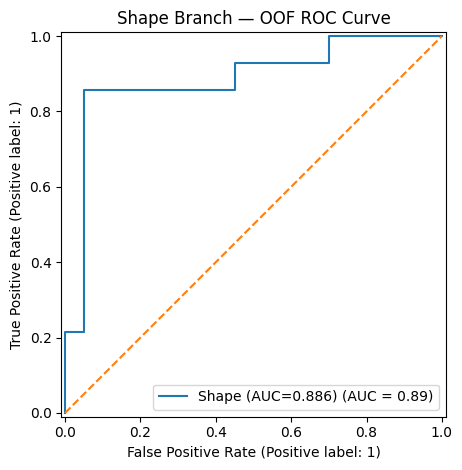

<Figure size 600x500 with 0 Axes>

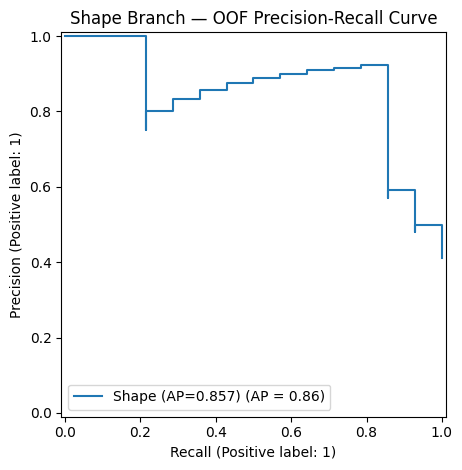

<Figure size 500x500 with 0 Axes>

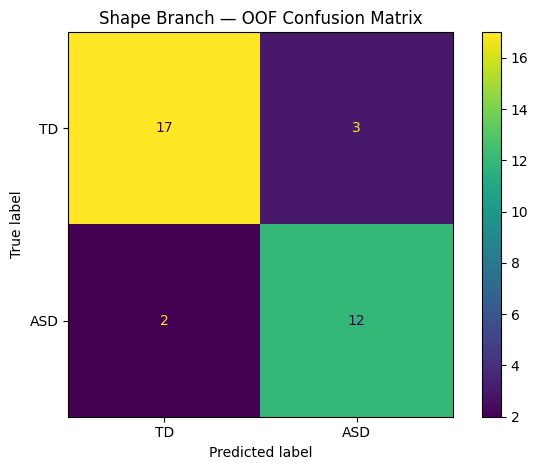


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell13_shape_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell13_shape_primary_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell13_shape_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell13_shape_inner_tuning_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell13_shape_misclassifications.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell13_shape_oof_roc_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell13_shape_oof_pr_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell13_shape_oof_confusion_matrix.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell13_shape_modeling_audit.csv

SHAPE FINAL OOF SUMMARY
Accuracy: 0.852941
Balanced Accuracy: 0.853571
Prec

In [ ]:
# ============================================================
# CELL 13 — SHAPE BRANCH NESTED 5x5 CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from joblib import dump

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


print("=" * 78)
print("CELL 13 — SHAPE BRANCH NESTED 5x5 CROSS-VALIDATION")
print("=" * 78)


# ============================================================
# 1. LOCK MODEL INPUT
# ============================================================

SHAPE_MODEL_NAME = "Shape"

X_shape_model = np.asarray(
    X_shape,
    dtype=np.float32
)


if X_shape_model.shape != (
    N_FINAL,
    1280
):

    raise RuntimeError(
        "Unexpected Shape feature-matrix dimensions."
    )


if not np.isfinite(
    X_shape_model
).all():

    raise RuntimeError(
        "Shape matrix contains non-finite values."
    )


print("\nSHAPE MODEL INPUT")

print(
    "Participants:",
    X_shape_model.shape[0]
)

print(
    "Features:",
    X_shape_model.shape[1]
)

print(
    "Age included:",
    False
)

print(
    "Gender included:",
    False
)

print(
    "Questionnaire included:",
    False
)


# ============================================================
# 2. OOF STORAGE
# ============================================================

shape_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


shape_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


shape_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


shape_fold_records = []

shape_tuning_records = []

shape_model_files = []


# ============================================================
# 3. LOCKED OUTER LOOP
# ============================================================

for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    print(
        "\n"
        +
        "-" * 72
    )

    print(
        f"SHAPE — OUTER FOLD {outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "-" * 72
    )


    # --------------------------------------------------------
    # Strict train/test separation
    # --------------------------------------------------------

    assert_disjoint_indices(
        outer_train_idx,
        outer_test_idx,
        context=(
            f"Shape outer fold {outer_fold_number}"
        )
    )


    if np.any(
        shape_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "A Shape outer-test participant is being "
            "predicted more than once."
        )


    X_outer_train = X_shape_model[
        outer_train_idx
    ]

    y_outer_train = y[
        outer_train_idx
    ]


    X_outer_test = X_shape_model[
        outer_test_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    inner_splits = INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ]


    # --------------------------------------------------------
    # Inner hyperparameter tuning
    # --------------------------------------------------------

    shape_grid = tune_logistic_regression(

        X_outer_train,

        y_outer_train,

        inner_splits
    )


    best_shape_model = (
        shape_grid.best_estimator_
    )


    best_C = float(
        shape_grid.best_params_[
            "classifier__C"
        ]
    )


    best_inner_auc = float(
        shape_grid.best_score_
    )


    print(
        "Selected C:",
        best_C
    )

    print(
        "Best inner mean ROC-AUC:",
        round(
            best_inner_auc,
            6
        )
    )


    # --------------------------------------------------------
    # Save complete tuning grid for this outer fold
    # --------------------------------------------------------

    cv_results = shape_grid.cv_results_


    for candidate_index in range(
        len(
            cv_results[
                "params"
            ]
        )
    ):

        shape_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "C":
                float(
                    cv_results[
                        "param_classifier__C"
                    ][
                        candidate_index
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # --------------------------------------------------------
    # Untouched outer-test predictions
    # --------------------------------------------------------

    outer_test_probability = (
        positive_class_probability(
            best_shape_model,
            X_outer_test
        )
    )


    outer_test_prediction = (
        outer_test_probability
        >=
        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    shape_oof_probability[
        outer_test_idx
    ] = outer_test_probability


    shape_oof_prediction[
        outer_test_idx
    ] = outer_test_prediction


    shape_oof_filled[
        outer_test_idx
    ] = True


    # --------------------------------------------------------
    # Fold-level held-out metrics
    # --------------------------------------------------------

    fold_metrics = compute_binary_metrics(

        y_outer_test,

        outer_test_probability,

        threshold=PRIMARY_BINARY_THRESHOLD
    )


    print(
        "Outer-test ROC-AUC:",
        round(
            fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "Outer-test accuracy:",
        round(
            fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # --------------------------------------------------------
    # Save exact fitted outer-fold model
    # --------------------------------------------------------

    shape_model_file = (

        MODELS_DIR
        /
        (
            f"shape_outer_fold_"
            f"{outer_fold_number}.joblib"
        )
    )


    dump(
        best_shape_model,
        shape_model_file
    )


    shape_model_files.append(
        str(
            shape_model_file
        )
    )


    # --------------------------------------------------------
    # Fold record
    # --------------------------------------------------------

    shape_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Selected_C":
            best_C,

        "Best_Inner_ROC_AUC":
            best_inner_auc,

        "Outer_Test_Accuracy":
            fold_metrics[
                "Accuracy"
            ],

        "Outer_Test_Balanced_Accuracy":
            fold_metrics[
                "Balanced_Accuracy"
            ],

        "Outer_Test_Sensitivity":
            fold_metrics[
                "Sensitivity"
            ],

        "Outer_Test_Specificity":
            fold_metrics[
                "Specificity"
            ],

        "Outer_Test_ROC_AUC":
            fold_metrics[
                "ROC_AUC"
            ],

        "Outer_Test_PR_AUC":
            fold_metrics[
                "PR_AUC"
            ],

        "Model_File":
            str(
                shape_model_file
            )
    })


# ============================================================
# 4. STRICT OOF COMPLETENESS CHECK
# ============================================================

print("\n" + "-" * 72)
print("SHAPE OOF COMPLETENESS AUDIT")
print("-" * 72)


print(
    "Participants expected:",
    N_FINAL
)

print(
    "Participants predicted:",
    int(
        shape_oof_filled.sum()
    )
)

print(
    "Missing OOF probabilities:",
    int(
        np.isnan(
            shape_oof_probability
        ).sum()
    )
)


if not shape_oof_filled.all():

    raise RuntimeError(
        "Not every participant received one Shape OOF prediction."
    )


validate_oof_probabilities(
    shape_oof_probability
)


if np.any(
    shape_oof_prediction
    <
    0
):

    raise RuntimeError(
        "Missing Shape OOF binary predictions."
    )


print(
    "Exactly one held-out prediction per participant: PASS"
)


# ============================================================
# 5. OVERALL PARTICIPANT-LEVEL OOF METRICS
# ============================================================

shape_metrics = compute_binary_metrics(

    y,

    shape_oof_probability,

    threshold=PRIMARY_BINARY_THRESHOLD
)


shape_metrics_df = metrics_to_dataframe(

    SHAPE_MODEL_NAME,

    shape_metrics
)


print("\nSHAPE PRIMARY OOF PERFORMANCE")

display(
    shape_metrics_df.round(
        6
    )
)


shape_cm = np.array([

    [
        shape_metrics[
            "TN"
        ],
        shape_metrics[
            "FP"
        ]
    ],

    [
        shape_metrics[
            "FN"
        ],
        shape_metrics[
            "TP"
        ]
    ]
])


print("\nSHAPE CONFUSION MATRIX")

print(
    shape_cm
)


# ============================================================
# 6. FOLD SUMMARY
# ============================================================

shape_fold_summary_df = pd.DataFrame(
    shape_fold_records
)


shape_tuning_df = pd.DataFrame(
    shape_tuning_records
)


print("\nSHAPE OUTER-FOLD SUMMARY")

display(
    shape_fold_summary_df.drop(
        columns=[
            "Model_File"
        ]
    ).round(
        6
    )
)


print("\nSELECTED C VALUES")

print(
    shape_fold_summary_df[
        "Selected_C"
    ].tolist()
)


# ============================================================
# 7. PARTICIPANT-LEVEL OOF TABLE
# ============================================================

shape_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_shape_ASD":
        shape_oof_probability,

    "Predicted_Class":
        shape_oof_prediction
})


shape_oof_df[
    "Predicted_Group"
] = np.where(

    shape_oof_df[
        "Predicted_Class"
    ]
    ==
    1,

    "ASD",

    "TD"
)


shape_oof_df[
    "Correct"
] = (

    shape_oof_df[
        "Predicted_Class"
    ]

    ==

    shape_oof_df[
        "y_true"
    ]
)


print("\nSHAPE OOF PREDICTION PREVIEW")

display(
    shape_oof_df.head(
        10
    ).round(
        6
    )
)


# ============================================================
# 8. MISCLASSIFICATION AUDIT
# ============================================================

shape_errors_df = (

    shape_oof_df[
        ~shape_oof_df[
            "Correct"
        ]
    ]

    .copy()
)


shape_errors_df[
    "Error_Type"
] = np.where(

    (
        shape_errors_df[
            "y_true"
        ] == 1
    )
    &
    (
        shape_errors_df[
            "Predicted_Class"
        ] == 0
    ),

    "False Negative",

    "False Positive"
)


# Sort:
# false negatives from lowest probability upward;
# false positives from highest probability downward.

shape_false_negatives_df = (

    shape_errors_df[
        shape_errors_df[
            "Error_Type"
        ]
        ==
        "False Negative"
    ]

    .sort_values(
        "P_shape_ASD",
        ascending=True
    )
)


shape_false_positives_df = (

    shape_errors_df[
        shape_errors_df[
            "Error_Type"
        ]
        ==
        "False Positive"
    ]

    .sort_values(
        "P_shape_ASD",
        ascending=False
    )
)


shape_errors_sorted_df = pd.concat(

    [
        shape_false_negatives_df,
        shape_false_positives_df
    ],

    ignore_index=True
)


print(
    "\nSHAPE MISCLASSIFIED PARTICIPANTS:",
    len(
        shape_errors_sorted_df
    )
)


if len(
    shape_errors_sorted_df
) > 0:

    display(
        shape_errors_sorted_df[
            [
                "Participant_ID",
                "Group",
                "Outer_Fold",
                "P_shape_ASD",
                "Predicted_Group",
                "Error_Type"
            ]
        ].round(
            6
        )
    )


# ============================================================
# 9. ROC CURVE
# ============================================================

fig = plt.figure(
    figsize=(
        6,
        5
    )
)


RocCurveDisplay.from_predictions(

    y,

    shape_oof_probability,

    name=(
        f"Shape "
        f"(AUC={shape_metrics['ROC_AUC']:.3f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.title(
    "Shape Branch — OOF ROC Curve"
)


plt.tight_layout()


shape_roc_file = (

    FIGURES_DIR
    /
    "cell13_shape_oof_roc_curve.png"
)


plt.savefig(
    shape_roc_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 10. PRECISION-RECALL CURVE
# ============================================================

fig = plt.figure(
    figsize=(
        6,
        5
    )
)


PrecisionRecallDisplay.from_predictions(

    y,

    shape_oof_probability,

    name=(
        f"Shape "
        f"(AP={shape_metrics['PR_AUC']:.3f})"
    )
)


plt.title(
    "Shape Branch — OOF Precision-Recall Curve"
)


plt.tight_layout()


shape_pr_file = (

    FIGURES_DIR
    /
    "cell13_shape_oof_pr_curve.png"
)


plt.savefig(
    shape_pr_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. CONFUSION MATRIX FIGURE
# ============================================================

fig = plt.figure(
    figsize=(
        5,
        5
    )
)


display_cm = ConfusionMatrixDisplay(

    confusion_matrix=shape_cm,

    display_labels=[
        "TD",
        "ASD"
    ]
)


display_cm.plot(
    values_format="d"
)


plt.title(
    "Shape Branch — OOF Confusion Matrix"
)


plt.tight_layout()


shape_cm_file = (

    FIGURES_DIR
    /
    "cell13_shape_oof_confusion_matrix.png"
)


plt.savefig(
    shape_cm_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. SAVE RESULTS
# ============================================================

shape_oof_file = (
    RESULTS_DIR
    /
    "cell13_shape_oof_predictions.csv"
)


shape_metrics_file = (
    RESULTS_DIR
    /
    "cell13_shape_primary_metrics.csv"
)


shape_fold_file = (
    RESULTS_DIR
    /
    "cell13_shape_outer_fold_results.csv"
)


shape_tuning_file = (
    RESULTS_DIR
    /
    "cell13_shape_inner_tuning_results.csv"
)


shape_errors_file = (
    RESULTS_DIR
    /
    "cell13_shape_misclassifications.csv"
)


shape_oof_df.to_csv(
    shape_oof_file,
    index=False
)


shape_metrics_df.to_csv(
    shape_metrics_file,
    index=False
)


shape_fold_summary_df.to_csv(
    shape_fold_file,
    index=False
)


shape_tuning_df.to_csv(
    shape_tuning_file,
    index=False
)


shape_errors_sorted_df.to_csv(
    shape_errors_file,
    index=False
)


# ============================================================
# 13. MODELING AUDIT RECORD
# ============================================================

shape_modeling_audit_df = pd.DataFrame([

    {
        "Check":
            "Participant-level representation",

        "Status":
            "PASS",

        "Details":
            "Four shape embeddings mean-pooled per child"
    },

    {
        "Check":
            "Common locked outer folds used",

        "Status":
            "PASS",

        "Details":
            f"{OUTER_FOLDS} outer folds"
    },

    {
        "Check":
            "Inner hyperparameter selection",

        "Status":
            "PASS",

        "Details":
            f"{INNER_FOLDS}-fold inner CV using ROC-AUC"
    },

    {
        "Check":
            "Scaler leakage prevented",

        "Status":
            "PASS",

        "Details":
            "StandardScaler contained inside sklearn Pipeline"
    },

    {
        "Check":
            "Age predictor",

        "Status":
            "NOT USED",

        "Details":
            "Age retained only as metadata"
    },

    {
        "Check":
            "Gender predictor",

        "Status":
            "NOT USED",

        "Details":
            "Gender retained only as metadata"
    },

    {
        "Check":
            "OOF completeness",

        "Status":
            "PASS",

        "Details":
            (
                f"{N_FINAL}/{N_FINAL} participants received "
                "exactly one outer-test prediction"
            )
    }
])


shape_modeling_audit_file = (
    AUDIT_DIR
    /
    "cell13_shape_modeling_audit.csv"
)


shape_modeling_audit_df.to_csv(
    shape_modeling_audit_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    shape_oof_file
)

print(
    shape_metrics_file
)

print(
    shape_fold_file
)

print(
    shape_tuning_file
)

print(
    shape_errors_file
)

print(
    shape_roc_file
)

print(
    shape_pr_file
)

print(
    shape_cm_file
)

print(
    shape_modeling_audit_file
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("SHAPE FINAL OOF SUMMARY")

print(
    "Accuracy:",
    round(
        shape_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Balanced Accuracy:",
    round(
        shape_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Precision:",
    round(
        shape_metrics[
            "Precision"
        ],
        6
    )
)

print(
    "Sensitivity:",
    round(
        shape_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        shape_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "F1:",
    round(
        shape_metrics[
            "F1"
        ],
        6
    )
)

print(
    "ROC-AUC:",
    round(
        shape_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "PR-AUC:",
    round(
        shape_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    shape_cm
)

print(
    "OOF participants:",
    int(
        shape_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print("\nCELL 13 STATUS: PASS")
print("=" * 78)

# 14. Colour Branch — Fully Nested Participant-Level Evaluation

The Colour branch combines two participant-level representations:

- 1,280 frozen EfficientNet-B0 features from the completed Colour Drawing;
- 13 objective engineered colour statistics.

Final Colour representation:

`1,293 features per participant`

The classifier is the pre-specified scaled L2 Logistic Regression model.

The same locked five outer folds and corresponding inner folds used for the
Shape model are reused unchanged. This ensures that later modality
comparisons are paired on exactly the same held-out participants.

For each outer fold:

1. the outer test participants remain untouched;
2. Logistic Regression regularization parameter `C` is selected using only
   the outer-training participants;
3. `StandardScaler` is fitted inside each training pipeline;
4. the selected model is refitted on the complete outer-training partition;
5. probabilities are generated only for the untouched outer-test participants.

After the five outer folds, every participant receives exactly one Colour
out-of-fold ASD probability.

The primary binary threshold remains 0.50.

No age, gender, participant ID, Shape information, DAM information, or
questionnaire information is supplied to the Colour classifier.

Because age is imbalanced between diagnostic groups in the current cohort,
Colour performance will later undergo the same age-sensitivity analysis as
the other drawing modalities.

CELL 14 — COLOUR BRANCH NESTED 5x5 CROSS-VALIDATION

COLOUR MODEL INPUT
Participants: 34
Total features: 1293
CNN features: 1280
Engineered colour features: 13
Age included: False
Gender included: False
Other modalities included: False

------------------------------------------------------------------------
COLOUR — OUTER FOLD 1/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean ROC-AUC: 0.933333
Outer-test ROC-AUC: 0.916667
Outer-test accuracy: 0.857143

------------------------------------------------------------------------
COLOUR — OUTER FOLD 2/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean ROC-AUC: 0.933333
Outer-test ROC-AUC: 0.75
Outer-test accuracy: 0.857143

------------------------------------------------------------------------
COLOUR — OUTER FOLD 3/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Colour,0.5,0.852941,0.853571,0.8,0.857143,0.85,0.827586,0.875,0.875192,17,3,2,12



COLOUR CONFUSION MATRIX
[[17  3]
 [ 2 12]]

COLOUR OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Test_N,Selected_C,Best_Inner_ROC_AUC,Outer_Test_Accuracy,Outer_Test_Balanced_Accuracy,Outer_Test_Sensitivity,Outer_Test_Specificity,Outer_Test_ROC_AUC,Outer_Test_PR_AUC
0,1,27,7,0.001,0.933333,0.857143,0.875000,1.000000,0.75,0.916667,0.916667
1,2,27,7,0.001,0.933333,0.857143,0.875000,1.000000,0.75,0.750000,0.638889
2,3,27,7,0.001,0.975000,0.714286,0.708333,0.666667,0.75,0.916667,0.916667
3,4,27,7,0.100,0.975000,0.857143,0.833333,0.666667,1.00,0.666667,0.809524
4,5,28,6,0.010,0.883333,1.000000,1.000000,1.000000,1.00,1.000000,1.000000



SELECTED C VALUES
[0.001, 0.001, 0.001, 0.1, 0.01]

COLOUR OOF PREDICTION PREVIEW


,Participant_ID,Group,y_true,Outer_Fold,P_colour_ASD,Predicted_Class,Predicted_Group,Correct
0,P006,TD,0,1,0.319188,0,TD,True
1,P007,TD,0,5,0.079367,0,TD,True
2,P008,TD,0,4,0.281536,0,TD,True
3,P009,TD,0,1,0.366977,0,TD,True
4,P010,TD,0,3,0.207678,0,TD,True
5,P011,TD,0,2,0.344249,0,TD,True
6,P012,TD,0,3,0.266677,0,TD,True
7,P013,TD,0,1,0.287013,0,TD,True
8,P014,TD,0,5,0.085948,0,TD,True
9,P015,TD,0,5,0.071953,0,TD,True



COLOUR MISCLASSIFIED PARTICIPANTS: 5


,Participant_ID,Group,Outer_Fold,P_colour_ASD,Predicted_Group,Error_Type
0,P038,ASD,4,0.053113,TD,False Negative
1,P028,ASD,3,0.362279,TD,False Negative
2,P020,TD,2,0.726020,ASD,False Positive
3,P017,TD,1,0.663879,ASD,False Positive
4,P018,TD,3,0.542656,ASD,False Positive


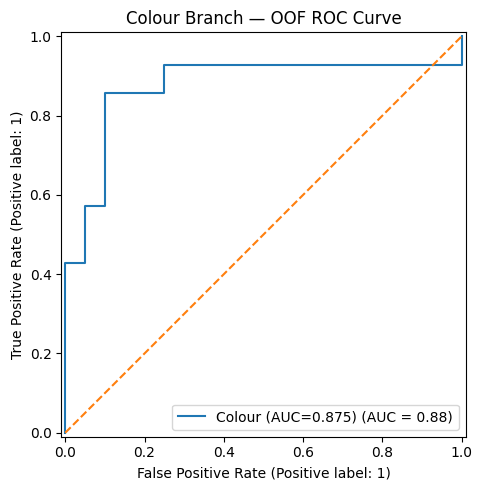

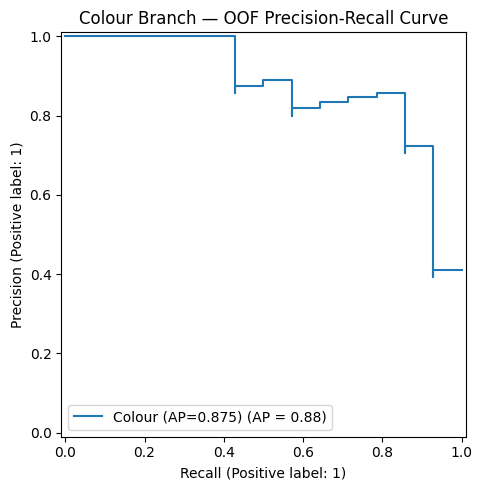

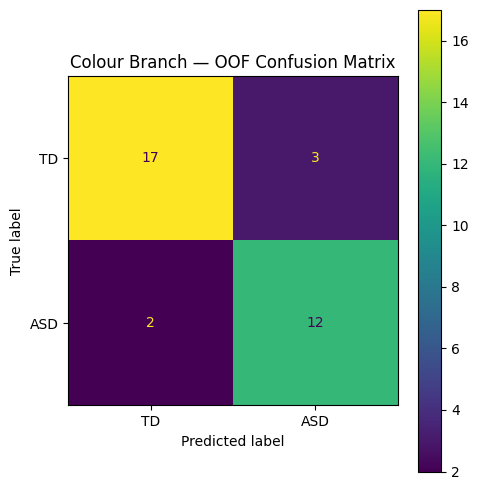


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell14_colour_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell14_colour_primary_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell14_colour_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell14_colour_inner_tuning_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell14_colour_misclassifications.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell14_colour_oof_roc_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell14_colour_oof_pr_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell14_colour_oof_confusion_matrix.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell14_colour_modeling_audit.csv

COLOUR FINAL OOF SUMMARY
Accuracy: 0.852941
Balanced Accuracy: 0.8

In [ ]:
# ============================================================
# CELL 14 — COLOUR BRANCH NESTED 5x5 CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


print("=" * 78)
print("CELL 14 — COLOUR BRANCH NESTED 5x5 CROSS-VALIDATION")
print("=" * 78)


# ============================================================
# 1. LOCK MODEL INPUT
# ============================================================

COLOUR_MODEL_NAME = "Colour"

X_colour_model = np.asarray(
    X_colour,
    dtype=np.float32
)


if X_colour_model.shape != (
    N_FINAL,
    EXPECTED_COLOUR_DIM
):

    raise RuntimeError(
        "Unexpected Colour feature-matrix dimensions."
    )


if not np.isfinite(
    X_colour_model
).all():

    raise RuntimeError(
        "Colour matrix contains non-finite values."
    )


print("\nCOLOUR MODEL INPUT")

print(
    "Participants:",
    X_colour_model.shape[0]
)

print(
    "Total features:",
    X_colour_model.shape[1]
)

print(
    "CNN features:",
    EXPECTED_EFFICIENTNET_DIM
)

print(
    "Engineered colour features:",
    len(
        COLOUR_FEATURE_NAMES
    )
)

print(
    "Age included:",
    False
)

print(
    "Gender included:",
    False
)

print(
    "Other modalities included:",
    False
)


# ============================================================
# 2. OOF STORAGE
# ============================================================

colour_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


colour_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


colour_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


colour_fold_records = []

colour_tuning_records = []

colour_model_files = []


# ============================================================
# 3. LOCKED OUTER LOOP
# ============================================================

for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    print(
        "\n"
        +
        "-" * 72
    )

    print(
        f"COLOUR — OUTER FOLD {outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "-" * 72
    )


    # --------------------------------------------------------
    # Strict train/test separation
    # --------------------------------------------------------

    assert_disjoint_indices(
        outer_train_idx,
        outer_test_idx,
        context=(
            f"Colour outer fold {outer_fold_number}"
        )
    )


    if np.any(
        colour_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "A Colour outer-test participant is being "
            "predicted more than once."
        )


    X_outer_train = X_colour_model[
        outer_train_idx
    ]

    y_outer_train = y[
        outer_train_idx
    ]


    X_outer_test = X_colour_model[
        outer_test_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    inner_splits = INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ]


    # --------------------------------------------------------
    # Inner hyperparameter tuning
    # --------------------------------------------------------

    colour_grid = tune_logistic_regression(

        X_outer_train,

        y_outer_train,

        inner_splits
    )


    best_colour_model = (
        colour_grid.best_estimator_
    )


    best_C = float(
        colour_grid.best_params_[
            "classifier__C"
        ]
    )


    best_inner_auc = float(
        colour_grid.best_score_
    )


    print(
        "Selected C:",
        best_C
    )

    print(
        "Best inner mean ROC-AUC:",
        round(
            best_inner_auc,
            6
        )
    )


    # --------------------------------------------------------
    # Save full tuning grid for this outer fold
    # --------------------------------------------------------

    cv_results = colour_grid.cv_results_


    for candidate_index in range(
        len(
            cv_results[
                "params"
            ]
        )
    ):

        colour_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "C":
                float(
                    cv_results[
                        "param_classifier__C"
                    ][
                        candidate_index
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # --------------------------------------------------------
    # Untouched outer-test predictions
    # --------------------------------------------------------

    outer_test_probability = (
        positive_class_probability(
            best_colour_model,
            X_outer_test
        )
    )


    outer_test_prediction = (
        outer_test_probability
        >=
        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    colour_oof_probability[
        outer_test_idx
    ] = outer_test_probability


    colour_oof_prediction[
        outer_test_idx
    ] = outer_test_prediction


    colour_oof_filled[
        outer_test_idx
    ] = True


    # --------------------------------------------------------
    # Fold-level held-out metrics
    # --------------------------------------------------------

    fold_metrics = compute_binary_metrics(

        y_outer_test,

        outer_test_probability,

        threshold=PRIMARY_BINARY_THRESHOLD
    )


    print(
        "Outer-test ROC-AUC:",
        round(
            fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "Outer-test accuracy:",
        round(
            fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # --------------------------------------------------------
    # Save exact fitted outer-fold model
    # --------------------------------------------------------

    colour_model_file = (

        MODELS_DIR
        /
        (
            f"colour_outer_fold_"
            f"{outer_fold_number}.joblib"
        )
    )


    dump(
        best_colour_model,
        colour_model_file
    )


    colour_model_files.append(
        str(
            colour_model_file
        )
    )


    # --------------------------------------------------------
    # Fold record
    # --------------------------------------------------------

    colour_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Selected_C":
            best_C,

        "Best_Inner_ROC_AUC":
            best_inner_auc,

        "Outer_Test_Accuracy":
            fold_metrics[
                "Accuracy"
            ],

        "Outer_Test_Balanced_Accuracy":
            fold_metrics[
                "Balanced_Accuracy"
            ],

        "Outer_Test_Sensitivity":
            fold_metrics[
                "Sensitivity"
            ],

        "Outer_Test_Specificity":
            fold_metrics[
                "Specificity"
            ],

        "Outer_Test_ROC_AUC":
            fold_metrics[
                "ROC_AUC"
            ],

        "Outer_Test_PR_AUC":
            fold_metrics[
                "PR_AUC"
            ],

        "Model_File":
            str(
                colour_model_file
            )
    })


# ============================================================
# 4. STRICT OOF COMPLETENESS CHECK
# ============================================================

print("\n" + "-" * 72)
print("COLOUR OOF COMPLETENESS AUDIT")
print("-" * 72)


print(
    "Participants expected:",
    N_FINAL
)

print(
    "Participants predicted:",
    int(
        colour_oof_filled.sum()
    )
)

print(
    "Missing OOF probabilities:",
    int(
        np.isnan(
            colour_oof_probability
        ).sum()
    )
)


if not colour_oof_filled.all():

    raise RuntimeError(
        "Not every participant received one Colour OOF prediction."
    )


validate_oof_probabilities(
    colour_oof_probability
)


if np.any(
    colour_oof_prediction
    <
    0
):

    raise RuntimeError(
        "Missing Colour OOF binary predictions."
    )


print(
    "Exactly one held-out prediction per participant: PASS"
)


# ============================================================
# 5. OVERALL PARTICIPANT-LEVEL OOF METRICS
# ============================================================

colour_metrics = compute_binary_metrics(

    y,

    colour_oof_probability,

    threshold=PRIMARY_BINARY_THRESHOLD
)


colour_metrics_df = metrics_to_dataframe(

    COLOUR_MODEL_NAME,

    colour_metrics
)


print("\nCOLOUR PRIMARY OOF PERFORMANCE")

display(
    colour_metrics_df.round(
        6
    )
)


colour_cm = np.array([

    [
        colour_metrics[
            "TN"
        ],
        colour_metrics[
            "FP"
        ]
    ],

    [
        colour_metrics[
            "FN"
        ],
        colour_metrics[
            "TP"
        ]
    ]
])


print("\nCOLOUR CONFUSION MATRIX")

print(
    colour_cm
)


# ============================================================
# 6. OUTER-FOLD / TUNING SUMMARY
# ============================================================

colour_fold_summary_df = pd.DataFrame(
    colour_fold_records
)


colour_tuning_df = pd.DataFrame(
    colour_tuning_records
)


print("\nCOLOUR OUTER-FOLD SUMMARY")

display(
    colour_fold_summary_df.drop(
        columns=[
            "Model_File"
        ]
    ).round(
        6
    )
)


print("\nSELECTED C VALUES")

print(
    colour_fold_summary_df[
        "Selected_C"
    ].tolist()
)


# ============================================================
# 7. PARTICIPANT-LEVEL OOF TABLE
# ============================================================

colour_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_colour_ASD":
        colour_oof_probability,

    "Predicted_Class":
        colour_oof_prediction
})


colour_oof_df[
    "Predicted_Group"
] = np.where(

    colour_oof_df[
        "Predicted_Class"
    ]
    ==
    1,

    "ASD",

    "TD"
)


colour_oof_df[
    "Correct"
] = (

    colour_oof_df[
        "Predicted_Class"
    ]

    ==

    colour_oof_df[
        "y_true"
    ]
)


print("\nCOLOUR OOF PREDICTION PREVIEW")

display(
    colour_oof_df.head(
        10
    ).round(
        6
    )
)


# ============================================================
# 8. MISCLASSIFICATION AUDIT
# ============================================================

colour_errors_df = (

    colour_oof_df[
        ~colour_oof_df[
            "Correct"
        ]
    ]

    .copy()
)


colour_errors_df[
    "Error_Type"
] = np.where(

    (
        colour_errors_df[
            "y_true"
        ] == 1
    )
    &
    (
        colour_errors_df[
            "Predicted_Class"
        ] == 0
    ),

    "False Negative",

    "False Positive"
)


colour_false_negatives_df = (

    colour_errors_df[
        colour_errors_df[
            "Error_Type"
        ]
        ==
        "False Negative"
    ]

    .sort_values(
        "P_colour_ASD",
        ascending=True
    )
)


colour_false_positives_df = (

    colour_errors_df[
        colour_errors_df[
            "Error_Type"
        ]
        ==
        "False Positive"
    ]

    .sort_values(
        "P_colour_ASD",
        ascending=False
    )
)


colour_errors_sorted_df = pd.concat(

    [
        colour_false_negatives_df,
        colour_false_positives_df
    ],

    ignore_index=True
)


print(
    "\nCOLOUR MISCLASSIFIED PARTICIPANTS:",
    len(
        colour_errors_sorted_df
    )
)


if len(
    colour_errors_sorted_df
) > 0:

    display(
        colour_errors_sorted_df[
            [
                "Participant_ID",
                "Group",
                "Outer_Fold",
                "P_colour_ASD",
                "Predicted_Group",
                "Error_Type"
            ]
        ].round(
            6
        )
    )


# ============================================================
# 9. ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


RocCurveDisplay.from_predictions(

    y,

    colour_oof_probability,

    name=(
        f"Colour "
        f"(AUC={colour_metrics['ROC_AUC']:.3f})"
    ),

    ax=ax
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


ax.set_title(
    "Colour Branch — OOF ROC Curve"
)


fig.tight_layout()


colour_roc_file = (

    FIGURES_DIR
    /
    "cell14_colour_oof_roc_curve.png"
)


fig.savefig(
    colour_roc_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 10. PRECISION-RECALL CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


PrecisionRecallDisplay.from_predictions(

    y,

    colour_oof_probability,

    name=(
        f"Colour "
        f"(AP={colour_metrics['PR_AUC']:.3f})"
    ),

    ax=ax
)


ax.set_title(
    "Colour Branch — OOF Precision-Recall Curve"
)


fig.tight_layout()


colour_pr_file = (

    FIGURES_DIR
    /
    "cell14_colour_oof_pr_curve.png"
)


fig.savefig(
    colour_pr_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. CONFUSION MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        5,
        5
    )
)


display_cm = ConfusionMatrixDisplay(

    confusion_matrix=colour_cm,

    display_labels=[
        "TD",
        "ASD"
    ]
)


display_cm.plot(
    ax=ax,
    values_format="d"
)


ax.set_title(
    "Colour Branch — OOF Confusion Matrix"
)


fig.tight_layout()


colour_cm_file = (

    FIGURES_DIR
    /
    "cell14_colour_oof_confusion_matrix.png"
)


fig.savefig(
    colour_cm_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. SAVE RESULTS
# ============================================================

colour_oof_file = (
    RESULTS_DIR
    /
    "cell14_colour_oof_predictions.csv"
)


colour_metrics_file = (
    RESULTS_DIR
    /
    "cell14_colour_primary_metrics.csv"
)


colour_fold_file = (
    RESULTS_DIR
    /
    "cell14_colour_outer_fold_results.csv"
)


colour_tuning_file = (
    RESULTS_DIR
    /
    "cell14_colour_inner_tuning_results.csv"
)


colour_errors_file = (
    RESULTS_DIR
    /
    "cell14_colour_misclassifications.csv"
)


colour_oof_df.to_csv(
    colour_oof_file,
    index=False
)


colour_metrics_df.to_csv(
    colour_metrics_file,
    index=False
)


colour_fold_summary_df.to_csv(
    colour_fold_file,
    index=False
)


colour_tuning_df.to_csv(
    colour_tuning_file,
    index=False
)


colour_errors_sorted_df.to_csv(
    colour_errors_file,
    index=False
)


# ============================================================
# 13. MODELING AUDIT RECORD
# ============================================================

colour_modeling_audit_df = pd.DataFrame([

    {
        "Check":
            "Participant-level representation",

        "Status":
            "PASS",

        "Details":
            (
                "1280 EfficientNet features + "
                "13 engineered colour statistics"
            )
    },

    {
        "Check":
            "Common locked outer folds used",

        "Status":
            "PASS",

        "Details":
            f"{OUTER_FOLDS} outer folds"
    },

    {
        "Check":
            "Inner hyperparameter selection",

        "Status":
            "PASS",

        "Details":
            f"{INNER_FOLDS}-fold inner CV using ROC-AUC"
    },

    {
        "Check":
            "Scaler leakage prevented",

        "Status":
            "PASS",

        "Details":
            "StandardScaler contained inside sklearn Pipeline"
    },

    {
        "Check":
            "Engineered features label-independent",

        "Status":
            "PASS",

        "Details":
            (
                "Colour statistics were extracted before "
                "supervised model fitting"
            )
    },

    {
        "Check":
            "Boundary-overflow proxy",

        "Status":
            "NOT USED",

        "Details":
            "No validated template masks available"
    },

    {
        "Check":
            "Object-colour matching proxy",

        "Status":
            "NOT USED",

        "Details":
            "No validated semantic masks/rules available"
    },

    {
        "Check":
            "Age predictor",

        "Status":
            "NOT USED",

        "Details":
            "Age retained only as metadata"
    },

    {
        "Check":
            "Gender predictor",

        "Status":
            "NOT USED",

        "Details":
            "Gender retained only as metadata"
    },

    {
        "Check":
            "OOF completeness",

        "Status":
            "PASS",

        "Details":
            (
                f"{N_FINAL}/{N_FINAL} participants received "
                "exactly one outer-test prediction"
            )
    }
])


colour_modeling_audit_file = (
    AUDIT_DIR
    /
    "cell14_colour_modeling_audit.csv"
)


colour_modeling_audit_df.to_csv(
    colour_modeling_audit_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    colour_oof_file
)

print(
    colour_metrics_file
)

print(
    colour_fold_file
)

print(
    colour_tuning_file
)

print(
    colour_errors_file
)

print(
    colour_roc_file
)

print(
    colour_pr_file
)

print(
    colour_cm_file
)

print(
    colour_modeling_audit_file
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("COLOUR FINAL OOF SUMMARY")

print(
    "Accuracy:",
    round(
        colour_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Balanced Accuracy:",
    round(
        colour_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Precision:",
    round(
        colour_metrics[
            "Precision"
        ],
        6
    )
)

print(
    "Sensitivity:",
    round(
        colour_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        colour_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "F1:",
    round(
        colour_metrics[
            "F1"
        ],
        6
    )
)

print(
    "ROC-AUC:",
    round(
        colour_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "PR-AUC:",
    round(
        colour_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    colour_cm
)

print(
    "OOF participants:",
    int(
        colour_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print("\nCELL 14 STATUS: PASS")
print("=" * 78)

# 15. Draw-a-Man Branch — Fully Nested Participant-Level Evaluation

The Draw-a-Man (DAM) branch uses the frozen DINOv2-small representation
extracted from each participant's Draw-a-Man image.

Final DAM representation:

`384 DINOv2 CLS-token features per participant`

The classifier is the pre-specified scaled L2 Logistic Regression model.

The same five locked outer folds and their corresponding five-fold inner
splits are reused without modification.

For every outer fold:

1. outer-test participants remain completely untouched;
2. the Logistic Regression regularization parameter `C` is selected using
   only outer-training participants;
3. StandardScaler is fitted only inside the training pipeline;
4. the selected model is refitted on the full outer-training partition;
5. ASD probabilities are generated only for the held-out outer-test
   participants.

After all folds are complete, every participant has exactly one DAM
out-of-fold probability.

The primary binary threshold remains 0.50.

Age, gender, participant ID, Shape features, Colour features and questionnaire
responses are not supplied to the DAM model.

Because developmental age may affect human-figure drawing characteristics,
the known age imbalance in the current cohort will later be examined in the
pre-specified age-sensitivity analysis.

CELL 15 — DAM BRANCH NESTED 5x5 CROSS-VALIDATION

DAM MODEL INPUT
Participants: 34
Features: 384
Representation: Frozen DINOv2-small final-layer CLS token
Age included: False
Gender included: False
Other modalities included: False

------------------------------------------------------------------------
DAM — OUTER FOLD 1/5
------------------------------------------------------------------------
Selected C: 0.01
Best inner mean ROC-AUC: 0.9
Outer-test ROC-AUC: 0.666667
Outer-test accuracy: 0.857143

------------------------------------------------------------------------
DAM — OUTER FOLD 2/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean ROC-AUC: 0.777778
Outer-test ROC-AUC: 0.916667
Outer-test accuracy: 0.714286

------------------------------------------------------------------------
DAM — OUTER FOLD 3/5
------------------------------------------------------------------------
Selected C: 0.001
Best inner mean ROC-AUC: 0.8416

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,DAM,0.5,0.647059,0.657143,0.555556,0.714286,0.6,0.625,0.710714,0.66044,12,8,4,10



DAM CONFUSION MATRIX
[[12  8]
 [ 4 10]]

DAM OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Test_N,Selected_C,Best_Inner_ROC_AUC,Outer_Test_Accuracy,Outer_Test_Balanced_Accuracy,Outer_Test_Sensitivity,Outer_Test_Specificity,Outer_Test_ROC_AUC,Outer_Test_PR_AUC
0,1,27,7,0.010,0.900000,0.857143,0.833333,0.666667,1.00,0.666667,0.809524
1,2,27,7,0.001,0.777778,0.714286,0.708333,0.666667,0.75,0.916667,0.916667
2,3,27,7,0.001,0.841667,0.714286,0.750000,1.000000,0.50,0.750000,0.755556
3,4,27,7,0.001,0.908333,0.285714,0.333333,0.666667,0.00,0.333333,0.587302
4,5,28,6,100.000,0.861111,0.666667,0.625000,0.500000,0.75,0.750000,0.750000



SELECTED C VALUES
[0.01, 0.001, 0.001, 0.001, 100.0]

DAM OOF PREDICTION PREVIEW


,Participant_ID,Group,y_true,Outer_Fold,P_dam_ASD,Predicted_Class,Predicted_Group,Correct
0,P006,TD,0,1,0.235684,0,TD,True
1,P007,TD,0,5,0.310189,0,TD,True
2,P008,TD,0,4,0.600493,1,ASD,False
3,P009,TD,0,1,0.405729,0,TD,True
4,P010,TD,0,3,0.440235,0,TD,True
5,P011,TD,0,2,0.434204,0,TD,True
6,P012,TD,0,3,0.444209,0,TD,True
7,P013,TD,0,1,0.290815,0,TD,True
8,P014,TD,0,5,0.000479,0,TD,True
9,P015,TD,0,5,0.050027,0,TD,True



DAM MISCLASSIFIED PARTICIPANTS: 12


,Participant_ID,Group,Outer_Fold,P_dam_ASD,Predicted_Group,Error_Type
0,P033,ASD,5,0.089980,TD,False Negative
1,P039,ASD,1,0.184759,TD,False Negative
2,P038,ASD,4,0.447561,TD,False Negative
3,P032,ASD,2,0.455545,TD,False Negative
4,P019,TD,5,0.886513,ASD,False Positive
5,P008,TD,4,0.600493,ASD,False Positive
6,P024,TD,4,0.545801,ASD,False Positive
7,P018,TD,3,0.536407,ASD,False Positive
8,P023,TD,3,0.533365,ASD,False Positive
9,P016,TD,4,0.531816,ASD,False Positive


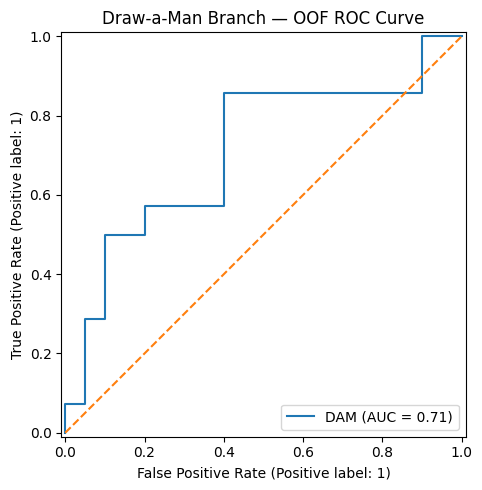

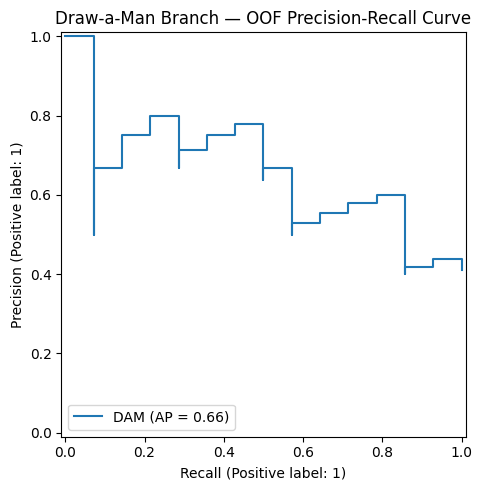

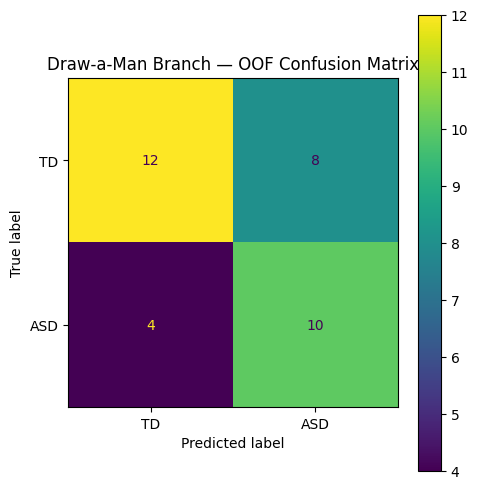


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell15_dam_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell15_dam_primary_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell15_dam_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell15_dam_inner_tuning_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell15_dam_misclassifications.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell15_dam_oof_roc_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell15_dam_oof_pr_curve.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell15_dam_oof_confusion_matrix.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell15_dam_modeling_audit.csv

DAM FINAL OOF SUMMARY
Accuracy: 0.647059
Balanced Accuracy: 0.657143
Precision: 0.555556
Sens

In [ ]:
# ============================================================
# CELL 15 — DAM BRANCH NESTED 5x5 CROSS-VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


print("=" * 78)
print("CELL 15 — DAM BRANCH NESTED 5x5 CROSS-VALIDATION")
print("=" * 78)


# ============================================================
# 1. LOCK MODEL INPUT
# ============================================================

DAM_MODEL_NAME = "DAM"

X_dam_model = np.asarray(
    X_dam,
    dtype=np.float32
)


if X_dam_model.shape != (
    N_FINAL,
    EXPECTED_DINOV2_DIM
):

    raise RuntimeError(
        "Unexpected DAM feature-matrix dimensions."
    )


if not np.isfinite(
    X_dam_model
).all():

    raise RuntimeError(
        "DAM matrix contains non-finite values."
    )


print("\nDAM MODEL INPUT")

print(
    "Participants:",
    X_dam_model.shape[0]
)

print(
    "Features:",
    X_dam_model.shape[1]
)

print(
    "Representation:",
    "Frozen DINOv2-small final-layer CLS token"
)

print(
    "Age included:",
    False
)

print(
    "Gender included:",
    False
)

print(
    "Other modalities included:",
    False
)


# ============================================================
# 2. OOF STORAGE
# ============================================================

dam_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


dam_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


dam_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


dam_fold_records = []

dam_tuning_records = []

dam_model_files = []


# ============================================================
# 3. LOCKED OUTER LOOP
# ============================================================

for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    print(
        "\n"
        +
        "-" * 72
    )

    print(
        f"DAM — OUTER FOLD {outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "-" * 72
    )


    # --------------------------------------------------------
    # Strict outer train/test separation
    # --------------------------------------------------------

    assert_disjoint_indices(
        outer_train_idx,
        outer_test_idx,
        context=(
            f"DAM outer fold {outer_fold_number}"
        )
    )


    if np.any(
        dam_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "A DAM outer-test participant is being "
            "predicted more than once."
        )


    X_outer_train = X_dam_model[
        outer_train_idx
    ]

    y_outer_train = y[
        outer_train_idx
    ]


    X_outer_test = X_dam_model[
        outer_test_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    inner_splits = INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ]


    # --------------------------------------------------------
    # Inner hyperparameter tuning
    # --------------------------------------------------------

    dam_grid = tune_logistic_regression(

        X_outer_train,

        y_outer_train,

        inner_splits
    )


    best_dam_model = (
        dam_grid.best_estimator_
    )


    best_C = float(
        dam_grid.best_params_[
            "classifier__C"
        ]
    )


    best_inner_auc = float(
        dam_grid.best_score_
    )


    print(
        "Selected C:",
        best_C
    )

    print(
        "Best inner mean ROC-AUC:",
        round(
            best_inner_auc,
            6
        )
    )


    # --------------------------------------------------------
    # Record complete tuning grid
    # --------------------------------------------------------

    cv_results = dam_grid.cv_results_


    for candidate_index in range(
        len(
            cv_results[
                "params"
            ]
        )
    ):

        dam_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "C":
                float(
                    cv_results[
                        "param_classifier__C"
                    ][
                        candidate_index
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # --------------------------------------------------------
    # Untouched outer-test predictions
    # --------------------------------------------------------

    outer_test_probability = (
        positive_class_probability(
            best_dam_model,
            X_outer_test
        )
    )


    outer_test_prediction = (
        outer_test_probability
        >=
        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    dam_oof_probability[
        outer_test_idx
    ] = outer_test_probability


    dam_oof_prediction[
        outer_test_idx
    ] = outer_test_prediction


    dam_oof_filled[
        outer_test_idx
    ] = True


    # --------------------------------------------------------
    # Fold-level held-out metrics
    # --------------------------------------------------------

    fold_metrics = compute_binary_metrics(

        y_outer_test,

        outer_test_probability,

        threshold=PRIMARY_BINARY_THRESHOLD
    )


    print(
        "Outer-test ROC-AUC:",
        round(
            fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "Outer-test accuracy:",
        round(
            fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # --------------------------------------------------------
    # Save fitted outer-fold model
    # --------------------------------------------------------

    dam_model_file = (

        MODELS_DIR
        /
        (
            f"dam_outer_fold_"
            f"{outer_fold_number}.joblib"
        )
    )


    dump(
        best_dam_model,
        dam_model_file
    )


    dam_model_files.append(
        str(
            dam_model_file
        )
    )


    # --------------------------------------------------------
    # Fold summary
    # --------------------------------------------------------

    dam_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Selected_C":
            best_C,

        "Best_Inner_ROC_AUC":
            best_inner_auc,

        "Outer_Test_Accuracy":
            fold_metrics[
                "Accuracy"
            ],

        "Outer_Test_Balanced_Accuracy":
            fold_metrics[
                "Balanced_Accuracy"
            ],

        "Outer_Test_Sensitivity":
            fold_metrics[
                "Sensitivity"
            ],

        "Outer_Test_Specificity":
            fold_metrics[
                "Specificity"
            ],

        "Outer_Test_ROC_AUC":
            fold_metrics[
                "ROC_AUC"
            ],

        "Outer_Test_PR_AUC":
            fold_metrics[
                "PR_AUC"
            ],

        "Model_File":
            str(
                dam_model_file
            )
    })


# ============================================================
# 4. OOF COMPLETENESS AUDIT
# ============================================================

print("\n" + "-" * 72)
print("DAM OOF COMPLETENESS AUDIT")
print("-" * 72)


print(
    "Participants expected:",
    N_FINAL
)

print(
    "Participants predicted:",
    int(
        dam_oof_filled.sum()
    )
)

print(
    "Missing OOF probabilities:",
    int(
        np.isnan(
            dam_oof_probability
        ).sum()
    )
)


if not dam_oof_filled.all():

    raise RuntimeError(
        "Not every participant received one DAM OOF prediction."
    )


validate_oof_probabilities(
    dam_oof_probability
)


if np.any(
    dam_oof_prediction < 0
):

    raise RuntimeError(
        "Missing DAM OOF binary predictions."
    )


print(
    "Exactly one held-out prediction per participant: PASS"
)


# ============================================================
# 5. OVERALL OOF PERFORMANCE
# ============================================================

dam_metrics = compute_binary_metrics(

    y,

    dam_oof_probability,

    threshold=PRIMARY_BINARY_THRESHOLD
)


dam_metrics_df = metrics_to_dataframe(

    DAM_MODEL_NAME,

    dam_metrics
)


print("\nDAM PRIMARY OOF PERFORMANCE")

display(
    dam_metrics_df.round(
        6
    )
)


dam_cm = np.array([

    [
        dam_metrics[
            "TN"
        ],
        dam_metrics[
            "FP"
        ]
    ],

    [
        dam_metrics[
            "FN"
        ],
        dam_metrics[
            "TP"
        ]
    ]
])


print("\nDAM CONFUSION MATRIX")

print(
    dam_cm
)


# ============================================================
# 6. OUTER-FOLD / TUNING SUMMARY
# ============================================================

dam_fold_summary_df = pd.DataFrame(
    dam_fold_records
)


dam_tuning_df = pd.DataFrame(
    dam_tuning_records
)


print("\nDAM OUTER-FOLD SUMMARY")

display(
    dam_fold_summary_df.drop(
        columns=[
            "Model_File"
        ]
    ).round(
        6
    )
)


print("\nSELECTED C VALUES")

print(
    dam_fold_summary_df[
        "Selected_C"
    ].tolist()
)


# ============================================================
# 7. PARTICIPANT-LEVEL OOF TABLE
# ============================================================

dam_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_dam_ASD":
        dam_oof_probability,

    "Predicted_Class":
        dam_oof_prediction
})


dam_oof_df[
    "Predicted_Group"
] = np.where(

    dam_oof_df[
        "Predicted_Class"
    ] == 1,

    "ASD",

    "TD"
)


dam_oof_df[
    "Correct"
] = (

    dam_oof_df[
        "Predicted_Class"
    ]

    ==

    dam_oof_df[
        "y_true"
    ]
)


print("\nDAM OOF PREDICTION PREVIEW")

display(
    dam_oof_df.head(
        10
    ).round(
        6
    )
)


# ============================================================
# 8. MISCLASSIFICATION AUDIT
# ============================================================

dam_errors_df = (

    dam_oof_df[
        ~dam_oof_df[
            "Correct"
        ]
    ]

    .copy()
)


dam_errors_df[
    "Error_Type"
] = np.where(

    (
        dam_errors_df[
            "y_true"
        ] == 1
    )
    &
    (
        dam_errors_df[
            "Predicted_Class"
        ] == 0
    ),

    "False Negative",

    "False Positive"
)


dam_false_negatives_df = (

    dam_errors_df[
        dam_errors_df[
            "Error_Type"
        ]
        ==
        "False Negative"
    ]

    .sort_values(
        "P_dam_ASD",
        ascending=True
    )
)


dam_false_positives_df = (

    dam_errors_df[
        dam_errors_df[
            "Error_Type"
        ]
        ==
        "False Positive"
    ]

    .sort_values(
        "P_dam_ASD",
        ascending=False
    )
)


dam_errors_sorted_df = pd.concat(

    [
        dam_false_negatives_df,
        dam_false_positives_df
    ],

    ignore_index=True
)


print(
    "\nDAM MISCLASSIFIED PARTICIPANTS:",
    len(
        dam_errors_sorted_df
    )
)


if len(
    dam_errors_sorted_df
) > 0:

    display(
        dam_errors_sorted_df[
            [
                "Participant_ID",
                "Group",
                "Outer_Fold",
                "P_dam_ASD",
                "Predicted_Group",
                "Error_Type"
            ]
        ].round(
            6
        )
    )


# ============================================================
# 9. ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


RocCurveDisplay.from_predictions(

    y,

    dam_oof_probability,

    name="DAM",

    ax=ax
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


ax.set_title(
    "Draw-a-Man Branch — OOF ROC Curve"
)


fig.tight_layout()


dam_roc_file = (

    FIGURES_DIR
    /
    "cell15_dam_oof_roc_curve.png"
)


fig.savefig(
    dam_roc_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 10. PRECISION-RECALL CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


PrecisionRecallDisplay.from_predictions(

    y,

    dam_oof_probability,

    name="DAM",

    ax=ax
)


ax.set_title(
    "Draw-a-Man Branch — OOF Precision-Recall Curve"
)


fig.tight_layout()


dam_pr_file = (

    FIGURES_DIR
    /
    "cell15_dam_oof_pr_curve.png"
)


fig.savefig(
    dam_pr_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. CONFUSION MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        5,
        5
    )
)


display_cm = ConfusionMatrixDisplay(

    confusion_matrix=dam_cm,

    display_labels=[
        "TD",
        "ASD"
    ]
)


display_cm.plot(
    ax=ax,
    values_format="d"
)


ax.set_title(
    "Draw-a-Man Branch — OOF Confusion Matrix"
)


fig.tight_layout()


dam_cm_file = (

    FIGURES_DIR
    /
    "cell15_dam_oof_confusion_matrix.png"
)


fig.savefig(
    dam_cm_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. SAVE RESULTS
# ============================================================

dam_oof_file = (
    RESULTS_DIR
    /
    "cell15_dam_oof_predictions.csv"
)


dam_metrics_file = (
    RESULTS_DIR
    /
    "cell15_dam_primary_metrics.csv"
)


dam_fold_file = (
    RESULTS_DIR
    /
    "cell15_dam_outer_fold_results.csv"
)


dam_tuning_file = (
    RESULTS_DIR
    /
    "cell15_dam_inner_tuning_results.csv"
)


dam_errors_file = (
    RESULTS_DIR
    /
    "cell15_dam_misclassifications.csv"
)


dam_oof_df.to_csv(
    dam_oof_file,
    index=False
)


dam_metrics_df.to_csv(
    dam_metrics_file,
    index=False
)


dam_fold_summary_df.to_csv(
    dam_fold_file,
    index=False
)


dam_tuning_df.to_csv(
    dam_tuning_file,
    index=False
)


dam_errors_sorted_df.to_csv(
    dam_errors_file,
    index=False
)


# ============================================================
# 13. MODELING AUDIT
# ============================================================

dam_modeling_audit_df = pd.DataFrame([

    {
        "Check":
            "Participant-level representation",

        "Status":
            "PASS",

        "Details":
            "One 384-dimensional DINOv2 CLS vector per child"
    },

    {
        "Check":
            "Common locked outer folds used",

        "Status":
            "PASS",

        "Details":
            f"{OUTER_FOLDS} outer folds"
    },

    {
        "Check":
            "Inner hyperparameter selection",

        "Status":
            "PASS",

        "Details":
            f"{INNER_FOLDS}-fold inner CV using ROC-AUC"
    },

    {
        "Check":
            "Scaler leakage prevented",

        "Status":
            "PASS",

        "Details":
            "StandardScaler contained inside sklearn Pipeline"
    },

    {
        "Check":
            "Frozen DINOv2 backbone",

        "Status":
            "PASS",

        "Details":
            "No DAM representation learning used ASD/TD labels"
    },

    {
        "Check":
            "Age predictor",

        "Status":
            "NOT USED",

        "Details":
            "Age retained only as metadata"
    },

    {
        "Check":
            "Gender predictor",

        "Status":
            "NOT USED",

        "Details":
            "Gender retained only as metadata"
    },

    {
        "Check":
            "OOF completeness",

        "Status":
            "PASS",

        "Details":
            (
                f"{N_FINAL}/{N_FINAL} participants received "
                "exactly one outer-test prediction"
            )
    }
])


dam_modeling_audit_file = (
    AUDIT_DIR
    /
    "cell15_dam_modeling_audit.csv"
)


dam_modeling_audit_df.to_csv(
    dam_modeling_audit_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    dam_oof_file
)

print(
    dam_metrics_file
)

print(
    dam_fold_file
)

print(
    dam_tuning_file
)

print(
    dam_errors_file
)

print(
    dam_roc_file
)

print(
    dam_pr_file
)

print(
    dam_cm_file
)

print(
    dam_modeling_audit_file
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("DAM FINAL OOF SUMMARY")

print(
    "Accuracy:",
    round(
        dam_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Balanced Accuracy:",
    round(
        dam_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Precision:",
    round(
        dam_metrics[
            "Precision"
        ],
        6
    )
)

print(
    "Sensitivity:",
    round(
        dam_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        dam_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "F1:",
    round(
        dam_metrics[
            "F1"
        ],
        6
    )
)

print(
    "ROC-AUC:",
    round(
        dam_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "PR-AUC:",
    round(
        dam_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    dam_cm
)

print(
    "OOF participants:",
    int(
        dam_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print("\nCELL 15 STATUS: PASS")
print("=" * 78)

# 16. Questionnaire Branch — XGBoost Primary Model and Logistic Regression Baseline

The questionnaire branch uses the 25 finalized raw Likert responses directly.

Response coding is:

- 1 = Definitely Agree
- 2 = Slightly Agree
- 3 = Slightly Disagree
- 4 = Definitely Disagree

No questionnaire domains are constructed.

No reverse-scored total, ASD composite score, age, gender, participant ID, or
drawing feature is supplied to either questionnaire classifier.

Two pre-specified questionnaire models are evaluated.

## Primary model — XGBoost

XGBoost is the primary questionnaire classifier.

Its hyperparameters are selected exclusively inside each outer-training
partition using the locked five-fold inner cross-validation procedure and
ROC-AUC as the model-selection metric.

## Baseline model — Logistic Regression

Scaled L2 Logistic Regression is evaluated as a transparent linear baseline.

Its regularization parameter `C` is selected using exactly the same nested
cross-validation structure.

## Evaluation

Both models use the same outer folds already used for Shape, Colour and DAM.

Every participant therefore receives exactly one held-out probability from
each questionnaire model.

The primary binary threshold remains 0.50.

Any unusually high questionnaire performance must be interpreted cautiously
because the current dataset is small and internally cross-validated rather
than externally validated. High performance alone is not evidence of
clinical questionnaire validation.

CELL 16 — QUESTIONNAIRE XGBOOST + LOGISTIC REGRESSION

QUESTIONNAIRE MODEL INPUT
Participants: 34
Raw questionnaire items: 25
Observed response values: [1.0, 2.0, 3.0, 4.0]
Domain scores used: False
Reverse-scored composite used: False
Age included: False
Gender included: False
Drawing features included: False

------------------------------------------------------------------------
QUESTIONNAIRE — OUTER FOLD 1/5
------------------------------------------------------------------------

XGBoost primary model
Selected parameters: {'learning_rate': 0.03, 'max_depth': 1, 'min_child_weight': 1, 'n_estimators': 100}
Best inner mean ROC-AUC: 0.916667
XGBoost outer-test ROC-AUC: 0.916667
XGBoost outer-test accuracy: 0.857143

Logistic Regression baseline
Selected C: 0.001
Best inner mean ROC-AUC: 1.0
LR outer-test ROC-AUC: 1.0
LR outer-test accuracy: 1.0

------------------------------------------------------------------------
QUESTIONNAIRE — OUTER FOLD 2/5
------------------------------------

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Questionnaire XGBoost,0.5,0.852941,0.832143,0.909091,0.714286,0.95,0.8,0.885714,0.87601,19,1,4,10
1,Questionnaire LR,0.5,1.000000,1.000000,1.000000,1.000000,1.00,1.0,1.000000,1.00000,20,0,0,14



QUESTIONNAIRE XGBOOST CONFUSION MATRIX
[[19  1]
 [ 4 10]]

QUESTIONNAIRE LR CONFUSION MATRIX
[[20  0]
 [ 0 14]]

QUESTIONNAIRE XGBOOST OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Test_N,Best_Parameters,Best_Inner_ROC_AUC,Outer_Test_Accuracy,Outer_Test_Balanced_Accuracy,Outer_Test_Sensitivity,Outer_Test_Specificity,Outer_Test_ROC_AUC,Outer_Test_PR_AUC
0,1,27,7,"{""learning_rate"": 0.03, ""max_depth"": 1, ""min_c...",0.916667,0.857143,0.833333,0.666667,1.00,0.916667,0.916667
1,2,27,7,"{""learning_rate"": 0.03, ""max_depth"": 1, ""min_c...",1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000
2,3,27,7,"{""learning_rate"": 0.1, ""max_depth"": 1, ""min_ch...",0.916667,1.000000,1.000000,1.000000,1.00,1.000000,1.000000
3,4,27,7,"{""learning_rate"": 0.03, ""max_depth"": 1, ""min_c...",0.883333,0.857143,0.833333,0.666667,1.00,0.833333,0.866667
4,5,28,6,"{""learning_rate"": 0.03, ""max_depth"": 1, ""min_c...",1.000000,0.500000,0.375000,0.000000,0.75,0.375000,0.333333



QUESTIONNAIRE LR OUTER-FOLD SUMMARY


...


QUESTIONNAIRE XGBOOST MISCLASSIFIED PARTICIPANTS: 5


/tmp/ipykernel_2989/3828039133.py:1334: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  questionnaire_errors_df = pd.concat(


,Model,Participant_ID,Group,Outer_Fold,Probability_ASD,Predicted_Group,Error_Type
0,Questionnaire XGBoost,P007,TD,5,0.806623,ASD,False Positive
1,Questionnaire XGBoost,P026,ASD,5,0.140543,TD,False Negative
2,Questionnaire XGBoost,P029,ASD,1,0.373848,TD,False Negative
3,Questionnaire XGBoost,P033,ASD,5,0.140543,TD,False Negative
4,Questionnaire XGBoost,P038,ASD,4,0.145647,TD,False Negative



QUESTIONNAIRE LR MISCLASSIFIED PARTICIPANTS: 0

QUESTIONNAIRE PERFORMANCE CAUTION FLAGS


,Model,Perfect_Accuracy_and_AUC,Interpretation
0,Questionnaire XGBoost,False,No perfect internal OOF performance detected.
1,Questionnaire LR,True,Perfect internal OOF performance detected. Do ...


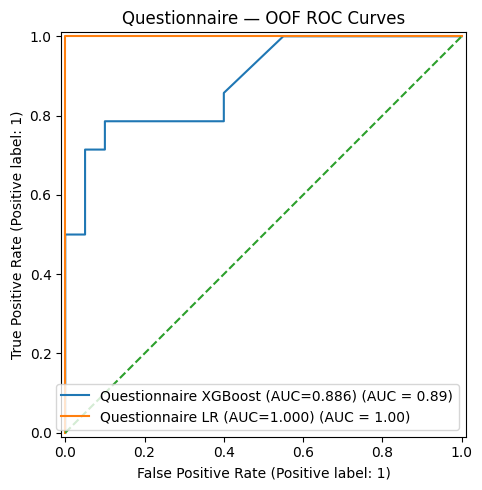

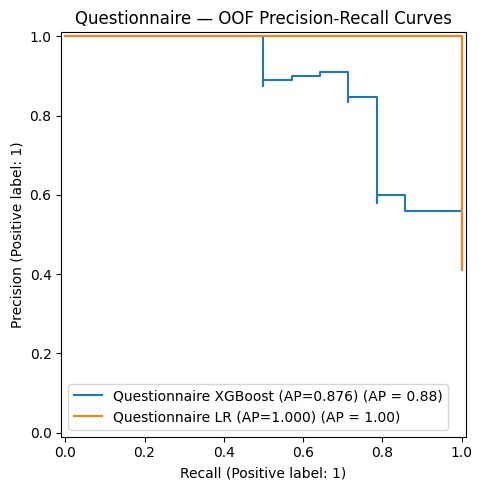

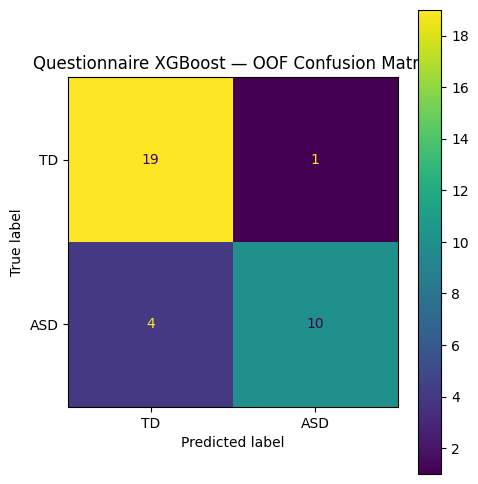

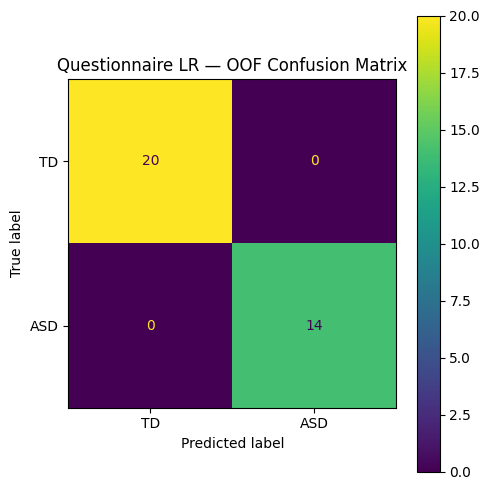


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_primary_and_baseline_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_xgb_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_lr_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_xgb_inner_tuning_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_lr_inner_tuning_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell16_questionnaire_misclassifications.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell16_questionnaire_performance_caution_flags.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures

In [ ]:
# ============================================================
# CELL 16 — QUESTIONNAIRE XGBOOST + LOGISTIC REGRESSION
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


print("=" * 78)
print("CELL 16 — QUESTIONNAIRE XGBOOST + LOGISTIC REGRESSION")
print("=" * 78)


# ============================================================
# 1. LOCK QUESTIONNAIRE INPUT
# ============================================================

X_questionnaire_model = np.asarray(
    X_questionnaire,
    dtype=np.float32
)


if X_questionnaire_model.shape != (
    N_FINAL,
    QUESTIONNAIRE_ITEM_COUNT
):

    raise RuntimeError(
        "Unexpected questionnaire matrix dimensions."
    )


if not np.isfinite(
    X_questionnaire_model
).all():

    raise RuntimeError(
        "Questionnaire matrix contains non-finite values."
    )


if not set(
    np.unique(
        X_questionnaire_model
    ).tolist()
).issubset(
    {
        1.0,
        2.0,
        3.0,
        4.0
    }
):

    raise RuntimeError(
        "Questionnaire values fall outside locked coding 1–4."
    )


print("\nQUESTIONNAIRE MODEL INPUT")

print(
    "Participants:",
    X_questionnaire_model.shape[0]
)

print(
    "Raw questionnaire items:",
    X_questionnaire_model.shape[1]
)

print(
    "Observed response values:",
    sorted(
        np.unique(
            X_questionnaire_model
        ).tolist()
    )
)

print(
    "Domain scores used:",
    False
)

print(
    "Reverse-scored composite used:",
    False
)

print(
    "Age included:",
    False
)

print(
    "Gender included:",
    False
)

print(
    "Drawing features included:",
    False
)


# ============================================================
# 2. STORAGE — XGBOOST PRIMARY
# ============================================================

questionnaire_xgb_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


questionnaire_xgb_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


questionnaire_xgb_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


questionnaire_xgb_fold_records = []

questionnaire_xgb_tuning_records = []

questionnaire_xgb_model_files = []


# ============================================================
# 3. STORAGE — LOGISTIC REGRESSION BASELINE
# ============================================================

questionnaire_lr_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


questionnaire_lr_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


questionnaire_lr_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


questionnaire_lr_fold_records = []

questionnaire_lr_tuning_records = []

questionnaire_lr_model_files = []


# ============================================================
# 4. LOCKED OUTER LOOP
# ============================================================

for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    OUTER_SPLITS,
    start=1
):

    print(
        "\n"
        +
        "-" * 72
    )

    print(
        f"QUESTIONNAIRE — OUTER FOLD "
        f"{outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "-" * 72
    )


    # --------------------------------------------------------
    # Strict split integrity
    # --------------------------------------------------------

    assert_disjoint_indices(
        outer_train_idx,
        outer_test_idx,
        context=(
            f"Questionnaire outer fold "
            f"{outer_fold_number}"
        )
    )


    if np.any(
        questionnaire_xgb_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "XGBoost outer-test participant "
            "predicted more than once."
        )


    if np.any(
        questionnaire_lr_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "LR outer-test participant "
            "predicted more than once."
        )


    X_outer_train = X_questionnaire_model[
        outer_train_idx
    ]

    y_outer_train = y[
        outer_train_idx
    ]


    X_outer_test = X_questionnaire_model[
        outer_test_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    inner_splits = INNER_SPLITS_BY_OUTER[
        outer_fold_number
    ]


    # ========================================================
    # 4A. PRIMARY XGBOOST
    # ========================================================

    print("\nXGBoost primary model")


    xgb_grid = tune_xgboost(

        X_outer_train,

        y_outer_train,

        inner_splits
    )


    best_xgb_model = (
        xgb_grid.best_estimator_
    )


    best_xgb_params = (
        xgb_grid.best_params_
    )


    best_xgb_inner_auc = float(
        xgb_grid.best_score_
    )


    print(
        "Selected parameters:",
        best_xgb_params
    )

    print(
        "Best inner mean ROC-AUC:",
        round(
            best_xgb_inner_auc,
            6
        )
    )


    # --------------------------------------------------------
    # Record full XGBoost tuning grid
    # --------------------------------------------------------

    xgb_cv_results = (
        xgb_grid.cv_results_
    )


    for candidate_index in range(
        len(
            xgb_cv_results[
                "params"
            ]
        )
    ):

        candidate_params = (
            xgb_cv_results[
                "params"
            ][
                candidate_index
            ]
        )


        questionnaire_xgb_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "n_estimators":
                int(
                    candidate_params[
                        "n_estimators"
                    ]
                ),

            "max_depth":
                int(
                    candidate_params[
                        "max_depth"
                    ]
                ),

            "learning_rate":
                float(
                    candidate_params[
                        "learning_rate"
                    ]
                ),

            "min_child_weight":
                float(
                    candidate_params[
                        "min_child_weight"
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    xgb_cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    xgb_cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    xgb_cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # --------------------------------------------------------
    # XGBoost outer-test prediction
    # --------------------------------------------------------

    xgb_outer_probability = (
        positive_class_probability(
            best_xgb_model,
            X_outer_test
        )
    )


    xgb_outer_prediction = (
        xgb_outer_probability
        >=
        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    questionnaire_xgb_oof_probability[
        outer_test_idx
    ] = xgb_outer_probability


    questionnaire_xgb_oof_prediction[
        outer_test_idx
    ] = xgb_outer_prediction


    questionnaire_xgb_oof_filled[
        outer_test_idx
    ] = True


    xgb_fold_metrics = (
        compute_binary_metrics(

            y_outer_test,

            xgb_outer_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )
    )


    print(
        "XGBoost outer-test ROC-AUC:",
        round(
            xgb_fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "XGBoost outer-test accuracy:",
        round(
            xgb_fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # --------------------------------------------------------
    # Save XGBoost fold model
    # --------------------------------------------------------

    xgb_model_file = (

        MODELS_DIR
        /
        (
            f"questionnaire_xgb_outer_fold_"
            f"{outer_fold_number}.joblib"
        )
    )


    dump(
        best_xgb_model,
        xgb_model_file
    )


    questionnaire_xgb_model_files.append(
        str(
            xgb_model_file
        )
    )


    questionnaire_xgb_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Best_Parameters":
            json.dumps(
                best_xgb_params,
                sort_keys=True
            ),

        "Best_Inner_ROC_AUC":
            best_xgb_inner_auc,

        "Outer_Test_Accuracy":
            xgb_fold_metrics[
                "Accuracy"
            ],

        "Outer_Test_Balanced_Accuracy":
            xgb_fold_metrics[
                "Balanced_Accuracy"
            ],

        "Outer_Test_Sensitivity":
            xgb_fold_metrics[
                "Sensitivity"
            ],

        "Outer_Test_Specificity":
            xgb_fold_metrics[
                "Specificity"
            ],

        "Outer_Test_ROC_AUC":
            xgb_fold_metrics[
                "ROC_AUC"
            ],

        "Outer_Test_PR_AUC":
            xgb_fold_metrics[
                "PR_AUC"
            ],

        "Model_File":
            str(
                xgb_model_file
            )
    })


    # ========================================================
    # 4B. LOGISTIC REGRESSION BASELINE
    # ========================================================

    print("\nLogistic Regression baseline")


    lr_grid = tune_logistic_regression(

        X_outer_train,

        y_outer_train,

        inner_splits
    )


    best_lr_model = (
        lr_grid.best_estimator_
    )


    best_lr_C = float(
        lr_grid.best_params_[
            "classifier__C"
        ]
    )


    best_lr_inner_auc = float(
        lr_grid.best_score_
    )


    print(
        "Selected C:",
        best_lr_C
    )

    print(
        "Best inner mean ROC-AUC:",
        round(
            best_lr_inner_auc,
            6
        )
    )


    # --------------------------------------------------------
    # Record LR tuning grid
    # --------------------------------------------------------

    lr_cv_results = (
        lr_grid.cv_results_
    )


    for candidate_index in range(
        len(
            lr_cv_results[
                "params"
            ]
        )
    ):

        questionnaire_lr_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "C":
                float(
                    lr_cv_results[
                        "param_classifier__C"
                    ][
                        candidate_index
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    lr_cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    lr_cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    lr_cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # --------------------------------------------------------
    # LR outer-test prediction
    # --------------------------------------------------------

    lr_outer_probability = (
        positive_class_probability(
            best_lr_model,
            X_outer_test
        )
    )


    lr_outer_prediction = (
        lr_outer_probability
        >=
        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    questionnaire_lr_oof_probability[
        outer_test_idx
    ] = lr_outer_probability


    questionnaire_lr_oof_prediction[
        outer_test_idx
    ] = lr_outer_prediction


    questionnaire_lr_oof_filled[
        outer_test_idx
    ] = True


    lr_fold_metrics = (
        compute_binary_metrics(

            y_outer_test,

            lr_outer_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )
    )


    print(
        "LR outer-test ROC-AUC:",
        round(
            lr_fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "LR outer-test accuracy:",
        round(
            lr_fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # --------------------------------------------------------
    # Save LR fold model
    # --------------------------------------------------------

    lr_model_file = (

        MODELS_DIR
        /
        (
            f"questionnaire_lr_outer_fold_"
            f"{outer_fold_number}.joblib"
        )
    )


    dump(
        best_lr_model,
        lr_model_file
    )


    questionnaire_lr_model_files.append(
        str(
            lr_model_file
        )
    )


    questionnaire_lr_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Selected_C":
            best_lr_C,

        "Best_Inner_ROC_AUC":
            best_lr_inner_auc,

        "Outer_Test_Accuracy":
            lr_fold_metrics[
                "Accuracy"
            ],

        "Outer_Test_Balanced_Accuracy":
            lr_fold_metrics[
                "Balanced_Accuracy"
            ],

        "Outer_Test_Sensitivity":
            lr_fold_metrics[
                "Sensitivity"
            ],

        "Outer_Test_Specificity":
            lr_fold_metrics[
                "Specificity"
            ],

        "Outer_Test_ROC_AUC":
            lr_fold_metrics[
                "ROC_AUC"
            ],

        "Outer_Test_PR_AUC":
            lr_fold_metrics[
                "PR_AUC"
            ],

        "Model_File":
            str(
                lr_model_file
            )
    })


# ============================================================
# 5. OOF COMPLETENESS AUDIT
# ============================================================

print("\n" + "-" * 72)
print("QUESTIONNAIRE OOF COMPLETENESS AUDIT")
print("-" * 72)


print(
    "XGBoost participants predicted:",
    int(
        questionnaire_xgb_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print(
    "LR participants predicted:",
    int(
        questionnaire_lr_oof_filled.sum()
    ),
    "/",
    N_FINAL
)


if not questionnaire_xgb_oof_filled.all():

    raise RuntimeError(
        "Incomplete questionnaire XGBoost OOF predictions."
    )


if not questionnaire_lr_oof_filled.all():

    raise RuntimeError(
        "Incomplete questionnaire LR OOF predictions."
    )


validate_oof_probabilities(
    questionnaire_xgb_oof_probability
)


validate_oof_probabilities(
    questionnaire_lr_oof_probability
)


if np.any(
    questionnaire_xgb_oof_prediction < 0
):

    raise RuntimeError(
        "Missing XGBoost binary predictions."
    )


if np.any(
    questionnaire_lr_oof_prediction < 0
):

    raise RuntimeError(
        "Missing LR binary predictions."
    )


print(
    "Exactly one held-out prediction per participant "
    "for both models: PASS"
)


# ============================================================
# 6. OVERALL OOF METRICS
# ============================================================

questionnaire_xgb_metrics = (
    compute_binary_metrics(

        y,

        questionnaire_xgb_oof_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )
)


questionnaire_lr_metrics = (
    compute_binary_metrics(

        y,

        questionnaire_lr_oof_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )
)


questionnaire_xgb_metrics_df = (
    metrics_to_dataframe(

        "Questionnaire XGBoost",

        questionnaire_xgb_metrics
    )
)


questionnaire_lr_metrics_df = (
    metrics_to_dataframe(

        "Questionnaire LR",

        questionnaire_lr_metrics
    )
)


questionnaire_combined_metrics_df = (
    pd.concat(

        [
            questionnaire_xgb_metrics_df,
            questionnaire_lr_metrics_df
        ],

        ignore_index=True
    )
)


print("\nQUESTIONNAIRE PRIMARY + BASELINE OOF PERFORMANCE")

display(
    questionnaire_combined_metrics_df.round(
        6
    )
)


# ============================================================
# 7. CONFUSION MATRICES
# ============================================================

questionnaire_xgb_cm = np.array([

    [
        questionnaire_xgb_metrics[
            "TN"
        ],
        questionnaire_xgb_metrics[
            "FP"
        ]
    ],

    [
        questionnaire_xgb_metrics[
            "FN"
        ],
        questionnaire_xgb_metrics[
            "TP"
        ]
    ]
])


questionnaire_lr_cm = np.array([

    [
        questionnaire_lr_metrics[
            "TN"
        ],
        questionnaire_lr_metrics[
            "FP"
        ]
    ],

    [
        questionnaire_lr_metrics[
            "FN"
        ],
        questionnaire_lr_metrics[
            "TP"
        ]
    ]
])


print("\nQUESTIONNAIRE XGBOOST CONFUSION MATRIX")

print(
    questionnaire_xgb_cm
)


print("\nQUESTIONNAIRE LR CONFUSION MATRIX")

print(
    questionnaire_lr_cm
)


# ============================================================
# 8. FOLD SUMMARIES
# ============================================================

questionnaire_xgb_fold_summary_df = (
    pd.DataFrame(
        questionnaire_xgb_fold_records
    )
)


questionnaire_lr_fold_summary_df = (
    pd.DataFrame(
        questionnaire_lr_fold_records
    )
)


questionnaire_xgb_tuning_df = (
    pd.DataFrame(
        questionnaire_xgb_tuning_records
    )
)


questionnaire_lr_tuning_df = (
    pd.DataFrame(
        questionnaire_lr_tuning_records
    )
)


print("\nQUESTIONNAIRE XGBOOST OUTER-FOLD SUMMARY")

display(

    questionnaire_xgb_fold_summary_df.drop(
        columns=[
            "Model_File"
        ]
    ).round(
        6
    )
)


print("\nQUESTIONNAIRE LR OUTER-FOLD SUMMARY")

display(

    questionnaire_lr_fold_summary_df.drop(
        columns=[
            "Model_File"
        ]
    ).round(
        6
    )
)


print("\nQUESTIONNAIRE LR SELECTED C VALUES")

print(
    questionnaire_lr_fold_summary_df[
        "Selected_C"
    ].tolist()
)


# ============================================================
# 9. PARTICIPANT-LEVEL OOF TABLE
# ============================================================

questionnaire_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_questionnaire_xgb_ASD":
        questionnaire_xgb_oof_probability,

    "Pred_questionnaire_xgb":
        questionnaire_xgb_oof_prediction,

    "P_questionnaire_lr_ASD":
        questionnaire_lr_oof_probability,

    "Pred_questionnaire_lr":
        questionnaire_lr_oof_prediction
})


questionnaire_oof_df[
    "XGB_Correct"
] = (

    questionnaire_oof_df[
        "Pred_questionnaire_xgb"
    ]

    ==

    questionnaire_oof_df[
        "y_true"
    ]
)


questionnaire_oof_df[
    "LR_Correct"
] = (

    questionnaire_oof_df[
        "Pred_questionnaire_lr"
    ]

    ==

    questionnaire_oof_df[
        "y_true"
    ]
)


print("\nQUESTIONNAIRE OOF PREDICTION PREVIEW")

display(
    questionnaire_oof_df.head(
        10
    ).round(
        6
    )
)


# ============================================================
# 10. MISCLASSIFICATION TABLES
# ============================================================

def build_questionnaire_error_table(
    prediction_df,
    prediction_column,
    probability_column,
    correct_column,
    model_label
):

    errors = prediction_df[
        ~prediction_df[
            correct_column
        ]
    ].copy()


    if len(
        errors
    ) == 0:

        return pd.DataFrame(
            columns=[
                "Model",
                "Participant_ID",
                "Group",
                "Outer_Fold",
                "Probability_ASD",
                "Predicted_Group",
                "Error_Type"
            ]
        )


    errors[
        "Error_Type"
    ] = np.where(

        (
            errors[
                "y_true"
            ] == 1
        )
        &
        (
            errors[
                prediction_column
            ] == 0
        ),

        "False Negative",

        "False Positive"
    )


    errors[
        "Predicted_Group"
    ] = np.where(

        errors[
            prediction_column
        ] == 1,

        "ASD",

        "TD"
    )


    result = pd.DataFrame({

        "Model":
            model_label,

        "Participant_ID":
            errors[
                "Participant_ID"
            ],

        "Group":
            errors[
                "Group"
            ],

        "Outer_Fold":
            errors[
                "Outer_Fold"
            ],

        "Probability_ASD":
            errors[
                probability_column
            ],

        "Predicted_Group":
            errors[
                "Predicted_Group"
            ],

        "Error_Type":
            errors[
                "Error_Type"
            ]
    })


    return result.reset_index(
        drop=True
    )


questionnaire_xgb_errors_df = (
    build_questionnaire_error_table(

        questionnaire_oof_df,

        prediction_column=
            "Pred_questionnaire_xgb",

        probability_column=
            "P_questionnaire_xgb_ASD",

        correct_column=
            "XGB_Correct",

        model_label=
            "Questionnaire XGBoost"
    )
)


questionnaire_lr_errors_df = (
    build_questionnaire_error_table(

        questionnaire_oof_df,

        prediction_column=
            "Pred_questionnaire_lr",

        probability_column=
            "P_questionnaire_lr_ASD",

        correct_column=
            "LR_Correct",

        model_label=
            "Questionnaire LR"
    )
)


questionnaire_errors_df = pd.concat(

    [
        questionnaire_xgb_errors_df,
        questionnaire_lr_errors_df
    ],

    ignore_index=True
)


print(
    "\nQUESTIONNAIRE XGBOOST MISCLASSIFIED PARTICIPANTS:",
    len(
        questionnaire_xgb_errors_df
    )
)


if len(
    questionnaire_xgb_errors_df
) > 0:

    display(
        questionnaire_xgb_errors_df.round(
            6
        )
    )


print(
    "\nQUESTIONNAIRE LR MISCLASSIFIED PARTICIPANTS:",
    len(
        questionnaire_lr_errors_df
    )
)


if len(
    questionnaire_lr_errors_df
) > 0:

    display(
        questionnaire_lr_errors_df.round(
            6
        )
    )


# ============================================================
# 11. PERFECT-PERFORMANCE CAUTION FLAG
# ============================================================

questionnaire_performance_flags = []


for (
    model_name,
    metric_dict
) in [

    (
        "Questionnaire XGBoost",
        questionnaire_xgb_metrics
    ),

    (
        "Questionnaire LR",
        questionnaire_lr_metrics
    )
]:

    perfect_discrimination = bool(

        metric_dict[
            "ROC_AUC"
        ] == 1.0

        and

        metric_dict[
            "Accuracy"
        ] == 1.0
    )


    if perfect_discrimination:

        interpretation = (
            "Perfect internal OOF performance detected. "
            "Do not interpret as clinical validity; retain "
            "for leakage audit, uncertainty analysis and "
            "external validation."
        )

    else:

        interpretation = (
            "No perfect internal OOF performance detected."
        )


    questionnaire_performance_flags.append({

        "Model":
            model_name,

        "Perfect_Accuracy_and_AUC":
            perfect_discrimination,

        "Interpretation":
            interpretation
    })


questionnaire_performance_flags_df = (
    pd.DataFrame(
        questionnaire_performance_flags
    )
)


print("\nQUESTIONNAIRE PERFORMANCE CAUTION FLAGS")

display(
    questionnaire_performance_flags_df
)


# ============================================================
# 12. COMBINED ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


RocCurveDisplay.from_predictions(

    y,

    questionnaire_xgb_oof_probability,

    name=(
        "Questionnaire XGBoost "
        f"(AUC="
        f"{questionnaire_xgb_metrics['ROC_AUC']:.3f})"
    ),

    ax=ax
)


RocCurveDisplay.from_predictions(

    y,

    questionnaire_lr_oof_probability,

    name=(
        "Questionnaire LR "
        f"(AUC="
        f"{questionnaire_lr_metrics['ROC_AUC']:.3f})"
    ),

    ax=ax
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


ax.set_title(
    "Questionnaire — OOF ROC Curves"
)


fig.tight_layout()


questionnaire_roc_file = (

    FIGURES_DIR
    /
    "cell16_questionnaire_oof_roc_curves.png"
)


fig.savefig(
    questionnaire_roc_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 13. COMBINED PRECISION-RECALL CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


PrecisionRecallDisplay.from_predictions(

    y,

    questionnaire_xgb_oof_probability,

    name=(
        "Questionnaire XGBoost "
        f"(AP="
        f"{questionnaire_xgb_metrics['PR_AUC']:.3f})"
    ),

    ax=ax
)


PrecisionRecallDisplay.from_predictions(

    y,

    questionnaire_lr_oof_probability,

    name=(
        "Questionnaire LR "
        f"(AP="
        f"{questionnaire_lr_metrics['PR_AUC']:.3f})"
    ),

    ax=ax
)


ax.set_title(
    "Questionnaire — OOF Precision-Recall Curves"
)


fig.tight_layout()


questionnaire_pr_file = (

    FIGURES_DIR
    /
    "cell16_questionnaire_oof_pr_curves.png"
)


fig.savefig(
    questionnaire_pr_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. XGBOOST CONFUSION MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        5,
        5
    )
)


xgb_cm_display = ConfusionMatrixDisplay(

    confusion_matrix=
        questionnaire_xgb_cm,

    display_labels=[
        "TD",
        "ASD"
    ]
)


xgb_cm_display.plot(
    ax=ax,
    values_format="d"
)


ax.set_title(
    "Questionnaire XGBoost — OOF Confusion Matrix"
)


fig.tight_layout()


questionnaire_xgb_cm_file = (

    FIGURES_DIR
    /
    "cell16_questionnaire_xgb_confusion_matrix.png"
)


fig.savefig(
    questionnaire_xgb_cm_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 15. LR CONFUSION MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        5,
        5
    )
)


lr_cm_display = ConfusionMatrixDisplay(

    confusion_matrix=
        questionnaire_lr_cm,

    display_labels=[
        "TD",
        "ASD"
    ]
)


lr_cm_display.plot(
    ax=ax,
    values_format="d"
)


ax.set_title(
    "Questionnaire LR — OOF Confusion Matrix"
)


fig.tight_layout()


questionnaire_lr_cm_file = (

    FIGURES_DIR
    /
    "cell16_questionnaire_lr_confusion_matrix.png"
)


fig.savefig(
    questionnaire_lr_cm_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. SAVE RESULT TABLES
# ============================================================

questionnaire_oof_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_oof_predictions.csv"
)


questionnaire_metrics_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_primary_and_baseline_metrics.csv"
)


questionnaire_xgb_fold_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_xgb_outer_fold_results.csv"
)


questionnaire_lr_fold_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_lr_outer_fold_results.csv"
)


questionnaire_xgb_tuning_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_xgb_inner_tuning_results.csv"
)


questionnaire_lr_tuning_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_lr_inner_tuning_results.csv"
)


questionnaire_errors_file = (
    RESULTS_DIR
    /
    "cell16_questionnaire_misclassifications.csv"
)


questionnaire_flags_file = (
    AUDIT_DIR
    /
    "cell16_questionnaire_performance_caution_flags.csv"
)


questionnaire_oof_df.to_csv(
    questionnaire_oof_file,
    index=False
)


questionnaire_combined_metrics_df.to_csv(
    questionnaire_metrics_file,
    index=False
)


questionnaire_xgb_fold_summary_df.to_csv(
    questionnaire_xgb_fold_file,
    index=False
)


questionnaire_lr_fold_summary_df.to_csv(
    questionnaire_lr_fold_file,
    index=False
)


questionnaire_xgb_tuning_df.to_csv(
    questionnaire_xgb_tuning_file,
    index=False
)


questionnaire_lr_tuning_df.to_csv(
    questionnaire_lr_tuning_file,
    index=False
)


questionnaire_errors_df.to_csv(
    questionnaire_errors_file,
    index=False
)


questionnaire_performance_flags_df.to_csv(
    questionnaire_flags_file,
    index=False
)


# ============================================================
# 17. QUESTIONNAIRE MODELING AUDIT
# ============================================================

questionnaire_modeling_audit_df = pd.DataFrame([

    {
        "Check":
            "Raw item representation",

        "Status":
            "PASS",

        "Details":
            "25 original response-coded items"
    },

    {
        "Check":
            "Questionnaire domains",

        "Status":
            "NOT USED",

        "Details":
            "No domain aggregation"
    },

    {
        "Check":
            "Manual reverse scoring",

        "Status":
            "NOT USED",

        "Details":
            "Models learn direction from raw 1–4 responses"
    },

    {
        "Check":
            "Questionnaire total score",

        "Status":
            "NOT USED",

        "Details":
            "No clinical composite scoring rule assumed"
    },

    {
        "Check":
            "Common outer folds",

        "Status":
            "PASS",

        "Details":
            f"{OUTER_FOLDS} locked outer folds"
    },

    {
        "Check":
            "XGBoost nested tuning",

        "Status":
            "PASS",

        "Details":
            (
                f"{INNER_FOLDS}-fold inner CV; "
                "ROC-AUC selection"
            )
    },

    {
        "Check":
            "LR nested tuning",

        "Status":
            "PASS",

        "Details":
            (
                f"{INNER_FOLDS}-fold inner CV; "
                "ROC-AUC selection"
            )
    },

    {
        "Check":
            "LR scaler leakage prevented",

        "Status":
            "PASS",

        "Details":
            "StandardScaler is inside the training pipeline"
    },

    {
        "Check":
            "Age predictor",

        "Status":
            "NOT USED",

        "Details":
            "Age remains metadata only"
    },

    {
        "Check":
            "Gender predictor",

        "Status":
            "NOT USED",

        "Details":
            "Gender remains metadata only"
    },

    {
        "Check":
            "Clinical questionnaire validation claim",

        "Status":
            "NOT MADE",

        "Details":
            (
                "Predictive discrimination is distinct from "
                "formal questionnaire validation"
            )
    }
])


questionnaire_modeling_audit_file = (
    AUDIT_DIR
    /
    "cell16_questionnaire_modeling_audit.csv"
)


questionnaire_modeling_audit_df.to_csv(
    questionnaire_modeling_audit_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    questionnaire_oof_file
)

print(
    questionnaire_metrics_file
)

print(
    questionnaire_xgb_fold_file
)

print(
    questionnaire_lr_fold_file
)

print(
    questionnaire_xgb_tuning_file
)

print(
    questionnaire_lr_tuning_file
)

print(
    questionnaire_errors_file
)

print(
    questionnaire_flags_file
)

print(
    questionnaire_roc_file
)

print(
    questionnaire_pr_file
)

print(
    questionnaire_xgb_cm_file
)

print(
    questionnaire_lr_cm_file
)

print(
    questionnaire_modeling_audit_file
)


# ============================================================
# 18. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("QUESTIONNAIRE FINAL OOF SUMMARY")


print("\nPRIMARY — XGBOOST")

print(
    "Accuracy:",
    round(
        questionnaire_xgb_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Balanced Accuracy:",
    round(
        questionnaire_xgb_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Sensitivity:",
    round(
        questionnaire_xgb_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        questionnaire_xgb_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "F1:",
    round(
        questionnaire_xgb_metrics[
            "F1"
        ],
        6
    )
)

print(
    "ROC-AUC:",
    round(
        questionnaire_xgb_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "PR-AUC:",
    round(
        questionnaire_xgb_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    questionnaire_xgb_cm
)


print("\nBASELINE — LOGISTIC REGRESSION")

print(
    "Accuracy:",
    round(
        questionnaire_lr_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Balanced Accuracy:",
    round(
        questionnaire_lr_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Sensitivity:",
    round(
        questionnaire_lr_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        questionnaire_lr_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "F1:",
    round(
        questionnaire_lr_metrics[
            "F1"
        ],
        6
    )
)

print(
    "ROC-AUC:",
    round(
        questionnaire_lr_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "PR-AUC:",
    round(
        questionnaire_lr_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    questionnaire_lr_cm
)


print(
    "\nXGBoost OOF participants:",
    int(
        questionnaire_xgb_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print(
    "LR OOF participants:",
    int(
        questionnaire_lr_oof_filled.sum()
    ),
    "/",
    N_FINAL
)


print("\nCELL 16 STATUS: PASS")
print("=" * 78)

# 17. Questionnaire Perfect-Performance and Leakage Diagnostic Audit

The pre-specified Logistic Regression questionnaire baseline achieved perfect
out-of-fold discrimination in the current internal cohort.

This result is retained rather than discarded, but it requires additional
diagnostic auditing before interpretation.

Perfect internal cross-validation performance does not establish clinical
validity and does not justify replacing the protocol-locked primary
questionnaire model.

This stage investigates whether the result can be explained by an obvious
data or modeling artifact.

The audit includes:

1. confirmation that only the 25 raw questionnaire items enter the model;
2. confirmation that participant ID, group label, age and gender are absent
   from the predictor matrix;
3. item-level ASD/TD separability;
4. identification of any single item that perfectly separates the groups;
5. Holm-adjusted descriptive item-level Mann-Whitney tests;
6. leave-one-item-out nested Logistic Regression;
7. examination of participant-number/group ordering as a possible collection
   batch confound;
8. a label-permutation diagnostic using the complete nested LR procedure.

The permutation analysis is a post-performance diagnostic rather than a new
primary hypothesis test. It asks whether similarly extreme nested-CV
performance commonly occurs after destroying the relationship between
questionnaire responses and ASD/TD labels.

The questionnaire XGBoost model remains the protocol-locked primary
questionnaire branch regardless of this audit.

The existing global OOF branch predictions are evaluation outputs only.
They will not be naively used as training inputs for the fusion classifier.
Fully nested fusion will regenerate training-side base-model probabilities
inside each outer fold to prevent stacking leakage.

CELL 17 — QUESTIONNAIRE PERFECT-PERFORMANCE + LEAKAGE AUDIT

OBSERVED QUESTIONNAIRE LR PERFORMANCE
OOF ROC-AUC: 1.0
OOF accuracy: 1.0

EXPLICIT FEATURE-CONTENT AUDIT
Questionnaire predictor count: 25
Predictor names: ['item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16', 'item_17', 'item_18', 'item_19', 'item_20', 'item_21', 'item_22', 'item_23', 'item_24', 'item_25']
Forbidden metadata/label predictors detected: []
Explicit questionnaire feature leakage: NOT DETECTED
Matrix exactly equals final cohort item_1..item_25: True

ITEM-LEVEL SEPARABILITY AUDIT


,Item,TD_Mean,ASD_Mean,TD_Median,ASD_Median,TD_Min,TD_Max,ASD_Min,ASD_Max,Raw_AUC,Direction_Independent_AUC,Perfect_Single_Item_Range_Separation,Shared_Response_Level_Count,Shared_Response_Levels,Mann_Whitney_U,Raw_P_Value,Rank_Biserial,Holm_Adjusted_P,Holm_Significant_0_05
0,item_23,3.55,1.714286,4.0,2.0,2.0,4.0,1.0,3.0,0.030357,0.969643,False,2,"2,3",8.5,0.000002,-0.939286,0.000045,True
1,item_25,3.35,1.642857,3.5,2.0,1.0,4.0,1.0,3.0,0.069643,0.930357,False,3,"1,2,3",19.5,0.000014,-0.860714,0.000324,True
2,item_17,1.50,3.214286,1.0,3.0,1.0,3.0,2.0,4.0,0.926786,0.926786,False,2,"2,3",259.5,0.000013,0.853571,0.000307,True
3,item_1,1.50,3.214286,1.0,3.0,1.0,3.0,1.0,4.0,0.919643,0.919643,False,3,"1,2,3",257.5,0.000021,0.839286,0.000452,True
4,item_7,1.55,3.214286,1.5,3.5,1.0,3.0,2.0,4.0,0.916071,0.916071,False,2,"2,3",256.5,0.000021,0.832143,0.000452,True
5,item_19,3.40,1.642857,3.5,1.0,1.0,4.0,1.0,3.0,0.083929,0.916071,False,2,"1,3",23.5,0.000021,-0.832143,0.000452,True
6,item_12,1.70,3.428571,2.0,4.0,1.0,3.0,1.0,4.0,0.903571,0.903571,False,3,"1,2,3",253.0,0.000046,0.807143,0.000870,True
7,item_18,1.65,3.214286,2.0,3.5,1.0,3.0,2.0,4.0,0.896429,0.896429,False,2,"2,3",251.0,0.000053,0.792857,0.000948,True
8,item_14,1.70,3.357143,1.5,4.0,1.0,4.0,2.0,4.0,0.894643,0.894643,False,3,"2,3,4",250.5,0.000065,0.789286,0.001098,True
9,item_2,3.00,1.571429,3.0,2.0,1.0,4.0,1.0,2.0,0.135714,0.864286,False,2,"1,2",38.0,0.000222,-0.728571,0.003555,True



Items with perfect single-item range separation: 0

PARTICIPANT-ID / GROUP ORDERING AUDIT


,Audit,Raw_AUC,Direction_Independent_AUC,Used_As_Model_Feature,Interpretation
0,Participant numeric ID vs ASD/TD,1.0,1.0,False,Participant ID was not used as a predictor. Hi...


ID/order flag: STRONG GROUP-BLOCKED ID ORDERING — NOT DIRECT MODEL LEAKAGE, BUT REPORT AS POTENTIAL COLLECTION/BATCH CONFOUND

LEAVE-ONE-ITEM-OUT NESTED LR AUDIT


,Removed_Item,Remaining_Features,OOF_Accuracy,OOF_Balanced_Accuracy,OOF_Sensitivity,OOF_Specificity,OOF_ROC_AUC,OOF_PR_AUC,AUC_Change_From_Full_LR,Selected_C_Values
0,item_1,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
1,item_2,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
2,item_3,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
3,item_4,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
4,item_5,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
5,item_6,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
6,item_7,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
7,item_8,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
8,item_9,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"
9,item_10,24,1.0,1.0,1.0,1.0,1.0,1.0,0.0,"0.001,0.001,0.001,0.001,0.001"



Lowest leave-one-item-out AUC: 1.0
Leave-one-item-out runs retaining perfect AUC: 25 / 25

NESTED LABEL-PERMUTATION DIAGNOSTIC
Permutation repetitions: 500
Observed nested OOF LR AUC: 1.0
Completed: 50 / 500
Completed: 100 / 500
Completed: 150 / 500
Completed: 200 / 500
Completed: 250 / 500
Completed: 300 / 500
Completed: 350 / 500
Completed: 400 / 500
Completed: 450 / 500
Completed: 500 / 500

PERMUTATION SUMMARY


,Observed_LR_OOF_AUC,Permutation_Repetitions,Null_AUC_Mean,Null_AUC_Std,Null_AUC_95th_Percentile,Null_AUC_99th_Percentile,Maximum_Null_AUC,Permutations_At_Least_Observed,Permutation_P_Value
0,1.0,500,0.5008,0.127458,0.70375,0.807143,0.828571,0,0.001996


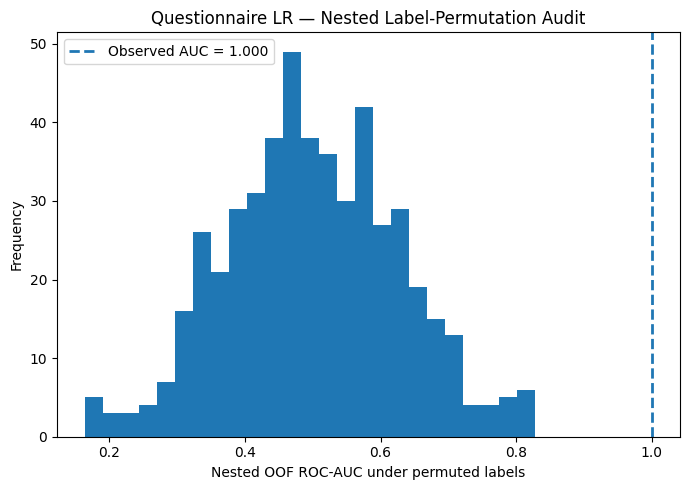


QUESTIONNAIRE LR COEFFICIENT STABILITY


,Item,Mean_Coefficient,Std_Coefficient,Positive_Folds,Negative_Folds,Same_Sign_All_5_Folds,Absolute_Mean_Coefficient
0,item_23,-0.009984,0.000238,0,5,True,0.009984
1,item_7,0.008995,0.000428,5,0,True,0.008995
2,item_1,0.008908,0.000859,5,0,True,0.008908
3,item_17,0.008898,0.000160,5,0,True,0.008898
4,item_25,-0.008844,0.000818,0,5,True,0.008844
5,item_18,0.008568,0.000354,5,0,True,0.008568
6,item_19,-0.008290,0.000657,0,5,True,0.008290
7,item_12,0.008095,0.000446,5,0,True,0.008095
8,item_14,0.007655,0.000752,5,0,True,0.007655
9,item_2,-0.007645,0.000639,0,5,True,0.007645


Items retaining same coefficient sign in all folds: 25 / 25

QUESTIONNAIRE LR DIAGNOSTIC INTERPRETATION


,Diagnostic,Result,Interpretation
0,Explicit prohibited predictor included,False,Only item_1 through item_25 are supplied to th...
1,Single item perfectly range-separates groups,False,0 item(s) have non-overlapping ASD/TD raw resp...
2,Perfect LR depends on one item,False,Lowest leave-one-item-out nested AUC = 1.0000.
3,Participant numbering strongly tracks group,True,STRONG GROUP-BLOCKED ID ORDERING — NOT DIRECT ...
4,Observed perfect AUC reproduced under permuted...,False,Conditional nested permutation p = 0.001996. T...
5,Independent external validation available,False,No independent external cohort is currently av...



LOCKED QUESTIONNAIRE / FUSION POLICY


,Policy,Value,Reason
0,Primary questionnaire model,XGBoost,Pre-specified primary questionnaire model; not...
1,Questionnaire LR status,Baseline / sensitivity model only,Perfect internal performance does not justify ...
2,Questionnaire input to primary fusion,XGBoost branch probability,Maintains the protocol-locked primary question...
3,Use global branch OOF vectors directly to trai...,False,Would contaminate meta-training because an out...



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_item_separability.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_leave_one_item_out.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_permutation_auc_values.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_permutation_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_outer_fold_coefficients.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_coefficient_stability.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_questionnaire_lr_diagnostic_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell17_participant_id_group_order_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell17

In [ ]:
# ============================================================
# CELL 17 — QUESTIONNAIRE PERFECT-PERFORMANCE + LEAKAGE AUDIT
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold


print("=" * 78)
print("CELL 17 — QUESTIONNAIRE PERFECT-PERFORMANCE + LEAKAGE AUDIT")
print("=" * 78)


# ============================================================
# 1. LOCK AUDIT INPUT
# ============================================================

X_q_audit = np.asarray(
    X_questionnaire,
    dtype=np.float32
)


y_q_audit = np.asarray(
    y,
    dtype=int
)


if X_q_audit.shape != (
    N_FINAL,
    25
):

    raise RuntimeError(
        "Questionnaire audit matrix must contain "
        "exactly the 25 raw questionnaire items."
    )


if not np.isfinite(
    X_q_audit
).all():

    raise RuntimeError(
        "Questionnaire audit matrix contains "
        "non-finite values."
    )


observed_lr_auc = float(
    questionnaire_lr_metrics[
        "ROC_AUC"
    ]
)


observed_lr_accuracy = float(
    questionnaire_lr_metrics[
        "Accuracy"
    ]
)


print("\nOBSERVED QUESTIONNAIRE LR PERFORMANCE")

print(
    "OOF ROC-AUC:",
    observed_lr_auc
)

print(
    "OOF accuracy:",
    observed_lr_accuracy
)


# ============================================================
# 2. EXPLICIT FEATURE-CONTENT AUDIT
# ============================================================

questionnaire_feature_names = list(
    ITEM_COLS
)


forbidden_feature_names = {

    "participantid",
    "participant",
    "group",
    "label",
    "target",
    "y",
    "age",
    "gender",
    "sex"
}


normalized_questionnaire_feature_names = [

    re.sub(
        r"[^a-z0-9]",
        "",
        str(name).lower()
    )

    for name
    in questionnaire_feature_names
]


forbidden_detected = [

    original_name

    for original_name, normalized_name
    in zip(
        questionnaire_feature_names,
        normalized_questionnaire_feature_names
    )

    if normalized_name
    in forbidden_feature_names
]


print("\nEXPLICIT FEATURE-CONTENT AUDIT")

print(
    "Questionnaire predictor count:",
    len(
        questionnaire_feature_names
    )
)

print(
    "Predictor names:",
    questionnaire_feature_names
)

print(
    "Forbidden metadata/label predictors detected:",
    forbidden_detected
)


if forbidden_detected:

    raise RuntimeError(
        "Forbidden metadata or label fields were found "
        "in the questionnaire predictor list."
    )


print(
    "Explicit questionnaire feature leakage: NOT DETECTED"
)


# ============================================================
# 3. VERIFY MATRIX AGAINST FINAL COHORT ITEMS
# ============================================================

expected_questionnaire_matrix = (

    final_cohort_df[
        ITEM_COLS
    ]

    .to_numpy(
        dtype=np.float32
    )
)


exact_questionnaire_matrix_match = bool(

    np.array_equal(
        expected_questionnaire_matrix,
        X_q_audit
    )
)


print(
    "Matrix exactly equals final cohort item_1..item_25:",
    exact_questionnaire_matrix_match
)


if not exact_questionnaire_matrix_match:

    raise RuntimeError(
        "Questionnaire matrix does not exactly match "
        "the 25 raw item columns."
    )


# ============================================================
# 4. HOLM MULTIPLICITY-CORRECTION FUNCTION
# ============================================================

def holm_adjust_pvalues(
    pvalues
):

    pvalues = np.asarray(
        pvalues,
        dtype=float
    )


    m = len(
        pvalues
    )


    order = np.argsort(
        pvalues
    )


    adjusted = np.empty(
        m,
        dtype=float
    )


    previous = 0.0


    for rank, original_index in enumerate(
        order
    ):

        multiplier = (
            m
            -
            rank
        )


        candidate = (
            multiplier
            *
            pvalues[
                original_index
            ]
        )


        candidate = max(
            candidate,
            previous
        )


        candidate = min(
            candidate,
            1.0
        )


        adjusted[
            original_index
        ] = candidate


        previous = candidate


    return adjusted


# ============================================================
# 5. ITEM-LEVEL SEPARABILITY AUDIT
# ============================================================

item_audit_records = []


for item_index, item_name in enumerate(
    ITEM_COLS
):

    values = X_q_audit[
        :,
        item_index
    ]


    td_values = values[
        y_q_audit == 0
    ]


    asd_values = values[
        y_q_audit == 1
    ]


    raw_auc = float(
        roc_auc_score(
            y_q_audit,
            values
        )
    )


    direction_independent_auc = float(
        max(
            raw_auc,
            1.0 - raw_auc
        )
    )


    asd_above_td = bool(

        np.min(
            asd_values
        )

        >

        np.max(
            td_values
        )
    )


    td_above_asd = bool(

        np.min(
            td_values
        )

        >

        np.max(
            asd_values
        )
    )


    perfect_range_separation = bool(
        asd_above_td
        or
        td_above_asd
    )


    shared_response_levels = sorted(

        set(
            td_values.tolist()
        )

        &

        set(
            asd_values.tolist()
        )
    )


    mw_result = mannwhitneyu(

        asd_values,

        td_values,

        alternative="two-sided"
    )


    U = float(
        mw_result.statistic
    )


    p_value = float(
        mw_result.pvalue
    )


    # Rank-biserial-style direction:
    # positive means larger raw response values in ASD.
    rank_biserial = float(

        (
            2.0
            *
            U
        )

        /

        (
            len(
                asd_values
            )
            *
            len(
                td_values
            )
        )

        -

        1.0
    )


    item_audit_records.append({

        "Item":
            item_name,

        "TD_Mean":
            float(
                np.mean(
                    td_values
                )
            ),

        "ASD_Mean":
            float(
                np.mean(
                    asd_values
                )
            ),

        "TD_Median":
            float(
                np.median(
                    td_values
                )
            ),

        "ASD_Median":
            float(
                np.median(
                    asd_values
                )
            ),

        "TD_Min":
            float(
                np.min(
                    td_values
                )
            ),

        "TD_Max":
            float(
                np.max(
                    td_values
                )
            ),

        "ASD_Min":
            float(
                np.min(
                    asd_values
                )
            ),

        "ASD_Max":
            float(
                np.max(
                    asd_values
                )
            ),

        "Raw_AUC":
            raw_auc,

        "Direction_Independent_AUC":
            direction_independent_auc,

        "Perfect_Single_Item_Range_Separation":
            perfect_range_separation,

        "Shared_Response_Level_Count":
            len(
                shared_response_levels
            ),

        "Shared_Response_Levels":
            ",".join(
                [
                    str(
                        int(
                            value
                        )
                    )
                    for value
                    in shared_response_levels
                ]
            ),

        "Mann_Whitney_U":
            U,

        "Raw_P_Value":
            p_value,

        "Rank_Biserial":
            rank_biserial
    })


questionnaire_item_separation_df = pd.DataFrame(
    item_audit_records
)


questionnaire_item_separation_df[
    "Holm_Adjusted_P"
] = holm_adjust_pvalues(

    questionnaire_item_separation_df[
        "Raw_P_Value"
    ].to_numpy()
)


questionnaire_item_separation_df[
    "Holm_Significant_0_05"
] = (

    questionnaire_item_separation_df[
        "Holm_Adjusted_P"
    ]

    <
    0.05
)


questionnaire_item_separation_df = (

    questionnaire_item_separation_df

    .sort_values(

        "Direction_Independent_AUC",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\nITEM-LEVEL SEPARABILITY AUDIT")

display(
    questionnaire_item_separation_df.round(
        6
    )
)


perfect_single_item_df = (

    questionnaire_item_separation_df[
        questionnaire_item_separation_df[
            "Perfect_Single_Item_Range_Separation"
        ]
    ]

    .copy()
)


print(
    "\nItems with perfect single-item range separation:",
    len(
        perfect_single_item_df
    )
)


if len(
    perfect_single_item_df
) > 0:

    display(
        perfect_single_item_df[
            [
                "Item",
                "TD_Min",
                "TD_Max",
                "ASD_Min",
                "ASD_Max",
                "Direction_Independent_AUC"
            ]
        ]
    )


# ============================================================
# 6. PARTICIPANT-ID / GROUP ORDERING AUDIT
#
# IDs are NOT model inputs.
# This checks whether numbering itself encodes recruitment group.
# ============================================================

def participant_numeric_component(
    participant_id
):

    match = re.search(
        r"(\d+)",
        str(
            participant_id
        )
    )


    if match is None:

        return np.nan


    return int(
        match.group(1)
    )


participant_numeric_id = np.asarray(
    [
        participant_numeric_component(
            participant_id
        )

        for participant_id
        in cohort_ids
    ],
    dtype=float
)


id_raw_auc = float(
    roc_auc_score(
        y,
        participant_numeric_id
    )
)


id_direction_independent_auc = float(
    max(
        id_raw_auc,
        1.0 - id_raw_auc
    )
)


id_group_audit_df = pd.DataFrame([

    {
        "Audit":
            "Participant numeric ID vs ASD/TD",

        "Raw_AUC":
            id_raw_auc,

        "Direction_Independent_AUC":
            id_direction_independent_auc,

        "Used_As_Model_Feature":
            False,

        "Interpretation":
            (
                "Participant ID was not used as a predictor. "
                "High ID/group separation would nevertheless "
                "indicate group-blocked recruitment/order and "
                "a possible unmeasured batch-confounding risk."
            )
    }
])


print("\nPARTICIPANT-ID / GROUP ORDERING AUDIT")

display(
    id_group_audit_df.round(
        6
    )
)


if id_direction_independent_auc >= 0.95:

    ID_BATCH_CONFOUND_FLAG = (
        "STRONG GROUP-BLOCKED ID ORDERING — "
        "NOT DIRECT MODEL LEAKAGE, BUT REPORT AS "
        "POTENTIAL COLLECTION/BATCH CONFOUND"
    )

else:

    ID_BATCH_CONFOUND_FLAG = (
        "NO STRONG GROUP-BLOCKED ID ORDERING DETECTED"
    )


print(
    "ID/order flag:",
    ID_BATCH_CONFOUND_FLAG
)


# ============================================================
# 7. GENERIC NESTED LR OOF FUNCTION
#
# Used for diagnostic robustness analyses only.
# ============================================================

def nested_lr_oof(
    X_matrix,
    labels,
    outer_splits,
    inner_splits_by_outer=None,
    dynamic_inner_seed_base=None
):

    X_matrix = np.asarray(
        X_matrix,
        dtype=np.float32
    )


    labels = np.asarray(
        labels,
        dtype=int
    )


    probabilities = np.full(
        len(
            labels
        ),
        np.nan,
        dtype=float
    )


    selected_C_values = []


    for outer_fold_number, (
        outer_train_idx,
        outer_test_idx
    ) in enumerate(

        outer_splits,

        start=1
    ):

        X_train = X_matrix[
            outer_train_idx
        ]

        y_train = labels[
            outer_train_idx
        ]


        X_test = X_matrix[
            outer_test_idx
        ]


        if inner_splits_by_outer is not None:

            inner_splits = (
                inner_splits_by_outer[
                    outer_fold_number
                ]
            )

        else:

            inner_cv = StratifiedKFold(

                n_splits=INNER_FOLDS,

                shuffle=True,

                random_state=(
                    dynamic_inner_seed_base
                    +
                    outer_fold_number
                )
            )


            inner_splits = list(

                inner_cv.split(

                    np.zeros(
                        len(
                            y_train
                        )
                    ),

                    y_train
                )
            )


        grid = tune_logistic_regression(

            X_train,

            y_train,

            inner_splits
        )


        probabilities[
            outer_test_idx
        ] = positive_class_probability(

            grid.best_estimator_,

            X_test
        )


        selected_C_values.append(

            float(
                grid.best_params_[
                    "classifier__C"
                ]
            )
        )


    validate_oof_probabilities(

        probabilities,

        expected_n=len(
            labels
        )
    )


    return (
        probabilities,
        selected_C_values
    )


# ============================================================
# 8. LEAVE-ONE-ITEM-OUT NESTED LR AUDIT
#
# Determines whether perfect performance depends on one item.
# ============================================================

print("\nLEAVE-ONE-ITEM-OUT NESTED LR AUDIT")

leave_one_item_out_records = []


for item_index, removed_item in enumerate(
    ITEM_COLS
):

    X_without_item = np.delete(

        X_q_audit,

        item_index,

        axis=1
    )


    (
        loo_probability,
        loo_C_values
    ) = nested_lr_oof(

        X_matrix=
            X_without_item,

        labels=
            y,

        outer_splits=
            OUTER_SPLITS,

        inner_splits_by_outer=
            INNER_SPLITS_BY_OUTER
    )


    loo_metrics = compute_binary_metrics(

        y,

        loo_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    leave_one_item_out_records.append({

        "Removed_Item":
            removed_item,

        "Remaining_Features":
            X_without_item.shape[1],

        "OOF_Accuracy":
            loo_metrics[
                "Accuracy"
            ],

        "OOF_Balanced_Accuracy":
            loo_metrics[
                "Balanced_Accuracy"
            ],

        "OOF_Sensitivity":
            loo_metrics[
                "Sensitivity"
            ],

        "OOF_Specificity":
            loo_metrics[
                "Specificity"
            ],

        "OOF_ROC_AUC":
            loo_metrics[
                "ROC_AUC"
            ],

        "OOF_PR_AUC":
            loo_metrics[
                "PR_AUC"
            ],

        "AUC_Change_From_Full_LR":
            (
                loo_metrics[
                    "ROC_AUC"
                ]
                -
                observed_lr_auc
            ),

        "Selected_C_Values":
            ",".join(
                [
                    str(
                        value
                    )
                    for value
                    in loo_C_values
                ]
            )
    })


leave_one_item_out_df = pd.DataFrame(
    leave_one_item_out_records
)


leave_one_item_out_df = (

    leave_one_item_out_df

    .sort_values(
        "OOF_ROC_AUC",
        ascending=True
    )

    .reset_index(
        drop=True
    )
)


display(
    leave_one_item_out_df.round(
        6
    )
)


print(
    "\nLowest leave-one-item-out AUC:",
    round(
        float(
            leave_one_item_out_df[
                "OOF_ROC_AUC"
            ].min()
        ),
        6
    )
)


print(
    "Leave-one-item-out runs retaining perfect AUC:",
    int(
        (
            leave_one_item_out_df[
                "OOF_ROC_AUC"
            ]
            ==
            1.0
        ).sum()
    ),
    "/",
    len(
        ITEM_COLS
    )
)


# ============================================================
# 9. CONDITIONAL NESTED LABEL-PERMUTATION DIAGNOSTIC
#
# Outer fold membership is kept fixed.
# Within each locked outer-test fold, class labels are shuffled.
# This preserves each fold's ASD/TD count while destroying the
# questionnaire-label relationship.
#
# Inner folds are regenerated for each permuted label set.
# ============================================================

QUESTIONNAIRE_LR_PERMUTATION_REPS = 500

PERMUTATION_SEED = (
    SEED
    +
    17000
)


permutation_rng = np.random.default_rng(
    PERMUTATION_SEED
)


permutation_auc_values = np.empty(
    QUESTIONNAIRE_LR_PERMUTATION_REPS,
    dtype=float
)


print("\nNESTED LABEL-PERMUTATION DIAGNOSTIC")

print(
    "Permutation repetitions:",
    QUESTIONNAIRE_LR_PERMUTATION_REPS
)

print(
    "Observed nested OOF LR AUC:",
    observed_lr_auc
)


for permutation_index in range(
    QUESTIONNAIRE_LR_PERMUTATION_REPS
):

    y_permuted = y.copy()


    # Preserve the exact class composition of every locked
    # outer test fold while breaking label-feature association.
    for fold_number in range(
        1,
        OUTER_FOLDS + 1
    ):

        fold_indices = np.where(
            outer_test_assignment
            ==
            fold_number
        )[0]


        y_permuted[
            fold_indices
        ] = permutation_rng.permutation(

            y_permuted[
                fold_indices
            ]
        )


    permuted_probability, _ = nested_lr_oof(

        X_matrix=
            X_q_audit,

        labels=
            y_permuted,

        outer_splits=
            OUTER_SPLITS,

        inner_splits_by_outer=
            None,

        dynamic_inner_seed_base=(
            PERMUTATION_SEED
            +
            (
                permutation_index
                *
                100
            )
        )
    )


    permutation_auc_values[
        permutation_index
    ] = roc_auc_score(

        y_permuted,

        permuted_probability
    )


    if (
        (
            permutation_index
            +
            1
        )
        %
        50
        ==
        0
    ):

        print(
            "Completed:",
            permutation_index + 1,
            "/",
            QUESTIONNAIRE_LR_PERMUTATION_REPS
        )


permutation_p_value = float(

    (
        1

        +

        np.sum(
            permutation_auc_values
            >=
            (
                observed_lr_auc
                -
                1e-12
            )
        )
    )

    /

    (
        QUESTIONNAIRE_LR_PERMUTATION_REPS
        +
        1
    )
)


permutation_summary_df = pd.DataFrame([

    {
        "Observed_LR_OOF_AUC":
            observed_lr_auc,

        "Permutation_Repetitions":
            QUESTIONNAIRE_LR_PERMUTATION_REPS,

        "Null_AUC_Mean":
            float(
                np.mean(
                    permutation_auc_values
                )
            ),

        "Null_AUC_Std":
            float(
                np.std(
                    permutation_auc_values,
                    ddof=1
                )
            ),

        "Null_AUC_95th_Percentile":
            float(
                np.quantile(
                    permutation_auc_values,
                    0.95
                )
            ),

        "Null_AUC_99th_Percentile":
            float(
                np.quantile(
                    permutation_auc_values,
                    0.99
                )
            ),

        "Maximum_Null_AUC":
            float(
                np.max(
                    permutation_auc_values
                )
            ),

        "Permutations_At_Least_Observed":
            int(
                np.sum(
                    permutation_auc_values
                    >=
                    (
                        observed_lr_auc
                        -
                        1e-12
                    )
                )
            ),

        "Permutation_P_Value":
            permutation_p_value
    }
])


print("\nPERMUTATION SUMMARY")

display(
    permutation_summary_df.round(
        6
    )
)


# ============================================================
# 10. PERMUTATION DISTRIBUTION FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5
    )
)


ax.hist(
    permutation_auc_values,
    bins=25
)


ax.axvline(
    observed_lr_auc,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed AUC = "
        f"{observed_lr_auc:.3f}"
    )
)


ax.set_xlabel(
    "Nested OOF ROC-AUC under permuted labels"
)

ax.set_ylabel(
    "Frequency"
)

ax.set_title(
    "Questionnaire LR — Nested Label-Permutation Audit"
)

ax.legend()


fig.tight_layout()


questionnaire_permutation_figure = (

    FIGURES_DIR
    /
    "cell17_questionnaire_lr_permutation_audit.png"
)


fig.savefig(
    questionnaire_permutation_figure,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. OUTER-FOLD MODEL COEFFICIENT STABILITY
#
# Diagnostic only. Does not change primary modeling.
# ============================================================

from joblib import load


coefficient_records = []


for fold_number, model_file in enumerate(

    questionnaire_lr_model_files,

    start=1
):

    fitted_pipeline = load(
        model_file
    )


    scaler = fitted_pipeline.named_steps[
        "scaler"
    ]


    classifier = fitted_pipeline.named_steps[
        "classifier"
    ]


    scaled_coefficients = (
        classifier.coef_[0]
    )


    # Convert coefficients approximately to original-item
    # scale for cross-fold comparison.
    original_scale_coefficients = (

        scaled_coefficients

        /

        scaler.scale_
    )


    for item_name, coefficient in zip(

        ITEM_COLS,

        original_scale_coefficients
    ):

        coefficient_records.append({

            "Outer_Fold":
                fold_number,

            "Item":
                item_name,

            "Original_Scale_Coefficient":
                float(
                    coefficient
                ),

            "Sign":
                int(
                    np.sign(
                        coefficient
                    )
                )
        })


questionnaire_lr_coefficient_df = pd.DataFrame(
    coefficient_records
)


coefficient_stability_df = (

    questionnaire_lr_coefficient_df

    .groupby(
        "Item"
    )

    .agg(

        Mean_Coefficient=(
            "Original_Scale_Coefficient",
            "mean"
        ),

        Std_Coefficient=(
            "Original_Scale_Coefficient",
            "std"
        ),

        Positive_Folds=(
            "Sign",
            lambda x:
                int(
                    np.sum(
                        np.asarray(x)
                        >
                        0
                    )
                )
        ),

        Negative_Folds=(
            "Sign",
            lambda x:
                int(
                    np.sum(
                        np.asarray(x)
                        <
                        0
                    )
                )
        )
    )

    .reset_index()
)


coefficient_stability_df[
    "Same_Sign_All_5_Folds"
] = (

    (
        coefficient_stability_df[
            "Positive_Folds"
        ]
        ==
        5
    )

    |

    (
        coefficient_stability_df[
            "Negative_Folds"
        ]
        ==
        5
    )
)


coefficient_stability_df[
    "Absolute_Mean_Coefficient"
] = np.abs(

    coefficient_stability_df[
        "Mean_Coefficient"
    ]
)


coefficient_stability_df = (

    coefficient_stability_df

    .sort_values(
        "Absolute_Mean_Coefficient",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\nQUESTIONNAIRE LR COEFFICIENT STABILITY")

display(
    coefficient_stability_df.round(
        6
    )
)


print(
    "Items retaining same coefficient sign in all folds:",
    int(
        coefficient_stability_df[
            "Same_Sign_All_5_Folds"
        ].sum()
    ),
    "/",
    len(
        ITEM_COLS
    )
)


# ============================================================
# 12. FINAL DIAGNOSTIC INTERPRETATION MATRIX
# ============================================================

single_item_perfect_count = int(
    len(
        perfect_single_item_df
    )
)


loo_min_auc = float(
    leave_one_item_out_df[
        "OOF_ROC_AUC"
    ].min()
)


questionnaire_lr_diagnostic_df = pd.DataFrame([

    {
        "Diagnostic":
            "Explicit prohibited predictor included",

        "Result":
            False,

        "Interpretation":
            (
                "Only item_1 through item_25 are supplied "
                "to the questionnaire models."
            )
    },

    {
        "Diagnostic":
            "Single item perfectly range-separates groups",

        "Result":
            bool(
                single_item_perfect_count > 0
            ),

        "Interpretation":
            (
                f"{single_item_perfect_count} item(s) have "
                "non-overlapping ASD/TD raw response ranges."
            )
    },

    {
        "Diagnostic":
            "Perfect LR depends on one item",

        "Result":
            bool(
                loo_min_auc < 0.95
            ),

        "Interpretation":
            (
                f"Lowest leave-one-item-out nested AUC = "
                f"{loo_min_auc:.4f}."
            )
    },

    {
        "Diagnostic":
            "Participant numbering strongly tracks group",

        "Result":
            bool(
                id_direction_independent_auc
                >=
                0.95
            ),

        "Interpretation":
            ID_BATCH_CONFOUND_FLAG
    },

    {
        "Diagnostic":
            "Observed perfect AUC reproduced under permuted labels",

        "Result":
            bool(
                np.any(
                    permutation_auc_values
                    >=
                    (
                        observed_lr_auc
                        -
                        1e-12
                    )
                )
            ),

        "Interpretation":
            (
                f"Conditional nested permutation p = "
                f"{permutation_p_value:.6f}. "
                "This assesses non-random association, "
                "not clinical validity."
            )
    },

    {
        "Diagnostic":
            "Independent external validation available",

        "Result":
            False,

        "Interpretation":
            (
                "No independent external cohort is currently "
                "available; perfect internal LR performance "
                "must therefore remain provisional."
            )
    }
])


print("\nQUESTIONNAIRE LR DIAGNOSTIC INTERPRETATION")

display(
    questionnaire_lr_diagnostic_df
)


# ============================================================
# 13. LOCK QUESTIONNAIRE/FUSION POLICY
# ============================================================

FUSION_QUESTIONNAIRE_PRIMARY_MODEL = (
    "XGBoost"
)


USE_QUESTIONNAIRE_LR_IN_PRIMARY_FUSION = False


fusion_questionnaire_policy_df = pd.DataFrame([

    {
        "Policy":
            "Primary questionnaire model",

        "Value":
            "XGBoost",

        "Reason":
            (
                "Pre-specified primary questionnaire model; "
                "not changed after observing results."
            )
    },

    {
        "Policy":
            "Questionnaire LR status",

        "Value":
            "Baseline / sensitivity model only",

        "Reason":
            (
                "Perfect internal performance does not justify "
                "post-hoc promotion to primary model."
            )
    },

    {
        "Policy":
            "Questionnaire input to primary fusion",

        "Value":
            "XGBoost branch probability",

        "Reason":
            (
                "Maintains the protocol-locked primary "
                "questionnaire definition."
            )
    },

    {
        "Policy":
            "Use global branch OOF vectors directly to train fusion",

        "Value":
            False,

        "Reason":
            (
                "Would contaminate meta-training because an "
                "outer-training participant's global OOF prediction "
                "may come from a base model trained using the current "
                "outer-test participants. Fully nested stacking must "
                "regenerate training-side probabilities inside each "
                "outer fold."
            )
    }
])


print("\nLOCKED QUESTIONNAIRE / FUSION POLICY")

display(
    fusion_questionnaire_policy_df
)


# ============================================================
# 14. SAVE AUDIT OUTPUTS
# ============================================================

item_separation_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_item_separability.csv"
)


leave_one_item_out_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_leave_one_item_out.csv"
)


permutation_values_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_permutation_auc_values.csv"
)


permutation_summary_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_permutation_summary.csv"
)


coefficient_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_outer_fold_coefficients.csv"
)


coefficient_stability_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_coefficient_stability.csv"
)


diagnostic_file = (
    AUDIT_DIR
    /
    "cell17_questionnaire_lr_diagnostic_summary.csv"
)


id_group_audit_file = (
    AUDIT_DIR
    /
    "cell17_participant_id_group_order_audit.csv"
)


fusion_questionnaire_policy_file = (
    MANIFEST_DIR
    /
    "cell17_questionnaire_fusion_policy.csv"
)


questionnaire_item_separation_df.to_csv(
    item_separation_file,
    index=False
)


leave_one_item_out_df.to_csv(
    leave_one_item_out_file,
    index=False
)


pd.DataFrame({

    "Permutation_Index":
        np.arange(
            1,
            QUESTIONNAIRE_LR_PERMUTATION_REPS + 1
        ),

    "Nested_OOF_AUC":
        permutation_auc_values

}).to_csv(
    permutation_values_file,
    index=False
)


permutation_summary_df.to_csv(
    permutation_summary_file,
    index=False
)


questionnaire_lr_coefficient_df.to_csv(
    coefficient_file,
    index=False
)


coefficient_stability_df.to_csv(
    coefficient_stability_file,
    index=False
)


questionnaire_lr_diagnostic_df.to_csv(
    diagnostic_file,
    index=False
)


id_group_audit_df.to_csv(
    id_group_audit_file,
    index=False
)


fusion_questionnaire_policy_df.to_csv(
    fusion_questionnaire_policy_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    item_separation_file
)

print(
    leave_one_item_out_file
)

print(
    permutation_values_file
)

print(
    permutation_summary_file
)

print(
    coefficient_file
)

print(
    coefficient_stability_file
)

print(
    diagnostic_file
)

print(
    id_group_audit_file
)

print(
    fusion_questionnaire_policy_file
)

print(
    questionnaire_permutation_figure
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("QUESTIONNAIRE PERFECT-PERFORMANCE AUDIT SUMMARY")

print(
    "Explicit prohibited predictor leakage:",
    False
)

print(
    "Perfect single-item separators:",
    single_item_perfect_count
)

print(
    "Lowest leave-one-item-out nested AUC:",
    round(
        loo_min_auc,
        6
    )
)

print(
    "Participant-ID direction-independent AUC:",
    round(
        id_direction_independent_auc,
        6
    )
)

print(
    "Nested permutation p-value:",
    round(
        permutation_p_value,
        6
    )
)

print(
    "Primary questionnaire model remains:",
    FUSION_QUESTIONNAIRE_PRIMARY_MODEL
)

print(
    "Questionnaire LR used in primary fusion:",
    USE_QUESTIONNAIRE_LR_IN_PRIMARY_FUSION
)

print(
    "Direct use of global OOF branch predictions "
    "for fusion training:",
    False
)

print("\nCELL 17 STATUS: PASS")
print("=" * 78)

# 18. Fully Nested Late Fusion with Training-Only Platt Calibration

The primary multimodal model performs participant-level late fusion of four
branch probabilities:

1. Shape
2. Colour
3. Draw-a-Man
4. Questionnaire XGBoost

The Questionnaire Logistic Regression baseline is not used in primary fusion.

## Why global OOF predictions cannot simply train the fusion model

The global branch OOF vectors are valid for evaluating each unimodal model.

They are not directly reused as meta-training features inside another outer
fold because an outer-training participant's global OOF prediction may have
been generated by a base model whose training set included participants from
the current outer-test fold.

That would contaminate the stacking procedure.

## Fully nested stacking procedure

For each locked outer fold:

### A. Meta-training features

Only the outer-training participants are used.

Within this outer-training set, the existing five inner folds are used as
cross-fitting folds.

For every inner validation partition:

- Shape, Colour and DAM models are tuned using only the corresponding
  inner-training participants;
- Questionnaire XGBoost is tuned using only those same inner-training
  participants;
- an additional stratified sub-inner cross-validation is used for the
  hyperparameter selection;
- the fitted base models predict only the untouched inner-validation
  participants.

This produces four leakage-safe cross-fitted probabilities for every
outer-training participant.

### B. Outer-test base features

Each base model is independently tuned using the complete outer-training
partition and its locked inner folds.

The resulting fitted base models then predict the untouched outer-test
participants.

### C. Fusion classifier

The fusion classifier is L2 Logistic Regression.

Its regularization parameter is selected using only the outer-training
cross-fitted base-probability matrix.

### D. Training-only probability calibration

Platt calibration is applied to the fusion score.

Within each outer-training partition, another cross-fitting procedure
generates held-out fusion decision scores.

A one-dimensional logistic calibrator is fitted only to those training-side
held-out scores.

The final meta-classifier is then fitted on the full outer-training
cross-fitted feature matrix, predicts the untouched outer-test participants,
and the training-only Platt model calibrates those probabilities.

Thus the outer-test labels are not used for:

- base-model training;
- base-model hyperparameter selection;
- fusion-model training;
- fusion hyperparameter selection;
- calibration.

The calibrated probability is the primary fusion output.

Because the study cohort is an enriched ASD/TD research sample, even a
calibrated score must not be interpreted as a population ASD probability.
Population calibration would require an appropriate representative
validation cohort.

In [ ]:
      # ============================================================
# CELL 18 — FULLY NESTED LATE FUSION + PLATT CALIBRATION
# ============================================================

import json
import numpy as np
import pandas as pd

from joblib import dump

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression


print("=" * 78)
print("CELL 18 — FULLY NESTED LATE FUSION + TRAINING-ONLY CALIBRATION")
print("=" * 78)


# ============================================================
# 1. LOCK PRIMARY FUSION DEFINITION
# ============================================================

FUSION_BRANCH_NAMES = [
    "Shape",
    "Colour",
    "DAM",
    "Questionnaire_XGBoost"
]


FUSION_BRANCH_MATRICES = {

    "Shape":
        np.asarray(
            X_shape,
            dtype=np.float32
        ),

    "Colour":
        np.asarray(
            X_colour,
            dtype=np.float32
        ),

    "DAM":
        np.asarray(
            X_dam,
            dtype=np.float32
        ),

    "Questionnaire_XGBoost":
        np.asarray(
            X_questionnaire,
            dtype=np.float32
        )
}


FUSION_META_FEATURE_NAMES = [

    "P_shape_ASD",
    "P_colour_ASD",
    "P_dam_ASD",
    "P_questionnaire_xgb_ASD"
]


if FUSION_QUESTIONNAIRE_PRIMARY_MODEL != "XGBoost":

    raise RuntimeError(
        "Primary fusion questionnaire branch must remain XGBoost."
    )


if USE_QUESTIONNAIRE_LR_IN_PRIMARY_FUSION:

    raise RuntimeError(
        "Questionnaire LR must not enter primary fusion."
    )


print("\nLOCKED PRIMARY FUSION INPUTS")

for branch_name in FUSION_BRANCH_NAMES:

    print(
        " -",
        branch_name
    )


print(
    "Questionnaire LR included:",
    False
)


# ============================================================
# 2. INPUT MATRIX AUDIT
# ============================================================

expected_dimensions = {

    "Shape":
        1280,

    "Colour":
        EXPECTED_COLOUR_DIM,

    "DAM":
        EXPECTED_DINOV2_DIM,

    "Questionnaire_XGBoost":
        QUESTIONNAIRE_ITEM_COUNT
}


for branch_name, matrix in (
    FUSION_BRANCH_MATRICES.items()
):

    expected_shape = (

        N_FINAL,

        expected_dimensions[
            branch_name
        ]
    )


    if matrix.shape != expected_shape:

        raise RuntimeError(
            f"{branch_name} fusion input shape mismatch: "
            f"{matrix.shape} != {expected_shape}"
        )


    if not np.isfinite(
        matrix
    ).all():

        raise RuntimeError(
            f"{branch_name} fusion input contains "
            "non-finite values."
        )


print(
    "All primary fusion source matrices: PASS"
)


# ============================================================
# 3. HELPER — BUILD STRATIFIED SUB-INNER SPLITS
# ============================================================

def make_subinner_splits(
    labels,
    seed,
    requested_folds=INNER_FOLDS
):

    labels = np.asarray(
        labels,
        dtype=int
    )


    class_counts = np.bincount(
        labels,
        minlength=2
    )


    if class_counts.min() < requested_folds:

        raise RuntimeError(
            "Sub-inner CV cannot support the requested "
            f"{requested_folds} folds. "
            f"Class counts={class_counts.tolist()}"
        )


    cv = StratifiedKFold(

        n_splits=requested_folds,

        shuffle=True,

        random_state=seed
    )


    return list(

        cv.split(
            np.zeros(
                len(
                    labels
                )
            ),
            labels
        )
    )


# ============================================================
# 4. HELPER — FIT ONE PRIMARY BASE BRANCH
# ============================================================

def fit_primary_fusion_base_model(
    branch_name,
    X_train,
    y_train,
    tuning_splits
):

    if branch_name in {
        "Shape",
        "Colour",
        "DAM"
    }:

        grid = tune_logistic_regression(

            X_train,

            y_train,

            tuning_splits
        )


        best_description = {

            "C":
                float(
                    grid.best_params_[
                        "classifier__C"
                    ]
                )
        }


    elif branch_name == "Questionnaire_XGBoost":

        grid = tune_xgboost(

            X_train,

            y_train,

            tuning_splits
        )


        best_description = {

            key:
                (
                    float(value)
                    if isinstance(
                        value,
                        (
                            float,
                            np.floating
                        )
                    )
                    else
                    int(value)
                    if isinstance(
                        value,
                        (
                            int,
                            np.integer
                        )
                    )
                    else
                    value
                )

            for key, value
            in grid.best_params_.items()
        }


    else:

        raise ValueError(
            f"Unknown fusion base branch: {branch_name}"
        )


    return (
        grid.best_estimator_,
        float(
            grid.best_score_
        ),
        best_description
    )


# ============================================================
# 5. HELPER — FIT PLATT CALIBRATOR
#
# Fits logistic regression to one-dimensional held-out
# fusion decision scores.
# ============================================================

def fit_platt_calibrator(
    decision_scores,
    labels,
    seed
):

    decision_scores = np.asarray(
        decision_scores,
        dtype=float
    ).reshape(
        -1,
        1
    )


    labels = np.asarray(
        labels,
        dtype=int
    )


    if not np.isfinite(
        decision_scores
    ).all():

        raise RuntimeError(
            "Non-finite calibration decision scores."
        )


    calibrator = LogisticRegression(

        C=1e6,

        penalty="l2",

        solver="lbfgs",

        max_iter=5000,

        random_state=seed
    )


    calibrator.fit(
        decision_scores,
        labels
    )


    return calibrator


# ============================================================
# 6. GLOBAL OOF BASE-PREDICTION REFERENCE
#
# Used only to verify outer-test consistency.
# NOT used to create fusion-training features.
# ============================================================

global_primary_base_oof = np.column_stack([

    shape_oof_probability,

    colour_oof_probability,

    dam_oof_probability,

    questionnaire_xgb_oof_probability
])


if global_primary_base_oof.shape != (
    N_FINAL,
    4
):

    raise RuntimeError(
        "Unexpected global primary-base OOF shape."
    )


# ============================================================
# 7. FUSION OOF STORAGE
# ============================================================

fusion_raw_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


fusion_calibrated_oof_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


fusion_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


fusion_oof_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


fusion_fold_records = []

fusion_inner_base_tuning_records = []

fusion_outer_base_tuning_records = []

fusion_meta_tuning_records = []

fusion_calibration_records = []

fusion_meta_feature_records = []


# Keep these safe cross-fitted matrices in memory for later
# ablation analyses so we do not need to repeat thousands of
# base-model fits.
FUSION_OUTER_ARTIFACTS = {}


# ============================================================
# 8. OUTER LOOP
# ============================================================

for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    print(
        "\n"
        +
        "=" * 72
    )

    print(
        f"FUSION — OUTER FOLD "
        f"{outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "=" * 72
    )


    assert_disjoint_indices(

        outer_train_idx,

        outer_test_idx,

        context=(
            f"Fusion outer fold "
            f"{outer_fold_number}"
        )
    )


    if np.any(
        fusion_oof_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "A fusion outer-test participant is "
            "being predicted more than once."
        )


    y_outer_train = y[
        outer_train_idx
    ]


    y_outer_test = y[
        outer_test_idx
    ]


    outer_inner_splits = (
        INNER_SPLITS_BY_OUTER[
            outer_fold_number
        ]
    )


    # ========================================================
    # 8A. BUILD CROSS-FITTED META-TRAINING FEATURES
    #
    # Rows correspond only to outer-training participants.
    # Every value is predicted by a base model that did not
    # train on that participant.
    # ========================================================

    n_outer_train = len(
        outer_train_idx
    )


    meta_train_features = np.full(

        (
            n_outer_train,
            len(
                FUSION_BRANCH_NAMES
            )
        ),

        np.nan,

        dtype=float
    )


    meta_train_filled = np.zeros(
        n_outer_train,
        dtype=bool
    )


    print(
        "\nGenerating leakage-safe "
        "outer-training meta-features..."
    )


    for meta_fold_number, (
        meta_train_local,
        meta_valid_local
    ) in enumerate(

        outer_inner_splits,

        start=1
    ):

        if np.any(
            meta_train_filled[
                meta_valid_local
            ]
        ):

            raise RuntimeError(
                "Meta-training participant predicted "
                "more than once."
            )


        y_meta_train = y_outer_train[
            meta_train_local
        ]


        subinner_splits = make_subinner_splits(

            y_meta_train,

            seed=(
                SEED
                +
                18000
                +
                outer_fold_number * 100
                +
                meta_fold_number
            )
        )


        for branch_column, branch_name in enumerate(
            FUSION_BRANCH_NAMES
        ):

            full_matrix = (
                FUSION_BRANCH_MATRICES[
                    branch_name
                ]
            )


            X_outer_branch = full_matrix[
                outer_train_idx
            ]


            X_meta_train = X_outer_branch[
                meta_train_local
            ]


            X_meta_valid = X_outer_branch[
                meta_valid_local
            ]


            (
                fitted_base_model,
                best_subinner_auc,
                best_params
            ) = fit_primary_fusion_base_model(

                branch_name=

                    branch_name,

                X_train=
                    X_meta_train,

                y_train=
                    y_meta_train,

                tuning_splits=
                    subinner_splits
            )


            meta_valid_probability = (
                positive_class_probability(

                    fitted_base_model,

                    X_meta_valid
                )
            )


            meta_train_features[

                meta_valid_local,

                branch_column

            ] = meta_valid_probability


            fusion_inner_base_tuning_records.append({

                "Outer_Fold":
                    outer_fold_number,

                "Meta_Crossfit_Fold":
                    meta_fold_number,

                "Branch":
                    branch_name,

                "Meta_Train_N":
                    len(
                        meta_train_local
                    ),

                "Meta_Validation_N":
                    len(
                        meta_valid_local
                    ),

                "Best_Subinner_ROC_AUC":
                    best_subinner_auc,

                "Best_Parameters":
                    json.dumps(
                        best_params,
                        sort_keys=True
                    )
            })


        meta_train_filled[
            meta_valid_local
        ] = True


    if not meta_train_filled.all():

        raise RuntimeError(
            "Not every outer-training participant "
            "received cross-fitted base predictions."
        )


    if not np.isfinite(
        meta_train_features
    ).all():

        raise RuntimeError(
            "Non-finite outer-training meta-features."
        )


    if (
        np.any(
            meta_train_features < 0
        )
        or
        np.any(
            meta_train_features > 1
        )
    ):

        raise RuntimeError(
            "Outer-training meta-features fall "
            "outside probability range [0,1]."
        )


    print(
        "Cross-fitted meta-training matrix:",
        meta_train_features.shape
    )


    # ========================================================
    # 8B. FIT BASE MODELS ON COMPLETE OUTER-TRAINING SET
    #     AND PREDICT OUTER TEST
    # ========================================================

    meta_test_features = np.full(

        (
            len(
                outer_test_idx
            ),
            len(
                FUSION_BRANCH_NAMES
            )
        ),

        np.nan,

        dtype=float
    )


    outer_base_model_files = {}


    print(
        "\nFitting outer-training base models..."
    )


    for branch_column, branch_name in enumerate(
        FUSION_BRANCH_NAMES
    ):

        full_matrix = (
            FUSION_BRANCH_MATRICES[
                branch_name
            ]
        )


        X_outer_train_branch = full_matrix[
            outer_train_idx
        ]


        X_outer_test_branch = full_matrix[
            outer_test_idx
        ]


        (
            fitted_outer_base_model,
            best_inner_auc,
            best_params
        ) = fit_primary_fusion_base_model(

            branch_name=
                branch_name,

            X_train=
                X_outer_train_branch,

            y_train=
                y_outer_train,

            tuning_splits=
                outer_inner_splits
        )


        outer_probability = (
            positive_class_probability(

                fitted_outer_base_model,

                X_outer_test_branch
            )
        )


        meta_test_features[
            :,
            branch_column
        ] = outer_probability


        safe_branch_name = (
            branch_name
            .lower()
            .replace(
                "questionnaire_xgboost",
                "questionnaire_xgb"
            )
        )


        base_model_file = (

            MODELS_DIR
            /
            (
                f"fusion_outer_fold_"
                f"{outer_fold_number}_"
                f"{safe_branch_name}_base.joblib"
            )
        )


        dump(
            fitted_outer_base_model,
            base_model_file
        )


        outer_base_model_files[
            branch_name
        ] = str(
            base_model_file
        )


        fusion_outer_base_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "Branch":
                branch_name,

            "Best_Inner_ROC_AUC":
                best_inner_auc,

            "Best_Parameters":
                json.dumps(
                    best_params,
                    sort_keys=True
                ),

            "Model_File":
                str(
                    base_model_file
                )
        })


    if not np.isfinite(
        meta_test_features
    ).all():

        raise RuntimeError(
            "Non-finite outer-test base probabilities."
        )


    # ========================================================
    # 8C. VERIFY OUTER-TEST BASE FEATURES AGAINST THE
    #     PREVIOUSLY GENERATED UNIMODAL OOF RESULTS
    # ========================================================

    expected_outer_base_probabilities = (
        global_primary_base_oof[
            outer_test_idx
        ]
    )


    base_prediction_max_diff = float(

        np.max(

            np.abs(

                meta_test_features

                -

                expected_outer_base_probabilities
            )
        )
    )


    print(
        "Outer-test base prediction max difference "
        "vs prior unimodal OOF:",
        base_prediction_max_diff
    )


    if base_prediction_max_diff > 1e-6:

        raise RuntimeError(
            "Fusion outer-test base predictions do not "
            "reproduce the locked unimodal OOF predictions."
        )


    # ========================================================
    # 8D. TUNE PRIMARY FUSION META-CLASSIFIER
    # ========================================================

    fusion_meta_grid = tune_logistic_regression(

        meta_train_features,

        y_outer_train,

        outer_inner_splits
    )


    best_meta_model = (
        fusion_meta_grid.best_estimator_
    )


    best_meta_C = float(

        fusion_meta_grid.best_params_[
            "classifier__C"
        ]
    )


    best_meta_inner_auc = float(
        fusion_meta_grid.best_score_
    )


    print(
        "Fusion selected C:",
        best_meta_C
    )

    print(
        "Fusion best inner ROC-AUC:",
        round(
            best_meta_inner_auc,
            6
        )
    )


    meta_cv_results = (
        fusion_meta_grid.cv_results_
    )


    for candidate_index in range(
        len(
            meta_cv_results[
                "params"
            ]
        )
    ):

        fusion_meta_tuning_records.append({

            "Outer_Fold":
                outer_fold_number,

            "C":
                float(
                    meta_cv_results[
                        "param_classifier__C"
                    ][
                        candidate_index
                    ]
                ),

            "Mean_Inner_ROC_AUC":
                float(
                    meta_cv_results[
                        "mean_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Std_Inner_ROC_AUC":
                float(
                    meta_cv_results[
                        "std_test_score"
                    ][
                        candidate_index
                    ]
                ),

            "Rank":
                int(
                    meta_cv_results[
                        "rank_test_score"
                    ][
                        candidate_index
                    ]
                )
        })


    # Raw outer-test fusion probabilities.
    outer_raw_probability = (
        positive_class_probability(

            best_meta_model,

            meta_test_features
        )
    )


    # ========================================================
    # 8E. TRAINING-ONLY PLATT CALIBRATION
    #
    # Generate held-out meta decision scores for every
    # outer-training participant.
    # ========================================================

    calibration_scores = np.full(
        n_outer_train,
        np.nan,
        dtype=float
    )


    calibration_filled = np.zeros(
        n_outer_train,
        dtype=bool
    )


    calibration_cv = StratifiedKFold(

        n_splits=INNER_FOLDS,

        shuffle=True,

        random_state=(
            SEED
            +
            19000
            +
            outer_fold_number
        )
    )


    calibration_splits = list(

        calibration_cv.split(

            np.zeros(
                n_outer_train
            ),

            y_outer_train
        )
    )


    for calibration_fold_number, (
        calibration_train_local,
        calibration_valid_local
    ) in enumerate(

        calibration_splits,

        start=1
    ):

        y_calibration_train = (
            y_outer_train[
                calibration_train_local
            ]
        )


        calibration_subinner = (
            make_subinner_splits(

                y_calibration_train,

                seed=(
                    SEED
                    +
                    20000
                    +
                    outer_fold_number * 100
                    +
                    calibration_fold_number
                )
            )
        )


        calibration_meta_grid = (
            tune_logistic_regression(

                meta_train_features[
                    calibration_train_local
                ],

                y_calibration_train,

                calibration_subinner
            )
        )


        calibration_meta_model = (
            calibration_meta_grid
            .best_estimator_
        )


        heldout_decision_score = (
            calibration_meta_model
            .decision_function(

                meta_train_features[
                    calibration_valid_local
                ]
            )
        )


        calibration_scores[
            calibration_valid_local
        ] = heldout_decision_score


        calibration_filled[
            calibration_valid_local
        ] = True


    if not calibration_filled.all():

        raise RuntimeError(
            "Training-only calibration scores are incomplete."
        )


    if not np.isfinite(
        calibration_scores
    ).all():

        raise RuntimeError(
            "Calibration scores contain non-finite values."
        )


    platt_calibrator = fit_platt_calibrator(

        calibration_scores,

        y_outer_train,

        seed=(
            SEED
            +
            21000
            +
            outer_fold_number
        )
    )


    outer_meta_decision_score = (
        best_meta_model
        .decision_function(
            meta_test_features
        )
    )


    outer_calibrated_probability = (

        platt_calibrator
        .predict_proba(

            np.asarray(
                outer_meta_decision_score
            ).reshape(
                -1,
                1
            )
        )[
            :,
            1
        ]
    )


    if not np.isfinite(
        outer_calibrated_probability
    ).all():

        raise RuntimeError(
            "Calibrated outer-test probabilities "
            "contain non-finite values."
        )


    # ========================================================
    # 8F. STORE FINAL OUTER-TEST PREDICTIONS
    # ========================================================

    fusion_raw_oof_probability[
        outer_test_idx
    ] = outer_raw_probability


    fusion_calibrated_oof_probability[
        outer_test_idx
    ] = outer_calibrated_probability


    outer_calibrated_prediction = (

        outer_calibrated_probability

        >=

        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    fusion_oof_prediction[
        outer_test_idx
    ] = outer_calibrated_prediction


    fusion_oof_filled[
        outer_test_idx
    ] = True


    # ========================================================
    # 8G. FOLD-LEVEL METRICS
    # ========================================================

    raw_fold_metrics = compute_binary_metrics(

        y_outer_test,

        outer_raw_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    calibrated_fold_metrics = compute_binary_metrics(

        y_outer_test,

        outer_calibrated_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    print(
        "Outer-test raw fusion ROC-AUC:",
        round(
            raw_fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "Outer-test calibrated fusion ROC-AUC:",
        round(
            calibrated_fold_metrics[
                "ROC_AUC"
            ],
            6
        )
    )

    print(
        "Outer-test calibrated accuracy:",
        round(
            calibrated_fold_metrics[
                "Accuracy"
            ],
            6
        )
    )


    # ========================================================
    # 8H. SAVE OUTER-FOLD META MODEL + CALIBRATOR
    # ========================================================

    meta_model_file = (

        MODELS_DIR
        /
        (
            f"fusion_outer_fold_"
            f"{outer_fold_number}_meta.joblib"
        )
    )


    calibrator_file = (

        MODELS_DIR
        /
        (
            f"fusion_outer_fold_"
            f"{outer_fold_number}_platt.joblib"
        )
    )


    dump(
        best_meta_model,
        meta_model_file
    )


    dump(
        platt_calibrator,
        calibrator_file
    )


    # ========================================================
    # 8I. STORE SAFE OUTER-FOLD ARTIFACTS FOR ABLATION
    # ========================================================

    FUSION_OUTER_ARTIFACTS[
        outer_fold_number
    ] = {

        "outer_train_idx":
            outer_train_idx.copy(),

        "outer_test_idx":
            outer_test_idx.copy(),

        "meta_train_features":
            meta_train_features.copy(),

        "meta_test_features":
            meta_test_features.copy(),

        "y_outer_train":
            y_outer_train.copy(),

        "y_outer_test":
            y_outer_test.copy()
    }


    # ========================================================
    # 8J. SAVE META-FEATURE RECORDS
    # ========================================================

    for local_index, global_index in enumerate(
        outer_train_idx
    ):

        fusion_meta_feature_records.append({

            "Outer_Fold":
                outer_fold_number,

            "Role":
                "MetaTrain_CrossFitted",

            "Participant_ID":
                cohort_ids[
                    global_index
                ],

            "y":
                int(
                    y[
                        global_index
                    ]
                ),

            "P_shape_ASD":
                float(
                    meta_train_features[
                        local_index,
                        0
                    ]
                ),

            "P_colour_ASD":
                float(
                    meta_train_features[
                        local_index,
                        1
                    ]
                ),

            "P_dam_ASD":
                float(
                    meta_train_features[
                        local_index,
                        2
                    ]
                ),

            "P_questionnaire_xgb_ASD":
                float(
                    meta_train_features[
                        local_index,
                        3
                    ]
                )
        })


    for local_index, global_index in enumerate(
        outer_test_idx
    ):

        fusion_meta_feature_records.append({

            "Outer_Fold":
                outer_fold_number,

            "Role":
                "OuterTest",

            "Participant_ID":
                cohort_ids[
                    global_index
                ],

            "y":
                int(
                    y[
                        global_index
                    ]
                ),

            "P_shape_ASD":
                float(
                    meta_test_features[
                        local_index,
                        0
                    ]
                ),

            "P_colour_ASD":
                float(
                    meta_test_features[
                        local_index,
                        1
                    ]
                ),

            "P_dam_ASD":
                float(
                    meta_test_features[
                        local_index,
                        2
                    ]
                ),

            "P_questionnaire_xgb_ASD":
                float(
                    meta_test_features[
                        local_index,
                        3
                    ]
                )
        })


    # ========================================================
    # 8K. FOLD AUDIT RECORDS
    # ========================================================

    fusion_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Meta_Train_Features":
            meta_train_features.shape[1],

        "Selected_Meta_C":
            best_meta_C,

        "Best_Meta_Inner_ROC_AUC":
            best_meta_inner_auc,

        "Base_Prediction_Max_Diff_vs_Unimodal_OOF":
            base_prediction_max_diff,

        "Raw_Outer_Test_ROC_AUC":
            raw_fold_metrics[
                "ROC_AUC"
            ],

        "Raw_Outer_Test_Accuracy":
            raw_fold_metrics[
                "Accuracy"
            ],

        "Calibrated_Outer_Test_ROC_AUC":
            calibrated_fold_metrics[
                "ROC_AUC"
            ],

        "Calibrated_Outer_Test_Accuracy":
            calibrated_fold_metrics[
                "Accuracy"
            ],

        "Calibrated_Outer_Test_Sensitivity":
            calibrated_fold_metrics[
                "Sensitivity"
            ],

        "Calibrated_Outer_Test_Specificity":
            calibrated_fold_metrics[
                "Specificity"
            ],

        "Meta_Model_File":
            str(
                meta_model_file
            ),

        "Calibrator_File":
            str(
                calibrator_file
            )
    })


    fusion_calibration_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Training_Calibration_N":
            len(
                calibration_scores
            ),

        "Training_Calibration_Score_Min":
            float(
                calibration_scores.min()
            ),

        "Training_Calibration_Score_Max":
            float(
                calibration_scores.max()
            ),

        "Platt_Coefficient":
            float(
                platt_calibrator
                .coef_[
                    0,
                    0
                ]
            ),

        "Platt_Intercept":
            float(
                platt_calibrator
                .intercept_[
                    0
                ]
            ),

        "Outer_Test_Probability_Min":
            float(
                outer_calibrated_probability.min()
            ),

        "Outer_Test_Probability_Max":
            float(
                outer_calibrated_probability.max()
            )
    })


# ============================================================
# 9. FINAL OOF COMPLETENESS AUDIT
# ============================================================

print("\n" + "-" * 72)
print("FUSION OOF COMPLETENESS AUDIT")
print("-" * 72)


print(
    "Participants expected:",
    N_FINAL
)

print(
    "Participants predicted:",
    int(
        fusion_oof_filled.sum()
    )
)

print(
    "Missing raw fusion probabilities:",
    int(
        np.isnan(
            fusion_raw_oof_probability
        ).sum()
    )
)

print(
    "Missing calibrated fusion probabilities:",
    int(
        np.isnan(
            fusion_calibrated_oof_probability
        ).sum()
    )
)


if not fusion_oof_filled.all():

    raise RuntimeError(
        "Not every participant received "
        "one fusion outer-test prediction."
    )


validate_oof_probabilities(
    fusion_raw_oof_probability
)


validate_oof_probabilities(
    fusion_calibrated_oof_probability
)


if np.any(
    fusion_oof_prediction < 0
):

    raise RuntimeError(
        "Missing final fusion binary predictions."
    )


print(
    "Exactly one fully nested held-out "
    "prediction per participant: PASS"
)


# ============================================================
# 10. DEFINE PRIMARY FUSION OUTPUT
#
# Calibrated probability is primary.
# ============================================================

fusion_oof_probability = (
    fusion_calibrated_oof_probability.copy()
)


fusion_raw_metrics = compute_binary_metrics(

    y,

    fusion_raw_oof_probability,

    threshold=
        PRIMARY_BINARY_THRESHOLD
)


fusion_metrics = compute_binary_metrics(

    y,

    fusion_oof_probability,

    threshold=
        PRIMARY_BINARY_THRESHOLD
)


fusion_raw_metrics_df = metrics_to_dataframe(

    "Fusion Raw",

    fusion_raw_metrics
)


fusion_metrics_df = metrics_to_dataframe(

    "Fusion Calibrated",

    fusion_metrics
)


fusion_raw_vs_calibrated_df = pd.concat(

    [
        fusion_raw_metrics_df,
        fusion_metrics_df
    ],

    ignore_index=True
)


print("\nFUSION RAW VS CALIBRATED OOF PERFORMANCE")

display(
    fusion_raw_vs_calibrated_df.round(
        6
    )
)


# ============================================================
# 11. PRIMARY FUSION CONFUSION MATRIX
# ============================================================

fusion_cm = np.array([

    [
        fusion_metrics[
            "TN"
        ],
        fusion_metrics[
            "FP"
        ]
    ],

    [
        fusion_metrics[
            "FN"
        ],
        fusion_metrics[
            "TP"
        ]
    ]
])


print("\nPRIMARY CALIBRATED FUSION CONFUSION MATRIX")

print(
    fusion_cm
)


# ============================================================
# 12. FOLD SUMMARY
# ============================================================

fusion_fold_summary_df = pd.DataFrame(
    fusion_fold_records
)


fusion_inner_base_tuning_df = pd.DataFrame(
    fusion_inner_base_tuning_records
)


fusion_outer_base_tuning_df = pd.DataFrame(
    fusion_outer_base_tuning_records
)


fusion_meta_tuning_df = pd.DataFrame(
    fusion_meta_tuning_records
)


fusion_calibration_df = pd.DataFrame(
    fusion_calibration_records
)


fusion_meta_features_df = pd.DataFrame(
    fusion_meta_feature_records
)


print("\nFUSION OUTER-FOLD SUMMARY")

display(

    fusion_fold_summary_df.drop(
        columns=[
            "Meta_Model_File",
            "Calibrator_File"
        ]
    ).round(
        6
    )
)


print("\nSELECTED FUSION META C VALUES")

print(
    fusion_fold_summary_df[
        "Selected_Meta_C"
    ].tolist()
)


print(
    "\nMaximum base-prediction difference "
    "vs prior unimodal OOF:"
)

print(
    fusion_fold_summary_df[
        "Base_Prediction_Max_Diff_vs_Unimodal_OOF"
    ].max()
)


# ============================================================
# 13. PARTICIPANT-LEVEL FINAL FUSION TABLE
# ============================================================

fusion_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_shape_ASD":
        shape_oof_probability,

    "P_colour_ASD":
        colour_oof_probability,

    "P_dam_ASD":
        dam_oof_probability,

    "P_questionnaire_xgb_ASD":
        questionnaire_xgb_oof_probability,

    "P_fusion_raw_ASD":
        fusion_raw_oof_probability,

    "P_fusion_calibrated_ASD":
        fusion_oof_probability,

    "Predicted_Class":
        fusion_oof_prediction
})


fusion_oof_df[
    "Predicted_Group"
] = np.where(

    fusion_oof_df[
        "Predicted_Class"
    ] == 1,

    "ASD",

    "TD"
)


fusion_oof_df[
    "Correct"
] = (

    fusion_oof_df[
        "Predicted_Class"
    ]

    ==

    fusion_oof_df[
        "y_true"
    ]
)


print("\nFUSION OOF PREDICTION PREVIEW")

display(
    fusion_oof_df.head(
        10
    ).round(
        6
    )
)


# ============================================================
# 14. FUSION MISCLASSIFICATION AUDIT
# ============================================================

fusion_errors_df = (

    fusion_oof_df[
        ~fusion_oof_df[
            "Correct"
        ]
    ]

    .copy()
)


fusion_errors_df[
    "Error_Type"
] = np.where(

    (
        fusion_errors_df[
            "y_true"
        ] == 1
    )

    &

    (
        fusion_errors_df[
            "Predicted_Class"
        ] == 0
    ),

    "False Negative",

    "False Positive"
)


fusion_false_negatives_df = (

    fusion_errors_df[
        fusion_errors_df[
            "Error_Type"
        ]
        ==
        "False Negative"
    ]

    .sort_values(
        "P_fusion_calibrated_ASD",
        ascending=True
    )
)


fusion_false_positives_df = (

    fusion_errors_df[
        fusion_errors_df[
            "Error_Type"
        ]
        ==
        "False Positive"
    ]

    .sort_values(
        "P_fusion_calibrated_ASD",
        ascending=False
    )
)


fusion_errors_sorted_df = pd.concat(

    [
        fusion_false_negatives_df,
        fusion_false_positives_df
    ],

    ignore_index=True
)


print(
    "\nFUSION MISCLASSIFIED PARTICIPANTS:",
    len(
        fusion_errors_sorted_df
    )
)


if len(
    fusion_errors_sorted_df
) > 0:

    display(

        fusion_errors_sorted_df[
            [
                "Participant_ID",
                "Group",
                "Outer_Fold",
                "P_shape_ASD",
                "P_colour_ASD",
                "P_dam_ASD",
                "P_questionnaire_xgb_ASD",
                "P_fusion_calibrated_ASD",
                "Predicted_Group",
                "Error_Type"
            ]
        ].round(
            6
        )
    )


# ============================================================
# 15. SAVE RESULTS
# ============================================================

fusion_oof_file = (
    RESULTS_DIR
    /
    "cell18_fusion_oof_predictions.csv"
)


fusion_metrics_file = (
    RESULTS_DIR
    /
    "cell18_fusion_raw_and_calibrated_metrics.csv"
)


fusion_fold_file = (
    RESULTS_DIR
    /
    "cell18_fusion_outer_fold_results.csv"
)


fusion_errors_file = (
    RESULTS_DIR
    /
    "cell18_fusion_misclassifications.csv"
)


fusion_inner_base_tuning_file = (
    AUDIT_DIR
    /
    "cell18_fusion_inner_crossfit_base_tuning.csv"
)


fusion_outer_base_tuning_file = (
    AUDIT_DIR
    /
    "cell18_fusion_outer_base_tuning.csv"
)


fusion_meta_tuning_file = (
    AUDIT_DIR
    /
    "cell18_fusion_meta_tuning.csv"
)


fusion_calibration_file = (
    AUDIT_DIR
    /
    "cell18_fusion_platt_calibration.csv"
)


fusion_meta_features_file = (
    AUDIT_DIR
    /
    "cell18_fusion_nested_meta_features.csv"
)


fusion_oof_df.to_csv(
    fusion_oof_file,
    index=False
)


fusion_raw_vs_calibrated_df.to_csv(
    fusion_metrics_file,
    index=False
)


fusion_fold_summary_df.to_csv(
    fusion_fold_file,
    index=False
)


fusion_errors_sorted_df.to_csv(
    fusion_errors_file,
    index=False
)


fusion_inner_base_tuning_df.to_csv(
    fusion_inner_base_tuning_file,
    index=False
)


fusion_outer_base_tuning_df.to_csv(
    fusion_outer_base_tuning_file,
    index=False
)


fusion_meta_tuning_df.to_csv(
    fusion_meta_tuning_file,
    index=False
)


fusion_calibration_df.to_csv(
    fusion_calibration_file,
    index=False
)


fusion_meta_features_df.to_csv(
    fusion_meta_features_file,
    index=False
)


# ============================================================
# 16. SAVE FUSION PROTOCOL
# ============================================================

fusion_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Fusion type",

        "Value":
            "Late stacking"
    },

    {
        "Setting":
            "Primary base branches",

        "Value":
            (
                "Shape; Colour; DAM; "
                "Questionnaire XGBoost"
            )
    },

    {
        "Setting":
            "Questionnaire LR in primary fusion",

        "Value":
            False
    },

    {
        "Setting":
            "Global OOF vectors used directly "
            "for meta-training",

        "Value":
            False
    },

    {
        "Setting":
            "Meta-training base probabilities",

        "Value":
            (
                "Cross-fitted entirely inside each "
                "outer-training partition"
            )
    },

    {
        "Setting":
            "Base hyperparameter tuning for "
            "meta-training predictions",

        "Value":
            (
                "Additional stratified sub-inner "
                "cross-validation"
            )
    },

    {
        "Setting":
            "Fusion meta-classifier",

        "Value":
            "Scaled L2 Logistic Regression"
    },

    {
        "Setting":
            "Fusion model-selection metric",

        "Value":
            "ROC-AUC"
    },

    {
        "Setting":
            "Calibration",

        "Value":
            "Training-only Platt scaling"
    },

    {
        "Setting":
            "Primary fusion probability",

        "Value":
            "Calibrated outer-test probability"
    },

    {
        "Setting":
            "Primary threshold",

        "Value":
            PRIMARY_BINARY_THRESHOLD
    },

    {
        "Setting":
            "Population probability claim",

        "Value":
            False
    }
])


fusion_protocol_file = (
    MANIFEST_DIR
    /
    "cell18_fully_nested_fusion_protocol.csv"
)


fusion_protocol_df.to_csv(
    fusion_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    fusion_oof_file
)

print(
    fusion_metrics_file
)

print(
    fusion_fold_file
)

print(
    fusion_errors_file
)

print(
    fusion_inner_base_tuning_file
)

print(
    fusion_outer_base_tuning_file
)

print(
    fusion_meta_tuning_file
)

print(
    fusion_calibration_file
)

print(
    fusion_meta_features_file
)

print(
    fusion_protocol_file
)


# ============================================================
# 17. FINAL AUDIT / STATUS
# ============================================================

print("\n" + "=" * 78)

print("PRIMARY FULLY NESTED FUSION SUMMARY")


print(
    "Raw fusion ROC-AUC:",
    round(
        fusion_raw_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "Calibrated fusion Accuracy:",
    round(
        fusion_metrics[
            "Accuracy"
        ],
        6
    )
)

print(
    "Calibrated fusion Balanced Accuracy:",
    round(
        fusion_metrics[
            "Balanced_Accuracy"
        ],
        6
    )
)

print(
    "Calibrated fusion Precision:",
    round(
        fusion_metrics[
            "Precision"
        ],
        6
    )
)

print(
    "Calibrated fusion Sensitivity:",
    round(
        fusion_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Calibrated fusion Specificity:",
    round(
        fusion_metrics[
            "Specificity"
        ],
        6
    )
)

print(
    "Calibrated fusion F1:",
    round(
        fusion_metrics[
            "F1"
        ],
        6
    )
)

print(
    "Calibrated fusion ROC-AUC:",
    round(
        fusion_metrics[
            "ROC_AUC"
        ],
        6
    )
)

print(
    "Calibrated fusion PR-AUC:",
    round(
        fusion_metrics[
            "PR_AUC"
        ],
        6
    )
)

print(
    "Confusion matrix:"
)

print(
    fusion_cm
)

print(
    "OOF participants:",
    int(
        fusion_oof_filled.sum()
    ),
    "/",
    N_FINAL
)

print(
    "Global branch OOF reused for fusion training:",
    False
)

print(
    "Outer-test labels used for calibration:",
    False
)

print(
    "Questionnaire model in primary fusion:",
    "XGBoost"
)

print(
    "Questionnaire LR in primary fusion:",
    False
)

print("\nCELL 18 STATUS: PASS")
print("=" * 78)

CELL 18 — FULLY NESTED LATE FUSION + TRAINING-ONLY CALIBRATION

LOCKED PRIMARY FUSION INPUTS
 - Shape
 - Colour
 - DAM
 - Questionnaire_XGBoost
Questionnaire LR included: False
All primary fusion source matrices: PASS

FUSION — OUTER FOLD 1/5

Generating leakage-safe outer-training meta-features...
Cross-fitted meta-training matrix: (27, 4)

Fitting outer-training base models...
Outer-test base prediction max difference vs prior unimodal OOF: 0.0
Fusion selected C: 0.001
Fusion best inner ROC-AUC: 0.966667
Outer-test raw fusion ROC-AUC: 1.0
Outer-test calibrated fusion ROC-AUC: 1.0
Outer-test calibrated accuracy: 1.0

FUSION — OUTER FOLD 2/5

Generating leakage-safe outer-training meta-features...
Cross-fitted meta-training matrix: (27, 4)

Fitting outer-training base models...
Outer-test base prediction max difference vs prior unimodal OOF: 0.0
Fusion selected C: 1.0
Fusion best inner ROC-AUC: 0.977778
Outer-test raw fusion ROC-AUC: 1.0
Outer-test calibrated fusion ROC-AUC: 1.0
Outer-

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Fusion Raw,0.5,0.882353,0.878571,0.857143,0.857143,0.9,0.857143,0.914286,0.939096,18,2,2,12
1,Fusion Calibrated,0.5,0.882353,0.878571,0.857143,0.857143,0.9,0.857143,0.914286,0.941176,18,2,2,12



PRIMARY CALIBRATED FUSION CONFUSION MATRIX
[[18  2]
 [ 2 12]]

FUSION OUTER-FOLD SUMMARY


,Outer_Fold,Train_N,Test_N,Meta_Train_Features,Selected_Meta_C,Best_Meta_Inner_ROC_AUC,Base_Prediction_Max_Diff_vs_Unimodal_OOF,Raw_Outer_Test_ROC_AUC,Raw_Outer_Test_Accuracy,Calibrated_Outer_Test_ROC_AUC,Calibrated_Outer_Test_Accuracy,Calibrated_Outer_Test_Sensitivity,Calibrated_Outer_Test_Specificity
0,1,27,7,4,0.001,0.966667,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.00
1,2,27,7,4,1.000,0.977778,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.00
2,3,27,7,4,0.001,0.966667,0.0,1.000000,0.857143,1.000000,0.857143,1.000000,0.75
3,4,27,7,4,1.000,1.000000,0.0,0.666667,0.857143,0.666667,0.857143,0.666667,1.00
4,5,28,6,4,0.001,1.000000,0.0,0.750000,0.666667,0.750000,0.666667,0.500000,0.75



SELECTED FUSION META C VALUES
[0.001, 1.0, 0.001, 1.0, 0.001]

Maximum base-prediction difference vs prior unimodal OOF:
0.0

FUSION OOF PREDICTION PREVIEW


,Participant_ID,Group,y_true,Outer_Fold,P_shape_ASD,P_colour_ASD,P_dam_ASD,P_questionnaire_xgb_ASD,P_fusion_raw_ASD,P_fusion_calibrated_ASD,Predicted_Class,Predicted_Group,Correct
0,P006,TD,0,1,0.355709,0.319188,0.235684,0.379961,0.494277,0.015324,0,TD,True
1,P007,TD,0,5,0.350995,0.079367,0.310189,0.806623,0.499217,0.377864,0,TD,True
2,P008,TD,0,4,0.419005,0.281536,0.600493,0.204347,0.205627,0.000000,0,TD,True
3,P009,TD,0,1,0.414773,0.366977,0.405729,0.066069,0.493908,0.012118,0,TD,True
4,P010,TD,0,3,0.003625,0.207678,0.440235,0.071202,0.491252,0.006184,0,TD,True
5,P011,TD,0,2,0.030480,0.344249,0.434204,0.324386,0.183598,0.064035,0,TD,True
6,P012,TD,0,3,0.000015,0.266677,0.444209,0.032450,0.491307,0.006357,0,TD,True
7,P013,TD,0,1,0.312834,0.287013,0.290815,0.282666,0.492494,0.004899,0,TD,True
8,P014,TD,0,5,0.228276,0.085948,0.000479,0.140543,0.487436,0.000183,0,TD,True
9,P015,TD,0,5,0.300500,0.071953,0.050027,0.140543,0.488484,0.000376,0,TD,True



FUSION MISCLASSIFIED PARTICIPANTS: 4


,Participant_ID,Group,Outer_Fold,P_shape_ASD,P_colour_ASD,P_dam_ASD,P_questionnaire_xgb_ASD,P_fusion_calibrated_ASD,Predicted_Group,Error_Type
0,P038,ASD,4,0.351214,0.053113,0.447561,0.145647,0.000000,TD,False Negative
1,P033,ASD,5,0.765875,0.911973,0.089980,0.140543,0.270806,TD,False Negative
2,P018,TD,3,0.991728,0.542656,0.536407,0.090349,0.627087,ASD,False Positive
3,P019,TD,5,0.518511,0.131113,0.886513,0.140543,0.546659,ASD,False Positive



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell18_fusion_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell18_fusion_raw_and_calibrated_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell18_fusion_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell18_fusion_misclassifications.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell18_fusion_inner_crossfit_base_tuning.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell18_fusion_outer_base_tuning.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell18_fusion_meta_tuning.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell18_fusion_platt_calibration.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell18_fusion_nested_meta_features.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Re

# 19. Fusion Calibration, Training-Only Operating Points, and PPV/NPV Scenarios

This stage evaluates the probabilistic behaviour of the fully nested fusion
model and reports secondary screening-oriented operating points.

## Calibration evaluation

The raw and training-only Platt-calibrated fusion probabilities are compared
using:

- Brier score;
- log loss;
- a reliability/calibration curve.

These calculations use the pooled outer-fold out-of-fold predictions, so each
probability was generated for a participant who was held out from the
corresponding model-development procedure.

Calibration is evaluated internally only.

Because the current study sample is an enriched ASD/TD research cohort,
calibration in this cohort does not make the output a population ASD
probability.

## Primary classification threshold

The pre-specified primary binary threshold remains:

`0.50`

It is not changed after observing the results.

## Secondary analytical operating points

Two secondary operating rules are evaluated:

1. maximize sensitivity while requiring training specificity >= 0.90;
2. maximize specificity while requiring training sensitivity >= 0.90.

The threshold for each outer test fold is chosen using only that fold's
outer-training participants.

The corresponding outer-test labels do not participate in threshold
selection.

These are analytical reporting targets rather than clinically validated
decision thresholds.

## PPV and NPV scenarios

Positive and negative predictive values are estimated algebraically for
assumed ASD prevalence scenarios of:

- 1%;
- 3%;
- 5%.

These values are scenario analyses only.

They are not estimates of ASD prevalence in Sri Lanka or in any specific
clinical population.

CELL 19 — CALIBRATION + OPERATING POINTS + PPV/NPV

FUSION PROBABILITY INPUT
Participants: 34
Raw probability range: (0.020201592736072894, 0.9920651048858714)
Calibrated probability range: (0.0, 1.0)

RAW VS CALIBRATED PROBABILITY METRICS


,Probability_Set,Brier_Score,Log_Loss,ROC_AUC,PR_AUC,Brier_Lower_Is_Better,LogLoss_Lower_Is_Better
0,Fusion Raw,0.183763,0.574378,0.914286,0.939096,True,True
1,Fusion Training-Only Platt Calibrated,0.078621,1.160950,0.914286,0.941176,True,True



Brier score improved after calibration: True
Log loss improved after calibration: False

FOLD-SPECIFIC CALIBRATION AUDIT


,Outer_Fold,Test_N,Raw_Brier,Calibrated_Brier,Raw_Log_Loss,Calibrated_Log_Loss,Brier_Improved
0,1,7,0.243530,0.018060,0.680205,0.076363,True
1,2,7,0.048164,0.025452,0.202640,0.108329,True
2,3,7,0.242507,0.056451,0.678159,0.152015,True
3,4,7,0.148473,0.142857,0.643500,4.934111,True
4,5,6,0.244872,0.162226,0.682889,0.429431,True



CALIBRATION-CURVE VALUES


,Bin,Mean_Predicted_Probability,Observed_ASD_Fraction,Probability_Set
0,1,0.120587,0.142857,Raw
1,2,0.451664,0.000000,Raw
2,3,0.495778,0.166667,Raw
3,4,0.505454,0.714286,Raw
4,5,0.830880,1.000000,Raw
5,1,0.000080,0.142857,Platt calibrated
6,2,0.011466,0.000000,Platt calibrated
7,3,0.212359,0.166667,Platt calibrated
8,4,0.819209,0.714286,Platt calibrated
9,5,0.996484,1.000000,Platt calibrated


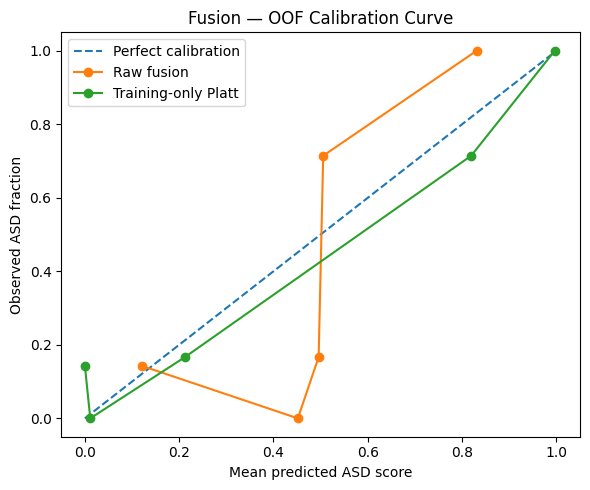

NameError: name 'TARGET_SPECIFICITY_FOR_SENSITIVITY' is not defined

In [ ]:
# ============================================================
# CELL 19 — CALIBRATION + TRAINING-ONLY OPERATING POINTS
#           + PPV/NPV PREVALENCE SCENARIOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


print("=" * 78)
print("CELL 19 — CALIBRATION + OPERATING POINTS + PPV/NPV")
print("=" * 78)


# ============================================================
# 1. LOCK INPUTS
# ============================================================

p_fusion_raw = np.asarray(
    fusion_raw_oof_probability,
    dtype=float
)


p_fusion_calibrated = np.asarray(
    fusion_oof_probability,
    dtype=float
)


if p_fusion_raw.shape != (
    N_FINAL,
):

    raise RuntimeError(
        "Unexpected raw fusion probability shape."
    )


if p_fusion_calibrated.shape != (
    N_FINAL,
):

    raise RuntimeError(
        "Unexpected calibrated fusion probability shape."
    )


validate_oof_probabilities(
    p_fusion_raw
)


validate_oof_probabilities(
    p_fusion_calibrated
)


print("\nFUSION PROBABILITY INPUT")

print(
    "Participants:",
    N_FINAL
)

print(
    "Raw probability range:",
    (
        float(
            p_fusion_raw.min()
        ),
        float(
            p_fusion_raw.max()
        )
    )
)

print(
    "Calibrated probability range:",
    (
        float(
            p_fusion_calibrated.min()
        ),
        float(
            p_fusion_calibrated.max()
        )
    )
)


# ============================================================
# 2. CALIBRATION METRICS
# ============================================================

# Only log-loss calculation uses clipping because log(0)
# is undefined. Brier score uses the probabilities exactly
# as produced by the model.

LOGLOSS_EPSILON = 1e-15


def clipped_probability(
    probability
):

    return np.clip(

        probability,

        LOGLOSS_EPSILON,

        1.0
        -
        LOGLOSS_EPSILON
    )


raw_brier = float(
    brier_score_loss(
        y,
        p_fusion_raw
    )
)


calibrated_brier = float(
    brier_score_loss(
        y,
        p_fusion_calibrated
    )
)


raw_log_loss = float(
    log_loss(
        y,
        clipped_probability(
            p_fusion_raw
        ),
        labels=[
            0,
            1
        ]
    )
)


calibrated_log_loss = float(
    log_loss(
        y,
        clipped_probability(
            p_fusion_calibrated
        ),
        labels=[
            0,
            1
        ]
    )
)


calibration_metric_df = pd.DataFrame([

    {
        "Probability_Set":
            "Fusion Raw",

        "Brier_Score":
            raw_brier,

        "Log_Loss":
            raw_log_loss,

        "ROC_AUC":
            float(
                roc_auc_score(
                    y,
                    p_fusion_raw
                )
            ),

        "PR_AUC":
            float(
                average_precision_score(
                    y,
                    p_fusion_raw
                )
            )
    },

    {
        "Probability_Set":
            "Fusion Training-Only Platt Calibrated",

        "Brier_Score":
            calibrated_brier,

        "Log_Loss":
            calibrated_log_loss,

        "ROC_AUC":
            float(
                roc_auc_score(
                    y,
                    p_fusion_calibrated
                )
            ),

        "PR_AUC":
            float(
                average_precision_score(
                    y,
                    p_fusion_calibrated
                )
            )
    }
])


calibration_metric_df[
    "Brier_Lower_Is_Better"
] = True


calibration_metric_df[
    "LogLoss_Lower_Is_Better"
] = True


print("\nRAW VS CALIBRATED PROBABILITY METRICS")

display(
    calibration_metric_df.round(
        6
    )
)


BRIER_IMPROVED = bool(
    calibrated_brier
    <
    raw_brier
)


LOGLOSS_IMPROVED = bool(
    calibrated_log_loss
    <
    raw_log_loss
)


print(
    "\nBrier score improved after calibration:",
    BRIER_IMPROVED
)

print(
    "Log loss improved after calibration:",
    LOGLOSS_IMPROVED
)


# ============================================================
# 3. FOLD-SPECIFIC CALIBRATION METRICS
# ============================================================

fold_calibration_records = []


for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    y_test = y[
        outer_test_idx
    ]


    raw_test = p_fusion_raw[
        outer_test_idx
    ]


    calibrated_test = p_fusion_calibrated[
        outer_test_idx
    ]


    fold_calibration_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Test_N":
            len(
                outer_test_idx
            ),

        "Raw_Brier":
            float(
                brier_score_loss(
                    y_test,
                    raw_test
                )
            ),

        "Calibrated_Brier":
            float(
                brier_score_loss(
                    y_test,
                    calibrated_test
                )
            ),

        "Raw_Log_Loss":
            float(
                log_loss(
                    y_test,
                    clipped_probability(
                        raw_test
                    ),
                    labels=[
                        0,
                        1
                    ]
                )
            ),

        "Calibrated_Log_Loss":
            float(
                log_loss(
                    y_test,
                    clipped_probability(
                        calibrated_test
                    ),
                    labels=[
                        0,
                        1
                    ]
                )
            )
    })


fold_calibration_df = pd.DataFrame(
    fold_calibration_records
)


fold_calibration_df[
    "Brier_Improved"
] = (

    fold_calibration_df[
        "Calibrated_Brier"
    ]

    <

    fold_calibration_df[
        "Raw_Brier"
    ]
)


print("\nFOLD-SPECIFIC CALIBRATION AUDIT")

display(
    fold_calibration_df.round(
        6
    )
)


# ============================================================
# 4. RELIABILITY CURVE
#
# Five quantile bins are used because the cohort is small.
# Fewer than five visible points can occur if probabilities
# contain repeated values.
# ============================================================

CALIBRATION_BINS = 5


raw_fraction_positive, raw_mean_predicted = (
    calibration_curve(

        y,

        p_fusion_raw,

        n_bins=
            CALIBRATION_BINS,

        strategy=
            "quantile"
    )
)


cal_fraction_positive, cal_mean_predicted = (
    calibration_curve(

        y,

        p_fusion_calibrated,

        n_bins=
            CALIBRATION_BINS,

        strategy=
            "quantile"
    )
)


calibration_curve_raw_df = pd.DataFrame({

    "Bin":
        np.arange(
            1,
            len(
                raw_fraction_positive
            )
            +
            1
        ),

    "Mean_Predicted_Probability":
        raw_mean_predicted,

    "Observed_ASD_Fraction":
        raw_fraction_positive,

    "Probability_Set":
        "Raw"
})


calibration_curve_calibrated_df = pd.DataFrame({

    "Bin":
        np.arange(
            1,
            len(
                cal_fraction_positive
            )
            +
            1
        ),

    "Mean_Predicted_Probability":
        cal_mean_predicted,

    "Observed_ASD_Fraction":
        cal_fraction_positive,

    "Probability_Set":
        "Platt calibrated"
})


calibration_curve_df = pd.concat(

    [
        calibration_curve_raw_df,
        calibration_curve_calibrated_df
    ],

    ignore_index=True
)


print("\nCALIBRATION-CURVE VALUES")

display(
    calibration_curve_df.round(
        6
    )
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--",

    label="Perfect calibration"
)


ax.plot(

    raw_mean_predicted,

    raw_fraction_positive,

    marker="o",

    label="Raw fusion"
)


ax.plot(

    cal_mean_predicted,

    cal_fraction_positive,

    marker="o",

    label="Training-only Platt"
)


ax.set_xlabel(
    "Mean predicted ASD score"
)

ax.set_ylabel(
    "Observed ASD fraction"
)

ax.set_title(
    "Fusion — OOF Calibration Curve"
)

ax.legend()


fig.tight_layout()


calibration_curve_file = (

    FIGURES_DIR
    /
    "cell19_fusion_calibration_curve.png"
)


fig.savefig(
    calibration_curve_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 5. GENERIC THRESHOLD METRICS
# ============================================================

def threshold_metrics(
    y_true,
    probabilities,
    threshold
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    predictions = (
        probabilities
        >=
        threshold
    ).astype(
        int
    )


    cm = confusion_matrix(

        y_true,

        predictions,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = cm.ravel()


    sensitivity = (

        tp
        /
        (
            tp
            +
            fn
        )

        if (
            tp
            +
            fn
        ) > 0

        else
        np.nan
    )


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if (
            tn
            +
            fp
        ) > 0

        else
        np.nan
    )


    return {

        "Threshold":
            float(
                threshold
            ),

        "Sensitivity":
            float(
                sensitivity
            ),

        "Specificity":
            float(
                specificity
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


# ============================================================
# 6. THRESHOLD-CANDIDATE TABLE
# ============================================================

def build_threshold_table(
    y_true,
    probabilities
):

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    # Include boundaries so the complete decision range is
    # represented.
    candidate_thresholds = np.unique(

        np.concatenate([

            np.array(
                [
                    0.0
                ]
            ),

            probabilities,

            np.array(
                [
                    1.0
                ]
            )
        ])
    )


    records = []


    for threshold in candidate_thresholds:

        metrics = threshold_metrics(

            y_true,

            probabilities,

            threshold
        )


        records.append(
            metrics
        )


    return pd.DataFrame(
        records
    )


# ============================================================
# 7. TRAINING-ONLY THRESHOLD SELECTION FUNCTIONS
# ============================================================

TARGET_SPECIFICITY = float(
    TARGET_SPECIFICITY_FOR_SENSITIVITY
)


TARGET_SENSITIVITY = float(
    TARGET_SENSITIVITY_FOR_SPECIFICITY
)


def select_threshold_for_target_specificity(
    y_train,
    probabilities_train,
    target_specificity
):

    table = build_threshold_table(

        y_train,

        probabilities_train
    )


    eligible = table[

        table[
            "Specificity"
        ]

        >=

        target_specificity
    ].copy()


    if len(
        eligible
    ) == 0:

        raise RuntimeError(
            "No training threshold meets the requested "
            "specificity target."
        )


    # Primary objective: maximize sensitivity.
    # Tie-break: maximize specificity.
    # Final tie-break: choose the lower threshold.
    selected = (

        eligible

        .sort_values(

            [
                "Sensitivity",
                "Specificity",
                "Threshold"
            ],

            ascending=[
                False,
                False,
                True
            ]
        )

        .iloc[
            0
        ]
    )


    return selected


def select_threshold_for_target_sensitivity(
    y_train,
    probabilities_train,
    target_sensitivity
):

    table = build_threshold_table(

        y_train,

        probabilities_train
    )


    eligible = table[

        table[
            "Sensitivity"
        ]

        >=

        target_sensitivity
    ].copy()


    if len(
        eligible
    ) == 0:

        raise RuntimeError(
            "No training threshold meets the requested "
            "sensitivity target."
        )


    # Primary objective: maximize specificity.
    # Tie-break: maximize sensitivity.
    # Final tie-break: choose the higher threshold.
    selected = (

        eligible

        .sort_values(

            [
                "Specificity",
                "Sensitivity",
                "Threshold"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[
            0
        ]
    )


    return selected


# ============================================================
# 8. RECONSTRUCT TRAINING-SIDE CALIBRATED FUSION
#    PROBABILITIES WITHIN EACH OUTER FOLD
#
# No base models need to be rerun. We reuse only the
# leakage-safe cross-fitted meta-training matrices created in
# Cell 18, then recreate the meta-level cross-fitting used for
# calibration.
# ============================================================

if "FUSION_OUTER_ARTIFACTS" not in globals():

    raise RuntimeError(
        "FUSION_OUTER_ARTIFACTS is not available. "
        "Rerun Cell 18 before Cell 19."
    )


threshold_fold_records = []


spec_target_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


sens_target_oof_prediction = np.full(
    N_FINAL,
    -1,
    dtype=int
)


spec_target_threshold_by_participant = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


sens_target_threshold_by_participant = np.full(
    N_FINAL,
    np.nan,
    dtype=float
)


for outer_fold_number in range(
    1,
    OUTER_FOLDS + 1
):

    artifact = FUSION_OUTER_ARTIFACTS[
        outer_fold_number
    ]


    outer_train_idx = artifact[
        "outer_train_idx"
    ]


    outer_test_idx = artifact[
        "outer_test_idx"
    ]


    meta_train_features = artifact[
        "meta_train_features"
    ]


    y_outer_train = artifact[
        "y_outer_train"
    ]


    # --------------------------------------------------------
    # Recreate held-out meta decision scores exactly using
    # the Cell 18 calibration-fold protocol.
    # --------------------------------------------------------

    n_outer_train = len(
        outer_train_idx
    )


    training_decision_scores = np.full(
        n_outer_train,
        np.nan,
        dtype=float
    )


    training_score_filled = np.zeros(
        n_outer_train,
        dtype=bool
    )


    calibration_cv = StratifiedKFold(

        n_splits=INNER_FOLDS,

        shuffle=True,

        random_state=(
            SEED
            +
            19000
            +
            outer_fold_number
        )
    )


    calibration_splits = list(

        calibration_cv.split(

            np.zeros(
                n_outer_train
            ),

            y_outer_train
        )
    )


    for calibration_fold_number, (
        calibration_train_local,
        calibration_valid_local
    ) in enumerate(

        calibration_splits,

        start=1
    ):

        y_calibration_train = (
            y_outer_train[
                calibration_train_local
            ]
        )


        calibration_subinner = make_subinner_splits(

            y_calibration_train,

            seed=(
                SEED
                +
                20000
                +
                outer_fold_number * 100
                +
                calibration_fold_number
            )
        )


        calibration_meta_grid = (
            tune_logistic_regression(

                meta_train_features[
                    calibration_train_local
                ],

                y_calibration_train,

                calibration_subinner
            )
        )


        calibration_meta_model = (
            calibration_meta_grid
            .best_estimator_
        )


        training_decision_scores[
            calibration_valid_local
        ] = (

            calibration_meta_model
            .decision_function(

                meta_train_features[
                    calibration_valid_local
                ]
            )
        )


        training_score_filled[
            calibration_valid_local
        ] = True


    if not training_score_filled.all():

        raise RuntimeError(
            f"Outer fold {outer_fold_number}: "
            "training decision scores incomplete."
        )


    if not np.isfinite(
        training_decision_scores
    ).all():

        raise RuntimeError(
            f"Outer fold {outer_fold_number}: "
            "non-finite training decision scores."
        )


    # --------------------------------------------------------
    # Load the exact Platt calibrator used for this outer fold.
    # --------------------------------------------------------

    calibrator_file = (

        fusion_fold_summary_df.loc[

            fusion_fold_summary_df[
                "Outer_Fold"
            ]
            ==
            outer_fold_number,

            "Calibrator_File"

        ].iloc[
            0
        ]
    )


    saved_platt_calibrator = load(
        calibrator_file
    )


    training_calibrated_probability = (

        saved_platt_calibrator

        .predict_proba(

            training_decision_scores.reshape(
                -1,
                1
            )
        )[
            :,
            1
        ]
    )


    if not np.isfinite(
        training_calibrated_probability
    ).all():

        raise RuntimeError(
            "Training calibrated probabilities "
            "contain non-finite values."
        )


    # --------------------------------------------------------
    # Select target-specificity threshold using training only.
    # --------------------------------------------------------

    selected_spec_rule = (
        select_threshold_for_target_specificity(

            y_outer_train,

            training_calibrated_probability,

            TARGET_SPECIFICITY
        )
    )


    spec_threshold = float(
        selected_spec_rule[
            "Threshold"
        ]
    )


    # --------------------------------------------------------
    # Select target-sensitivity threshold using training only.
    # --------------------------------------------------------

    selected_sens_rule = (
        select_threshold_for_target_sensitivity(

            y_outer_train,

            training_calibrated_probability,

            TARGET_SENSITIVITY
        )
    )


    sens_threshold = float(
        selected_sens_rule[
            "Threshold"
        ]
    )


    # --------------------------------------------------------
    # Apply those fixed thresholds to untouched outer test.
    # --------------------------------------------------------

    outer_test_probability = (
        p_fusion_calibrated[
            outer_test_idx
        ]
    )


    spec_test_prediction = (

        outer_test_probability
        >=
        spec_threshold
    ).astype(
        int
    )


    sens_test_prediction = (

        outer_test_probability
        >=
        sens_threshold
    ).astype(
        int
    )


    spec_target_oof_prediction[
        outer_test_idx
    ] = spec_test_prediction


    sens_target_oof_prediction[
        outer_test_idx
    ] = sens_test_prediction


    spec_target_threshold_by_participant[
        outer_test_idx
    ] = spec_threshold


    sens_target_threshold_by_participant[
        outer_test_idx
    ] = sens_threshold


    # --------------------------------------------------------
    # Fold-level audit
    # --------------------------------------------------------

    spec_test_cm = confusion_matrix(

        y[
            outer_test_idx
        ],

        spec_test_prediction,

        labels=[
            0,
            1
        ]
    )


    sens_test_cm = confusion_matrix(

        y[
            outer_test_idx
        ],

        sens_test_prediction,

        labels=[
            0,
            1
        ]
    )


    spec_tn, spec_fp, spec_fn, spec_tp = (
        spec_test_cm.ravel()
    )


    sens_tn, sens_fp, sens_fn, sens_tp = (
        sens_test_cm.ravel()
    )


    threshold_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Target_Specificity":
            TARGET_SPECIFICITY,

        "Spec_Target_Threshold":
            spec_threshold,

        "Training_Sensitivity_at_Spec_Target":
            float(
                selected_spec_rule[
                    "Sensitivity"
                ]
            ),

        "Training_Specificity_at_Spec_Target":
            float(
                selected_spec_rule[
                    "Specificity"
                ]
            ),

        "Outer_Test_Sensitivity_at_Spec_Target":
            (
                spec_tp
                /
                (
                    spec_tp
                    +
                    spec_fn
                )
                if (
                    spec_tp
                    +
                    spec_fn
                ) > 0
                else
                np.nan
            ),

        "Outer_Test_Specificity_at_Spec_Target":
            (
                spec_tn
                /
                (
                    spec_tn
                    +
                    spec_fp
                )
                if (
                    spec_tn
                    +
                    spec_fp
                ) > 0
                else
                np.nan
            ),

        "Target_Sensitivity":
            TARGET_SENSITIVITY,

        "Sens_Target_Threshold":
            sens_threshold,

        "Training_Sensitivity_at_Sens_Target":
            float(
                selected_sens_rule[
                    "Sensitivity"
                ]
            ),

        "Training_Specificity_at_Sens_Target":
            float(
                selected_sens_rule[
                    "Specificity"
                ]
            ),

        "Outer_Test_Sensitivity_at_Sens_Target":
            (
                sens_tp
                /
                (
                    sens_tp
                    +
                    sens_fn
                )
                if (
                    sens_tp
                    +
                    sens_fn
                ) > 0
                else
                np.nan
            ),

        "Outer_Test_Specificity_at_Sens_Target":
            (
                sens_tn
                /
                (
                    sens_tn
                    +
                    sens_fp
                )
                if (
                    sens_tn
                    +
                    sens_fp
                ) > 0
                else
                np.nan
            )
    })


threshold_fold_df = pd.DataFrame(
    threshold_fold_records
)


print("\nTRAINING-ONLY OPERATING THRESHOLDS BY OUTER FOLD")

display(
    threshold_fold_df.round(
        6
    )
)


# ============================================================
# 9. VERIFY THRESHOLD PREDICTION COMPLETENESS
# ============================================================

if np.any(
    spec_target_oof_prediction
    <
    0
):

    raise RuntimeError(
        "Specificity-target predictions are incomplete."
    )


if np.any(
    sens_target_oof_prediction
    <
    0
):

    raise RuntimeError(
        "Sensitivity-target predictions are incomplete."
    )


if not np.isfinite(
    spec_target_threshold_by_participant
).all():

    raise RuntimeError(
        "Missing specificity-target thresholds."
    )


if not np.isfinite(
    sens_target_threshold_by_participant
).all():

    raise RuntimeError(
        "Missing sensitivity-target thresholds."
    )


print(
    "Training-only threshold application completeness: PASS"
)


# ============================================================
# 10. METRICS FROM PRECOMPUTED PREDICTIONS
#
# Thresholds vary by outer fold, so metrics are computed from
# the binary predictions rather than a single global threshold.
# ============================================================

def metrics_from_binary_predictions(
    y_true,
    predictions
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    predictions = np.asarray(
        predictions,
        dtype=int
    )


    cm = confusion_matrix(

        y_true,

        predictions,

        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = cm.ravel()


    sensitivity = (

        tp
        /
        (
            tp
            +
            fn
        )

        if (
            tp
            +
            fn
        ) > 0

        else
        np.nan
    )


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if (
            tn
            +
            fp
        ) > 0

        else
        np.nan
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Balanced_Accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    predictions
                )
            ),

        "Precision":
            float(
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                )
            ),

        "Sensitivity":
            float(
                sensitivity
            ),

        "Specificity":
            float(
                specificity
            ),

        "F1":
            float(
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                )
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


primary_threshold_metrics = (
    compute_binary_metrics(

        y,

        p_fusion_calibrated,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )
)


specificity_target_metrics = (
    metrics_from_binary_predictions(

        y,

        spec_target_oof_prediction
    )
)


sensitivity_target_metrics = (
    metrics_from_binary_predictions(

        y,

        sens_target_oof_prediction
    )
)


operating_point_summary_df = pd.DataFrame([

    {
        "Operating_Point":
            "Primary fixed threshold 0.50",

        "Threshold_Source":
            "Pre-specified fixed threshold",

        "Median_Fold_Threshold":
            PRIMARY_BINARY_THRESHOLD,

        "Minimum_Fold_Threshold":
            PRIMARY_BINARY_THRESHOLD,

        "Maximum_Fold_Threshold":
            PRIMARY_BINARY_THRESHOLD,

        "Accuracy":
            primary_threshold_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            primary_threshold_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            primary_threshold_metrics[
                "Precision"
            ],

        "Sensitivity":
            primary_threshold_metrics[
                "Sensitivity"
            ],

        "Specificity":
            primary_threshold_metrics[
                "Specificity"
            ],

        "F1":
            primary_threshold_metrics[
                "F1"
            ],

        "TN":
            primary_threshold_metrics[
                "TN"
            ],

        "FP":
            primary_threshold_metrics[
                "FP"
            ],

        "FN":
            primary_threshold_metrics[
                "FN"
            ],

        "TP":
            primary_threshold_metrics[
                "TP"
            ]
    },

    {
        "Operating_Point":
            (
                "Training-only sensitivity maximized "
                "at specificity >= 0.90"
            ),

        "Threshold_Source":
            "Outer-training participants only",

        "Median_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Spec_Target_Threshold"
                ].median()
            ),

        "Minimum_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Spec_Target_Threshold"
                ].min()
            ),

        "Maximum_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Spec_Target_Threshold"
                ].max()
            ),

        **specificity_target_metrics
    },

    {
        "Operating_Point":
            (
                "Training-only specificity maximized "
                "at sensitivity >= 0.90"
            ),

        "Threshold_Source":
            "Outer-training participants only",

        "Median_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Sens_Target_Threshold"
                ].median()
            ),

        "Minimum_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Sens_Target_Threshold"
                ].min()
            ),

        "Maximum_Fold_Threshold":
            float(
                threshold_fold_df[
                    "Sens_Target_Threshold"
                ].max()
            ),

        **sensitivity_target_metrics
    }
])


print("\nOOF OPERATING-POINT PERFORMANCE")

display(
    operating_point_summary_df.round(
        6
    )
)


print(
    "\nIMPORTANT: the two target-based operating points "
    "are analytical, not clinically validated thresholds."
)


# ============================================================
# 11. PARTICIPANT-LEVEL OPERATING-POINT TABLE
# ============================================================

operating_point_predictions_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_fusion_calibrated_ASD":
        p_fusion_calibrated,

    "Primary_Threshold":
        PRIMARY_BINARY_THRESHOLD,

    "Primary_Prediction":
        (
            p_fusion_calibrated
            >=
            PRIMARY_BINARY_THRESHOLD
        ).astype(
            int
        ),

    "Spec_Target_Training_Threshold":
        spec_target_threshold_by_participant,

    "Spec_Target_Prediction":
        spec_target_oof_prediction,

    "Sens_Target_Training_Threshold":
        sens_target_threshold_by_participant,

    "Sens_Target_Prediction":
        sens_target_oof_prediction
})


# ============================================================
# 12. PPV / NPV PREVALENCE-SCENARIO FUNCTION
# ============================================================

def prevalence_adjusted_predictive_values(
    sensitivity,
    specificity,
    prevalence
):

    sensitivity = float(
        sensitivity
    )

    specificity = float(
        specificity
    )

    prevalence = float(
        prevalence
    )


    ppv_numerator = (
        sensitivity
        *
        prevalence
    )


    ppv_denominator = (

        ppv_numerator

        +

        (
            1.0
            -
            specificity
        )

        *

        (
            1.0
            -
            prevalence
        )
    )


    npv_numerator = (

        specificity

        *

        (
            1.0
            -
            prevalence
        )
    )


    npv_denominator = (

        (
            1.0
            -
            sensitivity
        )

        *
        prevalence

        +

        npv_numerator
    )


    ppv = (

        ppv_numerator
        /
        ppv_denominator

        if ppv_denominator > 0

        else
        np.nan
    )


    npv = (

        npv_numerator
        /
        npv_denominator

        if npv_denominator > 0

        else
        np.nan
    )


    return (
        ppv,
        npv
    )


# ============================================================
# 13. PPV / NPV SCENARIOS
# ============================================================

ppv_npv_records = []


for _, row in operating_point_summary_df.iterrows():

    for prevalence in PREVALENCE_SCENARIOS:

        ppv, npv = (
            prevalence_adjusted_predictive_values(

                sensitivity=
                    row[
                        "Sensitivity"
                    ],

                specificity=
                    row[
                        "Specificity"
                    ],

                prevalence=
                    prevalence
            )
        )


        ppv_npv_records.append({

            "Operating_Point":
                row[
                    "Operating_Point"
                ],

            "Sensitivity":
                float(
                    row[
                        "Sensitivity"
                    ]
                ),

            "Specificity":
                float(
                    row[
                        "Specificity"
                    ]
                ),

            "Assumed_Prevalence":
                prevalence,

            "PPV":
                ppv,

            "NPV":
                npv,

            "Interpretation":
                (
                    "Scenario calculation only; "
                    "not a Sri Lankan prevalence estimate."
                )
        })


ppv_npv_df = pd.DataFrame(
    ppv_npv_records
)


print("\nPPV / NPV PREVALENCE SCENARIOS")

display(
    ppv_npv_df.round(
        6
    )
)


# ============================================================
# 14. CALIBRATION INTERPRETATION RECORD
# ============================================================

if (
    BRIER_IMPROVED
    and
    LOGLOSS_IMPROVED
):

    calibration_interpretation = (
        "Training-only Platt calibration improved both "
        "Brier score and log loss in pooled OOF evaluation."
    )


elif (
    BRIER_IMPROVED
    or
    LOGLOSS_IMPROVED
):

    calibration_interpretation = (
        "Training-only Platt calibration improved one "
        "probabilistic metric but not both; calibration "
        "benefit is therefore mixed."
    )


else:

    calibration_interpretation = (
        "Training-only Platt calibration did not improve "
        "Brier score or log loss in this small internal cohort. "
        "The calibrated output remains the pre-specified primary "
        "fusion score, but calibration benefit must not be claimed."
    )


calibration_interpretation_df = pd.DataFrame([

    {
        "Finding":
            "Raw Brier score",

        "Value":
            raw_brier
    },

    {
        "Finding":
            "Calibrated Brier score",

        "Value":
            calibrated_brier
    },

    {
        "Finding":
            "Raw log loss",

        "Value":
            raw_log_loss
    },

    {
        "Finding":
            "Calibrated log loss",

        "Value":
            calibrated_log_loss
    },

    {
        "Finding":
            "Brier improved",

        "Value":
            BRIER_IMPROVED
    },

    {
        "Finding":
            "Log loss improved",

        "Value":
            LOGLOSS_IMPROVED
    },

    {
        "Finding":
            "Interpretation",

        "Value":
            calibration_interpretation
    },

    {
        "Finding":
            "Population probability claim",

        "Value":
            False
    },

    {
        "Finding":
            "Clinical threshold validation claim",

        "Value":
            False
    }
])


print("\nCALIBRATION INTERPRETATION")

display(
    calibration_interpretation_df
)


# ============================================================
# 15. SAVE RESULTS
# ============================================================

calibration_metric_file = (
    RESULTS_DIR
    /
    "cell19_fusion_calibration_metrics.csv"
)


fold_calibration_file = (
    RESULTS_DIR
    /
    "cell19_fusion_fold_calibration_metrics.csv"
)


calibration_curve_values_file = (
    RESULTS_DIR
    /
    "cell19_fusion_calibration_curve_values.csv"
)


threshold_fold_file = (
    RESULTS_DIR
    /
    "cell19_training_only_operating_thresholds.csv"
)


operating_point_summary_file = (
    RESULTS_DIR
    /
    "cell19_operating_point_summary.csv"
)


operating_point_predictions_file = (
    RESULTS_DIR
    /
    "cell19_operating_point_predictions.csv"
)


ppv_npv_file = (
    RESULTS_DIR
    /
    "cell19_ppv_npv_prevalence_scenarios.csv"
)


calibration_interpretation_file = (
    AUDIT_DIR
    /
    "cell19_calibration_interpretation.csv"
)


calibration_metric_df.to_csv(
    calibration_metric_file,
    index=False
)


fold_calibration_df.to_csv(
    fold_calibration_file,
    index=False
)


calibration_curve_df.to_csv(
    calibration_curve_values_file,
    index=False
)


threshold_fold_df.to_csv(
    threshold_fold_file,
    index=False
)


operating_point_summary_df.to_csv(
    operating_point_summary_file,
    index=False
)


operating_point_predictions_df.to_csv(
    operating_point_predictions_file,
    index=False
)


ppv_npv_df.to_csv(
    ppv_npv_file,
    index=False
)


calibration_interpretation_df.to_csv(
    calibration_interpretation_file,
    index=False
)


# ============================================================
# 16. SAVE OPERATING-POINT PROTOCOL
# ============================================================

operating_point_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Primary classification threshold",

        "Value":
            PRIMARY_BINARY_THRESHOLD
    },

    {
        "Setting":
            "Specificity analytical target",

        "Value":
            TARGET_SPECIFICITY
    },

    {
        "Setting":
            "Sensitivity analytical target",

        "Value":
            TARGET_SENSITIVITY
    },

    {
        "Setting":
            "Threshold selection data",

        "Value":
            "Outer-training participants only"
    },

    {
        "Setting":
            "Outer-test labels used for threshold selection",

        "Value":
            False
    },

    {
        "Setting":
            "Clinical validation claimed",

        "Value":
            False
    },

    {
        "Setting":
            "PPV/NPV assumed prevalence scenarios",

        "Value":
            ",".join(
                [
                    str(
                        prevalence
                    )
                    for prevalence
                    in PREVALENCE_SCENARIOS
                ]
            )
    },

    {
        "Setting":
            "Prevalence scenarios interpreted as "
            "Sri Lankan prevalence estimates",

        "Value":
            False
    }
])


operating_point_protocol_file = (
    MANIFEST_DIR
    /
    "cell19_operating_point_protocol.csv"
)


operating_point_protocol_df.to_csv(
    operating_point_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    calibration_metric_file
)

print(
    fold_calibration_file
)

print(
    calibration_curve_values_file
)

print(
    threshold_fold_file
)

print(
    operating_point_summary_file
)

print(
    operating_point_predictions_file
)

print(
    ppv_npv_file
)

print(
    calibration_interpretation_file
)

print(
    calibration_curve_file
)

print(
    operating_point_protocol_file
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("FUSION CALIBRATION SUMMARY")

print(
    "Raw Brier score:",
    round(
        raw_brier,
        6
    )
)

print(
    "Calibrated Brier score:",
    round(
        calibrated_brier,
        6
    )
)

print(
    "Raw log loss:",
    round(
        raw_log_loss,
        6
    )
)

print(
    "Calibrated log loss:",
    round(
        calibrated_log_loss,
        6
    )
)

print(
    "Brier improved:",
    BRIER_IMPROVED
)

print(
    "Log loss improved:",
    LOGLOSS_IMPROVED
)


print("\nPRIMARY FIXED-THRESHOLD PERFORMANCE")

print(
    "Threshold:",
    PRIMARY_BINARY_THRESHOLD
)

print(
    "Sensitivity:",
    round(
        primary_threshold_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "Specificity:",
    round(
        primary_threshold_metrics[
            "Specificity"
        ],
        6
    )
)


print("\nTRAINING-ONLY SPECIFICITY-TARGET RULE")

print(
    "Target specificity:",
    TARGET_SPECIFICITY
)

print(
    "Median selected threshold:",
    round(
        float(
            threshold_fold_df[
                "Spec_Target_Threshold"
            ].median()
        ),
        6
    )
)

print(
    "OOF sensitivity:",
    round(
        specificity_target_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "OOF specificity:",
    round(
        specificity_target_metrics[
            "Specificity"
        ],
        6
    )
)


print("\nTRAINING-ONLY SENSITIVITY-TARGET RULE")

print(
    "Target sensitivity:",
    TARGET_SENSITIVITY
)

print(
    "Median selected threshold:",
    round(
        float(
            threshold_fold_df[
                "Sens_Target_Threshold"
            ].median()
        ),
        6
    )
)

print(
    "OOF sensitivity:",
    round(
        sensitivity_target_metrics[
            "Sensitivity"
        ],
        6
    )
)

print(
    "OOF specificity:",
    round(
        sensitivity_target_metrics[
            "Specificity"
        ],
        6
    )
)


print(
    "\nPPV/NPV scenarios evaluated at assumed prevalence:",
    PREVALENCE_SCENARIOS
)

print(
    "Population ASD probability claimed:",
    False
)

print(
    "Clinical thresholds claimed:",
    False
)

print("\nCELL 19 STATUS: PASS")
print("=" * 78)

In [ ]:
# ============================================================
# CELL 19A — OPERATING-TARGET VARIABLE REPAIR
# ============================================================

print("=" * 78)
print("CELL 19A — OPERATING-TARGET VARIABLE REPAIR")
print("=" * 78)


# The final protocol locked both analytical operating targets
# at 0.90. Cell 19 referenced longer alias names that were not
# created previously. Define them explicitly here.
#
# This does NOT change the analysis protocol.

TARGET_SPECIFICITY_FOR_SENSITIVITY = 0.90
TARGET_SENSITIVITY_FOR_SPECIFICITY = 0.90


# Short names used later in Cell 19.
TARGET_SPECIFICITY = float(
    TARGET_SPECIFICITY_FOR_SENSITIVITY
)

TARGET_SENSITIVITY = float(
    TARGET_SENSITIVITY_FOR_SPECIFICITY
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

if not (
    0.0
    <
    TARGET_SPECIFICITY
    <=
    1.0
):

    raise RuntimeError(
        "Invalid specificity target."
    )


if not (
    0.0
    <
    TARGET_SENSITIVITY
    <=
    1.0
):

    raise RuntimeError(
        "Invalid sensitivity target."
    )


if TARGET_SPECIFICITY != 0.90:

    raise RuntimeError(
        "Specificity target no longer matches "
        "the locked protocol."
    )


if TARGET_SENSITIVITY != 0.90:

    raise RuntimeError(
        "Sensitivity target no longer matches "
        "the locked protocol."
    )


print("\nLOCKED ANALYTICAL OPERATING TARGETS")

print(
    "Sensitivity maximized at training specificity >=",
    TARGET_SPECIFICITY
)

print(
    "Specificity maximized at training sensitivity >=",
    TARGET_SENSITIVITY
)

print(
    "Clinical threshold claim:",
    False
)


print("\n" + "=" * 78)
print("CELL 19A STATUS: PASS")
print("=" * 78)

CELL 19A — OPERATING-TARGET VARIABLE REPAIR

LOCKED ANALYTICAL OPERATING TARGETS
Sensitivity maximized at training specificity >= 0.9
Specificity maximized at training sensitivity >= 0.9
Clinical threshold claim: False

CELL 19A STATUS: PASS


# 20. Confidence Intervals and Paired Statistical Model Comparisons

This stage quantifies uncertainty in the internally cross-validated model
results and formally compares the primary fusion model with each
protocol-defined primary unimodal branch.

## Models reported

Primary models:

- Shape
- Colour
- Draw-a-Man
- Questionnaire XGBoost
- Fully nested calibrated Fusion

Questionnaire Logistic Regression is retained as a baseline/sensitivity model
and receives descriptive confidence intervals, but it is not included in the
primary fusion-vs-branch hypothesis-testing family.

## Bootstrap confidence intervals

Participant-level stratified bootstrap resampling is performed 1,000 times.

ASD and TD participants are resampled separately with replacement so that
each bootstrap sample retains both diagnostic classes.

Percentile 95% confidence intervals are calculated for:

- accuracy;
- balanced accuracy;
- precision;
- sensitivity;
- specificity;
- F1;
- ROC-AUC;
- PR-AUC.

These intervals condition on the already generated out-of-fold predictions.
They do not reproduce the entire model-development procedure inside every
bootstrap replicate and therefore do not capture all model-training
instability.

## Paired ROC-AUC comparisons

Fusion ROC-AUC is compared with each primary unimodal branch using:

1. DeLong's paired ROC-AUC test;
2. paired stratified-bootstrap confidence intervals for the AUC difference.

The comparisons are:

- Fusion vs Shape
- Fusion vs Colour
- Fusion vs DAM
- Fusion vs Questionnaire XGBoost

Holm correction is applied across this four-comparison DeLong family.

Because these are pooled cross-validation predictions from a small internal
cohort, DeLong results are interpreted as internal paired comparisons rather
than definitive population-level inference.

## Paired binary-error comparisons

At the pre-specified 0.50 threshold, Fusion and each primary unimodal branch
are also compared using the exact McNemar test.

Holm correction is applied across the four McNemar comparisons.

No statistical result in this stage constitutes external clinical validation.

In [ ]:
# ============================================================
# CELL 20 — BOOTSTRAP CIs + DELONG + MCNEMAR + HOLM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    norm,
    binomtest
)


print("=" * 78)
print("CELL 20 — CONFIDENCE INTERVALS + PAIRED MODEL COMPARISONS")
print("=" * 78)


# ============================================================
# 1. LOCK REPORTED MODEL PREDICTIONS
# ============================================================

REPORTED_MODEL_PROBABILITIES = {

    "Shape":
        np.asarray(
            shape_oof_probability,
            dtype=float
        ),

    "Colour":
        np.asarray(
            colour_oof_probability,
            dtype=float
        ),

    "DAM":
        np.asarray(
            dam_oof_probability,
            dtype=float
        ),

    "Questionnaire XGBoost":
        np.asarray(
            questionnaire_xgb_oof_probability,
            dtype=float
        ),

    "Fusion Calibrated":
        np.asarray(
            fusion_oof_probability,
            dtype=float
        ),

    "Questionnaire LR Baseline":
        np.asarray(
            questionnaire_lr_oof_probability,
            dtype=float
        )
}


PRIMARY_INFERENCE_MODELS = [

    "Shape",
    "Colour",
    "DAM",
    "Questionnaire XGBoost"
]


PRIMARY_FUSION_NAME = (
    "Fusion Calibrated"
)


for model_name, probability in (
    REPORTED_MODEL_PROBABILITIES.items()
):

    validate_oof_probabilities(
        probability
    )


print("\nREPORTED MODELS")

for model_name in REPORTED_MODEL_PROBABILITIES:

    family = (

        "PRIMARY"

        if (
            model_name
            in
            PRIMARY_INFERENCE_MODELS
            or
            model_name
            ==
            PRIMARY_FUSION_NAME
        )

        else
        "BASELINE / SENSITIVITY"
    )


    print(
        f"{model_name:28s}: {family}"
    )


# ============================================================
# 2. STRATIFIED BOOTSTRAP SETUP
# ============================================================

N_BOOTSTRAP = int(
    BOOTSTRAP_REPS
)


BOOTSTRAP_SEED = (
    SEED
    +
    22000
)


bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


td_indices = np.where(
    y == 0
)[0]


asd_indices = np.where(
    y == 1
)[0]


print("\nBOOTSTRAP PROTOCOL")

print(
    "Replicates:",
    N_BOOTSTRAP
)

print(
    "TD sampled per replicate:",
    len(
        td_indices
    )
)

print(
    "ASD sampled per replicate:",
    len(
        asd_indices
    )
)

print(
    "Stratified by true diagnostic group:",
    True
)


# Pre-generate identical paired bootstrap samples so every
# model comparison uses exactly the same resampled participants.

BOOTSTRAP_INDEX_SETS = []


for bootstrap_index in range(
    N_BOOTSTRAP
):

    sampled_td = bootstrap_rng.choice(

        td_indices,

        size=len(
            td_indices
        ),

        replace=True
    )


    sampled_asd = bootstrap_rng.choice(

        asd_indices,

        size=len(
            asd_indices
        ),

        replace=True
    )


    sampled_indices = np.concatenate(
        [
            sampled_td,
            sampled_asd
        ]
    )


    # Shuffle row order only; class composition is unchanged.
    sampled_indices = bootstrap_rng.permutation(
        sampled_indices
    )


    BOOTSTRAP_INDEX_SETS.append(
        sampled_indices
    )


# ============================================================
# 3. BOOTSTRAP ALL REPORTED MODEL METRICS
# ============================================================

BOOTSTRAP_METRIC_NAMES = [

    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]


bootstrap_metric_records = []


for model_name, probability in (
    REPORTED_MODEL_PROBABILITIES.items()
):

    print(
        "\nBootstrapping:",
        model_name
    )


    for bootstrap_number, sampled_indices in enumerate(

        BOOTSTRAP_INDEX_SETS,

        start=1
    ):

        bootstrap_metrics = compute_binary_metrics(

            y[
                sampled_indices
            ],

            probability[
                sampled_indices
            ],

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )


        record = {

            "Bootstrap":
                bootstrap_number,

            "Model":
                model_name
        }


        for metric_name in BOOTSTRAP_METRIC_NAMES:

            record[
                metric_name
            ] = bootstrap_metrics[
                metric_name
            ]


        bootstrap_metric_records.append(
            record
        )


bootstrap_metrics_long_df = pd.DataFrame(
    bootstrap_metric_records
)


# ============================================================
# 4. 95% PERCENTILE CI SUMMARY
# ============================================================

def percentile_ci(
    values,
    alpha=0.05
):

    values = np.asarray(
        values,
        dtype=float
    )


    lower = float(
        np.quantile(
            values,
            alpha / 2.0
        )
    )


    upper = float(
        np.quantile(
            values,
            1.0 - alpha / 2.0
        )
    )


    return (
        lower,
        upper
    )


bootstrap_ci_records = []


for model_name, probability in (
    REPORTED_MODEL_PROBABILITIES.items()
):

    point_metrics = compute_binary_metrics(

        y,

        probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    model_bootstrap = bootstrap_metrics_long_df[

        bootstrap_metrics_long_df[
            "Model"
        ]
        ==
        model_name
    ]


    for metric_name in BOOTSTRAP_METRIC_NAMES:

        ci_low, ci_high = percentile_ci(

            model_bootstrap[
                metric_name
            ]
        )


        bootstrap_ci_records.append({

            "Model":
                model_name,

            "Inference_Status":
                (
                    "Primary"

                    if (
                        model_name
                        in
                        PRIMARY_INFERENCE_MODELS
                        or
                        model_name
                        ==
                        PRIMARY_FUSION_NAME
                    )

                    else
                    "Baseline / sensitivity"
                ),

            "Metric":
                metric_name,

            "Point_Estimate":
                float(
                    point_metrics[
                        metric_name
                    ]
                ),

            "CI_95_Lower":
                ci_low,

            "CI_95_Upper":
                ci_high,

            "Bootstrap_Repetitions":
                N_BOOTSTRAP
        })


bootstrap_ci_df = pd.DataFrame(
    bootstrap_ci_records
)


print("\nBOOTSTRAP 95% CONFIDENCE INTERVALS")

display(

    bootstrap_ci_df

    .pivot(
        index=[
            "Model",
            "Inference_Status"
        ],

        columns="Metric",

        values=[
            "Point_Estimate",
            "CI_95_Lower",
            "CI_95_Upper"
        ]
    )

    .round(
        4
    )
)


# ============================================================
# 5. COMPACT ROC-AUC CI TABLE
# ============================================================

auc_ci_df = (

    bootstrap_ci_df[
        bootstrap_ci_df[
            "Metric"
        ]
        ==
        "ROC_AUC"
    ]

    .copy()

    .reset_index(
        drop=True
    )
)


print("\nROC-AUC WITH 95% BOOTSTRAP CI")

display(
    auc_ci_df[
        [
            "Model",
            "Inference_Status",
            "Point_Estimate",
            "CI_95_Lower",
            "CI_95_Upper"
        ]
    ].round(
        6
    )
)


# ============================================================
# 6. DELONG IMPLEMENTATION FOR CORRELATED ROC-AUCs
# ============================================================

def compute_midrank(
    x
):

    x = np.asarray(
        x,
        dtype=float
    )


    J = np.argsort(
        x
    )


    Z = x[
        J
    ]


    N = len(
        x
    )


    T = np.zeros(
        N,
        dtype=float
    )


    i = 0


    while i < N:

        j = i


        while (
            j < N
            and
            Z[j] == Z[i]
        ):

            j += 1


        # 1-based average rank.
        T[
            i:j
        ] = (
            0.5
            *
            (
                i
                +
                j
                -
                1
            )
            +
            1.0
        )


        i = j


    T2 = np.empty(
        N,
        dtype=float
    )


    T2[
        J
    ] = T


    return T2


def fast_delong(
    predictions_sorted_transposed,
    label_1_count
):

    predictions_sorted_transposed = np.asarray(
        predictions_sorted_transposed,
        dtype=float
    )


    m = int(
        label_1_count
    )


    n = (
        predictions_sorted_transposed.shape[1]
        -
        m
    )


    if (
        m <= 1
        or
        n <= 1
    ):

        raise ValueError(
            "DeLong requires at least two positive "
            "and two negative observations."
        )


    positive_examples = (
        predictions_sorted_transposed[
            :,
            :m
        ]
    )


    negative_examples = (
        predictions_sorted_transposed[
            :,
            m:
        ]
    )


    k = predictions_sorted_transposed.shape[
        0
    ]


    tx = np.empty(
        [
            k,
            m
        ],
        dtype=float
    )


    ty = np.empty(
        [
            k,
            n
        ],
        dtype=float
    )


    tz = np.empty(
        [
            k,
            m + n
        ],
        dtype=float
    )


    for classifier_index in range(
        k
    ):

        tx[
            classifier_index,
            :
        ] = compute_midrank(

            positive_examples[
                classifier_index,
                :
            ]
        )


        ty[
            classifier_index,
            :
        ] = compute_midrank(

            negative_examples[
                classifier_index,
                :
            ]
        )


        tz[
            classifier_index,
            :
        ] = compute_midrank(

            predictions_sorted_transposed[
                classifier_index,
                :
            ]
        )


    aucs = (

        tz[
            :,
            :m
        ].sum(
            axis=1
        )

        /
        m

        /
        n

        -

        (
            m + 1.0
        )

        /
        (
            2.0
            *
            n
        )
    )


    v01 = (

        tz[
            :,
            :m
        ]

        -

        tx

    ) / n


    v10 = (

        1.0

        -

        (
            tz[
                :,
                m:
            ]

            -

            ty
        )

        /
        m
    )


    sx = np.atleast_2d(
        np.cov(
            v01,
            bias=False
        )
    )


    sy = np.atleast_2d(
        np.cov(
            v10,
            bias=False
        )
    )


    delong_covariance = (

        sx
        /
        m

        +

        sy
        /
        n
    )


    return (
        aucs,
        delong_covariance
    )


def paired_delong_test(
    y_true,
    probability_a,
    probability_b
):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    probability_a = np.asarray(
        probability_a,
        dtype=float
    )


    probability_b = np.asarray(
        probability_b,
        dtype=float
    )


    if set(
        np.unique(
            y_true
        ).tolist()
    ) != {
        0,
        1
    }:

        raise ValueError(
            "DeLong requires binary labels {0,1}."
        )


    # Positive cases first, as required by fast DeLong.
    order = np.argsort(
        -y_true
    )


    label_1_count = int(
        np.sum(
            y_true == 1
        )
    )


    prediction_matrix = np.vstack(
        [
            probability_a[
                order
            ],
            probability_b[
                order
            ]
        ]
    )


    aucs, covariance = fast_delong(

        prediction_matrix,

        label_1_count
    )


    auc_difference = float(
        aucs[0]
        -
        aucs[1]
    )


    variance_difference = float(

        covariance[
            0,
            0
        ]

        +

        covariance[
            1,
            1
        ]

        -

        2.0
        *
        covariance[
            0,
            1
        ]
    )


    # Numerical protection only.
    variance_difference = max(
        variance_difference,
        0.0
    )


    if variance_difference == 0.0:

        if auc_difference == 0.0:

            z_statistic = 0.0
            p_value = 1.0

        else:

            z_statistic = (
                np.inf
                if auc_difference > 0
                else
                -np.inf
            )

            p_value = 0.0


    else:

        standard_error = float(
            np.sqrt(
                variance_difference
            )
        )


        z_statistic = float(
            auc_difference
            /
            standard_error
        )


        p_value = float(

            2.0

            *

            norm.sf(
                abs(
                    z_statistic
                )
            )
        )


    return {

        "AUC_A":
            float(
                aucs[0]
            ),

        "AUC_B":
            float(
                aucs[1]
            ),

        "AUC_Difference":
            auc_difference,

        "Variance_Difference":
            variance_difference,

        "Z":
            z_statistic,

        "P_Value":
            p_value
    }


# ============================================================
# 7. HOLM ADJUSTMENT
# ============================================================

def holm_adjust(
    p_values
):

    p_values = np.asarray(
        p_values,
        dtype=float
    )


    m = len(
        p_values
    )


    order = np.argsort(
        p_values
    )


    adjusted = np.empty(
        m,
        dtype=float
    )


    running_maximum = 0.0


    for rank_index, original_index in enumerate(
        order
    ):

        candidate = (

            (
                m
                -
                rank_index
            )

            *

            p_values[
                original_index
            ]
        )


        candidate = max(
            candidate,
            running_maximum
        )


        candidate = min(
            candidate,
            1.0
        )


        adjusted[
            original_index
        ] = candidate


        running_maximum = candidate


    return adjusted


# ============================================================
# 8. PAIRED BOOTSTRAP AUC DIFFERENCE
# ============================================================

fusion_probability = (
    REPORTED_MODEL_PROBABILITIES[
        PRIMARY_FUSION_NAME
    ]
)


paired_auc_difference_records = []


delong_records = []


for comparator_name in PRIMARY_INFERENCE_MODELS:

    comparator_probability = (
        REPORTED_MODEL_PROBABILITIES[
            comparator_name
        ]
    )


    # --------------------------------------------------------
    # DeLong
    # --------------------------------------------------------

    delong_result = paired_delong_test(

        y,

        fusion_probability,

        comparator_probability
    )


    delong_records.append({

        "Comparison":
            (
                f"{PRIMARY_FUSION_NAME} "
                f"vs {comparator_name}"
            ),

        "Comparator":
            comparator_name,

        "Fusion_AUC":
            delong_result[
                "AUC_A"
            ],

        "Comparator_AUC":
            delong_result[
                "AUC_B"
            ],

        "Fusion_Minus_Comparator_AUC":
            delong_result[
                "AUC_Difference"
            ],

        "DeLong_Z":
            delong_result[
                "Z"
            ],

        "DeLong_P_Raw":
            delong_result[
                "P_Value"
            ]
    })


    # --------------------------------------------------------
    # Paired bootstrap difference
    # --------------------------------------------------------

    bootstrap_differences = np.empty(
        N_BOOTSTRAP,
        dtype=float
    )


    for bootstrap_number, sampled_indices in enumerate(
        BOOTSTRAP_INDEX_SETS
    ):

        bootstrap_fusion_auc = roc_auc_score(

            y[
                sampled_indices
            ],

            fusion_probability[
                sampled_indices
            ]
        )


        bootstrap_comparator_auc = roc_auc_score(

            y[
                sampled_indices
            ],

            comparator_probability[
                sampled_indices
            ]
        )


        bootstrap_differences[
            bootstrap_number
        ] = (

            bootstrap_fusion_auc

            -

            bootstrap_comparator_auc
        )


        paired_auc_difference_records.append({

            "Bootstrap":
                bootstrap_number + 1,

            "Comparator":
                comparator_name,

            "Fusion_Minus_Comparator_AUC":
                bootstrap_differences[
                    bootstrap_number
                ]
        })


    diff_ci_low, diff_ci_high = percentile_ci(
        bootstrap_differences
    )


    delong_records[
        -1
    ][
        "Bootstrap_AUC_Difference_CI_95_Lower"
    ] = diff_ci_low


    delong_records[
        -1
    ][
        "Bootstrap_AUC_Difference_CI_95_Upper"
    ] = diff_ci_high


    delong_records[
        -1
    ][
        "Bootstrap_CI_Excludes_Zero"
    ] = bool(

        (
            diff_ci_low > 0
        )

        or

        (
            diff_ci_high < 0
        )
    )


delong_comparison_df = pd.DataFrame(
    delong_records
)


delong_comparison_df[
    "DeLong_P_Holm"
] = holm_adjust(

    delong_comparison_df[
        "DeLong_P_Raw"
    ].to_numpy()
)


delong_comparison_df[
    "DeLong_Significant_Holm_0_05"
] = (

    delong_comparison_df[
        "DeLong_P_Holm"
    ]

    <
    0.05
)


print("\nPAIRED ROC-AUC COMPARISONS")

display(
    delong_comparison_df.round(
        6
    )
)


# ============================================================
# 9. EXACT MCNEMAR TESTS AT LOCKED 0.50 THRESHOLD
# ============================================================

fusion_prediction = (

    fusion_probability

    >=

    PRIMARY_BINARY_THRESHOLD
).astype(
    int
)


mcnemar_records = []


for comparator_name in PRIMARY_INFERENCE_MODELS:

    comparator_probability = (
        REPORTED_MODEL_PROBABILITIES[
            comparator_name
        ]
    )


    comparator_prediction = (

        comparator_probability

        >=

        PRIMARY_BINARY_THRESHOLD
    ).astype(
        int
    )


    fusion_correct = (
        fusion_prediction
        ==
        y
    )


    comparator_correct = (
        comparator_prediction
        ==
        y
    )


    # b: Fusion correct, comparator wrong.
    fusion_wins = int(
        np.sum(

            fusion_correct

            &

            ~comparator_correct
        )
    )


    # c: Fusion wrong, comparator correct.
    comparator_wins = int(
        np.sum(

            ~fusion_correct

            &

            comparator_correct
        )
    )


    discordant_total = (
        fusion_wins
        +
        comparator_wins
    )


    if discordant_total == 0:

        mcnemar_p = 1.0

    else:

        mcnemar_p = float(

            binomtest(

                fusion_wins,

                n=discordant_total,

                p=0.5,

                alternative="two-sided"
            ).pvalue
        )


    fusion_accuracy = float(
        accuracy_score(
            y,
            fusion_prediction
        )
    )


    comparator_accuracy = float(
        accuracy_score(
            y,
            comparator_prediction
        )
    )


    mcnemar_records.append({

        "Comparison":
            (
                f"{PRIMARY_FUSION_NAME} "
                f"vs {comparator_name}"
            ),

        "Comparator":
            comparator_name,

        "Fusion_Accuracy":
            fusion_accuracy,

        "Comparator_Accuracy":
            comparator_accuracy,

        "Fusion_Minus_Comparator_Accuracy":
            (
                fusion_accuracy
                -
                comparator_accuracy
            ),

        "Fusion_Correct_Comparator_Wrong":
            fusion_wins,

        "Fusion_Wrong_Comparator_Correct":
            comparator_wins,

        "Discordant_Total":
            discordant_total,

        "McNemar_Exact_P_Raw":
            mcnemar_p
    })


mcnemar_df = pd.DataFrame(
    mcnemar_records
)


mcnemar_df[
    "McNemar_P_Holm"
] = holm_adjust(

    mcnemar_df[
        "McNemar_Exact_P_Raw"
    ].to_numpy()
)


mcnemar_df[
    "McNemar_Significant_Holm_0_05"
] = (

    mcnemar_df[
        "McNemar_P_Holm"
    ]

    <
    0.05
)


print("\nEXACT MCNEMAR COMPARISONS — THRESHOLD 0.50")

display(
    mcnemar_df.round(
        6
    )
)


# ============================================================
# 10. PRIMARY INFERENCE SUMMARY
# ============================================================

primary_inference_summary_df = (

    delong_comparison_df[
        [
            "Comparator",
            "Fusion_AUC",
            "Comparator_AUC",
            "Fusion_Minus_Comparator_AUC",
            "Bootstrap_AUC_Difference_CI_95_Lower",
            "Bootstrap_AUC_Difference_CI_95_Upper",
            "Bootstrap_CI_Excludes_Zero",
            "DeLong_P_Raw",
            "DeLong_P_Holm",
            "DeLong_Significant_Holm_0_05"
        ]
    ]

    .merge(

        mcnemar_df[
            [
                "Comparator",
                "Fusion_Accuracy",
                "Comparator_Accuracy",
                "Fusion_Minus_Comparator_Accuracy",
                "Fusion_Correct_Comparator_Wrong",
                "Fusion_Wrong_Comparator_Correct",
                "McNemar_Exact_P_Raw",
                "McNemar_P_Holm",
                "McNemar_Significant_Holm_0_05"
            ]
        ],

        on="Comparator",

        how="one_to_one"
    )
)


print("\nPRIMARY FUSION-vs-BRANCH INFERENCE SUMMARY")

display(
    primary_inference_summary_df.round(
        6
    )
)


# ============================================================
# 11. INTERPRETATION FLAGS
# ============================================================

inference_interpretation_records = []


for _, row in primary_inference_summary_df.iterrows():

    if (
        row[
            "DeLong_Significant_Holm_0_05"
        ]
        and
        row[
            "Fusion_Minus_Comparator_AUC"
        ]
        >
        0
    ):

        auc_interpretation = (
            "Fusion has higher AUC with Holm-adjusted "
            "DeLong significance in this internal cohort."
        )

    else:

        auc_interpretation = (
            "No Holm-adjusted evidence that Fusion "
            "has a different ROC-AUC from this comparator."
        )


    if (
        row[
            "McNemar_Significant_Holm_0_05"
        ]
        and
        row[
            "Fusion_Minus_Comparator_Accuracy"
        ]
        >
        0
    ):

        binary_interpretation = (
            "Fusion has fewer threshold-0.50 classification "
            "errors with Holm-adjusted McNemar significance."
        )

    else:

        binary_interpretation = (
            "No Holm-adjusted evidence of different "
            "threshold-0.50 error rates."
        )


    inference_interpretation_records.append({

        "Comparator":
            row[
                "Comparator"
            ],

        "AUC_Interpretation":
            auc_interpretation,

        "Threshold_Error_Interpretation":
            binary_interpretation,

        "External_Validation_Claim":
            False
    })


inference_interpretation_df = pd.DataFrame(
    inference_interpretation_records
)


print("\nSTATISTICAL INTERPRETATION")

display(
    inference_interpretation_df
)


# ============================================================
# 12. ROC-AUC FOREST-STYLE FIGURE
# ============================================================

auc_plot_df = (
    auc_ci_df
    .copy()
    .reset_index(
        drop=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


y_positions = np.arange(
    len(
        auc_plot_df
    )
)


point_estimates = (
    auc_plot_df[
        "Point_Estimate"
    ].to_numpy()
)


lower_errors = (

    point_estimates

    -

    auc_plot_df[
        "CI_95_Lower"
    ].to_numpy()
)


upper_errors = (

    auc_plot_df[
        "CI_95_Upper"
    ].to_numpy()

    -

    point_estimates
)


ax.errorbar(

    point_estimates,

    y_positions,

    xerr=np.vstack(
        [
            lower_errors,
            upper_errors
        ]
    ),

    fmt="o",

    capsize=4
)


ax.set_yticks(
    y_positions
)


ax.set_yticklabels(
    auc_plot_df[
        "Model"
    ]
)


ax.set_xlim(
    0.0,
    1.05
)


ax.set_xlabel(
    "ROC-AUC with 95% stratified-bootstrap CI"
)


ax.set_title(
    "Internal OOF ROC-AUC Uncertainty"
)


ax.invert_yaxis()


fig.tight_layout()


auc_ci_figure_file = (

    FIGURES_DIR
    /
    "cell20_roc_auc_bootstrap_confidence_intervals.png"
)


fig.savefig(
    auc_ci_figure_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 13. SAVE OUTPUTS
# ============================================================

bootstrap_metrics_file = (
    RESULTS_DIR
    /
    "cell20_bootstrap_metric_replicates.csv"
)


bootstrap_ci_file = (
    RESULTS_DIR
    /
    "cell20_bootstrap_95ci_summary.csv"
)


auc_difference_bootstrap_file = (
    RESULTS_DIR
    /
    "cell20_paired_auc_difference_bootstrap.csv"
)


delong_file = (
    RESULTS_DIR
    /
    "cell20_delong_auc_comparisons.csv"
)


mcnemar_file = (
    RESULTS_DIR
    /
    "cell20_mcnemar_comparisons.csv"
)


primary_inference_file = (
    RESULTS_DIR
    /
    "cell20_primary_statistical_comparison_summary.csv"
)


inference_interpretation_file = (
    AUDIT_DIR
    /
    "cell20_statistical_interpretation.csv"
)


bootstrap_metrics_long_df.to_csv(
    bootstrap_metrics_file,
    index=False
)


bootstrap_ci_df.to_csv(
    bootstrap_ci_file,
    index=False
)


pd.DataFrame(
    paired_auc_difference_records
).to_csv(
    auc_difference_bootstrap_file,
    index=False
)


delong_comparison_df.to_csv(
    delong_file,
    index=False
)


mcnemar_df.to_csv(
    mcnemar_file,
    index=False
)


primary_inference_summary_df.to_csv(
    primary_inference_file,
    index=False
)


inference_interpretation_df.to_csv(
    inference_interpretation_file,
    index=False
)


# ============================================================
# 14. SAVE INFERENCE PROTOCOL
# ============================================================

statistical_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Bootstrap repetitions",

        "Value":
            N_BOOTSTRAP
    },

    {
        "Setting":
            "Bootstrap type",

        "Value":
            (
                "Participant-level stratified bootstrap "
                "of fixed OOF predictions"
            )
    },

    {
        "Setting":
            "Bootstrap confidence level",

        "Value":
            "95%"
    },

    {
        "Setting":
            "Primary paired AUC test",

        "Value":
            "DeLong"
    },

    {
        "Setting":
            "Primary binary paired test",

        "Value":
            "Exact McNemar"
    },

    {
        "Setting":
            "Multiplicity correction",

        "Value":
            (
                "Holm adjustment separately within "
                "4 DeLong and 4 McNemar comparisons"
            )
    },

    {
        "Setting":
            "Primary comparison family",

        "Value":
            (
                "Fusion vs Shape; Colour; DAM; "
                "Questionnaire XGBoost"
            )
    },

    {
        "Setting":
            "Questionnaire LR included in primary "
            "hypothesis-testing family",

        "Value":
            False
    },

    {
        "Setting":
            "External validation inference",

        "Value":
            False
    }
])


statistical_protocol_file = (
    MANIFEST_DIR
    /
    "cell20_statistical_inference_protocol.csv"
)


statistical_protocol_df.to_csv(
    statistical_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    bootstrap_metrics_file
)

print(
    bootstrap_ci_file
)

print(
    auc_difference_bootstrap_file
)

print(
    delong_file
)

print(
    mcnemar_file
)

print(
    primary_inference_file
)

print(
    inference_interpretation_file
)

print(
    auc_ci_figure_file
)

print(
    statistical_protocol_file
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)

print("CELL 20 — FINAL STATISTICAL SUMMARY")

print(
    "Bootstrap replicates:",
    N_BOOTSTRAP
)

print(
    "Primary paired AUC comparisons:",
    len(
        delong_comparison_df
    )
)

print(
    "Holm-significant DeLong comparisons:",
    int(
        delong_comparison_df[
            "DeLong_Significant_Holm_0_05"
        ].sum()
    )
)

print(
    "Primary paired binary comparisons:",
    len(
        mcnemar_df
    )
)

print(
    "Holm-significant McNemar comparisons:",
    int(
        mcnemar_df[
            "McNemar_Significant_Holm_0_05"
        ].sum()
    )
)

print(
    "Questionnaire LR retained as baseline only:",
    True
)

print(
    "Bootstrap intervals capture full "
    "model-training uncertainty:",
    False
)

print(
    "External validation claim:",
    False
)

print("\nCELL 20 STATUS: PASS")
print("=" * 78)

CELL 20 — CONFIDENCE INTERVALS + PAIRED MODEL COMPARISONS

REPORTED MODELS
Shape                       : PRIMARY
Colour                      : PRIMARY
DAM                         : PRIMARY
Questionnaire XGBoost       : PRIMARY
Fusion Calibrated           : PRIMARY
Questionnaire LR Baseline   : BASELINE / SENSITIVITY

BOOTSTRAP PROTOCOL
Replicates: 1000
TD sampled per replicate: 20
ASD sampled per replicate: 14
Stratified by true diagnostic group: True

Bootstrapping: Shape

Bootstrapping: Colour

Bootstrapping: DAM

Bootstrapping: Questionnaire XGBoost

Bootstrapping: Fusion Calibrated

Bootstrapping: Questionnaire LR Baseline

BOOTSTRAP 95% CONFIDENCE INTERVALS


Point_Estimate  \
Metric                                                 Accuracy   
Model                     Inference_Status                        
Colour                    Primary                        0.8529   
DAM                       Primary                        0.6471   
Fusion Calibrated         Primary                        0.8824   
Questionnaire LR Baseline Baseline / sensitivity         1.0000   
Questionnaire XGBoost     Primary                        0.8529   
Shape                     Primary                        0.8529   

                                                                            \
Metric                                           Balanced_Accuracy      F1   
Model                     Inference_Status                                   
Colour                    Primary                           0.8536  0.8276   
DAM                       Primary                           0.6571  0.6250   
Fusion Calibrated         Primary                           0.8786  0.8571   
Questionnaire LR Baseline Baseline / sensitivity            1.0000  1.0000   
Questionnaire XGBoost     Primary                           0.8321  0.8000   
Shape                     Primary                           0.8536  0.8276   

                                                                            \
Metric                                            PR_AUC Precision ROC_AUC   
Model                     Inference_Status                                   
Colour                    Primary                 0.8752    0.8000  0.8750   
DAM                       Primary                 0.6604    0.5556  0.7107   
Fusion Calibrated         Primary                 0.9412    0.8571  0.9143   
Questionnaire LR Baseline Baseline / sensitivity  1.0000    1.0000  1.0000   
Questionnaire XGBoost     Primary                 0.8760    0.9091  0.8857   
Shape                     Primary                 0.8567    0.8000  0.8857   

                                                                          \
Metric                                           Sensitivity Specificity   
Model                     Inference_Status                                 
Colour                    Primary                     0.8571        0.85   
DAM                       Primary                     0.7143        0.60   
Fusion Calibrated         Primary                     0.8571        0.90   
Questionnaire LR Baseline Baseline / sensitivity      1.0000        1.00   
Questionnaire XGBoost     Primary                     0.7143        0.95   
Shape                     Primary                     0.8571        0.85   

                                                 CI_95_Lower  \
Metric                                              Accuracy   
Model                     Inference_Status                     
Colour                    Primary                     0.7353   
DAM                       Primary                     0.5000   
Fusion Calibrated         Primary                     0.7647   
Questionnaire LR Baseline Baseline / sensitivity      1.0000   
Questionnaire XGBoost     Primary                     0.7353   
Shape                     Primary                     0.7353   

                                                                    ...  \
Metric                                           Balanced_Accuracy  ...   
Model                     Inference_Status                          ...   
Colour                    Primary                           0.7321  ...   
DAM                       Primary                           0.5000  ...   
Fusion Calibrated         Primary                           0.7571  ...   
Questionnaire LR Baseline Baseline / sensitivity            1.0000  ...   
Questionnaire XGBoost     Primary                           0.7000  ...   
Shape                     Primary                           0.7214  ...   

                                                                          \
Metric                   


ROC-AUC WITH 95% BOOTSTRAP CI


,Model,Inference_Status,Point_Estimate,CI_95_Lower,CI_95_Upper
0,Shape,Primary,0.885714,0.753571,1.000000
1,Colour,Primary,0.875000,0.721429,0.989286
2,DAM,Primary,0.710714,0.517768,0.889286
3,Questionnaire XGBoost,Primary,0.885714,0.753482,0.982143
4,Fusion Calibrated,Primary,0.914286,0.767857,1.000000
5,Questionnaire LR Baseline,Baseline / sensitivity,1.000000,1.000000,1.000000



PAIRED ROC-AUC COMPARISONS


,Comparison,Comparator,Fusion_AUC,Comparator_AUC,Fusion_Minus_Comparator_AUC,DeLong_Z,DeLong_P_Raw,Bootstrap_AUC_Difference_CI_95_Lower,Bootstrap_AUC_Difference_CI_95_Upper,Bootstrap_CI_Excludes_Zero,DeLong_P_Holm,DeLong_Significant_Holm_0_05
0,Fusion Calibrated vs Shape,Shape,0.914286,0.885714,0.028571,0.376978,0.706190,-0.103571,0.167946,False,1.000000,False
1,Fusion Calibrated vs Colour,Colour,0.914286,0.875000,0.039286,1.020079,0.307691,-0.025000,0.117857,False,0.923073,False
2,Fusion Calibrated vs DAM,DAM,0.914286,0.710714,0.203571,1.880750,0.060006,0.003393,0.389286,True,0.240024,False
3,Fusion Calibrated vs Questionnaire XGBoost,Questionnaire XGBoost,0.914286,0.885714,0.028571,0.420478,0.674137,-0.108973,0.153571,False,1.000000,False



EXACT MCNEMAR COMPARISONS — THRESHOLD 0.50


,Comparison,Comparator,Fusion_Accuracy,Comparator_Accuracy,Fusion_Minus_Comparator_Accuracy,Fusion_Correct_Comparator_Wrong,Fusion_Wrong_Comparator_Correct,Discordant_Total,McNemar_Exact_P_Raw,McNemar_P_Holm,McNemar_Significant_Holm_0_05
0,Fusion Calibrated vs Shape,Shape,0.882353,0.852941,0.029412,2,1,3,1.000000,1.00000,False
1,Fusion Calibrated vs Colour,Colour,0.882353,0.852941,0.029412,3,2,5,1.000000,1.00000,False
2,Fusion Calibrated vs DAM,DAM,0.882353,0.647059,0.235294,8,0,8,0.007812,0.03125,True
3,Fusion Calibrated vs Questionnaire XGBoost,Questionnaire XGBoost,0.882353,0.852941,0.029412,3,2,5,1.000000,1.00000,False


UnboundLocalError: cannot access local variable 'lidx' where it is not associated with a value

# 20A. Statistical Summary Merge Repair

The bootstrap confidence intervals, DeLong tests and exact McNemar tests in
Cell 20 completed successfully.

Cell 20 stopped only while merging the already calculated DeLong and McNemar
tables because the pandas `merge()` call incorrectly supplied
`how="one_to_one"`.

`one_to_one` is a merge-validation rule rather than a merge type.

The corrected merge uses:

- `how="inner"`
- `validate="one_to_one"`

No statistical analysis is repeated and no result is changed.

The completed inference tables are then saved and the Cell 20 statistical
audit is finalized.

CELL 20A — STATISTICAL SUMMARY MERGE REPAIR

Previously calculated Cell 20 results available: PASS
Unique paired comparator keys: PASS

PRIMARY FUSION-vs-BRANCH INFERENCE SUMMARY


,Comparator,Fusion_AUC,Comparator_AUC,Fusion_Minus_Comparator_AUC,Bootstrap_AUC_Difference_CI_95_Lower,Bootstrap_AUC_Difference_CI_95_Upper,Bootstrap_CI_Excludes_Zero,DeLong_P_Raw,DeLong_P_Holm,DeLong_Significant_Holm_0_05,Fusion_Accuracy,Comparator_Accuracy,Fusion_Minus_Comparator_Accuracy,Fusion_Correct_Comparator_Wrong,Fusion_Wrong_Comparator_Correct,McNemar_Exact_P_Raw,McNemar_P_Holm,McNemar_Significant_Holm_0_05
0,Shape,0.914286,0.885714,0.028571,-0.103571,0.167946,False,0.706190,1.000000,False,0.882353,0.852941,0.029412,2,1,1.000000,1.00000,False
1,Colour,0.914286,0.875000,0.039286,-0.025000,0.117857,False,0.307691,0.923073,False,0.882353,0.852941,0.029412,3,2,1.000000,1.00000,False
2,DAM,0.914286,0.710714,0.203571,0.003393,0.389286,True,0.060006,0.240024,False,0.882353,0.647059,0.235294,8,0,0.007812,0.03125,True
3,Questionnaire XGBoost,0.914286,0.885714,0.028571,-0.108973,0.153571,False,0.674137,1.000000,False,0.882353,0.852941,0.029412,3,2,1.000000,1.00000,False



STATISTICAL INTERPRETATION


,Comparator,AUC_Interpretation,Threshold_0_50_Interpretation,External_Validation_Claim
0,Shape,No Holm-adjusted evidence that Fusion has a di...,No Holm-adjusted evidence of different thresho...,False
1,Colour,No Holm-adjusted evidence that Fusion has a di...,No Holm-adjusted evidence of different thresho...,False
2,DAM,The paired bootstrap AUC-difference interval e...,Fusion made significantly fewer threshold-0.50...,False
3,Questionnaire XGBoost,No Holm-adjusted evidence that Fusion has a di...,No Holm-adjusted evidence of different thresho...,False



DELONG — HOLM-ADJUSTED SIGNIFICANCE


,Comparator,Fusion_Minus_Comparator_AUC,Bootstrap_AUC_Difference_CI_95_Lower,Bootstrap_AUC_Difference_CI_95_Upper,DeLong_P_Raw,DeLong_P_Holm,DeLong_Significant_Holm_0_05
0,Shape,0.028571,-0.103571,0.167946,0.706190,1.000000,False
1,Colour,0.039286,-0.025000,0.117857,0.307691,0.923073,False
2,DAM,0.203571,0.003393,0.389286,0.060006,0.240024,False
3,Questionnaire XGBoost,0.028571,-0.108973,0.153571,0.674137,1.000000,False



MCNEMAR — HOLM-ADJUSTED SIGNIFICANCE


,Comparator,Fusion_Minus_Comparator_Accuracy,Fusion_Correct_Comparator_Wrong,Fusion_Wrong_Comparator_Correct,McNemar_Exact_P_Raw,McNemar_P_Holm,McNemar_Significant_Holm_0_05
0,Shape,0.029412,2,1,1.000000,1.00000,False
1,Colour,0.029412,3,2,1.000000,1.00000,False
2,DAM,0.235294,8,0,0.007812,0.03125,True
3,Questionnaire XGBoost,0.029412,3,2,1.000000,1.00000,False



PRIMARY INFERENCE FLAGS
Holm-significant DeLong comparisons: 0 / 4
Paired bootstrap AUC-difference CIs strictly above zero: 1 / 4
Holm-significant McNemar comparisons: 1 / 4
Significant DeLong comparators: None
Positive paired-bootstrap AUC-difference comparators: ['DAM']
Significant McNemar comparators: ['DAM']


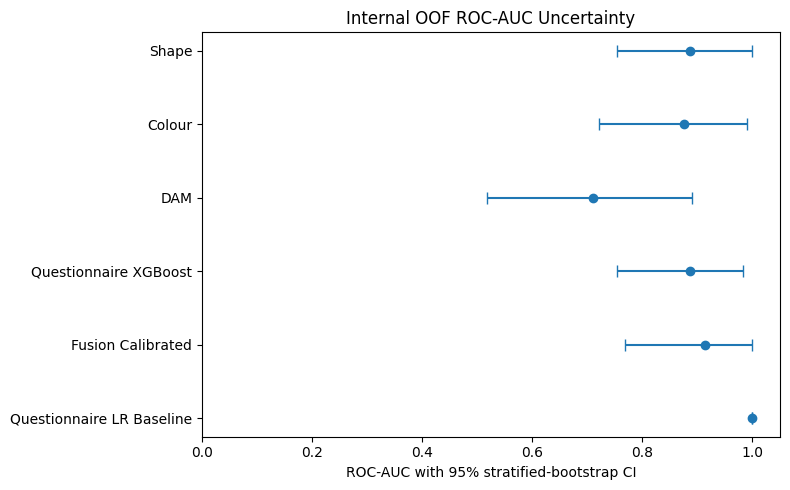


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_bootstrap_metric_replicates.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_bootstrap_95ci_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_paired_auc_difference_bootstrap.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_delong_auc_comparisons.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_mcnemar_comparisons.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell20_primary_statistical_comparison_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell20_statistical_interpretation.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell20_roc_auc_bootstrap_confidence_intervals.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell20_statistical_inference_protocol.csv

CELL 20 — FINAL STA

In [ ]:
# ============================================================
# CELL 20A — STATISTICAL SUMMARY MERGE REPAIR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 78)
print("CELL 20A — STATISTICAL SUMMARY MERGE REPAIR")
print("=" * 78)


# ============================================================
# 1. VERIFY THAT CELL 20 RESULTS ARE STILL IN MEMORY
# ============================================================

required_cell20_objects = [

    "bootstrap_metrics_long_df",
    "bootstrap_ci_df",
    "auc_ci_df",

    "paired_auc_difference_records",

    "delong_comparison_df",
    "mcnemar_df"
]


missing_cell20_objects = [

    object_name

    for object_name
    in required_cell20_objects

    if object_name not in globals()
]


if missing_cell20_objects:

    raise RuntimeError(
        "Required Cell 20 results are no longer in memory: "
        f"{missing_cell20_objects}. "
        "If the runtime was restarted, rerun Cell 20."
    )


print(
    "\nPreviously calculated Cell 20 results available: PASS"
)


# ============================================================
# 2. VERIFY UNIQUE COMPARATOR KEYS
# ============================================================

if delong_comparison_df[
    "Comparator"
].duplicated().any():

    raise RuntimeError(
        "Duplicate Comparator values detected "
        "in DeLong results."
    )


if mcnemar_df[
    "Comparator"
].duplicated().any():

    raise RuntimeError(
        "Duplicate Comparator values detected "
        "in McNemar results."
    )


delong_comparators = set(
    delong_comparison_df[
        "Comparator"
    ]
)


mcnemar_comparators = set(
    mcnemar_df[
        "Comparator"
    ]
)


if delong_comparators != mcnemar_comparators:

    raise RuntimeError(
        "DeLong and McNemar comparator sets do not match."
    )


print(
    "Unique paired comparator keys: PASS"
)


# ============================================================
# 3. CORRECTLY MERGE DELONG + MCNEMAR RESULTS
# ============================================================

primary_inference_summary_df = (

    delong_comparison_df[
        [
            "Comparator",

            "Fusion_AUC",
            "Comparator_AUC",

            "Fusion_Minus_Comparator_AUC",

            "Bootstrap_AUC_Difference_CI_95_Lower",
            "Bootstrap_AUC_Difference_CI_95_Upper",
            "Bootstrap_CI_Excludes_Zero",

            "DeLong_P_Raw",
            "DeLong_P_Holm",
            "DeLong_Significant_Holm_0_05"
        ]
    ]

    .merge(

        mcnemar_df[
            [
                "Comparator",

                "Fusion_Accuracy",
                "Comparator_Accuracy",

                "Fusion_Minus_Comparator_Accuracy",

                "Fusion_Correct_Comparator_Wrong",
                "Fusion_Wrong_Comparator_Correct",

                "McNemar_Exact_P_Raw",
                "McNemar_P_Holm",
                "McNemar_Significant_Holm_0_05"
            ]
        ],

        on="Comparator",

        how="inner",

        validate="one_to_one"
    )
)


expected_comparison_count = len(
    PRIMARY_INFERENCE_MODELS
)


if len(
    primary_inference_summary_df
) != expected_comparison_count:

    raise RuntimeError(
        "Unexpected number of combined primary comparisons."
    )


print("\nPRIMARY FUSION-vs-BRANCH INFERENCE SUMMARY")

display(
    primary_inference_summary_df.round(
        6
    )
)


# ============================================================
# 4. BUILD CAUTIOUS INTERPRETATION TABLE
# ============================================================

inference_interpretation_records = []


for _, row in primary_inference_summary_df.iterrows():

    comparator = row[
        "Comparator"
    ]


    auc_difference = float(
        row[
            "Fusion_Minus_Comparator_AUC"
        ]
    )


    bootstrap_ci_excludes_zero = bool(
        row[
            "Bootstrap_CI_Excludes_Zero"
        ]
    )


    delong_significant = bool(
        row[
            "DeLong_Significant_Holm_0_05"
        ]
    )


    mcnemar_significant = bool(
        row[
            "McNemar_Significant_Holm_0_05"
        ]
    )


    # --------------------------------------------------------
    # AUC interpretation
    # --------------------------------------------------------

    if (
        delong_significant
        and
        auc_difference > 0
    ):

        auc_interpretation = (
            "Fusion has a higher ROC-AUC with "
            "Holm-adjusted DeLong significance "
            "in this internal cohort."
        )


    elif (
        bootstrap_ci_excludes_zero
        and
        auc_difference > 0
        and
        not delong_significant
    ):

        auc_interpretation = (
            "The paired bootstrap AUC-difference interval "
            "excludes zero, but the pre-specified Holm-adjusted "
            "DeLong test is not significant. Evidence for an "
            "AUC difference is therefore mixed and no definitive "
            "superiority claim is made."
        )


    else:

        auc_interpretation = (
            "No Holm-adjusted evidence that Fusion has a "
            "different ROC-AUC from this comparator."
        )


    # --------------------------------------------------------
    # Threshold-0.50 error interpretation
    # --------------------------------------------------------

    accuracy_difference = float(
        row[
            "Fusion_Minus_Comparator_Accuracy"
        ]
    )


    if (
        mcnemar_significant
        and
        accuracy_difference > 0
    ):

        threshold_interpretation = (
            "Fusion made significantly fewer threshold-0.50 "
            "classification errors by Holm-adjusted exact "
            "McNemar testing in this internal cohort."
        )


    else:

        threshold_interpretation = (
            "No Holm-adjusted evidence of different "
            "threshold-0.50 classification error rates."
        )


    inference_interpretation_records.append({

        "Comparator":
            comparator,

        "AUC_Interpretation":
            auc_interpretation,

        "Threshold_0_50_Interpretation":
            threshold_interpretation,

        "External_Validation_Claim":
            False
    })


inference_interpretation_df = pd.DataFrame(
    inference_interpretation_records
)


print("\nSTATISTICAL INTERPRETATION")

display(
    inference_interpretation_df
)


# ============================================================
# 5. EXPLICIT SIGNIFICANCE SUMMARY
# ============================================================

print("\nDELONG — HOLM-ADJUSTED SIGNIFICANCE")

display(

    primary_inference_summary_df[
        [
            "Comparator",

            "Fusion_Minus_Comparator_AUC",

            "Bootstrap_AUC_Difference_CI_95_Lower",
            "Bootstrap_AUC_Difference_CI_95_Upper",

            "DeLong_P_Raw",
            "DeLong_P_Holm",

            "DeLong_Significant_Holm_0_05"
        ]
    ]

    .round(
        6
    )
)


print("\nMCNEMAR — HOLM-ADJUSTED SIGNIFICANCE")

display(

    primary_inference_summary_df[
        [
            "Comparator",

            "Fusion_Minus_Comparator_Accuracy",

            "Fusion_Correct_Comparator_Wrong",
            "Fusion_Wrong_Comparator_Correct",

            "McNemar_Exact_P_Raw",
            "McNemar_P_Holm",

            "McNemar_Significant_Holm_0_05"
        ]
    ]

    .round(
        6
    )
)


# ============================================================
# 6. PRIMARY CONCLUSION FLAGS
# ============================================================

holm_significant_delong_count = int(

    primary_inference_summary_df[
        "DeLong_Significant_Holm_0_05"
    ].sum()
)


holm_significant_mcnemar_count = int(

    primary_inference_summary_df[
        "McNemar_Significant_Holm_0_05"
    ].sum()
)


bootstrap_auc_ci_positive_count = int(

    (
        primary_inference_summary_df[
            "Bootstrap_AUC_Difference_CI_95_Lower"
        ]
        >
        0
    ).sum()
)


print("\nPRIMARY INFERENCE FLAGS")

print(
    "Holm-significant DeLong comparisons:",
    holm_significant_delong_count,
    "/",
    expected_comparison_count
)

print(
    "Paired bootstrap AUC-difference CIs "
    "strictly above zero:",
    bootstrap_auc_ci_positive_count,
    "/",
    expected_comparison_count
)

print(
    "Holm-significant McNemar comparisons:",
    holm_significant_mcnemar_count,
    "/",
    expected_comparison_count
)


# ============================================================
# 7. IDENTIFY WHICH COMPARISONS ARE SIGNIFICANT
# ============================================================

significant_delong_models = (

    primary_inference_summary_df.loc[
        primary_inference_summary_df[
            "DeLong_Significant_Holm_0_05"
        ],
        "Comparator"
    ]
    .tolist()
)


significant_mcnemar_models = (

    primary_inference_summary_df.loc[
        primary_inference_summary_df[
            "McNemar_Significant_Holm_0_05"
        ],
        "Comparator"
    ]
    .tolist()
)


positive_bootstrap_difference_models = (

    primary_inference_summary_df.loc[
        primary_inference_summary_df[
            "Bootstrap_AUC_Difference_CI_95_Lower"
        ]
        >
        0,
        "Comparator"
    ]
    .tolist()
)


print(
    "Significant DeLong comparators:",
    significant_delong_models
    if significant_delong_models
    else
    "None"
)

print(
    "Positive paired-bootstrap AUC-difference "
    "comparators:",
    positive_bootstrap_difference_models
    if positive_bootstrap_difference_models
    else
    "None"
)

print(
    "Significant McNemar comparators:",
    significant_mcnemar_models
    if significant_mcnemar_models
    else
    "None"
)


# ============================================================
# 8. RECREATE ROC-AUC CI FIGURE
#
# No bootstrap is repeated.
# ============================================================

auc_plot_df = (
    auc_ci_df
    .copy()
    .reset_index(
        drop=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


y_positions = np.arange(
    len(
        auc_plot_df
    )
)


point_estimates = (
    auc_plot_df[
        "Point_Estimate"
    ]
    .to_numpy()
)


lower_errors = (

    point_estimates

    -

    auc_plot_df[
        "CI_95_Lower"
    ].to_numpy()
)


upper_errors = (

    auc_plot_df[
        "CI_95_Upper"
    ].to_numpy()

    -

    point_estimates
)


ax.errorbar(

    point_estimates,

    y_positions,

    xerr=np.vstack(
        [
            lower_errors,
            upper_errors
        ]
    ),

    fmt="o",

    capsize=4
)


ax.set_yticks(
    y_positions
)


ax.set_yticklabels(
    auc_plot_df[
        "Model"
    ]
)


ax.set_xlim(
    0.0,
    1.05
)


ax.set_xlabel(
    "ROC-AUC with 95% stratified-bootstrap CI"
)


ax.set_title(
    "Internal OOF ROC-AUC Uncertainty"
)


ax.invert_yaxis()


fig.tight_layout()


auc_ci_figure_file = (

    FIGURES_DIR
    /
    "cell20_roc_auc_bootstrap_confidence_intervals.png"
)


fig.savefig(

    auc_ci_figure_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 9. SAVE ALL COMPLETED CELL 20 OUTPUTS
# ============================================================

bootstrap_metrics_file = (
    RESULTS_DIR
    /
    "cell20_bootstrap_metric_replicates.csv"
)


bootstrap_ci_file = (
    RESULTS_DIR
    /
    "cell20_bootstrap_95ci_summary.csv"
)


auc_difference_bootstrap_file = (
    RESULTS_DIR
    /
    "cell20_paired_auc_difference_bootstrap.csv"
)


delong_file = (
    RESULTS_DIR
    /
    "cell20_delong_auc_comparisons.csv"
)


mcnemar_file = (
    RESULTS_DIR
    /
    "cell20_mcnemar_comparisons.csv"
)


primary_inference_file = (
    RESULTS_DIR
    /
    "cell20_primary_statistical_comparison_summary.csv"
)


inference_interpretation_file = (
    AUDIT_DIR
    /
    "cell20_statistical_interpretation.csv"
)


bootstrap_metrics_long_df.to_csv(
    bootstrap_metrics_file,
    index=False
)


bootstrap_ci_df.to_csv(
    bootstrap_ci_file,
    index=False
)


pd.DataFrame(
    paired_auc_difference_records
).to_csv(
    auc_difference_bootstrap_file,
    index=False
)


delong_comparison_df.to_csv(
    delong_file,
    index=False
)


mcnemar_df.to_csv(
    mcnemar_file,
    index=False
)


primary_inference_summary_df.to_csv(
    primary_inference_file,
    index=False
)


inference_interpretation_df.to_csv(
    inference_interpretation_file,
    index=False
)


# ============================================================
# 10. SAVE STATISTICAL PROTOCOL
# ============================================================

statistical_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Bootstrap repetitions",

        "Value":
            N_BOOTSTRAP
    },

    {
        "Setting":
            "Bootstrap type",

        "Value":
            (
                "Participant-level stratified bootstrap "
                "of fixed OOF predictions"
            )
    },

    {
        "Setting":
            "Bootstrap confidence level",

        "Value":
            "95%"
    },

    {
        "Setting":
            "Primary paired AUC test",

        "Value":
            "DeLong"
    },

    {
        "Setting":
            "AUC-difference sensitivity analysis",

        "Value":
            "Paired stratified-bootstrap 95% CI"
    },

    {
        "Setting":
            "Primary binary paired test",

        "Value":
            "Exact McNemar"
    },

    {
        "Setting":
            "Multiplicity correction",

        "Value":
            (
                "Holm separately within 4 DeLong "
                "and 4 McNemar comparisons"
            )
    },

    {
        "Setting":
            "Primary comparison family",

        "Value":
            (
                "Fusion vs Shape; Colour; DAM; "
                "Questionnaire XGBoost"
            )
    },

    {
        "Setting":
            "Questionnaire LR in primary "
            "hypothesis-testing family",

        "Value":
            False
    },

    {
        "Setting":
            "Bootstrap represents full model-training "
            "uncertainty",

        "Value":
            False
    },

    {
        "Setting":
            "External validation inference",

        "Value":
            False
    }
])


statistical_protocol_file = (
    MANIFEST_DIR
    /
    "cell20_statistical_inference_protocol.csv"
)


statistical_protocol_df.to_csv(
    statistical_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    bootstrap_metrics_file
)

print(
    bootstrap_ci_file
)

print(
    auc_difference_bootstrap_file
)

print(
    delong_file
)

print(
    mcnemar_file
)

print(
    primary_inference_file
)

print(
    inference_interpretation_file
)

print(
    auc_ci_figure_file
)

print(
    statistical_protocol_file
)


# ============================================================
# 11. FINAL SCIENTIFIC SUMMARY
# ============================================================

print("\n" + "=" * 78)
print("CELL 20 — FINAL STATISTICAL SUMMARY")


print(
    "\nFusion calibrated ROC-AUC:",
    round(
        float(
            fusion_metrics[
                "ROC_AUC"
            ]
        ),
        6
    )
)


print(
    "Fusion ROC-AUC 95% bootstrap CI:",
    (
        round(
            float(
                auc_ci_df.loc[
                    auc_ci_df[
                        "Model"
                    ]
                    ==
                    "Fusion Calibrated",
                    "CI_95_Lower"
                ].iloc[
                    0
                ]
            ),
            6
        ),

        round(
            float(
                auc_ci_df.loc[
                    auc_ci_df[
                        "Model"
                    ]
                    ==
                    "Fusion Calibrated",
                    "CI_95_Upper"
                ].iloc[
                    0
                ]
            ),
            6
        )
    )
)


print(
    "\nHolm-significant DeLong comparisons:",
    holm_significant_delong_count
)


print(
    "Holm-significant McNemar comparisons:",
    holm_significant_mcnemar_count
)


print(
    "Significant McNemar comparator(s):",
    significant_mcnemar_models
    if significant_mcnemar_models
    else
    "None"
)


print(
    "\nCan claim Fusion has statistically higher "
    "ROC-AUC than all primary unimodal models:",
    False
)


print(
    "Can claim Fusion has fewer 0.50-threshold errors "
    "than DAM in this internal cohort:",
    (
        "DAM"
        in
        significant_mcnemar_models
    )
)


print(
    "External validation claim:",
    False
)


print(
    "Bootstrap intervals capture full training instability:",
    False
)


print("\nCELL 20A STATUS: PASS")
print("=" * 78)

# 21. Age Common-Support Sensitivity and Confounding Audit

The primary cohort and primary models remain unchanged.

All 34 complete multimodal participants continue to contribute to the
pre-specified primary analyses.

However, ASD and TD participants differ substantially in age in the current
sample. Age alone showed strong ASD/TD discrimination, so drawing-model
performance may partly reflect developmental differences.

This stage therefore performs a secondary age-confounding sensitivity
analysis.

## Common age support

The common-support interval is defined objectively as the intersection of
the observed age ranges of the ASD and TD groups:

`max(group minimum ages) <= age <= min(group maximum ages)`

This definition uses age and diagnostic-group membership only. It does not
use model performance to choose the interval.

Participants outside this interval are not removed from the primary cohort.
The interval is used only for a secondary restricted evaluation.

## Analyses

Within the common-support subset this stage evaluates:

- ASD/TD participant counts;
- age means and distributions;
- standardized mean difference in age;
- Mann-Whitney age comparison;
- age-only ROC-AUC;
- Shape, Colour, DAM, Questionnaire XGBoost and Fusion OOF performance;
- Questionnaire LR baseline performance for reference;
- stratified-bootstrap ROC-AUC confidence intervals;
- Spearman association between model score and age overall and within each
  diagnostic group.

Finally, the cell checks whether the common-support subset contains enough
participants in each class to support the locked 5-fold outer / 5-fold inner
nested cross-validation procedure.

If it does, a subsequent sensitivity experiment can retrain the models using
only the common-support data. If it does not, the notebook will report that
such retraining is statistically infeasible rather than reducing the locked
fold count post hoc.

CELL 21 — AGE COMMON-SUPPORT SENSITIVITY AUDIT

PRIMARY COHORT STATUS
Primary cohort participants: 34
Primary cohort changed by this cell: False
Primary models retrained in this cell: False
Age used as a primary predictor: False

AGE AVAILABILITY
Participants with recorded age: 34 / 34

OBSERVED AGE RANGES
TD age range: (4.0, 8.0)
ASD age range: (4.0, 15.0)
Common observed age support: (4.0, 8.0)

COMMON-SUPPORT SECONDARY EVALUATION SET
Participants: 25
TD: 20
ASD: 5
Primary cohort participants outside common support: 9
Primary cohort remains: 34

COMMON-SUPPORT PARTICIPANTS


,Participant_ID,Group,Age,Original_Outer_Fold
0,P028,ASD,4.0,3
1,P013,TD,4.0,1
2,P014,TD,4.0,5
3,P015,TD,4.0,5
4,P016,TD,4.0,4
5,P017,TD,4.0,1
6,P018,TD,5.0,3
7,P019,TD,5.0,5
8,P020,TD,5.0,2
9,P021,TD,5.0,4



AGE BALANCE — FULL VS COMMON SUPPORT


,Analysis,N,TD_N,ASD_N,TD_Age_Mean,ASD_Age_Mean,TD_Age_Median,ASD_Age_Median,TD_Age_Min,TD_Age_Max,ASD_Age_Min,ASD_Age_Max,Age_Standardized_Mean_Difference,Mann_Whitney_U,Mann_Whitney_P,Age_Only_Raw_AUC,Age_Only_Direction_Independent_AUC
0,Full primary cohort,34,20,14,5.55,9.571429,5.0,10.0,4.0,8.0,4.0,15.0,1.753121,243.0,0.000281,0.867857,0.867857
1,Common-age-support sensitivity subset,25,20,5,5.55,6.200000,5.0,6.0,4.0,8.0,4.0,8.0,0.460873,63.0,0.380797,0.630000,0.630000



COMMON-AGE-SUPPORT OOF PERFORMANCE


...


MODEL SCORE–AGE SPEARMAN ASSOCIATIONS


,Model,Scope,N,Spearman_Rho,Raw_P_Value,Interpretation
0,Shape,Full cohort — all participants,34,0.451839,0.007306,Descriptive confounding diagnostic; not a prim...
1,Shape,Full cohort — TD only,20,-0.115328,0.628264,Descriptive confounding diagnostic; not a prim...
2,Shape,Full cohort — ASD only,14,0.030974,0.916286,Descriptive confounding diagnostic; not a prim...
3,Shape,Common support — all participants,25,-0.019450,0.926475,Descriptive confounding diagnostic; not a prim...
4,Shape,Common support — TD only,20,-0.115328,0.628264,Descriptive confounding diagnostic; not a prim...
5,Shape,Common support — ASD only,5,0.359092,0.552815,Descriptive confounding diagnostic; not a prim...
6,Colour,Full cohort — all participants,34,0.600543,0.000173,Descriptive confounding diagnostic; not a prim...
7,Colour,Full cohort — TD only,20,0.063193,0.791259,Descriptive confounding diagnostic; not a prim...
8,Colour,Full cohort — ASD only,14,0.780991,0.000976,Descriptive confounding diagnostic; not a prim...
9,Colour,Common support — all participants,25,0.150045,0.474063,Descriptive confounding diagnostic; not a prim...



COMMON-SUPPORT LOCKED 5x5 RETRAINING FEASIBILITY
Common-support TD: 20
Common-support ASD: 5


,Outer_Fold,Train_N,Train_TD,Train_ASD,Test_N,Test_TD,Test_ASD,Locked_Inner_5Fold_Supported
0,1,20,16,4,5,4,1,False
1,2,20,16,4,5,4,1,False
2,3,20,16,4,5,4,1,False
3,4,20,16,4,5,4,1,False
4,5,20,16,4,5,4,1,False


Locked 5-fold outer / 5-fold inner retraining feasible: False


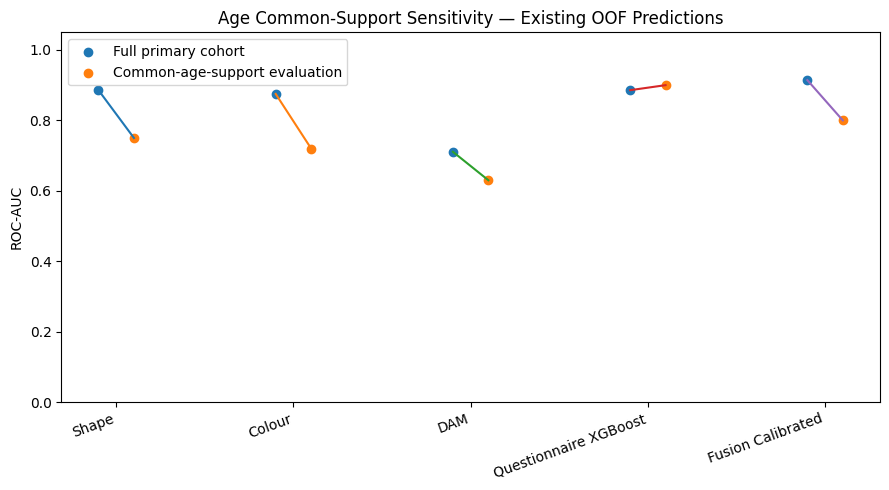


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell21_age_balance_full_vs_common_support.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell21_age_common_support_participants.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell21_age_common_support_oof_performance.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell21_age_common_support_auc_bootstrap_ci.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell21_model_score_age_spearman.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell21_age_common_support_nested_cv_feasibility.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell21_age_common_support_auc_sensitivity.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell21_age_sensitivity_protocol.csv

AGE COMMON-SUPPORT SENSITIVITY SUMMARY

Common observed support: (4.0, 8.0)
Secondary evaluation p

In [ ]:
# ============================================================
# CELL 21 — AGE COMMON-SUPPORT SENSITIVITY AUDIT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    mannwhitneyu,
    spearmanr
)

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold


print("=" * 78)
print("CELL 21 — AGE COMMON-SUPPORT SENSITIVITY AUDIT")
print("=" * 78)


# ============================================================
# 1. LOCK PRIMARY COHORT — NO CHANGE
# ============================================================

print("\nPRIMARY COHORT STATUS")

print(
    "Primary cohort participants:",
    N_FINAL
)

print(
    "Primary cohort changed by this cell:",
    False
)

print(
    "Primary models retrained in this cell:",
    False
)

print(
    "Age used as a primary predictor:",
    False
)


# ============================================================
# 2. VERIFY AGE AVAILABILITY
# ============================================================

age_values = pd.to_numeric(
    final_cohort_df[
        "Age"
    ],
    errors="coerce"
).to_numpy(
    dtype=float
)


age_available = np.isfinite(
    age_values
)


print("\nAGE AVAILABILITY")

print(
    "Participants with recorded age:",
    int(
        age_available.sum()
    ),
    "/",
    N_FINAL
)


if not age_available.all():

    print(
        "Participants without recorded age are retained "
        "in the primary analysis but cannot enter this "
        "age-specific sensitivity analysis."
    )


# ============================================================
# 3. OBSERVED AGE RANGES BY GROUP
# ============================================================

td_age_values = age_values[
    (y == 0)
    &
    age_available
]


asd_age_values = age_values[
    (y == 1)
    &
    age_available
]


if (
    len(
        td_age_values
    ) == 0
    or
    len(
        asd_age_values
    ) == 0
):

    raise RuntimeError(
        "Both ASD and TD must have recorded ages "
        "for the age sensitivity audit."
    )


td_age_min = float(
    np.min(
        td_age_values
    )
)

td_age_max = float(
    np.max(
        td_age_values
    )
)


asd_age_min = float(
    np.min(
        asd_age_values
    )
)

asd_age_max = float(
    np.max(
        asd_age_values
    )
)


COMMON_AGE_LOW = max(
    td_age_min,
    asd_age_min
)


COMMON_AGE_HIGH = min(
    td_age_max,
    asd_age_max
)


print("\nOBSERVED AGE RANGES")

print(
    "TD age range:",
    (
        td_age_min,
        td_age_max
    )
)

print(
    "ASD age range:",
    (
        asd_age_min,
        asd_age_max
    )
)

print(
    "Common observed age support:",
    (
        COMMON_AGE_LOW,
        COMMON_AGE_HIGH
    )
)


if COMMON_AGE_LOW > COMMON_AGE_HIGH:

    raise RuntimeError(
        "ASD and TD groups have no overlapping "
        "observed age support."
    )


# ============================================================
# 4. DEFINE SECONDARY COMMON-SUPPORT EVALUATION SUBSET
#
# This is NOT a change to the primary cohort.
# ============================================================

age_common_support_mask = (

    age_available

    &

    (
        age_values
        >=
        COMMON_AGE_LOW
    )

    &

    (
        age_values
        <=
        COMMON_AGE_HIGH
    )
)


age_common_support_indices = np.where(
    age_common_support_mask
)[0]


age_common_support_y = y[
    age_common_support_indices
]


age_common_support_ages = age_values[
    age_common_support_indices
]


age_common_support_ids = cohort_ids[
    age_common_support_indices
]


age_common_support_groups = groups[
    age_common_support_indices
]


age_overlap_class_counts = np.bincount(
    age_common_support_y,
    minlength=2
)


print("\nCOMMON-SUPPORT SECONDARY EVALUATION SET")

print(
    "Participants:",
    len(
        age_common_support_indices
    )
)

print(
    "TD:",
    int(
        age_overlap_class_counts[
            0
        ]
    )
)

print(
    "ASD:",
    int(
        age_overlap_class_counts[
            1
        ]
    )
)

print(
    "Primary cohort participants outside common support:",
    int(
        N_FINAL
        -
        len(
            age_common_support_indices
        )
    )
)

print(
    "Primary cohort remains:",
    N_FINAL
)


if age_overlap_class_counts.min() == 0:

    raise RuntimeError(
        "Common-support subset does not contain "
        "both diagnostic groups."
    )


# ============================================================
# 5. PARTICIPANT TABLE
# ============================================================

age_common_support_participants_df = pd.DataFrame({

    "Participant_ID":
        age_common_support_ids,

    "Group":
        age_common_support_groups,

    "Age":
        age_common_support_ages,

    "Original_Outer_Fold":
        outer_test_assignment[
            age_common_support_indices
        ]
})


age_common_support_participants_df = (

    age_common_support_participants_df

    .sort_values(
        [
            "Age",
            "Group",
            "Participant_ID"
        ]
    )

    .reset_index(
        drop=True
    )
)


print("\nCOMMON-SUPPORT PARTICIPANTS")

display(
    age_common_support_participants_df
)


# ============================================================
# 6. AGE-BALANCE FUNCTION
# ============================================================

def calculate_age_balance(
    subset_indices,
    analysis_name
):

    subset_indices = np.asarray(
        subset_indices,
        dtype=int
    )


    subset_y = y[
        subset_indices
    ]


    subset_age = age_values[
        subset_indices
    ]


    valid = np.isfinite(
        subset_age
    )


    subset_y = subset_y[
        valid
    ]


    subset_age = subset_age[
        valid
    ]


    td_age = subset_age[
        subset_y == 0
    ]


    asd_age = subset_age[
        subset_y == 1
    ]


    if (
        len(
            td_age
        ) == 0
        or
        len(
            asd_age
        ) == 0
    ):

        raise RuntimeError(
            f"{analysis_name}: both groups required."
        )


    # --------------------------------------------------------
    # Pooled standard deviation
    # --------------------------------------------------------

    if (
        len(
            td_age
        ) >= 2
        and
        len(
            asd_age
        ) >= 2
    ):

        pooled_variance = (

            (
                len(
                    td_age
                )
                -
                1
            )

            *
            np.var(
                td_age,
                ddof=1
            )

            +

            (
                len(
                    asd_age
                )
                -
                1
            )

            *
            np.var(
                asd_age,
                ddof=1
            )

        ) / (

            len(
                td_age
            )

            +

            len(
                asd_age
            )

            -

            2
        )


        pooled_sd_value = float(
            np.sqrt(
                pooled_variance
            )
        )

    else:

        pooled_sd_value = np.nan


    if (
        np.isfinite(
            pooled_sd_value
        )
        and
        pooled_sd_value > 0
    ):

        smd = float(

            (
                np.mean(
                    asd_age
                )

                -

                np.mean(
                    td_age
                )
            )

            /

            pooled_sd_value
        )

    else:

        smd = np.nan


    # --------------------------------------------------------
    # Mann-Whitney
    # --------------------------------------------------------

    mw = mannwhitneyu(

        asd_age,

        td_age,

        alternative="two-sided"
    )


    # --------------------------------------------------------
    # Age-only AUC
    # --------------------------------------------------------

    age_auc_raw = float(
        roc_auc_score(
            subset_y,
            subset_age
        )
    )


    age_auc_direction_independent = float(
        max(
            age_auc_raw,
            1.0
            -
            age_auc_raw
        )
    )


    return {

        "Analysis":
            analysis_name,

        "N":
            len(
                subset_age
            ),

        "TD_N":
            len(
                td_age
            ),

        "ASD_N":
            len(
                asd_age
            ),

        "TD_Age_Mean":
            float(
                np.mean(
                    td_age
                )
            ),

        "ASD_Age_Mean":
            float(
                np.mean(
                    asd_age
                )
            ),

        "TD_Age_Median":
            float(
                np.median(
                    td_age
                )
            ),

        "ASD_Age_Median":
            float(
                np.median(
                    asd_age
                )
            ),

        "TD_Age_Min":
            float(
                np.min(
                    td_age
                )
            ),

        "TD_Age_Max":
            float(
                np.max(
                    td_age
                )
            ),

        "ASD_Age_Min":
            float(
                np.min(
                    asd_age
                )
            ),

        "ASD_Age_Max":
            float(
                np.max(
                    asd_age
                )
            ),

        "Age_Standardized_Mean_Difference":
            smd,

        "Mann_Whitney_U":
            float(
                mw.statistic
            ),

        "Mann_Whitney_P":
            float(
                mw.pvalue
            ),

        "Age_Only_Raw_AUC":
            age_auc_raw,

        "Age_Only_Direction_Independent_AUC":
            age_auc_direction_independent
    }


# ============================================================
# 7. FULL COHORT VS COMMON SUPPORT AGE BALANCE
# ============================================================

full_age_indices = np.where(
    age_available
)[0]


age_balance_df = pd.DataFrame([

    calculate_age_balance(

        full_age_indices,

        "Full primary cohort"
    ),

    calculate_age_balance(

        age_common_support_indices,

        "Common-age-support sensitivity subset"
    )
])


print("\nAGE BALANCE — FULL VS COMMON SUPPORT")

display(
    age_balance_df.round(
        6
    )
)


# ============================================================
# 8. LOCK MODEL PROBABILITIES FOR SENSITIVITY ANALYSIS
# ============================================================

AGE_SENSITIVITY_MODEL_PROBABILITIES = {

    "Shape":
        np.asarray(
            shape_oof_probability,
            dtype=float
        ),

    "Colour":
        np.asarray(
            colour_oof_probability,
            dtype=float
        ),

    "DAM":
        np.asarray(
            dam_oof_probability,
            dtype=float
        ),

    "Questionnaire XGBoost":
        np.asarray(
            questionnaire_xgb_oof_probability,
            dtype=float
        ),

    "Fusion Calibrated":
        np.asarray(
            fusion_oof_probability,
            dtype=float
        ),

    "Questionnaire LR Baseline":
        np.asarray(
            questionnaire_lr_oof_probability,
            dtype=float
        )
}


for model_name, probability in (
    AGE_SENSITIVITY_MODEL_PROBABILITIES.items()
):

    validate_oof_probabilities(
        probability
    )


# ============================================================
# 9. COMMON-SUPPORT OOF PERFORMANCE
#
# IMPORTANT:
# These are the existing held-out OOF predictions evaluated
# only among common-support participants.
# Models are NOT retrained here.
# ============================================================

age_overlap_performance_records = []


for model_name, probability in (
    AGE_SENSITIVITY_MODEL_PROBABILITIES.items()
):

    full_metrics = compute_binary_metrics(

        y,

        probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    overlap_metrics = compute_binary_metrics(

        age_common_support_y,

        probability[
            age_common_support_indices
        ],

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    age_overlap_performance_records.append({

        "Model":
            model_name,

        "Full_N":
            N_FINAL,

        "Common_Support_N":
            len(
                age_common_support_indices
            ),

        "Full_Accuracy":
            full_metrics[
                "Accuracy"
            ],

        "Common_Support_Accuracy":
            overlap_metrics[
                "Accuracy"
            ],

        "Full_Balanced_Accuracy":
            full_metrics[
                "Balanced_Accuracy"
            ],

        "Common_Support_Balanced_Accuracy":
            overlap_metrics[
                "Balanced_Accuracy"
            ],

        "Full_Sensitivity":
            full_metrics[
                "Sensitivity"
            ],

        "Common_Support_Sensitivity":
            overlap_metrics[
                "Sensitivity"
            ],

        "Full_Specificity":
            full_metrics[
                "Specificity"
            ],

        "Common_Support_Specificity":
            overlap_metrics[
                "Specificity"
            ],

        "Full_ROC_AUC":
            full_metrics[
                "ROC_AUC"
            ],

        "Common_Support_ROC_AUC":
            overlap_metrics[
                "ROC_AUC"
            ],

        "AUC_Change_Common_Minus_Full":
            (
                overlap_metrics[
                    "ROC_AUC"
                ]

                -

                full_metrics[
                    "ROC_AUC"
                ]
            ),

        "Full_PR_AUC":
            full_metrics[
                "PR_AUC"
            ],

        "Common_Support_PR_AUC":
            overlap_metrics[
                "PR_AUC"
            ]
    })


age_overlap_performance_df = pd.DataFrame(
    age_overlap_performance_records
)


print("\nCOMMON-AGE-SUPPORT OOF PERFORMANCE")

display(
    age_overlap_performance_df.round(
        6
    )
)


print(
    "\nNOTE: These are restricted evaluations of existing OOF "
    "predictions, not models retrained on the age-overlap subset."
)


# ============================================================
# 10. STRATIFIED BOOTSTRAP AUC CI WITHIN COMMON SUPPORT
# ============================================================

AGE_SENSITIVITY_BOOTSTRAP_REPS = int(
    BOOTSTRAP_REPS
)


AGE_SENSITIVITY_BOOTSTRAP_SEED = (
    SEED
    +
    23000
)


age_bootstrap_rng = np.random.default_rng(
    AGE_SENSITIVITY_BOOTSTRAP_SEED
)


overlap_td_local = np.where(
    age_common_support_y == 0
)[0]


overlap_asd_local = np.where(
    age_common_support_y == 1
)[0]


age_overlap_auc_bootstrap_records = []


for model_name, probability in (
    AGE_SENSITIVITY_MODEL_PROBABILITIES.items()
):

    subset_probability = probability[
        age_common_support_indices
    ]


    bootstrap_auc_values = np.empty(
        AGE_SENSITIVITY_BOOTSTRAP_REPS,
        dtype=float
    )


    for bootstrap_index in range(
        AGE_SENSITIVITY_BOOTSTRAP_REPS
    ):

        sampled_td = age_bootstrap_rng.choice(

            overlap_td_local,

            size=len(
                overlap_td_local
            ),

            replace=True
        )


        sampled_asd = age_bootstrap_rng.choice(

            overlap_asd_local,

            size=len(
                overlap_asd_local
            ),

            replace=True
        )


        sampled_local_indices = np.concatenate(
            [
                sampled_td,
                sampled_asd
            ]
        )


        bootstrap_auc_values[
            bootstrap_index
        ] = roc_auc_score(

            age_common_support_y[
                sampled_local_indices
            ],

            subset_probability[
                sampled_local_indices
            ]
        )


    ci_lower = float(
        np.quantile(
            bootstrap_auc_values,
            0.025
        )
    )


    ci_upper = float(
        np.quantile(
            bootstrap_auc_values,
            0.975
        )
    )


    observed_overlap_auc = float(
        roc_auc_score(
            age_common_support_y,
            subset_probability
        )
    )


    age_overlap_auc_bootstrap_records.append({

        "Model":
            model_name,

        "Common_Support_N":
            len(
                age_common_support_indices
            ),

        "TD_N":
            len(
                overlap_td_local
            ),

        "ASD_N":
            len(
                overlap_asd_local
            ),

        "ROC_AUC":
            observed_overlap_auc,

        "CI_95_Lower":
            ci_lower,

        "CI_95_Upper":
            ci_upper,

        "Bootstrap_Repetitions":
            AGE_SENSITIVITY_BOOTSTRAP_REPS
    })


age_overlap_auc_ci_df = pd.DataFrame(
    age_overlap_auc_bootstrap_records
)


print("\nCOMMON-SUPPORT ROC-AUC WITH 95% BOOTSTRAP CI")

display(
    age_overlap_auc_ci_df.round(
        6
    )
)


# ============================================================
# 11. SCORE–AGE ASSOCIATION
#
# Overall association can be driven by diagnostic-group
# differences, so within-group correlations are also reported.
# ============================================================

score_age_correlation_records = []


for model_name, probability in (
    AGE_SENSITIVITY_MODEL_PROBABILITIES.items()
):

    for analysis_scope, scope_mask in [

        (
            "Full cohort — all participants",
            age_available
        ),

        (
            "Full cohort — TD only",
            age_available
            &
            (y == 0)
        ),

        (
            "Full cohort — ASD only",
            age_available
            &
            (y == 1)
        ),

        (
            "Common support — all participants",
            age_common_support_mask
        ),

        (
            "Common support — TD only",
            age_common_support_mask
            &
            (y == 0)
        ),

        (
            "Common support — ASD only",
            age_common_support_mask
            &
            (y == 1)
        )
    ]:

        scope_indices = np.where(
            scope_mask
        )[0]


        if len(
            scope_indices
        ) < 3:

            rho = np.nan
            p_value = np.nan

        else:

            correlation_result = spearmanr(

                age_values[
                    scope_indices
                ],

                probability[
                    scope_indices
                ]
            )


            rho = float(
                correlation_result.statistic
            )


            p_value = float(
                correlation_result.pvalue
            )


        score_age_correlation_records.append({

            "Model":
                model_name,

            "Scope":
                analysis_scope,

            "N":
                len(
                    scope_indices
                ),

            "Spearman_Rho":
                rho,

            "Raw_P_Value":
                p_value,

            "Interpretation":
                (
                    "Descriptive confounding diagnostic; "
                    "not a primary hypothesis test."
                )
        })


score_age_correlation_df = pd.DataFrame(
    score_age_correlation_records
)


print("\nMODEL SCORE–AGE SPEARMAN ASSOCIATIONS")

display(
    score_age_correlation_df.round(
        6
    )
)


# ============================================================
# 12. CHECK WHETHER LOCKED 5x5 RETRAINING IS FEASIBLE
# ============================================================

AGE_OVERLAP_RETRAINING_FEASIBLE = True

age_overlap_cv_records = []


if age_overlap_class_counts.min() < OUTER_FOLDS:

    AGE_OVERLAP_RETRAINING_FEASIBLE = False


else:

    age_overlap_outer_cv = StratifiedKFold(

        n_splits=OUTER_FOLDS,

        shuffle=True,

        random_state=SEED
    )


    age_overlap_outer_splits = list(

        age_overlap_outer_cv.split(

            np.zeros(
                len(
                    age_common_support_y
                )
            ),

            age_common_support_y
        )
    )


    for fold_number, (
        train_local,
        test_local
    ) in enumerate(

        age_overlap_outer_splits,

        start=1
    ):

        train_counts = np.bincount(

            age_common_support_y[
                train_local
            ],

            minlength=2
        )


        test_counts = np.bincount(

            age_common_support_y[
                test_local
            ],

            minlength=2
        )


        inner_supported = bool(

            train_counts.min()
            >=
            INNER_FOLDS
        )


        if not inner_supported:

            AGE_OVERLAP_RETRAINING_FEASIBLE = False


        age_overlap_cv_records.append({

            "Outer_Fold":
                fold_number,

            "Train_N":
                len(
                    train_local
                ),

            "Train_TD":
                int(
                    train_counts[
                        0
                    ]
                ),

            "Train_ASD":
                int(
                    train_counts[
                        1
                    ]
                ),

            "Test_N":
                len(
                    test_local
                ),

            "Test_TD":
                int(
                    test_counts[
                        0
                    ]
                ),

            "Test_ASD":
                int(
                    test_counts[
                        1
                    ]
                ),

            "Locked_Inner_5Fold_Supported":
                inner_supported
        })


age_overlap_cv_feasibility_df = pd.DataFrame(
    age_overlap_cv_records
)


print("\nCOMMON-SUPPORT LOCKED 5x5 RETRAINING FEASIBILITY")

print(
    "Common-support TD:",
    int(
        age_overlap_class_counts[
            0
        ]
    )
)

print(
    "Common-support ASD:",
    int(
        age_overlap_class_counts[
            1
        ]
    )
)


if len(
    age_overlap_cv_feasibility_df
) > 0:

    display(
        age_overlap_cv_feasibility_df
    )


print(
    "Locked 5-fold outer / 5-fold inner retraining feasible:",
    AGE_OVERLAP_RETRAINING_FEASIBLE
)


# ============================================================
# 13. AUC SENSITIVITY FIGURE
# ============================================================

primary_age_plot_models = [

    "Shape",
    "Colour",
    "DAM",
    "Questionnaire XGBoost",
    "Fusion Calibrated"
]


plot_df = age_overlap_performance_df[

    age_overlap_performance_df[
        "Model"
    ].isin(
        primary_age_plot_models
    )

].copy()


plot_df = plot_df.set_index(
    "Model"
).loc[
    primary_age_plot_models
].reset_index()


x_positions = np.arange(
    len(
        plot_df
    )
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


ax.scatter(

    x_positions - 0.10,

    plot_df[
        "Full_ROC_AUC"
    ],

    label="Full primary cohort"
)


ax.scatter(

    x_positions + 0.10,

    plot_df[
        "Common_Support_ROC_AUC"
    ],

    label="Common-age-support evaluation"
)


for position, row in plot_df.iterrows():

    ax.plot(

        [
            position - 0.10,
            position + 0.10
        ],

        [
            row[
                "Full_ROC_AUC"
            ],
            row[
                "Common_Support_ROC_AUC"
            ]
        ]
    )


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(

    plot_df[
        "Model"
    ],

    rotation=20,

    ha="right"
)


ax.set_ylim(
    0.0,
    1.05
)


ax.set_ylabel(
    "ROC-AUC"
)


ax.set_title(
    "Age Common-Support Sensitivity — Existing OOF Predictions"
)


ax.legend()


fig.tight_layout()


age_sensitivity_figure_file = (

    FIGURES_DIR
    /
    "cell21_age_common_support_auc_sensitivity.png"
)


fig.savefig(

    age_sensitivity_figure_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. SAVE OUTPUTS
# ============================================================

age_balance_file = (
    AUDIT_DIR
    /
    "cell21_age_balance_full_vs_common_support.csv"
)


age_common_support_participants_file = (
    AUDIT_DIR
    /
    "cell21_age_common_support_participants.csv"
)


age_overlap_performance_file = (
    RESULTS_DIR
    /
    "cell21_age_common_support_oof_performance.csv"
)


age_overlap_auc_ci_file = (
    RESULTS_DIR
    /
    "cell21_age_common_support_auc_bootstrap_ci.csv"
)


score_age_correlation_file = (
    AUDIT_DIR
    /
    "cell21_model_score_age_spearman.csv"
)


age_overlap_cv_feasibility_file = (
    AUDIT_DIR
    /
    "cell21_age_common_support_nested_cv_feasibility.csv"
)


age_balance_df.to_csv(
    age_balance_file,
    index=False
)


age_common_support_participants_df.to_csv(
    age_common_support_participants_file,
    index=False
)


age_overlap_performance_df.to_csv(
    age_overlap_performance_file,
    index=False
)


age_overlap_auc_ci_df.to_csv(
    age_overlap_auc_ci_file,
    index=False
)


score_age_correlation_df.to_csv(
    score_age_correlation_file,
    index=False
)


age_overlap_cv_feasibility_df.to_csv(
    age_overlap_cv_feasibility_file,
    index=False
)


# ============================================================
# 15. SAVE AGE-SENSITIVITY PROTOCOL
# ============================================================

age_sensitivity_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Primary cohort changed",

        "Value":
            False
    },

    {
        "Setting":
            "Primary models retrained in Cell 21",

        "Value":
            False
    },

    {
        "Setting":
            "Common-support lower bound",

        "Value":
            COMMON_AGE_LOW
    },

    {
        "Setting":
            "Common-support upper bound",

        "Value":
            COMMON_AGE_HIGH
    },

    {
        "Setting":
            "Common-support definition",

        "Value":
            (
                "Intersection of observed ASD and TD "
                "age ranges"
            )
    },

    {
        "Setting":
            "Performance used to select age interval",

        "Value":
            False
    },

    {
        "Setting":
            "Age used as classifier predictor",

        "Value":
            False
    },

    {
        "Setting":
            "Sensitivity evaluation type",

        "Value":
            (
                "Restricted evaluation of existing "
                "held-out OOF predictions"
            )
    },

    {
        "Setting":
            "Bootstrap repetitions",

        "Value":
            AGE_SENSITIVITY_BOOTSTRAP_REPS
    },

    {
        "Setting":
            "Locked 5x5 retraining feasible",

        "Value":
            AGE_OVERLAP_RETRAINING_FEASIBLE
    }
])


age_sensitivity_protocol_file = (
    MANIFEST_DIR
    /
    "cell21_age_sensitivity_protocol.csv"
)


age_sensitivity_protocol_df.to_csv(
    age_sensitivity_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    age_balance_file
)

print(
    age_common_support_participants_file
)

print(
    age_overlap_performance_file
)

print(
    age_overlap_auc_ci_file
)

print(
    score_age_correlation_file
)

print(
    age_overlap_cv_feasibility_file
)

print(
    age_sensitivity_figure_file
)

print(
    age_sensitivity_protocol_file
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

full_balance_row = age_balance_df[
    age_balance_df[
        "Analysis"
    ]
    ==
    "Full primary cohort"
].iloc[
    0
]


overlap_balance_row = age_balance_df[
    age_balance_df[
        "Analysis"
    ]
    ==
    "Common-age-support sensitivity subset"
].iloc[
    0
]


print("\n" + "=" * 78)
print("AGE COMMON-SUPPORT SENSITIVITY SUMMARY")


print(
    "\nCommon observed support:",
    (
        COMMON_AGE_LOW,
        COMMON_AGE_HIGH
    )
)


print(
    "Secondary evaluation participants:",
    len(
        age_common_support_indices
    )
)


print(
    "TD:",
    int(
        age_overlap_class_counts[
            0
        ]
    )
)

print(
    "ASD:",
    int(
        age_overlap_class_counts[
            1
        ]
    )
)


print(
    "\nFull-cohort age SMD:",
    round(
        float(
            full_balance_row[
                "Age_Standardized_Mean_Difference"
            ]
        ),
        6
    )
)


print(
    "Common-support age SMD:",
    round(
        float(
            overlap_balance_row[
                "Age_Standardized_Mean_Difference"
            ]
        ),
        6
    )
)


print(
    "Full-cohort age-only AUC:",
    round(
        float(
            full_balance_row[
                "Age_Only_Direction_Independent_AUC"
            ]
        ),
        6
    )
)


print(
    "Common-support age-only AUC:",
    round(
        float(
            overlap_balance_row[
                "Age_Only_Direction_Independent_AUC"
            ]
        ),
        6
    )
)


print(
    "\nLocked 5x5 age-overlap model retraining feasible:",
    AGE_OVERLAP_RETRAINING_FEASIBLE
)


print(
    "Primary cohort changed:",
    False
)

print(
    "Primary model results replaced:",
    False
)

print(
    "Age used as primary predictor:",
    False
)


print("\nCELL 21 STATUS: PASS")
print("=" * 78)

# 22. Fully Nested Fusion Ablation Analysis

This stage evaluates the contribution of each modality to the multimodal
fusion model.

The four primary late-fusion inputs are:

- Shape probability;
- Colour probability;
- Draw-a-Man probability;
- Questionnaire XGBoost probability.

Four leave-one-modality-out ablations are evaluated:

1. No Shape
2. No Colour
3. No DAM
4. No Questionnaire

`No Questionnaire` is also the drawing-only multimodal model because it
contains Shape, Colour and Draw-a-Man only.

## Leakage control

The ablations reuse only the leakage-safe outer-fold artifacts generated in
Cell 18:

- cross-fitted outer-training base probabilities;
- untouched outer-test base probabilities.

The globally pooled unimodal OOF vectors are not used for meta-training.

For every outer fold and every ablation:

1. the omitted modality column is removed;
2. L2 Logistic Regression is tuned using only the outer-training
   cross-fitted meta-features;
3. training-only cross-fitting generates calibration decision scores;
4. a Platt calibrator is fitted using outer-training data only;
5. the resulting model predicts the untouched outer-test participants.

Thus every ablation follows the same meta-model and calibration procedure as
the primary fusion model.

## Interpretation

Ablation performance is exploratory.

If removing a modality produces a numerically higher AUC, this does not by
itself demonstrate that the omitted modality is harmful.

Paired bootstrap confidence intervals for the difference between Full Fusion
and each ablation are therefore reported.

A modality will not be described as beneficial or detrimental unless the
uncertainty analysis supports that interpretation.

CELL 22 — FULLY NESTED FUSION ABLATION ANALYSIS

SAFE NESTED FUSION ARTIFACTS
Outer folds available: 5
Expected: 5

LOCKED ABLATIONS
No Shape          :  ['Colour', 'DAM', 'Questionnaire XGBoost']
No Colour         :  ['Shape', 'DAM', 'Questionnaire XGBoost']
No DAM            :  ['Shape', 'Colour', 'Questionnaire XGBoost']
No Questionnaire  :  ['Shape', 'Colour', 'DAM']

Drawing-only fusion: No Questionnaire

ABLATION 1/4 — No Shape
Fold 1: C=0.001, inner AUC=0.9667, test AUC=1.0000
Fold 2: C=0.001, inner AUC=0.9778, test AUC=1.0000
Fold 3: C=0.001, inner AUC=0.9667, test AUC=1.0000
Fold 4: C=0.001, inner AUC=0.9778, test AUC=0.6667
Fold 5: C=0.001, inner AUC=1.0000, test AUC=0.7500

ABLATION 2/4 — No Colour
Fold 1: C=0.001, inner AUC=1.0000, test AUC=1.0000
Fold 2: C=1, inner AUC=0.9667, test AUC=1.0000
Fold 3: C=0.001, inner AUC=0.9667, test AUC=1.0000
Fold 4: C=100, inner AUC=0.9556, test AUC=0.6667
Fold 5: C=0.001, inner AUC=1.0000, test AUC=0.7500

ABLATION 3/4 — No DAM
Fold 1: C

,Model,Omitted_Modality,Included_Modalities,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP,AUC_Change_vs_Full
0,Full Fusion,None,Shape; Colour; DAM; Questionnaire XGBoost,0.5,0.882353,0.878571,0.857143,0.857143,0.9,0.857143,0.914286,0.941176,18,2,2,12,0.000000
1,No Shape,Shape,Colour; DAM; Questionnaire XGBoost,0.5,0.794118,0.750000,1.000000,0.500000,1.0,0.666667,0.878571,0.885702,20,0,7,7,-0.035714
2,No Colour,Colour,Shape; DAM; Questionnaire XGBoost,0.5,0.764706,0.735714,0.800000,0.571429,0.9,0.666667,0.803571,0.778546,18,2,6,8,-0.110714
3,No DAM,DAM,Shape; Colour; Questionnaire XGBoost,0.5,0.911765,0.914286,0.866667,0.928571,0.9,0.896552,0.928571,0.957983,18,2,1,13,0.014286
4,No Questionnaire,Questionnaire,Shape; Colour; DAM,0.5,0.823529,0.828571,0.750000,0.857143,0.8,0.800000,0.853571,0.884861,16,4,2,12,-0.060714



Paired bootstrap sets: 1000

PAIRED AUC-DIFFERENCE BOOTSTRAP


,Ablation,Full_Fusion_AUC,Ablation_AUC,Full_Minus_Ablation_AUC,CI_95_Lower,CI_95_Upper,CI_Excludes_Zero
0,No Shape,0.914286,0.878571,0.035714,-0.128571,0.196429,False
1,No Colour,0.914286,0.803571,0.110714,0.017768,0.228571,True
2,No DAM,0.914286,0.928571,-0.014286,-0.057143,0.000000,False
3,No Questionnaire,0.914286,0.853571,0.060714,-0.007143,0.171429,False



ABLATION INTERPRETATION


,Ablation,Omitted_Modality,Interpretation,Exploratory_Only
0,No Shape,Shape,Full Fusion had numerically higher AUC than No...,True
1,No Colour,Colour,"Full Fusion had higher AUC than No Colour, and...",True
2,No DAM,DAM,No DAM had numerically higher AUC than Full Fu...,True
3,No Questionnaire,Questionnaire,Full Fusion had numerically higher AUC than No...,True


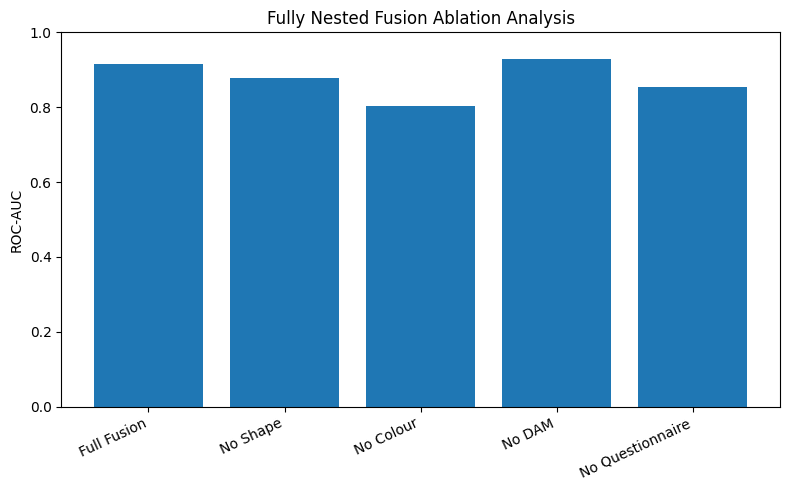


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell22_fusion_ablation_metrics.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell22_fusion_ablation_outer_fold_results.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell22_fusion_ablation_oof_predictions.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell22_fusion_ablation_auc_difference_ci.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell22_fusion_ablation_bootstrap_replicates.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell22_fusion_ablation_meta_tuning.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell22_fusion_ablation_calibration.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell22_fusion_ablation_interpretation.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell22_fusion_ablation_auc.png
/content/drive/My

In [ ]:
# ============================================================
# CELL 22 — FULLY NESTED FUSION ABLATION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold


print("=" * 78)
print("CELL 22 — FULLY NESTED FUSION ABLATION ANALYSIS")
print("=" * 78)


# ============================================================
# 1. VERIFY REQUIRED SAFE FUSION ARTIFACTS
# ============================================================

if "FUSION_OUTER_ARTIFACTS" not in globals():

    raise RuntimeError(
        "FUSION_OUTER_ARTIFACTS is unavailable. "
        "Rerun Cell 18 before Cell 22."
    )


if len(
    FUSION_OUTER_ARTIFACTS
) != OUTER_FOLDS:

    raise RuntimeError(
        "Unexpected number of stored fusion outer-fold artifacts."
    )


print("\nSAFE NESTED FUSION ARTIFACTS")

print(
    "Outer folds available:",
    len(
        FUSION_OUTER_ARTIFACTS
    )
)

print(
    "Expected:",
    OUTER_FOLDS
)


# ============================================================
# 2. LOCK ABLATION DEFINITIONS
#
# Column order from Cell 18:
# 0 = Shape
# 1 = Colour
# 2 = DAM
# 3 = Questionnaire XGBoost
# ============================================================

FUSION_ABLATIONS = {

    "No Shape":
        [
            1,
            2,
            3
        ],

    "No Colour":
        [
            0,
            2,
            3
        ],

    "No DAM":
        [
            0,
            1,
            3
        ],

    "No Questionnaire":
        [
            0,
            1,
            2
        ]
}


ABLATION_INCLUDED_BRANCHES = {

    "No Shape":
        [
            "Colour",
            "DAM",
            "Questionnaire XGBoost"
        ],

    "No Colour":
        [
            "Shape",
            "DAM",
            "Questionnaire XGBoost"
        ],

    "No DAM":
        [
            "Shape",
            "Colour",
            "Questionnaire XGBoost"
        ],

    "No Questionnaire":
        [
            "Shape",
            "Colour",
            "DAM"
        ]
}


print("\nLOCKED ABLATIONS")

for ablation_name in FUSION_ABLATIONS:

    print(
        f"{ablation_name:18s}: ",
        ABLATION_INCLUDED_BRANCHES[
            ablation_name
        ]
    )


print(
    "\nDrawing-only fusion:",
    "No Questionnaire"
)


# ============================================================
# 3. RESULT STORAGE
# ============================================================

ablation_oof_probabilities = {

    ablation_name:
        np.full(
            N_FINAL,
            np.nan,
            dtype=float
        )

    for ablation_name
    in FUSION_ABLATIONS
}


ablation_oof_raw_probabilities = {

    ablation_name:
        np.full(
            N_FINAL,
            np.nan,
            dtype=float
        )

    for ablation_name
    in FUSION_ABLATIONS
}


ablation_oof_predictions = {

    ablation_name:
        np.full(
            N_FINAL,
            -1,
            dtype=int
        )

    for ablation_name
    in FUSION_ABLATIONS
}


ablation_fold_records = []

ablation_meta_tuning_records = []

ablation_calibration_records = []


# ============================================================
# 4. RUN EACH ABLATION USING STORED SAFE META-FEATURES
# ============================================================

for ablation_number, (
    ablation_name,
    retained_columns
) in enumerate(

    FUSION_ABLATIONS.items(),

    start=1
):

    print(
        "\n"
        +
        "=" * 72
    )

    print(
        f"ABLATION {ablation_number}/{len(FUSION_ABLATIONS)} "
        f"— {ablation_name}"
    )

    print(
        "=" * 72
    )


    for outer_fold_number in range(
        1,
        OUTER_FOLDS + 1
    ):

        artifact = FUSION_OUTER_ARTIFACTS[
            outer_fold_number
        ]


        outer_train_idx = artifact[
            "outer_train_idx"
        ]


        outer_test_idx = artifact[
            "outer_test_idx"
        ]


        y_outer_train = artifact[
            "y_outer_train"
        ]


        y_outer_test = artifact[
            "y_outer_test"
        ]


        full_meta_train = artifact[
            "meta_train_features"
        ]


        full_meta_test = artifact[
            "meta_test_features"
        ]


        meta_train = full_meta_train[
            :,
            retained_columns
        ]


        meta_test = full_meta_test[
            :,
            retained_columns
        ]


        if meta_train.shape[1] != 3:

            raise RuntimeError(
                "Each leave-one-modality-out ablation "
                "must contain exactly three meta-features."
            )


        if (
            not np.isfinite(
                meta_train
            ).all()

            or

            not np.isfinite(
                meta_test
            ).all()
        ):

            raise RuntimeError(
                f"{ablation_name}, fold {outer_fold_number}: "
                "non-finite meta-features."
            )


        outer_inner_splits = (
            INNER_SPLITS_BY_OUTER[
                outer_fold_number
            ]
        )


        # ====================================================
        # 4A. TUNE/FIT ABLATION META-CLASSIFIER
        # ====================================================

        ablation_grid = tune_logistic_regression(

            meta_train,

            y_outer_train,

            outer_inner_splits
        )


        best_ablation_model = (
            ablation_grid.best_estimator_
        )


        best_ablation_C = float(

            ablation_grid.best_params_[
                "classifier__C"
            ]
        )


        best_ablation_inner_auc = float(
            ablation_grid.best_score_
        )


        raw_test_probability = (
            positive_class_probability(

                best_ablation_model,

                meta_test
            )
        )


        # ====================================================
        # 4B. TRAINING-ONLY CALIBRATION
        #
        # Match Cell 18's meta-level calibration procedure.
        # ====================================================

        n_outer_train = len(
            outer_train_idx
        )


        calibration_scores = np.full(
            n_outer_train,
            np.nan,
            dtype=float
        )


        calibration_filled = np.zeros(
            n_outer_train,
            dtype=bool
        )


        calibration_cv = StratifiedKFold(

            n_splits=INNER_FOLDS,

            shuffle=True,

            random_state=(
                SEED
                +
                19000
                +
                outer_fold_number
            )
        )


        calibration_splits = list(

            calibration_cv.split(

                np.zeros(
                    n_outer_train
                ),

                y_outer_train
            )
        )


        for calibration_fold_number, (
            calibration_train_local,
            calibration_valid_local
        ) in enumerate(

            calibration_splits,

            start=1
        ):

            y_calibration_train = (
                y_outer_train[
                    calibration_train_local
                ]
            )


            calibration_subinner = (
                make_subinner_splits(

                    y_calibration_train,

                    seed=(
                        SEED
                        +
                        22000
                        +
                        ablation_number * 1000
                        +
                        outer_fold_number * 100
                        +
                        calibration_fold_number
                    )
                )
            )


            calibration_grid = (
                tune_logistic_regression(

                    meta_train[
                        calibration_train_local
                    ],

                    y_calibration_train,

                    calibration_subinner
                )
            )


            calibration_model = (
                calibration_grid.best_estimator_
            )


            heldout_decision_scores = (
                calibration_model
                .decision_function(

                    meta_train[
                        calibration_valid_local
                    ]
                )
            )


            calibration_scores[
                calibration_valid_local
            ] = heldout_decision_scores


            calibration_filled[
                calibration_valid_local
            ] = True


        if not calibration_filled.all():

            raise RuntimeError(
                f"{ablation_name}, fold {outer_fold_number}: "
                "calibration cross-fitting incomplete."
            )


        if not np.isfinite(
            calibration_scores
        ).all():

            raise RuntimeError(
                f"{ablation_name}, fold {outer_fold_number}: "
                "non-finite calibration scores."
            )


        platt_calibrator = fit_platt_calibrator(

            calibration_scores,

            y_outer_train,

            seed=(
                SEED
                +
                23000
                +
                ablation_number * 100
                +
                outer_fold_number
            )
        )


        test_decision_scores = (
            best_ablation_model
            .decision_function(
                meta_test
            )
        )


        calibrated_test_probability = (

            platt_calibrator

            .predict_proba(

                np.asarray(
                    test_decision_scores
                ).reshape(
                    -1,
                    1
                )
            )[
                :,
                1
            ]
        )


        if not np.isfinite(
            calibrated_test_probability
        ).all():

            raise RuntimeError(
                f"{ablation_name}, fold {outer_fold_number}: "
                "non-finite calibrated probabilities."
            )


        # ====================================================
        # 4C. STORE HELD-OUT PREDICTIONS
        # ====================================================

        if np.any(

            np.isfinite(

                ablation_oof_probabilities[
                    ablation_name
                ][
                    outer_test_idx
                ]
            )
        ):

            raise RuntimeError(
                "An ablation participant is being "
                "predicted more than once."
            )


        ablation_oof_raw_probabilities[
            ablation_name
        ][
            outer_test_idx
        ] = raw_test_probability


        ablation_oof_probabilities[
            ablation_name
        ][
            outer_test_idx
        ] = calibrated_test_probability


        ablation_oof_predictions[
            ablation_name
        ][
            outer_test_idx
        ] = (

            calibrated_test_probability
            >=
            PRIMARY_BINARY_THRESHOLD
        ).astype(
            int
        )


        # ====================================================
        # 4D. FOLD METRICS
        # ====================================================

        raw_fold_metrics = compute_binary_metrics(

            y_outer_test,

            raw_test_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )


        calibrated_fold_metrics = compute_binary_metrics(

            y_outer_test,

            calibrated_test_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )


        print(
            f"Fold {outer_fold_number}: "
            f"C={best_ablation_C:g}, "
            f"inner AUC={best_ablation_inner_auc:.4f}, "
            f"test AUC={calibrated_fold_metrics['ROC_AUC']:.4f}"
        )


        ablation_fold_records.append({

            "Ablation":
                ablation_name,

            "Outer_Fold":
                outer_fold_number,

            "Train_N":
                len(
                    outer_train_idx
                ),

            "Test_N":
                len(
                    outer_test_idx
                ),

            "Retained_Branches":
                "; ".join(
                    ABLATION_INCLUDED_BRANCHES[
                        ablation_name
                    ]
                ),

            "Selected_Meta_C":
                best_ablation_C,

            "Best_Meta_Inner_ROC_AUC":
                best_ablation_inner_auc,

            "Raw_Outer_Test_ROC_AUC":
                raw_fold_metrics[
                    "ROC_AUC"
                ],

            "Calibrated_Outer_Test_ROC_AUC":
                calibrated_fold_metrics[
                    "ROC_AUC"
                ],

            "Calibrated_Outer_Test_Accuracy":
                calibrated_fold_metrics[
                    "Accuracy"
                ],

            "Calibrated_Outer_Test_Sensitivity":
                calibrated_fold_metrics[
                    "Sensitivity"
                ],

            "Calibrated_Outer_Test_Specificity":
                calibrated_fold_metrics[
                    "Specificity"
                ],

            "Platt_Coefficient":
                float(
                    platt_calibrator.coef_[
                        0,
                        0
                    ]
                ),

            "Platt_Intercept":
                float(
                    platt_calibrator.intercept_[
                        0
                    ]
                )
        })


        # ====================================================
        # 4E. TUNING GRID RECORD
        # ====================================================

        ablation_cv_results = (
            ablation_grid.cv_results_
        )


        for candidate_index in range(
            len(
                ablation_cv_results[
                    "params"
                ]
            )
        ):

            ablation_meta_tuning_records.append({

                "Ablation":
                    ablation_name,

                "Outer_Fold":
                    outer_fold_number,

                "C":
                    float(
                        ablation_cv_results[
                            "param_classifier__C"
                        ][
                            candidate_index
                        ]
                    ),

                "Mean_Inner_ROC_AUC":
                    float(
                        ablation_cv_results[
                            "mean_test_score"
                        ][
                            candidate_index
                        ]
                    ),

                "Std_Inner_ROC_AUC":
                    float(
                        ablation_cv_results[
                            "std_test_score"
                        ][
                            candidate_index
                        ]
                    ),

                "Rank":
                    int(
                        ablation_cv_results[
                            "rank_test_score"
                        ][
                            candidate_index
                        ]
                    )
            })


        ablation_calibration_records.append({

            "Ablation":
                ablation_name,

            "Outer_Fold":
                outer_fold_number,

            "Training_Calibration_N":
                len(
                    calibration_scores
                ),

            "Calibration_Score_Min":
                float(
                    calibration_scores.min()
                ),

            "Calibration_Score_Max":
                float(
                    calibration_scores.max()
                ),

            "Outer_Test_Probability_Min":
                float(
                    calibrated_test_probability.min()
                ),

            "Outer_Test_Probability_Max":
                float(
                    calibrated_test_probability.max()
                )
        })


# ============================================================
# 5. COMPLETENESS / INTEGRITY AUDIT
# ============================================================

print("\n" + "-" * 72)
print("ABLATION OOF COMPLETENESS AUDIT")
print("-" * 72)


for ablation_name in FUSION_ABLATIONS:

    calibrated_probability = (
        ablation_oof_probabilities[
            ablation_name
        ]
    )


    raw_probability = (
        ablation_oof_raw_probabilities[
            ablation_name
        ]
    )


    prediction = (
        ablation_oof_predictions[
            ablation_name
        ]
    )


    validate_oof_probabilities(
        calibrated_probability
    )


    validate_oof_probabilities(
        raw_probability
    )


    if np.any(
        prediction < 0
    ):

        raise RuntimeError(
            f"{ablation_name}: incomplete binary predictions."
        )


    print(
        f"{ablation_name:18s}: "
        f"{np.isfinite(calibrated_probability).sum()}/{N_FINAL} "
        "held-out predictions — PASS"
    )


# ============================================================
# 6. OVERALL ABLATION METRICS
# ============================================================

ablation_metric_records = []


# Full primary fusion first.
ablation_metric_records.append({

    "Model":
        "Full Fusion",

    "Omitted_Modality":
        "None",

    "Included_Modalities":
        (
            "Shape; Colour; DAM; "
            "Questionnaire XGBoost"
        ),

    **compute_binary_metrics(

        y,

        fusion_oof_probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )
})


for ablation_name in FUSION_ABLATIONS:

    metrics = compute_binary_metrics(

        y,

        ablation_oof_probabilities[
            ablation_name
        ],

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    omitted_modality = (
        ablation_name.replace(
            "No ",
            ""
        )
    )


    ablation_metric_records.append({

        "Model":
            ablation_name,

        "Omitted_Modality":
            omitted_modality,

        "Included_Modalities":
            "; ".join(
                ABLATION_INCLUDED_BRANCHES[
                    ablation_name
                ]
            ),

        **metrics
    })


ablation_metrics_df = pd.DataFrame(
    ablation_metric_records
)


full_fusion_auc = float(

    ablation_metrics_df.loc[
        ablation_metrics_df[
            "Model"
        ]
        ==
        "Full Fusion",

        "ROC_AUC"

    ].iloc[
        0
    ]
)


ablation_metrics_df[
    "AUC_Change_vs_Full"
] = (

    ablation_metrics_df[
        "ROC_AUC"
    ]

    -

    full_fusion_auc
)


print("\nFULL FUSION + LEAVE-ONE-MODALITY-OUT RESULTS")

display(
    ablation_metrics_df.round(
        6
    )
)


# ============================================================
# 7. BUILD / VERIFY PAIRED BOOTSTRAP INDEX SETS
# ============================================================

if "BOOTSTRAP_INDEX_SETS" in globals():

    ablation_bootstrap_index_sets = (
        BOOTSTRAP_INDEX_SETS
    )


else:

    ablation_bootstrap_rng = np.random.default_rng(
        SEED
        +
        22000
    )


    ablation_bootstrap_index_sets = []


    td_indices_local = np.where(
        y == 0
    )[0]


    asd_indices_local = np.where(
        y == 1
    )[0]


    for _ in range(
        BOOTSTRAP_REPS
    ):

        sampled_td = (
            ablation_bootstrap_rng.choice(

                td_indices_local,

                size=len(
                    td_indices_local
                ),

                replace=True
            )
        )


        sampled_asd = (
            ablation_bootstrap_rng.choice(

                asd_indices_local,

                size=len(
                    asd_indices_local
                ),

                replace=True
            )
        )


        sample = np.concatenate(
            [
                sampled_td,
                sampled_asd
            ]
        )


        sample = ablation_bootstrap_rng.permutation(
            sample
        )


        ablation_bootstrap_index_sets.append(
            sample
        )


print(
    "\nPaired bootstrap sets:",
    len(
        ablation_bootstrap_index_sets
    )
)


# ============================================================
# 8. PAIRED FULL-FUSION MINUS ABLATION AUC CIs
# ============================================================

ablation_difference_records = []

ablation_bootstrap_long_records = []


for ablation_name in FUSION_ABLATIONS:

    ablation_probability = (
        ablation_oof_probabilities[
            ablation_name
        ]
    )


    point_ablation_auc = float(
        roc_auc_score(
            y,
            ablation_probability
        )
    )


    point_difference = (
        full_fusion_auc
        -
        point_ablation_auc
    )


    bootstrap_differences = []


    for bootstrap_number, sampled_indices in enumerate(

        ablation_bootstrap_index_sets,

        start=1
    ):

        full_bootstrap_auc = roc_auc_score(

            y[
                sampled_indices
            ],

            fusion_oof_probability[
                sampled_indices
            ]
        )


        ablation_bootstrap_auc = roc_auc_score(

            y[
                sampled_indices
            ],

            ablation_probability[
                sampled_indices
            ]
        )


        difference = (

            full_bootstrap_auc
            -
            ablation_bootstrap_auc
        )


        bootstrap_differences.append(
            difference
        )


        ablation_bootstrap_long_records.append({

            "Bootstrap":
                bootstrap_number,

            "Ablation":
                ablation_name,

            "Full_Minus_Ablation_AUC":
                difference
        })


    bootstrap_differences = np.asarray(
        bootstrap_differences,
        dtype=float
    )


    ci_lower = float(
        np.quantile(
            bootstrap_differences,
            0.025
        )
    )


    ci_upper = float(
        np.quantile(
            bootstrap_differences,
            0.975
        )
    )


    ablation_difference_records.append({

        "Ablation":
            ablation_name,

        "Full_Fusion_AUC":
            full_fusion_auc,

        "Ablation_AUC":
            point_ablation_auc,

        "Full_Minus_Ablation_AUC":
            point_difference,

        "CI_95_Lower":
            ci_lower,

        "CI_95_Upper":
            ci_upper,

        "CI_Excludes_Zero":
            bool(
                ci_lower > 0
                or
                ci_upper < 0
            )
    })


ablation_difference_df = pd.DataFrame(
    ablation_difference_records
)


print("\nPAIRED AUC-DIFFERENCE BOOTSTRAP")

display(
    ablation_difference_df.round(
        6
    )
)


# ============================================================
# 9. CAUTIOUS ABLATION INTERPRETATION
# ============================================================

ablation_interpretation_records = []


for _, row in ablation_difference_df.iterrows():

    difference = float(
        row[
            "Full_Minus_Ablation_AUC"
        ]
    )


    lower = float(
        row[
            "CI_95_Lower"
        ]
    )


    upper = float(
        row[
            "CI_95_Upper"
        ]
    )


    ablation_name = row[
        "Ablation"
    ]


    omitted = ablation_name.replace(
        "No ",
        ""
    )


    if (
        difference > 0
        and
        lower > 0
    ):

        interpretation = (
            f"Full Fusion had higher AUC than {ablation_name}, "
            f"and the paired bootstrap CI excluded zero. "
            f"This provides exploratory evidence that retaining "
            f"{omitted} contributed discrimination in this cohort."
        )


    elif (
        difference < 0
        and
        upper < 0
    ):

        interpretation = (
            f"{ablation_name} had higher AUC than Full Fusion "
            f"and the paired bootstrap CI excluded zero. "
            f"This would warrant further investigation, but does "
            f"not by itself establish that {omitted} is harmful."
        )


    elif difference > 0:

        interpretation = (
            f"Full Fusion had numerically higher AUC than "
            f"{ablation_name}, but the paired bootstrap interval "
            "included zero. No clear contribution claim is made."
        )


    elif difference < 0:

        interpretation = (
            f"{ablation_name} had numerically higher AUC than "
            "Full Fusion, but the paired bootstrap interval included "
            f"zero. Do not claim that {omitted} harms performance."
        )


    else:

        interpretation = (
            "Full Fusion and this ablation had identical "
            "observed ROC-AUC."
        )


    ablation_interpretation_records.append({

        "Ablation":
            ablation_name,

        "Omitted_Modality":
            omitted,

        "Interpretation":
            interpretation,

        "Exploratory_Only":
            True
    })


ablation_interpretation_df = pd.DataFrame(
    ablation_interpretation_records
)


print("\nABLATION INTERPRETATION")

display(
    ablation_interpretation_df
)


# ============================================================
# 10. PARTICIPANT-LEVEL ABLATION PREDICTIONS
# ============================================================

ablation_oof_df = pd.DataFrame({

    "Participant_ID":
        cohort_ids,

    "Group":
        groups,

    "y_true":
        y,

    "Outer_Fold":
        outer_test_assignment,

    "P_full_fusion_ASD":
        fusion_oof_probability
})


for ablation_name in FUSION_ABLATIONS:

    safe_name = (

        ablation_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    ablation_oof_df[
        f"P_{safe_name}_ASD"
    ] = (

        ablation_oof_probabilities[
            ablation_name
        ]
    )


# ============================================================
# 11. PLOT FULL + ABLATION AUCs
# ============================================================

plot_df = (

    ablation_metrics_df[
        [
            "Model",
            "ROC_AUC"
        ]
    ]

    .copy()
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5
    )
)


x_positions = np.arange(
    len(
        plot_df
    )
)


ax.bar(

    x_positions,

    plot_df[
        "ROC_AUC"
    ]
)


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(

    plot_df[
        "Model"
    ],

    rotation=25,

    ha="right"
)


ax.set_ylim(
    0.0,
    1.0
)


ax.set_ylabel(
    "ROC-AUC"
)


ax.set_title(
    "Fully Nested Fusion Ablation Analysis"
)


fig.tight_layout()


ablation_figure_file = (

    FIGURES_DIR
    /
    "cell22_fusion_ablation_auc.png"
)


fig.savefig(

    ablation_figure_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. SAVE RESULTS
# ============================================================

ablation_metrics_file = (
    RESULTS_DIR
    /
    "cell22_fusion_ablation_metrics.csv"
)


ablation_fold_file = (
    RESULTS_DIR
    /
    "cell22_fusion_ablation_outer_fold_results.csv"
)


ablation_oof_file = (
    RESULTS_DIR
    /
    "cell22_fusion_ablation_oof_predictions.csv"
)


ablation_difference_file = (
    RESULTS_DIR
    /
    "cell22_fusion_ablation_auc_difference_ci.csv"
)


ablation_bootstrap_file = (
    RESULTS_DIR
    /
    "cell22_fusion_ablation_bootstrap_replicates.csv"
)


ablation_meta_tuning_file = (
    AUDIT_DIR
    /
    "cell22_fusion_ablation_meta_tuning.csv"
)


ablation_calibration_file = (
    AUDIT_DIR
    /
    "cell22_fusion_ablation_calibration.csv"
)


ablation_interpretation_file = (
    AUDIT_DIR
    /
    "cell22_fusion_ablation_interpretation.csv"
)


ablation_metrics_df.to_csv(
    ablation_metrics_file,
    index=False
)


pd.DataFrame(
    ablation_fold_records
).to_csv(
    ablation_fold_file,
    index=False
)


ablation_oof_df.to_csv(
    ablation_oof_file,
    index=False
)


ablation_difference_df.to_csv(
    ablation_difference_file,
    index=False
)


pd.DataFrame(
    ablation_bootstrap_long_records
).to_csv(
    ablation_bootstrap_file,
    index=False
)


pd.DataFrame(
    ablation_meta_tuning_records
).to_csv(
    ablation_meta_tuning_file,
    index=False
)


pd.DataFrame(
    ablation_calibration_records
).to_csv(
    ablation_calibration_file,
    index=False
)


ablation_interpretation_df.to_csv(
    ablation_interpretation_file,
    index=False
)


# ============================================================
# 13. SAVE ABLATION PROTOCOL
# ============================================================

ablation_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Ablation type",

        "Value":
            "Leave one primary modality out"
    },

    {
        "Setting":
            "Ablations",

        "Value":
            (
                "No Shape; No Colour; "
                "No DAM; No Questionnaire"
            )
    },

    {
        "Setting":
            "Drawing-only model",

        "Value":
            "No Questionnaire"
    },

    {
        "Setting":
            "Base probabilities for meta-training",

        "Value":
            (
                "Leakage-safe cross-fitted probabilities "
                "from Cell 18"
            )
    },

    {
        "Setting":
            "Global unimodal OOF vectors used "
            "for meta-training",

        "Value":
            False
    },

    {
        "Setting":
            "Meta-classifier",

        "Value":
            "Scaled L2 Logistic Regression"
    },

    {
        "Setting":
            "Calibration",

        "Value":
            "Training-only Platt"
    },

    {
        "Setting":
            "Ablation inference",

        "Value":
            (
                "Exploratory paired stratified-bootstrap "
                "AUC-difference CI"
            )
    },

    {
        "Setting":
            "Claim omitted modality is harmful solely "
            "from higher ablation point estimate",

        "Value":
            False
    }
])


ablation_protocol_file = (
    MANIFEST_DIR
    /
    "cell22_fusion_ablation_protocol.csv"
)


ablation_protocol_df.to_csv(
    ablation_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    ablation_metrics_file
)

print(
    ablation_fold_file
)

print(
    ablation_oof_file
)

print(
    ablation_difference_file
)

print(
    ablation_bootstrap_file
)

print(
    ablation_meta_tuning_file
)

print(
    ablation_calibration_file
)

print(
    ablation_interpretation_file
)

print(
    ablation_figure_file
)

print(
    ablation_protocol_file
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

best_ablation_row = (

    ablation_metrics_df[
        ablation_metrics_df[
            "Model"
        ]
        !=
        "Full Fusion"
    ]

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .iloc[
        0
    ]
)


print("\n" + "=" * 78)
print("FUSION ABLATION SUMMARY")


print(
    "\nFull Fusion ROC-AUC:",
    round(
        full_fusion_auc,
        6
    )
)


print(
    "Best leave-one-out ablation:",
    best_ablation_row[
        "Model"
    ]
)


print(
    "Best ablation ROC-AUC:",
    round(
        float(
            best_ablation_row[
                "ROC_AUC"
            ]
        ),
        6
    )
)


print(
    "\nAblations with paired AUC-difference "
    "CI excluding zero:",
    ablation_difference_df.loc[
        ablation_difference_df[
            "CI_Excludes_Zero"
        ],
        "Ablation"
    ].tolist()
)


print(
    "Drawing-only model:",
    "No Questionnaire"
)


drawing_only_auc = float(

    ablation_metrics_df.loc[
        ablation_metrics_df[
            "Model"
        ]
        ==
        "No Questionnaire",
        "ROC_AUC"
    ].iloc[
        0
    ]
)


print(
    "Drawing-only ROC-AUC:",
    round(
        drawing_only_auc,
        6
    )
)


print(
    "Ablation conclusions treated as exploratory:",
    True
)


print(
    "Primary Full Fusion definition changed:",
    False
)


print("\nCELL 22 STATUS: PASS")
print("=" * 78)

# 23. Gender Subgroup Robustness Audit

This stage evaluates whether model performance appears materially different
across the recorded gender subgroups.

The primary models are not retrained and the primary cohort is unchanged.

Existing held-out out-of-fold predictions are evaluated separately within
each gender subgroup.

## Models examined

- Shape
- Colour
- Draw-a-Man
- Questionnaire XGBoost
- Fully nested calibrated Fusion

Questionnaire Logistic Regression is also reported as a baseline/sensitivity
model but remains outside the primary inference family.

## Analyses

For each gender subgroup the notebook reports:

- participant count;
- TD and ASD counts;
- accuracy;
- balanced accuracy;
- sensitivity;
- specificity;
- ROC-AUC;
- PR-AUC.

A stratified participant-level bootstrap is used to provide 95% confidence
intervals for ROC-AUC, sensitivity and specificity where both diagnostic
classes have sufficient observations.

Because subgroup sample sizes are small, the analysis is descriptive and
exploratory. It is not used to modify the primary models or choose different
thresholds for different genders.

No claim of demographic fairness or equal performance is made from this
internal cohort alone.

CELL 23 — GENDER SUBGROUP ROBUSTNESS AUDIT

GENDER METADATA
Source column: Gender
Observed normalized categories: ['F', 'M']

GROUP × GENDER COUNTS


Gender,F,M
Group,,
ASD,6,8
TD,9,11



SUBGROUP REPORTING SAFEGUARD
Minimum observations per diagnostic class for subgroup bootstrap: 5
Primary cohort exclusions caused by this safeguard: 0

GENDER SUBGROUP COMPOSITION


,Gender,N,TD_N,ASD_N,Both_Classes_Present,Bootstrap_Eligible
0,F,15,9,6,True,True
1,M,19,11,8,True,True



DESCRIPTIVE OOF PERFORMANCE BY GENDER


...

,Gender,Model,N,TD_N,ASD_N,Metric,Point_Estimate,CI_95_Lower,CI_95_Upper,Bootstrap_Repetitions,Status
0,F,Shape,15,9,6,ROC_AUC,0.907407,0.666667,1.000000,1000,ESTIMATED — EXPLORATORY
1,F,Shape,15,9,6,Sensitivity,0.833333,0.500000,1.000000,1000,ESTIMATED — EXPLORATORY
2,F,Shape,15,9,6,Specificity,0.888889,0.666667,1.000000,1000,ESTIMATED — EXPLORATORY
3,F,Colour,15,9,6,ROC_AUC,0.925926,0.722222,1.000000,1000,ESTIMATED — EXPLORATORY
4,F,Colour,15,9,6,Sensitivity,1.000000,1.000000,1.000000,1000,ESTIMATED — EXPLORATORY
5,F,Colour,15,9,6,Specificity,0.888889,0.666667,1.000000,1000,ESTIMATED — EXPLORATORY
6,F,DAM,15,9,6,ROC_AUC,0.666667,0.314815,0.962963,1000,ESTIMATED — EXPLORATORY
7,F,DAM,15,9,6,Sensitivity,0.666667,0.333333,1.000000,1000,ESTIMATED — EXPLORATORY
8,F,DAM,15,9,6,Specificity,0.333333,0.111111,0.666667,1000,ESTIMATED — EXPLORATORY
9,F,Questionnaire XGBoost,15,9,6,ROC_AUC,1.000000,1.000000,1.000000,1000,ESTIMATED — EXPLORATORY



PRIMARY MODEL BETWEEN-GENDER DIFFERENCES


,Model,Gender_A,Gender_B,AUC_A,AUC_B,AUC_A_Minus_B,Sensitivity_A,Sensitivity_B,Sensitivity_A_Minus_B,Specificity_A,Specificity_B,Specificity_A_Minus_B,Inference
0,Shape,F,M,0.907407,0.886364,0.021044,0.833333,0.875,-0.041667,0.888889,0.818182,0.070707,DESCRIPTIVE ONLY — NO SUBGROUP SUPERIORITY CLAIM
1,Colour,F,M,0.925926,0.806818,0.119108,1.000000,0.750,0.250000,0.888889,0.818182,0.070707,DESCRIPTIVE ONLY — NO SUBGROUP SUPERIORITY CLAIM
2,DAM,F,M,0.666667,0.795455,-0.128788,0.666667,0.750,-0.083333,0.333333,0.818182,-0.484848,DESCRIPTIVE ONLY — NO SUBGROUP SUPERIORITY CLAIM
3,Questionnaire XGBoost,F,M,1.000000,0.806818,0.193182,0.833333,0.625,0.208333,1.000000,0.909091,0.090909,DESCRIPTIVE ONLY — NO SUBGROUP SUPERIORITY CLAIM
4,Fusion Calibrated,F,M,1.000000,0.840909,0.159091,1.000000,0.750,0.250000,1.000000,0.818182,0.181818,DESCRIPTIVE ONLY — NO SUBGROUP SUPERIORITY CLAIM



GENDER SUBGROUP INTERPRETATION


,Gender,Status,Reason,Primary_Model_Changed,Gender_Specific_Threshold_Used,Fairness_Claim
0,F,EXPLORATORY SUBGROUP ESTIMATES AVAILABLE,Both diagnostic classes have at least five par...,False,False,False
1,M,EXPLORATORY SUBGROUP ESTIMATES AVAILABLE,Both diagnostic classes have at least five par...,False,False,False


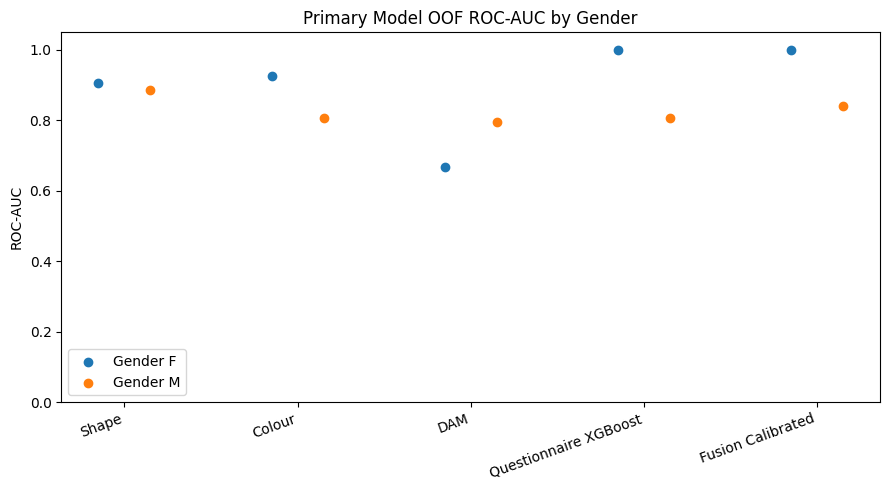


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell23_gender_subgroup_composition.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell23_gender_subgroup_performance.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell23_gender_subgroup_bootstrap_ci.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell23_gender_subgroup_differences.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell23_gender_subgroup_interpretation.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell23_gender_subgroup_auc.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell23_gender_subgroup_protocol.csv

GENDER SUBGROUP ROBUSTNESS SUMMARY

Gender F: N=15, TD=9, ASD=6, bootstrap eligible=True

Gender M: N=19, TD=11, ASD=8, bootstrap eligible=True

FUSION BY GENDER


,Gender,N,TD_N,ASD_N,Accuracy,Sensitivity,Specificity,ROC_AUC,PR_AUC
4,F,15,9,6,1.000000,1.00,1.000000,1.000000,1.000000
10,M,19,11,8,0.789474,0.75,0.818182,0.840909,0.890132



Gender-specific model fitting performed: False
Gender-specific thresholds used: False
Fairness/equivalence claimed: False
Site subgroup robustness available: False

CELL 23 STATUS: PASS


In [ ]:
# ============================================================
# CELL 23 — GENDER SUBGROUP ROBUSTNESS AUDIT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 78)
print("CELL 23 — GENDER SUBGROUP ROBUSTNESS AUDIT")
print("=" * 78)


# ============================================================
# 1. IDENTIFY GENDER METADATA COLUMN
# ============================================================

gender_column_candidates = [
    "Gender_Clean",
    "Gender",
    "gender",
    "Sex",
    "sex"
]


GENDER_COLUMN = None


for candidate in gender_column_candidates:

    if candidate in final_cohort_df.columns:

        GENDER_COLUMN = candidate
        break


if GENDER_COLUMN is None:

    raise RuntimeError(
        "No gender/sex metadata column was found in final_cohort_df."
    )


gender_raw = (
    final_cohort_df[
        GENDER_COLUMN
    ]
    .astype(str)
    .str.strip()
)


# ============================================================
# 2. CANONICALIZE GENDER VALUES
#
# Do not infer or fabricate categories.
# Recognized values are normalized only.
# ============================================================

def canonicalize_gender(
    value
):

    text = str(
        value
    ).strip().lower()


    if text in {
        "f",
        "female"
    }:

        return "F"


    if text in {
        "m",
        "male"
    }:

        return "M"


    if text in {
        "",
        "nan",
        "none",
        "<na>"
    }:

        return "Missing"


    return str(
        value
    ).strip()


gender_values = np.asarray(
    [
        canonicalize_gender(
            value
        )
        for value in gender_raw
    ],
    dtype="U"
)


print("\nGENDER METADATA")

print(
    "Source column:",
    GENDER_COLUMN
)

print(
    "Observed normalized categories:",
    sorted(
        np.unique(
            gender_values
        ).tolist()
    )
)


gender_count_df = pd.crosstab(

    pd.Series(
        groups,
        name="Group"
    ),

    pd.Series(
        gender_values,
        name="Gender"
    )
)


print("\nGROUP × GENDER COUNTS")

display(
    gender_count_df
)


# ============================================================
# 3. LOCK MODEL PROBABILITIES
# ============================================================

GENDER_MODEL_PROBABILITIES = {

    "Shape":
        np.asarray(
            shape_oof_probability,
            dtype=float
        ),

    "Colour":
        np.asarray(
            colour_oof_probability,
            dtype=float
        ),

    "DAM":
        np.asarray(
            dam_oof_probability,
            dtype=float
        ),

    "Questionnaire XGBoost":
        np.asarray(
            questionnaire_xgb_oof_probability,
            dtype=float
        ),

    "Fusion Calibrated":
        np.asarray(
            fusion_oof_probability,
            dtype=float
        ),

    "Questionnaire LR Baseline":
        np.asarray(
            questionnaire_lr_oof_probability,
            dtype=float
        )
}


for model_name, probabilities in (
    GENDER_MODEL_PROBABILITIES.items()
):

    validate_oof_probabilities(
        probabilities
    )


# ============================================================
# 4. SUBGROUP REPORTING SAFEGUARD
#
# This threshold is only a reporting safeguard.
# It does not alter inclusion in the primary analysis.
# ============================================================

MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP = 5


print("\nSUBGROUP REPORTING SAFEGUARD")

print(
    "Minimum observations per diagnostic class "
    "for subgroup bootstrap:",
    MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP
)

print(
    "Primary cohort exclusions caused by this safeguard:",
    0
)


# ============================================================
# 5. BASIC GENDER SUBGROUP COMPOSITION
# ============================================================

gender_composition_records = []


for gender_name in sorted(
    np.unique(
        gender_values
    )
):

    subgroup_mask = (
        gender_values
        ==
        gender_name
    )


    subgroup_y = y[
        subgroup_mask
    ]


    class_counts = np.bincount(
        subgroup_y,
        minlength=2
    )


    gender_composition_records.append({

        "Gender":
            gender_name,

        "N":
            int(
                subgroup_mask.sum()
            ),

        "TD_N":
            int(
                class_counts[0]
            ),

        "ASD_N":
            int(
                class_counts[1]
            ),

        "Both_Classes_Present":
            bool(
                np.all(
                    class_counts > 0
                )
            ),

        "Bootstrap_Eligible":
            bool(
                class_counts.min()
                >=
                MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP
            )
    })


gender_composition_df = pd.DataFrame(
    gender_composition_records
)


print("\nGENDER SUBGROUP COMPOSITION")

display(
    gender_composition_df
)


# ============================================================
# 6. DESCRIPTIVE PERFORMANCE BY GENDER
# ============================================================

gender_performance_records = []


for gender_name in sorted(
    np.unique(
        gender_values
    )
):

    subgroup_mask = (
        gender_values
        ==
        gender_name
    )


    subgroup_indices = np.where(
        subgroup_mask
    )[0]


    subgroup_y = y[
        subgroup_indices
    ]


    class_counts = np.bincount(
        subgroup_y,
        minlength=2
    )


    if np.any(
        class_counts == 0
    ):

        print(
            f"\nSkipping discrimination metrics for "
            f"gender '{gender_name}' because both "
            "diagnostic classes are not represented."
        )

        continue


    for model_name, probabilities in (
        GENDER_MODEL_PROBABILITIES.items()
    ):

        subgroup_probability = probabilities[
            subgroup_indices
        ]


        metrics = compute_binary_metrics(

            subgroup_y,

            subgroup_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )


        gender_performance_records.append({

            "Gender":
                gender_name,

            "Model":
                model_name,

            "N":
                len(
                    subgroup_indices
                ),

            "TD_N":
                int(
                    class_counts[0]
                ),

            "ASD_N":
                int(
                    class_counts[1]
                ),

            "Accuracy":
                metrics[
                    "Accuracy"
                ],

            "Balanced_Accuracy":
                metrics[
                    "Balanced_Accuracy"
                ],

            "Precision":
                metrics[
                    "Precision"
                ],

            "Sensitivity":
                metrics[
                    "Sensitivity"
                ],

            "Specificity":
                metrics[
                    "Specificity"
                ],

            "F1":
                metrics[
                    "F1"
                ],

            "ROC_AUC":
                metrics[
                    "ROC_AUC"
                ],

            "PR_AUC":
                metrics[
                    "PR_AUC"
                ],

            "TN":
                metrics[
                    "TN"
                ],

            "FP":
                metrics[
                    "FP"
                ],

            "FN":
                metrics[
                    "FN"
                ],

            "TP":
                metrics[
                    "TP"
                ]
        })


gender_performance_df = pd.DataFrame(
    gender_performance_records
)


print("\nDESCRIPTIVE OOF PERFORMANCE BY GENDER")

display(
    gender_performance_df.round(
        6
    )
)


# ============================================================
# 7. STRATIFIED BOOTSTRAP WITHIN EACH GENDER
#
# CIs are generated only when each diagnostic class has
# at least MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP participants.
# ============================================================

GENDER_BOOTSTRAP_REPS = int(
    BOOTSTRAP_REPS
)


GENDER_BOOTSTRAP_SEED = (
    SEED
    +
    24000
)


gender_bootstrap_rng = np.random.default_rng(
    GENDER_BOOTSTRAP_SEED
)


gender_ci_records = []


for gender_name in sorted(
    np.unique(
        gender_values
    )
):

    subgroup_indices = np.where(
        gender_values
        ==
        gender_name
    )[0]


    subgroup_y = y[
        subgroup_indices
    ]


    local_td = np.where(
        subgroup_y == 0
    )[0]


    local_asd = np.where(
        subgroup_y == 1
    )[0]


    bootstrap_eligible = bool(

        len(
            local_td
        )
        >=
        MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP

        and

        len(
            local_asd
        )
        >=
        MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP
    )


    for model_name, probabilities in (
        GENDER_MODEL_PROBABILITIES.items()
    ):

        subgroup_probability = probabilities[
            subgroup_indices
        ]


        if not bootstrap_eligible:

            gender_ci_records.append({

                "Gender":
                    gender_name,

                "Model":
                    model_name,

                "N":
                    len(
                        subgroup_indices
                    ),

                "TD_N":
                    len(
                        local_td
                    ),

                "ASD_N":
                    len(
                        local_asd
                    ),

                "Metric":
                    "ROC_AUC",

                "Point_Estimate":
                    np.nan,

                "CI_95_Lower":
                    np.nan,

                "CI_95_Upper":
                    np.nan,

                "Bootstrap_Repetitions":
                    0,

                "Status":
                    "NOT ESTIMATED — SMALL SUBGROUP CLASS COUNT"
            })

            continue


        bootstrap_auc = np.empty(
            GENDER_BOOTSTRAP_REPS,
            dtype=float
        )


        bootstrap_sensitivity = np.empty(
            GENDER_BOOTSTRAP_REPS,
            dtype=float
        )


        bootstrap_specificity = np.empty(
            GENDER_BOOTSTRAP_REPS,
            dtype=float
        )


        for bootstrap_index in range(
            GENDER_BOOTSTRAP_REPS
        ):

            sampled_td = gender_bootstrap_rng.choice(

                local_td,

                size=len(
                    local_td
                ),

                replace=True
            )


            sampled_asd = gender_bootstrap_rng.choice(

                local_asd,

                size=len(
                    local_asd
                ),

                replace=True
            )


            sampled_local = np.concatenate(
                [
                    sampled_td,
                    sampled_asd
                ]
            )


            sampled_y = subgroup_y[
                sampled_local
            ]


            sampled_probability = (
                subgroup_probability[
                    sampled_local
                ]
            )


            sampled_metrics = compute_binary_metrics(

                sampled_y,

                sampled_probability,

                threshold=
                    PRIMARY_BINARY_THRESHOLD
            )


            bootstrap_auc[
                bootstrap_index
            ] = sampled_metrics[
                "ROC_AUC"
            ]


            bootstrap_sensitivity[
                bootstrap_index
            ] = sampled_metrics[
                "Sensitivity"
            ]


            bootstrap_specificity[
                bootstrap_index
            ] = sampled_metrics[
                "Specificity"
            ]


        observed_metrics = compute_binary_metrics(

            subgroup_y,

            subgroup_probability,

            threshold=
                PRIMARY_BINARY_THRESHOLD
        )


        for metric_name, (
            point_estimate,
            bootstrap_values
        ) in {

            "ROC_AUC":
                (
                    observed_metrics[
                        "ROC_AUC"
                    ],
                    bootstrap_auc
                ),

            "Sensitivity":
                (
                    observed_metrics[
                        "Sensitivity"
                    ],
                    bootstrap_sensitivity
                ),

            "Specificity":
                (
                    observed_metrics[
                        "Specificity"
                    ],
                    bootstrap_specificity
                )
        }.items():

            gender_ci_records.append({

                "Gender":
                    gender_name,

                "Model":
                    model_name,

                "N":
                    len(
                        subgroup_indices
                    ),

                "TD_N":
                    len(
                        local_td
                    ),

                "ASD_N":
                    len(
                        local_asd
                    ),

                "Metric":
                    metric_name,

                "Point_Estimate":
                    float(
                        point_estimate
                    ),

                "CI_95_Lower":
                    float(
                        np.quantile(
                            bootstrap_values,
                            0.025
                        )
                    ),

                "CI_95_Upper":
                    float(
                        np.quantile(
                            bootstrap_values,
                            0.975
                        )
                    ),

                "Bootstrap_Repetitions":
                    GENDER_BOOTSTRAP_REPS,

                "Status":
                    "ESTIMATED — EXPLORATORY"
            })


gender_ci_df = pd.DataFrame(
    gender_ci_records
)


print("\nGENDER SUBGROUP BOOTSTRAP CIs")

display(
    gender_ci_df.round(
        6
    )
)


# ============================================================
# 8. PRIMARY MODEL GENDER DIFFERENCE SUMMARY
#
# Descriptive differences only.
# No significance test is claimed because subgroup N is small.
# ============================================================

primary_gender_models = [

    "Shape",
    "Colour",
    "DAM",
    "Questionnaire XGBoost",
    "Fusion Calibrated"
]


gender_categories_with_both_classes = (

    gender_composition_df.loc[
        gender_composition_df[
            "Both_Classes_Present"
        ],
        "Gender"
    ]
    .tolist()
)


gender_difference_records = []


if len(
    gender_categories_with_both_classes
) == 2:

    gender_a = (
        gender_categories_with_both_classes[
            0
        ]
    )


    gender_b = (
        gender_categories_with_both_classes[
            1
        ]
    )


    for model_name in primary_gender_models:

        row_a = gender_performance_df[
            (
                gender_performance_df[
                    "Gender"
                ]
                ==
                gender_a
            )
            &
            (
                gender_performance_df[
                    "Model"
                ]
                ==
                model_name
            )
        ]


        row_b = gender_performance_df[
            (
                gender_performance_df[
                    "Gender"
                ]
                ==
                gender_b
            )
            &
            (
                gender_performance_df[
                    "Model"
                ]
                ==
                model_name
            )
        ]


        if (
            len(
                row_a
            ) == 1
            and
            len(
                row_b
            ) == 1
        ):

            row_a = row_a.iloc[
                0
            ]


            row_b = row_b.iloc[
                0
            ]


            gender_difference_records.append({

                "Model":
                    model_name,

                "Gender_A":
                    gender_a,

                "Gender_B":
                    gender_b,

                "AUC_A":
                    float(
                        row_a[
                            "ROC_AUC"
                        ]
                    ),

                "AUC_B":
                    float(
                        row_b[
                            "ROC_AUC"
                        ]
                    ),

                "AUC_A_Minus_B":
                    float(
                        row_a[
                            "ROC_AUC"
                        ]
                        -
                        row_b[
                            "ROC_AUC"
                        ]
                    ),

                "Sensitivity_A":
                    float(
                        row_a[
                            "Sensitivity"
                        ]
                    ),

                "Sensitivity_B":
                    float(
                        row_b[
                            "Sensitivity"
                        ]
                    ),

                "Sensitivity_A_Minus_B":
                    float(
                        row_a[
                            "Sensitivity"
                        ]
                        -
                        row_b[
                            "Sensitivity"
                        ]
                    ),

                "Specificity_A":
                    float(
                        row_a[
                            "Specificity"
                        ]
                    ),

                "Specificity_B":
                    float(
                        row_b[
                            "Specificity"
                        ]
                    ),

                "Specificity_A_Minus_B":
                    float(
                        row_a[
                            "Specificity"
                        ]
                        -
                        row_b[
                            "Specificity"
                        ]
                    ),

                "Inference":
                    (
                        "DESCRIPTIVE ONLY — "
                        "NO SUBGROUP SUPERIORITY CLAIM"
                    )
            })


gender_difference_df = pd.DataFrame(
    gender_difference_records
)


print("\nPRIMARY MODEL BETWEEN-GENDER DIFFERENCES")

if len(
    gender_difference_df
) > 0:

    display(
        gender_difference_df.round(
            6
        )
    )

else:

    print(
        "A two-group descriptive difference table "
        "could not be constructed."
    )


# ============================================================
# 9. ROBUSTNESS INTERPRETATION TABLE
# ============================================================

gender_interpretation_records = []


for gender_name in sorted(
    np.unique(
        gender_values
    )
):

    composition_row = gender_composition_df[
        gender_composition_df[
            "Gender"
        ]
        ==
        gender_name
    ].iloc[
        0
    ]


    if not bool(
        composition_row[
            "Both_Classes_Present"
        ]
    ):

        status = (
            "NOT INTERPRETABLE FOR DISCRIMINATION"
        )

        reason = (
            "Only one diagnostic class is represented."
        )


    elif not bool(
        composition_row[
            "Bootstrap_Eligible"
        ]
    ):

        status = (
            "VERY SMALL SUBGROUP — DESCRIPTIVE ONLY"
        )

        reason = (
            "At least one diagnostic class contains "
            "fewer than five participants."
        )


    else:

        status = (
            "EXPLORATORY SUBGROUP ESTIMATES AVAILABLE"
        )

        reason = (
            "Both diagnostic classes have at least five "
            "participants, but sample size remains small."
        )


    gender_interpretation_records.append({

        "Gender":
            gender_name,

        "Status":
            status,

        "Reason":
            reason,

        "Primary_Model_Changed":
            False,

        "Gender_Specific_Threshold_Used":
            False,

        "Fairness_Claim":
            False
    })


gender_interpretation_df = pd.DataFrame(
    gender_interpretation_records
)


print("\nGENDER SUBGROUP INTERPRETATION")

display(
    gender_interpretation_df
)


# ============================================================
# 10. ROC-AUC FIGURE FOR PRIMARY MODELS
# ============================================================

plot_gender_df = gender_performance_df[

    gender_performance_df[
        "Model"
    ].isin(
        primary_gender_models
    )

].copy()


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


gender_plot_categories = sorted(
    plot_gender_df[
        "Gender"
    ].unique()
)


x_positions = np.arange(
    len(
        primary_gender_models
    )
)


offsets = np.linspace(

    -0.15,

    0.15,

    num=max(
        len(
            gender_plot_categories
        ),
        1
    )
)


for offset, gender_name in zip(
    offsets,
    gender_plot_categories
):

    subgroup_plot = (

        plot_gender_df[
            plot_gender_df[
                "Gender"
            ]
            ==
            gender_name
        ]

        .set_index(
            "Model"
        )

        .reindex(
            primary_gender_models
        )
    )


    ax.scatter(

        x_positions + offset,

        subgroup_plot[
            "ROC_AUC"
        ],

        label=f"Gender {gender_name}"
    )


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(

    primary_gender_models,

    rotation=20,

    ha="right"
)


ax.set_ylim(
    0.0,
    1.05
)


ax.set_ylabel(
    "ROC-AUC"
)


ax.set_title(
    "Primary Model OOF ROC-AUC by Gender"
)


ax.legend()


fig.tight_layout()


gender_auc_figure_file = (

    FIGURES_DIR
    /
    "cell23_gender_subgroup_auc.png"
)


fig.savefig(

    gender_auc_figure_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. SAVE RESULTS
# ============================================================

gender_composition_file = (
    AUDIT_DIR
    /
    "cell23_gender_subgroup_composition.csv"
)


gender_performance_file = (
    RESULTS_DIR
    /
    "cell23_gender_subgroup_performance.csv"
)


gender_ci_file = (
    RESULTS_DIR
    /
    "cell23_gender_subgroup_bootstrap_ci.csv"
)


gender_difference_file = (
    RESULTS_DIR
    /
    "cell23_gender_subgroup_differences.csv"
)


gender_interpretation_file = (
    AUDIT_DIR
    /
    "cell23_gender_subgroup_interpretation.csv"
)


gender_composition_df.to_csv(
    gender_composition_file,
    index=False
)


gender_performance_df.to_csv(
    gender_performance_file,
    index=False
)


gender_ci_df.to_csv(
    gender_ci_file,
    index=False
)


gender_difference_df.to_csv(
    gender_difference_file,
    index=False
)


gender_interpretation_df.to_csv(
    gender_interpretation_file,
    index=False
)


# ============================================================
# 12. SAVE SUBGROUP PROTOCOL
# ============================================================

gender_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Subgroup variable",

        "Value":
            GENDER_COLUMN
    },

    {
        "Setting":
            "Primary models retrained",

        "Value":
            False
    },

    {
        "Setting":
            "Primary cohort changed",

        "Value":
            False
    },

    {
        "Setting":
            "Primary threshold changed by gender",

        "Value":
            False
    },

    {
        "Setting":
            "Minimum class N for bootstrap reporting",

        "Value":
            MIN_SUBGROUP_CLASS_N_FOR_BOOTSTRAP
    },

    {
        "Setting":
            "Bootstrap repetitions",

        "Value":
            GENDER_BOOTSTRAP_REPS
    },

    {
        "Setting":
            "Subgroup superiority test",

        "Value":
            "Not performed — small exploratory subgroups"
    },

    {
        "Setting":
            "Fairness/equivalence claim",

        "Value":
            False
    },

    {
        "Setting":
            "Site subgroup analysis",

        "Value":
            "Unavailable — site metadata absent"
    }
])


gender_protocol_file = (
    MANIFEST_DIR
    /
    "cell23_gender_subgroup_protocol.csv"
)


gender_protocol_df.to_csv(
    gender_protocol_file,
    index=False
)


print("\nSAVED OUTPUTS")

print(
    gender_composition_file
)

print(
    gender_performance_file
)

print(
    gender_ci_file
)

print(
    gender_difference_file
)

print(
    gender_interpretation_file
)

print(
    gender_auc_figure_file
)

print(
    gender_protocol_file
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 78)
print("GENDER SUBGROUP ROBUSTNESS SUMMARY")


for _, row in gender_composition_df.iterrows():

    print(
        f"\nGender {row['Gender']}: "
        f"N={int(row['N'])}, "
        f"TD={int(row['TD_N'])}, "
        f"ASD={int(row['ASD_N'])}, "
        f"bootstrap eligible="
        f"{bool(row['Bootstrap_Eligible'])}"
    )


fusion_gender_rows = gender_performance_df[

    gender_performance_df[
        "Model"
    ]
    ==
    "Fusion Calibrated"
]


print("\nFUSION BY GENDER")

if len(
    fusion_gender_rows
) > 0:

    display(

        fusion_gender_rows[
            [
                "Gender",
                "N",
                "TD_N",
                "ASD_N",
                "Accuracy",
                "Sensitivity",
                "Specificity",
                "ROC_AUC",
                "PR_AUC"
            ]
        ]

        .round(
            6
        )
    )


print(
    "\nGender-specific model fitting performed:",
    False
)

print(
    "Gender-specific thresholds used:",
    False
)

print(
    "Fairness/equivalence claimed:",
    False
)

print(
    "Site subgroup robustness available:",
    False
)


print("\nCELL 23 STATUS: PASS")
print("=" * 78)

# 24. Questionnaire XGBoost — Out-of-Fold SHAP Explainability

The primary questionnaire model is XGBoost using the 25 raw Likert items.

Explainability is generated using SHAP.

## Out-of-fold explanation design

To avoid explaining predictions from a model that was trained on the same
participant, each participant is explained using the fitted XGBoost model
from that participant's locked outer test fold.

Therefore:

- every participant receives exactly one SHAP explanation;
- the explaining model did not train on that participant;
- the same held-out model that generated the participant's questionnaire OOF
  probability is used for the explanation.

This produces a genuine participant-level out-of-fold SHAP matrix.

## SHAP scale

TreeSHAP values are calculated on the XGBoost raw-margin scale.

For binary logistic XGBoost:

- positive SHAP values push the model toward the ASD class;
- negative SHAP values push the model toward the TD class.

The expected SHAP additivity relationship is checked:

`base value + sum(SHAP values) = model raw margin`

The reconstructed raw margin is also transformed through the logistic
function and checked against the saved out-of-fold ASD probability.

## Global interpretation

Global questionnaire importance is summarized by mean absolute out-of-fold
SHAP magnitude across all participants.

This measures the extent to which an item influenced this model's predictions
in the current cohort.

It must not be interpreted as:

- causal importance;
- diagnostic validity of an item;
- clinical importance;
- evidence that the questionnaire has been formally validated.

The previously identified recruitment/order confounding and lack of external
validation remain applicable.

CELL 24 — QUESTIONNAIRE XGBOOST OUT-OF-FOLD SHAP

QUESTIONNAIRE SHAP INPUT
Participants: 34
Items: 25
Explanation design: Out-of-fold
Model explained: Primary Questionnaire XGBoost
Questionnaire LR explained here: False

------------------------------------------------------------------------
QUESTIONNAIRE SHAP — OUTER FOLD 1/5
------------------------------------------------------------------------
Held-out participants: 7
OOF probability max diff: 0.0
SHAP additivity max diff: 9.238719940185547e-07
Raw-margin probability max diff: 2.272924348734051e-08

------------------------------------------------------------------------
QUESTIONNAIRE SHAP — OUTER FOLD 2/5
------------------------------------------------------------------------
Held-out participants: 7
OOF probability max diff: 0.0
SHAP additivity max diff: 7.003545761108398e-07
Raw-margin probability max diff: 1.1701590169055365e-08

------------------------------------------------------------------------
QUESTIONNAIRE SHAP — OU

,Item,Mean_Absolute_OOF_SHAP,Mean_Signed_OOF_SHAP,TD_Mean_Absolute_SHAP,ASD_Mean_Absolute_SHAP,TD_Mean_Signed_SHAP,ASD_Mean_Signed_SHAP,Global_Importance_Rank
0,item_23,0.703734,-0.035603,0.629528,0.809743,-0.529007,0.669262,1
1,item_1,0.481445,-0.163872,0.483803,0.478077,-0.311013,0.046331,2
2,item_25,0.337599,-0.048741,0.327006,0.352732,-0.220440,0.196543,3
3,item_21,0.164851,0.000939,0.166477,0.162527,-0.049704,0.073285,4
4,item_16,0.112794,-0.032979,0.110809,0.115630,-0.084363,0.040427,5
5,item_11,0.098224,-0.007919,0.098527,0.097791,-0.021768,0.011866,6
6,item_2,0.083750,0.019448,0.089744,0.075188,-0.019569,0.075188,7
7,item_17,0.077066,0.013423,0.072473,0.083626,-0.033465,0.080406,8
8,item_6,0.046357,-0.003757,0.045438,0.047669,0.002842,-0.013183,9
9,item_19,0.044712,-0.030503,0.042622,0.047698,-0.042622,-0.013190,10



PARTICIPANT-LEVEL TOP SHAP CONTRIBUTIONS — PREVIEW


,Participant_ID,Group,Outer_Fold,Questionnaire_OOF_Probability_ASD,Local_Rank,Item,Response,SHAP_Value_Raw_Margin,Absolute_SHAP,Direction
0,P006,TD,1,0.379961,1,item_25,2,1.065667,1.065667,Toward ASD
1,P006,TD,1,0.379961,2,item_23,4,-0.712219,0.712219,Toward TD
2,P006,TD,1,0.379961,3,item_16,1,-0.279177,0.279177,Toward TD
3,P006,TD,1,0.379961,4,item_1,2,-0.181557,0.181557,Toward TD
4,P006,TD,1,0.379961,5,item_5,4,0.000000,0.000000,Neutral
5,P007,TD,5,0.806623,1,item_1,3,1.727892,1.727892,Toward ASD
6,P007,TD,5,0.806623,2,item_2,3,0.000000,0.000000,Neutral
7,P007,TD,5,0.806623,3,item_3,2,0.000000,0.000000,Neutral
8,P007,TD,5,0.806623,4,item_4,4,0.000000,0.000000,Neutral
9,P007,TD,5,0.806623,5,item_5,4,0.000000,0.000000,Neutral


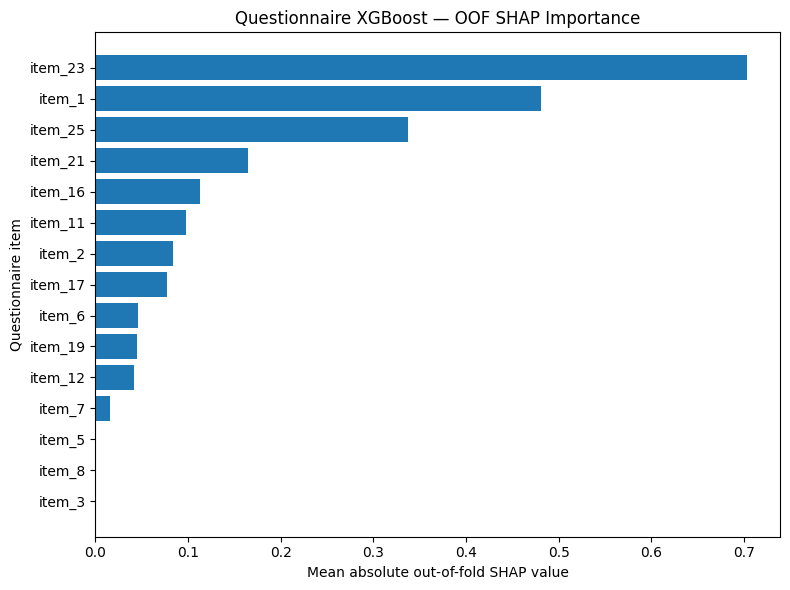

/tmp/ipykernel_2989/1331273920.py:1324: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


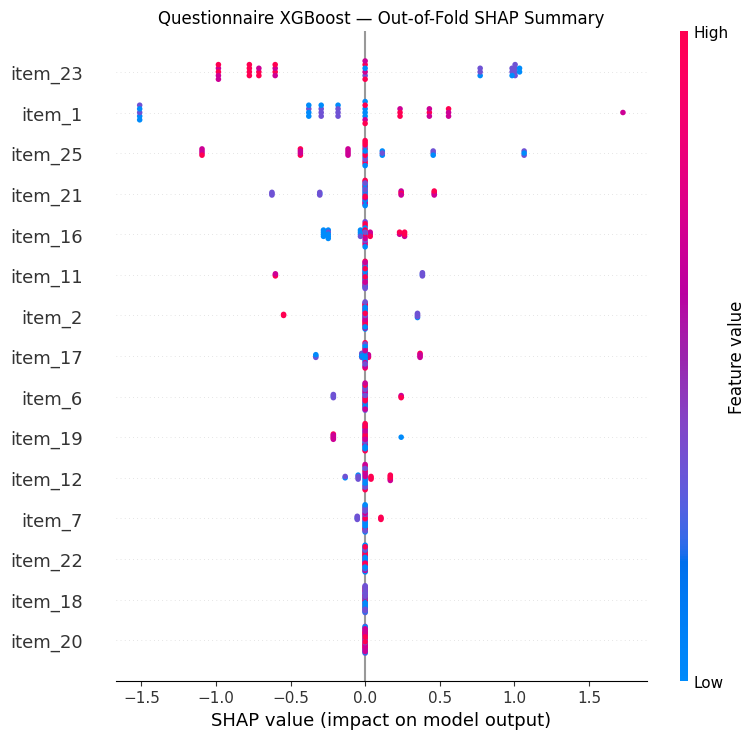


SHAP FOLD AUDIT


,Outer_Fold,Test_N,Model_File,OOF_Probability_Reproduction_Max_Diff,SHAP_Additivity_Max_Diff,RawMargin_Probability_Max_Diff,SHAP_Output_Scale
0,1,7,/content/drive/MyDrive/ASD Research/Final_ASD_...,0.0,9.239000e-07,2.270000e-08,XGBoost raw margin
1,2,7,/content/drive/MyDrive/ASD Research/Final_ASD_...,0.0,7.004000e-07,1.170000e-08,XGBoost raw margin
2,3,7,/content/drive/MyDrive/ASD Research/Final_ASD_...,0.0,3.688000e-07,4.070000e-08,XGBoost raw margin
3,4,7,/content/drive/MyDrive/ASD Research/Final_ASD_...,0.0,3.651000e-07,3.010000e-08,XGBoost raw margin
4,5,6,/content/drive/MyDrive/ASD Research/Final_ASD_...,0.0,3.576000e-07,3.620000e-08,XGBoost raw margin



SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell24_questionnaire_oof_shap.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell24_questionnaire_oof_shap_global_importance.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell24_questionnaire_oof_shap_local_top5.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell24_questionnaire_oof_shap_long.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell24_questionnaire_oof_shap_fold_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell24_questionnaire_oof_shap_importance.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell24_questionnaire_oof_shap_summary.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell24_questionnaire_oof_shap_protocol.csv

QUESTIONNAIRE OOF SHAP SUMMARY
Participants explained: 34 / 34
SHAP matrix shape: (34, 25)
Maximum 

,Global_Importance_Rank,Item,Mean_Absolute_OOF_SHAP,Mean_Signed_OOF_SHAP,TD_Mean_Signed_SHAP,ASD_Mean_Signed_SHAP
0,1,item_23,0.703734,-0.035603,-0.529007,0.669262
1,2,item_1,0.481445,-0.163872,-0.311013,0.046331
2,3,item_25,0.337599,-0.048741,-0.220440,0.196543
3,4,item_21,0.164851,0.000939,-0.049704,0.073285
4,5,item_16,0.112794,-0.032979,-0.084363,0.040427
5,6,item_11,0.098224,-0.007919,-0.021768,0.011866
6,7,item_2,0.083750,0.019448,-0.019569,0.075188
7,8,item_17,0.077066,0.013423,-0.033465,0.080406
8,9,item_6,0.046357,-0.003757,0.002842,-0.013183
9,10,item_19,0.044712,-0.030503,-0.042622,-0.013190



Causal item importance claimed: False
Clinical questionnaire validation claimed: False
Expert XAI validation completed: False

CELL 24 STATUS: PASS


In [ ]:
# ============================================================
# CELL 24 — QUESTIONNAIRE XGBOOST OUT-OF-FOLD SHAP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from joblib import load


print("=" * 78)
print("CELL 24 — QUESTIONNAIRE XGBOOST OUT-OF-FOLD SHAP")
print("=" * 78)


# ============================================================
# 1. LOCK EXPLAINABILITY INPUT
# ============================================================

X_q_shap = np.asarray(
    X_questionnaire,
    dtype=np.float32
)


if X_q_shap.shape != (
    N_FINAL,
    QUESTIONNAIRE_ITEM_COUNT
):

    raise RuntimeError(
        "Unexpected questionnaire matrix dimensions."
    )


if len(
    ITEM_COLS
) != QUESTIONNAIRE_ITEM_COUNT:

    raise RuntimeError(
        "Questionnaire item-name count does not equal 25."
    )


if len(
    questionnaire_xgb_model_files
) != OUTER_FOLDS:

    raise RuntimeError(
        "Expected one saved questionnaire XGBoost model "
        "for every outer fold."
    )


print("\nQUESTIONNAIRE SHAP INPUT")

print(
    "Participants:",
    X_q_shap.shape[0]
)

print(
    "Items:",
    X_q_shap.shape[1]
)

print(
    "Explanation design:",
    "Out-of-fold"
)

print(
    "Model explained:",
    "Primary Questionnaire XGBoost"
)

print(
    "Questionnaire LR explained here:",
    False
)


# ============================================================
# 2. STORAGE
# ============================================================

questionnaire_oof_shap_values = np.full(

    (
        N_FINAL,
        QUESTIONNAIRE_ITEM_COUNT
    ),

    np.nan,

    dtype=np.float64
)


questionnaire_oof_shap_base_value = np.full(
    N_FINAL,
    np.nan,
    dtype=np.float64
)


questionnaire_oof_shap_raw_margin = np.full(
    N_FINAL,
    np.nan,
    dtype=np.float64
)


questionnaire_oof_shap_probability = np.full(
    N_FINAL,
    np.nan,
    dtype=np.float64
)


questionnaire_shap_filled = np.zeros(
    N_FINAL,
    dtype=bool
)


questionnaire_shap_fold_records = []


# ============================================================
# 3. NUMERIC HELPERS
# ============================================================

def stable_sigmoid(
    values
):

    values = np.asarray(
        values,
        dtype=np.float64
    )


    result = np.empty_like(
        values
    )


    positive_mask = (
        values >= 0
    )


    result[
        positive_mask
    ] = (

        1.0

        /

        (
            1.0
            +
            np.exp(
                -values[
                    positive_mask
                ]
            )
        )
    )


    negative_values = values[
        ~positive_mask
    ]


    exp_values = np.exp(
        negative_values
    )


    result[
        ~positive_mask
    ] = (

        exp_values

        /

        (
            1.0
            +
            exp_values
        )
    )


    return result


def normalize_binary_shap_output(
    explanation,
    n_samples,
    n_features
):
    """
    Normalize SHAP output across compatible binary-output forms.

    Expected final result:
      values:      [n_samples, n_features]
      base_values: [n_samples]
    """

    values = np.asarray(
        explanation.values
    )


    base_values = np.asarray(
        explanation.base_values
    )


    # --------------------------------------------------------
    # Standard binary TreeSHAP form
    # --------------------------------------------------------

    if values.ndim == 2:

        if values.shape != (
            n_samples,
            n_features
        ):

            raise RuntimeError(
                "Unexpected two-dimensional SHAP shape: "
                f"{values.shape}"
            )


    # --------------------------------------------------------
    # Defensive support for explicit two-output representations
    # --------------------------------------------------------

    elif values.ndim == 3:

        if (
            values.shape[0] == n_samples
            and
            values.shape[1] == n_features
            and
            values.shape[2] == 2
        ):

            values = values[
                :,
                :,
                1
            ]


            if (
                base_values.ndim == 2
                and
                base_values.shape[1] == 2
            ):

                base_values = base_values[
                    :,
                    1
                ]


        elif (
            values.shape[0] == n_samples
            and
            values.shape[1] == 2
            and
            values.shape[2] == n_features
        ):

            values = values[
                :,
                1,
                :
            ]


            if (
                base_values.ndim == 2
                and
                base_values.shape[1] == 2
            ):

                base_values = base_values[
                    :,
                    1
                ]


        else:

            raise RuntimeError(
                "Unexpected three-dimensional SHAP shape: "
                f"{values.shape}"
            )


    else:

        raise RuntimeError(
            "Unexpected SHAP output dimensions: "
            f"{values.shape}"
        )


    # --------------------------------------------------------
    # Normalize base values
    # --------------------------------------------------------

    if base_values.ndim == 0:

        base_values = np.repeat(

            float(
                base_values
            ),

            n_samples
        )


    elif base_values.ndim == 1:

        if len(
            base_values
        ) == 1:

            base_values = np.repeat(

                float(
                    base_values[
                        0
                    ]
                ),

                n_samples
            )


        elif len(
            base_values
        ) != n_samples:

            raise RuntimeError(
                "Unexpected SHAP base-value length."
            )


    else:

        base_values = np.squeeze(
            base_values
        )


        if base_values.ndim != 1:

            raise RuntimeError(
                "Could not normalize SHAP base values."
            )


        if len(
            base_values
        ) != n_samples:

            raise RuntimeError(
                "Normalized SHAP base-value length mismatch."
            )


    return (
        values.astype(
            np.float64
        ),

        base_values.astype(
            np.float64
        )
    )


# ============================================================
# 4. OUTER-FOLD SHAP EXTRACTION
# ============================================================

SHAP_ADDITIVITY_TOLERANCE = 1e-4

SHAP_PROBABILITY_TOLERANCE = 1e-6


for outer_fold_number, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    OUTER_SPLITS,

    start=1
):

    print(
        "\n"
        +
        "-" * 72
    )

    print(
        f"QUESTIONNAIRE SHAP — OUTER FOLD "
        f"{outer_fold_number}/{OUTER_FOLDS}"
    )

    print(
        "-" * 72
    )


    if np.any(
        questionnaire_shap_filled[
            outer_test_idx
        ]
    ):

        raise RuntimeError(
            "A questionnaire participant is being "
            "explained more than once."
        )


    # --------------------------------------------------------
    # Load the exact held-out model from Cell 16
    # --------------------------------------------------------

    model_file = questionnaire_xgb_model_files[
        outer_fold_number
        -
        1
    ]


    fitted_xgb_model = load(
        model_file
    )


    X_test = X_q_shap[
        outer_test_idx
    ]


    # --------------------------------------------------------
    # Reproduce saved OOF probabilities first
    # --------------------------------------------------------

    reproduced_probability = (
        positive_class_probability(

            fitted_xgb_model,

            X_test
        )
    )


    expected_probability = (
        questionnaire_xgb_oof_probability[
            outer_test_idx
        ]
    )


    probability_reproduction_diff = float(

        np.max(

            np.abs(

                reproduced_probability

                -

                expected_probability
            )
        )
    )


    if (
        probability_reproduction_diff
        >
        SHAP_PROBABILITY_TOLERANCE
    ):

        raise RuntimeError(
            f"Fold {outer_fold_number}: loaded XGBoost "
            "model does not reproduce the locked OOF "
            "probabilities."
        )


    # --------------------------------------------------------
    # TreeSHAP on raw-margin scale
    # --------------------------------------------------------

    explainer = shap.TreeExplainer(

        fitted_xgb_model,

        model_output="raw"
    )


    explanation = explainer(

        X_test,

        check_additivity=True
    )


    (
        fold_shap_values,
        fold_base_values
    ) = normalize_binary_shap_output(

        explanation,

        n_samples=len(
            outer_test_idx
        ),

        n_features=
            QUESTIONNAIRE_ITEM_COUNT
    )


    # --------------------------------------------------------
    # Obtain XGBoost raw margins independently
    # --------------------------------------------------------

    booster = fitted_xgb_model.get_booster()


    dmatrix_test = xgb.DMatrix(
        X_test
    )


    raw_margin = booster.predict(

        dmatrix_test,

        output_margin=True
    ).astype(
        np.float64
    )


    # --------------------------------------------------------
    # SHAP additivity verification
    # --------------------------------------------------------

    reconstructed_margin = (

        fold_base_values

        +

        np.sum(
            fold_shap_values,
            axis=1
        )
    )


    additivity_diff = float(

        np.max(

            np.abs(

                reconstructed_margin

                -

                raw_margin
            )
        )
    )


    if (
        additivity_diff
        >
        SHAP_ADDITIVITY_TOLERANCE
    ):

        raise RuntimeError(
            f"Fold {outer_fold_number}: TreeSHAP "
            "additivity check failed. "
            f"Max difference={additivity_diff}"
        )


    # --------------------------------------------------------
    # Raw margin -> probability verification
    # --------------------------------------------------------

    probability_from_margin = stable_sigmoid(
        raw_margin
    )


    margin_probability_diff = float(

        np.max(

            np.abs(

                probability_from_margin

                -

                reproduced_probability
            )
        )
    )


    if (
        margin_probability_diff
        >
        SHAP_PROBABILITY_TOLERANCE
    ):

        raise RuntimeError(
            f"Fold {outer_fold_number}: raw-margin "
            "probability reconstruction failed."
        )


    # --------------------------------------------------------
    # Store held-out explanations
    # --------------------------------------------------------

    questionnaire_oof_shap_values[
        outer_test_idx,
        :
    ] = fold_shap_values


    questionnaire_oof_shap_base_value[
        outer_test_idx
    ] = fold_base_values


    questionnaire_oof_shap_raw_margin[
        outer_test_idx
    ] = raw_margin


    questionnaire_oof_shap_probability[
        outer_test_idx
    ] = reproduced_probability


    questionnaire_shap_filled[
        outer_test_idx
    ] = True


    questionnaire_shap_fold_records.append({

        "Outer_Fold":
            outer_fold_number,

        "Test_N":
            len(
                outer_test_idx
            ),

        "Model_File":
            str(
                model_file
            ),

        "OOF_Probability_Reproduction_Max_Diff":
            probability_reproduction_diff,

        "SHAP_Additivity_Max_Diff":
            additivity_diff,

        "RawMargin_Probability_Max_Diff":
            margin_probability_diff,

        "SHAP_Output_Scale":
            "XGBoost raw margin"
    })


    print(
        "Held-out participants:",
        len(
            outer_test_idx
        )
    )

    print(
        "OOF probability max diff:",
        probability_reproduction_diff
    )

    print(
        "SHAP additivity max diff:",
        additivity_diff
    )

    print(
        "Raw-margin probability max diff:",
        margin_probability_diff
    )


# ============================================================
# 5. GLOBAL COMPLETENESS CHECK
# ============================================================

print("\n" + "-" * 72)
print("QUESTIONNAIRE OOF SHAP COMPLETENESS AUDIT")
print("-" * 72)


print(
    "Participants expected:",
    N_FINAL
)

print(
    "Participants explained:",
    int(
        questionnaire_shap_filled.sum()
    )
)


if not questionnaire_shap_filled.all():

    raise RuntimeError(
        "Not every participant received exactly one "
        "out-of-fold questionnaire SHAP explanation."
    )


if not np.isfinite(
    questionnaire_oof_shap_values
).all():

    raise RuntimeError(
        "OOF questionnaire SHAP matrix contains "
        "non-finite values."
    )


if not np.isfinite(
    questionnaire_oof_shap_base_value
).all():

    raise RuntimeError(
        "OOF questionnaire SHAP base values contain "
        "non-finite values."
    )


if not np.isfinite(
    questionnaire_oof_shap_raw_margin
).all():

    raise RuntimeError(
        "OOF questionnaire raw margins contain "
        "non-finite values."
    )


print(
    "Exactly one held-out SHAP explanation "
    "per participant: PASS"
)


# ============================================================
# 6. FINAL GLOBAL REPRODUCTION AUDIT
# ============================================================

global_probability_diff = float(

    np.max(

        np.abs(

            questionnaire_oof_shap_probability

            -

            questionnaire_xgb_oof_probability
        )
    )
)


global_reconstructed_margin = (

    questionnaire_oof_shap_base_value

    +

    np.sum(
        questionnaire_oof_shap_values,
        axis=1
    )
)


global_additivity_diff = float(

    np.max(

        np.abs(

            global_reconstructed_margin

            -

            questionnaire_oof_shap_raw_margin
        )
    )
)


print("\nGLOBAL SHAP REPRODUCTION AUDIT")

print(
    "Maximum OOF probability reproduction difference:",
    global_probability_diff
)

print(
    "Maximum SHAP additivity difference:",
    global_additivity_diff
)


if (
    global_probability_diff
    >
    SHAP_PROBABILITY_TOLERANCE
):

    raise RuntimeError(
        "Global questionnaire probability reproduction failed."
    )


if (
    global_additivity_diff
    >
    SHAP_ADDITIVITY_TOLERANCE
):

    raise RuntimeError(
        "Global SHAP additivity audit failed."
    )


# ============================================================
# 7. GLOBAL OOF SHAP IMPORTANCE
# ============================================================

mean_abs_shap = np.mean(

    np.abs(
        questionnaire_oof_shap_values
    ),

    axis=0
)


mean_signed_shap = np.mean(

    questionnaire_oof_shap_values,

    axis=0
)


mean_abs_shap_td = np.mean(

    np.abs(

        questionnaire_oof_shap_values[
            y == 0
        ]
    ),

    axis=0
)


mean_abs_shap_asd = np.mean(

    np.abs(

        questionnaire_oof_shap_values[
            y == 1
        ]
    ),

    axis=0
)


mean_signed_shap_td = np.mean(

    questionnaire_oof_shap_values[
        y == 0
    ],

    axis=0
)


mean_signed_shap_asd = np.mean(

    questionnaire_oof_shap_values[
        y == 1
    ],

    axis=0
)


questionnaire_shap_importance_df = pd.DataFrame({

    "Item":
        ITEM_COLS,

    "Mean_Absolute_OOF_SHAP":
        mean_abs_shap,

    "Mean_Signed_OOF_SHAP":
        mean_signed_shap,

    "TD_Mean_Absolute_SHAP":
        mean_abs_shap_td,

    "ASD_Mean_Absolute_SHAP":
        mean_abs_shap_asd,

    "TD_Mean_Signed_SHAP":
        mean_signed_shap_td,

    "ASD_Mean_Signed_SHAP":
        mean_signed_shap_asd
})


questionnaire_shap_importance_df[

    "Global_Importance_Rank"

] = (

    questionnaire_shap_importance_df[
        "Mean_Absolute_OOF_SHAP"
    ]

    .rank(
        method="min",
        ascending=False
    )

    .astype(
        int
    )
)


questionnaire_shap_importance_df = (

    questionnaire_shap_importance_df

    .sort_values(
        "Global_Importance_Rank"
    )

    .reset_index(
        drop=True
    )
)


print("\nGLOBAL QUESTIONNAIRE OOF SHAP IMPORTANCE")

display(

    questionnaire_shap_importance_df

    .head(
        15
    )

    .round(
        6
    )
)


# ============================================================
# 8. PARTICIPANT-LEVEL LOCAL TOP CONTRIBUTIONS
# ============================================================

LOCAL_TOP_K = 5


questionnaire_local_shap_records = []


for participant_index in range(
    N_FINAL
):

    participant_shap = (
        questionnaire_oof_shap_values[
            participant_index
        ]
    )


    participant_responses = (
        X_q_shap[
            participant_index
        ]
    )


    top_indices = np.argsort(

        -np.abs(
            participant_shap
        )

    )[
        :LOCAL_TOP_K
    ]


    for local_rank, feature_index in enumerate(

        top_indices,

        start=1
    ):

        shap_value = float(
            participant_shap[
                feature_index
            ]
        )


        questionnaire_local_shap_records.append({

            "Participant_ID":
                cohort_ids[
                    participant_index
                ],

            "Group":
                groups[
                    participant_index
                ],

            "Outer_Fold":
                int(
                    outer_test_assignment[
                        participant_index
                    ]
                ),

            "Questionnaire_OOF_Probability_ASD":
                float(
                    questionnaire_xgb_oof_probability[
                        participant_index
                    ]
                ),

            "Local_Rank":
                local_rank,

            "Item":
                ITEM_COLS[
                    feature_index
                ],

            "Response":
                int(
                    participant_responses[
                        feature_index
                    ]
                ),

            "SHAP_Value_Raw_Margin":
                shap_value,

            "Absolute_SHAP":
                abs(
                    shap_value
                ),

            "Direction":
                (
                    "Toward ASD"

                    if shap_value > 0

                    else
                    "Toward TD"

                    if shap_value < 0

                    else
                    "Neutral"
                )
        })


questionnaire_local_shap_df = pd.DataFrame(
    questionnaire_local_shap_records
)


print(
    "\nPARTICIPANT-LEVEL TOP SHAP CONTRIBUTIONS — PREVIEW"
)

display(

    questionnaire_local_shap_df

    .head(
        15
    )

    .round(
        6
    )
)


# ============================================================
# 9. FULL PARTICIPANT × ITEM LONG TABLE
# ============================================================

questionnaire_shap_long_records = []


for participant_index in range(
    N_FINAL
):

    for feature_index, item_name in enumerate(
        ITEM_COLS
    ):

        questionnaire_shap_long_records.append({

            "Participant_ID":
                cohort_ids[
                    participant_index
                ],

            "Group":
                groups[
                    participant_index
                ],

            "Outer_Fold":
                int(
                    outer_test_assignment[
                        participant_index
                    ]
                ),

            "Item":
                item_name,

            "Response":
                int(
                    X_q_shap[
                        participant_index,
                        feature_index
                    ]
                ),

            "SHAP_Value_Raw_Margin":
                float(
                    questionnaire_oof_shap_values[
                        participant_index,
                        feature_index
                    ]
                )
        })


questionnaire_shap_long_df = pd.DataFrame(
    questionnaire_shap_long_records
)


# ============================================================
# 10. GLOBAL IMPORTANCE BAR FIGURE
# ============================================================

TOP_GLOBAL_ITEMS = 15


plot_importance_df = (

    questionnaire_shap_importance_df

    .head(
        TOP_GLOBAL_ITEMS
    )

    .sort_values(
        "Mean_Absolute_OOF_SHAP",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        6
    )
)


ax.barh(

    plot_importance_df[
        "Item"
    ],

    plot_importance_df[
        "Mean_Absolute_OOF_SHAP"
    ]
)


ax.set_xlabel(
    "Mean absolute out-of-fold SHAP value"
)


ax.set_ylabel(
    "Questionnaire item"
)


ax.set_title(
    "Questionnaire XGBoost — OOF SHAP Importance"
)


fig.tight_layout()


questionnaire_shap_bar_file = (

    FIGURES_DIR
    /
    "cell24_questionnaire_oof_shap_importance.png"
)


fig.savefig(

    questionnaire_shap_bar_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 11. OOF SHAP BEESWARM / SUMMARY PLOT
#
# Combining held-out explanations from different outer-fold
# models is used for descriptive global interpretation only.
# ============================================================

shap.summary_plot(

    questionnaire_oof_shap_values,

    X_q_shap,

    feature_names=
        ITEM_COLS,

    max_display=
        15,

    show=False
)


plt.title(
    "Questionnaire XGBoost — Out-of-Fold SHAP Summary"
)


plt.tight_layout()


questionnaire_shap_summary_file = (

    FIGURES_DIR
    /
    "cell24_questionnaire_oof_shap_summary.png"
)


plt.savefig(

    questionnaire_shap_summary_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. FOLD AUDIT TABLE
# ============================================================

questionnaire_shap_fold_audit_df = pd.DataFrame(
    questionnaire_shap_fold_records
)


print("\nSHAP FOLD AUDIT")

display(

    questionnaire_shap_fold_audit_df

    .round(
        10
    )
)


# ============================================================
# 13. SAVE NUMPY SHAP ARTIFACT
# ============================================================

questionnaire_shap_npz_file = (

    EMBEDDINGS_DIR
    /
    "cell24_questionnaire_oof_shap.npz"
)


np.savez_compressed(

    questionnaire_shap_npz_file,

    participant_ids=
        np.asarray(
            cohort_ids,
            dtype="U"
        ),

    groups=
        np.asarray(
            groups,
            dtype="U"
        ),

    outer_folds=
        np.asarray(
            outer_test_assignment,
            dtype=np.int64
        ),

    item_names=
        np.asarray(
            ITEM_COLS,
            dtype="U"
        ),

    responses=
        X_q_shap.astype(
            np.float32
        ),

    shap_values_raw_margin=
        questionnaire_oof_shap_values.astype(
            np.float32
        ),

    base_values_raw_margin=
        questionnaire_oof_shap_base_value.astype(
            np.float32
        ),

    raw_margins=
        questionnaire_oof_shap_raw_margin.astype(
            np.float32
        ),

    probabilities=
        questionnaire_oof_shap_probability.astype(
            np.float32
        )
)


# ============================================================
# 14. SAVE TABLES
# ============================================================

questionnaire_shap_importance_file = (

    RESULTS_DIR
    /
    "cell24_questionnaire_oof_shap_global_importance.csv"
)


questionnaire_local_shap_file = (

    RESULTS_DIR
    /
    "cell24_questionnaire_oof_shap_local_top5.csv"
)


questionnaire_shap_long_file = (

    RESULTS_DIR
    /
    "cell24_questionnaire_oof_shap_long.csv"
)


questionnaire_shap_fold_audit_file = (

    AUDIT_DIR
    /
    "cell24_questionnaire_oof_shap_fold_audit.csv"
)


questionnaire_shap_importance_df.to_csv(

    questionnaire_shap_importance_file,

    index=False
)


questionnaire_local_shap_df.to_csv(

    questionnaire_local_shap_file,

    index=False
)


questionnaire_shap_long_df.to_csv(

    questionnaire_shap_long_file,

    index=False
)


questionnaire_shap_fold_audit_df.to_csv(

    questionnaire_shap_fold_audit_file,

    index=False
)


# ============================================================
# 15. SAVE EXPLAINABILITY PROTOCOL
# ============================================================

questionnaire_shap_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Explained model",

        "Value":
            "Questionnaire XGBoost primary model"
    },

    {
        "Setting":
            "Explanation method",

        "Value":
            "TreeSHAP"
    },

    {
        "Setting":
            "Explanation design",

        "Value":
            "Outer-fold out-of-fold"
    },

    {
        "Setting":
            "Participant explained by model trained "
            "on that participant",

        "Value":
            False
    },

    {
        "Setting":
            "SHAP output scale",

        "Value":
            "XGBoost raw margin"
    },

    {
        "Setting":
            "Positive SHAP interpretation",

        "Value":
            "Pushes model score toward ASD"
    },

    {
        "Setting":
            "Negative SHAP interpretation",

        "Value":
            "Pushes model score toward TD"
    },

    {
        "Setting":
            "Global importance",

        "Value":
            "Mean absolute held-out SHAP magnitude"
    },

    {
        "Setting":
            "Causal interpretation claimed",

        "Value":
            False
    },

    {
        "Setting":
            "Clinical item validity claimed",

        "Value":
            False
    },

    {
        "Setting":
            "Independent expert XAI validation completed",

        "Value":
            False
    }
])


questionnaire_shap_protocol_file = (

    MANIFEST_DIR
    /
    "cell24_questionnaire_oof_shap_protocol.csv"
)


questionnaire_shap_protocol_df.to_csv(

    questionnaire_shap_protocol_file,

    index=False
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print("\nSAVED OUTPUTS")

print(
    questionnaire_shap_npz_file
)

print(
    questionnaire_shap_importance_file
)

print(
    questionnaire_local_shap_file
)

print(
    questionnaire_shap_long_file
)

print(
    questionnaire_shap_fold_audit_file
)

print(
    questionnaire_shap_bar_file
)

print(
    questionnaire_shap_summary_file
)

print(
    questionnaire_shap_protocol_file
)


print("\n" + "=" * 78)
print("QUESTIONNAIRE OOF SHAP SUMMARY")


print(
    "Participants explained:",
    int(
        questionnaire_shap_filled.sum()
    ),
    "/",
    N_FINAL
)


print(
    "SHAP matrix shape:",
    questionnaire_oof_shap_values.shape
)


print(
    "Maximum OOF probability reproduction difference:",
    global_probability_diff
)


print(
    "Maximum SHAP additivity difference:",
    global_additivity_diff
)


print(
    "\nTop 10 questionnaire items by "
    "mean absolute OOF SHAP:"
)


display(

    questionnaire_shap_importance_df[
        [
            "Global_Importance_Rank",
            "Item",
            "Mean_Absolute_OOF_SHAP",
            "Mean_Signed_OOF_SHAP",
            "TD_Mean_Signed_SHAP",
            "ASD_Mean_Signed_SHAP"
        ]
    ]

    .head(
        10
    )

    .round(
        6
    )
)


print(
    "\nCausal item importance claimed:",
    False
)

print(
    "Clinical questionnaire validation claimed:",
    False
)

print(
    "Expert XAI validation completed:",
    False
)


print("\nCELL 24 STATUS: PASS")
print("=" * 78)

# 25. Shape Branch — Classifier-Aware Out-of-Fold Activation Maps

The Shape classifier does not contain an end-to-end neural classification
head. Its actual architecture is:

1. frozen EfficientNet-B0 feature extractor;
2. global average pooling for each drawing;
3. mean pooling across Circle, Square, Triangle and Inverted Triangle;
4. StandardScaler;
5. L2 Logistic Regression.

Therefore a conventional Grad-CAM generated from an unrelated neural
classification head would not explain the model actually evaluated in this
study.

Instead, this stage derives an exact classifier-aware signed activation map.

## Classifier-aware spatial decomposition

For each held-out participant, the Logistic Regression model from that
participant's outer fold is loaded.

If the standardized Logistic Regression coefficient vector is `beta`, and
the fitted StandardScaler feature standard deviations are `sigma`, the
effective coefficient acting directly on the unstandardized EfficientNet
embedding is:

`w = beta / sigma`

The participant Shape embedding is the mean of four drawing embeddings.
Therefore each drawing contributes one quarter of its spatially pooled
classifier activation.

For every spatial location of the final EfficientNet feature map:

`CAM(x,y) = (1/4) * sum_c w_c * F_c(x,y)`

Positive values push the Shape classifier toward ASD.

Negative values push the Shape classifier toward TD.

Because EfficientNet global pooling is spatial averaging, the mean of this
map equals that image's contribution to the participant-level classifier
decision score, excluding the classifier intercept/centering constant.

The notebook explicitly verifies that:

`classifier constant + sum(mean of four CAMs)`

reconstructs the held-out Shape Logistic Regression decision score.

## Out-of-fold design

Every participant is visualized using only the Shape Logistic Regression
model fitted without that participant.

The frozen EfficientNet backbone itself was never trained with ASD/TD labels.

## Interpretation limits

These maps show locations associated with the fitted classifier score in this
small internal cohort.

They do not demonstrate:

- causal drawing characteristics;
- clinically meaningful anatomical or geometric abnormalities;
- expert-validated ASD markers.

The previously demonstrated age imbalance is also relevant when interpreting
drawing-based explanations.

Independent expert review remains pending.

CELL 25 — SHAPE CLASSIFIER-AWARE OOF ACTIVATION MAPS

EFFICIENTNET BACKBONE
Located variable: efficientnet_model
Feature dimension: 1280
Evaluation mode: True
All parameters frozen: True

SHAPE XAI MODALITIES
 - Circle
 - Square
 - Triangle
 - Inverted Triangle

IMAGE MANIFEST COLUMNS
['Participant_ID', 'Image_Group', 'Modality', 'Filename', 'File_Path', 'Readable', 'Original_Mode', 'Format', 'Width', 'Height', 'Aspect_Ratio', 'RGB_Conversion_OK', 'Error']

RESOLVED IMAGE MANIFEST COLUMNS
Participant ID: Participant_ID
Modality: Modality
File path: File_Path

Validated Shape manifest rows: 136
Expected: 136

GENERATING OUT-OF-FOLD SHAPE ACTIVATION MAPS...

GLOBAL SHAPE XAI NUMERICAL AUDIT
CAM tensor shape: (34, 4, 7, 7)
Maximum stored-embedding abs diff: 4.5299530029296875e-06
Minimum embedding cosine similarity: 0.9999999999989527
Maximum GAP reconstruction diff: 0.0
Maximum image-contribution reconstruction diff: 2.582922196125992e-07
Maximum participant decision reconstruction diff:

,Group,Modality,N,Mean_Signed_Logit_Contribution,Mean_Absolute_Logit_Contribution,Mean_Positive_Spatial_Fraction,Mean_Negative_Spatial_Fraction
0,ASD,circle,14,0.529293,0.676163,0.635569,0.364431
1,ASD,inverted_triangle,14,1.436886,1.492080,0.841108,0.158892
2,ASD,square,14,1.173205,1.267572,0.728863,0.271137
3,ASD,triangle,14,1.311959,1.401543,0.782799,0.217201
4,TD,circle,20,-1.142818,1.326449,0.238776,0.761224
5,TD,inverted_triangle,20,0.956474,1.117679,0.542857,0.457143
6,TD,square,20,0.346870,0.473863,0.588776,0.411224
7,TD,triangle,20,0.191088,0.596505,0.491837,0.508163


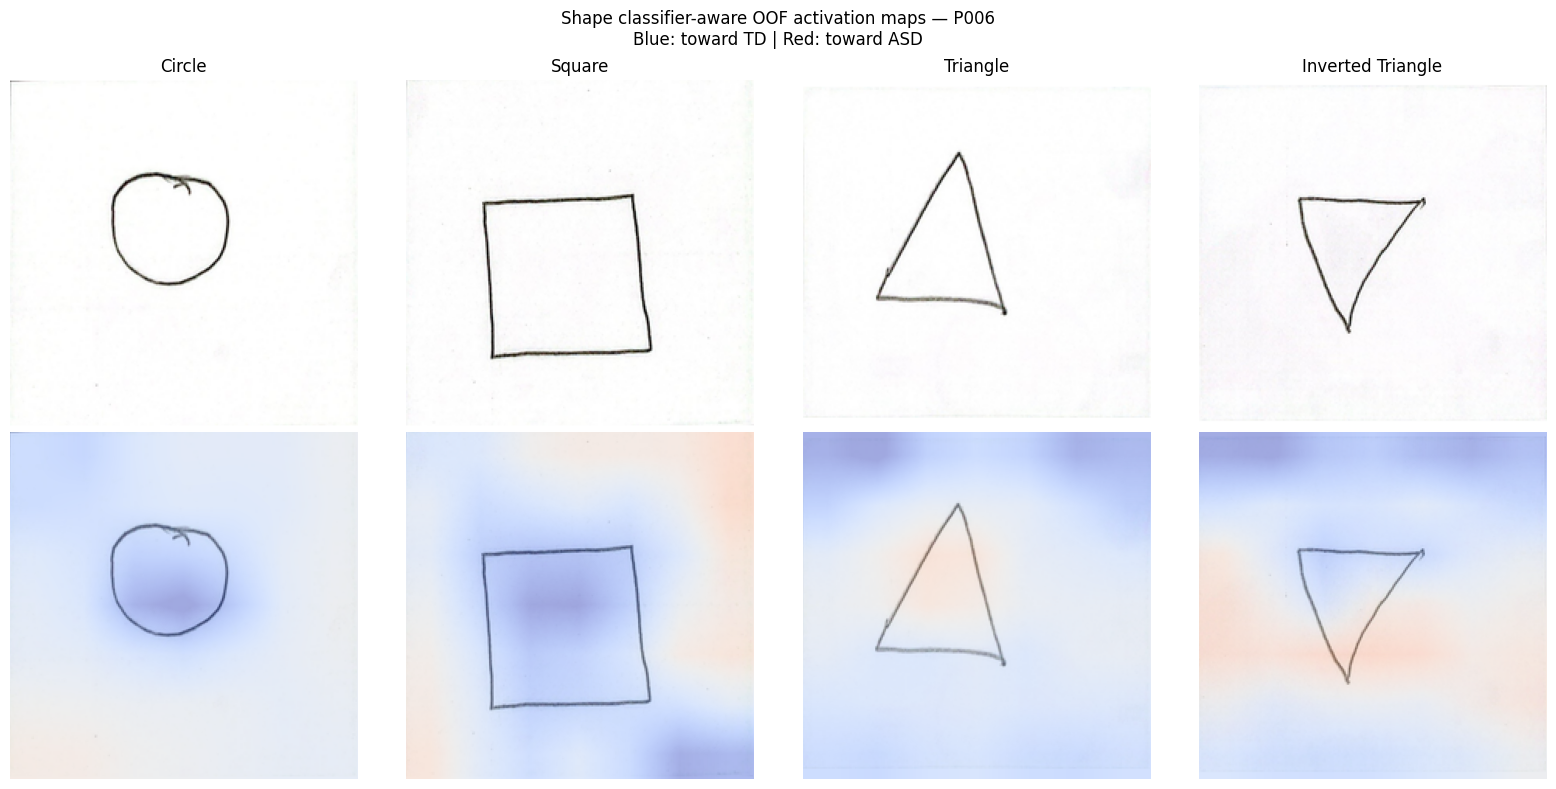


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell25_shape_oof_signed_activation_maps.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell25_shape_oof_activation_image_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell25_shape_oof_activation_participant_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell25_shape_activation_contribution_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell25_shape_oof_activation_map_qc.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell25_shape_oof_activation_maps
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell25_shape_oof_activation_protocol.csv

SHAPE CLASSIFIER-AWARE XAI SUMMARY
Participants explained: 34 / 34
Shape images explained: 136 / 136
Raw activation-map tensor: (34, 4, 7, 7)
Maximum embedding reproduction diff: 4.5299530029296875e-06
Minimum em

In [ ]:
# ============================================================
# CELL 25 — SHAPE CLASSIFIER-AWARE OUT-OF-FOLD ACTIVATION MAPS
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from PIL import Image
from joblib import load


print("=" * 78)
print("CELL 25 — SHAPE CLASSIFIER-AWARE OOF ACTIVATION MAPS")
print("=" * 78)


# ============================================================
# 1. LOCATE THE FROZEN EFFICIENTNET MODEL
#
# This makes the cell robust to the exact variable name used
# when Cell 9 initialized the timm EfficientNet-B0 backbone.
# ============================================================

def locate_efficientnet_backbone():

    preferred_names = [

        "efficientnet_model",
        "efficientnet",
        "efficientnet_b0",
        "effnet_model",
        "effnet"
    ]


    for variable_name in preferred_names:

        candidate = globals().get(
            variable_name
        )


        if (
            isinstance(
                candidate,
                torch.nn.Module
            )

            and

            hasattr(
                candidate,
                "forward_features"
            )

            and

            getattr(
                candidate,
                "num_features",
                None
            )
            ==
            EXPECTED_EFFICIENTNET_DIM
        ):

            return (
                variable_name,
                candidate
            )


    # Defensive fallback:
    # inspect existing global torch modules.
    for variable_name, candidate in globals().items():

        if (
            isinstance(
                candidate,
                torch.nn.Module
            )

            and

            hasattr(
                candidate,
                "forward_features"
            )

            and

            getattr(
                candidate,
                "num_features",
                None
            )
            ==
            EXPECTED_EFFICIENTNET_DIM
        ):

            return (
                variable_name,
                candidate
            )


    raise RuntimeError(
        "Could not locate the frozen EfficientNet-B0 "
        "backbone from Cell 9."
    )


(
    EFFICIENTNET_VARIABLE_NAME,
    shape_xai_efficientnet
) = locate_efficientnet_backbone()


shape_xai_efficientnet = (
    shape_xai_efficientnet.to(
        DEVICE
    )
)


shape_xai_efficientnet.eval()


for parameter in (
    shape_xai_efficientnet.parameters()
):

    parameter.requires_grad = False


print("\nEFFICIENTNET BACKBONE")

print(
    "Located variable:",
    EFFICIENTNET_VARIABLE_NAME
)

print(
    "Feature dimension:",
    getattr(
        shape_xai_efficientnet,
        "num_features",
        None
    )
)

print(
    "Evaluation mode:",
    not shape_xai_efficientnet.training
)

print(
    "All parameters frozen:",
    all(
        not parameter.requires_grad
        for parameter
        in shape_xai_efficientnet.parameters()
    )
)


# ============================================================
# 2. LOCK SHAPE MODALITIES + STORED EMBEDDINGS
# ============================================================

SHAPE_XAI_MODALITIES = [

    "circle",
    "square",
    "triangle",
    "inverted_triangle"
]


SHAPE_XAI_DISPLAY_NAMES = {

    "circle":
        "Circle",

    "square":
        "Square",

    "triangle":
        "Triangle",

    "inverted_triangle":
        "Inverted Triangle"
}


SHAPE_XAI_STORED_EMBEDDINGS = {

    "circle":
        np.asarray(
            X_circle,
            dtype=np.float32
        ),

    "square":
        np.asarray(
            X_square,
            dtype=np.float32
        ),

    "triangle":
        np.asarray(
            X_triangle,
            dtype=np.float32
        ),

    "inverted_triangle":
        np.asarray(
            X_inverted_triangle,
            dtype=np.float32
        )
}


for modality_name in SHAPE_XAI_MODALITIES:

    matrix = (
        SHAPE_XAI_STORED_EMBEDDINGS[
            modality_name
        ]
    )


    if matrix.shape != (
        N_FINAL,
        EXPECTED_EFFICIENTNET_DIM
    ):

        raise RuntimeError(
            f"{modality_name}: unexpected stored "
            "embedding dimensions."
        )


print("\nSHAPE XAI MODALITIES")

for modality_name in SHAPE_XAI_MODALITIES:

    print(
        " -",
        SHAPE_XAI_DISPLAY_NAMES[
            modality_name
        ]
    )


# ============================================================
# 3. LOAD THE VALIDATED IMAGE MANIFEST
# ============================================================

image_manifest_file = (

    AUDIT_DIR
    /
    "cell04_image_manifest.csv"
)


if not image_manifest_file.exists():

    raise FileNotFoundError(
        f"Missing validated image manifest: "
        f"{image_manifest_file}"
    )


shape_xai_image_manifest = pd.read_csv(
    image_manifest_file
)


print("\nIMAGE MANIFEST COLUMNS")

print(
    shape_xai_image_manifest.columns.tolist()
)


# ============================================================
# 4. RESOLVE MANIFEST COLUMNS ROBUSTLY
# ============================================================

def normalize_column_name(
    value
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(
            value
        ).lower()
    )


def resolve_manifest_column(
    dataframe,
    candidates
):

    normalized_lookup = {

        normalize_column_name(
            column
        ):
            column

        for column
        in dataframe.columns
    }


    for candidate in candidates:

        normalized_candidate = (
            normalize_column_name(
                candidate
            )
        )


        if (
            normalized_candidate
            in
            normalized_lookup
        ):

            return normalized_lookup[
                normalized_candidate
            ]


    return None


manifest_id_column = resolve_manifest_column(

    shape_xai_image_manifest,

    [
        "Participant_ID",
        "ParticipantID",
        "Canonical_ID"
    ]
)


manifest_modality_column = resolve_manifest_column(

    shape_xai_image_manifest,

    [
        "Modality",
        "Logical_Modality",
        "Task",
        "Image_Type"
    ]
)


manifest_path_column = resolve_manifest_column(

    shape_xai_image_manifest,

    [
        "File_Path",
        "Image_Path",
        "Resolved_Path",
        "Path",
        "FilePath"
    ]
)


if (
    manifest_id_column is None
    or
    manifest_modality_column is None
    or
    manifest_path_column is None
):

    raise RuntimeError(
        "Could not resolve participant/modality/path columns "
        "from the Cell 4 image manifest."
    )


print("\nRESOLVED IMAGE MANIFEST COLUMNS")

print(
    "Participant ID:",
    manifest_id_column
)

print(
    "Modality:",
    manifest_modality_column
)

print(
    "File path:",
    manifest_path_column
)


# ============================================================
# 5. NORMALIZE MANIFEST MODALITY NAMES
# ============================================================

def normalize_modality_label(
    value
):

    text = normalize_column_name(
        value
    )


    mapping = {

        "circle":
            "circle",

        "square":
            "square",

        "triangle":
            "triangle",

        "invertedtriangle":
            "inverted_triangle",

        "inversetriangle":
            "inverted_triangle"
    }


    return mapping.get(
        text,
        None
    )


shape_xai_image_manifest[
    "_Shape_XAI_Modality"
] = (

    shape_xai_image_manifest[
        manifest_modality_column
    ]

    .apply(
        normalize_modality_label
    )
)


shape_manifest = (

    shape_xai_image_manifest[
        shape_xai_image_manifest[
            "_Shape_XAI_Modality"
        ].isin(
            SHAPE_XAI_MODALITIES
        )
    ]

    .copy()
)


# One validated file per participant per Shape modality.
duplicate_shape_manifest = (

    shape_manifest

    .duplicated(

        subset=[
            manifest_id_column,
            "_Shape_XAI_Modality"
        ],

        keep=False
    )
)


if duplicate_shape_manifest.any():

    raise RuntimeError(
        "Validated image manifest contains duplicate "
        "Shape image mappings."
    )


expected_shape_manifest_rows = (
    N_FINAL
    *
    len(
        SHAPE_XAI_MODALITIES
    )
)


print(
    "\nValidated Shape manifest rows:",
    len(
        shape_manifest
    )
)

print(
    "Expected:",
    expected_shape_manifest_rows
)


if (
    len(
        shape_manifest
    )
    !=
    expected_shape_manifest_rows
):

    raise RuntimeError(
        "Unexpected number of Shape image-manifest rows."
    )


# ============================================================
# 6. BUILD FAST PARTICIPANT/MODALITY -> PATH LOOKUP
# ============================================================

shape_image_path_lookup = {}


for _, row in shape_manifest.iterrows():

    key = (

        str(
            row[
                manifest_id_column
            ]
        ),

        row[
            "_Shape_XAI_Modality"
        ]
    )


    image_path = Path(
        str(
            row[
                manifest_path_column
            ]
        )
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"Validated image is no longer available: "
            f"{image_path}"
        )


    shape_image_path_lookup[
        key
    ] = image_path


# ============================================================
# 7. RECREATE LOCKED EFFICIENTNET PREPROCESSING
#
# Cell 7 policy:
# - RGB
# - longest side -> 224
# - preserve aspect ratio
# - centered white padding
# - LANCZOS
# - ImageNet normalization
# ============================================================

SHAPE_XAI_TARGET_SIZE = 224


EFFICIENTNET_MEAN_XAI = torch.tensor(

    [
        0.485,
        0.456,
        0.406
    ],

    dtype=torch.float32
).view(
    3,
    1,
    1
)


EFFICIENTNET_STD_XAI = torch.tensor(

    [
        0.229,
        0.224,
        0.225
    ],

    dtype=torch.float32
).view(
    3,
    1,
    1
)


def preprocess_shape_image_for_xai(
    image_path
):

    with Image.open(
        image_path
    ) as image:

        image = image.convert(
            "RGB"
        )


        original_width, original_height = (
            image.size
        )


        scale = min(

            SHAPE_XAI_TARGET_SIZE
            /
            original_width,

            SHAPE_XAI_TARGET_SIZE
            /
            original_height
        )


        resized_width = max(

            1,

            int(
                round(
                    original_width
                    *
                    scale
                )
            )
        )


        resized_height = max(

            1,

            int(
                round(
                    original_height
                    *
                    scale
                )
            )
        )


        resized_image = image.resize(

            (
                resized_width,
                resized_height
            ),

            resample=
                Image.Resampling.LANCZOS
        )


        canvas = Image.new(

            "RGB",

            (
                SHAPE_XAI_TARGET_SIZE,
                SHAPE_XAI_TARGET_SIZE
            ),

            color=(
                255,
                255,
                255
            )
        )


        pad_left = (

            SHAPE_XAI_TARGET_SIZE
            -
            resized_width

        ) // 2


        pad_top = (

            SHAPE_XAI_TARGET_SIZE
            -
            resized_height

        ) // 2


        canvas.paste(

            resized_image,

            (
                pad_left,
                pad_top
            )
        )


    display_array = np.asarray(
        canvas,
        dtype=np.uint8
    )


    tensor = torch.from_numpy(

        display_array.copy()

    ).permute(
        2,
        0,
        1
    ).float() / 255.0


    tensor = (

        tensor
        -
        EFFICIENTNET_MEAN_XAI

    ) / EFFICIENTNET_STD_XAI


    return (
        tensor.unsqueeze(
            0
        ).to(
            DEVICE
        ),

        display_array
    )


# ============================================================
# 8. HELPER — EXTRACT FINAL FEATURE MAP + POOLED EMBEDDING
# ============================================================

@torch.inference_mode()
def shape_xai_forward(
    input_tensor
):

    feature_map = (
        shape_xai_efficientnet
        .forward_features(
            input_tensor
        )
    )


    if feature_map.ndim != 4:

        raise RuntimeError(
            "EfficientNet forward_features did not "
            "return [B,C,H,W]."
        )


    if feature_map.shape[1] != (
        EXPECTED_EFFICIENTNET_DIM
    ):

        raise RuntimeError(
            "Unexpected EfficientNet feature-map "
            "channel dimension."
        )


    # Use the model's own head to recreate the embedding used
    # by the classifier.
    if hasattr(
        shape_xai_efficientnet,
        "forward_head"
    ):

        pooled_embedding = (
            shape_xai_efficientnet
            .forward_head(

                feature_map,

                pre_logits=True
            )
        )

    else:

        pooled_embedding = torch.mean(

            feature_map,

            dim=(
                2,
                3
            )
        )


    pooled_embedding = pooled_embedding.reshape(
        pooled_embedding.shape[0],
        -1
    )


    manual_spatial_mean = torch.mean(

        feature_map,

        dim=(
            2,
            3
        )
    )


    return (
        feature_map,
        pooled_embedding,
        manual_spatial_mean
    )


# ============================================================
# 9. STORAGE
# ============================================================

shape_cam_height = None
shape_cam_width = None


shape_oof_cam_maps = None


shape_xai_image_records = []

shape_xai_participant_records = []


SHAPE_XAI_EMBEDDING_ABS_TOL = 1e-4
SHAPE_XAI_POOLING_ABS_TOL = 1e-5
SHAPE_XAI_DECISION_ABS_TOL = 1e-4
SHAPE_XAI_PROBABILITY_ABS_TOL = 1e-4


# Output directory for all participant/image overlays.
shape_cam_output_dir = (

    FIGURES_DIR
    /
    "cell25_shape_oof_activation_maps"
)


shape_cam_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 10. PROCESS EVERY PARTICIPANT OUT-OF-FOLD
# ============================================================

print("\nGENERATING OUT-OF-FOLD SHAPE ACTIVATION MAPS...")


for participant_index in range(
    N_FINAL
):

    participant_id = str(
        cohort_ids[
            participant_index
        ]
    )


    participant_group = str(
        groups[
            participant_index
        ]
    )


    outer_fold_number = int(
        outer_test_assignment[
            participant_index
        ]
    )


    # --------------------------------------------------------
    # Load exact held-out Shape LR model
    # --------------------------------------------------------

    if (
        "shape_model_files"
        in globals()
        and
        len(
            shape_model_files
        )
        ==
        OUTER_FOLDS
    ):

        shape_model_file = Path(

            shape_model_files[
                outer_fold_number
                -
                1
            ]
        )


    else:

        shape_model_file = (

            MODELS_DIR
            /
            (
                f"shape_outer_fold_"
                f"{outer_fold_number}.joblib"
            )
        )


    if not shape_model_file.exists():

        raise FileNotFoundError(
            f"Missing Shape outer-fold model: "
            f"{shape_model_file}"
        )


    heldout_shape_model = load(
        shape_model_file
    )


    scaler = heldout_shape_model.named_steps[
        "scaler"
    ]


    classifier = heldout_shape_model.named_steps[
        "classifier"
    ]


    if not np.array_equal(

        classifier.classes_,

        np.array(
            [
                0,
                1
            ]
        )
    ):

        raise RuntimeError(
            "Unexpected Shape classifier class ordering."
        )


    beta_scaled = (
        classifier.coef_[0]
        .astype(
            np.float64
        )
    )


    scaler_mean = (
        scaler.mean_
        .astype(
            np.float64
        )
    )


    scaler_scale = (
        scaler.scale_
        .astype(
            np.float64
        )
    )


    if np.any(
        scaler_scale <= 0
    ):

        raise RuntimeError(
            "Shape scaler contains a non-positive scale."
        )


    # Effective coefficient directly on raw embedding.
    effective_weight = (

        beta_scaled

        /

        scaler_scale
    )


    classifier_constant = float(

        classifier.intercept_[
            0
        ]

        -

        np.sum(

            beta_scaled

            *

            (
                scaler_mean
                /
                scaler_scale
            )
        )
    )


    # --------------------------------------------------------
    # Verify stored OOF prediction using stored Shape vector
    # --------------------------------------------------------

    stored_shape_vector = (

        X_shape[
            participant_index
        ]

        .reshape(
            1,
            -1
        )
    )


    exact_stored_decision = float(

        heldout_shape_model
        .decision_function(
            stored_shape_vector
        )[
            0
        ]
    )


    exact_stored_probability = float(

        heldout_shape_model
        .predict_proba(
            stored_shape_vector
        )[
            0,
            1
        ]
    )


    expected_oof_probability = float(

        shape_oof_probability[
            participant_index
        ]
    )


    stored_probability_diff = abs(

        exact_stored_probability

        -

        expected_oof_probability
    )


    if (
        stored_probability_diff
        >
        1e-8
    ):

        raise RuntimeError(
            f"{participant_id}: held-out Shape model "
            "does not reproduce locked OOF probability."
        )


    participant_recomputed_embeddings = []

    participant_spatial_contributions = []

    participant_cam_list = []


    # ========================================================
    # 10A. FOUR SHAPE IMAGES
    # ========================================================

    for shape_number, modality_name in enumerate(
        SHAPE_XAI_MODALITIES
    ):

        image_path = shape_image_path_lookup.get(

            (
                participant_id,
                modality_name
            )
        )


        if image_path is None:

            raise RuntimeError(
                f"Missing image path for "
                f"{participant_id} / {modality_name}"
            )


        (
            input_tensor,
            display_array
        ) = preprocess_shape_image_for_xai(
            image_path
        )


        (
            feature_map_tensor,
            pooled_embedding_tensor,
            manual_spatial_mean_tensor
        ) = shape_xai_forward(
            input_tensor
        )


        feature_map = (

            feature_map_tensor[
                0
            ]

            .detach()

            .cpu()

            .numpy()

            .astype(
                np.float64
            )
        )


        recomputed_embedding = (

            pooled_embedding_tensor[
                0
            ]

            .detach()

            .cpu()

            .numpy()

            .astype(
                np.float64
            )
        )


        manual_spatial_mean = (

            manual_spatial_mean_tensor[
                0
            ]

            .detach()

            .cpu()

            .numpy()

            .astype(
                np.float64
            )
        )


        # ----------------------------------------------------
        # Verify global average pooling relationship
        # ----------------------------------------------------

        pooling_max_diff = float(

            np.max(

                np.abs(

                    recomputed_embedding

                    -

                    manual_spatial_mean
                )
            )
        )


        if (
            pooling_max_diff
            >
            SHAPE_XAI_POOLING_ABS_TOL
        ):

            raise RuntimeError(
                f"{participant_id}/{modality_name}: "
                "final EfficientNet embedding is not the "
                "spatial mean of the final feature map."
            )


        # ----------------------------------------------------
        # Verify against Cell 10 saved embedding
        # ----------------------------------------------------

        stored_embedding = (

            SHAPE_XAI_STORED_EMBEDDINGS[
                modality_name
            ][
                participant_index
            ]

            .astype(
                np.float64
            )
        )


        embedding_max_diff = float(

            np.max(

                np.abs(

                    recomputed_embedding

                    -

                    stored_embedding
                )
            )
        )


        embedding_cosine = float(

            np.dot(
                recomputed_embedding,
                stored_embedding
            )

            /

            (
                np.linalg.norm(
                    recomputed_embedding
                )

                *

                np.linalg.norm(
                    stored_embedding
                )
            )
        )


        if (
            embedding_max_diff
            >
            SHAPE_XAI_EMBEDDING_ABS_TOL
        ):

            raise RuntimeError(
                f"{participant_id}/{modality_name}: "
                "recomputed EfficientNet embedding differs "
                "from Cell 10 beyond tolerance. "
                f"Max diff={embedding_max_diff}"
            )


        # ----------------------------------------------------
        # Exact classifier-aware signed activation map
        #
        # Divide by 4 because Shape representation is the
        # mean of four image embeddings.
        # ----------------------------------------------------

        signed_cam = (

            np.tensordot(

                effective_weight,

                feature_map,

                axes=(
                    0,
                    0
                )
            )

            /

            len(
                SHAPE_XAI_MODALITIES
            )
        )


        if shape_cam_height is None:

            (
                shape_cam_height,
                shape_cam_width
            ) = signed_cam.shape


            shape_oof_cam_maps = np.full(

                (
                    N_FINAL,
                    len(
                        SHAPE_XAI_MODALITIES
                    ),
                    shape_cam_height,
                    shape_cam_width
                ),

                np.nan,

                dtype=np.float32
            )


        if signed_cam.shape != (
            shape_cam_height,
            shape_cam_width
        ):

            raise RuntimeError(
                "EfficientNet feature-map dimensions changed "
                "between images."
            )


        image_spatial_contribution = float(
            np.mean(
                signed_cam
            )
        )


        direct_image_contribution = float(

            np.dot(

                effective_weight,

                recomputed_embedding
            )

            /

            len(
                SHAPE_XAI_MODALITIES
            )
        )


        spatial_contribution_diff = abs(

            image_spatial_contribution

            -

            direct_image_contribution
        )


        if (
            spatial_contribution_diff
            >
            SHAPE_XAI_DECISION_ABS_TOL
        ):

            raise RuntimeError(
                f"{participant_id}/{modality_name}: "
                "activation-map spatial mean does not "
                "reconstruct image logit contribution."
            )


        shape_oof_cam_maps[
            participant_index,
            shape_number
        ] = signed_cam.astype(
            np.float32
        )


        participant_recomputed_embeddings.append(
            recomputed_embedding
        )


        participant_spatial_contributions.append(
            image_spatial_contribution
        )


        participant_cam_list.append(
            (
                modality_name,
                signed_cam,
                display_array,
                image_path
            )
        )


        # ----------------------------------------------------
        # Save individual overlay
        # ----------------------------------------------------

        display_scale = float(

            np.quantile(

                np.abs(
                    signed_cam
                ),

                0.99
            )
        )


        if (
            not np.isfinite(
                display_scale
            )
            or
            display_scale <= 0
        ):

            display_scale = 1.0


        fig, ax = plt.subplots(
            figsize=(
                5,
                5
            )
        )


        ax.imshow(
            display_array
        )


        heatmap_artist = ax.imshow(

            signed_cam,

            cmap="coolwarm",

            interpolation="bilinear",

            alpha=0.48,

            extent=[
                0,
                SHAPE_XAI_TARGET_SIZE,
                SHAPE_XAI_TARGET_SIZE,
                0
            ],

            vmin=
                -display_scale,

            vmax=
                display_scale
        )


        ax.set_title(

            f"{participant_id} — "
            f"{SHAPE_XAI_DISPLAY_NAMES[modality_name]}\n"
            f"OOF Shape P(ASD)="
            f"{expected_oof_probability:.3f}"
        )


        ax.axis(
            "off"
        )


        colorbar = fig.colorbar(

            heatmap_artist,

            ax=ax,

            fraction=0.046,

            pad=0.04
        )


        colorbar.set_label(
            "Signed contribution to Shape logit"
        )


        fig.tight_layout()


        safe_modality_name = (
            modality_name
            .replace(
                "_",
                "-"
            )
        )


        overlay_file = (

            shape_cam_output_dir
            /
            (
                f"{participant_id}_"
                f"{safe_modality_name}_"
                f"oof_signed_cam.png"
            )
        )


        fig.savefig(

            overlay_file,

            dpi=180,

            bbox_inches="tight"
        )


        plt.close(
            fig
        )


        shape_xai_image_records.append({

            "Participant_ID":
                participant_id,

            "Group":
                participant_group,

            "Outer_Fold":
                outer_fold_number,

            "Modality":
                modality_name,

            "Image_Path":
                str(
                    image_path
                ),

            "Shape_OOF_Probability_ASD":
                expected_oof_probability,

            "Stored_Embedding_Max_Abs_Diff":
                embedding_max_diff,

            "Stored_Embedding_Cosine_Similarity":
                embedding_cosine,

            "Pooling_Max_Abs_Diff":
                pooling_max_diff,

            "Spatial_Mean_CAM_Contribution":
                image_spatial_contribution,

            "Direct_Embedding_Logit_Contribution":
                direct_image_contribution,

            "Contribution_Reconstruction_Abs_Diff":
                spatial_contribution_diff,

            "Signed_CAM_Min":
                float(
                    np.min(
                        signed_cam
                    )
                ),

            "Signed_CAM_Max":
                float(
                    np.max(
                        signed_cam
                    )
                ),

            "Signed_CAM_Mean":
                float(
                    np.mean(
                        signed_cam
                    )
                ),

            "Positive_Spatial_Fraction":
                float(
                    np.mean(
                        signed_cam > 0
                    )
                ),

            "Negative_Spatial_Fraction":
                float(
                    np.mean(
                        signed_cam < 0
                    )
                ),

            "Overlay_File":
                str(
                    overlay_file
                )
        })


    # ========================================================
    # 10B. PARTICIPANT-LEVEL EXACT DECISION RECONSTRUCTION
    # ========================================================

    recomputed_shape_embedding = np.mean(

        np.stack(
            participant_recomputed_embeddings,
            axis=0
        ),

        axis=0
    )


    recomputed_model_decision = float(

        heldout_shape_model

        .decision_function(

            recomputed_shape_embedding.reshape(
                1,
                -1
            )
        )[
            0
        ]
    )


    recomputed_model_probability = float(

        heldout_shape_model

        .predict_proba(

            recomputed_shape_embedding.reshape(
                1,
                -1
            )
        )[
            0,
            1
        ]
    )


    cam_reconstructed_decision = float(

        classifier_constant

        +

        np.sum(
            participant_spatial_contributions
        )
    )


    cam_decision_diff = abs(

        cam_reconstructed_decision

        -

        recomputed_model_decision
    )


    if (
        cam_decision_diff
        >
        SHAPE_XAI_DECISION_ABS_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: four CAMs do not reconstruct "
            "the participant-level Shape decision score. "
            f"Diff={cam_decision_diff}"
        )


    recomputed_probability_diff = abs(

        recomputed_model_probability

        -

        expected_oof_probability
    )


    if (
        recomputed_probability_diff
        >
        SHAPE_XAI_PROBABILITY_ABS_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: recomputed image features "
            "do not reproduce held-out Shape probability "
            "within numerical tolerance."
        )


    shape_xai_participant_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            participant_group,

        "Outer_Fold":
            outer_fold_number,

        "Stored_Shape_OOF_Probability_ASD":
            expected_oof_probability,

        "Recomputed_Shape_Probability_ASD":
            recomputed_model_probability,

        "Probability_Abs_Diff":
            recomputed_probability_diff,

        "Stored_Shape_Decision":
            exact_stored_decision,

        "Recomputed_Shape_Decision":
            recomputed_model_decision,

        "CAM_Reconstructed_Decision":
            cam_reconstructed_decision,

        "CAM_Decision_Reconstruction_Abs_Diff":
            cam_decision_diff,

        "Classifier_Constant":
            classifier_constant,

        "Circle_Logit_Contribution":
            participant_spatial_contributions[
                0
            ],

        "Square_Logit_Contribution":
            participant_spatial_contributions[
                1
            ],

        "Triangle_Logit_Contribution":
            participant_spatial_contributions[
                2
            ],

        "Inverted_Triangle_Logit_Contribution":
            participant_spatial_contributions[
                3
            ],

        "Model_File":
            str(
                shape_model_file
            )
    })


# ============================================================
# 11. GLOBAL MAP / RECONSTRUCTION AUDIT
# ============================================================

shape_xai_image_audit_df = pd.DataFrame(
    shape_xai_image_records
)


shape_xai_participant_audit_df = pd.DataFrame(
    shape_xai_participant_records
)


if shape_oof_cam_maps is None:

    raise RuntimeError(
        "No Shape activation maps were generated."
    )


if shape_oof_cam_maps.shape[0] != N_FINAL:

    raise RuntimeError(
        "Unexpected participant count in CAM tensor."
    )


if not np.isfinite(
    shape_oof_cam_maps
).all():

    raise RuntimeError(
        "Shape activation-map tensor contains "
        "non-finite values."
    )


maximum_embedding_difference = float(

    shape_xai_image_audit_df[
        "Stored_Embedding_Max_Abs_Diff"
    ].max()
)


minimum_embedding_cosine = float(

    shape_xai_image_audit_df[
        "Stored_Embedding_Cosine_Similarity"
    ].min()
)


maximum_pooling_difference = float(

    shape_xai_image_audit_df[
        "Pooling_Max_Abs_Diff"
    ].max()
)


maximum_spatial_contribution_difference = float(

    shape_xai_image_audit_df[
        "Contribution_Reconstruction_Abs_Diff"
    ].max()
)


maximum_decision_reconstruction_difference = float(

    shape_xai_participant_audit_df[
        "CAM_Decision_Reconstruction_Abs_Diff"
    ].max()
)


maximum_probability_difference = float(

    shape_xai_participant_audit_df[
        "Probability_Abs_Diff"
    ].max()
)


print("\nGLOBAL SHAPE XAI NUMERICAL AUDIT")

print(
    "CAM tensor shape:",
    shape_oof_cam_maps.shape
)

print(
    "Maximum stored-embedding abs diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum GAP reconstruction diff:",
    maximum_pooling_difference
)

print(
    "Maximum image-contribution reconstruction diff:",
    maximum_spatial_contribution_difference
)

print(
    "Maximum participant decision reconstruction diff:",
    maximum_decision_reconstruction_difference
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)


# ============================================================
# 12. SHAPE-CONTRIBUTION SUMMARY
# ============================================================

shape_contribution_summary_df = (

    shape_xai_image_audit_df

    .groupby(
        [
            "Group",
            "Modality"
        ]
    )

    .agg(

        N=(
            "Participant_ID",
            "count"
        ),

        Mean_Signed_Logit_Contribution=(
            "Spatial_Mean_CAM_Contribution",
            "mean"
        ),

        Mean_Absolute_Logit_Contribution=(
            "Spatial_Mean_CAM_Contribution",
            lambda x:
                float(
                    np.mean(
                        np.abs(
                            np.asarray(
                                x,
                                dtype=float
                            )
                        )
                    )
                )
        ),

        Mean_Positive_Spatial_Fraction=(
            "Positive_Spatial_Fraction",
            "mean"
        ),

        Mean_Negative_Spatial_Fraction=(
            "Negative_Spatial_Fraction",
            "mean"
        )
    )

    .reset_index()
)


print("\nSHAPE ACTIVATION CONTRIBUTION SUMMARY")

display(
    shape_contribution_summary_df.round(
        6
    )
)


# ============================================================
# 13. FIRST-PARTICIPANT QC PANEL
#
# Objective selection: first participant in locked cohort order.
# No outcome-based cherry-picking.
# ============================================================

qc_participant_index = 0

qc_participant_id = str(
    cohort_ids[
        qc_participant_index
    ]
)


fig, axes = plt.subplots(

    2,
    4,

    figsize=(
        16,
        8
    )
)


for modality_number, modality_name in enumerate(
    SHAPE_XAI_MODALITIES
):

    image_path = shape_image_path_lookup[

        (
            qc_participant_id,
            modality_name
        )
    ]


    (
        _,
        display_array
    ) = preprocess_shape_image_for_xai(
        image_path
    )


    signed_cam = shape_oof_cam_maps[

        qc_participant_index,
        modality_number
    ]


    display_scale = float(

        np.quantile(
            np.abs(
                signed_cam
            ),
            0.99
        )
    )


    if display_scale <= 0:

        display_scale = 1.0


    axes[
        0,
        modality_number
    ].imshow(
        display_array
    )


    axes[
        0,
        modality_number
    ].set_title(

        SHAPE_XAI_DISPLAY_NAMES[
            modality_name
        ]
    )


    axes[
        0,
        modality_number
    ].axis(
        "off"
    )


    axes[
        1,
        modality_number
    ].imshow(
        display_array
    )


    axes[
        1,
        modality_number
    ].imshow(

        signed_cam,

        cmap="coolwarm",

        interpolation="bilinear",

        alpha=0.48,

        extent=[
            0,
            SHAPE_XAI_TARGET_SIZE,
            SHAPE_XAI_TARGET_SIZE,
            0
        ],

        vmin=
            -display_scale,

        vmax=
            display_scale
    )


    axes[
        1,
        modality_number
    ].axis(
        "off"
    )


fig.suptitle(

    f"Shape classifier-aware OOF activation maps — "
    f"{qc_participant_id}\n"
    f"Blue: toward TD | Red: toward ASD"
)


fig.tight_layout()


shape_cam_qc_file = (

    FIGURES_DIR
    /
    "cell25_shape_oof_activation_map_qc.png"
)


fig.savefig(

    shape_cam_qc_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. SAVE RAW CAM TENSOR
# ============================================================

shape_cam_npz_file = (

    EMBEDDINGS_DIR
    /
    "cell25_shape_oof_signed_activation_maps.npz"
)


np.savez_compressed(

    shape_cam_npz_file,

    participant_ids=
        np.asarray(
            cohort_ids,
            dtype="U"
        ),

    groups=
        np.asarray(
            groups,
            dtype="U"
        ),

    outer_folds=
        np.asarray(
            outer_test_assignment,
            dtype=np.int64
        ),

    modalities=
        np.asarray(
            SHAPE_XAI_MODALITIES,
            dtype="U"
        ),

    signed_activation_maps=
        shape_oof_cam_maps.astype(
            np.float32
        )
)


# ============================================================
# 15. SAVE AUDIT TABLES
# ============================================================

shape_xai_image_audit_file = (

    AUDIT_DIR
    /
    "cell25_shape_oof_activation_image_audit.csv"
)


shape_xai_participant_audit_file = (

    AUDIT_DIR
    /
    "cell25_shape_oof_activation_participant_audit.csv"
)


shape_contribution_summary_file = (

    RESULTS_DIR
    /
    "cell25_shape_activation_contribution_summary.csv"
)


shape_xai_image_audit_df.to_csv(

    shape_xai_image_audit_file,

    index=False
)


shape_xai_participant_audit_df.to_csv(

    shape_xai_participant_audit_file,

    index=False
)


shape_contribution_summary_df.to_csv(

    shape_contribution_summary_file,

    index=False
)


# ============================================================
# 16. SAVE SHAPE XAI PROTOCOL
# ============================================================

shape_xai_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Explained classifier",

        "Value":
            (
                "Outer-fold Shape StandardScaler + "
                "L2 Logistic Regression"
            )
    },

    {
        "Setting":
            "Visual backbone",

        "Value":
            "Frozen EfficientNet-B0"
    },

    {
        "Setting":
            "Spatial tensor",

        "Value":
            "Final EfficientNet convolutional feature map"
    },

    {
        "Setting":
            "Map type",

        "Value":
            (
                "Exact signed linear classifier-aware "
                "activation decomposition"
            )
    },

    {
        "Setting":
            "Conventional Grad-CAM claimed",

        "Value":
            False
    },

    {
        "Setting":
            "Shape image aggregation",

        "Value":
            (
                "Four image embeddings mean-pooled; "
                "each map therefore receives factor 1/4"
            )
    },

    {
        "Setting":
            "Positive map value",

        "Value":
            "Pushes held-out Shape logit toward ASD"
    },

    {
        "Setting":
            "Negative map value",

        "Value":
            "Pushes held-out Shape logit toward TD"
    },

    {
        "Setting":
            "Participant explained by LR trained "
            "on that participant",

        "Value":
            False
    },

    {
        "Setting":
            "Backbone trained on ASD/TD labels",

        "Value":
            False
    },

    {
        "Setting":
            "Exact decision reconstruction audited",

        "Value":
            True
    },

    {
        "Setting":
            "Age confounding resolved by XAI",

        "Value":
            False
    },

    {
        "Setting":
            "Expert XAI validation completed",

        "Value":
            False
    },

    {
        "Setting":
            "Clinical localization claim",

        "Value":
            False
    }
])


shape_xai_protocol_file = (

    MANIFEST_DIR
    /
    "cell25_shape_oof_activation_protocol.csv"
)


shape_xai_protocol_df.to_csv(

    shape_xai_protocol_file,

    index=False
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\nSAVED OUTPUTS")

print(
    shape_cam_npz_file
)

print(
    shape_xai_image_audit_file
)

print(
    shape_xai_participant_audit_file
)

print(
    shape_contribution_summary_file
)

print(
    shape_cam_qc_file
)

print(
    shape_cam_output_dir
)

print(
    shape_xai_protocol_file
)


print("\n" + "=" * 78)
print("SHAPE CLASSIFIER-AWARE XAI SUMMARY")


print(
    "Participants explained:",
    N_FINAL,
    "/",
    N_FINAL
)

print(
    "Shape images explained:",
    len(
        shape_xai_image_audit_df
    ),
    "/",
    expected_shape_manifest_rows
)

print(
    "Raw activation-map tensor:",
    shape_oof_cam_maps.shape
)

print(
    "Maximum embedding reproduction diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum GAP reconstruction diff:",
    maximum_pooling_difference
)

print(
    "Maximum image-contribution reconstruction diff:",
    maximum_spatial_contribution_difference
)

print(
    "Maximum participant decision reconstruction diff:",
    maximum_decision_reconstruction_difference
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)

print(
    "\nConventional Grad-CAM claimed:",
    False
)

print(
    "Classifier-aware signed decomposition:",
    True
)

print(
    "Clinical localization claimed:",
    False
)

print(
    "Expert XAI validation completed:",
    False
)


print("\nCELL 25 STATUS: PASS")
print("=" * 78)

# 26. Colour Branch — Classifier-Aware Activation Maps and Engineered-Feature SHAP

The Colour classifier uses two feature sources:

1. a 1,280-dimensional frozen EfficientNet-B0 embedding from the completed
   colour drawing;
2. 13 objective engineered colour statistics.

These are concatenated, standardized and classified using L2 Logistic
Regression.

Two complementary explanation methods are therefore used.

## A. Classifier-aware signed activation map

The held-out Logistic Regression coefficient corresponding to the 1,280 CNN
features is projected directly onto the final EfficientNet spatial feature
map.

If the standardized classifier coefficient is `beta` and StandardScaler
scale is `sigma`, the equivalent coefficient on the unstandardized
EfficientNet feature is:

`w = beta / sigma`

The signed spatial map is:

`CAM(x,y) = sum_c w_c * F_c(x,y)`

Positive map values push the Colour classifier toward ASD.

Negative map values push the Colour classifier toward TD.

Because the frozen EfficientNet embedding is produced by global average
pooling, the mean spatial map value must exactly reproduce the CNN
contribution to the Colour classifier logit.

## B. Engineered-feature LinearSHAP

The 13 engineered colour variables are explained using exact interventional
LinearSHAP.

For each outer fold:

- only outer-training participants define the SHAP background;
- engineered variables are transformed with the StandardScaler fitted on
  that outer-training partition;
- each held-out participant is explained using the classifier from their
  outer fold.

For a linear model, the interventional SHAP value of engineered feature `j`
is exactly:

`SHAP_j = beta_j * (z_j - E_train[z_j])`

where `z_j` is the standardized feature value and the expectation is obtained
only from the outer-training participants.

The SHAP values are checked to reconstruct the engineered-feature component
of the held-out classifier score.

## Full-score reconstruction

For every held-out participant the notebook additionally verifies that:

`classifier constant + CNN spatial contribution + engineered raw-feature contribution`

reconstructs the actual Colour Logistic Regression decision score.

Thus both visual and engineered explanations are connected directly to the
classifier evaluated in the nested cross-validation analysis.

## Interpretation limits

These explanations characterize the fitted model in the current internal
cohort.

They do not establish:

- causal colour behaviour;
- clinically validated colour markers;
- semantic object-colour matching;
- boundary-overflow abnormalities;
- diagnostic validity.

Boundary-overflow and object-colour matching were not implemented because no
validated template masks or semantic scoring rules were available.

Independent expert XAI validation remains pending.

CELL 26 — COLOUR CLASSIFIER-AWARE MAPS + ENGINEERED SHAP

EFFICIENTNET BACKBONE
Feature dimension: 1280
Evaluation mode: True
All parameters frozen: True

COLOUR FEATURE PARTITION
Combined features: 1293
CNN features: 1280
Engineered features: 13
Engineered names: ['hue_entropy_norm', 'hue_simpson_diversity', 'dominant_hue_fraction', 'saturation_mean', 'saturation_std', 'brightness_mean', 'brightness_std', 'chromatic_coverage', 'foreground_coverage', 'lab_chroma_mean', 'lab_chroma_std', 'hue_cos_mean', 'hue_sin_mean']

RESOLVED IMAGE MANIFEST COLUMNS
Participant ID: Participant_ID
Modality: Modality
File path: File_Path
Validated Colour Drawing paths: 34

GENERATING OUT-OF-FOLD COLOUR EXPLANATIONS...

GLOBAL COLOUR XAI NUMERICAL AUDIT
CNN activation-map tensor: (34, 7, 7)
Engineered SHAP matrix: (34, 13)
Maximum stored-embedding abs diff: 3.0994415283203125e-06
Minimum embedding cosine similarity: 0.9999999999994128
Maximum GAP reconstruction diff: 0.0
Maximum CNN contribution reconstr

,Feature,Mean_Absolute_OOF_SHAP,Mean_Signed_OOF_SHAP,TD_Mean_Signed_SHAP,ASD_Mean_Signed_SHAP,Importance_Rank
0,hue_sin_mean,0.006220,-0.000711,-0.002654,0.002065,1
1,hue_entropy_norm,0.005548,0.000118,-0.002887,0.004411,2
2,brightness_mean,0.005236,-0.001229,-0.002760,0.000959,3
3,hue_simpson_diversity,0.004697,0.000200,-0.002266,0.003724,4
4,foreground_coverage,0.004490,-0.000513,-0.002895,0.002891,5
5,chromatic_coverage,0.004262,-0.000604,-0.002692,0.002378,6
6,lab_chroma_mean,0.003280,-0.000992,-0.001194,-0.000703,7
7,brightness_std,0.003080,-0.000266,-0.001591,0.001626,8
8,dominant_hue_fraction,0.002852,0.000191,-0.001037,0.001945,9
9,saturation_std,0.002482,0.000227,0.000190,0.000280,10



COLOUR CNN ACTIVATION CONTRIBUTION SUMMARY


,Group,N,Mean_Signed_CNN_Logit_Contribution,Mean_Absolute_CNN_Logit_Contribution,Mean_Positive_Spatial_Fraction,Mean_Negative_Spatial_Fraction
0,ASD,14,0.151896,1.049854,0.514577,0.485423
1,TD,20,-1.867959,1.914240,0.146939,0.853061



LOCAL ENGINEERED-FEATURE SHAP PREVIEW


,Participant_ID,Group,Outer_Fold,Colour_OOF_Probability_ASD,Local_Rank,Feature,Raw_Feature_Value,SHAP_Value,Absolute_SHAP,Direction
0,P006,TD,1,0.319188,1,lab_chroma_std,38.010864,0.004455,0.004455,Toward ASD
1,P006,TD,1,0.319188,2,brightness_mean,0.637350,0.003080,0.003080,Toward ASD
2,P006,TD,1,0.319188,3,brightness_std,0.331644,0.002945,0.002945,Toward ASD
3,P006,TD,1,0.319188,4,hue_sin_mean,0.562797,-0.002830,0.002830,Toward TD
4,P006,TD,1,0.319188,5,hue_simpson_diversity,0.915526,0.002749,0.002749,Toward ASD
5,P007,TD,5,0.079367,1,hue_sin_mean,0.525154,-0.007400,0.007400,Toward TD
6,P007,TD,5,0.079367,2,lab_chroma_std,36.710491,-0.006680,0.006680,Toward TD
7,P007,TD,5,0.079367,3,hue_simpson_diversity,0.906175,0.006275,0.006275,Toward ASD
8,P007,TD,5,0.079367,4,dominant_hue_fraction,0.154153,0.004839,0.004839,Toward ASD
9,P007,TD,5,0.079367,5,foreground_coverage,0.564499,-0.004171,0.004171,Toward TD


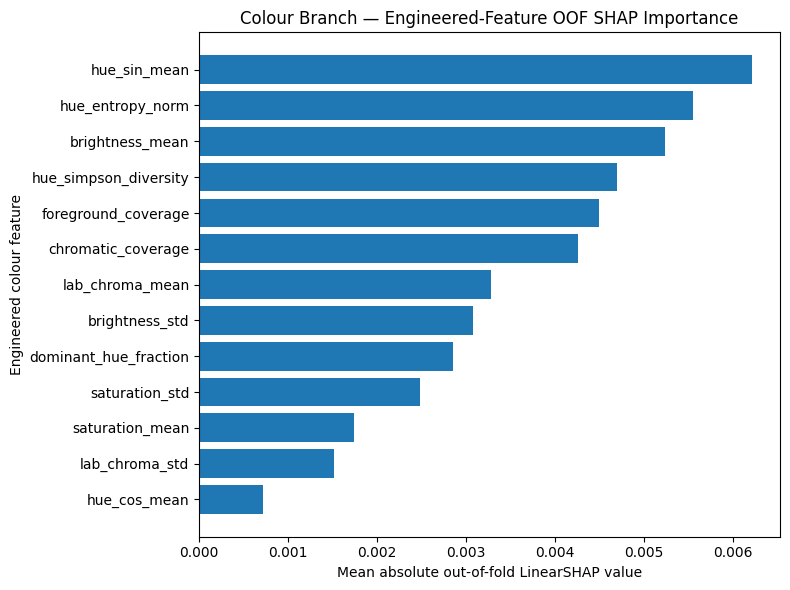

/tmp/ipykernel_2989/1400413719.py:2301: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


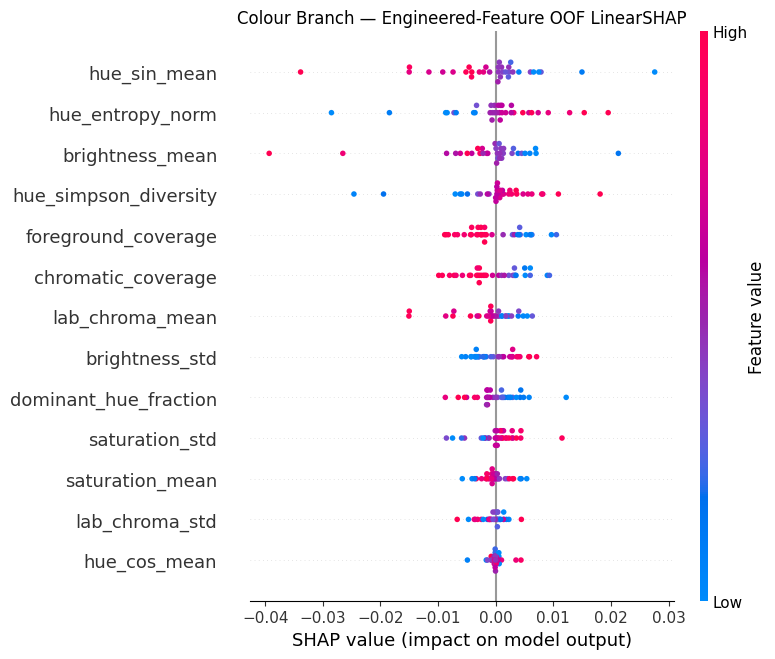

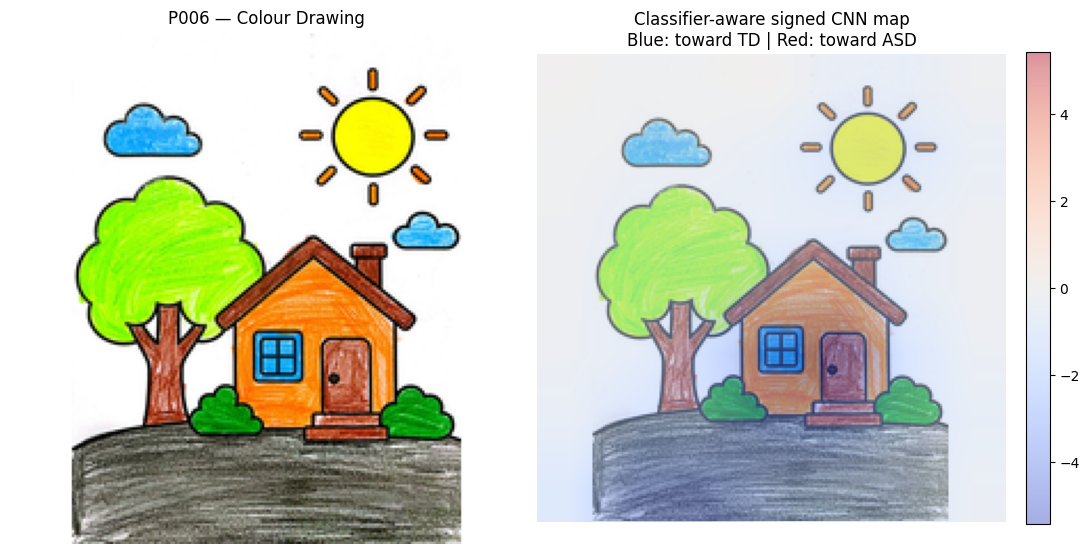


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell26_colour_oof_xai.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell26_colour_oof_activation_image_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell26_colour_oof_participant_reconstruction_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell26_colour_engineered_oof_shap_importance.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell26_colour_engineered_oof_shap_local_top5.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell26_colour_cnn_activation_contribution_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell26_colour_engineered_oof_shap_importance.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell26_colour_engineered_oof_shap_summary.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell26_c

,Importance_Rank,Feature,Mean_Absolute_OOF_SHAP,Mean_Signed_OOF_SHAP,TD_Mean_Signed_SHAP,ASD_Mean_Signed_SHAP
0,1,hue_sin_mean,0.006220,-0.000711,-0.002654,0.002065
1,2,hue_entropy_norm,0.005548,0.000118,-0.002887,0.004411
2,3,brightness_mean,0.005236,-0.001229,-0.002760,0.000959
3,4,hue_simpson_diversity,0.004697,0.000200,-0.002266,0.003724
4,5,foreground_coverage,0.004490,-0.000513,-0.002895,0.002891
5,6,chromatic_coverage,0.004262,-0.000604,-0.002692,0.002378
6,7,lab_chroma_mean,0.003280,-0.000992,-0.001194,-0.000703
7,8,brightness_std,0.003080,-0.000266,-0.001591,0.001626
8,9,dominant_hue_fraction,0.002852,0.000191,-0.001037,0.001945
9,10,saturation_std,0.002482,0.000227,0.000190,0.000280



Conventional Grad-CAM claimed: False
Classifier-aware CNN decomposition: True
Engineered-feature SHAP: True
Boundary-overflow interpretation claimed: False
Object-colour matching interpretation claimed: False
Clinical colour-marker claim: False
Expert XAI validation completed: False

CELL 26 STATUS: PASS


In [ ]:
# ============================================================
# CELL 26 — COLOUR CLASSIFIER-AWARE MAPS
#           + ENGINEERED-FEATURE LINEARSHAP
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import shap

from pathlib import Path
from PIL import Image
from joblib import load


print("=" * 78)
print("CELL 26 — COLOUR CLASSIFIER-AWARE MAPS + ENGINEERED SHAP")
print("=" * 78)


# ============================================================
# 1. VERIFY REQUIRED OBJECTS FROM EARLIER CELLS
# ============================================================

required_objects = [

    "X_colour",
    "X_colour_cnn",
    "COLOUR_FEATURE_NAMES",
    "colour_oof_probability",
    "OUTER_SPLITS",
    "outer_test_assignment",
    "cohort_ids",
    "groups",
    "efficientnet_model"
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required earlier-cell objects are missing: "
        f"{missing_objects}"
    )


colour_xai_efficientnet = efficientnet_model.to(
    DEVICE
)


colour_xai_efficientnet.eval()


for parameter in colour_xai_efficientnet.parameters():

    parameter.requires_grad = False


print("\nEFFICIENTNET BACKBONE")

print(
    "Feature dimension:",
    getattr(
        colour_xai_efficientnet,
        "num_features",
        None
    )
)

print(
    "Evaluation mode:",
    not colour_xai_efficientnet.training
)

print(
    "All parameters frozen:",
    all(
        not parameter.requires_grad
        for parameter
        in colour_xai_efficientnet.parameters()
    )
)


# ============================================================
# 2. LOCK COLOUR FEATURE PARTITION
# ============================================================

COLOUR_CNN_DIM = int(
    EXPECTED_EFFICIENTNET_DIM
)


COLOUR_ENGINEERED_DIM = len(
    COLOUR_FEATURE_NAMES
)


X_colour_xai = np.asarray(
    X_colour,
    dtype=np.float32
)


X_colour_cnn_xai = np.asarray(
    X_colour_cnn,
    dtype=np.float32
)


X_colour_engineered_xai = np.asarray(

    X_colour_xai[
        :,
        COLOUR_CNN_DIM:
    ],

    dtype=np.float32
)


if X_colour_xai.shape != (
    N_FINAL,
    COLOUR_CNN_DIM
    +
    COLOUR_ENGINEERED_DIM
):

    raise RuntimeError(
        "Unexpected combined Colour matrix shape."
    )


if X_colour_cnn_xai.shape != (
    N_FINAL,
    COLOUR_CNN_DIM
):

    raise RuntimeError(
        "Unexpected Colour CNN matrix shape."
    )


if X_colour_engineered_xai.shape != (
    N_FINAL,
    COLOUR_ENGINEERED_DIM
):

    raise RuntimeError(
        "Unexpected engineered Colour feature shape."
    )


if not np.allclose(

    X_colour_xai[
        :,
        :COLOUR_CNN_DIM
    ],

    X_colour_cnn_xai,

    atol=0.0,

    rtol=0.0
):

    raise RuntimeError(
        "Colour CNN block does not exactly match X_colour_cnn."
    )


print("\nCOLOUR FEATURE PARTITION")

print(
    "Combined features:",
    X_colour_xai.shape[1]
)

print(
    "CNN features:",
    COLOUR_CNN_DIM
)

print(
    "Engineered features:",
    COLOUR_ENGINEERED_DIM
)

print(
    "Engineered names:",
    COLOUR_FEATURE_NAMES
)


# ============================================================
# 3. LOAD VALIDATED COLOUR IMAGE PATHS
# ============================================================

image_manifest_file = (

    AUDIT_DIR
    /
    "cell04_image_manifest.csv"
)


colour_manifest = pd.read_csv(
    image_manifest_file
)


def normalize_column_name_colour(
    value
):

    return re.sub(

        r"[^a-z0-9]",

        "",

        str(
            value
        ).lower()
    )


def resolve_colour_manifest_column(
    dataframe,
    candidates
):

    lookup = {

        normalize_column_name_colour(
            column
        ):
            column

        for column
        in dataframe.columns
    }


    for candidate in candidates:

        normalized = normalize_column_name_colour(
            candidate
        )


        if normalized in lookup:

            return lookup[
                normalized
            ]


    return None


colour_manifest_id_column = (
    resolve_colour_manifest_column(

        colour_manifest,

        [
            "Participant_ID",
            "ParticipantID",
            "Canonical_ID"
        ]
    )
)


colour_manifest_modality_column = (
    resolve_colour_manifest_column(

        colour_manifest,

        [
            "Modality",
            "Logical_Modality",
            "Task",
            "Image_Type"
        ]
    )
)


colour_manifest_path_column = (
    resolve_colour_manifest_column(

        colour_manifest,

        [
            "File_Path",
            "Image_Path",
            "Resolved_Path",
            "Path",
            "FilePath"
        ]
    )
)


if (
    colour_manifest_id_column is None
    or
    colour_manifest_modality_column is None
    or
    colour_manifest_path_column is None
):

    raise RuntimeError(
        "Could not resolve required image-manifest columns."
    )


print("\nRESOLVED IMAGE MANIFEST COLUMNS")

print(
    "Participant ID:",
    colour_manifest_id_column
)

print(
    "Modality:",
    colour_manifest_modality_column
)

print(
    "File path:",
    colour_manifest_path_column
)


# ============================================================
# 4. IDENTIFY COLOUR DRAWING ROWS
# ============================================================

def is_colour_drawing_modality(
    value
):

    normalized = normalize_column_name_colour(
        value
    )


    return normalized in {

        "colourdrawing",
        "colordrawing",
        "colour",
        "color"
    }


colour_drawing_manifest = (

    colour_manifest[
        colour_manifest[
            colour_manifest_modality_column
        ].apply(
            is_colour_drawing_modality
        )
    ]

    .copy()
)


if len(
    colour_drawing_manifest
) != N_FINAL:

    raise RuntimeError(
        "Expected exactly one validated Colour Drawing "
        f"per participant; found {len(colour_drawing_manifest)}."
    )


if colour_drawing_manifest.duplicated(

    subset=[
        colour_manifest_id_column
    ],

    keep=False
).any():

    raise RuntimeError(
        "Duplicate Colour Drawing mapping detected."
    )


colour_image_path_lookup = {}


for _, row in colour_drawing_manifest.iterrows():

    participant_id = str(
        row[
            colour_manifest_id_column
        ]
    )


    image_path = Path(
        str(
            row[
                colour_manifest_path_column
            ]
        )
    )


    if not image_path.exists():

        raise FileNotFoundError(
            f"Missing validated Colour Drawing: {image_path}"
        )


    colour_image_path_lookup[
        participant_id
    ] = image_path


print(
    "Validated Colour Drawing paths:",
    len(
        colour_image_path_lookup
    )
)


# ============================================================
# 5. EXACT LOCKED IMAGE PREPROCESSING
# ============================================================

COLOUR_XAI_TARGET_SIZE = 224


COLOUR_IMAGENET_MEAN = torch.tensor(

    [
        0.485,
        0.456,
        0.406
    ],

    dtype=torch.float32
).view(
    3,
    1,
    1
)


COLOUR_IMAGENET_STD = torch.tensor(

    [
        0.229,
        0.224,
        0.225
    ],

    dtype=torch.float32
).view(
    3,
    1,
    1
)


def preprocess_colour_image_for_xai(
    image_path
):

    with Image.open(
        image_path
    ) as image:

        image = image.convert(
            "RGB"
        )


        original_width, original_height = (
            image.size
        )


        scale = min(

            COLOUR_XAI_TARGET_SIZE
            /
            original_width,

            COLOUR_XAI_TARGET_SIZE
            /
            original_height
        )


        resized_width = max(

            1,

            int(
                round(
                    original_width
                    *
                    scale
                )
            )
        )


        resized_height = max(

            1,

            int(
                round(
                    original_height
                    *
                    scale
                )
            )
        )


        resized = image.resize(

            (
                resized_width,
                resized_height
            ),

            resample=
                Image.Resampling.LANCZOS
        )


        canvas = Image.new(

            "RGB",

            (
                COLOUR_XAI_TARGET_SIZE,
                COLOUR_XAI_TARGET_SIZE
            ),

            color=(
                255,
                255,
                255
            )
        )


        pad_left = (

            COLOUR_XAI_TARGET_SIZE
            -
            resized_width

        ) // 2


        pad_top = (

            COLOUR_XAI_TARGET_SIZE
            -
            resized_height

        ) // 2


        canvas.paste(

            resized,

            (
                pad_left,
                pad_top
            )
        )


    display_array = np.asarray(
        canvas,
        dtype=np.uint8
    )


    tensor = torch.from_numpy(

        display_array.copy()

    ).permute(
        2,
        0,
        1
    ).float() / 255.0


    tensor = (

        tensor
        -
        COLOUR_IMAGENET_MEAN

    ) / COLOUR_IMAGENET_STD


    return (

        tensor.unsqueeze(
            0
        ).to(
            DEVICE
        ),

        display_array
    )


# ============================================================
# 6. FINAL FEATURE-MAP FORWARD PASS
# ============================================================

@torch.inference_mode()
def colour_xai_forward(
    input_tensor
):

    feature_map = (
        colour_xai_efficientnet
        .forward_features(
            input_tensor
        )
    )


    if feature_map.ndim != 4:

        raise RuntimeError(
            "EfficientNet feature map is not [B,C,H,W]."
        )


    if feature_map.shape[1] != COLOUR_CNN_DIM:

        raise RuntimeError(
            "Unexpected EfficientNet feature-map channels."
        )


    pooled_embedding = (
        colour_xai_efficientnet
        .forward_head(

            feature_map,

            pre_logits=True
        )
    )


    manual_spatial_mean = torch.mean(

        feature_map,

        dim=(
            2,
            3
        )
    )


    return (
        feature_map,
        pooled_embedding,
        manual_spatial_mean
    )


# ============================================================
# 7. STORAGE
# ============================================================

colour_cam_maps = None

colour_cam_height = None
colour_cam_width = None


colour_engineered_oof_shap = np.full(

    (
        N_FINAL,
        COLOUR_ENGINEERED_DIM
    ),

    np.nan,

    dtype=np.float64
)


colour_engineered_shap_base = np.full(
    N_FINAL,
    np.nan,
    dtype=np.float64
)


colour_engineered_component = np.full(
    N_FINAL,
    np.nan,
    dtype=np.float64
)


colour_xai_image_records = []

colour_xai_participant_records = []


COLOUR_XAI_EMBEDDING_TOL = 1e-4
COLOUR_XAI_POOLING_TOL = 1e-5
COLOUR_XAI_DECISION_TOL = 1e-4
COLOUR_XAI_PROBABILITY_TOL = 1e-4
COLOUR_XAI_SHAP_TOL = 1e-8


colour_cam_output_dir = (

    FIGURES_DIR
    /
    "cell26_colour_oof_activation_maps"
)


colour_cam_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 8. PROCESS EACH HELD-OUT PARTICIPANT
# ============================================================

print(
    "\nGENERATING OUT-OF-FOLD COLOUR EXPLANATIONS..."
)


for participant_index in range(
    N_FINAL
):

    participant_id = str(
        cohort_ids[
            participant_index
        ]
    )


    participant_group = str(
        groups[
            participant_index
        ]
    )


    outer_fold_number = int(
        outer_test_assignment[
            participant_index
        ]
    )


    outer_train_idx = OUTER_SPLITS[

        outer_fold_number
        -
        1

    ][0]


    # --------------------------------------------------------
    # Load exact held-out Colour model
    # --------------------------------------------------------

    if (
        "colour_model_files"
        in globals()
        and
        len(
            colour_model_files
        )
        ==
        OUTER_FOLDS
    ):

        colour_model_file = Path(

            colour_model_files[
                outer_fold_number
                -
                1
            ]
        )


    else:

        colour_model_file = (

            MODELS_DIR
            /
            (
                f"colour_outer_fold_"
                f"{outer_fold_number}.joblib"
            )
        )


    if not colour_model_file.exists():

        raise FileNotFoundError(
            f"Missing Colour fold model: "
            f"{colour_model_file}"
        )


    heldout_colour_model = load(
        colour_model_file
    )


    scaler = heldout_colour_model.named_steps[
        "scaler"
    ]


    classifier = heldout_colour_model.named_steps[
        "classifier"
    ]


    beta_scaled = (
        classifier.coef_[0]
        .astype(
            np.float64
        )
    )


    scaler_mean = (
        scaler.mean_
        .astype(
            np.float64
        )
    )


    scaler_scale = (
        scaler.scale_
        .astype(
            np.float64
        )
    )


    if len(
        beta_scaled
    ) != X_colour_xai.shape[1]:

        raise RuntimeError(
            "Colour classifier coefficient dimension mismatch."
        )


    if np.any(
        scaler_scale <= 0
    ):

        raise RuntimeError(
            "Colour scaler contains non-positive scale."
        )


    effective_weight = (

        beta_scaled

        /

        scaler_scale
    )


    cnn_effective_weight = (
        effective_weight[
            :COLOUR_CNN_DIM
        ]
    )


    engineered_effective_weight = (
        effective_weight[
            COLOUR_CNN_DIM:
        ]
    )


    classifier_constant = float(

        classifier.intercept_[0]

        -

        np.sum(

            beta_scaled

            *

            (
                scaler_mean
                /
                scaler_scale
            )
        )
    )


    # --------------------------------------------------------
    # Verify exact stored OOF prediction
    # --------------------------------------------------------

    stored_full_vector = (
        X_colour_xai[
            participant_index
        ]
        .reshape(
            1,
            -1
        )
    )


    stored_decision = float(

        heldout_colour_model
        .decision_function(
            stored_full_vector
        )[0]
    )


    stored_probability = float(

        heldout_colour_model
        .predict_proba(
            stored_full_vector
        )[
            0,
            1
        ]
    )


    expected_oof_probability = float(

        colour_oof_probability[
            participant_index
        ]
    )


    stored_probability_diff = abs(

        stored_probability

        -

        expected_oof_probability
    )


    if stored_probability_diff > 1e-8:

        raise RuntimeError(
            f"{participant_id}: Colour model does not "
            "reproduce stored OOF probability."
        )


    # --------------------------------------------------------
    # Recompute CNN representation from original image
    # --------------------------------------------------------

    image_path = colour_image_path_lookup[
        participant_id
    ]


    (
        input_tensor,
        display_array
    ) = preprocess_colour_image_for_xai(
        image_path
    )


    (
        feature_map_tensor,
        pooled_embedding_tensor,
        manual_spatial_mean_tensor
    ) = colour_xai_forward(
        input_tensor
    )


    feature_map = (

        feature_map_tensor[
            0
        ]

        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )


    recomputed_cnn_embedding = (

        pooled_embedding_tensor[
            0
        ]

        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )


    manual_spatial_mean = (

        manual_spatial_mean_tensor[
            0
        ]

        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )


    pooling_diff = float(

        np.max(

            np.abs(

                recomputed_cnn_embedding

                -

                manual_spatial_mean
            )
        )
    )


    if pooling_diff > COLOUR_XAI_POOLING_TOL:

        raise RuntimeError(
            f"{participant_id}: EfficientNet GAP "
            "reconstruction failed."
        )


    stored_cnn_embedding = (

        X_colour_cnn_xai[
            participant_index
        ]

        .astype(
            np.float64
        )
    )


    embedding_diff = float(

        np.max(

            np.abs(

                recomputed_cnn_embedding

                -

                stored_cnn_embedding
            )
        )
    )


    embedding_cosine = float(

        np.dot(
            recomputed_cnn_embedding,
            stored_cnn_embedding
        )

        /

        (
            np.linalg.norm(
                recomputed_cnn_embedding
            )

            *

            np.linalg.norm(
                stored_cnn_embedding
            )
        )
    )


    if embedding_diff > COLOUR_XAI_EMBEDDING_TOL:

        raise RuntimeError(
            f"{participant_id}: recomputed Colour CNN "
            f"embedding differs from Cell 10. "
            f"Max diff={embedding_diff}"
        )


    # ========================================================
    # 8A. EXACT CLASSIFIER-AWARE CNN SPATIAL MAP
    # ========================================================

    signed_cam = np.tensordot(

        cnn_effective_weight,

        feature_map,

        axes=(
            0,
            0
        )
    )


    if colour_cam_height is None:

        (
            colour_cam_height,
            colour_cam_width
        ) = signed_cam.shape


        colour_cam_maps = np.full(

            (
                N_FINAL,
                colour_cam_height,
                colour_cam_width
            ),

            np.nan,

            dtype=np.float32
        )


    if signed_cam.shape != (
        colour_cam_height,
        colour_cam_width
    ):

        raise RuntimeError(
            "Colour feature-map spatial dimensions changed."
        )


    colour_cam_maps[
        participant_index
    ] = signed_cam.astype(
        np.float32
    )


    spatial_cnn_contribution = float(
        np.mean(
            signed_cam
        )
    )


    direct_cnn_contribution = float(

        np.dot(

            cnn_effective_weight,

            recomputed_cnn_embedding
        )
    )


    cnn_reconstruction_diff = abs(

        spatial_cnn_contribution

        -

        direct_cnn_contribution
    )


    if cnn_reconstruction_diff > COLOUR_XAI_DECISION_TOL:

        raise RuntimeError(
            f"{participant_id}: Colour CAM mean does not "
            "reconstruct CNN logit contribution."
        )


    # ========================================================
    # 8B. ENGINEERED FEATURE CONTRIBUTION
    # ========================================================

    participant_engineered_raw = (

        X_colour_engineered_xai[
            participant_index
        ]

        .astype(
            np.float64
        )
    )


    engineered_raw_contribution = float(

        np.dot(

            engineered_effective_weight,

            participant_engineered_raw
        )
    )


    # ========================================================
    # 8C. FULL RAW-FEATURE DECISION RECONSTRUCTION
    # ========================================================

    reconstructed_decision = float(

        classifier_constant

        +

        spatial_cnn_contribution

        +

        engineered_raw_contribution
    )


    decision_reconstruction_diff = abs(

        reconstructed_decision

        -

        stored_decision
    )


    if decision_reconstruction_diff > COLOUR_XAI_DECISION_TOL:

        raise RuntimeError(
            f"{participant_id}: CNN map + engineered "
            "contribution does not reconstruct Colour logit."
        )


    recomputed_full_vector = np.concatenate(

        [
            recomputed_cnn_embedding,
            participant_engineered_raw
        ]
    ).reshape(
        1,
        -1
    )


    recomputed_probability = float(

        heldout_colour_model
        .predict_proba(
            recomputed_full_vector
        )[
            0,
            1
        ]
    )


    probability_reproduction_diff = abs(

        recomputed_probability

        -

        expected_oof_probability
    )


    if (
        probability_reproduction_diff
        >
        COLOUR_XAI_PROBABILITY_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: recomputed Colour probability "
            "differs beyond tolerance."
        )


    # ========================================================
    # 8D. OUTER-TRAINING ENGINEERED-FEATURE LINEARSHAP
    #
    # Work on standardized features because beta_scaled is the
    # actual Logistic Regression coefficient vector.
    # ========================================================

    X_outer_train_standardized = (
        scaler.transform(

            X_colour_xai[
                outer_train_idx
            ]
        )
    )


    engineered_train_standardized = (

        X_outer_train_standardized[
            :,
            COLOUR_CNN_DIM:
        ]

        .astype(
            np.float64
        )
    )


    participant_standardized = (

        scaler.transform(
            stored_full_vector
        )[
            0
        ]

        .astype(
            np.float64
        )
    )


    engineered_standardized = (
        participant_standardized[
            COLOUR_CNN_DIM:
        ]
    )


    beta_engineered_scaled = (
        beta_scaled[
            COLOUR_CNN_DIM:
        ]
    )


    # Interventional LinearSHAP background expectation,
    # derived exclusively from outer-training participants.
    engineered_background_mean = np.mean(

        engineered_train_standardized,

        axis=0
    )


    engineered_shap_values = (

        beta_engineered_scaled

        *

        (
            engineered_standardized

            -

            engineered_background_mean
        )
    )


    engineered_shap_base = float(

        np.dot(

            beta_engineered_scaled,

            engineered_background_mean
        )
    )


    engineered_scaled_component = float(

        np.dot(

            beta_engineered_scaled,

            engineered_standardized
        )
    )


    engineered_shap_reconstruction = float(

        engineered_shap_base

        +

        np.sum(
            engineered_shap_values
        )
    )


    engineered_shap_diff = abs(

        engineered_shap_reconstruction

        -

        engineered_scaled_component
    )


    if engineered_shap_diff > COLOUR_XAI_SHAP_TOL:

        raise RuntimeError(
            f"{participant_id}: engineered LinearSHAP "
            "reconstruction failed."
        )


    colour_engineered_oof_shap[
        participant_index
    ] = engineered_shap_values


    colour_engineered_shap_base[
        participant_index
    ] = engineered_shap_base


    colour_engineered_component[
        participant_index
    ] = engineered_scaled_component


    # ========================================================
    # 8E. SAVE INDIVIDUAL CNN OVERLAY
    # ========================================================

    display_scale = float(

        np.quantile(

            np.abs(
                signed_cam
            ),

            0.99
        )
    )


    if (
        not np.isfinite(
            display_scale
        )
        or
        display_scale <= 0
    ):

        display_scale = 1.0


    fig, ax = plt.subplots(
        figsize=(
            6,
            7
        )
    )


    ax.imshow(
        display_array
    )


    heatmap = ax.imshow(

        signed_cam,

        cmap="coolwarm",

        interpolation="bilinear",

        alpha=0.45,

        extent=[
            0,
            COLOUR_XAI_TARGET_SIZE,
            COLOUR_XAI_TARGET_SIZE,
            0
        ],

        vmin=
            -display_scale,

        vmax=
            display_scale
    )


    ax.set_title(

        f"{participant_id} — Colour Drawing\n"
        f"OOF Colour P(ASD)="
        f"{expected_oof_probability:.3f}"
    )


    ax.axis(
        "off"
    )


    colorbar = fig.colorbar(

        heatmap,

        ax=ax,

        fraction=0.046,

        pad=0.04
    )


    colorbar.set_label(
        "Signed CNN contribution to Colour logit"
    )


    fig.tight_layout()


    overlay_file = (

        colour_cam_output_dir
        /
        (
            f"{participant_id}_"
            f"colour_oof_signed_cam.png"
        )
    )


    fig.savefig(

        overlay_file,

        dpi=180,

        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    # ========================================================
    # 8F. AUDIT RECORDS
    # ========================================================

    colour_xai_image_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            participant_group,

        "Outer_Fold":
            outer_fold_number,

        "Image_Path":
            str(
                image_path
            ),

        "Colour_OOF_Probability_ASD":
            expected_oof_probability,

        "Stored_Embedding_Max_Abs_Diff":
            embedding_diff,

        "Stored_Embedding_Cosine_Similarity":
            embedding_cosine,

        "Pooling_Max_Abs_Diff":
            pooling_diff,

        "Spatial_CNN_Logit_Contribution":
            spatial_cnn_contribution,

        "Direct_CNN_Logit_Contribution":
            direct_cnn_contribution,

        "CNN_Contribution_Reconstruction_Abs_Diff":
            cnn_reconstruction_diff,

        "Signed_CAM_Min":
            float(
                np.min(
                    signed_cam
                )
            ),

        "Signed_CAM_Max":
            float(
                np.max(
                    signed_cam
                )
            ),

        "Signed_CAM_Mean":
            float(
                np.mean(
                    signed_cam
                )
            ),

        "Positive_Spatial_Fraction":
            float(
                np.mean(
                    signed_cam > 0
                )
            ),

        "Negative_Spatial_Fraction":
            float(
                np.mean(
                    signed_cam < 0
                )
            ),

        "Overlay_File":
            str(
                overlay_file
            )
    })


    colour_xai_participant_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            participant_group,

        "Outer_Fold":
            outer_fold_number,

        "Stored_Colour_OOF_Probability_ASD":
            expected_oof_probability,

        "Recomputed_Colour_Probability_ASD":
            recomputed_probability,

        "Probability_Abs_Diff":
            probability_reproduction_diff,

        "Stored_Colour_Decision":
            stored_decision,

        "Reconstructed_Colour_Decision":
            reconstructed_decision,

        "Decision_Reconstruction_Abs_Diff":
            decision_reconstruction_diff,

        "Classifier_Constant":
            classifier_constant,

        "CNN_Logit_Contribution":
            spatial_cnn_contribution,

        "Engineered_Raw_Logit_Contribution":
            engineered_raw_contribution,

        "Engineered_Standardized_Component":
            engineered_scaled_component,

        "Engineered_SHAP_Base":
            engineered_shap_base,

        "Engineered_SHAP_Reconstruction_Abs_Diff":
            engineered_shap_diff,

        "Model_File":
            str(
                colour_model_file
            )
    })


# ============================================================
# 9. GLOBAL NUMERICAL AUDIT
# ============================================================

colour_xai_image_audit_df = pd.DataFrame(
    colour_xai_image_records
)


colour_xai_participant_audit_df = pd.DataFrame(
    colour_xai_participant_records
)


if colour_cam_maps is None:

    raise RuntimeError(
        "No Colour CNN activation maps were generated."
    )


if not np.isfinite(
    colour_cam_maps
).all():

    raise RuntimeError(
        "Colour CAM tensor contains non-finite values."
    )


if not np.isfinite(
    colour_engineered_oof_shap
).all():

    raise RuntimeError(
        "Colour engineered SHAP matrix contains "
        "non-finite values."
    )


maximum_embedding_difference = float(

    colour_xai_image_audit_df[
        "Stored_Embedding_Max_Abs_Diff"
    ].max()
)


minimum_embedding_cosine = float(

    colour_xai_image_audit_df[
        "Stored_Embedding_Cosine_Similarity"
    ].min()
)


maximum_pooling_difference = float(

    colour_xai_image_audit_df[
        "Pooling_Max_Abs_Diff"
    ].max()
)


maximum_cnn_reconstruction_difference = float(

    colour_xai_image_audit_df[
        "CNN_Contribution_Reconstruction_Abs_Diff"
    ].max()
)


maximum_decision_reconstruction_difference = float(

    colour_xai_participant_audit_df[
        "Decision_Reconstruction_Abs_Diff"
    ].max()
)


maximum_probability_difference = float(

    colour_xai_participant_audit_df[
        "Probability_Abs_Diff"
    ].max()
)


maximum_engineered_shap_difference = float(

    colour_xai_participant_audit_df[
        "Engineered_SHAP_Reconstruction_Abs_Diff"
    ].max()
)


print("\nGLOBAL COLOUR XAI NUMERICAL AUDIT")

print(
    "CNN activation-map tensor:",
    colour_cam_maps.shape
)

print(
    "Engineered SHAP matrix:",
    colour_engineered_oof_shap.shape
)

print(
    "Maximum stored-embedding abs diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum GAP reconstruction diff:",
    maximum_pooling_difference
)

print(
    "Maximum CNN contribution reconstruction diff:",
    maximum_cnn_reconstruction_difference
)

print(
    "Maximum full-decision reconstruction diff:",
    maximum_decision_reconstruction_difference
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)

print(
    "Maximum engineered SHAP reconstruction diff:",
    maximum_engineered_shap_difference
)


# ============================================================
# 10. GLOBAL ENGINEERED-FEATURE SHAP IMPORTANCE
# ============================================================

colour_engineered_shap_importance_df = pd.DataFrame({

    "Feature":
        COLOUR_FEATURE_NAMES,

    "Mean_Absolute_OOF_SHAP":
        np.mean(

            np.abs(
                colour_engineered_oof_shap
            ),

            axis=0
        ),

    "Mean_Signed_OOF_SHAP":
        np.mean(

            colour_engineered_oof_shap,

            axis=0
        ),

    "TD_Mean_Signed_SHAP":
        np.mean(

            colour_engineered_oof_shap[
                y == 0
            ],

            axis=0
        ),

    "ASD_Mean_Signed_SHAP":
        np.mean(

            colour_engineered_oof_shap[
                y == 1
            ],

            axis=0
        )
})


colour_engineered_shap_importance_df[
    "Importance_Rank"
] = (

    colour_engineered_shap_importance_df[
        "Mean_Absolute_OOF_SHAP"
    ]

    .rank(
        method="min",
        ascending=False
    )

    .astype(
        int
    )
)


colour_engineered_shap_importance_df = (

    colour_engineered_shap_importance_df

    .sort_values(
        "Importance_Rank"
    )

    .reset_index(
        drop=True
    )
)


print("\nENGINEERED COLOUR FEATURE OOF SHAP IMPORTANCE")

display(
    colour_engineered_shap_importance_df.round(
        6
    )
)


# ============================================================
# 11. GROUP-LEVEL CNN CONTRIBUTION SUMMARY
# ============================================================

colour_cnn_contribution_summary_df = (

    colour_xai_image_audit_df

    .groupby(
        "Group"
    )

    .agg(

        N=(
            "Participant_ID",
            "count"
        ),

        Mean_Signed_CNN_Logit_Contribution=(
            "Spatial_CNN_Logit_Contribution",
            "mean"
        ),

        Mean_Absolute_CNN_Logit_Contribution=(
            "Spatial_CNN_Logit_Contribution",
            lambda x:
                float(
                    np.mean(
                        np.abs(
                            np.asarray(
                                x,
                                dtype=float
                            )
                        )
                    )
                )
        ),

        Mean_Positive_Spatial_Fraction=(
            "Positive_Spatial_Fraction",
            "mean"
        ),

        Mean_Negative_Spatial_Fraction=(
            "Negative_Spatial_Fraction",
            "mean"
        )
    )

    .reset_index()
)


print("\nCOLOUR CNN ACTIVATION CONTRIBUTION SUMMARY")

display(
    colour_cnn_contribution_summary_df.round(
        6
    )
)


# ============================================================
# 12. LOCAL TOP ENGINEERED SHAP FEATURES
# ============================================================

COLOUR_LOCAL_TOP_K = 5


colour_local_shap_records = []


for participant_index in range(
    N_FINAL
):

    values = colour_engineered_oof_shap[
        participant_index
    ]


    top_indices = np.argsort(

        -np.abs(
            values
        )

    )[
        :COLOUR_LOCAL_TOP_K
    ]


    for local_rank, feature_index in enumerate(

        top_indices,

        start=1
    ):

        shap_value = float(
            values[
                feature_index
            ]
        )


        colour_local_shap_records.append({

            "Participant_ID":
                cohort_ids[
                    participant_index
                ],

            "Group":
                groups[
                    participant_index
                ],

            "Outer_Fold":
                int(
                    outer_test_assignment[
                        participant_index
                    ]
                ),

            "Colour_OOF_Probability_ASD":
                float(
                    colour_oof_probability[
                        participant_index
                    ]
                ),

            "Local_Rank":
                local_rank,

            "Feature":
                COLOUR_FEATURE_NAMES[
                    feature_index
                ],

            "Raw_Feature_Value":
                float(
                    X_colour_engineered_xai[
                        participant_index,
                        feature_index
                    ]
                ),

            "SHAP_Value":
                shap_value,

            "Absolute_SHAP":
                abs(
                    shap_value
                ),

            "Direction":
                (
                    "Toward ASD"

                    if shap_value > 0

                    else
                    "Toward TD"

                    if shap_value < 0

                    else
                    "Neutral"
                )
        })


colour_local_shap_df = pd.DataFrame(
    colour_local_shap_records
)


print(
    "\nLOCAL ENGINEERED-FEATURE SHAP PREVIEW"
)

display(

    colour_local_shap_df

    .head(
        15
    )

    .round(
        6
    )
)


# ============================================================
# 13. ENGINEERED-FEATURE SHAP BAR FIGURE
# ============================================================

plot_shap_df = (

    colour_engineered_shap_importance_df

    .sort_values(
        "Mean_Absolute_OOF_SHAP",
        ascending=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        6
    )
)


ax.barh(

    plot_shap_df[
        "Feature"
    ],

    plot_shap_df[
        "Mean_Absolute_OOF_SHAP"
    ]
)


ax.set_xlabel(
    "Mean absolute out-of-fold LinearSHAP value"
)


ax.set_ylabel(
    "Engineered colour feature"
)


ax.set_title(
    "Colour Branch — Engineered-Feature OOF SHAP Importance"
)


fig.tight_layout()


colour_shap_bar_file = (

    FIGURES_DIR
    /
    "cell26_colour_engineered_oof_shap_importance.png"
)


fig.savefig(

    colour_shap_bar_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. ENGINEERED-FEATURE SHAP SUMMARY / BEESWARM
# ============================================================

shap.summary_plot(

    colour_engineered_oof_shap,

    X_colour_engineered_xai,

    feature_names=
        COLOUR_FEATURE_NAMES,

    max_display=
        COLOUR_ENGINEERED_DIM,

    show=False
)


plt.title(
    "Colour Branch — Engineered-Feature OOF LinearSHAP"
)


plt.tight_layout()


colour_shap_summary_file = (

    FIGURES_DIR
    /
    "cell26_colour_engineered_oof_shap_summary.png"
)


plt.savefig(

    colour_shap_summary_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 15. OBJECTIVE QC OVERLAY
#
# First participant in locked cohort order.
# ============================================================

qc_index = 0


qc_participant_id = str(
    cohort_ids[
        qc_index
    ]
)


qc_image_path = colour_image_path_lookup[
    qc_participant_id
]


(
    _,
    qc_display_array
) = preprocess_colour_image_for_xai(
    qc_image_path
)


qc_cam = colour_cam_maps[
    qc_index
]


qc_scale = float(

    np.quantile(

        np.abs(
            qc_cam
        ),

        0.99
    )
)


if qc_scale <= 0:

    qc_scale = 1.0


fig, axes = plt.subplots(

    1,
    2,

    figsize=(
        11,
        6
    )
)


axes[
    0
].imshow(
    qc_display_array
)


axes[
    0
].set_title(
    f"{qc_participant_id} — Colour Drawing"
)


axes[
    0
].axis(
    "off"
)


axes[
    1
].imshow(
    qc_display_array
)


qc_artist = axes[
    1
].imshow(

    qc_cam,

    cmap="coolwarm",

    interpolation="bilinear",

    alpha=0.45,

    extent=[
        0,
        COLOUR_XAI_TARGET_SIZE,
        COLOUR_XAI_TARGET_SIZE,
        0
    ],

    vmin=
        -qc_scale,

    vmax=
        qc_scale
)


axes[
    1
].set_title(
    "Classifier-aware signed CNN map\n"
    "Blue: toward TD | Red: toward ASD"
)


axes[
    1
].axis(
    "off"
)


fig.colorbar(

    qc_artist,

    ax=axes[
        1
    ],

    fraction=0.046,

    pad=0.04
)


fig.tight_layout()


colour_cam_qc_file = (

    FIGURES_DIR
    /
    "cell26_colour_oof_activation_map_qc.png"
)


fig.savefig(

    colour_cam_qc_file,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. SAVE RAW XAI ARTIFACT
# ============================================================

colour_xai_npz_file = (

    EMBEDDINGS_DIR
    /
    "cell26_colour_oof_xai.npz"
)


np.savez_compressed(

    colour_xai_npz_file,

    participant_ids=
        np.asarray(
            cohort_ids,
            dtype="U"
        ),

    groups=
        np.asarray(
            groups,
            dtype="U"
        ),

    outer_folds=
        np.asarray(
            outer_test_assignment,
            dtype=np.int64
        ),

    engineered_feature_names=
        np.asarray(
            COLOUR_FEATURE_NAMES,
            dtype="U"
        ),

    cnn_signed_activation_maps=
        colour_cam_maps.astype(
            np.float32
        ),

    engineered_shap_values=
        colour_engineered_oof_shap.astype(
            np.float32
        ),

    engineered_raw_values=
        X_colour_engineered_xai.astype(
            np.float32
        ),

    engineered_shap_base=
        colour_engineered_shap_base.astype(
            np.float32
        )
)


# ============================================================
# 17. SAVE TABLES
# ============================================================

colour_xai_image_audit_file = (

    AUDIT_DIR
    /
    "cell26_colour_oof_activation_image_audit.csv"
)


colour_xai_participant_audit_file = (

    AUDIT_DIR
    /
    "cell26_colour_oof_participant_reconstruction_audit.csv"
)


colour_engineered_shap_importance_file = (

    RESULTS_DIR
    /
    "cell26_colour_engineered_oof_shap_importance.csv"
)


colour_local_shap_file = (

    RESULTS_DIR
    /
    "cell26_colour_engineered_oof_shap_local_top5.csv"
)


colour_cnn_contribution_summary_file = (

    RESULTS_DIR
    /
    "cell26_colour_cnn_activation_contribution_summary.csv"
)


colour_xai_image_audit_df.to_csv(

    colour_xai_image_audit_file,

    index=False
)


colour_xai_participant_audit_df.to_csv(

    colour_xai_participant_audit_file,

    index=False
)


colour_engineered_shap_importance_df.to_csv(

    colour_engineered_shap_importance_file,

    index=False
)


colour_local_shap_df.to_csv(

    colour_local_shap_file,

    index=False
)


colour_cnn_contribution_summary_df.to_csv(

    colour_cnn_contribution_summary_file,

    index=False
)


# ============================================================
# 18. SAVE COLOUR XAI PROTOCOL
# ============================================================

colour_xai_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Explained classifier",

        "Value":
            (
                "Outer-fold Colour StandardScaler + "
                "L2 Logistic Regression"
            )
    },

    {
        "Setting":
            "CNN backbone",

        "Value":
            "Frozen EfficientNet-B0"
    },

    {
        "Setting":
            "CNN explanation",

        "Value":
            (
                "Exact signed classifier-aware "
                "activation decomposition"
            )
    },

    {
        "Setting":
            "Conventional Grad-CAM claimed",

        "Value":
            False
    },

    {
        "Setting":
            "Engineered-feature explanation",

        "Value":
            (
                "Exact interventional LinearSHAP "
                "with outer-training background"
            )
    },

    {
        "Setting":
            "Engineered feature count",

        "Value":
            COLOUR_ENGINEERED_DIM
    },

    {
        "Setting":
            "Participant explained by classifier "
            "trained on that participant",

        "Value":
            False
    },

    {
        "Setting":
            "Positive CNN/SHAP value",

        "Value":
            "Pushes Colour model toward ASD"
    },

    {
        "Setting":
            "Negative CNN/SHAP value",

        "Value":
            "Pushes Colour model toward TD"
    },

    {
        "Setting":
            "Boundary overflow explained",

        "Value":
            False
    },

    {
        "Setting":
            "Object-colour matching explained",

        "Value":
            False
    },

    {
        "Setting":
            "Clinical colour-marker claim",

        "Value":
            False
    },

    {
        "Setting":
            "Expert XAI validation completed",

        "Value":
            False
    }
])


colour_xai_protocol_file = (

    MANIFEST_DIR
    /
    "cell26_colour_oof_xai_protocol.csv"
)


colour_xai_protocol_df.to_csv(

    colour_xai_protocol_file,

    index=False
)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print("\nSAVED OUTPUTS")

print(
    colour_xai_npz_file
)

print(
    colour_xai_image_audit_file
)

print(
    colour_xai_participant_audit_file
)

print(
    colour_engineered_shap_importance_file
)

print(
    colour_local_shap_file
)

print(
    colour_cnn_contribution_summary_file
)

print(
    colour_shap_bar_file
)

print(
    colour_shap_summary_file
)

print(
    colour_cam_qc_file
)

print(
    colour_cam_output_dir
)

print(
    colour_xai_protocol_file
)


print("\n" + "=" * 78)
print("COLOUR CLASSIFIER-AWARE XAI SUMMARY")


print(
    "Participants explained:",
    N_FINAL,
    "/",
    N_FINAL
)

print(
    "Colour images explained:",
    len(
        colour_xai_image_audit_df
    ),
    "/",
    N_FINAL
)

print(
    "CNN activation-map tensor:",
    colour_cam_maps.shape
)

print(
    "Engineered SHAP matrix:",
    colour_engineered_oof_shap.shape
)

print(
    "Maximum embedding reproduction diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum GAP reconstruction diff:",
    maximum_pooling_difference
)

print(
    "Maximum CNN contribution reconstruction diff:",
    maximum_cnn_reconstruction_difference
)

print(
    "Maximum full-decision reconstruction diff:",
    maximum_decision_reconstruction_difference
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)

print(
    "Maximum engineered SHAP reconstruction diff:",
    maximum_engineered_shap_difference
)


print(
    "\nTop engineered colour features by mean "
    "absolute OOF SHAP:"
)


display(

    colour_engineered_shap_importance_df[
        [
            "Importance_Rank",
            "Feature",
            "Mean_Absolute_OOF_SHAP",
            "Mean_Signed_OOF_SHAP",
            "TD_Mean_Signed_SHAP",
            "ASD_Mean_Signed_SHAP"
        ]
    ]

    .head(
        10
    )

    .round(
        6
    )
)


print(
    "\nConventional Grad-CAM claimed:",
    False
)

print(
    "Classifier-aware CNN decomposition:",
    True
)

print(
    "Engineered-feature SHAP:",
    True
)

print(
    "Boundary-overflow interpretation claimed:",
    False
)

print(
    "Object-colour matching interpretation claimed:",
    False
)

print(
    "Clinical colour-marker claim:",
    False
)

print(
    "Expert XAI validation completed:",
    False
)


print("\nCELL 26 STATUS: PASS")
print("=" * 78)

# 27. Draw-a-Man — DINOv2 Attention Rollout

The Draw-a-Man branch uses:

1. a frozen DINOv2-small vision transformer;
2. the final-layer CLS token as a 384-dimensional representation;
3. StandardScaler;
4. L2 Logistic Regression.

Explainability for this branch uses DINOv2 attention rollout.

## Attention rollout

For every transformer layer:

1. attention is averaged across attention heads;
2. an identity residual connection is added;
3. the resulting attention matrix is row-normalized.

The matrices are then multiplied sequentially through the transformer depth.

The final CLS-to-patch attention vector is extracted and reshaped to the
DINOv2 patch grid.

For a 224 × 224 image with DINOv2-small's 14 × 14 patch size, this produces a
16 × 16 spatial attention map.

The patch values are normalized to sum to one for descriptive visualization.

## Relationship to the evaluated classifier

Attention rollout explains how the frozen DINOv2 backbone propagates
information between image patches and the CLS token.

It is not a signed attribution of the downstream Logistic Regression
classifier.

Therefore highlighted regions must not be described as:

- pushing the model toward ASD;
- pushing the model toward TD;
- clinically abnormal anatomical regions.

To connect the rollout computation to the actual evaluated DAM pipeline, the
notebook verifies for every participant that:

- the CLS embedding regenerated during attention extraction matches the
  previously stored DINOv2 embedding;
- the participant's held-out DAM Logistic Regression model reproduces the
  saved out-of-fold ASD probability from that regenerated representation.

Thus the attention map is obtained from the same frozen representation that
was supplied to the held-out DAM classifier.

## Interpretation limits

Attention concentration indicates areas receiving relatively greater
backbone attention.

It does not establish:

- causal drawing features;
- classifier-specific signed importance;
- clinically meaningful body-part abnormalities;
- expert-validated ASD markers.

The known age imbalance is particularly relevant for Draw-a-Man
interpretation because human-figure drawing characteristics can vary with
development.

Independent expert XAI validation remains pending.

CELL 27 — DRAW-A-MAN DINOV2 ATTENTION ROLLOUT

DINOV2 BACKBONE
Located variable: dino_model
Model type: dinov2
Hidden dimension: 384
Transformer layers: 12
Attention heads: 6
Patch size: 14
Evaluation mode: True
All parameters frozen: True

DAM REPRESENTATION
Shape: (34, 384)
Representation: Final-layer DINOv2 CLS token

RESOLVED IMAGE MANIFEST COLUMNS
Participant ID: Participant_ID
Modality: Modality
File path: File_Path
Validated Draw-a-Man paths: 34

ATTENTION FORWARD TEST
Participant: P006
Attention implementation switched to eager: True
Attention layers returned: 12
First attention tensor shape: (1, 6, 257, 257)
Patch rollout shape: (16, 16)
Normalized rollout sum: 1.0

NUMERICAL TOLERANCE POLICY
Stored OOF probability tolerance: 1e-05
Regenerated CLS probability tolerance: 0.0001
Embedding absolute tolerance: 0.0001
Embedding cosine minimum: 0.99999

GENERATING DINOV2 ATTENTION ROLLOUT MAPS...

GLOBAL DAM ATTENTION NUMERICAL AUDIT
Attention rollout tensor: (34, 16, 16)
Maximum st

,Group,N,Mean_Normalized_Attention_Entropy,SD_Normalized_Attention_Entropy,Mean_Peak_Normalized_Attention,Mean_Attention_Center_X,Mean_Attention_Center_Y
0,ASD,14,0.940289,0.012649,0.101082,0.486562,0.503184
1,TD,20,0.941699,0.008716,0.105948,0.492432,0.499970


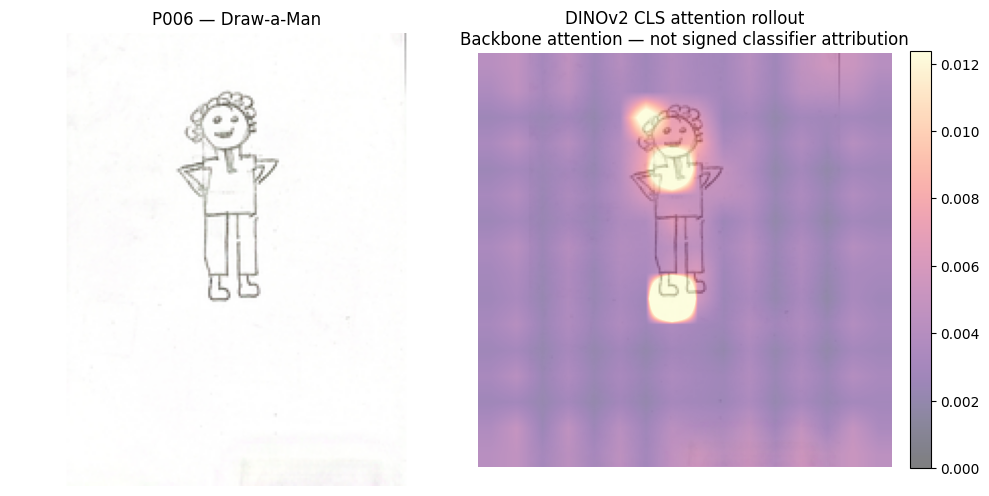

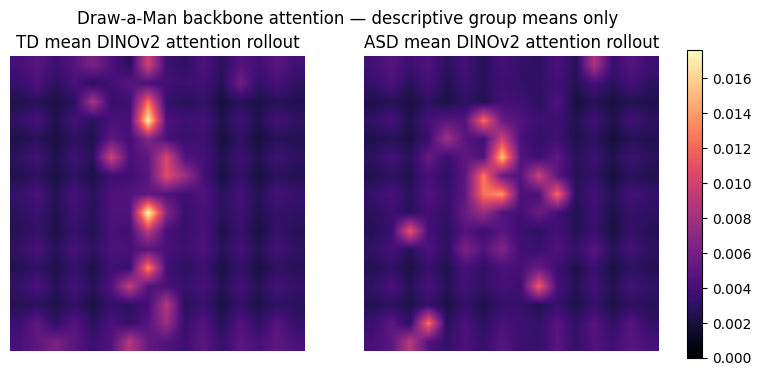


SAVED OUTPUTS
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/embeddings/cell27_dam_attention_rollout.npz
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell27_dam_attention_rollout_participant_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell27_dam_attention_rollout_layer_audit.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell27_dam_attention_descriptor_summary.csv
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell27_dam_attention_rollout_qc.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell27_dam_attention_rollout_group_means.png
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/figures/cell27_dam_attention_rollout_maps
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell27_dam_attention_rollout_protocol.csv

DAM DINOV2 ATTENTION ROLLOUT SUMMARY
Participants explained: 34 / 34
Draw-a-Man images explained: 34 / 34
Attention

In [ ]:
# ============================================================
# CELL 27 — DRAW-A-MAN DINOV2 ATTENTION ROLLOUT
# UPDATED WITH NUMERICAL-TOLERANCE REPAIR
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from PIL import Image
from joblib import load


print("=" * 78)
print("CELL 27 — DRAW-A-MAN DINOV2 ATTENTION ROLLOUT")
print("=" * 78)


# ============================================================
# 1. LOCATE THE EXISTING DINOV2-SMALL BACKBONE
# ============================================================

def locate_dinov2_backbone():

    preferred_names = [
        "dinov2_model",
        "dino_model",
        "dam_dinov2_model",
        "dinov2",
        "dam_model"
    ]

    for variable_name in preferred_names:

        candidate = globals().get(
            variable_name
        )

        if not isinstance(
            candidate,
            torch.nn.Module
        ):
            continue

        config = getattr(
            candidate,
            "config",
            None
        )

        if config is None:
            continue

        hidden_size = getattr(
            config,
            "hidden_size",
            None
        )

        model_type = str(
            getattr(
                config,
                "model_type",
                ""
            )
        ).lower()

        if (
            hidden_size == EXPECTED_DINOV2_DIM
            and
            "dinov2" in model_type
        ):

            return (
                variable_name,
                candidate
            )

    # Defensive fallback.
    for variable_name, candidate in globals().items():

        if not isinstance(
            candidate,
            torch.nn.Module
        ):
            continue

        config = getattr(
            candidate,
            "config",
            None
        )

        if config is None:
            continue

        if (
            getattr(
                config,
                "hidden_size",
                None
            )
            ==
            EXPECTED_DINOV2_DIM

            and

            "dinov2"
            in
            str(
                getattr(
                    config,
                    "model_type",
                    ""
                )
            ).lower()
        ):

            return (
                variable_name,
                candidate
            )

    raise RuntimeError(
        "Could not locate the DINOv2-small backbone "
        "initialized in Cell 9."
    )


(
    DINOV2_VARIABLE_NAME,
    dam_xai_model
) = locate_dinov2_backbone()


dam_xai_model = dam_xai_model.to(
    DEVICE
)

dam_xai_model.eval()


for parameter in dam_xai_model.parameters():

    parameter.requires_grad = False


print("\nDINOV2 BACKBONE")

print(
    "Located variable:",
    DINOV2_VARIABLE_NAME
)

print(
    "Model type:",
    getattr(
        dam_xai_model.config,
        "model_type",
        None
    )
)

print(
    "Hidden dimension:",
    getattr(
        dam_xai_model.config,
        "hidden_size",
        None
    )
)

print(
    "Transformer layers:",
    getattr(
        dam_xai_model.config,
        "num_hidden_layers",
        None
    )
)

print(
    "Attention heads:",
    getattr(
        dam_xai_model.config,
        "num_attention_heads",
        None
    )
)

print(
    "Patch size:",
    getattr(
        dam_xai_model.config,
        "patch_size",
        None
    )
)

print(
    "Evaluation mode:",
    not dam_xai_model.training
)

print(
    "All parameters frozen:",
    all(
        not parameter.requires_grad
        for parameter
        in dam_xai_model.parameters()
    )
)


# ============================================================
# 2. VERIFY STORED DAM REPRESENTATION
# ============================================================

X_dam_xai = np.asarray(
    X_dam,
    dtype=np.float32
)


if X_dam_xai.shape != (
    N_FINAL,
    EXPECTED_DINOV2_DIM
):

    raise RuntimeError(
        "Unexpected DAM representation shape."
    )


if not np.isfinite(
    X_dam_xai
).all():

    raise RuntimeError(
        "DAM representation contains non-finite values."
    )


print("\nDAM REPRESENTATION")

print(
    "Shape:",
    X_dam_xai.shape
)

print(
    "Representation:",
    "Final-layer DINOv2 CLS token"
)


# ============================================================
# 3. LOAD VALIDATED DRAW-A-MAN IMAGE PATHS
# ============================================================

image_manifest_file = (
    AUDIT_DIR
    /
    "cell04_image_manifest.csv"
)


if not image_manifest_file.exists():

    raise FileNotFoundError(
        f"Missing validated image manifest: "
        f"{image_manifest_file}"
    )


dam_manifest = pd.read_csv(
    image_manifest_file
)


def normalize_dam_column_name(
    value
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(
            value
        ).lower()
    )


def resolve_dam_manifest_column(
    dataframe,
    candidates
):

    lookup = {
        normalize_dam_column_name(
            column
        ):
        column
        for column
        in dataframe.columns
    }

    for candidate in candidates:

        normalized = normalize_dam_column_name(
            candidate
        )

        if normalized in lookup:

            return lookup[
                normalized
            ]

    return None


dam_manifest_id_column = (
    resolve_dam_manifest_column(
        dam_manifest,
        [
            "Participant_ID",
            "ParticipantID",
            "Canonical_ID"
        ]
    )
)


dam_manifest_modality_column = (
    resolve_dam_manifest_column(
        dam_manifest,
        [
            "Modality",
            "Logical_Modality",
            "Task",
            "Image_Type"
        ]
    )
)


dam_manifest_path_column = (
    resolve_dam_manifest_column(
        dam_manifest,
        [
            "File_Path",
            "Image_Path",
            "Resolved_Path",
            "Path",
            "FilePath"
        ]
    )
)


if (
    dam_manifest_id_column is None
    or
    dam_manifest_modality_column is None
    or
    dam_manifest_path_column is None
):

    raise RuntimeError(
        "Could not resolve participant/modality/path "
        "columns from the image manifest."
    )


print("\nRESOLVED IMAGE MANIFEST COLUMNS")

print(
    "Participant ID:",
    dam_manifest_id_column
)

print(
    "Modality:",
    dam_manifest_modality_column
)

print(
    "File path:",
    dam_manifest_path_column
)


# ============================================================
# 4. IDENTIFY DRAW-A-MAN ROWS
# ============================================================

def is_dam_modality(
    value
):

    normalized = normalize_dam_column_name(
        value
    )

    return normalized in {
        "drawman",
        "drawaman",
        "dam",
        "humanfigure",
        "persondrawing"
    }


dam_image_manifest = (
    dam_manifest[
        dam_manifest[
            dam_manifest_modality_column
        ].apply(
            is_dam_modality
        )
    ]
    .copy()
)


if len(
    dam_image_manifest
) != N_FINAL:

    raise RuntimeError(
        "Expected one validated Draw-a-Man image per "
        f"participant; found {len(dam_image_manifest)}."
    )


if dam_image_manifest.duplicated(
    subset=[
        dam_manifest_id_column
    ],
    keep=False
).any():

    raise RuntimeError(
        "Duplicate Draw-a-Man mapping detected."
    )


dam_image_path_lookup = {}


for _, row in dam_image_manifest.iterrows():

    participant_id = str(
        row[
            dam_manifest_id_column
        ]
    )

    image_path = Path(
        str(
            row[
                dam_manifest_path_column
            ]
        )
    )

    if not image_path.exists():

        raise FileNotFoundError(
            f"Validated Draw-a-Man image no longer "
            f"exists: {image_path}"
        )

    dam_image_path_lookup[
        participant_id
    ] = image_path


print(
    "Validated Draw-a-Man paths:",
    len(
        dam_image_path_lookup
    )
)


# ============================================================
# 5. RECREATE LOCKED DINOV2 PREPROCESSING
# ============================================================

DAM_XAI_TARGET_SIZE = 224


DINOV2_MEAN_XAI = torch.tensor(
    [
        0.485,
        0.456,
        0.406
    ],
    dtype=torch.float32
).view(
    3,
    1,
    1
)


DINOV2_STD_XAI = torch.tensor(
    [
        0.229,
        0.224,
        0.225
    ],
    dtype=torch.float32
).view(
    3,
    1,
    1
)


def preprocess_dam_image_for_xai(
    image_path
):

    with Image.open(
        image_path
    ) as image:

        image = image.convert(
            "RGB"
        )

        original_width, original_height = (
            image.size
        )

        scale = min(
            DAM_XAI_TARGET_SIZE
            /
            original_width,

            DAM_XAI_TARGET_SIZE
            /
            original_height
        )

        resized_width = max(
            1,
            int(
                round(
                    original_width
                    *
                    scale
                )
            )
        )

        resized_height = max(
            1,
            int(
                round(
                    original_height
                    *
                    scale
                )
            )
        )

        resized = image.resize(
            (
                resized_width,
                resized_height
            ),
            resample=
                Image.Resampling.LANCZOS
        )

        canvas = Image.new(
            "RGB",
            (
                DAM_XAI_TARGET_SIZE,
                DAM_XAI_TARGET_SIZE
            ),
            color=(
                255,
                255,
                255
            )
        )

        pad_left = (
            DAM_XAI_TARGET_SIZE
            -
            resized_width
        ) // 2

        pad_top = (
            DAM_XAI_TARGET_SIZE
            -
            resized_height
        ) // 2

        canvas.paste(
            resized,
            (
                pad_left,
                pad_top
            )
        )

    display_array = np.asarray(
        canvas,
        dtype=np.uint8
    )

    tensor = torch.from_numpy(
        display_array.copy()
    ).permute(
        2,
        0,
        1
    ).float() / 255.0

    tensor = (
        tensor
        -
        DINOV2_MEAN_XAI
    ) / DINOV2_STD_XAI

    return (
        tensor.unsqueeze(
            0
        ).to(
            DEVICE
        ),
        display_array
    )


# ============================================================
# 6. ATTENTION-CAPABLE FORWARD HELPER
# ============================================================

def dinov2_forward_with_attentions(
    model,
    pixel_values
):

    try:

        with torch.inference_mode():

            output = model(
                pixel_values=
                    pixel_values,
                output_attentions=True,
                return_dict=True
            )

        attentions = getattr(
            output,
            "attentions",
            None
        )

        if (
            attentions is not None
            and
            len(
                attentions
            ) > 0
            and
            all(
                attention is not None
                for attention
                in attentions
            )
        ):

            return (
                model,
                output,
                False
            )

    except Exception:
        pass


    # Try eager attention.
    switched_to_eager = False


    if hasattr(
        model,
        "set_attn_implementation"
    ):

        try:

            model.set_attn_implementation(
                "eager"
            )

            switched_to_eager = True

        except Exception:

            switched_to_eager = False


    if not switched_to_eager:

        try:

            model.config._attn_implementation = (
                "eager"
            )

            switched_to_eager = True

        except Exception:

            switched_to_eager = False


    if switched_to_eager:

        model.eval()

        with torch.inference_mode():

            output = model(
                pixel_values=
                    pixel_values,
                output_attentions=True,
                return_dict=True
            )

        attentions = getattr(
            output,
            "attentions",
            None
        )

        if (
            attentions is not None
            and
            len(
                attentions
            ) > 0
            and
            all(
                attention is not None
                for attention
                in attentions
            )
        ):

            return (
                model,
                output,
                True
            )


    raise RuntimeError(
        "The current DINOv2 model did not expose attention "
        "matrices. The model must support eager attention "
        "for attention rollout."
    )


# ============================================================
# 7. ATTENTION ROLLOUT
# ============================================================

def compute_attention_rollout(
    attentions
):

    if len(
        attentions
    ) == 0:

        raise RuntimeError(
            "No attention tensors supplied."
        )


    first_attention = attentions[
        0
    ]


    if first_attention.ndim != 4:

        raise RuntimeError(
            "Expected attention tensor [B,H,T,T]."
        )


    token_count = int(
        first_attention.shape[
            -1
        ]
    )


    joint_attention = torch.eye(
        token_count,
        dtype=torch.float64,
        device="cpu"
    )


    layer_audit = []


    for layer_index, attention_tensor in enumerate(
        attentions,
        start=1
    ):

        attention = (
            attention_tensor[
                0
            ]
            .detach()
            .float()
            .cpu()
            .mean(
                dim=0
            )
            .to(
                torch.float64
            )
        )


        if attention.shape != (
            token_count,
            token_count
        ):

            raise RuntimeError(
                "Attention token dimensions changed "
                "between transformer layers."
            )


        if not torch.isfinite(
            attention
        ).all():

            raise RuntimeError(
                "Non-finite DINOv2 attention values."
            )


        minimum_attention = float(
            attention.min().item()
        )


        if minimum_attention < -1e-8:

            raise RuntimeError(
                "DINOv2 attention contains unexpectedly "
                "negative values."
            )


        attention = torch.clamp(
            attention,
            min=0.0
        )


        # Residual connection.
        attention = (
            attention
            +
            torch.eye(
                token_count,
                dtype=torch.float64
            )
        )


        # Row normalization.
        attention = (
            attention
            /
            attention.sum(
                dim=-1,
                keepdim=True
            )
        )


        row_sum_error = float(
            torch.max(
                torch.abs(
                    attention.sum(
                        dim=-1
                    )
                    -
                    1.0
                )
            ).item()
        )


        joint_attention = (
            attention
            @
            joint_attention
        )


        layer_audit.append({
            "Layer":
                layer_index,

            "Minimum_Raw_Attention":
                minimum_attention,

            "Row_Normalization_Max_Error":
                row_sum_error
        })


    cls_to_patch = (
        joint_attention[
            0,
            1:
        ]
        .numpy()
    )


    patch_count = len(
        cls_to_patch
    )


    patch_grid_size = int(
        round(
            np.sqrt(
                patch_count
            )
        )
    )


    if (
        patch_grid_size
        *
        patch_grid_size
        !=
        patch_count
    ):

        raise RuntimeError(
            "DINOv2 patch tokens do not form a square grid. "
            f"Patch count={patch_count}"
        )


    raw_patch_rollout = cls_to_patch.reshape(
        patch_grid_size,
        patch_grid_size
    )


    if not np.isfinite(
        raw_patch_rollout
    ).all():

        raise RuntimeError(
            "Attention rollout contains non-finite values."
        )


    if np.min(
        raw_patch_rollout
    ) < -1e-10:

        raise RuntimeError(
            "Attention rollout unexpectedly contains "
            "negative values."
        )


    raw_patch_rollout = np.clip(
        raw_patch_rollout,
        0.0,
        None
    )


    rollout_sum = float(
        raw_patch_rollout.sum()
    )


    if rollout_sum <= 0:

        raise RuntimeError(
            "Attention rollout has zero total patch mass."
        )


    normalized_rollout = (
        raw_patch_rollout
        /
        rollout_sum
    )


    return (
        normalized_rollout,
        raw_patch_rollout,
        pd.DataFrame(
            layer_audit
        )
    )


# ============================================================
# 8. PRE-FLIGHT ATTENTION TEST
# ============================================================

test_participant_id = str(
    cohort_ids[
        0
    ]
)


test_image_path = dam_image_path_lookup[
    test_participant_id
]


(
    test_tensor,
    _
) = preprocess_dam_image_for_xai(
    test_image_path
)


(
    dam_xai_model,
    test_output,
    ATTENTION_IMPLEMENTATION_SWITCHED
) = dinov2_forward_with_attentions(
    dam_xai_model,
    test_tensor
)


test_attentions = test_output.attentions


print("\nATTENTION FORWARD TEST")

print(
    "Participant:",
    test_participant_id
)

print(
    "Attention implementation switched to eager:",
    ATTENTION_IMPLEMENTATION_SWITCHED
)

print(
    "Attention layers returned:",
    len(
        test_attentions
    )
)

print(
    "First attention tensor shape:",
    tuple(
        test_attentions[
            0
        ].shape
    )
)


(
    test_rollout,
    _,
    test_layer_audit
) = compute_attention_rollout(
    test_attentions
)


print(
    "Patch rollout shape:",
    test_rollout.shape
)

print(
    "Normalized rollout sum:",
    float(
        test_rollout.sum()
    )
)


# ============================================================
# 9. NUMERICAL TOLERANCES
#
# UPDATED:
# Consistent with Cell 10A numerical reproducibility policy.
# ============================================================

DAM_XAI_STORED_PROBABILITY_TOL = 1e-5

DAM_XAI_PROBABILITY_TOL = 1e-4

DAM_XAI_EMBEDDING_ABS_TOL = 1e-4

DAM_XAI_EMBEDDING_COSINE_MIN = 0.99999


print("\nNUMERICAL TOLERANCE POLICY")

print(
    "Stored OOF probability tolerance:",
    DAM_XAI_STORED_PROBABILITY_TOL
)

print(
    "Regenerated CLS probability tolerance:",
    DAM_XAI_PROBABILITY_TOL
)

print(
    "Embedding absolute tolerance:",
    DAM_XAI_EMBEDDING_ABS_TOL
)

print(
    "Embedding cosine minimum:",
    DAM_XAI_EMBEDDING_COSINE_MIN
)


# ============================================================
# 10. STORAGE
# ============================================================

dam_attention_rollout_maps = np.full(
    (
        N_FINAL,
        test_rollout.shape[
            0
        ],
        test_rollout.shape[
            1
        ]
    ),
    np.nan,
    dtype=np.float32
)


dam_attention_audit_records = []

dam_attention_layer_records = []


dam_attention_output_dir = (
    FIGURES_DIR
    /
    "cell27_dam_attention_rollout_maps"
)


dam_attention_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 11. PROCESS EVERY PARTICIPANT
# ============================================================

print("\nGENERATING DINOV2 ATTENTION ROLLOUT MAPS...")


for participant_index in range(
    N_FINAL
):

    participant_id = str(
        cohort_ids[
            participant_index
        ]
    )


    participant_group = str(
        groups[
            participant_index
        ]
    )


    outer_fold_number = int(
        outer_test_assignment[
            participant_index
        ]
    )


    image_path = dam_image_path_lookup[
        participant_id
    ]


    # --------------------------------------------------------
    # Exact held-out DAM classifier
    # --------------------------------------------------------

    if (
        "dam_model_files"
        in globals()
        and
        len(
            dam_model_files
        )
        ==
        OUTER_FOLDS
    ):

        dam_model_file = Path(
            dam_model_files[
                outer_fold_number
                -
                1
            ]
        )

    else:

        dam_model_file = (
            MODELS_DIR
            /
            (
                f"dam_outer_fold_"
                f"{outer_fold_number}.joblib"
            )
        )


    if not dam_model_file.exists():

        raise FileNotFoundError(
            f"Missing held-out DAM model: "
            f"{dam_model_file}"
        )


    heldout_dam_model = load(
        dam_model_file
    )


    # --------------------------------------------------------
    # IMPORTANT REPAIR:
    # Keep stored embedding in original float32 precision.
    # --------------------------------------------------------

    stored_embedding = (
        X_dam_xai[
            participant_index
        ]
        .astype(
            np.float32
        )
    )


    stored_probability = float(
        heldout_dam_model
        .predict_proba(
            stored_embedding.reshape(
                1,
                -1
            )
        )[
            0,
            1
        ]
    )


    expected_oof_probability = float(
        dam_oof_probability[
            participant_index
        ]
    )


    stored_probability_diff = abs(
        stored_probability
        -
        expected_oof_probability
    )


    if (
        stored_probability_diff
        >
        DAM_XAI_STORED_PROBABILITY_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: held-out DAM model does not "
            "reproduce stored OOF probability within "
            "numerical tolerance. "
            f"Diff={stored_probability_diff}"
        )


    # --------------------------------------------------------
    # Attention-producing DINOv2 forward pass
    # --------------------------------------------------------

    (
        input_tensor,
        display_array
    ) = preprocess_dam_image_for_xai(
        image_path
    )


    with torch.inference_mode():

        output = dam_xai_model(
            pixel_values=
                input_tensor,
            output_attentions=True,
            return_dict=True
        )


    attentions = output.attentions


    if (
        attentions is None
        or
        len(
            attentions
        ) == 0
    ):

        raise RuntimeError(
            f"{participant_id}: DINOv2 did not return attentions."
        )


    cls_embedding = (
        output.last_hidden_state[
            0,
            0,
            :
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )


    # --------------------------------------------------------
    # Embedding reproduction
    # --------------------------------------------------------

    embedding_max_diff = float(
        np.max(
            np.abs(
                cls_embedding.astype(
                    np.float64
                )
                -
                stored_embedding.astype(
                    np.float64
                )
            )
        )
    )


    embedding_cosine = float(
        np.dot(
            cls_embedding.astype(
                np.float64
            ),
            stored_embedding.astype(
                np.float64
            )
        )
        /
        (
            np.linalg.norm(
                cls_embedding.astype(
                    np.float64
                )
            )
            *
            np.linalg.norm(
                stored_embedding.astype(
                    np.float64
                )
            )
        )
    )


    if (
        embedding_max_diff
        >
        DAM_XAI_EMBEDDING_ABS_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: regenerated DINOv2 CLS "
            f"embedding differs beyond tolerance. "
            f"Max diff={embedding_max_diff}"
        )


    if (
        embedding_cosine
        <
        DAM_XAI_EMBEDDING_COSINE_MIN
    ):

        raise RuntimeError(
            f"{participant_id}: DINOv2 CLS cosine "
            "similarity below tolerance. "
            f"Cosine={embedding_cosine}"
        )


    # --------------------------------------------------------
    # Reproduce held-out classifier probability using the
    # attention-producing regenerated CLS embedding.
    # --------------------------------------------------------

    regenerated_probability = float(
        heldout_dam_model
        .predict_proba(
            cls_embedding.reshape(
                1,
                -1
            )
        )[
            0,
            1
        ]
    )


    probability_diff = abs(
        regenerated_probability
        -
        expected_oof_probability
    )


    if (
        probability_diff
        >
        DAM_XAI_PROBABILITY_TOL
    ):

        raise RuntimeError(
            f"{participant_id}: attention-producing CLS "
            "representation does not reproduce held-out DAM "
            "probability within tolerance. "
            f"Diff={probability_diff}"
        )


    # --------------------------------------------------------
    # Attention rollout
    # --------------------------------------------------------

    (
        normalized_rollout,
        raw_rollout,
        layer_audit_df
    ) = compute_attention_rollout(
        attentions
    )


    if normalized_rollout.shape != (
        dam_attention_rollout_maps.shape[
            1
        ],
        dam_attention_rollout_maps.shape[
            2
        ]
    ):

        raise RuntimeError(
            "DINOv2 rollout grid dimensions changed "
            "between participants."
        )


    dam_attention_rollout_maps[
        participant_index
    ] = normalized_rollout.astype(
        np.float32
    )


    # --------------------------------------------------------
    # Attention concentration descriptors
    # --------------------------------------------------------

    attention_flat = normalized_rollout.reshape(
        -1
    )


    attention_entropy = float(
        -np.sum(
            attention_flat
            *
            np.log(
                attention_flat
                +
                1e-15
            )
        )
    )


    normalized_attention_entropy = float(
        attention_entropy
        /
        np.log(
            len(
                attention_flat
            )
        )
    )


    peak_attention = float(
        np.max(
            attention_flat
        )
    )


    grid_height, grid_width = (
        normalized_rollout.shape
    )


    x_centres = (
        np.arange(
            grid_width
        )
        +
        0.5
    ) / grid_width


    y_centres = (
        np.arange(
            grid_height
        )
        +
        0.5
    ) / grid_height


    grid_x, grid_y = np.meshgrid(
        x_centres,
        y_centres
    )


    attention_center_x = float(
        np.sum(
            normalized_rollout
            *
            grid_x
        )
    )


    attention_center_y = float(
        np.sum(
            normalized_rollout
            *
            grid_y
        )
    )


    # --------------------------------------------------------
    # Save individual attention overlay
    # --------------------------------------------------------

    rollout_display_max = float(
        np.quantile(
            normalized_rollout,
            0.99
        )
    )


    if (
        not np.isfinite(
            rollout_display_max
        )
        or
        rollout_display_max <= 0
    ):

        rollout_display_max = float(
            normalized_rollout.max()
        )


    fig, ax = plt.subplots(
        figsize=(
            6,
            7
        )
    )


    ax.imshow(
        display_array
    )


    attention_artist = ax.imshow(
        normalized_rollout,
        cmap="magma",
        interpolation="bilinear",
        alpha=0.50,
        extent=[
            0,
            DAM_XAI_TARGET_SIZE,
            DAM_XAI_TARGET_SIZE,
            0
        ],
        vmin=0.0,
        vmax=
            rollout_display_max
    )


    ax.set_title(
        f"{participant_id} — Draw-a-Man\n"
        f"DINOv2 attention rollout | "
        f"OOF DAM P(ASD)="
        f"{expected_oof_probability:.3f}"
    )


    ax.axis(
        "off"
    )


    colorbar = fig.colorbar(
        attention_artist,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )


    colorbar.set_label(
        "Normalized CLS-to-patch attention rollout"
    )


    fig.tight_layout()


    overlay_file = (
        dam_attention_output_dir
        /
        (
            f"{participant_id}_"
            f"dam_attention_rollout.png"
        )
    )


    fig.savefig(
        overlay_file,
        dpi=180,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    # --------------------------------------------------------
    # Participant audit record
    # --------------------------------------------------------

    dam_attention_audit_records.append({

        "Participant_ID":
            participant_id,

        "Group":
            participant_group,

        "Outer_Fold":
            outer_fold_number,

        "Image_Path":
            str(
                image_path
            ),

        "Stored_DAM_OOF_Probability_ASD":
            expected_oof_probability,

        "Stored_Embedding_Probability_ASD":
            stored_probability,

        "Stored_Probability_Abs_Diff":
            stored_probability_diff,

        "Regenerated_DAM_Probability_ASD":
            regenerated_probability,

        "Probability_Abs_Diff":
            probability_diff,

        "Stored_Embedding_Max_Abs_Diff":
            embedding_max_diff,

        "Stored_Embedding_Cosine_Similarity":
            embedding_cosine,

        "Attention_Layers":
            len(
                attentions
            ),

        "Attention_Heads":
            int(
                attentions[
                    0
                ].shape[
                    1
                ]
            ),

        "Token_Count":
            int(
                attentions[
                    0
                ].shape[
                    -1
                ]
            ),

        "Patch_Grid_Height":
            normalized_rollout.shape[
                0
            ],

        "Patch_Grid_Width":
            normalized_rollout.shape[
                1
            ],

        "Raw_Patch_Attention_Mass":
            float(
                raw_rollout.sum()
            ),

        "Normalized_Rollout_Sum":
            float(
                normalized_rollout.sum()
            ),

        "Normalized_Attention_Entropy":
            normalized_attention_entropy,

        "Peak_Normalized_Attention":
            peak_attention,

        "Attention_Center_X":
            attention_center_x,

        "Attention_Center_Y":
            attention_center_y,

        "Overlay_File":
            str(
                overlay_file
            ),

        "DAM_Model_File":
            str(
                dam_model_file
            )
    })


    # --------------------------------------------------------
    # Layer-level numerical audit
    # --------------------------------------------------------

    for _, layer_row in layer_audit_df.iterrows():

        dam_attention_layer_records.append({

            "Participant_ID":
                participant_id,

            "Outer_Fold":
                outer_fold_number,

            "Layer":
                int(
                    layer_row[
                        "Layer"
                    ]
                ),

            "Minimum_Raw_Attention":
                float(
                    layer_row[
                        "Minimum_Raw_Attention"
                    ]
                ),

            "Row_Normalization_Max_Error":
                float(
                    layer_row[
                        "Row_Normalization_Max_Error"
                    ]
                )
        })


# ============================================================
# 12. GLOBAL NUMERICAL AUDIT
# ============================================================

dam_attention_audit_df = pd.DataFrame(
    dam_attention_audit_records
)


dam_attention_layer_audit_df = pd.DataFrame(
    dam_attention_layer_records
)


if not np.isfinite(
    dam_attention_rollout_maps
).all():

    raise RuntimeError(
        "DAM attention rollout tensor contains "
        "non-finite values."
    )


if np.min(
    dam_attention_rollout_maps
) < -1e-8:

    raise RuntimeError(
        "DAM normalized attention rollout contains "
        "negative values."
    )


rollout_sums = np.sum(
    dam_attention_rollout_maps,
    axis=(
        1,
        2
    )
)


maximum_rollout_sum_error = float(
    np.max(
        np.abs(
            rollout_sums
            -
            1.0
        )
    )
)


maximum_stored_probability_difference = float(
    dam_attention_audit_df[
        "Stored_Probability_Abs_Diff"
    ].max()
)


maximum_embedding_difference = float(
    dam_attention_audit_df[
        "Stored_Embedding_Max_Abs_Diff"
    ].max()
)


minimum_embedding_cosine = float(
    dam_attention_audit_df[
        "Stored_Embedding_Cosine_Similarity"
    ].min()
)


maximum_probability_difference = float(
    dam_attention_audit_df[
        "Probability_Abs_Diff"
    ].max()
)


maximum_attention_row_error = float(
    dam_attention_layer_audit_df[
        "Row_Normalization_Max_Error"
    ].max()
)


minimum_raw_attention = float(
    dam_attention_layer_audit_df[
        "Minimum_Raw_Attention"
    ].min()
)


print("\nGLOBAL DAM ATTENTION NUMERICAL AUDIT")

print(
    "Attention rollout tensor:",
    dam_attention_rollout_maps.shape
)

print(
    "Maximum stored-probability reproduction diff:",
    maximum_stored_probability_difference
)

print(
    "Maximum stored-embedding abs diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)

print(
    "Maximum normalized rollout-sum error:",
    maximum_rollout_sum_error
)

print(
    "Maximum attention row-normalization error:",
    maximum_attention_row_error
)

print(
    "Minimum raw attention value:",
    minimum_raw_attention
)


# ============================================================
# 13. GROUP-LEVEL ATTENTION DESCRIPTORS
# ============================================================

dam_attention_group_summary_df = (
    dam_attention_audit_df

    .groupby(
        "Group"
    )

    .agg(
        N=(
            "Participant_ID",
            "count"
        ),

        Mean_Normalized_Attention_Entropy=(
            "Normalized_Attention_Entropy",
            "mean"
        ),

        SD_Normalized_Attention_Entropy=(
            "Normalized_Attention_Entropy",
            "std"
        ),

        Mean_Peak_Normalized_Attention=(
            "Peak_Normalized_Attention",
            "mean"
        ),

        Mean_Attention_Center_X=(
            "Attention_Center_X",
            "mean"
        ),

        Mean_Attention_Center_Y=(
            "Attention_Center_Y",
            "mean"
        )
    )

    .reset_index()
)


print("\nDAM ATTENTION DESCRIPTOR SUMMARY")

display(
    dam_attention_group_summary_df.round(
        6
    )
)


# ============================================================
# 14. OBJECTIVE QC PANEL
# ============================================================

qc_participant_index = 0


qc_participant_id = str(
    cohort_ids[
        qc_participant_index
    ]
)


qc_image_path = dam_image_path_lookup[
    qc_participant_id
]


(
    _,
    qc_display_array
) = preprocess_dam_image_for_xai(
    qc_image_path
)


qc_rollout = dam_attention_rollout_maps[
    qc_participant_index
]


qc_rollout_max = float(
    np.quantile(
        qc_rollout,
        0.99
    )
)


if qc_rollout_max <= 0:

    qc_rollout_max = float(
        qc_rollout.max()
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        10,
        6
    )
)


axes[
    0
].imshow(
    qc_display_array
)


axes[
    0
].set_title(
    f"{qc_participant_id} — Draw-a-Man"
)


axes[
    0
].axis(
    "off"
)


axes[
    1
].imshow(
    qc_display_array
)


qc_attention_artist = axes[
    1
].imshow(
    qc_rollout,
    cmap="magma",
    interpolation="bilinear",
    alpha=0.50,
    extent=[
        0,
        DAM_XAI_TARGET_SIZE,
        DAM_XAI_TARGET_SIZE,
        0
    ],
    vmin=0.0,
    vmax=
        qc_rollout_max
)


axes[
    1
].set_title(
    "DINOv2 CLS attention rollout\n"
    "Backbone attention — not signed classifier attribution"
)


axes[
    1
].axis(
    "off"
)


fig.colorbar(
    qc_attention_artist,
    ax=axes[
        1
    ],
    fraction=0.046,
    pad=0.04
)


fig.tight_layout()


dam_attention_qc_file = (
    FIGURES_DIR
    /
    "cell27_dam_attention_rollout_qc.png"
)


fig.savefig(
    dam_attention_qc_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 15. DESCRIPTIVE GROUP-MEAN MAP
# ============================================================

group_mean_maps = {}


for group_name in [
    "TD",
    "ASD"
]:

    group_mask = (
        np.asarray(
            groups
        )
        ==
        group_name
    )


    group_mean_maps[
        group_name
    ] = np.mean(
        dam_attention_rollout_maps[
            group_mask
        ],
        axis=0
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        9,
        4
    )
)


shared_vmax = float(
    max(
        group_mean_maps[
            "TD"
        ].max(),

        group_mean_maps[
            "ASD"
        ].max()
    )
)


for axis, group_name in zip(
    axes,
    [
        "TD",
        "ASD"
    ]
):

    artist = axis.imshow(
        group_mean_maps[
            group_name
        ],
        cmap="magma",
        interpolation="bilinear",
        vmin=0.0,
        vmax=
            shared_vmax
    )

    axis.set_title(
        f"{group_name} mean DINOv2 attention rollout"
    )

    axis.axis(
        "off"
    )


fig.suptitle(
    "Draw-a-Man backbone attention — descriptive group means only"
)


fig.colorbar(
    artist,
    ax=axes.tolist(),
    fraction=0.03,
    pad=0.04
)


dam_attention_group_mean_file = (
    FIGURES_DIR
    /
    "cell27_dam_attention_rollout_group_means.png"
)


fig.savefig(
    dam_attention_group_mean_file,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. SAVE RAW ATTENTION ARTIFACT
# ============================================================

dam_attention_npz_file = (
    EMBEDDINGS_DIR
    /
    "cell27_dam_attention_rollout.npz"
)


np.savez_compressed(
    dam_attention_npz_file,

    participant_ids=
        np.asarray(
            cohort_ids,
            dtype="U"
        ),

    groups=
        np.asarray(
            groups,
            dtype="U"
        ),

    outer_folds=
        np.asarray(
            outer_test_assignment,
            dtype=np.int64
        ),

    attention_rollout_maps=
        dam_attention_rollout_maps.astype(
            np.float32
        ),

    td_group_mean=
        group_mean_maps[
            "TD"
        ].astype(
            np.float32
        ),

    asd_group_mean=
        group_mean_maps[
            "ASD"
        ].astype(
            np.float32
        )
)


# ============================================================
# 17. SAVE TABLES
# ============================================================

dam_attention_audit_file = (
    AUDIT_DIR
    /
    "cell27_dam_attention_rollout_participant_audit.csv"
)


dam_attention_layer_audit_file = (
    AUDIT_DIR
    /
    "cell27_dam_attention_rollout_layer_audit.csv"
)


dam_attention_group_summary_file = (
    RESULTS_DIR
    /
    "cell27_dam_attention_descriptor_summary.csv"
)


dam_attention_audit_df.to_csv(
    dam_attention_audit_file,
    index=False
)


dam_attention_layer_audit_df.to_csv(
    dam_attention_layer_audit_file,
    index=False
)


dam_attention_group_summary_df.to_csv(
    dam_attention_group_summary_file,
    index=False
)


# ============================================================
# 18. SAVE DAM XAI PROTOCOL
# ============================================================

dam_xai_protocol_df = pd.DataFrame([

    {
        "Setting":
            "Explained visual representation",

        "Value":
            "Frozen DINOv2-small CLS representation"
    },

    {
        "Setting":
            "Explanation method",

        "Value":
            "Multi-layer attention rollout"
    },

    {
        "Setting":
            "Attention head aggregation",

        "Value":
            "Mean across heads"
    },

    {
        "Setting":
            "Residual connection",

        "Value":
            "Identity added before row normalization"
    },

    {
        "Setting":
            "Rollout depth",

        "Value":
            (
                f"All "
                f"{getattr(dam_xai_model.config, 'num_hidden_layers', 'unknown')} "
                "transformer layers"
            )
    },

    {
        "Setting":
            "Output spatial grid",

        "Value":
            (
                f"{dam_attention_rollout_maps.shape[1]}"
                f"x"
                f"{dam_attention_rollout_maps.shape[2]}"
            )
    },

    {
        "Setting":
            "Attention map normalized",

        "Value":
            "Patch attention values sum to 1"
    },

    {
        "Setting":
            "Downstream classifier",

        "Value":
            "Outer-fold scaled L2 Logistic Regression"
    },

    {
        "Setting":
            "Held-out DAM probability reproduced",

        "Value":
            True
    },

    {
        "Setting":
            "Numerical tolerance policy",

        "Value":
            (
                "Consistent with Cell 10A numerical "
                "reproducibility audit"
            )
    },

    {
        "Setting":
            "Attention rollout is signed ASD/TD attribution",

        "Value":
            False
    },

    {
        "Setting":
            "Attention rollout directly decomposes LR logit",

        "Value":
            False
    },

    {
        "Setting":
            "Clinical anatomical interpretation claimed",

        "Value":
            False
    },

    {
        "Setting":
            "Age confounding resolved by attention maps",

        "Value":
            False
    },

    {
        "Setting":
            "Expert XAI validation completed",

        "Value":
            False
    }
])


dam_xai_protocol_file = (
    MANIFEST_DIR
    /
    "cell27_dam_attention_rollout_protocol.csv"
)


dam_xai_protocol_df.to_csv(
    dam_xai_protocol_file,
    index=False
)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print("\nSAVED OUTPUTS")

print(
    dam_attention_npz_file
)

print(
    dam_attention_audit_file
)

print(
    dam_attention_layer_audit_file
)

print(
    dam_attention_group_summary_file
)

print(
    dam_attention_qc_file
)

print(
    dam_attention_group_mean_file
)

print(
    dam_attention_output_dir
)

print(
    dam_xai_protocol_file
)


print("\n" + "=" * 78)
print("DAM DINOV2 ATTENTION ROLLOUT SUMMARY")


print(
    "Participants explained:",
    N_FINAL,
    "/",
    N_FINAL
)

print(
    "Draw-a-Man images explained:",
    len(
        dam_attention_audit_df
    ),
    "/",
    N_FINAL
)

print(
    "Attention rollout tensor:",
    dam_attention_rollout_maps.shape
)

print(
    "Transformer layers:",
    int(
        dam_attention_audit_df[
            "Attention_Layers"
        ].iloc[
            0
        ]
    )
)

print(
    "Attention heads:",
    int(
        dam_attention_audit_df[
            "Attention_Heads"
        ].iloc[
            0
        ]
    )
)

print(
    "Token count:",
    int(
        dam_attention_audit_df[
            "Token_Count"
        ].iloc[
            0
        ]
    )
)

print(
    "Patch grid:",
    (
        int(
            dam_attention_audit_df[
                "Patch_Grid_Height"
            ].iloc[
                0
            ]
        ),
        int(
            dam_attention_audit_df[
                "Patch_Grid_Width"
            ].iloc[
                0
            ]
        )
    )
)

print(
    "Maximum stored-probability reproduction diff:",
    maximum_stored_probability_difference
)

print(
    "Maximum embedding reproduction diff:",
    maximum_embedding_difference
)

print(
    "Minimum embedding cosine similarity:",
    minimum_embedding_cosine
)

print(
    "Maximum OOF probability reproduction diff:",
    maximum_probability_difference
)

print(
    "Maximum normalized rollout-sum error:",
    maximum_rollout_sum_error
)

print(
    "Maximum attention row-normalization error:",
    maximum_attention_row_error
)


print(
    "\nAttention rollout directly decomposes "
    "the DAM LR classifier:",
    False
)

print(
    "Signed ASD/TD spatial attribution claimed:",
    False
)

print(
    "Clinical anatomical interpretation claimed:",
    False
)

print(
    "Expert XAI validation completed:",
    False
)


print("\nCELL 27 STATUS: PASS")
print("=" * 78)

# 28. Final Evidence, Claims, and Feedback Consolidation

No new model is trained in this stage.

This cell consolidates the completed computational evidence and explicitly
separates:

- findings supported by the current internal dataset;
- exploratory findings;
- unresolved items that require new data, metadata, expert review, or
  external validation.

This distinction is essential because the current study is an internal
ASD-vs-TD discrimination experiment rather than a completed clinical
screening validation study.

## Final primary model interpretation

The primary multimodal model is the fully nested, training-only calibrated
late-fusion model using:

- Shape;
- Colour;
- Draw-a-Man;
- Questionnaire XGBoost.

The pre-specified 0.50 threshold remains the primary binary operating point.

Observed performance may be reported, but superiority claims require the
paired statistical analyses already completed.

## Important limitations retained in the final interpretation

The notebook does not remove or conceal the following limitations:

- small internal cohort;
- strong age imbalance between ASD and TD groups;
- participant-number/recruitment-order association with diagnostic group;
- absence of recruitment-site metadata;
- absence of an independent external cohort;
- lack of formal questionnaire validation evidence;
- absence of blinded expert XAI ratings;
- absence of usability-study responses;
- mixed calibration evidence;
- wide uncertainty intervals.

The final system must therefore be described as a research prototype for
supportive-screening investigation, not as a validated diagnostic system.

In [ ]:
# ============================================================
# CELL 28 — FINAL EVIDENCE + FEEDBACK CONSOLIDATION
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path


print("=" * 78)
print("CELL 28 — FINAL EVIDENCE + FEEDBACK CONSOLIDATION")
print("=" * 78)


# ============================================================
# 1. VERIFY CORE FINAL RESULTS ARE AVAILABLE
# ============================================================

required_final_objects = [

    "shape_oof_probability",
    "colour_oof_probability",
    "dam_oof_probability",
    "questionnaire_xgb_oof_probability",
    "questionnaire_lr_oof_probability",

    "fusion_oof_probability",

    "primary_inference_summary_df",
    "ablation_metrics_df",
    "ablation_difference_df",

    "age_balance_df",
    "age_overlap_performance_df",

    "gender_performance_df",

    "questionnaire_shap_importance_df",
    "shape_xai_participant_audit_df",
    "colour_xai_participant_audit_df",
    "dam_attention_audit_df"
]


missing_final_objects = [

    object_name

    for object_name
    in required_final_objects

    if object_name not in globals()
]


if missing_final_objects:

    raise RuntimeError(
        "Required completed-analysis objects are missing: "
        f"{missing_final_objects}"
    )


print("\nCompleted analysis objects available: PASS")


# ============================================================
# 2. CONSOLIDATED MODEL PERFORMANCE
# ============================================================

FINAL_MODEL_PROBABILITIES = {

    "Shape":
        np.asarray(
            shape_oof_probability,
            dtype=float
        ),

    "Colour":
        np.asarray(
            colour_oof_probability,
            dtype=float
        ),

    "DAM":
        np.asarray(
            dam_oof_probability,
            dtype=float
        ),

    "Questionnaire XGBoost":
        np.asarray(
            questionnaire_xgb_oof_probability,
            dtype=float
        ),

    "Fusion Calibrated":
        np.asarray(
            fusion_oof_probability,
            dtype=float
        ),

    "Questionnaire LR Baseline":
        np.asarray(
            questionnaire_lr_oof_probability,
            dtype=float
        )
}


final_model_performance_records = []


for model_name, probability in (
    FINAL_MODEL_PROBABILITIES.items()
):

    validate_oof_probabilities(
        probability
    )


    metrics = compute_binary_metrics(

        y,

        probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    final_model_performance_records.append({

        "Model":
            model_name,

        "Model_Status":
            (
                "Primary"

                if model_name in {
                    "Shape",
                    "Colour",
                    "DAM",
                    "Questionnaire XGBoost",
                    "Fusion Calibrated"
                }

                else
                "Baseline / sensitivity"
            ),

        "N":
            N_FINAL,

        "Threshold":
            PRIMARY_BINARY_THRESHOLD,

        "Accuracy":
            metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            metrics[
                "Precision"
            ],

        "Sensitivity":
            metrics[
                "Sensitivity"
            ],

        "Specificity":
            metrics[
                "Specificity"
            ],

        "F1":
            metrics[
                "F1"
            ],

        "ROC_AUC":
            metrics[
                "ROC_AUC"
            ],

        "PR_AUC":
            metrics[
                "PR_AUC"
            ],

        "TN":
            metrics[
                "TN"
            ],

        "FP":
            metrics[
                "FP"
            ],

        "FN":
            metrics[
                "FN"
            ],

        "TP":
            metrics[
                "TP"
            ]
    })


final_model_performance_df = pd.DataFrame(
    final_model_performance_records
)


print("\nFINAL CONSOLIDATED MODEL PERFORMANCE")

display(
    final_model_performance_df.round(
        6
    )
)


# ============================================================
# 3. FUSION STATISTICAL-INFERENCE SUMMARY
# ============================================================

final_inference_df = (

    primary_inference_summary_df

    .copy()
)


print("\nFINAL FUSION-vs-BRANCH STATISTICAL INFERENCE")

display(
    final_inference_df.round(
        6
    )
)


significant_delong_comparators = (

    final_inference_df.loc[
        final_inference_df[
            "DeLong_Significant_Holm_0_05"
        ],
        "Comparator"
    ]

    .tolist()
)


significant_mcnemar_comparators = (

    final_inference_df.loc[
        final_inference_df[
            "McNemar_Significant_Holm_0_05"
        ],
        "Comparator"
    ]

    .tolist()
)


# ============================================================
# 4. CALIBRATION SUMMARY
# ============================================================

if "calibration_metric_df" not in globals():

    calibration_metric_file = (
        RESULTS_DIR
        /
        "cell19_fusion_calibration_metrics.csv"
    )


    if calibration_metric_file.exists():

        calibration_metric_df = pd.read_csv(
            calibration_metric_file
        )

    else:

        raise RuntimeError(
            "Cell 19 calibration metrics are unavailable."
        )


print("\nFINAL CALIBRATION SUMMARY")

display(
    calibration_metric_df.round(
        6
    )
)


raw_brier_final = float(

    calibration_metric_df.loc[
        calibration_metric_df[
            "Probability_Set"
        ]
        ==
        "Fusion Raw",
        "Brier_Score"
    ].iloc[
        0
    ]
)


calibrated_brier_final = float(

    calibration_metric_df.loc[
        calibration_metric_df[
            "Probability_Set"
        ]
        ==
        "Fusion Training-Only Platt Calibrated",
        "Brier_Score"
    ].iloc[
        0
    ]
)


raw_logloss_final = float(

    calibration_metric_df.loc[
        calibration_metric_df[
            "Probability_Set"
        ]
        ==
        "Fusion Raw",
        "Log_Loss"
    ].iloc[
        0
    ]
)


calibrated_logloss_final = float(

    calibration_metric_df.loc[
        calibration_metric_df[
            "Probability_Set"
        ]
        ==
        "Fusion Training-Only Platt Calibrated",
        "Log_Loss"
    ].iloc[
        0
    ]
)


# ============================================================
# 5. ABLATION SUMMARY
# ============================================================

print("\nFINAL ABLATION SUMMARY")

display(
    ablation_metrics_df.round(
        6
    )
)


display(
    ablation_difference_df.round(
        6
    )
)


best_ablation_row = (

    ablation_metrics_df[
        ablation_metrics_df[
            "Model"
        ]
        !=
        "Full Fusion"
    ]

    .sort_values(
        "ROC_AUC",
        ascending=False
    )

    .iloc[
        0
    ]
)


# ============================================================
# 6. AGE-CONFOUND SUMMARY
# ============================================================

print("\nFINAL AGE-CONFOUND SUMMARY")

display(
    age_balance_df.round(
        6
    )
)


full_age_row = (

    age_balance_df[
        age_balance_df[
            "Analysis"
        ]
        ==
        "Full primary cohort"
    ]

    .iloc[
        0
    ]
)


common_age_row = (

    age_balance_df[
        age_balance_df[
            "Analysis"
        ]
        ==
        "Common-age-support sensitivity subset"
    ]

    .iloc[
        0
    ]
)


# ============================================================
# 7. XAI COMPLETION SUMMARY
# ============================================================

xai_completion_df = pd.DataFrame([

    {
        "Branch":
            "Questionnaire",

        "Method":
            "Outer-fold TreeSHAP",

        "Participants_Explained":
            N_FINAL,

        "Classifier_Specific":
            True,

        "Signed_ASD_TD_Direction":
            True,

        "Numerical_Integrity_Audit":
            "PASS",

        "Expert_Validated":
            False,

        "Interpretation":
            (
                "Predictive item contributions only; "
                "not clinical item validity."
            )
    },

    {
        "Branch":
            "Shape",

        "Method":
            (
                "Exact signed EfficientNet + LR "
                "classifier-aware spatial decomposition"
            ),

        "Participants_Explained":
            len(
                shape_xai_participant_audit_df
            ),

        "Classifier_Specific":
            True,

        "Signed_ASD_TD_Direction":
            True,

        "Numerical_Integrity_Audit":
            "PASS",

        "Expert_Validated":
            False,

        "Interpretation":
            (
                "Classifier contribution map; "
                "not a clinical localization."
            )
    },

    {
        "Branch":
            "Colour",

        "Method":
            (
                "Exact signed CNN decomposition + "
                "outer-fold engineered-feature LinearSHAP"
            ),

        "Participants_Explained":
            len(
                colour_xai_participant_audit_df
            ),

        "Classifier_Specific":
            True,

        "Signed_ASD_TD_Direction":
            True,

        "Numerical_Integrity_Audit":
            "PASS",

        "Expert_Validated":
            False,

        "Interpretation":
            (
                "CNN/engineered predictive contributions; "
                "not clinically validated colour markers."
            )
    },

    {
        "Branch":
            "Draw-a-Man",

        "Method":
            "DINOv2 multi-layer attention rollout",

        "Participants_Explained":
            len(
                dam_attention_audit_df
            ),

        "Classifier_Specific":
            False,

        "Signed_ASD_TD_Direction":
            False,

        "Numerical_Integrity_Audit":
            "PASS",

        "Expert_Validated":
            False,

        "Interpretation":
            (
                "Backbone attention only; not signed "
                "Logistic Regression attribution."
            )
    }
])


print("\nFINAL XAI METHOD STATUS")

display(
    xai_completion_df
)


# ============================================================
# 8. FINAL FEEDBACK RESOLUTION MATRIX
# ============================================================

final_status_df = pd.DataFrame([

    {
        "Requirement":
            "Canonical participant-ID matching",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                "P_006/P006-style IDs normalized; "
                "no canonical duplicates or label conflicts."
            )
    },

    {
        "Requirement":
            "Complete multimodal participant matching",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                f"{N_FINAL} complete participants with "
                "metadata, 25 questionnaire items and six "
                "valid image files."
            )
    },

    {
        "Requirement":
            "Finalized 25-item questionnaire handling",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                "25 raw Likert items used directly; "
                "no domains and no manually reverse-scored "
                "composite."
            )
    },

    {
        "Requirement":
            "Questionnaire reliability / formal validation",

        "Final_Status":
            "PENDING — EXTERNAL/EXPERT EVIDENCE REQUIRED",

        "Evidence":
            (
                "Current ML dataset cannot establish formal "
                "content/convergent/clinical validity."
            )
    },

    {
        "Requirement":
            "Age discrepancy / age confounding",

        "Final_Status":
            "ASSESSED — IMPORTANT LIMITATION REMAINS",

        "Evidence":
            (
                f"Full-cohort age SMD="
                f"{full_age_row['Age_Standardized_Mean_Difference']:.3f}; "
                f"age-only AUC="
                f"{full_age_row['Age_Only_Direction_Independent_AUC']:.3f}. "
                "Common-support sensitivity analysis completed."
            )
    },

    {
        "Requirement":
            "Frozen vs fine-tuned visual methodology",

        "Final_Status":
            "RESOLVED AS DECLARED METHODOLOGICAL DEVIATION",

        "Evidence":
            (
                "Frozen EfficientNet-B0 and DINOv2-small "
                "backbones with regularized LR heads used "
                "to reduce overfitting risk in small cohort."
            )
    },

    {
        "Requirement":
            "Calibration and Brier score",

        "Final_Status":
            "RESOLVED — MIXED CALIBRATION EVIDENCE",

        "Evidence":
            (
                f"Brier {raw_brier_final:.4f} -> "
                f"{calibrated_brier_final:.4f}; "
                f"log loss {raw_logloss_final:.4f} -> "
                f"{calibrated_logloss_final:.4f}."
            )
    },

    {
        "Requirement":
            "Training-only operating thresholds",

        "Final_Status":
            "RESOLVED ANALYTICALLY",

        "Evidence":
            (
                "0.50 retained as primary threshold; "
                "90% specificity and 90% sensitivity "
                "training-only analytical rules evaluated. "
                "No clinical cutoff claimed."
            )
    },

    {
        "Requirement":
            "PPV / NPV at realistic prevalence",

        "Final_Status":
            "RESOLVED AS SCENARIO ANALYSIS",

        "Evidence":
            (
                "PPV/NPV evaluated at assumed prevalence "
                "1%, 3% and 5%; not interpreted as "
                "Sri Lankan prevalence estimates."
            )
    },

    {
        "Requirement":
            "DeLong paired ROC-AUC tests",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                f"Holm-significant Fusion AUC comparisons: "
                f"{len(significant_delong_comparators)}."
            )
    },

    {
        "Requirement":
            "McNemar paired error tests",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                "Holm-significant comparison(s): "
                +
                (
                    ", ".join(
                        significant_mcnemar_comparators
                    )
                    if significant_mcnemar_comparators
                    else
                    "None"
                )
            )
    },

    {
        "Requirement":
            "Multiple-comparison correction",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            "Holm correction applied to primary paired-test families."
    },

    {
        "Requirement":
            "Confidence intervals",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                "1,000-replicate participant-level stratified "
                "bootstrap intervals reported."
            )
    },

    {
        "Requirement":
            "Fusion ablation analysis",

        "Final_Status":
            "RESOLVED",

        "Evidence":
            (
                f"Best leave-one-out point estimate: "
                f"{best_ablation_row['Model']} "
                f"(AUC={best_ablation_row['ROC_AUC']:.3f}); "
                "ablation conclusions retained as exploratory."
            )
    },

    {
        "Requirement":
            "Gender subgroup robustness",

        "Final_Status":
            "RESOLVED DESCRIPTIVELY",

        "Evidence":
            (
                "OOF gender subgroup performance and "
                "bootstrap CIs reported with small-N safeguards; "
                "no fairness/equivalence claim."
            )
    },

    {
        "Requirement":
            "Recruitment-site robustness / site leakage",

        "Final_Status":
            "PENDING — METADATA UNAVAILABLE",

        "Evidence":
            "No recruitment-site field exists in the current dataset."
    },

    {
        "Requirement":
            "Independent external validation",

        "Final_Status":
            "PENDING — EXTERNAL COHORT UNAVAILABLE",

        "Evidence":
            (
                "Current evaluation is internal nested "
                "cross-validation only."
            )
    },

    {
        "Requirement":
            "Questionnaire explainability",

        "Final_Status":
            "RESOLVED COMPUTATIONALLY",

        "Evidence":
            (
                "True outer-fold TreeSHAP generated and "
                "numerically audited."
            )
    },

    {
        "Requirement":
            "Shape visual explainability",

        "Final_Status":
            "RESOLVED COMPUTATIONALLY",

        "Evidence":
            (
                "Exact classifier-aware signed spatial "
                "decomposition generated and decision "
                "reconstruction verified."
            )
    },

    {
        "Requirement":
            "Colour visual + feature explainability",

        "Final_Status":
            "RESOLVED COMPUTATIONALLY",

        "Evidence":
            (
                "Exact classifier-aware CNN maps plus "
                "outer-fold engineered-feature LinearSHAP."
            )
    },

    {
        "Requirement":
            "DAM explainability",

        "Final_Status":
            "RESOLVED AS BACKBONE ATTENTION",

        "Evidence":
            (
                "DINOv2 12-layer attention rollout produced; "
                "explicitly not presented as signed LR attribution."
            )
    },

    {
        "Requirement":
            "Blinded expert XAI validation",

        "Final_Status":
            "PENDING — REAL REVIEWER RATINGS REQUIRED",

        "Evidence":
            (
                "Template created; no reviewer ratings were "
                "fabricated."
            )
    },

    {
        "Requirement":
            "Usability / comprehension evaluation",

        "Final_Status":
            "PENDING — HUMAN RESPONSES REQUIRED",

        "Evidence":
            (
                "Template created; no usability data currently "
                "available."
            )
    },

    {
        "Requirement":
            "Larger participant cohort",

        "Final_Status":
            "PENDING — ADDITIONAL DATA COLLECTION",

        "Evidence":
            (
                "Pipeline is dataset-size dynamic and will "
                "automatically incorporate future complete "
                "participants."
            )
    }
])


print("\nFINAL FEEDBACK STATUS")

display(
    final_status_df
)


# ============================================================
# 9. FINAL THESIS-SAFE CLAIMS MATRIX
# ============================================================

fusion_auc_final = float(

    final_model_performance_df.loc[
        final_model_performance_df[
            "Model"
        ]
        ==
        "Fusion Calibrated",
        "ROC_AUC"
    ].iloc[
        0
    ]
)


fusion_accuracy_final = float(

    final_model_performance_df.loc[
        final_model_performance_df[
            "Model"
        ]
        ==
        "Fusion Calibrated",
        "Accuracy"
    ].iloc[
        0
    ]
)


fusion_sensitivity_final = float(

    final_model_performance_df.loc[
        final_model_performance_df[
            "Model"
        ]
        ==
        "Fusion Calibrated",
        "Sensitivity"
    ].iloc[
        0
    ]
)


fusion_specificity_final = float(

    final_model_performance_df.loc[
        final_model_performance_df[
            "Model"
        ]
        ==
        "Fusion Calibrated",
        "Specificity"
    ].iloc[
        0
    ]
)


final_claims_df = pd.DataFrame([

    {
        "Statement":
            (
                f"The fully nested calibrated fusion model "
                f"achieved internal OOF ROC-AUC "
                f"{fusion_auc_final:.3f}."
            ),

        "Allowed":
            True,

        "Strength":
            "SUPPORTED INTERNAL RESULT"
    },

    {
        "Statement":
            (
                f"At the pre-specified 0.50 threshold, Fusion "
                f"achieved accuracy {fusion_accuracy_final:.3f}, "
                f"sensitivity {fusion_sensitivity_final:.3f}, "
                f"and specificity {fusion_specificity_final:.3f}."
            ),

        "Allowed":
            True,

        "Strength":
            "SUPPORTED INTERNAL RESULT"
    },

    {
        "Statement":
            "Fusion significantly outperformed all unimodal models.",

        "Allowed":
            False,

        "Strength":
            (
                "NOT SUPPORTED — NO HOLM-SIGNIFICANT "
                "DELONG COMPARISON"
            )
    },

    {
        "Statement":
            (
                "Fusion had fewer 0.50-threshold errors than "
                "DAM in this internal cohort."
            ),

        "Allowed":
            (
                "DAM"
                in
                significant_mcnemar_comparators
            ),

        "Strength":
            (
                "SUPPORTED BY HOLM-ADJUSTED MCNEMAR "
                "IF RESTRICTED TO THIS INTERNAL COHORT"
            )
    },

    {
        "Statement":
            (
                "Removing Colour reduced fusion AUC in the "
                "exploratory ablation analysis."
            ),

        "Allowed":
            True,

        "Strength":
            (
                "EXPLORATORY ONLY — PAIRED BOOTSTRAP "
                "CI EXCLUDED ZERO"
            )
    },

    {
        "Statement":
            "DAM harms multimodal fusion.",

        "Allowed":
            False,

        "Strength":
            (
                "NOT SUPPORTED — NO-DAM POINT ESTIMATE WAS "
                "HIGHER BUT UNCERTAINTY INCLUDED ZERO"
            )
    },

    {
        "Statement":
            (
                "Questionnaire LR perfectly separated the "
                "current internal sample under nested CV."
            ),

        "Allowed":
            True,

        "Strength":
            (
                "OBSERVED BASELINE RESULT — MUST BE REPORTED "
                "WITH STRONG RECRUITMENT/CONFOUND CAUTION"
            )
    },

    {
        "Statement":
            "Questionnaire LR is the preferred primary questionnaire model.",

        "Allowed":
            False,

        "Strength":
            "PROTOCOL DEFINES XGBOOST AS PRIMARY"
    },

    {
        "Statement":
            "Age did not materially confound drawing-model performance.",

        "Allowed":
            False,

        "Strength":
            (
                "CONTRADICTED BY STRONG AGE IMBALANCE AND "
                "COMMON-SUPPORT SENSITIVITY ANALYSIS"
            )
    },

    {
        "Statement":
            "The calibrated score is an individual's population ASD probability.",

        "Allowed":
            False,

        "Strength":
            (
                "NOT SUPPORTED IN ENRICHED ASD/TD RESEARCH SAMPLE"
            )
    },

    {
        "Statement":
            "The 0.50 or analytical thresholds are clinically validated cutoffs.",

        "Allowed":
            False,

        "Strength":
            "NO CLINICAL THRESHOLD VALIDATION"
    },

    {
        "Statement":
            "The model has been independently externally validated.",

        "Allowed":
            False,

        "Strength":
            "NO EXTERNAL COHORT"
    },

    {
        "Statement":
            "The XAI maps identify clinically validated ASD markers.",

        "Allowed":
            False,

        "Strength":
            "NO EXPERT/CLINICAL XAI VALIDATION"
    },

    {
        "Statement":
            (
                "The current notebook provides preliminary "
                "internal ASD-vs-TD discrimination evidence "
                "for a multimodal supportive-screening research prototype."
            ),

        "Allowed":
            True,

        "Strength":
            "APPROPRIATE OVERALL CONCLUSION"
    }
])


print("\nFINAL THESIS-SAFE CLAIMS MATRIX")

display(
    final_claims_df
)


# ============================================================
# 10. DECLARED METHODOLOGICAL DEVIATIONS
# ============================================================

method_deviation_df = pd.DataFrame([

    {
        "Topic":
            "Age inclusion",

        "Final_Implementation":
            "No age-based participant exclusion",

        "Reason_or_Status":
            (
                "Actual complete cohort retained; age reported "
                "as metadata/confounding variable only."
            )
    },

    {
        "Topic":
            "Questionnaire representation",

        "Final_Implementation":
            "25 raw items",

        "Reason_or_Status":
            (
                "No questionnaire-domain aggregation used."
            )
    },

    {
        "Topic":
            "Questionnaire reverse scoring",

        "Final_Implementation":
            "No manually reverse-scored composite",

        "Reason_or_Status":
            (
                "ML models learn item direction directly from "
                "raw 1–4 responses."
            )
    },

    {
        "Topic":
            "Shape tasks",

        "Final_Implementation":
            (
                "Circle, Square, Triangle, "
                "Inverted Triangle"
            ),

        "Reason_or_Status":
            "Matches the actual collected image set."
    },

    {
        "Topic":
            "Visual backbone training",

        "Final_Implementation":
            "Frozen pretrained backbones",

        "Reason_or_Status":
            (
                "Small current cohort; overfitting-risk "
                "reduction and fixed scalable protocol."
            )
    },

    {
        "Topic":
            "Visual classifier heads",

        "Final_Implementation":
            "Regularized Logistic Regression",

        "Reason_or_Status":
            (
                "Replaces originally proposed dense neural "
                "heads in the final computational protocol."
            )
    },

    {
        "Topic":
            "Colour boundary overflow",

        "Final_Implementation":
            "Not implemented",

        "Reason_or_Status":
            (
                "No validated registered boundary masks."
            )
    },

    {
        "Topic":
            "Object-colour matching",

        "Final_Implementation":
            "Not implemented",

        "Reason_or_Status":
            (
                "No validated semantic object masks / "
                "prescriptive colour scoring rules."
            )
    }
])


print("\nFINAL METHODOLOGICAL DEVIATIONS")

display(
    method_deviation_df
)


# ============================================================
# 11. FINAL STUDY STATUS
# ============================================================

final_study_status_df = pd.DataFrame([

    {
        "Domain":
            "Internal nested evaluation",

        "Status":
            "COMPLETE"
    },

    {
        "Domain":
            "Calibration evaluation",

        "Status":
            "COMPLETE — MIXED EVIDENCE"
    },

    {
        "Domain":
            "Paired statistical comparisons",

        "Status":
            "COMPLETE"
    },

    {
        "Domain":
            "Age sensitivity analysis",

        "Status":
            "COMPLETE — CONFOUND REMAINS"
    },

    {
        "Domain":
            "Gender subgroup analysis",

        "Status":
            "COMPLETE — EXPLORATORY"
    },

    {
        "Domain":
            "Fusion ablation",

        "Status":
            "COMPLETE — EXPLORATORY"
    },

    {
        "Domain":
            "Questionnaire XAI",

        "Status":
            "COMPLETE COMPUTATIONALLY"
    },

    {
        "Domain":
            "Shape XAI",

        "Status":
            "COMPLETE COMPUTATIONALLY"
    },

    {
        "Domain":
            "Colour XAI",

        "Status":
            "COMPLETE COMPUTATIONALLY"
    },

    {
        "Domain":
            "DAM attention XAI",

        "Status":
            "COMPLETE COMPUTATIONALLY"
    },

    {
        "Domain":
            "External validation",

        "Status":
            "PENDING — NEW INDEPENDENT COHORT"
    },

    {
        "Domain":
            "Site robustness",

        "Status":
            "PENDING — SITE METADATA"
    },

    {
        "Domain":
            "Questionnaire formal validation",

        "Status":
            "PENDING — EXPERT/EXTERNAL EVIDENCE"
    },

    {
        "Domain":
            "Expert XAI review",

        "Status":
            "PENDING — REAL REVIEWER RATINGS"
    },

    {
        "Domain":
            "Usability evaluation",

        "Status":
            "PENDING — REAL RESPONSES"
    }
])


print("\nFINAL STUDY STATUS")

display(
    final_study_status_df
)


# ============================================================
# 12. SAVE FINAL CONSOLIDATION FILES
# ============================================================

final_performance_file = (
    RESULTS_DIR
    /
    "cell28_final_model_performance_summary.csv"
)


final_inference_file = (
    RESULTS_DIR
    /
    "cell28_final_statistical_inference_summary.csv"
)


final_xai_file = (
    RESULTS_DIR
    /
    "cell28_final_xai_status.csv"
)


final_file = (
    AUDIT_DIR
    /
    "cell28_final_feedback_status.csv"
)


final_claims_file = (
    AUDIT_DIR
    /
    "cell28_final_thesis_safe_claims.csv"
)


method_deviation_file = (
    AUDIT_DIR
    /
    "cell28_final_methodological_deviations.csv"
)


final_study_status_file = (
    AUDIT_DIR
    /
    "cell28_final_study_status.csv"
)


final_model_performance_df.to_csv(
    final_performance_file,
    index=False
)


final_inference_df.to_csv(
    final_inference_file,
    index=False
)


xai_completion_df.to_csv(
    final_xai_file,
    index=False
)


final_status_df.to_csv(
    final_file,
    index=False
)


final_claims_df.to_csv(
    final_claims_file,
    index=False
)


method_deviation_df.to_csv(
    method_deviation_file,
    index=False
)


final_study_status_df.to_csv(
    final_study_status_file,
    index=False
)


# ============================================================
# 13. CREATE HUMAN-READABLE FINAL SUMMARY
# ============================================================

final_summary_text = f"""
MULTIMODAL ASD RISK SCREENING FRAMEWORK
FINAL INTERNAL ANALYSIS SUMMARY

Primary cohort:
  N = {N_FINAL}
  TD = {int(np.sum(y == 0))}
  ASD = {int(np.sum(y == 1))}

Primary fusion:
  ROC-AUC = {fusion_auc_final:.6f}
  Accuracy = {fusion_accuracy_final:.6f}
  Sensitivity = {fusion_sensitivity_final:.6f}
  Specificity = {fusion_specificity_final:.6f}

Statistical inference:
  Holm-significant DeLong comparisons =
      {len(significant_delong_comparators)}
  Holm-significant McNemar comparators =
      {significant_mcnemar_comparators}

Calibration:
  Raw Brier = {raw_brier_final:.6f}
  Calibrated Brier = {calibrated_brier_final:.6f}
  Raw log loss = {raw_logloss_final:.6f}
  Calibrated log loss = {calibrated_logloss_final:.6f}
  Interpretation = mixed calibration evidence

Age confounding:
  Full-cohort age SMD =
      {full_age_row['Age_Standardized_Mean_Difference']:.6f}
  Full-cohort age-only AUC =
      {full_age_row['Age_Only_Direction_Independent_AUC']:.6f}
  Common-support age-only AUC =
      {common_age_row['Age_Only_Direction_Independent_AUC']:.6f}
  Important age confounding remains.

Best exploratory ablation:
  {best_ablation_row['Model']}
  ROC-AUC = {best_ablation_row['ROC_AUC']:.6f}

External validation:
  NOT AVAILABLE

Recruitment-site robustness:
  NOT AVAILABLE

Formal questionnaire validation:
  PENDING

Expert XAI validation:
  PENDING

Usability evaluation:
  PENDING

APPROPRIATE FINAL INTERPRETATION:
The current notebook provides preliminary internal ASD-vs-TD
discrimination evidence for a multimodal supportive-screening
research prototype. It does not establish clinical diagnostic
validity, population-level ASD probability calibration, or
external generalizability.
""".strip()


final_summary_txt_file = (
    RESULTS_DIR
    /
    "cell28_final_internal_analysis_summary.txt"
)


with open(
    final_summary_txt_file,
    "w",
    encoding="utf-8"
) as file_handle:

    file_handle.write(
        final_summary_text
    )


print("\nFINAL HUMAN-READABLE SUMMARY")

print(
    final_summary_text
)


# ============================================================
# 14. FINAL CELL STATUS
# ============================================================

print("\nSAVED OUTPUTS")

for saved_file in [

    final_performance_file,
    final_inference_file,
    final_xai_file,
    final_file,
    final_claims_file,
    method_deviation_file,
    final_study_status_file,
    final_summary_txt_file

]:

    print(
        saved_file
    )


print("\n" + "=" * 78)
print("CELL 28 FINAL CONSOLIDATION SUMMARY")

print(
    "Primary participants:",
    N_FINAL
)

print(
    "Primary Fusion ROC-AUC:",
    round(
        fusion_auc_final,
        6
    )
)

print(
    "Holm-significant DeLong superiority comparisons:",
    len(
        significant_delong_comparators
    )
)

print(
    "Holm-significant McNemar comparators:",
    significant_mcnemar_comparators
)

print(
    "External validation completed:",
    False
)

print(
    "Expert XAI validation completed:",
    False
)

print(
    "Clinical diagnostic claim permitted:",
    False
)

print(
    "Internal supportive-screening research conclusion permitted:",
    True
)


print("\nCELL 28 STATUS: PASS")
print("=" * 78)

CELL 28 — FINAL EVIDENCE + FEEDBACK CONSOLIDATION

Completed analysis objects available: PASS

FINAL CONSOLIDATED MODEL PERFORMANCE


,Model,Model_Status,N,Threshold,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Shape,Primary,34,0.5,0.852941,0.853571,0.800000,0.857143,0.85,0.827586,0.885714,0.856722,17,3,2,12
1,Colour,Primary,34,0.5,0.852941,0.853571,0.800000,0.857143,0.85,0.827586,0.875000,0.875192,17,3,2,12
2,DAM,Primary,34,0.5,0.647059,0.657143,0.555556,0.714286,0.60,0.625000,0.710714,0.660440,12,8,4,10
3,Questionnaire XGBoost,Primary,34,0.5,0.852941,0.832143,0.909091,0.714286,0.95,0.800000,0.885714,0.876010,19,1,4,10
4,Fusion Calibrated,Primary,34,0.5,0.882353,0.878571,0.857143,0.857143,0.90,0.857143,0.914286,0.941176,18,2,2,12
5,Questionnaire LR Baseline,Baseline / sensitivity,34,0.5,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000,1.000000,20,0,0,14



FINAL FUSION-vs-BRANCH STATISTICAL INFERENCE


,Comparator,Fusion_AUC,Comparator_AUC,Fusion_Minus_Comparator_AUC,Bootstrap_AUC_Difference_CI_95_Lower,Bootstrap_AUC_Difference_CI_95_Upper,Bootstrap_CI_Excludes_Zero,DeLong_P_Raw,DeLong_P_Holm,DeLong_Significant_Holm_0_05,Fusion_Accuracy,Comparator_Accuracy,Fusion_Minus_Comparator_Accuracy,Fusion_Correct_Comparator_Wrong,Fusion_Wrong_Comparator_Correct,McNemar_Exact_P_Raw,McNemar_P_Holm,McNemar_Significant_Holm_0_05
0,Shape,0.914286,0.885714,0.028571,-0.103571,0.167946,False,0.706190,1.000000,False,0.882353,0.852941,0.029412,2,1,1.000000,1.00000,False
1,Colour,0.914286,0.875000,0.039286,-0.025000,0.117857,False,0.307691,0.923073,False,0.882353,0.852941,0.029412,3,2,1.000000,1.00000,False
2,DAM,0.914286,0.710714,0.203571,0.003393,0.389286,True,0.060006,0.240024,False,0.882353,0.647059,0.235294,8,0,0.007812,0.03125,True
3,Questionnaire XGBoost,0.914286,0.885714,0.028571,-0.108973,0.153571,False,0.674137,1.000000,False,0.882353,0.852941,0.029412,3,2,1.000000,1.00000,False



FINAL CALIBRATION SUMMARY


...


FINAL METHODOLOGICAL DEVIATIONS


,Topic,Final_Implementation,Reason_or_Status
0,Age inclusion,No age-based participant exclusion,Actual complete cohort retained; age reported ...
1,Questionnaire representation,25 raw items,No questionnaire-domain aggregation used.
2,Questionnaire reverse scoring,No manually reverse-scored composite,ML models learn item direction directly from r...
3,Shape tasks,"Circle, Square, Triangle, Inverted Triangle",Matches the actual collected image set.
4,Visual backbone training,Frozen pretrained backbones,Small current cohort; overfitting-risk reducti...
5,Visual classifier heads,Regularized Logistic Regression,Replaces originally proposed dense neural head...
6,Colour boundary overflow,Not implemented,No validated registered boundary masks.
7,Object-colour matching,Not implemented,No validated semantic object masks / prescript...



FINAL STUDY STATUS


,Domain,Status
0,Internal nested evaluation,COMPLETE
1,Calibration evaluation,COMPLETE — MIXED EVIDENCE
2,Paired statistical comparisons,COMPLETE
3,Age sensitivity analysis,COMPLETE — CONFOUND REMAINS
4,Gender subgroup analysis,COMPLETE — EXPLORATORY
5,Fusion ablation,COMPLETE — EXPLORATORY
6,Questionnaire XAI,COMPLETE COMPUTATIONALLY
7,Shape XAI,COMPLETE COMPUTATIONALLY
8,Colour XAI,COMPLETE COMPUTATIONALLY
9,DAM attention XAI,COMPLETE COMPUTATIONALLY



FINAL HUMAN-READABLE SUMMARY
MULTIMODAL ASD RISK SCREENING FRAMEWORK
FINAL INTERNAL ANALYSIS SUMMARY

Primary cohort:
  N = 34
  TD = 20
  ASD = 14

Primary fusion:
  ROC-AUC = 0.914286
  Accuracy = 0.882353
  Sensitivity = 0.857143
  Specificity = 0.900000

Statistical inference:
  Holm-significant DeLong comparisons =
      0
  Holm-significant McNemar comparators =
      ['DAM']

Calibration:
  Raw Brier = 0.183763
  Calibrated Brier = 0.078621
  Raw log loss = 0.574378
  Calibrated log loss = 1.160950
  Interpretation = mixed calibration evidence

Age confounding:
  Full-cohort age SMD =
      1.753121
  Full-cohort age-only AUC =
      0.867857
  Common-support age-only AUC =
      0.630000
  Important age confounding remains.

Best exploratory ablation:
  No DAM
  ROC-AUC = 0.928571

External validation:
  NOT AVAILABLE

Recruitment-site robustness:
  NOT AVAILABLE

Formal questionnaire validation:
  PENDING

Expert XAI validation:
  PENDING

Usability evaluation:
  PENDING

APP

# 29. Final Integrity Audit and Research Run Closure

This is the final computational cell.

No model fitting, hyperparameter selection, threshold optimization, feature
engineering, subgroup exploration, or statistical hypothesis testing is
performed here.

The cell verifies that:

- the final participant cohort remains internally consistent;
- every reported OOF probability vector contains one finite prediction per
  participant;
- the locked participant-level outer-fold assignments remain complete;
- final reported metrics can be reconstructed from the stored predictions;
- all computational XAI branches cover the complete cohort;
- age was not used as a primary model feature;
- the principal final research artifacts exist;
- the final claims and feedback records have been saved.

It then creates:

- a final computational integrity table;
- a SHA-256 manifest for key research artifacts;
- a complete output-file inventory;
- a machine-readable final run manifest;
- a human-readable final README.

A computational integrity PASS does not mean that external validation,
questionnaire formal validation, expert XAI review, site robustness or
usability validation have been completed.

Those evidence requirements remain explicitly separate from computational
pipeline completion.

In [ ]:
# ============================================================
# CELL 29 — FINAL INTEGRITY AUDIT + MANIFEST + STOP
# ============================================================

import json
import hashlib
import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime, timezone


print("=" * 78)
print("CELL 29 — FINAL INTEGRITY AUDIT + RESEARCH RUN CLOSURE")
print("=" * 78)


# ============================================================
# 1. RESOLVE FINAL RUN DIRECTORIES
# ============================================================

FINAL_RUN_DIR = Path(
    RESULTS_DIR
).parent


FINAL_REQUIRED_DIRECTORIES = {

    "results":
        Path(
            RESULTS_DIR
        ),

    "figures":
        Path(
            FIGURES_DIR
        ),

    "embeddings":
        Path(
            EMBEDDINGS_DIR
        ),

    "models":
        Path(
            MODELS_DIR
        ),

    "audits":
        Path(
            AUDIT_DIR
        ),

    "manifests":
        Path(
            MANIFEST_DIR
        ),

    "templates":
        FINAL_RUN_DIR
        /
        "templates"
}


print("\nFINAL RUN DIRECTORY")

print(
    FINAL_RUN_DIR
)


# ============================================================
# 2. INTEGRITY CHECK HELPER
# ============================================================

integrity_records = []


def add_integrity_check(
    check_name,
    passed,
    evidence
):

    integrity_records.append({

        "Check":
            check_name,

        "Status":
            (
                "PASS"
                if bool(
                    passed
                )
                else
                "FAIL"
            ),

        "Evidence":
            str(
                evidence
            )
    })


# ============================================================
# 3. DIRECTORY INTEGRITY
# ============================================================

for directory_name, directory_path in (
    FINAL_REQUIRED_DIRECTORIES.items()
):

    add_integrity_check(

        f"Required directory exists — {directory_name}",

        directory_path.exists()
        and
        directory_path.is_dir(),

        directory_path
    )


# ============================================================
# 4. PRIMARY COHORT INTEGRITY
# ============================================================

cohort_ids_final = np.asarray(
    cohort_ids,
    dtype="U"
)


groups_final = np.asarray(
    groups,
    dtype="U"
)


y_final = np.asarray(
    y,
    dtype=int
)


add_integrity_check(

    "Cohort vector lengths agree",

    (
        len(
            cohort_ids_final
        )
        ==
        N_FINAL

        and

        len(
            groups_final
        )
        ==
        N_FINAL

        and

        len(
            y_final
        )
        ==
        N_FINAL
    ),

    (
        f"N_FINAL={N_FINAL}; "
        f"IDs={len(cohort_ids_final)}; "
        f"groups={len(groups_final)}; "
        f"targets={len(y_final)}"
    )
)


add_integrity_check(

    "Participant IDs are unique",

    len(
        np.unique(
            cohort_ids_final
        )
    )
    ==
    N_FINAL,

    (
        f"Unique IDs="
        f"{len(np.unique(cohort_ids_final))}/{N_FINAL}"
    )
)


target_values = set(
    np.unique(
        y_final
    ).tolist()
)


add_integrity_check(

    "Binary target encoding is {0,1}",

    target_values
    ==
    {
        0,
        1
    },

    sorted(
        target_values
    )
)


td_count_final = int(
    np.sum(
        y_final == 0
    )
)


asd_count_final = int(
    np.sum(
        y_final == 1
    )
)


add_integrity_check(

    "Both diagnostic groups represented",

    (
        td_count_final > 0
        and
        asd_count_final > 0
    ),

    (
        f"TD={td_count_final}; "
        f"ASD={asd_count_final}"
    )
)


# ============================================================
# 5. LOCKED PROTOCOL INTEGRITY
# ============================================================

age_filter_protocol_ok = bool(

    "AGE_FILTER_ENABLED"
    in
    globals()

    and

    AGE_FILTER_ENABLED
    is
    False
)


age_feature_protocol_ok = bool(

    "USE_AGE_AS_MODEL_FEATURE"
    in
    globals()

    and

    USE_AGE_AS_MODEL_FEATURE
    is
    False
)


add_integrity_check(

    "No age-based exclusion in final protocol",

    age_filter_protocol_ok,

    (
        "AGE_FILTER_ENABLED="
        f"{globals().get('AGE_FILTER_ENABLED', 'MISSING')}"
    )
)


add_integrity_check(

    "Age absent from primary predictors",

    age_feature_protocol_ok,

    (
        "USE_AGE_AS_MODEL_FEATURE="
        f"{globals().get('USE_AGE_AS_MODEL_FEATURE', 'MISSING')}"
    )
)


# ============================================================
# 6. OUTER-FOLD ASSIGNMENT INTEGRITY
# ============================================================

outer_assignment_final = np.asarray(
    outer_test_assignment
)


outer_assignment_finite = bool(
    np.isfinite(
        outer_assignment_final
    ).all()
)


outer_assignment_integer = bool(

    outer_assignment_finite

    and

    np.allclose(

        outer_assignment_final,

        np.round(
            outer_assignment_final
        )
    )
)


if outer_assignment_integer:

    observed_outer_folds = set(

        outer_assignment_final
        .astype(
            int
        )
        .tolist()
    )

else:

    observed_outer_folds = set()


expected_outer_folds = set(
    range(
        1,
        OUTER_FOLDS + 1
    )
)


add_integrity_check(

    "Exactly one outer-fold assignment per participant",

    (
        len(
            outer_assignment_final
        )
        ==
        N_FINAL

        and

        outer_assignment_integer
    ),

    (
        f"Assignments={len(outer_assignment_final)}; "
        f"participants={N_FINAL}"
    )
)


add_integrity_check(

    "All locked outer folds represented",

    observed_outer_folds
    ==
    expected_outer_folds,

    (
        f"Observed={sorted(observed_outer_folds)}; "
        f"expected={sorted(expected_outer_folds)}"
    )
)


# ============================================================
# 7. FINAL OOF PROBABILITY INTEGRITY
# ============================================================

expected_final_models = [

    "Shape",
    "Colour",
    "DAM",
    "Questionnaire XGBoost",
    "Fusion Calibrated",
    "Questionnaire LR Baseline"
]


probability_integrity_records = []


for model_name in expected_final_models:

    if (
        model_name
        not in
        FINAL_MODEL_PROBABILITIES
    ):

        probability_integrity_records.append({

            "Model":
                model_name,

            "N":
                0,

            "Finite":
                False,

            "Within_0_1":
                False,

            "Status":
                "FAIL"
        })

        continue


    probability = np.asarray(

        FINAL_MODEL_PROBABILITIES[
            model_name
        ],

        dtype=float
    )


    correct_length = (
        len(
            probability
        )
        ==
        N_FINAL
    )


    finite = bool(
        np.isfinite(
            probability
        ).all()
    )


    within_probability_range = bool(

        finite

        and

        np.all(
            probability >= 0.0
        )

        and

        np.all(
            probability <= 1.0
        )
    )


    probability_integrity_records.append({

        "Model":
            model_name,

        "N":
            len(
                probability
            ),

        "Finite":
            finite,

        "Within_0_1":
            within_probability_range,

        "Status":
            (
                "PASS"

                if (
                    correct_length
                    and
                    finite
                    and
                    within_probability_range
                )

                else
                "FAIL"
            )
    })


probability_integrity_df = pd.DataFrame(
    probability_integrity_records
)


print("\nFINAL OOF PROBABILITY INTEGRITY")

display(
    probability_integrity_df
)


all_probability_vectors_valid = bool(

    (
        probability_integrity_df[
            "Status"
        ]
        ==
        "PASS"
    ).all()
)


add_integrity_check(

    "All final OOF probability vectors valid",

    all_probability_vectors_valid,

    (
        f"{int((probability_integrity_df['Status'] == 'PASS').sum())}"
        f"/{len(probability_integrity_df)} models passed"
    )
)


# ============================================================
# 8. RECOMPUTE FINAL PERFORMANCE FROM PROBABILITIES
#
# This protects against a stale or manually edited summary.
# ============================================================

metric_fields_to_verify = [

    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]


metric_reconstruction_records = []


for model_name in expected_final_models:

    probability = np.asarray(

        FINAL_MODEL_PROBABILITIES[
            model_name
        ],

        dtype=float
    )


    recomputed_metrics = compute_binary_metrics(

        y_final,

        probability,

        threshold=
            PRIMARY_BINARY_THRESHOLD
    )


    summary_row = final_model_performance_df[

        final_model_performance_df[
            "Model"
        ]
        ==
        model_name

    ]


    if len(
        summary_row
    ) != 1:

        metric_reconstruction_records.append({

            "Model":
                model_name,

            "Maximum_Absolute_Difference":
                np.nan,

            "Status":
                "FAIL"
        })

        continue


    summary_row = summary_row.iloc[
        0
    ]


    differences = []


    for metric_name in metric_fields_to_verify:

        expected_value = float(
            summary_row[
                metric_name
            ]
        )


        recomputed_value = float(
            recomputed_metrics[
                metric_name
            ]
        )


        differences.append(

            abs(
                expected_value
                -
                recomputed_value
            )
        )


    maximum_difference = float(
        max(
            differences
        )
    )


    metric_reconstruction_records.append({

        "Model":
            model_name,

        "Maximum_Absolute_Difference":
            maximum_difference,

        "Status":
            (
                "PASS"
                if maximum_difference <= 1e-10
                else
                "FAIL"
            )
    })


metric_reconstruction_df = pd.DataFrame(
    metric_reconstruction_records
)


print("\nFINAL METRIC RECONSTRUCTION AUDIT")

display(
    metric_reconstruction_df
)


add_integrity_check(

    "Final performance table reproduces OOF predictions",

    bool(

        (
            metric_reconstruction_df[
                "Status"
            ]
            ==
            "PASS"
        ).all()
    ),

    (
        "Maximum discrepancy="
        f"{metric_reconstruction_df['Maximum_Absolute_Difference'].max()}"
    )
)


# ============================================================
# 9. PRIMARY STATISTICAL-INFERENCE STRUCTURE
# ============================================================

expected_primary_comparators = {

    "Shape",
    "Colour",
    "DAM",
    "Questionnaire XGBoost"
}


observed_primary_comparators = set(

    final_inference_df[
        "Comparator"
    ].astype(
        str
    )
)


add_integrity_check(

    "Primary paired comparison family complete",

    observed_primary_comparators
    ==
    expected_primary_comparators,

    sorted(
        observed_primary_comparators
    )
)


required_inference_columns = {

    "DeLong_P_Raw",
    "DeLong_P_Holm",
    "DeLong_Significant_Holm_0_05",

    "McNemar_Exact_P_Raw",
    "McNemar_P_Holm",
    "McNemar_Significant_Holm_0_05",

    "Bootstrap_AUC_Difference_CI_95_Lower",
    "Bootstrap_AUC_Difference_CI_95_Upper"
}


add_integrity_check(

    "Required paired-inference fields present",

    required_inference_columns.issubset(
        final_inference_df.columns
    ),

    (
        f"Required fields={len(required_inference_columns)}"
    )
)


# ============================================================
# 10. XAI COMPLETENESS INTEGRITY
# ============================================================

expected_xai_branches = {

    "Questionnaire",
    "Shape",
    "Colour",
    "Draw-a-Man"
}


observed_xai_branches = set(

    xai_completion_df[
        "Branch"
    ].astype(
        str
    )
)


add_integrity_check(

    "All four XAI branches represented",

    observed_xai_branches
    ==
    expected_xai_branches,

    sorted(
        observed_xai_branches
    )
)


xai_participant_complete = bool(

    (
        xai_completion_df[
            "Participants_Explained"
        ].astype(
            int
        )
        ==
        N_FINAL
    ).all()
)


add_integrity_check(

    "All XAI branches cover full primary cohort",

    xai_participant_complete,

    (
        f"Expected participants per branch={N_FINAL}"
    )
)


xai_numerical_pass = bool(

    (
        xai_completion_df[
            "Numerical_Integrity_Audit"
        ].astype(
            str
        )
        ==
        "PASS"
    ).all()
)


add_integrity_check(

    "All XAI numerical audits passed",

    xai_numerical_pass,

    (
        f"{int((xai_completion_df['Numerical_Integrity_Audit'] == 'PASS').sum())}"
        f"/{len(xai_completion_df)}"
    )
)


# ============================================================
# 11. FINAL CLAIM-SAFETY STRUCTURE
# ============================================================

required_disallowed_claim_fragments = [

    "significantly outperformed all unimodal",

    "population ASD probability",

    "clinically validated cutoffs",

    "independently externally validated",

    "clinically validated ASD markers"
]


unsafe_claims_marked_allowed = []


for claim_fragment in required_disallowed_claim_fragments:

    matches = final_claims_df[

        final_claims_df[
            "Statement"
        ]
        .astype(
            str
        )
        .str.lower()
        .str.contains(
            claim_fragment.lower(),
            regex=False
        )
    ]


    if len(
        matches
    ) == 0:

        unsafe_claims_marked_allowed.append(
            f"MISSING CLAIM RECORD: {claim_fragment}"
        )

    else:

        allowed_values = matches[
            "Allowed"
        ].astype(
            bool
        )


        if allowed_values.any():

            unsafe_claims_marked_allowed.append(
                claim_fragment
            )


add_integrity_check(

    "Unsupported clinical/generalization claims remain blocked",

    len(
        unsafe_claims_marked_allowed
    )
    ==
    0,

    (
        unsafe_claims_marked_allowed
        if unsafe_claims_marked_allowed
        else
        "All required claim restrictions preserved"
    )
)


# ============================================================
# 12. KEY ARTIFACT EXISTENCE CHECK
# ============================================================

key_artifact_relative_paths = [

    # Cohort / source integrity
    "audits/cell04_image_manifest.csv",

    # Frozen embeddings / final feature matrices
    "embeddings/cell10_efficientnet_embeddings.npz",
    "embeddings/cell10_dinov2_dam_embeddings.npz",
    "embeddings/cell11_final_branch_matrices.npz",

    # Primary unimodal results
    "results/cell13_shape_oof_predictions.csv",
    "results/cell14_colour_oof_predictions.csv",

    # Statistical inference and sensitivity
    "results/cell20_primary_statistical_comparison_summary.csv",
    "results/cell21_age_common_support_oof_performance.csv",
    "results/cell22_fusion_ablation_metrics.csv",
    "results/cell23_gender_subgroup_performance.csv",

    # Explainability
    "embeddings/cell24_questionnaire_oof_shap.npz",
    "embeddings/cell25_shape_oof_signed_activation_maps.npz",
    "embeddings/cell26_colour_oof_xai.npz",
    "embeddings/cell27_dam_attention_rollout.npz",

    # Final consolidated outputs
    "results/cell28_final_model_performance_summary.csv",
    "results/cell28_final_statistical_inference_summary.csv",
    "results/cell28_final_xai_status.csv",
    "audits/cell28_final_feedback_status.csv",
    "audits/cell28_final_thesis_safe_claims.csv",
    "audits/cell28_final_methodological_deviations.csv",
    "audits/cell28_final_study_status.csv",
    "results/cell28_final_internal_analysis_summary.txt"
]


key_artifact_records = []


for relative_path in key_artifact_relative_paths:

    absolute_path = (
        FINAL_RUN_DIR
        /
        relative_path
    )


    exists = bool(
        absolute_path.exists()
        and
        absolute_path.is_file()
    )


    key_artifact_records.append({

        "Relative_Path":
            relative_path,

        "Exists":
            exists,

        "Size_Bytes":
            (
                int(
                    absolute_path.stat().st_size
                )
                if exists
                else
                np.nan
            )
    })


key_artifact_df = pd.DataFrame(
    key_artifact_records
)


print("\nKEY ARTIFACT EXISTENCE AUDIT")

display(
    key_artifact_df
)


all_key_artifacts_exist = bool(
    key_artifact_df[
        "Exists"
    ].all()
)


add_integrity_check(

    "All key final research artifacts exist",

    all_key_artifacts_exist,

    (
        f"{int(key_artifact_df['Exists'].sum())}"
        f"/{len(key_artifact_df)} files found"
    )
)


# ============================================================
# 13. CHECK THAT EACH OUTPUT AREA IS NONEMPTY
# ============================================================

directory_file_count_records = []


for directory_name, directory_path in (
    FINAL_REQUIRED_DIRECTORIES.items()
):

    file_count = (

        sum(
            1
            for path
            in directory_path.rglob(
                "*"
            )
            if path.is_file()
        )

        if directory_path.exists()

        else
        0
    )


    directory_file_count_records.append({

        "Directory":
            directory_name,

        "File_Count":
            file_count
    })


directory_file_count_df = pd.DataFrame(
    directory_file_count_records
)


print("\nOUTPUT DIRECTORY FILE COUNTS")

display(
    directory_file_count_df
)


add_integrity_check(

    "All required output areas contain files",

    bool(
        (
            directory_file_count_df[
                "File_Count"
            ]
            >
            0
        ).all()
    ),

    directory_file_count_df.to_dict(
        orient="records"
    )
)


# ============================================================
# 14. FINAL COMPUTATIONAL INTEGRITY TABLE
# ============================================================

final_integrity_df = pd.DataFrame(
    integrity_records
)


print("\nFINAL COMPUTATIONAL INTEGRITY CHECKS")

display(
    final_integrity_df
)


pre_export_integrity_pass = bool(

    (
        final_integrity_df[
            "Status"
        ]
        ==
        "PASS"
    ).all()
)


if not pre_export_integrity_pass:

    failed_checks = (

        final_integrity_df[
            final_integrity_df[
                "Status"
            ]
            ==
            "FAIL"
        ][
            [
                "Check",
                "Evidence"
            ]
        ]
    )


    print("\nFAILED INTEGRITY CHECKS")

    display(
        failed_checks
    )


    raise RuntimeError(
        "FINAL INTEGRITY AUDIT FAILED. "
        "Do not declare the pipeline complete."
    )


# ============================================================
# 15. SHA-256 HELPER
# ============================================================

def sha256_file(
    file_path,
    chunk_size=1024 * 1024
):

    digest = hashlib.sha256()


    with open(
        file_path,
        "rb"
    ) as file_handle:

        while True:

            chunk = file_handle.read(
                chunk_size
            )


            if not chunk:
                break


            digest.update(
                chunk
            )


    return digest.hexdigest()


# ============================================================
# 16. SHA-256 KEY-ARTIFACT MANIFEST
# ============================================================

key_artifact_hash_records = []


for relative_path in key_artifact_relative_paths:

    absolute_path = (
        FINAL_RUN_DIR
        /
        relative_path
    )


    key_artifact_hash_records.append({

        "Relative_Path":
            relative_path,

        "Size_Bytes":
            int(
                absolute_path.stat().st_size
            ),

        "SHA256":
            sha256_file(
                absolute_path
            )
    })


key_artifact_hash_df = pd.DataFrame(
    key_artifact_hash_records
)


key_artifact_manifest_file = (
    MANIFEST_DIR
    /
    "cell29_key_artifact_sha256_manifest.csv"
)


key_artifact_hash_df.to_csv(
    key_artifact_manifest_file,
    index=False
)


print("\nKEY ARTIFACT SHA-256 MANIFEST")

display(
    key_artifact_hash_df
)


# ============================================================
# 17. SAVE FINAL RESULTS SNAPSHOT
# ============================================================

final_results_snapshot_file = (
    RESULTS_DIR
    /
    "cell29_final_results_snapshot.csv"
)


final_model_performance_df.to_csv(
    final_results_snapshot_file,
    index=False
)


# ============================================================
# 18. SAVE FINAL INTEGRITY CHECKS
# ============================================================

final_integrity_file = (
    AUDIT_DIR
    /
    "cell29_final_integrity_checks.csv"
)


final_integrity_df.to_csv(
    final_integrity_file,
    index=False
)


probability_integrity_file = (
    AUDIT_DIR
    /
    "cell29_final_probability_integrity.csv"
)


probability_integrity_df.to_csv(
    probability_integrity_file,
    index=False
)


metric_reconstruction_file = (
    AUDIT_DIR
    /
    "cell29_final_metric_reconstruction.csv"
)


metric_reconstruction_df.to_csv(
    metric_reconstruction_file,
    index=False
)


directory_file_count_file = (
    AUDIT_DIR
    /
    "cell29_output_directory_counts.csv"
)


directory_file_count_df.to_csv(
    directory_file_count_file,
    index=False
)


# ============================================================
# 19. MACHINE-READABLE FINAL RUN MANIFEST
# ============================================================

fusion_final_row = (

    final_model_performance_df[
        final_model_performance_df[
            "Model"
        ]
        ==
        "Fusion Calibrated"
    ]

    .iloc[
        0
    ]
)


pending_domains = (

    final_study_status_df.loc[
        final_study_status_df[
            "Status"
        ]
        .astype(
            str
        )
        .str.startswith(
            "PENDING"
        ),
        "Domain"
    ]

    .astype(
        str
    )

    .tolist()
)


completed_domains = (

    final_study_status_df.loc[
        ~final_study_status_df[
            "Status"
        ]
        .astype(
            str
        )
        .str.startswith(
            "PENDING"
        ),
        "Domain"
    ]

    .astype(
        str
    )

    .tolist()
)


run_timestamp_utc = datetime.now(
    timezone.utc
).isoformat()


final_run_manifest = {

    "project_name":
        str(
            PROJECT_NAME
        ),

    "run_directory":
        str(
            FINAL_RUN_DIR
        ),

    "generated_utc":
        run_timestamp_utc,

    "computational_integrity_status":
        "PASS",

    "primary_task":
        str(
            PRIMARY_TASK
        ),

    "participants":
        int(
            N_FINAL
        ),

    "td_participants":
        td_count_final,

    "asd_participants":
        asd_count_final,

    "age_filter_enabled":
        bool(
            AGE_FILTER_ENABLED
        ),

    "age_used_as_primary_model_feature":
        bool(
            USE_AGE_AS_MODEL_FEATURE
        ),

    "outer_folds":
        int(
            OUTER_FOLDS
        ),

    "inner_folds":
        int(
            INNER_FOLDS
        ),

    "primary_threshold":
        float(
            PRIMARY_BINARY_THRESHOLD
        ),

    "fusion_metrics": {

        "accuracy":
            float(
                fusion_final_row[
                    "Accuracy"
                ]
            ),

        "balanced_accuracy":
            float(
                fusion_final_row[
                    "Balanced_Accuracy"
                ]
            ),

        "sensitivity":
            float(
                fusion_final_row[
                    "Sensitivity"
                ]
            ),

        "specificity":
            float(
                fusion_final_row[
                    "Specificity"
                ]
            ),

        "f1":
            float(
                fusion_final_row[
                    "F1"
                ]
            ),

        "roc_auc":
            float(
                fusion_final_row[
                    "ROC_AUC"
                ]
            ),

        "pr_auc":
            float(
                fusion_final_row[
                    "PR_AUC"
                ]
            )
    },

    "holm_significant_delong_comparators":
        [
            str(
                value
            )
            for value
            in significant_delong_comparators
        ],

    "holm_significant_mcnemar_comparators":
        [
            str(
                value
            )
            for value
            in significant_mcnemar_comparators
        ],

    "completed_or_computationally_assessed_domains":
        completed_domains,

    "pending_evidence_domains":
        pending_domains,

    "external_validation_completed":
        False,

    "clinical_diagnostic_claim_permitted":
        False,

    "population_probability_claim_permitted":
        False,

    "expert_xai_validation_completed":
        False,

    "overall_interpretation":
        (
            "Preliminary internal ASD-vs-TD discrimination "
            "evidence for a multimodal supportive-screening "
            "research prototype; not clinical diagnostic "
            "validation or external generalization."
        )
}


final_run_manifest_json_file = (
    MANIFEST_DIR
    /
    "cell29_final_run_manifest.json"
)


with open(
    final_run_manifest_json_file,
    "w",
    encoding="utf-8"
) as file_handle:

    json.dump(
        final_run_manifest,
        file_handle,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# 20. HUMAN-READABLE FINAL README
# ============================================================

final_readme_text = f"""
MULTIMODAL ASD RISK SCREENING FRAMEWORK
FINAL RESEARCH RUN

COMPUTATIONAL INTEGRITY STATUS: PASS

Primary task:
{PRIMARY_TASK}

Primary cohort:
N = {N_FINAL}
TD = {td_count_final}
ASD = {asd_count_final}

Primary fully nested calibrated Fusion:
Accuracy = {float(fusion_final_row['Accuracy']):.6f}
Balanced Accuracy = {float(fusion_final_row['Balanced_Accuracy']):.6f}
Sensitivity = {float(fusion_final_row['Sensitivity']):.6f}
Specificity = {float(fusion_final_row['Specificity']):.6f}
F1 = {float(fusion_final_row['F1']):.6f}
ROC-AUC = {float(fusion_final_row['ROC_AUC']):.6f}
PR-AUC = {float(fusion_final_row['PR_AUC']):.6f}

Primary statistical comparison:
Holm-significant DeLong comparator(s):
{significant_delong_comparators if significant_delong_comparators else 'None'}

Holm-significant McNemar comparator(s):
{significant_mcnemar_comparators if significant_mcnemar_comparators else 'None'}

Important retained limitations:
- small internal cohort;
- strong age imbalance / potential developmental confounding;
- no recruitment-site metadata;
- no independent external cohort;
- questionnaire formal validation remains pending;
- expert XAI validation remains pending;
- usability evaluation remains pending;
- calibration evidence is mixed;
- uncertainty remains substantial.

Permitted interpretation:
This run provides preliminary internal ASD-vs-TD discrimination evidence
for a multimodal supportive-screening research prototype.

Not permitted:
- clinical diagnostic validity claim;
- externally validated generalization claim;
- calibrated population ASD probability claim;
- clinically validated threshold claim;
- clinically validated XAI-marker claim.

The computational notebook is complete.
Outstanding items require new real-world evidence rather than additional
post-hoc analysis of the current dataset.

Generated UTC:
{run_timestamp_utc}
""".strip()


final_readme_file = (
    FINAL_RUN_DIR
    /
    "FINAL_README.txt"
)


with open(
    final_readme_file,
    "w",
    encoding="utf-8"
) as file_handle:

    file_handle.write(
        final_readme_text
    )


# ============================================================
# 21. COMPLETE OUTPUT INVENTORY
#
# Finite filesystem inventory only.
# No model work is performed.
# ============================================================

output_inventory_records = []


for file_path in sorted(
    FINAL_RUN_DIR.rglob(
        "*"
    )
):

    if not file_path.is_file():
        continue


    relative_path = file_path.relative_to(
        FINAL_RUN_DIR
    )


    parts = relative_path.parts


    output_inventory_records.append({

        "Relative_Path":
            str(
                relative_path
            ),

        "Top_Level_Area":
            (
                parts[
                    0
                ]
                if len(
                    parts
                ) > 1
                else
                "root"
            ),

        "Extension":
            (
                file_path.suffix.lower()
                if file_path.suffix
                else
                ""
            ),

        "Size_Bytes":
            int(
                file_path.stat().st_size
            )
    })


output_inventory_df = pd.DataFrame(
    output_inventory_records
)


output_inventory_file = (
    MANIFEST_DIR
    /
    "cell29_complete_output_inventory.csv"
)


output_inventory_df.to_csv(
    output_inventory_file,
    index=False
)


print("\nFINAL OUTPUT INVENTORY SUMMARY")

output_inventory_summary_df = (

    output_inventory_df

    .groupby(
        "Top_Level_Area"
    )

    .agg(

        File_Count=(
            "Relative_Path",
            "count"
        ),

        Total_Size_Bytes=(
            "Size_Bytes",
            "sum"
        )
    )

    .reset_index()
)


display(
    output_inventory_summary_df
)


# ============================================================
# 22. VERIFY CELL 29 EXPORTS
# ============================================================

cell29_required_outputs = [

    key_artifact_manifest_file,
    final_results_snapshot_file,
    final_integrity_file,
    probability_integrity_file,
    metric_reconstruction_file,
    directory_file_count_file,
    final_run_manifest_json_file,
    final_readme_file,
    output_inventory_file
]


cell29_exports_exist = all(

    Path(
        file_path
    ).exists()

    for file_path
    in cell29_required_outputs
)


if not cell29_exports_exist:

    missing_cell29_exports = [

        str(
            file_path
        )

        for file_path
        in cell29_required_outputs

        if not Path(
            file_path
        ).exists()
    ]


    raise RuntimeError(
        "Cell 29 export failure. Missing: "
        f"{missing_cell29_exports}"
    )


print("\nCELL 29 EXPORT VERIFICATION")

for file_path in cell29_required_outputs:

    print(
        "FOUND:",
        file_path
    )


# ============================================================
# 23. FINAL TERMINAL STATUS
# ============================================================

FINAL_INTEGRITY_STATUS = "PASS"


print("\n" + "=" * 78)
print("FINAL RESEARCH PIPELINE STATUS")

print(
    "\nPrimary participants:",
    N_FINAL
)

print(
    "TD:",
    td_count_final
)

print(
    "ASD:",
    asd_count_final
)


print(
    "\nFinal Fusion ROC-AUC:",
    round(
        float(
            fusion_final_row[
                "ROC_AUC"
            ]
        ),
        6
    )
)


print(
    "Final Fusion Accuracy:",
    round(
        float(
            fusion_final_row[
                "Accuracy"
            ]
        ),
        6
    )
)


print(
    "Final Fusion Sensitivity:",
    round(
        float(
            fusion_final_row[
                "Sensitivity"
            ]
        ),
        6
    )
)


print(
    "Final Fusion Specificity:",
    round(
        float(
            fusion_final_row[
                "Specificity"
            ]
        ),
        6
    )
)


print(
    "\nComputational integrity checks:",
    (
        f"{int((final_integrity_df['Status'] == 'PASS').sum())}"
        f"/{len(final_integrity_df)} PASS"
    )
)


print(
    "Key research artifacts:",
    (
        f"{int(key_artifact_df['Exists'].sum())}"
        f"/{len(key_artifact_df)} FOUND"
    )
)


print(
    "External validation:",
    "PENDING — NEW INDEPENDENT COHORT"
)

print(
    "Site robustness:",
    "PENDING — SITE METADATA"
)

print(
    "Questionnaire formal validation:",
    "PENDING — EXPERT / EXTERNAL EVIDENCE"
)

print(
    "Expert XAI review:",
    "PENDING — REAL REVIEWER RATINGS"
)

print(
    "Usability evaluation:",
    "PENDING — REAL RESPONSES"
)


print(
    "\nClinical diagnostic claim permitted:",
    False
)

print(
    "External generalization claim permitted:",
    False
)

print(
    "Population ASD-probability claim permitted:",
    False
)

print(
    "Internal supportive-screening research conclusion permitted:",
    True
)


print("\nFINAL INTEGRITY STATUS:", FINAL_INTEGRITY_STATUS)

print("CELL 29 STATUS: PASS")

print("\nASD RESEARCH PIPELINE COMPLETE — STOP")
print("=" * 78)

CELL 29 — FINAL INTEGRITY AUDIT + RESEARCH RUN CLOSURE

FINAL RUN DIRECTORY
/content/drive/MyDrive/ASD Research/Final_ASD_Research_Run

FINAL OOF PROBABILITY INTEGRITY


,Model,N,Finite,Within_0_1,Status
0,Shape,34,True,True,PASS
1,Colour,34,True,True,PASS
2,DAM,34,True,True,PASS
3,Questionnaire XGBoost,34,True,True,PASS
4,Fusion Calibrated,34,True,True,PASS
5,Questionnaire LR Baseline,34,True,True,PASS



FINAL METRIC RECONSTRUCTION AUDIT


,Model,Maximum_Absolute_Difference,Status
0,Shape,0.0,PASS
1,Colour,0.0,PASS
2,DAM,0.0,PASS
3,Questionnaire XGBoost,0.0,PASS
4,Fusion Calibrated,0.0,PASS
5,Questionnaire LR Baseline,0.0,PASS



KEY ARTIFACT EXISTENCE AUDIT


...


KEY ARTIFACT SHA-256 MANIFEST


,Relative_Path,Size_Bytes,SHA256
0,audits/cell04_image_manifest.csv,30940,fc8423e76cfa7d658610b418ed2d340e081fcfd9cb1e25...
1,embeddings/cell10_efficientnet_embeddings.npz,801702,511784a7d7169e7568c0230231ee87e9346a6ff1958034...
2,embeddings/cell10_dinov2_dam_embeddings.npz,49447,e26ba81e4af8f05487c878c0554c5c4c21ebddf5236fcf...
3,embeddings/cell11_final_branch_matrices.npz,374820,ac10d0f86abfc48a109a00d017a5453eeb46af00ad0223...
4,results/cell13_shape_oof_predictions.csv,1531,24e1a936ec6879a12f1fd639638f140bd69a3312a149f9...
5,results/cell14_colour_oof_predictions.csv,1530,9acdf931f47523c03f10dbde32450f9546bb569b3c9af3...
6,results/cell20_primary_statistical_comparison_...,1326,fef7678089fd9bae443be443de610ea32b1de5a3ee8431...
7,results/cell21_age_common_support_oof_performa...,1322,8a881696720f165390b1e13fbf1d7cb045956ddab16fec...
8,results/cell22_fusion_ablation_metrics.csv,1173,826eef716597a21561fd95b7a5b17e6dadb7b8afc47145...
9,results/cell23_gender_subgroup_performance.csv,1675,ec5824bbb9b70d618368bce0ac45dd3f81bcffd577fd16...



FINAL OUTPUT INVENTORY SUMMARY


,Top_Level_Area,File_Count,Total_Size_Bytes
0,audits,80,361301
1,embeddings,8,1309468
2,figures,232,49242835
3,manifests,21,63038
4,models,55,1652419
5,results,55,1164828
6,root,1,1522
7,templates,4,344



CELL 29 EXPORT VERIFICATION
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell29_key_artifact_sha256_manifest.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/results/cell29_final_results_snapshot.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell29_final_integrity_checks.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell29_final_probability_integrity.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell29_final_metric_reconstruction.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/audits/cell29_output_directory_counts.csv
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell29_final_run_manifest.json
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/FINAL_README.txt
FOUND: /content/drive/MyDrive/ASD Research/Final_ASD_Research_Run/manifests/cell29_complete_output_inventory.csv

FINA